<div style="padding:30px 32px;border-radius:24px;background:linear-gradient(125deg,#102a43,#0f766e 52%,#f59e0b);color:white;box-shadow:0 16px 40px rgba(15,118,110,.25)">
  <div style="font-size:14px;letter-spacing:.16em;text-transform:uppercase;opacity:.86">Kaggriculture • Visible-State Retrieval • Executed Submission</div>
  <h1 style="margin:.35em 0 .18em;font-size:43px;line-height:1.06">Eight Farms, One Adaptive Scheduler</h1>
  <p style="font-size:19px;max-width:940px;margin:0;opacity:.96">Version 4 retrieves a live schedule from eight current rank-one public trajectories using only visible farm state—then stress-tests it across seeds, opponents, and both seats.</p>
</div>

## What this notebook contributes

- the exact, standalone `main.py` and `submission.tar.gz`;
- a visual teardown of the farm's capital curve, crop rotation, herd, labor, geometry, and market actions;
- a broad untouched-seed cross-play gate against public and campaign controls;
- a direct falsification of the tempting **all-melons** strategy;
- an unusually simple starter: return the action scheduled for `obs.step`.

**Provenance first.** The state/action trajectories come from eight publicly downloadable games played by [syouya tobita](https://www.kaggle.com/syouyatobita): **89508871, 89510489, 89512153, 89513803, 89515993, 89516538, 89517103, 89518736**. This notebook does **not** claim the player's private source or strategy authorship; its contribution is the visible-state retrieval policy, causal daily locking, falsification suite, packaging, and analysis. Kaggle's [competition rules](https://www.kaggle.com/competitions/kaggriculture/rules) state that replays, including actions, may be made publicly available and downloadable.

> Cross-play below is local evidence from the official simulator. It is not a public leaderboard score; only a completed Kaggle submission can establish that.


In [1]:
import hashlib, importlib.metadata, json, subprocess, sys, tarfile, warnings
from pathlib import Path

from IPython import get_ipython
shell = get_ipython()
if shell is not None:
    shell.run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="talk")
COLORS = ["#0f766e", "#f59e0b", "#2563eb", "#7c3aed", "#dc2626", "#0891b2", "#64748b"]

required = (1, 32, 2)
try:
    installed_text = importlib.metadata.version("kaggle-environments")
    installed = tuple(int(x) for x in installed_text.split(".")[:3])
except Exception:
    installed_text, installed = "missing", (0, 0, 0)
if installed < required:
    print(f"Upgrading kaggle-environments {installed_text} -> 1.32.2")
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "--no-deps", "kaggle-environments==1.32.2"],
        check=True,
    )
import kaggle_environments
from kaggle_environments import make
assert tuple(int(x) for x in kaggle_environments.__version__.split(".")[:3]) >= required
print("kaggle-environments", kaggle_environments.__version__)


Upgrading kaggle-environments 1.29.3 -> 1.32.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 28.4 MB/s eta 0:00:00


OpenSpiel exception: Unknown game 'capture_the_flag'. Available games are:
2048
add_noise
amazons
amazons_proxy
ant_foraging_arena
antichess
backgammon
backgammon_proxy
banqi
bargaining
bargaining_proxy
battleship
blackjack
blotto
breakthrough
bridge
bridge_arena
bridge_uncontested_bidding
cached_tree
catch
checkers
chess
chinese_checkers
cliff_walking
clobber
clobber_proxy
coin_game
coin_game_arena
colored_trails
connect_four
coop_box_pushing
coop_to_1p
coordinated_mp
crazy_eights
crazyhouse
cribbage
cursor_go
dark_chess
dark_hex
dark_hex_ir
deep_sea
dots_and_boxes
dots_and_boxes_proxy
dou_dizhu
efg_game
einstein_wurfelt_nicht
euchre
first_sealed_auction
gin_rummy
gin_rummy_proxy
go
gomoku
goofspiel
hanabi
havannah
havannah_proxy
hearts
hex
hive
kriegspiel
kuhn_poker
laser_tag
latent_ttt
leduc_poker
lewis_signaling
liars_dice
liars_dice_ir
lines_of_action
lines_of_action_proxy
maedn
mancala
mancala_proxy
markov_soccer
matching_pennies_3p
matrix_bos
matrix_brps
matrix_cd
matrix_coordin

[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO: Successfully loaded OpenSpiel environments: 40.
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO: OpenSpiel games skipped: 1.
kaggle-environments 1.32.2


OpenSpiel exception: Unknown game 'capture_the_flag'. Available games are:
2048
add_noise
amazons
amazons_proxy
ant_foraging_arena
antichess
backgammon
backgammon_proxy
banqi
bargaining
bargaining_proxy
battleship
blackjack
blotto
breakthrough
breakthrough_proxy
bridge
bridge_arena
bridge_uncontested_bidding
cached_tree
catch
chat_game
checkers
checkers_proxy
chess
chinese_checkers
cliff_walking
clobber
clobber_proxy
coin_game
coin_game_arena
coin_game_proxy
colored_trails
connect_four
connect_four_proxy
coop_box_pushing
coop_to_1p
coordinated_mp
crazy_eights
crazyhouse
cribbage
cursor_go
dark_chess
dark_hex
dark_hex_ir
dark_hex_proxy
deep_sea
dots_and_boxes
dots_and_boxes_proxy
dou_dizhu
efg_game
einstein_wurfelt_nicht
euchre
first_sealed_auction
gin_rummy
gin_rummy_proxy
go
go_proxy
gomoku
goofspiel
hanabi
havannah
havannah_proxy
hearts
hex
hive
hive_proxy
kriegspiel
kuhn_poker
laser_tag
latent_ttt
leduc_poker
lewis_signaling
liars_dice
liars_dice_ir
lines_of_action
lines_of_action_p

## 1. Why a timed public-tape policy can work

Kaggriculture has stochastic weeds and shared prices, but the board geometry, 30-day clock, action cadence, and core growth rules are stable. A high-quality tape can therefore encode an entire capital schedule: buy productive assets early, unlock land on time, keep labor ahead of the job queue, and liquidate before the final bell. Invalid or unavailable commands degrade harmlessly while the rest of the day's parallel commands still execute.

Version 4 distills eight public trajectories from current leader [syouya tobita](https://www.kaggle.com/syouyatobita). Every 24 turns, it maps the supplied observation to a 54-value visible-state profile: capital, labor, land, geometry, crop and herd counts, weeds, mature output, private inventory, prices, and the rival's public farm. It selects the nearest same-turn public state and keeps that episode's next 24 actions together. The lock preserves scheduler coherence; the per-turn router is retained as an ablation. Inference uses no episode ID, team name, replay file, internet access, or hidden opponent inventory. A cadence sweep let per-turn routing lead 45–42 on tuning seeds, but the untouched final holdout reversed that ordering 71–69; the 24-turn schedule was therefore promoted instead of overfitting the sweep.


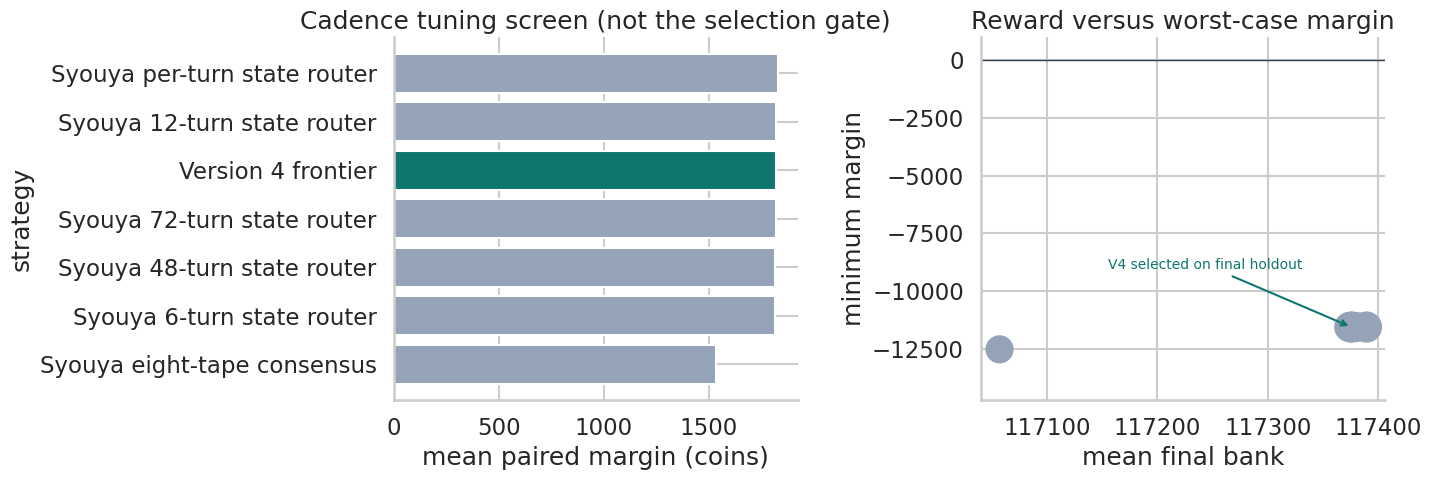

,challenger,games,wins,mean_money,mean_margin,min_margin,label,win_rate,episode
6,syouyastate,72,45,117389.28,1831.76,-11558.0,Syouya per-turn state router,0.62,syouyastate
2,syouyachunk:6,72,44,117375.74,1816.54,-11558.0,Syouya 6-turn state router,0.61,6
0,syouyachunk:12,72,42,117376.39,1820.67,-11558.0,Syouya 12-turn state router,0.58,12
4,syouyaday,72,42,117375.44,1819.11,-11558.0,Version 4 frontier,0.58,syouyaday
3,syouyachunk:72,72,42,117379.28,1819.07,-11558.0,Syouya 72-turn state router,0.58,72
1,syouyachunk:48,72,42,117373.83,1817.60,-11558.0,Syouya 48-turn state router,0.58,48
5,syouyamode,72,34,117057.29,1536.19,-12525.0,Syouya eight-tape consensus,0.47,syouyamode


In [2]:
SCREEN_SUMMARY_ROWS = [{'challenger': 'syouyachunk:12', 'games': 72, 'wins': 42, 'mean_money': 117376.38888888889, 'mean_margin': 1820.6666666666667, 'min_margin': -11558.0, 'label': 'Syouya 12-turn state router'}, {'challenger': 'syouyachunk:48', 'games': 72, 'wins': 42, 'mean_money': 117373.83333333333, 'mean_margin': 1817.5972222222222, 'min_margin': -11558.0, 'label': 'Syouya 48-turn state router'}, {'challenger': 'syouyachunk:6', 'games': 72, 'wins': 44, 'mean_money': 117375.73611111111, 'mean_margin': 1816.5416666666667, 'min_margin': -11558.0, 'label': 'Syouya 6-turn state router'}, {'challenger': 'syouyachunk:72', 'games': 72, 'wins': 42, 'mean_money': 117379.27777777778, 'mean_margin': 1819.0694444444443, 'min_margin': -11558.0, 'label': 'Syouya 72-turn state router'}, {'challenger': 'syouyaday', 'games': 72, 'wins': 42, 'mean_money': 117375.44444444444, 'mean_margin': 1819.111111111111, 'min_margin': -11558.0, 'label': 'Syouya day-locked state router'}, {'challenger': 'syouyamode', 'games': 72, 'wins': 34, 'mean_money': 117057.29166666667, 'mean_margin': 1536.1944444444443, 'min_margin': -12525.0, 'label': 'Syouya eight-tape consensus'}, {'challenger': 'syouyastate', 'games': 72, 'wins': 45, 'mean_money': 117389.27777777778, 'mean_margin': 1831.763888888889, 'min_margin': -11558.0, 'label': 'Syouya per-turn state router'}]
candidate_summary = pd.DataFrame(SCREEN_SUMMARY_ROWS)
candidate_summary["win_rate"] = candidate_summary.wins / candidate_summary.games
candidate_summary["episode"] = candidate_summary.challenger.str.split(":").str[-1]
candidate_summary.loc[candidate_summary.challenger == "radianttrace_router_v13", "label"] = "Version 13 router"
candidate_summary.loc[candidate_summary.challenger == "radianttrace_router_v14", "label"] = "Version 14 router"
candidate_summary.loc[candidate_summary.challenger == "radianttrace_router_v15", "label"] = "Version 15 router"
candidate_summary.loc[candidate_summary.challenger == "radianttrace_router_v16", "label"] = "Version 16 router"
candidate_summary.loc[candidate_summary.challenger == 'syouyaday', "label"] = "Version 4 frontier"
candidate_summary = candidate_summary.sort_values(["wins", "mean_margin"], ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
order = candidate_summary.sort_values("mean_margin")
colors = [COLORS[0] if x == 'syouyaday' else "#94a3b8" for x in order.challenger]
axes[0].barh(order.label, order.mean_margin, color=colors)
axes[0].set(title="Cadence tuning screen (not the selection gate)", xlabel="mean paired margin (coins)", ylabel="strategy")
axes[1].scatter(candidate_summary.mean_money, candidate_summary.min_margin,
                s=80 + 8*candidate_summary.wins, c=[COLORS[0] if x == 'syouyaday' else "#94a3b8" for x in candidate_summary.challenger])
frontier_point = candidate_summary[candidate_summary.challenger == 'syouyaday'].iloc[0]
axes[1].annotate("V4 selected on final holdout", (frontier_point.mean_money, frontier_point.min_margin),
                 xytext=(-175, 42), textcoords="offset points", fontsize=10, color=COLORS[0],
                 arrowprops={"arrowstyle":"->", "color":COLORS[0], "lw":1.5})
axes[1].axhline(0, color="#334155", lw=1)
axes[1].set_ylim(float(candidate_summary.min_margin.min()) - 2200, max(1000, float(candidate_summary.min_margin.max()) + 1200))
axes[1].set(title="Reward versus worst-case margin", xlabel="mean final bank", ylabel="minimum margin")
sns.despine(); plt.tight_layout(pad=1.8); plt.show()
display(candidate_summary.round(2))


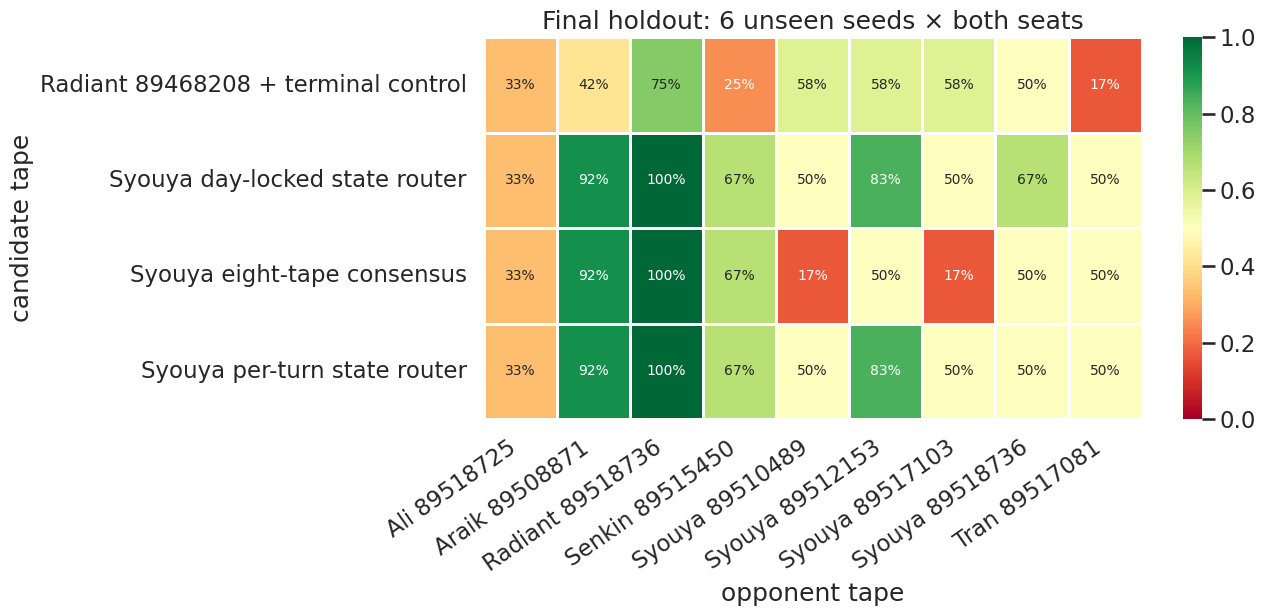

,challenger,opponent,games,wins,win_rate,mean_margin,challenger_label,opponent_label,candidate_episode,opponent_episode
33,topterm:89468208:1:712,newtoptrace:89518725:0,12,4,0.333,-5414.833,Radiant 89468208 + terminal control,Ali 89518725,Radiant 89468208 + terminal control,Ali 89518725
27,topterm:89468208:1:712,newtoptrace:89508871:0,12,5,0.417,1240.833,Radiant 89468208 + terminal control,Araik 89508871,Radiant 89468208 + terminal control,Araik 89508871
34,topterm:89468208:1:712,newtoptrace:89518736:0,12,9,0.750,10144.667,Radiant 89468208 + terminal control,Radiant 89518736,Radiant 89468208 + terminal control,Radiant 89518736
30,topterm:89468208:1:712,newtoptrace:89515450:1,12,3,0.250,-7134.667,Radiant 89468208 + terminal control,Senkin 89515450,Radiant 89468208 + terminal control,Senkin 89515450
28,topterm:89468208:1:712,newtoptrace:89510489:0,12,7,0.583,-2016.917,Radiant 89468208 + terminal control,Syouya 89510489,Radiant 89468208 + terminal control,Syouya 89510489
29,topterm:89468208:1:712,newtoptrace:89512153:1,12,7,0.583,-1775.750,Radiant 89468208 + terminal control,Syouya 89512153,Radiant 89468208 + terminal control,Syouya 89512153
32,topterm:89468208:1:712,newtoptrace:89517103:1,12,7,0.583,-2016.917,Radiant 89468208 + terminal control,Syouya 89517103,Radiant 89468208 + terminal control,Syouya 89517103
35,topterm:89468208:1:712,newtoptrace:89518736:1,12,6,0.500,-2682.167,Radiant 89468208 + terminal control,Syouya 89518736,Radiant 89468208 + terminal control,Syouya 89518736
31,topterm:89468208:1:712,newtoptrace:89517081:0,12,2,0.167,-4941.583,Radiant 89468208 + terminal control,Tran 89517081,Radiant 89468208 + terminal control,Tran 89517081
6,syouyaday,newtoptrace:89518725:0,12,4,0.333,-147.333,Syouya day-locked state router,Ali 89518725,Syouya day-locked state router,Ali 89518725


In [3]:
CROSSPLAY_SUMMARY_ROWS = [{'challenger': 'syouyaday', 'opponent': 'newtoptrace:89508871:0', 'games': 12, 'wins': 11, 'win_rate': 0.9166666666666666, 'mean_margin': 11912.583333333334, 'challenger_label': 'Syouya day-locked state router', 'opponent_label': 'Araik 89508871'}, {'challenger': 'syouyaday', 'opponent': 'newtoptrace:89510489:0', 'games': 12, 'wins': 6, 'win_rate': 0.5, 'mean_margin': 384.5833333333333, 'challenger_label': 'Syouya day-locked state router', 'opponent_label': 'Syouya 89510489'}, {'challenger': 'syouyaday', 'opponent': 'newtoptrace:89512153:1', 'games': 12, 'wins': 10, 'win_rate': 0.8333333333333334, 'mean_margin': 593.5, 'challenger_label': 'Syouya day-locked state router', 'opponent_label': 'Syouya 89512153'}, {'challenger': 'syouyaday', 'opponent': 'newtoptrace:89515450:1', 'games': 12, 'wins': 8, 'win_rate': 0.6666666666666666, 'mean_margin': 6504.75, 'challenger_label': 'Syouya day-locked state router', 'opponent_label': 'Senkin 89515450'}, {'challenger': 'syouyaday', 'opponent': 'newtoptrace:89517081:0', 'games': 12, 'wins': 6, 'win_rate': 0.5, 'mean_margin': 3671.5833333333335, 'challenger_label': 'Syouya day-locked state router', 'opponent_label': 'Tran 89517081'}, {'challenger': 'syouyaday', 'opponent': 'newtoptrace:89517103:1', 'games': 12, 'wins': 6, 'win_rate': 0.5, 'mean_margin': 384.5833333333333, 'challenger_label': 'Syouya day-locked state router', 'opponent_label': 'Syouya 89517103'}, {'challenger': 'syouyaday', 'opponent': 'newtoptrace:89518725:0', 'games': 12, 'wins': 4, 'win_rate': 0.3333333333333333, 'mean_margin': -147.33333333333334, 'challenger_label': 'Syouya day-locked state router', 'opponent_label': 'Ali 89518725'}, {'challenger': 'syouyaday', 'opponent': 'newtoptrace:89518736:0', 'games': 12, 'wins': 12, 'win_rate': 1.0, 'mean_margin': 12692.166666666666, 'challenger_label': 'Syouya day-locked state router', 'opponent_label': 'Radiant 89518736'}, {'challenger': 'syouyaday', 'opponent': 'newtoptrace:89518736:1', 'games': 12, 'wins': 8, 'win_rate': 0.6666666666666666, 'mean_margin': 128.75, 'challenger_label': 'Syouya day-locked state router', 'opponent_label': 'Syouya 89518736'}, {'challenger': 'syouyamode', 'opponent': 'newtoptrace:89508871:0', 'games': 12, 'wins': 11, 'win_rate': 0.9166666666666666, 'mean_margin': 11817.333333333334, 'challenger_label': 'Syouya eight-tape consensus', 'opponent_label': 'Araik 89508871'}, {'challenger': 'syouyamode', 'opponent': 'newtoptrace:89510489:0', 'games': 12, 'wins': 2, 'win_rate': 0.16666666666666666, 'mean_margin': 0.0, 'challenger_label': 'Syouya eight-tape consensus', 'opponent_label': 'Syouya 89510489'}, {'challenger': 'syouyamode', 'opponent': 'newtoptrace:89512153:1', 'games': 12, 'wins': 6, 'win_rate': 0.5, 'mean_margin': 208.66666666666666, 'challenger_label': 'Syouya eight-tape consensus', 'opponent_label': 'Syouya 89512153'}, {'challenger': 'syouyamode', 'opponent': 'newtoptrace:89515450:1', 'games': 12, 'wins': 8, 'win_rate': 0.6666666666666666, 'mean_margin': 6501.333333333333, 'challenger_label': 'Syouya eight-tape consensus', 'opponent_label': 'Senkin 89515450'}, {'challenger': 'syouyamode', 'opponent': 'newtoptrace:89517081:0', 'games': 12, 'wins': 6, 'win_rate': 0.5, 'mean_margin': 3341.25, 'challenger_label': 'Syouya eight-tape consensus', 'opponent_label': 'Tran 89517081'}, {'challenger': 'syouyamode', 'opponent': 'newtoptrace:89517103:1', 'games': 12, 'wins': 2, 'win_rate': 0.16666666666666666, 'mean_margin': 0.0, 'challenger_label': 'Syouya eight-tape consensus', 'opponent_label': 'Syouya 89517103'}, {'challenger': 'syouyamode', 'opponent': 'newtoptrace:89518725:0', 'games': 12, 'wins': 4, 'win_rate': 0.3333333333333333, 'mean_margin': -593.8333333333334, 'challenger_label': 'Syouya eight-tape consensus', 'opponent_label': 'Ali 89518725'}, {'challenger': 'syouyamode', 'opponent': 'newtoptrace:89518736:0', 'games': 12, 'wins': 12, 'win_rate': 1.0, 'mean_margin': 12679.5, 'challenger_label': 'Syouya eight-tape consensus', 'opponent_label': 'Radiant 89518736'}, {'challenger': 'syouyamode', 'opponent': 'newtoptrace:89518736:1', 'games': 12, 'wins': 6, 'win_rate': 0.5, 'mean_margin': -283.8333333333333, 'challenger_label': 'Syouya eight-tape consensus', 'opponent_label': 'Syouya 89518736'}, {'challenger': 'syouyastate', 'opponent': 'newtoptrace:89508871:0', 'games': 12, 'wins': 11, 'win_rate': 0.9166666666666666, 'mean_margin': 12091.25, 'challenger_label': 'Syouya per-turn state router', 'opponent_label': 'Araik 89508871'}, {'challenger': 'syouyastate', 'opponent': 'newtoptrace:89510489:0', 'games': 12, 'wins': 6, 'win_rate': 0.5, 'mean_margin': 278.9166666666667, 'challenger_label': 'Syouya per-turn state router', 'opponent_label': 'Syouya 89510489'}, {'challenger': 'syouyastate', 'opponent': 'newtoptrace:89512153:1', 'games': 12, 'wins': 10, 'win_rate': 0.8333333333333334, 'mean_margin': 488.0, 'challenger_label': 'Syouya per-turn state router', 'opponent_label': 'Syouya 89512153'}, {'challenger': 'syouyastate', 'opponent': 'newtoptrace:89515450:1', 'games': 12, 'wins': 8, 'win_rate': 0.6666666666666666, 'mean_margin': 6712.75, 'challenger_label': 'Syouya per-turn state router', 'opponent_label': 'Senkin 89515450'}, {'challenger': 'syouyastate', 'opponent': 'newtoptrace:89517081:0', 'games': 12, 'wins': 6, 'win_rate': 0.5, 'mean_margin': 3671.5833333333335, 'challenger_label': 'Syouya per-turn state router', 'opponent_label': 'Tran 89517081'}, {'challenger': 'syouyastate', 'opponent': 'newtoptrace:89517103:1', 'games': 12, 'wins': 6, 'win_rate': 0.5, 'mean_margin': 278.9166666666667, 'challenger_label': 'Syouya per-turn state router', 'opponent_label': 'Syouya 89517103'}, {'challenger': 'syouyastate', 'opponent': 'newtoptrace:89518725:0', 'games': 12, 'wins': 4, 'win_rate': 0.3333333333333333, 'mean_margin': -279.5, 'challenger_label': 'Syouya per-turn state router', 'opponent_label': 'Ali 89518725'}, {'challenger': 'syouyastate', 'opponent': 'newtoptrace:89518736:0', 'games': 12, 'wins': 12, 'win_rate': 1.0, 'mean_margin': 12563.166666666666, 'challenger_label': 'Syouya per-turn state router', 'opponent_label': 'Radiant 89518736'}, {'challenger': 'syouyastate', 'opponent': 'newtoptrace:89518736:1', 'games': 12, 'wins': 6, 'win_rate': 0.5, 'mean_margin': 23.083333333333332, 'challenger_label': 'Syouya per-turn state router', 'opponent_label': 'Syouya 89518736'}, {'challenger': 'topterm:89468208:1:712', 'opponent': 'newtoptrace:89508871:0', 'games': 12, 'wins': 5, 'win_rate': 0.4166666666666667, 'mean_margin': 1240.8333333333333, 'challenger_label': 'Radiant 89468208 + terminal control', 'opponent_label': 'Araik 89508871'}, {'challenger': 'topterm:89468208:1:712', 'opponent': 'newtoptrace:89510489:0', 'games': 12, 'wins': 7, 'win_rate': 0.5833333333333334, 'mean_margin': -2016.9166666666667, 'challenger_label': 'Radiant 89468208 + terminal control', 'opponent_label': 'Syouya 89510489'}, {'challenger': 'topterm:89468208:1:712', 'opponent': 'newtoptrace:89512153:1', 'games': 12, 'wins': 7, 'win_rate': 0.5833333333333334, 'mean_margin': -1775.75, 'challenger_label': 'Radiant 89468208 + terminal control', 'opponent_label': 'Syouya 89512153'}, {'challenger': 'topterm:89468208:1:712', 'opponent': 'newtoptrace:89515450:1', 'games': 12, 'wins': 3, 'win_rate': 0.25, 'mean_margin': -7134.666666666667, 'challenger_label': 'Radiant 89468208 + terminal control', 'opponent_label': 'Senkin 89515450'}, {'challenger': 'topterm:89468208:1:712', 'opponent': 'newtoptrace:89517081:0', 'games': 12, 'wins': 2, 'win_rate': 0.16666666666666666, 'mean_margin': -4941.583333333333, 'challenger_label': 'Radiant 89468208 + terminal control', 'opponent_label': 'Tran 89517081'}, {'challenger': 'topterm:89468208:1:712', 'opponent': 'newtoptrace:89517103:1', 'games': 12, 'wins': 7, 'win_rate': 0.5833333333333334, 'mean_margin': -2016.9166666666667, 'challenger_label': 'Radiant 89468208 + terminal control', 'opponent_label': 'Syouya 89517103'}, {'challenger': 'topterm:89468208:1:712', 'opponent': 'newtoptrace:89518725:0', 'games': 12, 'wins': 4, 'win_rate': 0.3333333333333333, 'mean_margin': -5414.833333333333, 'challenger_label': 'Radiant 89468208 + terminal control', 'opponent_label': 'Ali 89518725'}, {'challenger': 'topterm:89468208:1:712', 'opponent': 'newtoptrace:89518736:0', 'games': 12, 'wins': 9, 'win_rate': 0.75, 'mean_margin': 10144.666666666666, 'challenger_label': 'Radiant 89468208 + terminal control', 'opponent_label': 'Radiant 89518736'}, {'challenger': 'topterm:89468208:1:712', 'opponent': 'newtoptrace:89518736:1', 'games': 12, 'wins': 6, 'win_rate': 0.5, 'mean_margin': -2682.1666666666665, 'challenger_label': 'Radiant 89468208 + terminal control', 'opponent_label': 'Syouya 89518736'}]
crossplay = pd.DataFrame(CROSSPLAY_SUMMARY_ROWS)
crossplay["candidate_episode"] = crossplay.challenger_label
crossplay["opponent_episode"] = crossplay.opponent_label
duel = crossplay[crossplay.challenger != crossplay.opponent]
duel_view = duel.copy()
matrix = duel_view.pivot(index="candidate_episode", columns="opponent_episode", values="win_rate")
fig, ax = plt.subplots(figsize=(13.5, 6.5))
sns.heatmap(matrix, annot=True, fmt=".0%", vmin=0, vmax=1, center=.5, cmap="RdYlGn", linewidths=.8, ax=ax,
            annot_kws={"fontsize":10})
ax.set(title="Final holdout: 6 unseen seeds × both seats", xlabel="opponent tape", ylabel="candidate tape")
ax.tick_params(axis="x", labelrotation=35)
for label in ax.get_xticklabels(): label.set_horizontalalignment("right")
plt.tight_layout(); plt.show()
display(duel_view.sort_values(["candidate_episode", "opponent_episode"]).round(3))


## 2. Mathematical control: all melons is an opening, not a strategy

A watered melon tile can produce six premium units, but the sale curve is quadratic in glut. Dumping a whole monoculture into the same market makes each later tile sharply less valuable. The replay uses a small early melon tranche for explosive capital, then rotates into strawberries while livestock adds diversified milk, wool, and fertilizer value.


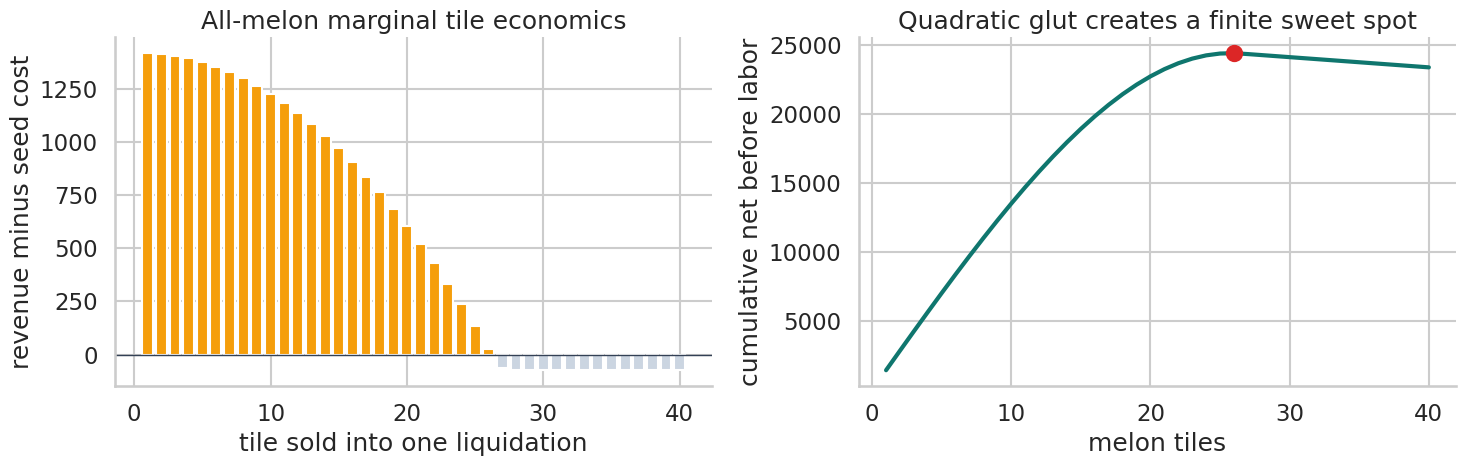

{'best_static_tile_count': 26, 'first_tile_net': 1420.0, 'fortieth_tile_net': -74.0}


In [4]:
def melon_price(glut):
    glut = np.maximum(0, np.asarray(glut))
    return np.maximum(1, np.rint(250 - (3.6 * 250 / 300**2) * glut**2))

tiles = np.arange(1, 41)
tile_net = np.array([melon_price(np.arange((i-1)*6, i*6)).sum() - 80 for i in tiles])
cumulative_net = np.cumsum(tile_net)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].bar(tiles, tile_net, color=[COLORS[1] if x > 0 else "#cbd5e1" for x in tile_net])
axes[0].axhline(0, color="#334155", lw=1)
axes[0].set(title="All-melon marginal tile economics", xlabel="tile sold into one liquidation", ylabel="revenue minus seed cost")
axes[1].plot(tiles, cumulative_net, lw=3, color=COLORS[0])
axes[1].scatter([tiles[np.argmax(cumulative_net)]], [cumulative_net.max()], s=120, color=COLORS[4], zorder=3)
axes[1].set(title="Quadratic glut creates a finite sweet spot", xlabel="melon tiles", ylabel="cumulative net before labor")
sns.despine(); plt.tight_layout(); plt.show()
print({"best_static_tile_count": int(tiles[np.argmax(cumulative_net)]), "first_tile_net": float(tile_net[0]), "fortieth_tile_net": float(tile_net[-1])})


## 3. Teardown of public episode 89513803

These plots are descriptive measurements of the public replay—not evidence about hidden implementation. Across the eight current-leader replays, the opening is stable through turn 243; stochastic state then changes which daily continuation is most appropriate. The farms converge near eight cows, six sheep, six to seven strawberry plots, and three unlocked quadrants, while still making market orders in the final eight turns.


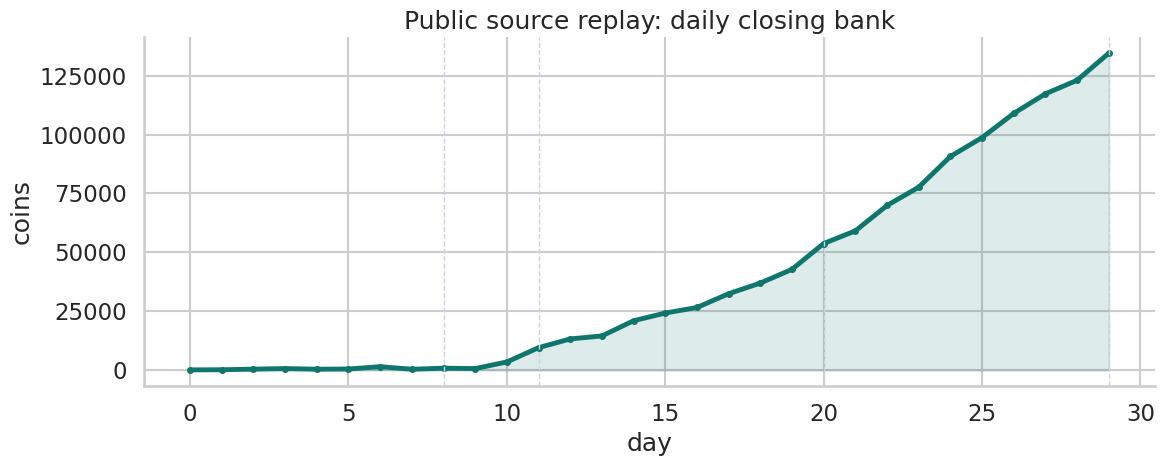

{'episode': 89513803, 'public_reward': 134526.0, 'public_opponent_reward': 118448.0}


In [5]:
DAILY_ROWS = [{'day': 0, 'money': 153.0, 'hands': 4, 'unlocked_quadrants': 1, 'crop_melon': 7, 'crop_wheat': 10, 'animal_sheep': 1, 'animal_buildings': 4, 'animal_cow': 3}, {'day': 1, 'money': 205.0, 'hands': 6, 'unlocked_quadrants': 1, 'crop_melon': 7, 'crop_wheat': 11, 'animal_sheep': 1, 'animal_buildings': 4, 'animal_cow': 3}, {'day': 2, 'money': 468.0, 'hands': 6, 'unlocked_quadrants': 1, 'crop_melon': 8, 'crop_wheat': 11, 'animal_sheep': 1, 'animal_buildings': 4, 'animal_cow': 3}, {'day': 3, 'money': 702.0, 'hands': 6, 'unlocked_quadrants': 1, 'crop_melon': 8, 'crop_wheat': 11, 'animal_sheep': 1, 'animal_buildings': 4, 'animal_cow': 3}, {'day': 4, 'money': 434.0, 'hands': 6, 'unlocked_quadrants': 1, 'crop_melon': 10, 'crop_wheat': 7, 'crop_strawberry': 2, 'animal_sheep': 1, 'animal_buildings': 4, 'animal_cow': 3}, {'day': 5, 'money': 521.0, 'hands': 7, 'unlocked_quadrants': 1, 'crop_melon': 10, 'crop_wheat': 6, 'crop_strawberry': 2, 'animal_sheep': 2, 'animal_buildings': 6, 'animal_cow': 4}, {'day': 6, 'money': 1498.0, 'hands': 6, 'unlocked_quadrants': 1, 'crop_melon': 10, 'crop_wheat': 6, 'crop_strawberry': 2, 'animal_buildings': 7, 'animal_sheep': 2, 'animal_cow': 4}, {'day': 7, 'money': 420.0, 'hands': 8, 'unlocked_quadrants': 2, 'crop_melon': 11, 'crop_strawberry': 6, 'crop_wheat': 10, 'animal_cow': 5, 'animal_buildings': 7, 'animal_sheep': 2}, {'day': 8, 'money': 863.0, 'hands': 10, 'unlocked_quadrants': 2, 'crop_melon': 11, 'crop_strawberry': 12, 'crop_wheat': 7, 'animal_cow': 5, 'animal_buildings': 11, 'animal_sheep': 6}, {'day': 9, 'money': 696.0, 'hands': 11, 'unlocked_quadrants': 2, 'crop_melon': 11, 'crop_strawberry': 17, 'crop_wheat': 7, 'animal_cow': 5, 'animal_buildings': 12, 'animal_sheep': 6}, {'day': 10, 'money': 3522.0, 'hands': 12, 'unlocked_quadrants': 3, 'crop_strawberry': 21, 'crop_wheat': 8, 'crop_melon': 4, 'animal_cow': 6, 'animal_buildings': 14, 'animal_sheep': 6}, {'day': 11, 'money': 9578.0, 'hands': 12, 'unlocked_quadrants': 3, 'crop_strawberry': 27, 'crop_wheat': 6, 'crop_melon': 6, 'animal_cow': 8, 'animal_buildings': 14, 'animal_sheep': 6}, {'day': 12, 'money': 13281.0, 'hands': 12, 'unlocked_quadrants': 3, 'crop_strawberry': 33, 'crop_wheat': 4, 'crop_melon': 6, 'animal_cow': 8, 'animal_buildings': 14, 'animal_sheep': 6}, {'day': 13, 'money': 14554.0, 'hands': 12, 'unlocked_quadrants': 3, 'crop_strawberry': 37, 'crop_wheat': 4, 'crop_melon': 9, 'animal_cow': 8, 'animal_buildings': 14, 'animal_sheep': 6, 'weed': 2}, {'day': 14, 'money': 21006.0, 'hands': 12, 'unlocked_quadrants': 3, 'crop_strawberry': 39, 'crop_wheat': 4, 'crop_melon': 8, 'animal_cow': 8, 'animal_buildings': 14, 'animal_sheep': 6, 'weed': 1}, {'day': 15, 'money': 24267.0, 'hands': 12, 'unlocked_quadrants': 3, 'crop_strawberry': 39, 'crop_melon': 10, 'crop_wheat': 3, 'animal_cow': 8, 'animal_buildings': 14, 'animal_sheep': 6, 'weed': 1}, {'day': 16, 'money': 26624.0, 'hands': 12, 'unlocked_quadrants': 3, 'crop_strawberry': 39, 'crop_melon': 10, 'crop_wheat': 4, 'animal_cow': 8, 'animal_buildings': 14, 'animal_sheep': 6, 'weed': 2}, {'day': 17, 'money': 32467.0, 'hands': 12, 'unlocked_quadrants': 3, 'crop_strawberry': 39, 'crop_melon': 9, 'crop_wheat': 5, 'animal_cow': 8, 'animal_buildings': 14, 'animal_sheep': 6, 'weed': 2}, {'day': 18, 'money': 36981.0, 'hands': 12, 'unlocked_quadrants': 3, 'crop_strawberry': 39, 'crop_melon': 9, 'crop_wheat': 4, 'animal_cow': 8, 'animal_buildings': 14, 'animal_sheep': 6, 'weed': 2}, {'day': 19, 'money': 42815.0, 'hands': 12, 'unlocked_quadrants': 3, 'crop_strawberry': 39, 'crop_melon': 9, 'animal_cow': 8, 'animal_buildings': 14, 'animal_sheep': 6, 'crop_wheat': 3, 'weed': 2}, {'day': 20, 'money': 53773.0, 'hands': 12, 'unlocked_quadrants': 3, 'crop_strawberry': 39, 'crop_melon': 9, 'animal_cow': 8, 'animal_buildings': 14, 'animal_sheep': 6, 'crop_wheat': 1, 'weed': 2}, {'day': 21, 'money': 59131.0, 'hands': 12, 'unlocked_quadrants': 3, 'crop_strawberry': 37, 'crop_melon': 8, 'animal_cow': 8, 'animal_buildings': 14, 'animal_sheep': 6, 'weed': 2}, {'day': 22, 'money': 69915.0, 'hands': 12, 'unlocked_quadrants': 3, 'crop_strawberry': 37, 'crop_melon': 7, 'animal_cow': 8, 'animal_buildings': 14, 'animal_sheep': 6, 'weed': 2}, {'day': 23, 'money': 77671.0, 'hands': 12, 'unlocked_quadrants': 3, 'crop_strawberry': 37, 'crop_melon': 6, 'animal_cow': 8, 'animal_buildings': 14, 'animal_sheep': 6, 'weed': 2}, {'day': 24, 'money': 90713.0, 'hands': 12, 'unlocked_quadrants': 3, 'crop_strawberry': 33, 'crop_melon': 5, 'weed': 3, 'animal_cow': 8, 'animal_buildings': 14, 'animal_sheep': 6}, {'day': 25, 'money': 98727.0, 'hands': 12, 'unlocked_quadrants': 3, 'crop_strawberry': 27, 'crop_melon': 3, 'weed': 4, 'animal_cow': 8, 'animal_buildings': 14, 'animal_sheep': 6}, {'day': 26, 'money': 108983.0, 'hands': 12, 'unlocked_quadrants': 3, 'crop_strawberry': 22, 'crop_melon': 1, 'weed': 3, 'animal_cow': 8, 'animal_buildings': 14, 'animal_sheep': 6}, {'day': 27, 'money': 117300.0, 'hands': 11, 'unlocked_quadrants': 3, 'crop_strawberry': 18, 'weed': 3, 'animal_cow': 8, 'animal_buildings': 14, 'animal_sheep': 6}, {'day': 28, 'money': 123045.0, 'hands': 10, 'unlocked_quadrants': 3, 'weed': 3, 'animal_cow': 8, 'animal_buildings': 14, 'animal_sheep': 6, 'crop_strawberry': 12}, {'day': 29, 'money': 134526.0, 'hands': 9, 'unlocked_quadrants': 3, 'weed': 11, 'animal_cow': 8, 'animal_buildings': 14, 'animal_sheep': 6, 'crop_strawberry': 6}]
daily = pd.DataFrame(DAILY_ROWS).fillna(0)
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(daily.day, daily.money, lw=3.5, color=COLORS[0], marker="o", ms=4)
ax.fill_between(daily.day, daily.money, alpha=.14, color=COLORS[0])
for day in (8, 11, 20, 29): ax.axvline(day, color="#cbd5e1", ls="--", lw=1)
ax.set(title="Public source replay: daily closing bank", xlabel="day", ylabel="coins")
sns.despine(); plt.tight_layout(); plt.show()
print({"episode": 89513803, "public_reward": 134526.0, "public_opponent_reward": 118448.0})


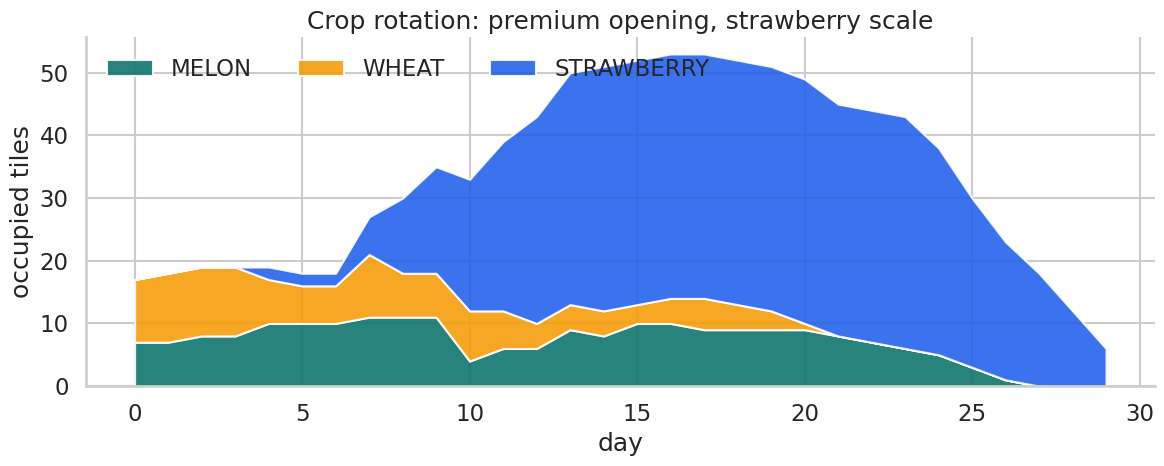

In [6]:
crop_cols = [c for c in daily if c.startswith("crop_")]
crop_labels = [c.replace("crop_", "").upper() for c in crop_cols]
fig, ax = plt.subplots(figsize=(12, 5))
ax.stackplot(daily.day, *[daily[c] for c in crop_cols], labels=crop_labels,
             colors=COLORS[:len(crop_cols)], alpha=.9)
ax.set(title="Crop rotation: premium opening, strawberry scale", xlabel="day", ylabel="occupied tiles")
ax.legend(frameon=False, ncol=4, loc="upper left")
sns.despine(); plt.tight_layout(); plt.show()


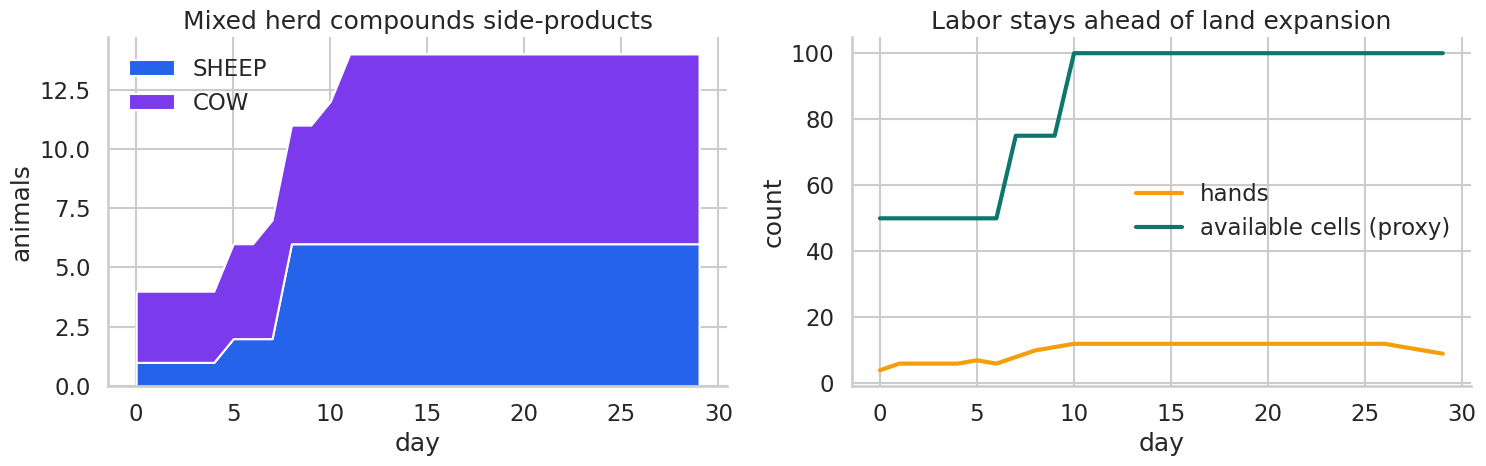

In [7]:
animal_cols = [c for c in daily if c.startswith("animal_") and c != "animal_buildings"]
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].stackplot(daily.day, *[daily[c] for c in animal_cols],
                  labels=[c.replace("animal_", "").upper() for c in animal_cols], colors=COLORS[2:2+len(animal_cols)])
axes[0].set(title="Mixed herd compounds side-products", xlabel="day", ylabel="animals")
axes[0].legend(frameon=False)
axes[1].plot(daily.day, daily.hands, lw=3, color=COLORS[1], label="hands")
axes[1].plot(daily.day, 25 * (1 + daily.unlocked_quadrants), lw=3, color=COLORS[0], label="available cells (proxy)")
axes[1].set(title="Labor stays ahead of land expansion", xlabel="day", ylabel="count")
axes[1].legend(frameon=False)
sns.despine(); plt.tight_layout(); plt.show()


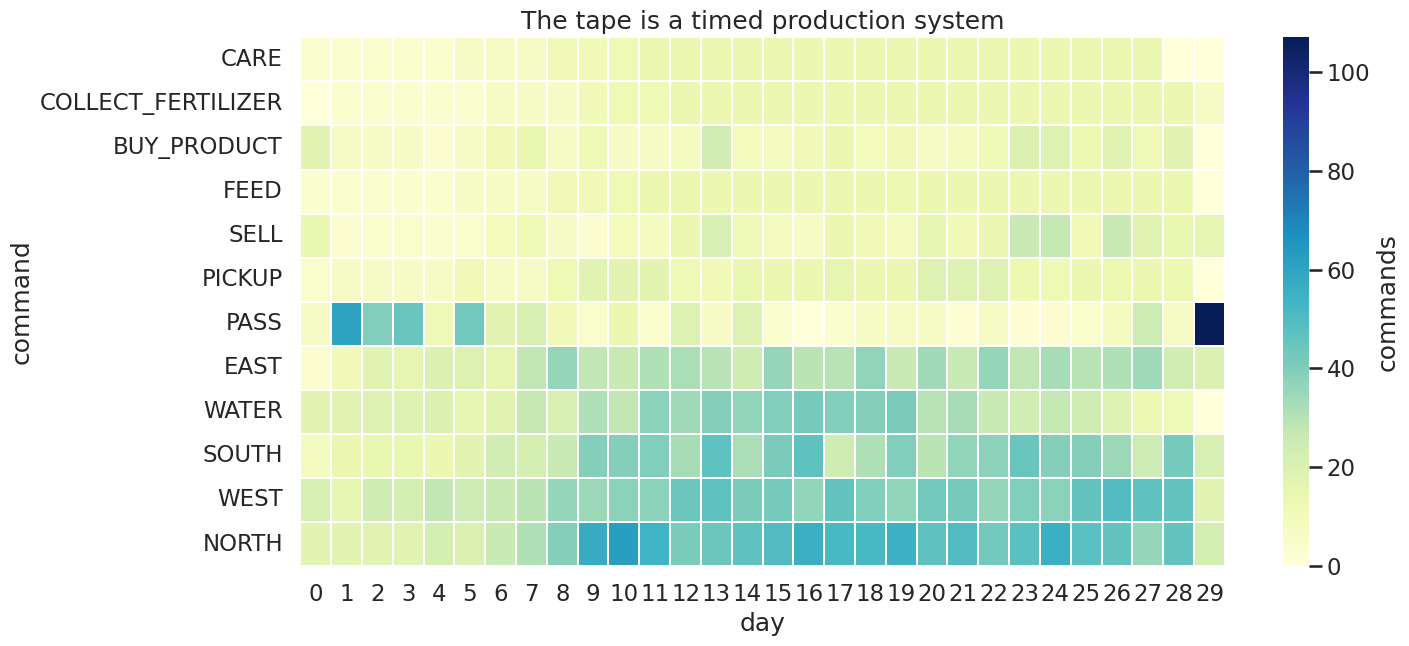

In [8]:
ACTION_SUMMARY_ROWS = [{'day': 0, 'verb': 'PASS', 'commands': 7}, {'day': 0, 'verb': 'HIRE', 'commands': 4}, {'day': 0, 'verb': 'BUY_ANIMAL', 'commands': 4}, {'day': 0, 'verb': 'BUY_SEED', 'commands': 4}, {'day': 0, 'verb': 'BUILD_PASTURE', 'commands': 4}, {'day': 0, 'verb': 'WEST', 'commands': 21}, {'day': 0, 'verb': 'NORTH', 'commands': 17}, {'day': 0, 'verb': 'BUY_PRODUCT', 'commands': 17}, {'day': 0, 'verb': 'PICKUP', 'commands': 5}, {'day': 0, 'verb': 'PLACE', 'commands': 4}, {'day': 0, 'verb': 'SELL', 'commands': 15}, {'day': 0, 'verb': 'SOUTH', 'commands': 8}, {'day': 0, 'verb': 'FEED', 'commands': 4}, {'day': 0, 'verb': 'EAST', 'commands': 3}, {'day': 0, 'verb': 'CARE', 'commands': 4}, {'day': 0, 'verb': 'PLANT', 'commands': 17}, {'day': 0, 'verb': 'WATER', 'commands': 17}, {'day': 1, 'verb': 'PICKUP', 'commands': 6}, {'day': 1, 'verb': 'BUY_PRODUCT', 'commands': 6}, {'day': 1, 'verb': 'HIRE', 'commands': 6}, {'day': 1, 'verb': 'FEED', 'commands': 4}, {'day': 1, 'verb': 'WEST', 'commands': 16}, {'day': 1, 'verb': 'NORTH', 'commands': 17}, {'day': 1, 'verb': 'SELL', 'commands': 3}, {'day': 1, 'verb': 'CARE', 'commands': 4}, {'day': 1, 'verb': 'COLLECT_FERTILIZER', 'commands': 4}, {'day': 1, 'verb': 'EAST', 'commands': 11}, {'day': 1, 'verb': 'SOUTH', 'commands': 14}, {'day': 1, 'verb': 'PASS', 'commands': 60}, {'day': 1, 'verb': 'DROP', 'commands': 1}, {'day': 1, 'verb': 'WATER', 'commands': 18}, {'day': 1, 'verb': 'PLANT', 'commands': 1}, {'day': 2, 'verb': 'PICKUP', 'commands': 7}, {'day': 2, 'verb': 'SELL', 'commands': 5}, {'day': 2, 'verb': 'HIRE', 'commands': 6}, {'day': 2, 'verb': 'FEED', 'commands': 4}, {'day': 2, 'verb': 'WEST', 'commands': 24}, {'day': 2, 'verb': 'NORTH', 'commands': 18}, {'day': 2, 'verb': 'BUY_PRODUCT', 'commands': 6}, {'day': 2, 'verb': 'BUY_SEED', 'commands': 1}, {'day': 2, 'verb': 'CARE', 'commands': 4}, {'day': 2, 'verb': 'COLLECT_FERTILIZER', 'commands': 4}, {'day': 2, 'verb': 'SOUTH', 'commands': 15}, {'day': 2, 'verb': 'PASS', 'commands': 40}, {'day': 2, 'verb': 'WATER', 'commands': 19}, {'day': 2, 'verb': 'PLANT', 'commands': 1}, {'day': 2, 'verb': 'EAST', 'commands': 18}, {'day': 2, 'verb': 'DROP', 'commands': 2}, {'day': 3, 'verb': 'PICKUP', 'commands': 7}, {'day': 3, 'verb': 'SELL', 'commands': 5}, {'day': 3, 'verb': 'HIRE', 'commands': 6}, {'day': 3, 'verb': 'FEED', 'commands': 4}, {'day': 3, 'verb': 'WEST', 'commands': 22}, {'day': 3, 'verb': 'NORTH', 'commands': 18}, {'day': 3, 'verb': 'BUY_PRODUCT', 'commands': 6}, {'day': 3, 'verb': 'CARE', 'commands': 4}, {'day': 3, 'verb': 'COLLECT_FERTILIZER', 'commands': 4}, {'day': 3, 'verb': 'EAST', 'commands': 16}, {'day': 3, 'verb': 'SOUTH', 'commands': 15}, {'day': 3, 'verb': 'DROP', 'commands': 2}, {'day': 3, 'verb': 'WATER', 'commands': 19}, {'day': 3, 'verb': 'PASS', 'commands': 45}, {'day': 4, 'verb': 'PICKUP', 'commands': 7}, {'day': 4, 'verb': 'SELL', 'commands': 4}, {'day': 4, 'verb': 'HIRE', 'commands': 6}, {'day': 4, 'verb': 'FEED', 'commands': 4}, {'day': 4, 'verb': 'WEST', 'commands': 28}, {'day': 4, 'verb': 'NORTH', 'commands': 22}, {'day': 4, 'verb': 'BUY_PRODUCT', 'commands': 3}, {'day': 4, 'verb': 'CARE', 'commands': 4}, {'day': 4, 'verb': 'COLLECT_FERTILIZER', 'commands': 4}, {'day': 4, 'verb': 'HARVEST', 'commands': 10}, {'day': 4, 'verb': 'WATER', 'commands': 20}, {'day': 4, 'verb': 'SOUTH', 'commands': 14}, {'day': 4, 'verb': 'BUY_SEED', 'commands': 5}, {'day': 4, 'verb': 'PLANT', 'commands': 10}, {'day': 4, 'verb': 'EAST', 'commands': 20}, {'day': 4, 'verb': 'PASS', 'commands': 12}, {'day': 4, 'verb': 'DROP', 'commands': 1}, {'day': 5, 'verb': 'PICKUP', 'commands': 11}, {'day': 5, 'verb': 'SELL', 'commands': 5}, {'day': 5, 'verb': 'HIRE', 'commands': 7}, {'day': 5, 'verb': 'FEED', 'commands': 6}, {'day': 5, 'verb': 'WEST', 'commands': 25}, {'day': 5, 'verb': 'NORTH', 'commands': 20}, {'day': 5, 'verb': 'BUY_PRODUCT', 'commands': 6}, {'day': 5, 'verb': 'BUY_ANIMAL', 'commands': 2}, {'day': 5, 'verb': 'CARE', 'commands': 6}, {'day': 5, 'verb': 'COLLECT_FERTILIZER', 'commands': 4}, {'day': 5, 'verb': 'BUILD_PASTURE', 'commands': 2}, {'day': 5, 'verb': 'EAST', 'commands': 19}, {'day': 5, 'verb': 'SOUTH', 'commands': 17}, {'day': 5, 'verb': 'PASS', 'commands': 43}, {'day': 5, 'verb': 'WATER', 'commands': 16}, {'day': 5, 'verb': 'HARVEST', 'commands': 1}, {'day': 5, 'verb': 'PLACE', 'commands': 2}, {'day': 5, 'verb': 'DROP', 'commands': 1}, {'day': 6, 'verb': 'PICKUP', 'commands': 7}, {'day': 6, 'verb': 'SELL', 'commands': 10}, {'day': 6, 'verb': 'HIRE', 'commands': 6}, {'day': 6, 'verb': 'FEED', 'commands': 6}, {'day': 6, 'verb': 'WEST', 'commands': 26}, {'day': 6, 'verb': 'NORTH', 'commands': 26}, {'day': 6, 'verb': 'BUY_PRODUCT', 'commands': 11}, {'day': 6, 'verb': 'CARE', 'commands': 6}, {'day': 6, 'verb': 'COLLECT_FERTILIZER', 'commands': 6}, {'day': 6, 'verb': 'HARVEST', 'commands': 1}, {'day': 6, 'verb': 'SOUTH', 'commands': 23}, {'day': 6, 'verb': 'WATER', 'commands': 18}, {'day': 6, 'verb': 'EAST', 'commands': 16}, {'day': 6, 'verb': 'DROP', 'commands': 3}, {'day': 6, 'verb': 'PASS', 'commands': 17}, {'day': 6, 'verb': 'BUY_ANIMAL', 'commands': 1}, {'day': 6, 'verb': 'BUILD_PASTURE', 'commands': 1}, {'day': 7, 'verb': 'PICKUP', 'commands': 7}, {'day': 7, 'verb': 'SELL', 'commands': 12}, {'day': 7, 'verb': 'BUY_PRODUCT', 'commands': 15}, {'day': 7, 'verb': 'HIRE', 'commands': 8}, {'day': 7, 'verb': 'FEED', 'commands': 7}, {'day': 7, 'verb': 'WEST', 'commands': 29}, {'day': 7, 'verb': 'NORTH', 'commands': 31}, {'day': 7, 'verb': 'BUY_LAND', 'commands': 1}, {'day': 7, 'verb': 'BUY_SEED', 'commands': 2}, {'day': 7, 'verb': 'CARE', 'commands': 7}, {'day': 7, 'verb': 'COLLECT_FERTILIZER', 'commands': 6}, {'day': 7, 'verb': 'PLANT', 'commands': 9}, {'day': 7, 'verb': 'WATER', 'commands': 27}, {'day': 7, 'verb': 'SOUTH', 'commands': 22}, {'day': 7, 'verb': 'EAST', 'commands': 28}, {'day': 7, 'verb': 'DROP', 'commands': 2}, {'day': 7, 'verb': 'PLACE', 'commands': 1}, {'day': 7, 'verb': 'PASS', 'commands': 21}, {'day': 8, 'verb': 'PICKUP', 'commands': 12}, {'day': 8, 'verb': 'SELL', 'commands': 6}, {'day': 8, 'verb': 'BUY_PRODUCT', 'commands': 7}, {'day': 8, 'verb': 'HIRE', 'commands': 10}, {'day': 8, 'verb': 'FEED', 'commands': 11}, {'day': 8, 'verb': 'WEST', 'commands': 36}, {'day': 8, 'verb': 'NORTH', 'commands': 39}, {'day': 8, 'verb': 'BUY_SEED', 'commands': 13}, {'day': 8, 'verb': 'HARVEST', 'commands': 9}, {'day': 8, 'verb': 'CARE', 'commands': 11}, {'day': 8, 'verb': 'DROP', 'commands': 4}, {'day': 8, 'verb': 'COLLECT_FERTILIZER', 'commands': 7}, {'day': 8, 'verb': 'BUY_ANIMAL', 'commands': 4}, {'day': 8, 'verb': 'SOUTH', 'commands': 26}, {'day': 8, 'verb': 'PLANT', 'commands': 11}, {'day': 8, 'verb': 'EAST', 'commands': 36}, {'day': 8, 'verb': 'WATER', 'commands': 21}, {'day': 8, 'verb': 'BUILD_PASTURE', 'commands': 4}, {'day': 8, 'verb': 'PLACE', 'commands': 4}, {'day': 8, 'verb': 'PASS', 'commands': 11}, {'day': 9, 'verb': 'PICKUP', 'commands': 18}, {'day': 9, 'verb': 'SELL', 'commands': 3}, {'day': 9, 'verb': 'HIRE', 'commands': 11}, {'day': 9, 'verb': 'BUY_SEED', 'commands': 2}, {'day': 9, 'verb': 'FEED', 'commands': 11}, {'day': 9, 'verb': 'CARE', 'commands': 11}, {'day': 9, 'verb': 'NORTH', 'commands': 57}, {'day': 9, 'verb': 'BUY_PRODUCT', 'commands': 12}, {'day': 9, 'verb': 'COLLECT_FERTILIZER', 'commands': 11}, {'day': 9, 'verb': 'WEST', 'commands': 35}, {'day': 9, 'verb': 'EAST', 'commands': 28}, {'day': 9, 'verb': 'WATER', 'commands': 31}, {'day': 9, 'verb': 'HARVEST', 'commands': 1}, {'day': 9, 'verb': 'DIG', 'commands': 2}, {'day': 9, 'verb': 'PLANT', 'commands': 5}, {'day': 9, 'verb': 'FERTILIZE', 'commands': 4}, {'day': 9, 'verb': 'SOUTH', 'commands': 39}, {'day': 9, 'verb': 'DROP', 'commands': 2}, {'day': 9, 'verb': 'BUY_ANIMAL', 'commands': 1}, {'day': 9, 'verb': 'BUILD_PASTURE', 'commands': 1}, {'day': 9, 'verb': 'PASS', 'commands': 5}, {'day': 9, 'verb': 'PLACE', 'commands': 1}, {'day': 10, 'verb': 'PICKUP', 'commands': 17}, {'day': 10, 'verb': 'SELL', 'commands': 10}, {'day': 10, 'verb': 'HIRE', 'commands': 12}, {'day': 10, 'verb': 'FEED', 'commands': 12}, {'day': 10, 'verb': 'CARE', 'commands': 12}, {'day': 10, 'verb': 'NORTH', 'commands': 62}, {'day': 10, 'verb': 'BUY_PRODUCT', 'commands': 6}, {'day': 10, 'verb': 'COLLECT_FERTILIZER', 'commands': 12}, {'day': 10, 'verb': 'WEST', 'commands': 38}, {'day': 10, 'verb': 'EAST', 'commands': 26}, {'day': 10, 'verb': 'HARVEST', 'commands': 10}, {'day': 10, 'verb': 'SOUTH', 'commands': 39}, {'day': 10, 'verb': 'WATER', 'commands': 28}, {'day': 10, 'verb': 'PLANT', 'commands': 5}, {'day': 10, 'verb': 'FERTILIZE', 'commands': 1}, {'day': 10, 'verb': 'DROP', 'commands': 4}, {'day': 10, 'verb': 'PASS', 'commands': 14}, {'day': 10, 'verb': 'BUY_ANIMAL', 'commands': 2}, {'day': 10, 'verb': 'BUY_SEED', 'commands': 3}, {'day': 10, 'verb': 'BUILD_PASTURE', 'commands': 2}, {'day': 10, 'verb': 'BUY_LAND', 'commands': 1}, {'day': 11, 'verb': 'PICKUP', 'commands': 17}, {'day': 11, 'verb': 'SELL', 'commands': 8}, {'day': 11, 'verb': 'BUY_PRODUCT', 'commands': 7}, {'day': 11, 'verb': 'HIRE', 'commands': 12}, {'day': 11, 'verb': 'FEED', 'commands': 14}, {'day': 11, 'verb': 'CARE', 'commands': 14}, {'day': 11, 'verb': 'NORTH', 'commands': 54}, {'day': 11, 'verb': 'COLLECT_FERTILIZER', 'commands': 12}, {'day': 11, 'verb': 'WEST', 'commands': 38}, {'day': 11, 'verb': 'SOUTH', 'commands': 40}, {'day': 11, 'verb': 'PLACE', 'commands': 2}, {'day': 11, 'verb': 'EAST', 'commands': 31}, {'day': 11, 'verb': 'WATER', 'commands': 38}, {'day': 11, 'verb': 'HARVEST', 'commands': 5}, {'day': 11, 'verb': 'PLANT', 'commands': 10}, {'day': 11, 'verb': 'BUY_SEED', 'commands': 6}, {'day': 11, 'verb': 'FERTILIZE', 'commands': 1}, {'day': 11, 'verb': 'DROP', 'commands': 2}, {'day': 11, 'verb': 'PASS', 'commands': 4}, {'day': 12, 'verb': 'PICKUP', 'commands': 12}, {'day': 12, 'verb': 'SELL', 'commands': 14}, {'day': 12, 'verb': 'HIRE', 'commands': 12}, {'day': 12, 'verb': 'FEED', 'commands': 14}, {'day': 12, 'verb': 'CARE', 'commands': 14}, {'day': 12, 'verb': 'NORTH', 'commands': 41}, {'day': 12, 'verb': 'BUY_PRODUCT', 'commands': 8}, {'day': 12, 'verb': 'COLLECT_FERTILIZER', 'commands': 14}, {'day': 12, 'verb': 'WEST', 'commands': 44}, {'day': 12, 'verb': 'HARVEST', 'commands': 8}, {'day': 12, 'verb': 'EAST', 'commands': 32}, {'day': 12, 'verb': 'SOUTH', 'commands': 33}, {'day': 12, 'verb': 'WATER', 'commands': 34}, {'day': 12, 'verb': 'FERTILIZE', 'commands': 3}, {'day': 12, 'verb': 'DROP', 'commands': 4}, {'day': 12, 'verb': 'PLANT', 'commands': 10}, {'day': 12, 'verb': 'PASS', 'commands': 19}, {'day': 12, 'verb': 'BUY_SEED', 'commands': 4}, {'day': 13, 'verb': 'PICKUP', 'commands': 11}, {'day': 13, 'verb': 'SELL', 'commands': 21}, {'day': 13, 'verb': 'BUY_PRODUCT', 'commands': 23}, {'day': 13, 'verb': 'HIRE', 'commands': 12}, {'day': 13, 'verb': 'BUY_SEED', 'commands': 5}, {'day': 13, 'verb': 'FEED', 'commands': 14}, {'day': 13, 'verb': 'CARE', 'commands': 14}, {'day': 13, 'verb': 'NORTH', 'commands': 44}, {'day': 13, 'verb': 'COLLECT_FERTILIZER', 'commands': 14}, {'day': 13, 'verb': 'WEST', 'commands': 47}, {'day': 13, 'verb': 'EAST', 'commands': 30}, {'day': 13, 'verb': 'SOUTH', 'commands': 47}, {'day': 13, 'verb': 'WATER', 'commands': 39}, {'day': 13, 'verb': 'HARVEST', 'commands': 1}, {'day': 13, 'verb': 'FERTILIZE', 'commands': 2}, {'day': 13, 'verb': 'DROP', 'commands': 3}, {'day': 13, 'verb': 'PLANT', 'commands': 8}, {'day': 13, 'verb': 'DIG', 'commands': 2}, {'day': 13, 'verb': 'PASS', 'commands': 6}, {'day': 14, 'verb': 'PICKUP', 'commands': 15}, {'day': 14, 'verb': 'SELL', 'commands': 12}, {'day': 14, 'verb': 'BUY_PRODUCT', 'commands': 10}, {'day': 14, 'verb': 'HIRE', 'commands': 12}, {'day': 14, 'verb': 'FEED', 'commands': 14}, {'day': 14, 'verb': 'HARVEST', 'commands': 13}, {'day': 14, 'verb': 'CARE', 'commands': 14}, {'day': 14, 'verb': 'NORTH', 'commands': 47}, {'day': 14, 'verb': 'WEST', 'commands': 41}, {'day': 14, 'verb': 'COLLECT_FERTILIZER', 'commands': 14}, {'day': 14, 'verb': 'SOUTH', 'commands': 32}, {'day': 14, 'verb': 'EAST', 'commands': 24}, {'day': 14, 'verb': 'WATER', 'commands': 37}, {'day': 14, 'verb': 'DROP', 'commands': 6}, {'day': 14, 'verb': 'PLANT', 'commands': 5}, {'day': 14, 'verb': 'BUY_SEED', 'commands': 2}, {'day': 14, 'verb': 'DIG', 'commands': 1}, {'day': 14, 'verb': 'PASS', 'commands': 19}, {'day': 15, 'verb': 'PICKUP', 'commands': 14}, {'day': 15, 'verb': 'SELL', 'commands': 9}, {'day': 15, 'verb': 'HIRE', 'commands': 12}, {'day': 15, 'verb': 'FEED', 'commands': 14}, {'day': 15, 'verb': 'CARE', 'commands': 14}, {'day': 15, 'verb': 'NORTH', 'commands': 50}, {'day': 15, 'verb': 'BUY_PRODUCT', 'commands': 9}, {'day': 15, 'verb': 'COLLECT_FERTILIZER', 'commands': 14}, {'day': 15, 'verb': 'WEST', 'commands': 42}, {'day': 15, 'verb': 'SOUTH', 'commands': 41}, {'day': 15, 'verb': 'EAST', 'commands': 36}, {'day': 15, 'verb': 'WATER', 'commands': 40}, {'day': 15, 'verb': 'HARVEST', 'commands': 5}, {'day': 15, 'verb': 'PLANT', 'commands': 4}, {'day': 15, 'verb': 'DIG', 'commands': 1}, {'day': 15, 'verb': 'BUY_SEED', 'commands': 2}, {'day': 15, 'verb': 'DROP', 'commands': 1}, {'day': 15, 'verb': 'FERTILIZE', 'commands': 2}, {'day': 15, 'verb': 'PASS', 'commands': 4}, {'day': 16, 'verb': 'PICKUP', 'commands': 14}, {'day': 16, 'verb': 'SELL', 'commands': 6}, {'day': 16, 'verb': 'HIRE', 'commands': 12}, {'day': 16, 'verb': 'FEED', 'commands': 14}, {'day': 16, 'verb': 'CARE', 'commands': 14}, {'day': 16, 'verb': 'NORTH', 'commands': 56}, {'day': 16, 'verb': 'BUY_PRODUCT', 'commands': 11}, {'day': 16, 'verb': 'COLLECT_FERTILIZER', 'commands': 14}, {'day': 16, 'verb': 'WEST', 'commands': 37}, {'day': 16, 'verb': 'HARVEST', 'commands': 6}, {'day': 16, 'verb': 'EAST', 'commands': 29}, {'day': 16, 'verb': 'WATER', 'commands': 42}, {'day': 16, 'verb': 'SOUTH', 'commands': 47}, {'day': 16, 'verb': 'FERTILIZE', 'commands': 6}, {'day': 16, 'verb': 'PLANT', 'commands': 2}, {'day': 16, 'verb': 'BUY_SEED', 'commands': 2}, {'day': 16, 'verb': 'DIG', 'commands': 1}, {'day': 17, 'verb': 'PICKUP', 'commands': 16}, {'day': 17, 'verb': 'SELL', 'commands': 14}, {'day': 17, 'verb': 'HIRE', 'commands': 12}, {'day': 17, 'verb': 'FEED', 'commands': 14}, {'day': 17, 'verb': 'HARVEST', 'commands': 13}, {'day': 17, 'verb': 'CARE', 'commands': 14}, {'day': 17, 'verb': 'NORTH', 'commands': 52}, {'day': 17, 'verb': 'BUY_PRODUCT', 'commands': 14}, {'day': 17, 'verb': 'COLLECT_FERTILIZER', 'commands': 14}, {'day': 17, 'verb': 'WEST', 'commands': 46}, {'day': 17, 'verb': 'EAST', 'commands': 30}, {'day': 17, 'verb': 'SOUTH', 'commands': 24}, {'day': 17, 'verb': 'WATER', 'commands': 40}, {'day': 17, 'verb': 'FERTILIZE', 'commands': 9}, {'day': 17, 'verb': 'DROP', 'commands': 5}, {'day': 17, 'verb': 'PLANT', 'commands': 1}, {'day': 17, 'verb': 'PASS', 'commands': 4}, {'day': 18, 'verb': 'PICKUP', 'commands': 14}, {'day': 18, 'verb': 'SELL', 'commands': 11}, {'day': 18, 'verb': 'HIRE', 'commands': 12}, {'day': 18, 'verb': 'FEED', 'commands': 14}, {'day': 18, 'verb': 'CARE', 'commands': 14}, {'day': 18, 'verb': 'NORTH', 'commands': 52}, {'day': 18, 'verb': 'BUY_PRODUCT', 'commands': 10}, {'day': 18, 'verb': 'COLLECT_FERTILIZER', 'commands': 14}, {'day': 18, 'verb': 'WEST', 'commands': 40}, {'day': 18, 'verb': 'HARVEST', 'commands': 13}, {'day': 18, 'verb': 'EAST', 'commands': 37}, {'day': 18, 'verb': 'SOUTH', 'commands': 31}, {'day': 18, 'verb': 'WATER', 'commands': 39}, {'day': 18, 'verb': 'FERTILIZE', 'commands': 6}, {'day': 18, 'verb': 'DROP', 'commands': 2}, {'day': 18, 'verb': 'PASS', 'commands': 6}, {'day': 19, 'verb': 'PICKUP', 'commands': 14}, {'day': 19, 'verb': 'SELL', 'commands': 9}, {'day': 19, 'verb': 'HIRE', 'commands': 12}, {'day': 19, 'verb': 'FEED', 'commands': 13}, {'day': 19, 'verb': 'CARE', 'commands': 14}, {'day': 19, 'verb': 'HARVEST', 'commands': 15}, {'day': 19, 'verb': 'NORTH', 'commands': 55}, {'day': 19, 'verb': 'BUY_PRODUCT', 'commands': 11}, {'day': 19, 'verb': 'COLLECT_FERTILIZER', 'commands': 14}, {'day': 19, 'verb': 'WEST', 'commands': 37}, {'day': 19, 'verb': 'SOUTH', 'commands': 40}, {'day': 19, 'verb': 'EAST', 'commands': 26}, {'day': 19, 'verb': 'WATER', 'commands': 41}, {'day': 19, 'verb': 'FERTILIZE', 'commands': 4}, {'day': 19, 'verb': 'DROP', 'commands': 2}, {'day': 19, 'verb': 'PASS', 'commands': 7}, {'day': 20, 'verb': 'PICKUP', 'commands': 19}, {'day': 20, 'verb': 'SELL', 'commands': 16}, {'day': 20, 'verb': 'HIRE', 'commands': 12}, {'day': 20, 'verb': 'FEED', 'commands': 14}, {'day': 20, 'verb': 'HARVEST', 'commands': 22}, {'day': 20, 'verb': 'CARE', 'commands': 14}, {'day': 20, 'verb': 'NORTH', 'commands': 47}, {'day': 20, 'verb': 'BUY_PRODUCT', 'commands': 7}, {'day': 20, 'verb': 'COLLECT_FERTILIZER', 'commands': 14}, {'day': 20, 'verb': 'WEST', 'commands': 43}, {'day': 20, 'verb': 'EAST', 'commands': 34}, {'day': 20, 'verb': 'SOUTH', 'commands': 29}, {'day': 20, 'verb': 'WATER', 'commands': 30}, {'day': 20, 'verb': 'DROP', 'commands': 5}, {'day': 20, 'verb': 'FERTILIZE', 'commands': 5}, {'day': 20, 'verb': 'PASS', 'commands': 6}, {'day': 21, 'verb': 'PICKUP', 'commands': 19}, {'day': 21, 'verb': 'SELL', 'commands': 11}, {'day': 21, 'verb': 'HIRE', 'commands': 12}, {'day': 21, 'verb': 'FEED', 'commands': 14}, {'day': 21, 'verb': 'CARE', 'commands': 14}, {'day': 21, 'verb': 'NORTH', 'commands': 50}, {'day': 21, 'verb': 'BUY_PRODUCT', 'commands': 8}, {'day': 21, 'verb': 'COLLECT_FERTILIZER', 'commands': 14}, {'day': 21, 'verb': 'HARVEST', 'commands': 16}, {'day': 21, 'verb': 'WEST', 'commands': 42}, {'day': 21, 'verb': 'SOUTH', 'commands': 37}, {'day': 21, 'verb': 'EAST', 'commands': 26}, {'day': 21, 'verb': 'WATER', 'commands': 33}, {'day': 21, 'verb': 'FERTILIZE', 'commands': 11}, {'day': 21, 'verb': 'DIG', 'commands': 2}, {'day': 21, 'verb': 'DROP', 'commands': 2}, {'day': 21, 'verb': 'PASS', 'commands': 2}, {'day': 22, 'verb': 'PICKUP', 'commands': 19}, {'day': 22, 'verb': 'SELL', 'commands': 14}, {'day': 22, 'verb': 'HIRE', 'commands': 12}, {'day': 22, 'verb': 'FEED', 'commands': 14}, {'day': 22, 'verb': 'CARE', 'commands': 14}, {'day': 22, 'verb': 'NORTH', 'commands': 43}, {'day': 22, 'verb': 'BUY_PRODUCT', 'commands': 12}, {'day': 22, 'verb': 'COLLECT_FERTILIZER', 'commands': 14}, {'day': 22, 'verb': 'WEST', 'commands': 36}, {'day': 22, 'verb': 'SOUTH', 'commands': 38}, {'day': 22, 'verb': 'EAST', 'commands': 36}, {'day': 22, 'verb': 'HARVEST', 'commands': 18}, {'day': 22, 'verb': 'WATER', 'commands': 26}, {'day': 22, 'verb': 'FERTILIZE', 'commands': 12}, {'day': 22, 'verb': 'DROP', 'commands': 5}, {'day': 22, 'verb': 'PASS', 'commands': 7}, {'day': 23, 'verb': 'PICKUP', 'commands': 13}, {'day': 23, 'verb': 'SELL', 'commands': 26}, {'day': 23, 'verb': 'HIRE', 'commands': 12}, {'day': 23, 'verb': 'FEED', 'commands': 14}, {'day': 23, 'verb': 'HARVEST', 'commands': 30}, {'day': 23, 'verb': 'CARE', 'commands': 14}, {'day': 23, 'verb': 'NORTH', 'commands': 48}, {'day': 23, 'verb': 'BUY_PRODUCT', 'commands': 20}, {'day': 23, 'verb': 'COLLECT_FERTILIZER', 'commands': 14}, {'day': 23, 'verb': 'WEST', 'commands': 40}, {'day': 23, 'verb': 'EAST', 'commands': 28}, {'day': 23, 'verb': 'SOUTH', 'commands': 45}, {'day': 23, 'verb': 'WATER', 'commands': 23}, {'day': 23, 'verb': 'FERTILIZE', 'commands': 6}, {'day': 23, 'verb': 'DROP', 'commands': 5}, {'day': 23, 'verb': 'PASS', 'commands': 2}, {'day': 24, 'verb': 'PICKUP', 'commands': 12}, {'day': 24, 'verb': 'SELL', 'commands': 27}, {'day': 24, 'verb': 'BUY_PRODUCT', 'commands': 19}, {'day': 24, 'verb': 'HIRE', 'commands': 12}, {'day': 24, 'verb': 'FEED', 'commands': 14}, {'day': 24, 'verb': 'CARE', 'commands': 14}, {'day': 24, 'verb': 'NORTH', 'commands': 56}, {'day': 24, 'verb': 'COLLECT_FERTILIZER', 'commands': 14}, {'day': 24, 'verb': 'WEST', 'commands': 38}, {'day': 24, 'verb': 'SOUTH', 'commands': 39}, {'day': 24, 'verb': 'HARVEST', 'commands': 22}, {'day': 24, 'verb': 'EAST', 'commands': 33}, {'day': 24, 'verb': 'WATER', 'commands': 27}, {'day': 24, 'verb': 'DROP', 'commands': 4}, {'day': 24, 'verb': 'FERTILIZE', 'commands': 2}, {'day': 24, 'verb': 'DIG', 'commands': 4}, {'day': 24, 'verb': 'PASS', 'commands': 3}, {'day': 25, 'verb': 'PICKUP', 'commands': 14}, {'day': 25, 'verb': 'SELL', 'commands': 11}, {'day': 25, 'verb': 'BUY_PRODUCT', 'commands': 13}, {'day': 25, 'verb': 'HIRE', 'commands': 12}, {'day': 25, 'verb': 'FEED', 'commands': 14}, {'day': 25, 'verb': 'CARE', 'commands': 14}, {'day': 25, 'verb': 'NORTH', 'commands': 48}, {'day': 25, 'verb': 'COLLECT_FERTILIZER', 'commands': 14}, {'day': 25, 'verb': 'HARVEST', 'commands': 21}, {'day': 25, 'verb': 'WEST', 'commands': 46}, {'day': 25, 'verb': 'SOUTH', 'commands': 39}, {'day': 25, 'verb': 'EAST', 'commands': 30}, {'day': 25, 'verb': 'DIG', 'commands': 5}, {'day': 25, 'verb': 'WATER', 'commands': 24}, {'day': 25, 'verb': 'FERTILIZE', 'commands': 5}, {'day': 25, 'verb': 'DROP', 'commands': 3}, {'day': 25, 'verb': 'PASS', 'commands': 5}, {'day': 26, 'verb': 'PICKUP', 'commands': 13}, {'day': 26, 'verb': 'SELL', 'commands': 26}, {'day': 26, 'verb': 'HIRE', 'commands': 12}, {'day': 26, 'verb': 'FEED', 'commands': 14}, {'day': 26, 'verb': 'HARVEST', 'commands': 24}, {'day': 26, 'verb': 'CARE', 'commands': 14}, {'day': 26, 'verb': 'NORTH', 'commands': 46}, {'day': 26, 'verb': 'BUY_PRODUCT', 'commands': 18}, {'day': 26, 'verb': 'COLLECT_FERTILIZER', 'commands': 14}, {'day': 26, 'verb': 'WEST', 'commands': 50}, {'day': 26, 'verb': 'SOUTH', 'commands': 35}, {'day': 26, 'verb': 'EAST', 'commands': 31}, {'day': 26, 'verb': 'WATER', 'commands': 19}, {'day': 26, 'verb': 'DIG', 'commands': 6}, {'day': 26, 'verb': 'DROP', 'commands': 5}, {'day': 26, 'verb': 'FERTILIZE', 'commands': 3}, {'day': 26, 'verb': 'PASS', 'commands': 8}, {'day': 27, 'verb': 'PICKUP', 'commands': 14}, {'day': 27, 'verb': 'SELL', 'commands': 18}, {'day': 27, 'verb': 'BUY_PRODUCT', 'commands': 12}, {'day': 27, 'verb': 'HIRE', 'commands': 11}, {'day': 27, 'verb': 'FEED', 'commands': 14}, {'day': 27, 'verb': 'CARE', 'commands': 14}, {'day': 27, 'verb': 'NORTH', 'commands': 36}, {'day': 27, 'verb': 'COLLECT_FERTILIZER', 'commands': 14}, {'day': 27, 'verb': 'HARVEST', 'commands': 12}, {'day': 27, 'verb': 'WEST', 'commands': 47}, {'day': 27, 'verb': 'SOUTH', 'commands': 25}, {'day': 27, 'verb': 'EAST', 'commands': 34}, {'day': 27, 'verb': 'WATER', 'commands': 13}, {'day': 27, 'verb': 'FERTILIZE', 'commands': 3}, {'day': 27, 'verb': 'DIG', 'commands': 4}, {'day': 27, 'verb': 'DROP', 'commands': 7}, {'day': 27, 'verb': 'PASS', 'commands': 25}, {'day': 28, 'verb': 'PICKUP', 'commands': 13}, {'day': 28, 'verb': 'SELL', 'commands': 15}, {'day': 28, 'verb': 'BUY_PRODUCT', 'commands': 17}, {'day': 28, 'verb': 'HIRE', 'commands': 10}, {'day': 28, 'verb': 'FEED', 'commands': 14}, {'day': 28, 'verb': 'COLLECT_FERTILIZER', 'commands': 14}, {'day': 28, 'verb': 'NORTH', 'commands': 46}, {'day': 28, 'verb': 'WEST', 'commands': 46}, {'day': 28, 'verb': 'SOUTH', 'commands': 42}, {'day': 28, 'verb': 'HARVEST', 'commands': 11}, {'day': 28, 'verb': 'EAST', 'commands': 23}, {'day': 28, 'verb': 'WATER', 'commands': 12}, {'day': 28, 'verb': 'DROP', 'commands': 3}, {'day': 28, 'verb': 'FERTILIZE', 'commands': 5}, {'day': 28, 'verb': 'DIG', 'commands': 6}, {'day': 28, 'verb': 'PASS', 'commands': 7}, {'day': 29, 'verb': 'EAST', 'commands': 20}, {'day': 29, 'verb': 'SELL', 'commands': 16}, {'day': 29, 'verb': 'HIRE', 'commands': 9}, {'day': 29, 'verb': 'HARVEST', 'commands': 15}, {'day': 29, 'verb': 'NORTH', 'commands': 22}, {'day': 29, 'verb': 'WEST', 'commands': 18}, {'day': 29, 'verb': 'SOUTH', 'commands': 21}, {'day': 29, 'verb': 'PASS', 'commands': 107}, {'day': 29, 'verb': 'DROP', 'commands': 6}, {'day': 29, 'verb': 'COLLECT_FERTILIZER', 'commands': 7}, {'day': 29, 'verb': 'PLACE', 'commands': 9}]
actions = pd.DataFrame(ACTION_SUMMARY_ROWS)
common = actions.groupby("verb").commands.sum().nlargest(12).index
action_heat = actions[actions.verb.isin(common)].pivot_table(index="verb", columns="day", values="commands", aggfunc="sum", fill_value=0)
action_heat = action_heat.loc[action_heat.sum(axis=1).sort_values().index]
fig, ax = plt.subplots(figsize=(15, 6.8))
sns.heatmap(action_heat, cmap="YlGnBu", linewidths=.15, cbar_kws={"label":"commands"}, ax=ax)
ax.set(title="The tape is a timed production system", xlabel="day", ylabel="command")
plt.tight_layout(); plt.show()


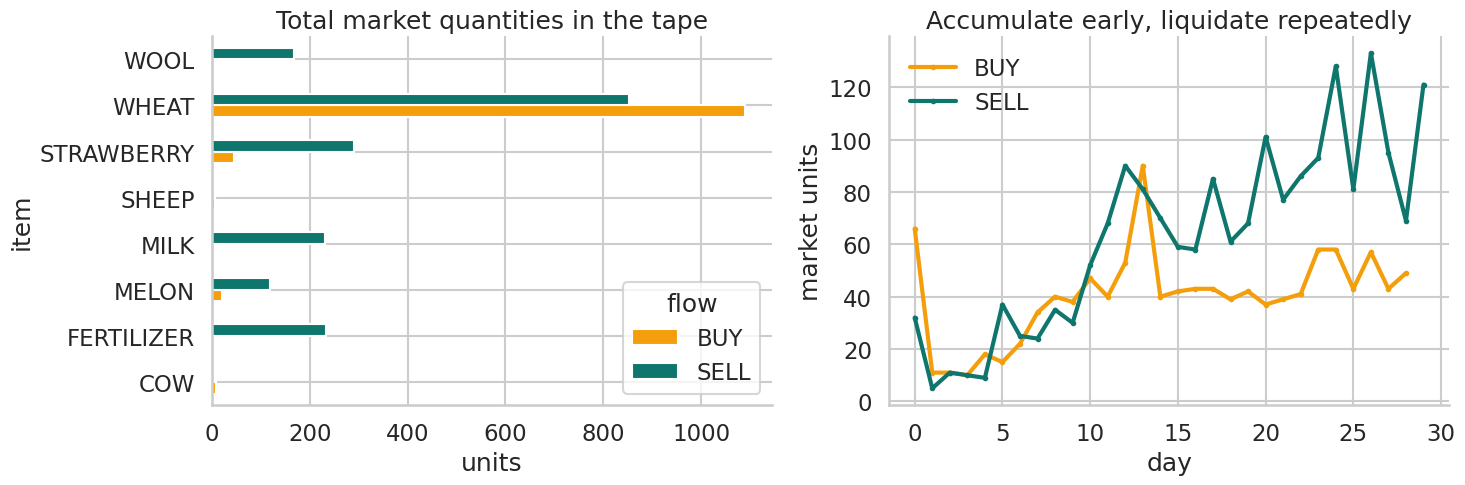

flow,BUY,SELL
item,,
COW,8.0,0.0
FERTILIZER,0.0,233.0
MELON,21.0,119.0
MILK,0.0,230.0
SHEEP,6.0,0.0
STRAWBERRY,44.0,291.0
WHEAT,1090.0,853.0
WOOL,0.0,168.0


In [9]:
MARKET_SUMMARY_ROWS = [{'day': 0, 'flow': 'BUY', 'item': 'COW', 'quantity': 3.0}, {'day': 0, 'flow': 'BUY', 'item': 'MELON', 'quantity': 7.0}, {'day': 0, 'flow': 'BUY', 'item': 'WHEAT', 'quantity': 11.0}, {'day': 0, 'flow': 'BUY', 'item': 'WHEAT', 'quantity': 44.0}, {'day': 0, 'flow': 'SELL', 'item': 'WHEAT', 'quantity': 32.0}, {'day': 0, 'flow': 'BUY', 'item': 'SHEEP', 'quantity': 1.0}, {'day': 1, 'flow': 'BUY', 'item': 'WHEAT', 'quantity': 11.0}, {'day': 1, 'flow': 'SELL', 'item': 'WHEAT', 'quantity': 3.0}, {'day': 1, 'flow': 'SELL', 'item': 'FERTILIZER', 'quantity': 2.0}, {'day': 2, 'flow': 'SELL', 'item': 'WHEAT', 'quantity': 6.0}, {'day': 2, 'flow': 'SELL', 'item': 'FERTILIZER', 'quantity': 5.0}, {'day': 2, 'flow': 'BUY', 'item': 'WHEAT', 'quantity': 10.0}, {'day': 2, 'flow': 'BUY', 'item': 'MELON', 'quantity': 1.0}, {'day': 3, 'flow': 'SELL', 'item': 'WHEAT', 'quantity': 6.0}, {'day': 3, 'flow': 'SELL', 'item': 'FERTILIZER', 'quantity': 4.0}, {'day': 3, 'flow': 'BUY', 'item': 'WHEAT', 'quantity': 10.0}, {'day': 4, 'flow': 'SELL', 'item': 'FERTILIZER', 'quantity': 3.0}, {'day': 4, 'flow': 'SELL', 'item': 'WHEAT', 'quantity': 6.0}, {'day': 4, 'flow': 'BUY', 'item': 'WHEAT', 'quantity': 7.0}, {'day': 4, 'flow': 'BUY', 'item': 'MELON', 'quantity': 3.0}, {'day': 4, 'flow': 'BUY', 'item': 'WHEAT', 'quantity': 6.0}, {'day': 4, 'flow': 'BUY', 'item': 'STRAWBERRY', 'quantity': 2.0}, {'day': 5, 'flow': 'SELL', 'item': 'WHEAT', 'quantity': 33.0}, {'day': 5, 'flow': 'SELL', 'item': 'FERTILIZER', 'quantity': 4.0}, {'day': 5, 'flow': 'BUY', 'item': 'WHEAT', 'quantity': 13.0}, {'day': 5, 'flow': 'BUY', 'item': 'COW', 'quantity': 1.0}, {'day': 5, 'flow': 'BUY', 'item': 'SHEEP', 'quantity': 1.0}, {'day': 6, 'flow': 'SELL', 'item': 'WHEAT', 'quantity': 14.0}, {'day': 6, 'flow': 'SELL', 'item': 'FERTILIZER', 'quantity': 5.0}, {'day': 6, 'flow': 'BUY', 'item': 'WHEAT', 'quantity': 21.0}, {'day': 6, 'flow': 'SELL', 'item': 'WOOL', 'quantity': 6.0}, {'day': 6, 'flow': 'BUY', 'item': 'COW', 'quantity': 1.0}, {'day': 7, 'flow': 'SELL', 'item': 'FERTILIZER', 'quantity': 6.0}, {'day': 7, 'flow': 'SELL', 'item': 'WHEAT', 'quantity': 18.0}, {'day': 7, 'flow': 'BUY', 'item': 'WHEAT', 'quantity': 25.0}, {'day': 7, 'flow': 'BUY', 'item': 'STRAWBERRY', 'quantity': 4.0}, {'day': 7, 'flow': 'BUY', 'item': 'WHEAT', 'quantity': 5.0}, {'day': 8, 'flow': 'SELL', 'item': 'WHEAT', 'quantity': 11.0}, {'day': 8, 'flow': 'SELL', 'item': 'FERTILIZER', 'quantity': 6.0}, {'day': 8, 'flow': 'BUY', 'item': 'WHEAT', 'quantity': 19.0}, {'day': 8, 'flow': 'BUY', 'item': 'STRAWBERRY', 'quantity': 11.0}, {'day': 8, 'flow': 'SELL', 'item': 'MILK', 'quantity': 18.0}, {'day': 8, 'flow': 'BUY', 'item': 'SHEEP', 'quantity': 4.0}, {'day': 8, 'flow': 'BUY', 'item': 'WHEAT', 'quantity': 6.0}, {'day': 9, 'flow': 'SELL', 'item': 'WHEAT', 'quantity': 26.0}, {'day': 9, 'flow': 'BUY', 'item': 'STRAWBERRY', 'quantity': 4.0}, {'day': 9, 'flow': 'BUY', 'item': 'WHEAT', 'quantity': 33.0}, {'day': 9, 'flow': 'SELL', 'item': 'WOOL', 'quantity': 4.0}, {'day': 9, 'flow': 'BUY', 'item': 'COW', 'quantity': 1.0}, {'day': 10, 'flow': 'SELL', 'item': 'WHEAT', 'quantity': 22.0}, {'day': 10, 'flow': 'SELL', 'item': 'FERTILIZER', 'quantity': 3.0}, {'day': 10, 'flow': 'BUY', 'item': 'WHEAT', 'quantity': 37.0}, {'day': 10, 'flow': 'SELL', 'item': 'MELON', 'quantity': 24.0}, {'day': 10, 'flow': 'BUY', 'item': 'COW', 'quantity': 2.0}, {'day': 10, 'flow': 'BUY', 'item': 'MELON', 'quantity': 5.0}, {'day': 10, 'flow': 'SELL', 'item': 'MILK', 'quantity': 3.0}, {'day': 10, 'flow': 'BUY', 'item': 'STRAWBERRY', 'quantity': 3.0}, {'day': 11, 'flow': 'SELL', 'item': 'MELON', 'quantity': 18.0}, {'day': 11, 'flow': 'SELL', 'item': 'MILK', 'quantity': 6.0}, {'day': 11, 'flow': 'SELL', 'item': 'FERTILIZER', 'quantity': 12.0}, {'day': 11, 'flow': 'SELL', 'item': 'WHEAT', 'quantity': 26.0}, {'day': 11, 'flow': 'BUY', 'item': 'WHEAT', 'quantity': 32.0}, {'day': 11, 'flow': 'BUY', 'item': 'STRAWBERRY', 'quantity': 8.0}, {'day': 11, 'flow': 'SELL', 'item': 'WOOL', 'quantity': 6.0}, {'day': 12, 'flow': 'SELL', 'item': 'FERTILIZER', 'quantity': 12.0}, {'day': 12, 'flow': 'SELL', 'item': 'WHEAT', 'quantity': 62.0}, {'day': 12, 'flow': 'BUY', 'item': 'WHEAT', 'quantity': 46.0}, {'day': 12, 'flow': 'SELL', 'item': 'MILK', 'quantity': 6.0}, {'day': 12, 'flow': 'BUY', 'item': 'STRAWBERRY', 'quantity': 7.0}, {'day': 12, 'flow': 'SELL', 'item': 'MELON', 'quantity': 6.0}, {'day': 12, 'flow': 'SELL', 'item': 'WOOL', 'quantity': 4.0}, {'day': 13, 'flow': 'SELL', 'item': 'MILK', 'quantity': 9.0}, {'day': 13, 'flow': 'SELL', 'item': 'FERTILIZER', 'quantity': 9.0}, {'day': 13, 'flow': 'SELL', 'item': 'WHEAT', 'quantity': 63.0}, {'day': 13, 'flow': 'BUY', 'item': 'WHEAT', 'quantity': 83.0}, {'day': 13, 'flow': 'BUY', 'item': 'STRAWBERRY', 'quantity': 5.0}, {'day': 13, 'flow': 'BUY', 'item': 'MELON', 'quantity': 2.0}, {'day': 14, 'flow': 'SELL', 'item': 'FERTILIZER', 'quantity': 11.0}, {'day': 14, 'flow': 'SELL', 'item': 'WHEAT', 'quantity': 23.0}, {'day': 14, 'flow': 'BUY', 'item': 'WHEAT', 'quantity': 36.0}, {'day': 14, 'flow': 'SELL', 'item': 'WOOL', 'quantity': 24.0}, {'day': 14, 'flow': 'BUY', 'item': 'WHEAT', 'quantity': 1.0}, {'day': 14, 'flow': 'SELL', 'item': 'MILK', 'quantity': 6.0}, {'day': 14, 'flow': 'BUY', 'item': 'MELON', 'quantity': 3.0}, {'day': 14, 'flow': 'SELL', 'item': 'MELON', 'quantity': 6.0}, {'day': 15, 'flow': 'SELL', 'item': 'MELON', 'quantity': 6.0}, {'day': 15, 'flow': 'SELL', 'item': 'FERTILIZER', 'quantity': 15.0}, {'day': 15, 'flow': 'SELL', 'item': 'WOOL', 'quantity': 4.0}, {'day': 15, 'flow': 'SELL', 'item': 'WHEAT', 'quantity': 27.0}, {'day': 15, 'flow': 'SELL', 'item': 'STRAWBERRY', 'quantity': 4.0}, {'day': 15, 'flow': 'SELL', 'item': 'MILK', 'quantity': 3.0}, {'day': 15, 'flow': 'BUY', 'item': 'WHEAT', 'quantity': 39.0}, {'day': 15, 'flow': 'BUY', 'item': 'WHEAT', 'quantity': 3.0}, {'day': 16, 'flow': 'SELL', 'item': 'MILK', 'quantity': 9.0}, {'day': 16, 'flow': 'SELL', 'item': 'FERTILIZER', 'quantity': 10.0}, {'day': 16, 'flow': 'SELL', 'item': 'WOOL', 'quantity': 4.0}, {'day': 16, 'flow': 'SELL', 'item': 'WHEAT', 'quantity': 35.0}, {'day': 16, 'flow': 'BUY', 'item': 'WHEAT', 'quantity': 41.0}, {'day': 16, 'flow': 'BUY', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 17, 'flow': 'SELL', 'item': 'MILK', 'quantity': 15.0}, {'day': 17, 'flow': 'SELL', 'item': 'FERTILIZER', 'quantity': 11.0}, {'day': 17, 'flow': 'SELL', 'item': 'STRAWBERRY', 'quantity': 4.0}, {'day': 17, 'flow': 'SELL', 'item': 'WHEAT', 'quantity': 33.0}, {'day': 17, 'flow': 'BUY', 'item': 'WHEAT', 'quantity': 43.0}, {'day': 17, 'flow': 'SELL', 'item': 'MELON', 'quantity': 6.0}, {'day': 17, 'flow': 'SELL', 'item': 'WOOL', 'quantity': 16.0}, {'day': 18, 'flow': 'SELL', 'item': 'MILK', 'quantity': 6.0}, {'day': 18, 'flow': 'SELL', 'item': 'WOOL', 'quantity': 8.0}, {'day': 18, 'flow': 'SELL', 'item': 'STRAWBERRY', 'quantity': 16.0}, {'day': 18, 'flow': 'SELL', 'item': 'WHEAT', 'quantity': 27.0}, {'day': 18, 'flow': 'SELL', 'item': 'FERTILIZER', 'quantity': 4.0}, {'day': 18, 'flow': 'BUY', 'item': 'WHEAT', 'quantity': 39.0}, {'day': 19, 'flow': 'SELL', 'item': 'MILK', 'quantity': 15.0}, {'day': 19, 'flow': 'SELL', 'item': 'STRAWBERRY', 'quantity': 14.0}, {'day': 19, 'flow': 'SELL', 'item': 'FERTILIZER', 'quantity': 7.0}, {'day': 19, 'flow': 'SELL', 'item': 'WHEAT', 'quantity': 32.0}, {'day': 19, 'flow': 'BUY', 'item': 'WHEAT', 'quantity': 42.0}, {'day': 20, 'flow': 'SELL', 'item': 'MILK', 'quantity': 21.0}, {'day': 20, 'flow': 'SELL', 'item': 'STRAWBERRY', 'quantity': 22.0}, {'day': 20, 'flow': 'SELL', 'item': 'FERTILIZER', 'quantity': 12.0}, {'day': 20, 'flow': 'SELL', 'item': 'WHEAT', 'quantity': 34.0}, {'day': 20, 'flow': 'BUY', 'item': 'WHEAT', 'quantity': 37.0}, {'day': 20, 'flow': 'SELL', 'item': 'WOOL', 'quantity': 12.0}, {'day': 21, 'flow': 'SELL', 'item': 'STRAWBERRY', 'quantity': 16.0}, {'day': 21, 'flow': 'SELL', 'item': 'WOOL', 'quantity': 12.0}, {'day': 21, 'flow': 'SELL', 'item': 'MILK', 'quantity': 6.0}, {'day': 21, 'flow': 'SELL', 'item': 'FERTILIZER', 'quantity': 6.0}, {'day': 21, 'flow': 'SELL', 'item': 'WHEAT', 'quantity': 31.0}, {'day': 21, 'flow': 'BUY', 'item': 'WHEAT', 'quantity': 39.0}, {'day': 21, 'flow': 'SELL', 'item': 'MELON', 'quantity': 6.0}, {'day': 22, 'flow': 'SELL', 'item': 'MILK', 'quantity': 20.0}, {'day': 22, 'flow': 'SELL', 'item': 'STRAWBERRY', 'quantity': 30.0}, {'day': 22, 'flow': 'SELL', 'item': 'FERTILIZER', 'quantity': 3.0}, {'day': 22, 'flow': 'SELL', 'item': 'WHEAT', 'quantity': 27.0}, {'day': 22, 'flow': 'BUY', 'item': 'WHEAT', 'quantity': 41.0}, {'day': 22, 'flow': 'SELL', 'item': 'MELON', 'quantity': 6.0}, {'day': 23, 'flow': 'SELL', 'item': 'STRAWBERRY', 'quantity': 24.0}, {'day': 23, 'flow': 'SELL', 'item': 'FERTILIZER', 'quantity': 3.0}, {'day': 23, 'flow': 'SELL', 'item': 'WHEAT', 'quantity': 47.0}, {'day': 23, 'flow': 'BUY', 'item': 'WHEAT', 'quantity': 58.0}, {'day': 23, 'flow': 'SELL', 'item': 'WOOL', 'quantity': 16.0}, {'day': 23, 'flow': 'SELL', 'item': 'MILK', 'quantity': 3.0}, {'day': 24, 'flow': 'SELL', 'item': 'STRAWBERRY', 'quantity': 38.0}, {'day': 24, 'flow': 'SELL', 'item': 'MILK', 'quantity': 18.0}, {'day': 24, 'flow': 'SELL', 'item': 'MELON', 'quantity': 12.0}, {'day': 24, 'flow': 'SELL', 'item': 'WOOL', 'quantity': 8.0}, {'day': 24, 'flow': 'SELL', 'item': 'WHEAT', 'quantity': 43.0}, {'day': 24, 'flow': 'BUY', 'item': 'WHEAT', 'quantity': 58.0}, {'day': 24, 'flow': 'SELL', 'item': 'FERTILIZER', 'quantity': 9.0}, {'day': 25, 'flow': 'SELL', 'item': 'STRAWBERRY', 'quantity': 33.0}, {'day': 25, 'flow': 'SELL', 'item': 'MILK', 'quantity': 3.0}, {'day': 25, 'flow': 'SELL', 'item': 'FERTILIZER', 'quantity': 12.0}, {'day': 25, 'flow': 'SELL', 'item': 'WHEAT', 'quantity': 27.0}, {'day': 25, 'flow': 'BUY', 'item': 'WHEAT', 'quantity': 43.0}, {'day': 25, 'flow': 'SELL', 'item': 'MELON', 'quantity': 6.0}, {'day': 26, 'flow': 'SELL', 'item': 'MILK', 'quantity': 21.0}, {'day': 26, 'flow': 'SELL', 'item': 'STRAWBERRY', 'quantity': 28.0}, {'day': 26, 'flow': 'SELL', 'item': 'MELON', 'quantity': 6.0}, {'day': 26, 'flow': 'SELL', 'item': 'FERTILIZER', 'quantity': 10.0}, {'day': 26, 'flow': 'SELL', 'item': 'WHEAT', 'quantity': 48.0}, {'day': 26, 'flow': 'BUY', 'item': 'WHEAT', 'quantity': 57.0}, {'day': 26, 'flow': 'SELL', 'item': 'WOOL', 'quantity': 20.0}, {'day': 27, 'flow': 'SELL', 'item': 'MELON', 'quantity': 17.0}, {'day': 27, 'flow': 'SELL', 'item': 'STRAWBERRY', 'quantity': 22.0}, {'day': 27, 'flow': 'SELL', 'item': 'MILK', 'quantity': 12.0}, {'day': 27, 'flow': 'SELL', 'item': 'FERTILIZER', 'quantity': 15.0}, {'day': 27, 'flow': 'SELL', 'item': 'WHEAT', 'quantity': 25.0}, {'day': 27, 'flow': 'BUY', 'item': 'WHEAT', 'quantity': 43.0}, {'day': 27, 'flow': 'SELL', 'item': 'WOOL', 'quantity': 4.0}, {'day': 28, 'flow': 'SELL', 'item': 'STRAWBERRY', 'quantity': 12.0}, {'day': 28, 'flow': 'SELL', 'item': 'MILK', 'quantity': 15.0}, {'day': 28, 'flow': 'SELL', 'item': 'FERTILIZER', 'quantity': 8.0}, {'day': 28, 'flow': 'SELL', 'item': 'WHEAT', 'quantity': 34.0}, {'day': 28, 'flow': 'BUY', 'item': 'WHEAT', 'quantity': 49.0}, {'day': 29, 'flow': 'SELL', 'item': 'STRAWBERRY', 'quantity': 28.0}, {'day': 29, 'flow': 'SELL', 'item': 'FERTILIZER', 'quantity': 26.0}, {'day': 29, 'flow': 'SELL', 'item': 'WHEAT', 'quantity': 32.0}, {'day': 29, 'flow': 'SELL', 'item': 'WOOL', 'quantity': 20.0}, {'day': 29, 'flow': 'SELL', 'item': 'MILK', 'quantity': 15.0}]
market = pd.DataFrame(MARKET_SUMMARY_ROWS)
product_flow = market.pivot_table(index="item", columns="flow", values="quantity", aggfunc="sum", fill_value=0)
fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
product_flow.plot(kind="barh", ax=axes[0], color=[COLORS[1], COLORS[0]])
axes[0].set(title="Total market quantities in the tape", xlabel="units", ylabel="item")
by_day = market.groupby(["day", "flow"], as_index=False).quantity.sum()
for flow, color in (("BUY", COLORS[1]), ("SELL", COLORS[0])):
    part = by_day[by_day.flow == flow]
    axes[1].plot(part.day, part.quantity, lw=3, marker="o", ms=3, color=color, label=flow)
axes[1].set(title="Accumulate early, liquidate repeatedly", xlabel="day", ylabel="market units")
axes[1].legend(frameon=False)
sns.despine(); plt.tight_layout(); plt.show()
display(product_flow)


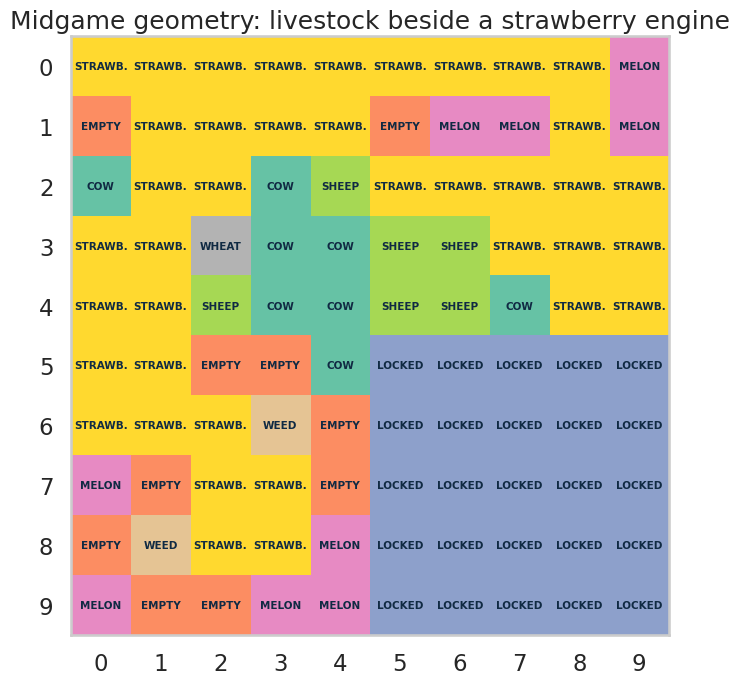

In [10]:
GEOMETRY = [['STRAWBERRY', 'STRAWBERRY', 'STRAWBERRY', 'STRAWBERRY', 'STRAWBERRY', 'STRAWBERRY', 'STRAWBERRY', 'STRAWBERRY', 'STRAWBERRY', 'MELON'], ['EMPTY', 'STRAWBERRY', 'STRAWBERRY', 'STRAWBERRY', 'STRAWBERRY', 'EMPTY', 'MELON', 'MELON', 'STRAWBERRY', 'MELON'], ['COW', 'STRAWBERRY', 'STRAWBERRY', 'COW', 'SHEEP', 'STRAWBERRY', 'STRAWBERRY', 'STRAWBERRY', 'STRAWBERRY', 'STRAWBERRY'], ['STRAWBERRY', 'STRAWBERRY', 'WHEAT', 'COW', 'COW', 'SHEEP', 'SHEEP', 'STRAWBERRY', 'STRAWBERRY', 'STRAWBERRY'], ['STRAWBERRY', 'STRAWBERRY', 'SHEEP', 'COW', 'COW', 'SHEEP', 'SHEEP', 'COW', 'STRAWBERRY', 'STRAWBERRY'], ['STRAWBERRY', 'STRAWBERRY', 'EMPTY', 'EMPTY', 'COW', 'LOCKED', 'LOCKED', 'LOCKED', 'LOCKED', 'LOCKED'], ['STRAWBERRY', 'STRAWBERRY', 'STRAWBERRY', 'WEED', 'EMPTY', 'LOCKED', 'LOCKED', 'LOCKED', 'LOCKED', 'LOCKED'], ['MELON', 'EMPTY', 'STRAWBERRY', 'STRAWBERRY', 'EMPTY', 'LOCKED', 'LOCKED', 'LOCKED', 'LOCKED', 'LOCKED'], ['EMPTY', 'WEED', 'STRAWBERRY', 'STRAWBERRY', 'MELON', 'LOCKED', 'LOCKED', 'LOCKED', 'LOCKED', 'LOCKED'], ['MELON', 'EMPTY', 'EMPTY', 'MELON', 'MELON', 'LOCKED', 'LOCKED', 'LOCKED', 'LOCKED', 'LOCKED']]
labels = np.array(GEOMETRY)
categories = sorted(set(labels.ravel()))
palette = {name: i for i, name in enumerate(categories)}
grid = np.vectorize(palette.get)(labels)
fig, ax = plt.subplots(figsize=(9, 7.2))
cmap = sns.color_palette("Set2", n_colors=max(3, len(categories)), as_cmap=True)
ax.imshow(grid, cmap=cmap, vmin=0, vmax=max(1, len(categories)-1))
for y in range(labels.shape[0]):
    for x in range(labels.shape[1]):
        text = labels[y, x].replace("STRAWBERRY", "STRAWB.")
        ax.text(x, y, text, ha="center", va="center", fontsize=7.5, color="#102a43", fontweight="bold")
ax.set(title="Midgame geometry: livestock beside a strawberry engine", xticks=range(10), yticks=range(10))
ax.grid(False); plt.tight_layout(); plt.show()


## 4. Untouched-seed promotion gate

The candidate below was frozen before this larger matrix. Each pairing uses complete 720-turn games from both player positions. Opponents include strong public notebooks, prior versions, fixed portfolio counters, and freshly downloaded public agents. The heatmaps expose failures instead of hiding them behind one aggregate.


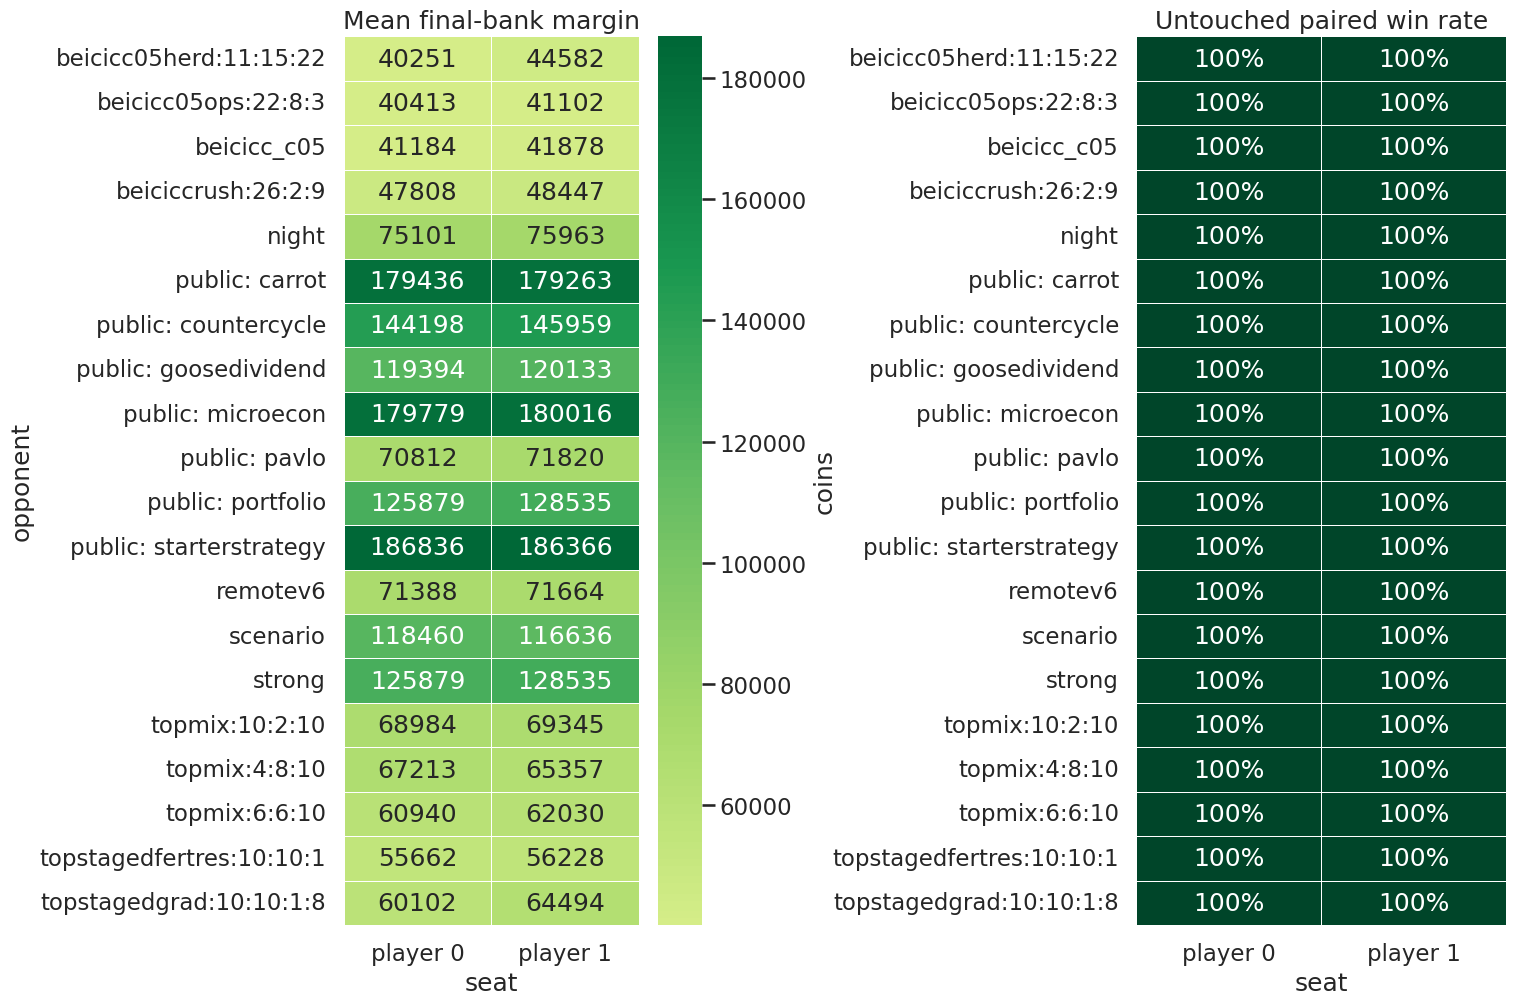

{'games': 160, 'wins': 160, 'win_rate': 1.0, 'mean_money': 158143.9875, 'mean_margin': 94451.79375, 'minimum_margin': 32679.0, 'all_done': True}


,opponent,side,games,wins,win_rate,mean_margin,min_margin,mean_money,all_done,opponent_label
22,refresh_starterstrategy,0,4,4,1.0,186836.00,182419.0,188728.50,True,public: starterstrategy
23,refresh_starterstrategy,1,4,4,1.0,186366.25,183755.0,188257.25,True,public: starterstrategy
17,refresh_microecon,1,4,4,1.0,180016.50,176176.0,180096.50,True,public: microecon
16,refresh_microecon,0,4,4,1.0,179779.00,173548.0,179859.00,True,public: microecon
10,refresh_carrot,0,4,4,1.0,179435.75,166944.0,186769.50,True,public: carrot
11,refresh_carrot,1,4,4,1.0,179263.00,173379.0,186033.50,True,public: carrot
13,refresh_countercycle,1,4,4,1.0,145958.75,143089.0,174163.00,True,public: countercycle
12,refresh_countercycle,0,4,4,1.0,144198.50,132716.0,172622.00,True,public: countercycle
21,refresh_portfolio,1,4,4,1.0,128535.25,125700.0,172358.25,True,public: portfolio
29,strong,1,4,4,1.0,128535.25,125700.0,172358.25,True,strong


In [11]:
BENCHMARK_SUMMARY_ROWS = [{'opponent': 'beicicc05herd:11:15:22', 'side': 0, 'games': 4, 'wins': 4, 'win_rate': 1.0, 'mean_margin': 40251.0, 'min_margin': 33485.0, 'mean_money': 137041.75, 'all_done': True}, {'opponent': 'beicicc05herd:11:15:22', 'side': 1, 'games': 4, 'wins': 4, 'win_rate': 1.0, 'mean_margin': 44582.0, 'min_margin': 41746.0, 'mean_money': 145398.75, 'all_done': True}, {'opponent': 'beicicc05ops:22:8:3', 'side': 0, 'games': 4, 'wins': 4, 'win_rate': 1.0, 'mean_margin': 40412.75, 'min_margin': 32679.0, 'mean_money': 140941.75, 'all_done': True}, {'opponent': 'beicicc05ops:22:8:3', 'side': 1, 'games': 4, 'wins': 4, 'win_rate': 1.0, 'mean_margin': 41102.25, 'min_margin': 36034.0, 'mean_money': 135881.75, 'all_done': True}, {'opponent': 'beicicc_c05', 'side': 0, 'games': 4, 'wins': 4, 'win_rate': 1.0, 'mean_margin': 41184.0, 'min_margin': 33963.0, 'mean_money': 140891.0, 'all_done': True}, {'opponent': 'beicicc_c05', 'side': 1, 'games': 4, 'wins': 4, 'win_rate': 1.0, 'mean_margin': 41877.5, 'min_margin': 36658.0, 'mean_money': 135771.75, 'all_done': True}, {'opponent': 'beiciccrush:26:2:9', 'side': 0, 'games': 4, 'wins': 4, 'win_rate': 1.0, 'mean_margin': 47807.5, 'min_margin': 42318.0, 'mean_money': 153726.5, 'all_done': True}, {'opponent': 'beiciccrush:26:2:9', 'side': 1, 'games': 4, 'wins': 4, 'win_rate': 1.0, 'mean_margin': 48446.75, 'min_margin': 43295.0, 'mean_money': 150611.5, 'all_done': True}, {'opponent': 'night', 'side': 0, 'games': 4, 'wins': 4, 'win_rate': 1.0, 'mean_margin': 75101.0, 'min_margin': 62433.0, 'mean_money': 148313.0, 'all_done': True}, {'opponent': 'night', 'side': 1, 'games': 4, 'wins': 4, 'win_rate': 1.0, 'mean_margin': 75963.25, 'min_margin': 62955.0, 'mean_money': 145986.25, 'all_done': True}, {'opponent': 'refresh_carrot', 'side': 0, 'games': 4, 'wins': 4, 'win_rate': 1.0, 'mean_margin': 179435.75, 'min_margin': 166944.0, 'mean_money': 186769.5, 'all_done': True}, {'opponent': 'refresh_carrot', 'side': 1, 'games': 4, 'wins': 4, 'win_rate': 1.0, 'mean_margin': 179263.0, 'min_margin': 173379.0, 'mean_money': 186033.5, 'all_done': True}, {'opponent': 'refresh_countercycle', 'side': 0, 'games': 4, 'wins': 4, 'win_rate': 1.0, 'mean_margin': 144198.5, 'min_margin': 132716.0, 'mean_money': 172622.0, 'all_done': True}, {'opponent': 'refresh_countercycle', 'side': 1, 'games': 4, 'wins': 4, 'win_rate': 1.0, 'mean_margin': 145958.75, 'min_margin': 143089.0, 'mean_money': 174163.0, 'all_done': True}, {'opponent': 'refresh_goosedividend', 'side': 0, 'games': 4, 'wins': 4, 'win_rate': 1.0, 'mean_margin': 119394.25, 'min_margin': 103895.0, 'mean_money': 173953.25, 'all_done': True}, {'opponent': 'refresh_goosedividend', 'side': 1, 'games': 4, 'wins': 4, 'win_rate': 1.0, 'mean_margin': 120132.75, 'min_margin': 103724.0, 'mean_money': 174545.25, 'all_done': True}, {'opponent': 'refresh_microecon', 'side': 0, 'games': 4, 'wins': 4, 'win_rate': 1.0, 'mean_margin': 179779.0, 'min_margin': 173548.0, 'mean_money': 179859.0, 'all_done': True}, {'opponent': 'refresh_microecon', 'side': 1, 'games': 4, 'wins': 4, 'win_rate': 1.0, 'mean_margin': 180016.5, 'min_margin': 176176.0, 'mean_money': 180096.5, 'all_done': True}, {'opponent': 'refresh_pavlo', 'side': 0, 'games': 4, 'wins': 4, 'win_rate': 1.0, 'mean_margin': 70811.75, 'min_margin': 68750.0, 'mean_money': 156163.25, 'all_done': True}, {'opponent': 'refresh_pavlo', 'side': 1, 'games': 4, 'wins': 4, 'win_rate': 1.0, 'mean_margin': 71820.5, 'min_margin': 65118.0, 'mean_money': 157462.0, 'all_done': True}, {'opponent': 'refresh_portfolio', 'side': 0, 'games': 4, 'wins': 4, 'win_rate': 1.0, 'mean_margin': 125879.25, 'min_margin': 120844.0, 'mean_money': 169123.0, 'all_done': True}, {'opponent': 'refresh_portfolio', 'side': 1, 'games': 4, 'wins': 4, 'win_rate': 1.0, 'mean_margin': 128535.25, 'min_margin': 125700.0, 'mean_money': 172358.25, 'all_done': True}, {'opponent': 'refresh_starterstrategy', 'side': 0, 'games': 4, 'wins': 4, 'win_rate': 1.0, 'mean_margin': 186836.0, 'min_margin': 182419.0, 'mean_money': 188728.5, 'all_done': True}, {'opponent': 'refresh_starterstrategy', 'side': 1, 'games': 4, 'wins': 4, 'win_rate': 1.0, 'mean_margin': 186366.25, 'min_margin': 183755.0, 'mean_money': 188257.25, 'all_done': True}, {'opponent': 'remotev6', 'side': 0, 'games': 4, 'wins': 4, 'win_rate': 1.0, 'mean_margin': 71388.25, 'min_margin': 63938.0, 'mean_money': 143968.25, 'all_done': True}, {'opponent': 'remotev6', 'side': 1, 'games': 4, 'wins': 4, 'win_rate': 1.0, 'mean_margin': 71664.0, 'min_margin': 64755.0, 'mean_money': 143771.25, 'all_done': True}, {'opponent': 'scenario', 'side': 0, 'games': 4, 'wins': 4, 'win_rate': 1.0, 'mean_margin': 118460.25, 'min_margin': 105123.0, 'mean_money': 169233.25, 'all_done': True}, {'opponent': 'scenario', 'side': 1, 'games': 4, 'wins': 4, 'win_rate': 1.0, 'mean_margin': 116635.75, 'min_margin': 104846.0, 'mean_money': 167621.75, 'all_done': True}, {'opponent': 'strong', 'side': 0, 'games': 4, 'wins': 4, 'win_rate': 1.0, 'mean_margin': 125879.25, 'min_margin': 120844.0, 'mean_money': 169123.0, 'all_done': True}, {'opponent': 'strong', 'side': 1, 'games': 4, 'wins': 4, 'win_rate': 1.0, 'mean_margin': 128535.25, 'min_margin': 125700.0, 'mean_money': 172358.25, 'all_done': True}, {'opponent': 'topmix:10:2:10', 'side': 0, 'games': 4, 'wins': 4, 'win_rate': 1.0, 'mean_margin': 68983.75, 'min_margin': 61172.0, 'mean_money': 139219.0, 'all_done': True}, {'opponent': 'topmix:10:2:10', 'side': 1, 'games': 4, 'wins': 4, 'win_rate': 1.0, 'mean_margin': 69345.25, 'min_margin': 61749.0, 'mean_money': 143857.5, 'all_done': True}, {'opponent': 'topmix:4:8:10', 'side': 0, 'games': 4, 'wins': 4, 'win_rate': 1.0, 'mean_margin': 67212.75, 'min_margin': 56257.0, 'mean_money': 147827.0, 'all_done': True}, {'opponent': 'topmix:4:8:10', 'side': 1, 'games': 4, 'wins': 4, 'win_rate': 1.0, 'mean_margin': 65356.75, 'min_margin': 53821.0, 'mean_money': 150488.25, 'all_done': True}, {'opponent': 'topmix:6:6:10', 'side': 0, 'games': 4, 'wins': 4, 'win_rate': 1.0, 'mean_margin': 60939.5, 'min_margin': 54885.0, 'mean_money': 142356.0, 'all_done': True}, {'opponent': 'topmix:6:6:10', 'side': 1, 'games': 4, 'wins': 4, 'win_rate': 1.0, 'mean_margin': 62029.75, 'min_margin': 56354.0, 'mean_money': 144469.5, 'all_done': True}, {'opponent': 'topstagedfertres:10:10:1', 'side': 0, 'games': 4, 'wins': 4, 'win_rate': 1.0, 'mean_margin': 55662.25, 'min_margin': 45657.0, 'mean_money': 142955.75, 'all_done': True}, {'opponent': 'topstagedfertres:10:10:1', 'side': 1, 'games': 4, 'wins': 4, 'win_rate': 1.0, 'mean_margin': 56227.75, 'min_margin': 44276.0, 'mean_money': 143301.0, 'all_done': True}, {'opponent': 'topstagedgrad:10:10:1:8', 'side': 0, 'games': 4, 'wins': 4, 'win_rate': 1.0, 'mean_margin': 60102.25, 'min_margin': 58311.0, 'mean_money': 150923.25, 'all_done': True}, {'opponent': 'topstagedgrad:10:10:1:8', 'side': 1, 'games': 4, 'wins': 4, 'win_rate': 1.0, 'mean_margin': 64493.5, 'min_margin': 58186.0, 'mean_money': 159588.25, 'all_done': True}]
grouped = pd.DataFrame(BENCHMARK_SUMMARY_ROWS)
grouped["opponent_label"] = grouped.opponent.str.replace("refresh_", "public: ", regex=False)
margin_heat = grouped.pivot(index="opponent_label", columns="side", values="mean_margin").rename(columns={0:"player 0",1:"player 1"})
win_heat = grouped.pivot(index="opponent_label", columns="side", values="win_rate").rename(columns={0:"player 0",1:"player 1"})
fig, axes = plt.subplots(1, 2, figsize=(15.5, max(7, .52*len(margin_heat))))
sns.heatmap(margin_heat, annot=True, fmt=".0f", center=0, cmap="RdYlGn", linewidths=.5, ax=axes[0], cbar_kws={"label":"coins"})
axes[0].set(title="Mean final-bank margin", xlabel="seat", ylabel="opponent")
sns.heatmap(win_heat, annot=True, fmt=".0%", vmin=0, vmax=1, cmap="YlGn", linewidths=.5, ax=axes[1], cbar=False)
axes[1].set(title="Untouched paired win rate", xlabel="seat", ylabel="")
plt.tight_layout(); plt.show()
gate = {
    "games": int(grouped.games.sum()), "wins": int(grouped.wins.sum()),
    "win_rate": float(grouped.wins.sum() / grouped.games.sum()),
    "mean_money": float(np.average(grouped.mean_money, weights=grouped.games)),
    "mean_margin": float(np.average(grouped.mean_margin, weights=grouped.games)),
    "minimum_margin": float(grouped.min_margin.min()), "all_done": bool(grouped.all_done.all()),
}
print(gate)
display(grouped.sort_values(["win_rate", "mean_margin"], ascending=False).round(2))


## 5. Write the distilled agent

The policy below embeds eight credited public state/action trajectories. At each day boundary it performs a deterministic nearest-state lookup every 24 turns using only the live observation, then deep-copies the selected action. It has no internet, replay-file, dataset, model, opponent-identity, or notebook-global dependency at inference time.

**Attribution:** all eight state/action tapes are derived from public [syouya tobita](https://www.kaggle.com/syouyatobita) episodes **89508871, 89510489, 89512153, 89513803, 89515993, 89516538, 89517103, 89518736**. The routing rule, packaging, robustness tests, visual analysis, and presentation here are this notebook's contribution. Do not describe the underlying behavior as independently authored source code.


In [12]:
AGENT_SOURCE = '"""Visible-state router over eight public syouya tobita top-ladder episodes."""\nimport base64\nimport copy\nimport json\nimport zlib\n\n_PACKED = \'c-ri}TaP4HvZeQ5_*@Sam&(f2TQwPTnwV;`(IgcZ4T#2p<_H=HBME2bZJ_@yl9d$~H?z-{+1{QRnasC9Uc&dy-M6j1F8}kJfBS#`>wo`${>#7p^S}O=|NhPY@}KV?KD@ub|G0Vg+lS5j{r$rqAGVthyFWhc?%#j;@ZsU%%ZIxUyZb*reB3<#>i*;I?$>wU{EvVC*Z=+Be*en<{6D|>KmPUK|J%R)`){AW`TM7ze){IO-~ONf`hWj%z283mw}1Wj|LfoW$M1jm&0oL&$Kki%UVQk=FaPPEpMLoMZ=XJY^X{8(e>{HkZu9lWKOGL={r1DZ9X|i~!#D5l7C%1z_3-KE-+%n;|M%{)0e|`B`_JF~^S5UF{L3GgIJM+Ie{($i^z$DV{o%)d{QTE%e!Xtn@8A9RfBg8}FW>%r`SrENKK|Q>Wvl-F{kQ+|m%m^9*G01)Tl4Pn)0d_S4ctcUS~lSGr*99BzrDKpa=fxu{B-#I`F#0P|AmJA^w-1T?_Sfsj?MW$FWUFhkH0*&#<q0vlU_r2=P6z^>_7ZIr&o=+p2qF<XdOO1F0YYci$~`)e3uRS_LG^k$2;)rhwkhxn(_7f-F5rh;`-s|)2-??hgz}K2g7N_^}_yb@IU>0_(!=7!aBZw9ECU7mud1R>GS|PFY2koV;Ahjg<y`{=V5!PJa*T+Z7#dyP1Iv^d&6NG@;Kb?l08ku>4P^D+I7AT?U&zQUGQ;6yx|WggnPg2<Krm0bABG;i%;sCWtR`99mK^4>dLM#jLVx`8O_DlwR&s^_cWpI*nas`>a`tJ`?$b2i`$ibVQ|lPfEmNng>f*id$<=y@w`k<W4CNzFq&F#o%e+E?B$yx=@qZmMOW-k?1Ncfr_u;J%hU9{)?wJDNsWGI_W$YYi+AkKi-9k|JI&L5_wA3LKOesR`Jeyc@Q<Ir|NQ;`cC|=K<-=~YP0kA|E*I1{d2>{f;n7;t?0tI8Q|nHTEN3rK>$rc(#j{x5dRMm7-~Hpqzc(&%n&^ub+YN(rlbxTzU%%XYKGTKUyZ6QJ3pQp$SC%>*zJW?J`}HBqom{+m=Je9LwC%ygecI?AYyz9T>rB;HA0BUEzf7{7aDLgJqa{A(_TYR)>DuWf&fB=Pu7I8B%#qTG^Y_}{-DV%g*IDNhr_q@*O!iBLzF*!|F1M%eg7@9@ZKk}P6@j7^H=#OmbPM}Z5nXvz+f&54X6#R$`B1Q~<kFiA_lePv=5`oR30!GI8;lq*OW=Y+f0Pej9;CB(x_|`Kri=Et=laNwAj94hHo2#ZdmF^X+o`n4J-6KHpK}D%ScTpt?9$V(V0XEv|2-F&_Iu$1@e8-R_jUGk(OS9DO(Sis=j<6zlhxh4yVE92&f+Uqs2ZN*3b(Xb-8|!F^=()BwkvgZrRmmY3^b)pX?;T+>`I;2oA=4vWGM)$1Y@qZM<tkT)|NX4W9!G|wJj>1(!GKmDngir4$>CYSs}BxsB}_L=mqRiX~Twl)K&MQ`sg+HqH{0swikWdi-sFdXOH@}7k%4{X3W6VH>1;b!i9b+1hzql^sk@(@xNxD9bQfcS@fP<Ik)`!++yc5+jsdxA?n<TI;SzP(hW~cv+|(g)78&EIyEjFi=Te}$EV|84*&Saf3ieioptJNjUJnNafM)??fhZb-f*`QlhwR?!0wA{i<B6Dm)~@;5Dq^@Ou2Mr@P0e^zGa^ZodX&yT-N@?8Hw7M+U3qwQ|0W*?#vNocWNqIUKeN>;rH1OqgNQ~1RcQ7=>+WaEm6$bympCVwE`ym(X<Li>e?j0cDK1*dO;@ida}*4B&iBp-&2FFx2xW*w5zsn^!Xg!!Y<p2=o(|yU3910J7^|p{oK|y>az2raw*C5AVN)>IoN=+vM*s%79OoyaS~$FP29T1dl>5?7ap-JaCQgJi<ZQgle)NMx4%p1+j7U8O|-K+pVcwDhrU!AUFj%`1liJPo@&C=%#{e5qvsE}x0!JgK_@NLidL7MiUAJfoE|?Z^8{Ox0<^OTv(I>;l_<a#<X)d%arexd^}A85*wsf%c&LlwuLEcgp{bS1r@Qq{Hsa3Pc@$uFFvY@FJij^#*e^FbPS^PAb6zG+_m8GYC_1g|t{jvtEh7dFRp80MbOjwrq)kGMk!LD<Z8iy|_6`lwGB@ol3@COM#P2#X>riSVI!J3YNq~)Xqy>cMKihx&@iV>UDtD1n{e-Zd9f<^ca;^-l3a6NG{XfRdK9CTzXjloBA+xEXnoRHdrZ(Xg=0IYDV8Nm+|Dxn@p!d#GlrA3aT}vI7t_kdpzP`h`vL)pdudES7HowkfpzQ1g?nd^mt8L^T+w}R<58ut$)f4I{?C(F6#wbuGUY=_2s|I$hV+9em*JtX(Fe}H~+L($fZtZx@kP~8x2MWU_1ro#UD0SwoQdMOAZ~k8L-KyAiICX(b?hXHJc6kDPAX+@Vf<@sOyhDz}f&$ZjH)?)w76BE0)YX&PQ9iw`>GC=0M=1mVkrj?dilZ{a1cqREr(UTKSEW(j&3q6T+%pDA;uv9taav~9XsooTl#QT<B}m+k5f?b2U0w~MfZ390sN>36Y{o&c<7*cZ$Xp_*Uz@bH1+LcAkfe_%Ta%gyLY7(sMPI;MYUtd_o_z?k>s3tU@^VI@nH6i>2?eOjdQ~mRrxc^T%JTF=>zqT$#pYuN|Mvao|44wu%<|LaBm3t(O3whaz2q5%a6q$|HPs>SI|MRVXtX$ABIBK3`Hgb0{L_z!WVe78V9{;1bDovn<cQR>1_a^#;n+&tG--Xdn6L|p<mmSKsQSE0^j6r}U!CZN*u{bzMT^cUnUc4*GD-S2cfrStbQtI5NyU`AWY2EgtmDxugh-bY`UhP0Bq!H8m`J(N1UNVg+G!N}K-v9ZO((S}z!1s1kGP}ePFOCGtyCx_V=WO{?b=RX-)9PgeM&_)X3|tU%+3oygPMHg?);-A@nb?;(_LNGV19U*;x%hIu4sD)!UpqQMy>E+kj3f_4@i~vinuKfAs*i@rJY@lk9(19foiB>NAiX^jr$ZO_cAl55kA;kg4kGMd)S{W9!j;@boLtAz1v{O()pWr5d=KQ4^P0ogaZs0n3#loY(7px6YQEAJL{W>0tDM(H&>`z^gn*d!xNwy7wjV>3AjHr=$7+s2ErdZZhx2t<1p1ZqVARrE7m!?Po|CAlXdcphkOd^x3${s@OY_0*2x}U{<5!>v&G-#o#=0}zx)1Q0z|4yxX`eTI$E>IFeqnUf>%!32TCnz$mq{A<8i=|5^!8j)TyQ72ED^6ah7x9k>W&HWcyIqp^O}k+oATFPOyYiZC($$<}orf@Vv*jTe9m077)q)aWO4(B66Unt}KeV;(YH%vL7$T5@agb&<ouBoF`t`gkr7AZ&=$E?{;^yV|q8hzV+l0JubQJ71|c@AdnDd8+v+x0MwbBv5zxgfXd}PTpB?M*?K6XJ3G&B<nrL7175OCV8dHch-XmIY({_5V^|w6CL59rAypR9t3lB<B+yXH5G_pfPT(}~_MJ3ZZ6IS?@JZL18e<^F_C<mioA<YlVqE@^O5fI`y`RrNNy#*2+3^$juJdT;mG9TKyQHDf>fVqMTukEhA>)f2fjcwaNa7AiYKcKV(V)|Im@@f<K6>f=!kb#$sH1cu!(H^&kWihF5mai787AsZpgzo%E+=3tI?ZwXJ#kClRn5?D7-i?aZKz<IDRIEL4VlY8WlSWsND4LauDvoobbv>N79VaeIdMMU?TgXyUCBV#JdY_X*&f+R?SV~bd^(cD9w%dE-3;q|lVJP@oLW{mlbXS#rXalHewmWv3a~fwWg?V+AxU1UhcBm1b9MyPKHpfC&{pP6xpHDnWmuN>SLF5%Lbv<1c)p&!(8y<t93Ul&g7hY?ICnURyQkll7DG1Vj}6}rvjV>6&fZ_%BWFIlGbj&^#%nFv#8@%Ddzr=f_9YeL&KLc$*0&St^6eAV<xN5XZ?L3KtGN0m^W-_|EcCr)hp;*4ncegK6ax4ZQ``lMhjBQ7Pyn}<RV|R$Vk2yuataw&U?0E=<9vK}_~<O*nuA<qImMlE$Ma2R!*TkN^{pTT-)er48B(fP3CLl4ICLH$;;77yN75{@`JK}_IQ}Frz~CS~9cWEPpCC2pMs1%$W5>u&x(*oarH?iNP51BJ4(yUqktrq8d)9%#Nl36CM$s$`A~Lg>dXQ68?keOCx&hJJJY~R@kIj{{frdQHIXPvhEHqE3o~$bmKzhU=heDerLJo)8O=^e2B1vbjEcnO)R?S#nL-nwEBK|wX#G;mSG=WT>3{9(=1Q&`%;%%t|XNN$v=65(l>YQHb-a&I7=3q9<Ern7N?$?HF^aD*Qqn{nWDYmx>={z%Pqc_>EIbnB*7{F75Hct7dqfX?uIOIIj^^gEC=JXSV4I`((uHlo9myz5dvWE>E`Q+?j+YM(ApW!feTEO2_<kk0R297S*K@OTvb)od_guXqtxgtz=2GianP!_w~ssaA2+h7gxK;AqZ!iOq{W{xV*j_ue=ei4Os*%Lvc%X{12g8~kROBvdBUMoo{bTP@Uy2>#vN*B6aFTv9;JgP6cm8L~Qs)jp*r*v{pWx0RtVXF8gg5wLFyqG$zBCOf9?8Y1d(T<dRF4lxF){m>0eIW~gk;9Fz6yYi%;fke9Oe3jQtOXDc%$M5ne#?WYa=dKYvuBsz8I`43#AjJAZ%#x0G^=56zP=1wrY?+h1CsqDtUV9Wf&|cmpNmblq?!<*yXaV)Q=Fb$Zp*QUad*n>AY8~F?TP>i>ihM5M;LLsZs~p4(pP{%?U{Z0dLSs(Vs?KMpj6A5q=88VF0_N>l~g0^?4-5RWIeRaIT8fWsZg#U4M(B|^|i`{W#J4Sjdkq-G@JstD;Qxr8~{2xC+37RJQZYZlfyayemDS$v(K`t|N150I4jv!p&YLb%Wf4wXQXTK_jGzEn?M4ZgZwQzmqwuN`W;j-WVT)6ES!UoN=cJ~6iwBFzmgjxs_ivI(K7{#YZl94ug?#uue`2>Rw%I8XcUG*CzJzvmV-G>Ltv6raYHwbu;fsj=lrs;ACO><NgX5RN(6U28e`e_5R+b>aJr5X2<<RdtF|3NL~yT5`wGS;ib$(8BI3L-m#J4NZhb+b=`O*lB9j{@^@Qi0R=P5!*M|r1iq*f+Z9=o`O}m5*vrfzQv9bw~KJoW`6bx?R<P*5cz<&+^Jbl!XIj{gpqVx~m#j~bygeP`&{E*wm?1w01SJaRKrnhaPk3C>Sw{U4w$=-uZc~wBGfShztJ@i0We+nC3L++BSrY)_^Ci79qhBU(8^2>W?fb-_?%v7Ty2P7ld$tt&IDFNd!j8JP9eU^=tS5^c{^fPCW6AQt!B<%@SSyQ8A7n7s{vyY9{?25fDicU?Vngd^YEe>6RTH<X@5TC;Xus1jxNc+;ImNBz~4tt-RKSMc^qM_`>av)B?pDd20dsaous2t4YvW)eUEJhgwiQfP#PjJ!7+^BNodm7VHL^%&3%~(JCvrj%NV?+ey^ygjzKu&I!icbf3etdf5Hyx2+913Qh0<5m0f?zYWrLsI&kCO-rHY*L|XQ1xKt=xb#_D)AM9b0@?*Cc>s5G;)(X^H{qZnp9mn{_$BhbNcIK~I@Id0xc|6_2`Q2N46g&F@4$Y`#LeCQsog?9709WWURwU8evuv1`F4dlL}elz`ANE1SpOYJ@SbtshMK+aPV-7T(jyWhQM*jjgpJyn`V^PDKuf*9~|F56_RP(6m#6kA3GH(iYONXqWH%@Y0$}XM$>LgxQEEhaN>8*k*vfl+C>3+N5G?BF(F_Xq4Dy-AZ0OVsi!{-?`f5?L0KF24P4lo4-N7W#Z-L59<s=NJ_&li$xJ^6g}2E&<2_#QKmVxO+H9jC*+28_3jUkhxqo1xg|9XY<gc?#>%;@BKkxkVtNE~bWfXT4U56kDoqTQ6j*_E1Jj)eVOuH05V2zpx<(Z`YI<?Z30`D(Dd*1?3M;TbuNXk9fm0$E%5s3x2b{A_&DqRy%A!EhskO~Qc+O2A@M|TGTw#`*I=P1kUwN<KE8Fc5XXXtxc}moT<A`3L>k{{u?U(fO_l3eHScg5O|I!TLL}#_xBRs_=Q<Nd3YsKGpBNsyK+7n<V6yFU7Ovi>_Ruf7gS(_{y^Ji-))M48S01c9?TgLu$xIPs?abT@NgOi-{p*k9NA7Z>UntbKPH%$`Trj((hZrv$LN`Nrtkiaw#8oPD_$EUnc-JL!P`U1Oh;-i_D&{Uj-1>#!taq*c$9VrMDllnIfmli|Y#=uKk?`bAg4aUU)kXf$wnINTs+PVpL;i(qf?`5|z@kzLt-Y%d*Ofq&Kq@&GAS?CsP<c5ndnhSSy4G6^-E}t6l>~}HB$r#H$ky94s;{6kelUB!CdJ2G-YjN!?*fD@b-+?`ct92v+;cqZL@)oC13LKjM-Fmtt$;vui*dFCywJcT(wh@Vv{h-8`Ri|xKq7<#a&eUb4__58bAQVFle5)y_R7G6E7@w$7@-~#<SyVWk?O+={%@VQDP&Fr<47Ti)j0+TRCh^Q2H-y)Bg2S2WG~Z>pQ?xyl)KOC<qlYzI$tmT&Lde56#-Loe@|>b0R!QH(l|&~KA;^%+PGwIl0Ppeck8Umgola7<0Ct5g;S|A+o=_tw`LaDGc_eD0y&PB_KLQd!OFFa=5Kn}!&P#-ewbDJnj(VlxZ{N}6iv?L5$r8zruxbZCc2&^J*O8uS0dGY|vp-h${m^Yo>aa7^NJ=x&oJJ3!MN*SzH2$@55mG1Kt*2Q7v%hlI{XucEspm#=@8=VB_<?!}AKfQ9C}T7A#@~74@4PbpPFg1`L255U_T-RT0Cc%c0*{MN7l;GvlXx`Zl*Ya2<9BVDlS{C7kFXu2NLHNH$T`v(b3n(bJ@GxC^huUN5|yVU&Y*qj6se2E+Hp<9$cQSyNW<c%M%B^$V%RPR5eNxyoV-91_!_s|8BjN&R0P6~dv)IAd%umA3OgKi4e^t)^?#jcP_XjK*14QxsPUsTCG_kBi_6z~hO=t1Rnfg%Yhb}GTTDXtFon286jQ0LeO%i?f=Q_j54@{GS|O}TD{?6#Pz%TyDA#A8cz}s9%LK-7l!%5S=&a5#S1bkJ0e`t%uy?<fl0_w#BJz_?OvP3(p)vfO2xz&yU%e#6k8^+)r^dYvtObIXWh%vMNvNNde)TK_p6L!Vb-}{gG@jm}Q1)o8Tg=Sp3%SUEaiN`1&-}G^LW2N{ZjGBz><c~|Pir$nHoSHwNRk$szc#n%f}OT!D6NAj{x`|%NF9A}`P9Pd@$6f&$(X~2@+d7L>DsSSg9%9HeGVu<`AX<yB%PE`0kHM*Fo8}p`OhK8`38VH_B_^1e=1S!G3-z}r;p@X$q1{mK$O?kJcHB7dVm>~wOe#u1^|vBs07nO29{mV0|=Ig1!sUuatkK(J-2X`85`oUkt96RL$@nXfhb)>7!Dg)wTLQ^GCYDBwp|=Q&3e}mE0A15m=?Jm6QYsV5ei?2BwsjSIKma4)O^ro^C3W8HW5tv;J_{qZ?dUBp=?TXgnNauDN#+T(0C_e6mfek3?clj9*ycJVNI$=r)a4P?z#slmS~!`iqR$q#~>uiuT*Dy8fT-bL{+t7o#w_??J5bo7HdlOZER{0hVIs&C$aFPP%2#IbNr2|;r7F6tJ*jMQF_xoFz(V&<U+h485D7nBCrhZ$Mm3d{>Xn0MX1N}$x=J-Mu138#LJ#d<TuiT7INldhPM*1_vJ3awccUaCAeMS(Gx6yj-N2JGFFYrDNtzIGeS5il<J`i3(Pi2W(k|>a!eTkBbp-}04^fCplIENjvk8A6<9agGD-Tcd-4+05x}|5_Ix4d5sr+Yh2ls@;J~iwH=XS%%hZ}Mk838vr@BUGC{MvExeW7MVLE%GZn}43m~^_$-7D5LktFobNVgHFurHHrQ^I+iK{Ee#+YnF**%Xi4B#HNmh>u7$qJ1nyK-KD~DfFW27mBl`LRZEXd|iAqO6!4viKuq)delylh8hf<l?W<HRcz9WtwsJ%$V3!vb}aZc{b67z47N~3qL9xHcgLJtR3Oi>eNE9B#AO*vcJBdZ3e2ztmc7%G0z-?P%J;bLt>8ij&do_IwA|s89GDBmTUy5DZ7Qi<tC7Z9s82FL39IF+32I{?BczaC?x<H*@%r*OqJeV6_d3M2yn>vzR4v&hj&(p<wf-Gc;nW6)|F5d`)y;8;SdwcpBMdAztP26iAX6E-khxOf$R1;H8|j@2c3UaQ4fn=2Z(M30nT#RC+oj`dB0A1KMBD-!nm4<d*ATLO=CZvKyBRfPJBBg@J7Wc#xdlg>%CV&GutP`W&*e`;SP{sj^vEg2o2G@#xHwGEF0yK_7_ZbQ_F4jY!QEJtjvt-|rNPpgXb6sE#uJ9kOU80GCBgdfoL!<NCD`{gf`fJ~>Wb}vrm)MHD(bo^5pI$vXH<EoV_XL?Cp%+fMJ$`fVC}CwPQl@bRemA~BOm9f!&^;8C(19DoPoDTACsgT)m;uz&73(iPjT?J?e`-=?V}ofc8CyBF7dRUxR_7@!FFs##%CtrYKpXu3VnlpLbM2RXVwa$BAEz8Dn!vTC#QWlBo!(7oV{Mae*Jh*u@NLT8R%vyW@@^_Ct_;~L|dzISdjSdn{>Ec?$=@k%vi%?)SoR`6HmpDZcxr8)X}em+2ia*8s<6nUtWTut4oQ|2^1=zGQ{lhPGF?cs<g^SNL<AZSyTj5#tjIh1$C8tTqruJ6@irgdzRjCjoEd$7m@)A+2_auPG{^&;V3)LQqr4*K==n(E$Cs_Pa+bQ1X{Qx<u4*Fv(ifrN~S7qpz(+tkK+3lK;aD*X%;e~Nm27Skc{S(Ua5eF!JR`1)xhKCi=B)Lx42fISX~{F3q_S9o?s7J#@73e#V7Go>~l8F5GR;z(o{MN(|x(wX=%M#mEi2Pr*vCHejN5Fu4Ri@Ng2yxRcQy}>OgiVAdQ&84!<d7HRYz^h{N}m_^y;6RdCwWQEgoLQjPJhkH1PW-dX;;J6XNX6lO~6O!Rurz0@-bp^~L#EU{LZI-DG|w&!gm=;v0NH`P}yk=8q3sGxG?*G6Ifh9JDH)#_cLdQuMN*Ot*#0gB_lFFsBqmC2iu%`4!U(SGB`#DB^Ev<#p&&j1&4oLNS(Qgs~jX=H?d6!s$mGi(xsP(=g@8cc;gsTsu@5hwmOM+v;ku#-_o=Y1t8-V&&sy+X!&BWNw5!*roRXTd1>Un2dbPe{s8LB{}|=o`csbH1uW^i&L+^x(dxiM+bi8|aoIebA(d-Y3^ZH{nx_KoxrDQdMEif_C`DUzr$=I7<qEjIl>{I2J0=-LfPpvl?BVVkfPKlu2#NZtDxG(xa}=`IQL&^ZvqtsOCI*wGa#~n1oZ!X7&o*=wW(5BBwbyEXg~Q`a_{=o=r8GsJGd#Ejo@2pKhn&$lh+{T34GPBNmL8^n|^!(E98^#_9={vj)uL$faXx(D{@0MF_D#<8uk~9$kv)NuE#|Ff=ceVXErOdI!hAw~cI+wR!LC*S1rzp2=d(?b;yPn}=2;ew3^nUSMDyQFv2Mn)aSv*EdSX0MUs!c)CAZT%7}}3CQPBh^tTiJvxDPr*HrIdPk~?nmnHZ5wpYU;BD`~ZRsG_BBDsCXg~N#=j`m8O`Z$KPEL2vz+rIoDgnDA5o5yXr#lbFrI$`Icp?GDCkN9>GE2Z{rL^fu;!5Y<NKg77=RmbV_P~Nk+C}}4f{d3{T*F<FtrNcz&}^Tb8DFNF$)4KLXzddL;><4#6@Fa>mVJ?sZKTTWy#^I##=t@LXtE3dmJDK1k}c0z;#zJshs+&3a&CwU#q6~#RZ>-a%96S;e7?4y)VV{DL+eV3A6M0o=rCuQIk%f-&x$myME`4%6kZX;gcK=f7VAO0dFh`1grRra_spldCO!QLgp+@k96VJvxdspF#mgoq(xQsshwwg^BxLRuSGU7m3)?{sHq`R8+taMIny^B|zv@w_=y{kC;5w7R!QThP)W}Xj!7Q9Mq>~+lWH7}3A)oulx7Hj%pIyh!#E?B);8Lt<U+3V18Jms*eF$4@Xpn)8bYG~=%3izWn9U*h@XI7$G~Cf!K{c=XBzx;>l2WTuDAR%RLEr@lI?;7Q6ia>c_%7a}a!M?3zJxu>w%}dJBs?kbFE@zyggIRv*b!3Pc&IThFv_gxaThjK>KD%kV;NP$yxB@A2kyv7j#yqx%J5Q><QhsT%woe=i#=hm(1>Ik|K;D-n?=s8bq-2Ggd|<Bc~^GhQhv;*rMVNkv#<hNPwFe*=MG<SVqeM}yboj%zmh=l5hUAujC||$fWdp)qld8NAD)6WrQRYBuYpGukM;f~(5M=swTGKyPocSy$ey}E&J^%jhAisWp-Le|M-6<N8MRk%8FP@2G=XZW6P%K^SI3-uweDz8BW7GHY1V=4=ui~q&S4OR@3dhORCu$_p>maM3sD({zZ{G@EE$NWWjx~oMVheg18B4(j^b3JR2&cMz`IAu4=;h{0yAw%?uVFMTe0Q%$WitiaT8R_#Tj0IiP8fAABE&FU4<_p8%NLv!GT`O_8Q~StUAW|U3QEj6;|7pr#M8XS!BijO7amz>WM+^o#&9!68M$Gq{5+eRw~iCdd;k`k03$sIojiFXPx%gC1xG;m0wZ1LlsTgsCUzluFS$C5#Pvb;%*9CMz`aYi<+oayEUN%=NW&?G^9cFAPLe-R17V#*?9NT{XHAwB$Qp9G~H-A)KDzmkb~FT?RA`$Q^OVAAU@n1%<=lb{k^^j`U#3nqQ|D<vSd*vN-Uo;^c6Y~5_vnR2wlC=uCl*M@fBx`<&2l9?&;3u#UPx-2j)1j_U2n(cCz(An2D_<Pi#6p6*K@PTQZz1OeIsCbzuv8S9TpK(<MAsRBkeEfg`nlGw&-_GvP*~W_{l(1d}*K8bYa7)vFxM?>nc`Apr<q<fvk4IC6nVI7)R0;`IjF*d0ZpOyI`IInX&ZFmws)k0dJ_J+*9-kT-CY5Ysv(H!prFa09OgaIdPV95jSLzbfOYF{t}&?(<~1&<E#(!vNbR?$U0dnYd(8se9f0>V*j$*Wh~f6{z>ye{<v!L5hukDePB!7-=S0`SsJWsDvaraJ=3U(esO{Ig4c`p+N-zpD_q~W#=3u-3~uKXmQKv8luAGQ*VT;^SI5O!z){YCSSf9Ul303p^X~Z=IcH^ZI0Xbi7nC_5XL>ISI-f*=@(!8&C9#Cy^wP0#i>U<QMlA1IDUyf6wlR1TG#l{o2tezhy!yuRS)?yjh_4zU_aQ(uT}5IDwL4I%r!W7&OCqq^zFfxz?bvx|3x8zba1@+z%gE@7w?Ry3-K?Wr^yrA(`e!5MYQm@Kc_Zk#m(;(-=`nG|J$eEzx&%Cj~7VKProB)*B%!aKYqO3&8y=tzkL7syMO-HjGuoAg=2c{c~@-giTWQMj(z<viIXQG4nezu2g>iiy}J5xylUR(Nj}h3!+!ef;qdoz4$Jv*VOzTRNmp*8lMb$@aa-_OXh&I|E_oV0mr?6%5=S&hHIMh-7S|6ypKevJIg><`PAje#wvY6UjfDF+3U9D4)8tQ5SY}Te9y$V|IU3426BN5HSpgK#lkCE!^Fx%miLTv`L;L0T{^^e${%}G{I5=wq!$5-0Ik#ebcRa|?z+GV&mp8dGnv1V%_1Md|Hspv>423YNAhnVwZ(kVP^BrKu@LVg<U@lJ@3Lb<Pg5gC2D~8AW9w^Q?Mbax?t&6VMpV$YpzE1Zg2RxVSoiEgVpF=7uG<9K?^k`h!QLa%w>_*#!r_<f!;^wGmy1}G1&EDr2O=S7jzPPLymA2lM?KJsn4#OPIO$IKQ&hO-XQc1_-Tspu7=kN->jzw>v(#%rYymOE~vzKT{;v6S*x(A!UX74&vHP#0T_I5fE9&)upXAOpj2};tn(@TV^m}ytQPITr-=|rxvy0t!xud~i2z;0;DJPdt*Rhg9VnYQz{nH9qk1t?l^6RIOex3DiA&qRB9+f&54X6#Qj(OLDj++?^92BUPg!+=V#C-%q&0~0(6F6b!M;loS?jf4c$ri=Et<ix<R_e|G4v~_E2a>Yb1{SpM#Q|^#{1-r|&nsVoR;R2(Y4rx!9G7)cU(@0zEIeSLS>nU#D$H@h2RSnN^g<IOJZk}<o`nD^5+m(jF6RUxyv?;A`h=X0JXBh5$0w<2DpNhq~*4v{J%r<Mw9fPs;<MP@T6;J72!44H6%t8lgi|VY9*;`aPDJb*;_NcUB!#(P%d(jb6{b<+T_M&fl(Sg0F*?2m8)VICp+g`M)*qXi>owgG$^iv_Q4ML=f5Y*x2bdW{1$cac~*XI^HpV_{vWkg=bSr{jb0;Fm;JTcA6gNi9MDI5zo9q4*MlxQGtYxLOEiz@{CZ08Td_J+Hin5>3@SI6EWCB|RkY2=VFvX#O6?cn=D6>{D=puxgr?N5q&YCEQOxpUQ2IeT*aH3(%7{UDk&4Dy#)d>FmLSSRQJeoiM~pI^|5&(OnB0TcdcS_LC@Z4zL++uSa_AQO5$+2&c2RE4eYslnFURqs~XRg1|4Lmb`0F58Oe8e`R6bh<5Ks7e$pX+%?ABgtfwm}wBXZNORCm#`@dk5;WX39;!WZe8O&jCGL<k60EsyMvhNJG+bM6`69VyN*G`L!X3RUn-5Rbd*JcY-uzp3R@s(j-Ef@-e$&01f8@{D_UI!M?U93j-oA|f_Z{1NdekfgxP1j&`K2GA=8uQZvF0=H|uw+*z8MqsEgvS185JSsRM40^42%mh&ylRQGgkJ;X7f71p&JoGpAmC&dbE<K7~iMz-<h=otR!%Nla(Df{rB8CLzYi=QzL<O6~gUXJu~MTNqI6>`3C(QOL7jqI9j%Bmp+kkrogh*h${0VLx~mg}#W+{?Cp?f<2MJxGhecVnVlGFPVKHA*SHxy{VW@71d;OUFV(ToiogV#D<QsJSBQ*bc%uAQ+!umWiStL=$gRp=<7S2D?|8Qsj~?|WITx71im}l`0n0ywT=8^n?8T~;k&8fSq|zb?C(GHLciXHr`r3ffnDoZL4@t~nffry%JH@~&FJr5&Cs<S9cvuDCXpCU+0E-z6<PnAzn6TsDs~+lDk5Z$%q~xqjIKD%qsz1ap20ihNGvEY{dc40_a<dn6c_*!o!v2a!Km1j^rI94fXE8RBgIjfVFE)iJOyXT!&PY%B?PTKND{{gD-0*ftF@?<ji81lNZgJQ7r0Huh&(R{XqrolOABU`nsHF<_}Ya8GM5PI*CwrPfvYuD%Azm}b5avQ$Wm*d=nHsD4V^pLvk!sR%AeMD-?c(BE7rCX3Q(8zs#=gwDMovh<>`giIfs&qO&epmdii<eM5rVrTUdRTaz}7LvzRs2A@4f`GFWJ|IA0>;onQHla<Kf<kBDTqfEHlUZMJismEPot)UyTzp#@Y|R^p~f>$Am#T}UKHZ$%gHWO^&??1da~OOB#NhjDuO8BZ`t`ZjmL$BT3r=jBPol)GdXNy}wjOe`u|>T*K=fXklb<XS0nx;)TWt2&KBA1J#Ytm&jS1sEcE_Yrs0+zHDCvXu&@WUM7Zt6kga>-$V$uurMz#!Q-OhuL`nXi!rY@4h5{OlWJmtIHb94-ZqkW-Z4RZSO$XV7|+!6+R5ISl!_PsnT8%x5XjE<J+aQv&->uFOn@#4K?gY-Vmp8pQ7YmX67`)2YX8p8%t~t`;)~(sWzL=UL(7A8w^>_&a)Rmz=Qno1l&tFz;J<yNyx|M<0Le}uBoxJzKJM6upM@Dg}O!m<Ci=<0jhDqK0=a!`$L0nIp1a={ITQqhiNblQ=Mx`o5@Re{@HypZQP!$lV?2SQ&7LH)ozE!OBJ$C_W1IbeWjc&{x0uCf0O;)_x}<gQZsX2XNV*>83yIdOYq7``#`BB4H^A;W;_l!QUZ?4i8{4Z+@N<jCC+kAJW`wpi)<eXJCu>baXZvr(+QSvs?F;`*E~js2A=o$c1w2Mzyc!KKQ5+aPDBpW)Rjdsi|Fxp6UH88D%sEr-29v;Uf6_Ut;%m$+ZFG2ce7)9H^9F2<PkkCx$PC&7V#jE5M~>CdVm1bnVhkYGhl$q<vm;)K?&J<D5N_(&u`@N;G+XxvQ1#aTTzH-P|<8gf6`-E8!sjsk_;hL7SXFg(KRH{P|FZ4O!Q9RH1PJFG+J#SV_Wb^*O?k)AjbAZf*70kw~k_5{*X%F)}+0k&p%1YG-cVbPE{E!|0@g6*{@_Ba~VYtVmyk%SQdi|W}H4`M3W<vZdOM*4gx(v5@hHEj`|dAloe&iJ`;23Q{tTRRDeC$Rft6e$~-Ehw8nmoAR*8=d)q~!aGGZesr#M!_ny5su8Y$l)w$DN$L16(n`}H=$|9;5P@3;st9t)Z2uapR^xVMArXfM#NH5h9<D^I)7e(GD;;%H1PpQmhYJtN@EQa1cdO+Wmyp7GhN;%f{G?j;%Nam;3LiG?IYvp*=$q`$3F+1P6nA-x!%~+1h2=i8S4b^0!SA;%OM_!%67)^RovD5Va!Hc~Vj9*T;X66Y-4Scg#a(WkI5Q9>7;#_&TraCQKJs<$#F-3Lm-|p8U7bDvikS80tg_0t!CRa)yE)^>n=Lp9$1dx`RvPLtL|Lrgb<!j3E{pIa>R!=x1_TVTA*AnTBK|i~f3H@we67=JI(H}R$b^;2teIgX7Nnhdpru1nQ59wr{JpZPJn!M~sH|O-c%O**2qffD*LNF8=M}`Oxa?uFYaC<H8%eE=rk#Qq-ovi2^#%G5QY7=Dxh?AC6+!=Q~O?P%9ryp6D6gn@m5G3-DN(DSYacoA2J{Lq&mbDm2(I)MPa~2GT?c_We&^FS6)=V1`Kn%Ul?NexswBTepfvscuXcI7g|K9DOP#N)^GD*E>9mwe@1Zx%^X^|a~2gpR1oDg+ap%T#zh(`J;-?B{7a3yr(VnnAHWN0v~eXBeU<pD^K7-Z~dvqVVgP`gQ6Q&=SF?3Lw3Ia;s9IA~BLHV=R$F->o*<s5_|Q*}d&v?iU3g1C5F>Ht+CwywEr&Jfn8SGsr5oQFA>&2mejl!W`WAshX`n#$;B$8U=5Z9+QFjN0f;wrft<9U=zs)S!)1KI*6wd3z4|9CaN_0E{{PMB!e^nZs+OGT>z-FOuwG1I7$FSKW5Q*~4czjGdMdT2lJz1vUrrgR+}KRFzQa+ld%_Y;(m1!5K_@k3d=MvTFv|+HQk2!~<0t#489jHO<ssAi3MImE1`R?Xt&(B+dwrXESg(T*}b4^IAztp@5xbr2>WX0J~m-r(MVrD0<_jMMJ8+JcFl18lbY=zxJ>&;S#~|Wp!RCqE->s%z<`eew1i_%RLusLKy4ERm?7=1;EHrVpNK7m922ai6?rLR4dlvt_S8z?RdZC!BjcU$?e&*%kPZJ(k$Y$te0-6A%B{&wKrd1hAq>wMk*D_>=f3XhiF0G?7>fAClg#vcG6vRECnl0PcH7}kj=O|Wp)rQ<d1emfZ+N4`Ytz&I9<2&K5XeLz@YX_nSDJFlxk?azX?#P<%83}qyo?5LGntf$aZ$p+G(;L5$GHV0_apISCEDyQG@!*_`<Sq29L(N_5d2r9NiUc*BuT39i0<%!Wo_lvbM=#9RNQZfW+Bn+0}pjl5d=qY^zX?*M?=c3ZOI6wfK8Fy^}3R0nI`F7M)8Y(02U}D%gM9E^+eGLC8R*NkNLH8u(C2DH6RMG(^#}po(i2%VDq24~fydu7$=su-Ir6h9XXs1A0lal~{cf42$lq`osuJ4wa0~FAMtt3Fes8F=DPnaL1z!n|%*4>E#Kh>nMTH4r8@y5+ejs_qw#NU~Hn|wn`%+&I@yydX?hVS5cbo609mRxp7iYc;0EHD^q%Xc<`=R{R`bDG|S$!OV}{$v}{%^TVClCf8R&J;1*6kfrk<N=K#RdM=hBH3y>u00^waeYZ^y*Vpqoxxk=G}h(dNn4JlxH+a~(h14eYipf;84Jt(AC1+)stNe9(4Z?2~`g=#okxl6K|?X@zS%ts*`(g-$!(xrgM!#Ywx)%nT+$q06`%B@*Sz&Ls()S5+~WgG966@e1{%o*gwu<|TPdxBNg)F|1-B&opcV`DXQY;TLAQ`4yCz?WW&LzkeIcv}<1=kNgR4bFDuzI3T&1MZ;1-Y4hJP>!T%C_5oAh!gN9i(~2DVbL-w$H2KPWBnwHQ3gTcH^9o%%*qh(%8~DBOiK~vJcKl3{p`;^`K*i)5tP%PdwCN%xmhYc9o+fx>5<=bM1pZBn0e;3x{3;d&CpBB@?bqqA}H9bG>o5ty8F9w1Jc+#9no}b@m*b$0FoWGG?Jt#2Bf>$%46&z<^Ug_TrLMaW%lHG6)RLc>Xscu$<#?(DiuHYuE|q43Oh4k9@+2mXV;n2Ozc{4$=(EnHzgo+oXqC2w;IvkYwHJ-{x(Qkw}tmKQou<YQ)6qb2=8EIl~a+!;dKMv!Nc>TDm3ks;A7u8hqQ$>EZXJ!j>fd6(wU&z8eul#$)QJ42euiYFJ&|DxHhSnnn?5NEE**wT+b#DkJy|6$ak)Gc{>jctU(x(%I2?P2U2vv$sg7khLDtoT^5TX*eLqoALrP0W6`0sO+H9jCsK)Z_3jUkhxqo1xg|9XY<gc?#>%;@BKkxkVtNE~bWfXT4T~}7DoqTQ6j*^}A@?C3YA1wkr4U2JjydQWRp_Yc#W5#%k=>=7KU*lQ7WhtWsWYITVC9mX;R0BxZBuhLvz+NEkaTKovk;zh6A1iTi6d8-<)%*VA;MSQEBMNGJH(lJLrtC%HQ@}a*XO##{bl<lz5IQlunE>-PwBrj131xHZT1LHamf^A2<ck!_ua^a5WDsSm<ff&g8|dA;g{8fQb^V&%f^C0zL8LeZ7Xgz$W3n<`_tk2Q~<?+wF(VZGr2l-H0(aaFm)x=3_KB<B(_Z{p-0`iQ#zIaVay?cX&y9L9v`(^Cu-nM9|e7ZT{-d5%u8r0&cXt5Eoi&=%qe91kw7u2f8!`~F{Ew`ytMV6W>VE)Tnqr2<!YY^QW~hOn_w57YQg<pb_)}qgp29z0xHBLWA{Ni+AJ_FNN8%YMsBzWqq%TL*MLxb;qs{w&wdx9oQ$#D6FFs3F5W+pIB9jPrKbRRxfa*Xf*k``^c~o9xLQXN5dH?^BX4mErNE*2->s)hlB}%Lh3!%PRm)<vU>lJr*$+y5S#{b*B}&oy>r7o%iXYp|3PLf|z_*%$N>#)qjPZ#YC2vCso<)Vz*$%eR(<~7S4OMf($zaP)$+$rAW)jcbaYJ~0Cpes`PV-%syO;8G$V=*|sglvd8m{C%uqflCxbam?h$dl8l!Jz*CJ^NZNJ~ld6J*F`r?Mv&fcJR!M|UZ0sZsm)<<xkEF5wixj-F5>DEYEICV3=kqP?7E9X|pRKubEb5D-s<ug*(^iM7%_z>a#Q;cws3<ckGa8_5#MkFaV7KXz5n%h!>fX#sCVN3%ax_WjUpOX{#Q)JRG*(VRvPp+!=YXEgq`aS>7{-mRxu1G7JVbU4F%P@HV)xslxa`9vLlpkBg9_lXY5*i60gci#9ruZ+Kw*2zkc+RKnVIph`qU2c=W<Koi=;=uYO9*sDqaWDG#U0del671b0YzHZl6=yYaj&#Nx&~a){e9tF+lBJMD<td3XXrDSo>LRgrToW-eq6#q5u=uG_bu_;iw#z{TLc$v-FOUSj#w~XS)J-TAfw1FVoj3X3Z=<Ec4o6)>{A6tXUnd$Ath};yF6S6({3uNcJv+hT^0l7ftXgbUbT8K$Sa8c0lh8d(AubWcRH|zq*LIL#Qfk8k@9L0N2&>YHT*?U40x|~5^%*E0U}DTNfiWB<qTvWSt24|MOTl-*UoIEy-LIu&QOTu<{G=08u@y{c41XsAS}yNbFA4GE9H7Oiac=`_f#7ACO7U6}>Sv{2Jqv+ny2DIeu&_3br*|lnJzDD)Gc)=^E;3+TXeZP&f32O+Ai$zq<0cgQf)B^j+RTs*ubl~!q=n|M%`LiMr|lU^>tKriP4YTYM;}~1wXk|T`<84n=CGkWN{dLk_N&xj0+M;30}4>S5;_@4C*@NBY`r{8pwmqLbI5VN0pN~3k2TYuN>qCcJCx4pBe_;G!m2C~<+U}>;54!xU`A!_7G0MCfMW<M!L*QpW!Linf+b?X8Q_xKf(d=kEnH>BhIniw3D5M<?Fv*NN*57^!v<C@q6(x8kD!Ka7spSt-ZjJuB$p7TMQ+E0XykQ-!q*|m7Y-PXaD^u|A9UG#2vC<z1d~2Eu*<`nZ0b)ao6;QNUZHGCRFf(+-ia7R++GVq2!E?bqxwl$ld91vTB?G(?m>zrnx?H{w8_CS2#NA5)!ClL*{CW}RjpX3xv^EdO2V$inv#7Rn_7gSyEW)ZEIcWc3Rn3Ye`9L6{czf<HjY4)-gFO)yEGKJ5HCmuMVzDvEQ9+oJt&<&@}ENy>al#X)XuvRAd(aDvS$<djr5>}oVl3ctpx0Sxr=bEcNlgFZWnm;1Ph?!Ck(BORbz4r6q@#o5KaoEdg#IevrUp&!lt?$Q%1mu=12#Ci^wi0T6dwNhoW=^){VAIlK$(SyaaUwaIUjGU&wicBO_>`IMNX~uxt8FXM4&rwI<Btnu+kKuF)CFQ?N=d!#r1*&fch-?wuGWoo;jYigisS3H>wDZ3HUp%Ou;Ba2{un%)i|>1XMyc#p5<f;=Ll`BT|iMA4?HXwK{4Fz3BRd;%uqVm9Yh17vGH1dSGB8svW!@wNs>_1_Ng$f=W^qoAhF9k^d7i5k;FF3w}+17#IqJEmV;x<g>%wG3OQ)$a8F8Q*;J#S;msxdw`h&Gi-rn@3f@A&|;_ZJ+6BzxX^)fa}o<JcQ_>n=0fq7mT`HTN@~|?q_Gz2lMGP8YWZq{+8D?PDWsP>>XlWzzC4a-pd9hN4sk87Ag3)=OLmE49gtS7e+N}KwZY;4t7?69a~vX;<eJO~1IrETLI5(zRE92Ou2eX($5`A(dZ&WjR!VZiy|K+3m)b`rV+iqf={TE+j<XLDx4?$x&2Hv3glwO=Y_G&_Mh)4Hp$x&!Sixp)!I7qNEU7!}&=L7_`O^?q1ac`oa!T>0X(2N%4imJCtePvvD>aI}mOx%`Hx{Miho?blu(T!`f+LyngkkfNv7AjwuzoyemuN`|_C1Z@pk0f)VmqKI>@uc`x^7B@o8-wERo>|s*8$AQ&e&KH%ce0{`zw!Aa5!R>pGd;U$9d}TR+G_*@{1*B;O)`JB<V(VmqS!DXU@!19K3D&{YX&zs79Y1B1Du+Jgp}#CR9MM9b1v{nF+X>BCVrB-(a5*EkfLxwSuTfCIXQPQMAm-X&(+rMM^$ruNSaiKOR(U1c^-sx><^un(pw4*qQ>-)@mFUB>wv*9d4KVwO9c&*6<khXG_+^Q}Lr4lyeDn^ebWZID3(Xd5-;;m!RnCQet!hg$k$)F?+ld7^$=>t@05PSFuAD6~UBo0|IG5T_qnEicV@pAf^AFr8it-b{+18WPn2UIr4zh8M{(A%FeTt^d=z?{sC4Cdf4@oh=e797A{Hoi%83?^pb;;sfrtDJR--V_`U^Dc!Ncng^XxY)I1I(qdBElDxhI-=TJg5@VNP6C!@kGt`#U&S4ZSRQRRpy*n^g_^}b{AN&FQ1oJ}*t31*u#mCnL+Uv73<T5nb*ID73W-4>A_hdqjG*&<d_#<Eyd+JU$_kR1w0BWAF}Z%SEBxoJ4!@VzCzE9FNOoHlh-8&|$mW4!C*uTqS6mjCWfR<ARKnbJBFy`FO~^^8KOWN8^otW~BCCkL(Vc^e7(xs~Qk^;Jux_0AV6s9gEAQJB9W2ybh(dRM5Pl!N)TWi(ZQ;`r~2kJCtH@}^|-3V3F;-?%aHU-CaK1E|e2z=a%VmQk!!9mjkc8Q~v={fNK}n*<?L5kZ0mQ=w04MzKc3iNDQJ0`D^HWYp1lUkQr01S)5*kn!FKT1)6KU1-o*FiQTHNPp=Qk}_1#F@Puf1~JB*uj&vz6~iVyxUXp<uWt1Qx}``TG-;yu$#v09_*5fMh2FVTRamp29e(jwCWa%<k^&%O?2#Rgg-Ud{EJ@0&Mwh49N$VkHQroiI`hu$TsOxinCBpx_zi=R`IZs|K1ValZ;Z(Dky+Sv7m>!VGX-*DH^3J6GP^g+`Q%xr7ZT4%6jw8dT+i5tmw_CZ^)n>?u1>+?>VQ(z7K0A=HdV=Mw0rNO==~x<c{-k{oLM+huT*ACZmm+$SCzJ*Z%?o9is`|3t!7=b{BO7IH-aGrX?G&tMvRHGwHi-7-p%sZAB`b#)7+6OX-jtK3y{FgpjnXkdbRrI(?#~ui=fG+L@_7{E>QjG@PGH^X+rPfvk*cC5&!<4d?65j`+dFVuI>@z%C{ilg4}Q`)JNssn=fbg*)7>+07#zJy!0t%Im~i^(&cku(rBe)^NPzLl!E}<$5-?gRZF-Wp(z!R%lm5p!P;HPsuwasQQ9q<0<7E}sa93pO#IFQ2+h=FSm#Jp5r*<@2`$T{^^UFeoUsr);UnFE3sd9U-L4}zyaF9KkECYZggIJVg%QKd^mRrpsa|e%{8=^undo4?qR284Hq%I7fuk9yw?hxeAx>DlDRW&3!%vom6?Pl4tB26pN|5_x4R|GL3Mar4QdJu13x~D&3=-u``^Qo>$Pk#d8<ew!6PnAus!Gn77vdM|Gs3Q0wyw4>GnY+c+?Qqw^c94S&wLI<iG;6IUtPt_9dK4;p9%cl%&SY@#_dzi=vQtnn3#Sd~WCtM`46%R6=l=1nHAm2A*ReA(WDgg(6l>boIrw14rlUX~!WJ7EWMCuR7izPz*KRpxa|k~CGRYSWcl1_J&8t4i-nyEk)T$K9bfA0?cmaY=blnieQr|qji?^tp63d$}VUMycco#AWPYV3Y4dOjvPL~IEgcLU(YK#kvGAnxAg-w<E#q+^fM%6HHwo=N0J2H|Zme-Opyp$xlhEfW%*znb2PZ%sTBH6}&`M33Ek#lREgOU&-N!M%MmEE|MAM<Hx?!@jatiaZj`pWmY!&jWxmof+M16jncBv5<=$u=J&-+Db@@ZR?5A#C}Fr(jK~x5&e5;8De6y?+Tbs)lIo;pW&=Xl^93r*4ol1$>qvi~4n_Qb^HJ1K(yw?G;?c9ONTSpqlCgr=;!GF(+TGI~vr88P`ghbs#%B6ot8S7)0SaZI}cV-mG(|TqWB=REFU%2cr&42I6TM&$vL5Can7a8tsUqIF%?B$HO}C?osl?OQ5;HOk0xsAtu*WY&kx1l>J8B1l4kJhSy)B^Z>v|AvsJ};Y-NI5wt;Ypx3g!#&|TVj&XjM9ivEv)wbm+4$)~AS+T#8d<2ntVo-bMIi$1%ekC!fa44OXN_4JXGb`*PNYHzZ_Bh*Fr#*IwSqFXPSCsBhMN>BF-87^tv+zj7H}aaeo5GgS?Re#)CTi7gO(?;6#@{jxX%Ia~g7gv<LrZKn-o12x&&D_jWmhLnH<}JL6pJ_H;PrNU9cSg#a78zW5BCOhygqP$uP=grf?|{Cv8lK$S(J$q%cl%|g${&7-cBk)S8ued?5|RM#TjEc<7KLQx^sCk2q*D@IZmv-`PP@6Y&{TWVk^lLn@&#!4M5433?~ay$rNW@*uvhGT}R4v36B+(n~YoFNbTRu`-;^}xY4Lt-?s|EBo2{=P^wk+Do6AC&Z%@r0KykJs#qG1Tp$vTQXPVLy@57%N0BHKxG{1LbWRNnUBdb!$;w7gEt@3d4ICxJv`)#*i=PVI!0Q3rt7<9-4I$94%6MuF>OPzMJXtRE!TI1Yz_y9Iv|DH<E?HFSUN^sbVFJfBxL$n)>izcL9C<{LV&h*5`_&#snh92Z{d6oUAxRD#ueU_>{Gw{kVwp*3PyxVa48mU7IR{C%!;cSI+%md`sBrnz8{z6aZgc1G%9fzXm#@YbgwuOyqeiy*x=&A=<Mw@Gi}VJBaS!U%bHr`>#TS3`@~&+!q+EJ&>QPS=F0}}bU!o7ibM=wdH9qvFsxb`Wz+6t%L;g(5O82f{8}|vFvHbk$+k-7LFUQvZ3;0DdsiV}5fIzLUl-P2#+=IDG`23+f@JbrDIF#GYP|oPXpRC2d{W-NcD~o=w6+iv({og+Q{@vgHc)Y-fe)=7AyLQL8`0-<%XI?sg`Q`i1-~IEqX8in1C^^%s*1KY3Pojb7Sncb7No+m|s|eZ^JSKnt?bX$n<5hD_Pm+bM8urs)4~M^(6I{;EG~3d}Pr5=Kovv^_joX4tLpucXbjj23xm;XldpV+Bs=34ewzz)y`E;v#&6y;>bXsw}uziehY$V*rQFw!WnI?ad!UBEL@X+BA&CyUonxOS{X%3*Bo@6vGojjsIPW1bJ9NI6x_s@;&@P`vpLeN=N7)BX%PRJF@yyHQB2JQ;OxV*`g(Oi68tH)k4wxLy&0xX141(B9KdHcfPp6>uNhUbcg26K5vQE)H3kQy%<Sg}gp_uzECDUx3CYF%{2{=`0*^>w;0dFQz-@qD4~`|ML$+o?;sq(|e*UUZG}VK>?)JlF1K9ydotQyeC(Y4$$7W@r}IzPPM4mA2lM?KC-Z4ucBLO$Pp%&hO-XQb_^iTsnY&<}ebyjzw>v(#%p$y>kRVvzKUP;v7VDx(A!UX74&vHP#1;1a~?S9*?!+Y7M4`*-O&3(@TVUnrT<SPITr-=|ry1y0t!xud~i2z^G`-JPdt*RnwF(p|<n4nH8%N1t?l^6RIOex3DiAPg8q&+f&54X6#QjxmxwM++?^9MyhnS!+=V#oA$^C1G7H~F6e08;loVrjf4c$ri=Et<l(@u_e{S&G=ytxa>Xn#{SpM#Q(}>R1-r|&YINs&;R2&-5NS`Bau{!G(@0zEIeSLS2r6#gHO6?CX)>2Gvi=orX|uX{#?9*6uJmnJ8b(&E2Aa~Qw7ww@cBP)xxbq1-JgQDC7Ux=Tk4iAxtSxs8#@3I^Yg<%2rF#WCRD>`K9i%O)vqENXQR$?h&<oh3(uNK9sH^TpN9g#YU3=S$zU@T^_M&Fv>FiP8_M&fl(W=&K`et<6PPoudg}^olktz~WhnLeq7TH`UB9UF6TkL#h`>vKQc^!mdJTwZBs@?F!G%F7(rnseWEZkh7>j6<hg}klNV^c4#5bU#^KMdO&?sj6b8b)OudyAA9e~BBCL&C^b2Jg3n?+f+IdFOxz3zxM&DJrq;nA+veRa52c$#Lc&ls$BkXwopqnPTx_^a^90pab|hoq&CQL1jKeeMSXL_@ikRjMTMBfbDK`yYzxg==EfqXGu~Ow!WtZTW?prTWMD<W*Q7}bPKy|E23+RRd><phKivoQ82R+?R<?SlkH`uLFBdpXJuc)rYt;Kwc;eirkl8RjrTCtMJ_yIS>WsrVjA%5E~3k1%AxLh4G|B05_)~9G`iAJ774PY(WDS<fuK2h{(yU%87C2R(n76hbs4<;oC7%u#dr$l3AQ8!XlD^-pYcK~QGkbRahkjJyJz04->qWMFX5psioXt^J%pwX_(aNE-((~1yq!k@W^|PA#3&X7>~27vdi6Ok6Q}zWJJkZWF(P+j?p-Boo#_fXl1Q6`7$cwK9Zx8=>&Ty#xoK}<K(VtUSy^Du8`42qqe%j6q$4dLJTRiXQ)7bgE(#qLo&BF3i3EEhYjRthIK_l++FmmIKtfEx34BvAn<}cw=K9q;nLTHi1BneCOM1!z)94ffy{F)>yvkr6;LtUJ-O<-~I9G<)yi#Wqg2;G;yNQZ-w(;G)>uMYM$2NWb^uu>kW49dCQP|&q=*5M-3s1H8RRg=$v4RNO>ofIXn3dygZJMFsy_z8>#1sz{hD!=0hEwYEI#os1|K{%{->r&W2gi{JsU@?^6D8d%&H?E%Er4h64mlDF3QYgqsQJA~=@$hCfJA3^%v~^KHYNQig#aM3!tqFPRA!jK5DZU|Tk>#K8b#ScYY&pdF~SPN2?1*@DrF<6VF?nqW5fk+Q%RrB3j&(v(&Ex0-K1t56g$3lA%V;#g8H>dYg^!IO_fqC%)*@1L=dvn8Yub#-cm#7PWJ3WptX{#wcU5E(9DXp?Sul<Wxc8v<Wq{#US)ZDp>@uo<YLnXV6I+%9yv=YiPsiZpQYRp9MCLgO?Alo4uK378ZFM3$av>hexn>L|MVjw*)5<2Sah51oM)vsIU@C}0YPZd)|HjGY0~;^F<}=H$<bS($2*zc3OjotLEMs~XwhL1Uw+0DOp?CMUGVWD9maWiQZeN&*+oWkSr-$Fik7;Z&_Cd^Cpo!RN~<mpG}fw4qtFM+?gwi+sZ9ZfNZx(K9W{5ta)E56LMa(*iO_1-cKZ50QyA=1D!MU~rrKe4UH}@@lm){ti60Z%n(ped2J^$i6t7v!aYfrZkn_!$TH(VWi`5+-kSgsJaa$ZhJic8@JG&eo_afN>)lkEZ<PC8e_bE#5WoAwze6Y6!v9ZMVus>Nmlxnl->@~7`x51F*L_m8H1U$$OPr$u|0}LtauZetYK2Aat?3x-o>zjxI1lwUZSEyU`KYq!>6QCLw>?0%zxIZ-Lmh)`}!XG<sf0zd2Fx7cxsOSo3_sO(zd$LZR@sLkJ{kB%S9Ud=L$U52M%U|}Da<=%pyc7LR_IKa^OMpmq2^Si+QAcYw83yIdOYq7``#`BB4H^A;W;_l!QUZ?4i8{4Z+@N<jCC+kAJW`wpi)<eXJCu>baXZvr(+QSvs?F;`*E~js2A=o$c1w2Mzyc!KKQ5+aPDBpW)Rjdsi_r3S6UH88D%sEr-29v;Uf6_Utt!Td<L&Nd$MkN1ee201dR%hbE3_@*K_DT_HuUrW0jM)MV;^V00F|qdg^nWlWIYtpot@`5a(VF40WaAmu;HyJ#51U9Hlsi3F|3UjlMP9RkSdGl)u8Aa5@@Jph!!S#CvX~g`%W6IHjuF`_@wJhjWG~o`yxS%&HGzNF)n{drEhD}-p}Wsq-2`1?09XoqO#tcZA#W3mq-+47f*D{agmGDhm2KnWQL6{n;v8*cmuA8E<}<>+Zres06Wl`OhX@k=lmugZ`dV>MFPq;CW!Z;g(RFOq=pNjAsh#jlQOeX|6a0-{-Uz%3B{dOI?kk6jC2Q2gJzsvp0m(>4^;18(q?HKcWzeZqL2V&9p!%mUgJu|`{Zyhnn#&ba`G|1!w%G#(~maHcO`pabH`DXv^~&-f#o*Bwmm*i%7LPj6}4_3cD@raFa^$eD@-kic&fQ{YBJ0#0-dSbu1-CS23)Snuh^%Tvh2&*)hsi?4uS99N*eB>=alyj(rr!AS+-HY;y!Px1CZ{1Ez%pZmo?d(kpU-(%oMFk`mm^YsyJsMp0ZwAP4P0!Jo2~06ppVU!S|Q<-C2C#jMIZ7$XiR}GKQS&UM6y~eM!iP^F@Cw|Lp`2W&1=RN|XJ;J45NyDi+MiJbCs<3o&-t&TY=&bC-;fA~Bz0J%ZrJF%G&A*5Vfbs$cb5)RApd`yzugY}#0n2aL}SpK~U{0MPa<r?@ljco^;MK~6uiCL?s*V$nUM@svt!LcZ9`4{aid<ts}Wkl{?y3+E^m&Z^0{F<?D3a2M~kNx&(z4!2LCu`_=s3JF{h(?^?tn)~-|j>OnSobkpf($jm^ff|i6q*@@7^T4pEj7Xzno=DCox~nj8=mta|`joC%<~X<tv~ew;Qvx!Y7dl;3X%NZ-kRCBec+qBwz|Em{lQgBUNYdFWt8;P*kd}g=0gBi>z>dT)y0MmXj)cr~4IRdsY$VFD;%%t|N`<(%W==Unm!4kf-a&I7=3q9<Ern7N?$?HF^iyFfqn{nWDYmx>={z%Pqc_>EIbnB*7{F75Hct7dqfTUvIb;*mHT(cD=JXSVx+F*Tt`Ta0myxVIvWE@$8st=O+YM(ApW!feTH1^s<<$$!ikO5W+!UfHgG%2{Lf>PXD=q@gVA^{G%3_z_GC+2A8>}H7C~_c9KqyIRhTZ~4+>Whe?onu$JtQP;gSYKHDBy6ol%Z|swUU%V9zV)u+853P?0N~FcH!}V(ONbw8dB-v89XI60F~wbwTF5Amk5rpO7k)WwTiIjt+N}mb42f0?zvbK!dO49Vm9$C07j0Gp;Cma9EB@NIgy;CTCtWEJuqKt$NMc0rphrMZqJ@werHscW)Yudy>LJc`O|!%z4`hwY?%}^5_w2op|JKmL<{0t4}OR_dB|$2jqajjB~@{Ha&0tcRL0#Yvx9IUf3zzC^uq7gH;G}y>AI!&VM|{D2DNA6>+6A_R6pSTO@LA@8<_?s6<7ujl2=kev$K=dPLuV7J?BUeK&L{vf;1e78q^n-7nX%Hcr@0v2heb2=dR#d?r;F;=$x1n&hS)_wM`D|0QlhmB+fp|uKw$neB-QSTZMAGHY~eU0G*Mp#oyEEo$S~NXb$qX=v*3sw(ECL!9Ck{iGzy{LWC$y3Q{!Hyo5@~k7$jcA&Q=ZQ(UuH4tsrmNH*qmE%dE{#YUqrln|mE(6f%sX&M5PB=H-%afBs@N<-(Dh5dj8b4=<OF;^nE<I%;;zK59f@`TfMlt5^Qv0C+55%QdSUD{VLHc=5<r4bS5g}F?<N^$FJAx(D)Ru!4tIH@N*@3hjDDZM^Ccvr0cg>Dm?WpCOgY?yUg_WG3_qx6Zt@1tOF3n!nz0to(d0O0APmdt?#ND|e6Rq1nM8b^3ySH};z$IpI<LUu(BDPVfrCi>U|Ms&ZOHkIr>NS{{)v<k>c2h~HPmG!5vVGQLi$!av#%4{+pg=|P8*icEA0v-?RNC8y`DF-AY*vTrlW+?&V<dRTp7JZgouvb<DO7t^lkQ2Yhvn1^aR#{V{WEYd90<({e)x4#>Es9P}qnZO>dMyrJf?DEjO%R{M1F$zZyM6o8rIw4fgARM2oIgW3lA@vPI7=Z;z@IFRrMq`U%cz{9=CX|SlPpFV1c~1OD^D{HL%=IXzNaxQMU?Xp(v0=9Kl|jfGDbvDPJiyjHRR-GsrYno=f|f<e$x>N#-U*5k<IEVDhM`1M=Z;O^*D*3V6)ONeg^91>B<dAWAAiC)3L>Obxi_DZqCw3lBO7t?q(~Gu_>4Xe0XxX9Q2ggljl{eQ1Pf+b`T{iCvB-z><qgmPvI!+%z$}hzssLpM>aFDYr!RZ6A<2%fY9+To5$X2BxkR!A58k&AZ^_i-qQ%tCT&cOt+gV&gNaX0MGlA84R{9+&yT9mv{QnQedip~7Sgb2m+$)w)0#?Wf@*7o*@!2H9z`A4W`Mqw&Aj8<q+)6!&8xF$l#FfN<6k^ta|R&ax!UFJJT$NdVMr>Qzlt45(E%raSZ5eQQW|zyEQ(;GXh7eAHqac20_dS_@<GZviA1cccYk<1#J5k(Evac>)BD;oR?cM=(I*lS(<7Lpd)h>6SWF35X=1RXzzVFJZtqM8+e#sZh#hm#HLB22(~DzH@FKfQIe)fLSS|3K+EQmgKf%f+JHrLAQro8HY-TwUQy}To+GZg<=Oz&NwGv0JFw0Gy+(U$~yjSp*?RJPW^M;x{C2GQ{P_NH*iTlg;OM3bHLSYlE!=BQAX$Ekjv)b$tp5l@z$`I1E;_thW3n6yx2{04NS_cEBW5X}238j#%O_q%X5qBe@4%=2*YY;o$GWMs#^{D`g18Wr;EM;aj>uA`0h*{)l@|7FkG)ZimQV5T_b*E%20m7I=0@FNbFcB|lw@%c+ojwZs0=shJqnVe`RGftc;#y91@tH#%DF_sk`ZrDj7jxytz)M^2X(m+-#>D`TS+4e(Af<uYx(RmSsTSPtWw$W#NeFRVl_4f38M_bC(dMM!dW$u3!$la)g*&<igyIXAPmOr?yBOtUjOCulDT{LP{)xm%t79!a1;ER-xONuo7{H?Mz@Ed^I+B3!Hy9szi&H2C4$c2=JzbJyWt}c;kMgft7OMr@h(yVLP~yv~(>5wmiq>Ce>atS&*k)D`ilGL+)f7~!A}(Q!Pt+)R8%ppjDxA)Cu#KK(iCAc;niEb2TXssu1&TM5c;=29!s|Q1;Y@X!@3P#zl&3>pQb$ddj2_l-CHH|v87IY!uVO+p32UMpG&D7VC_g}2N}``2LoPd&J+T11$GbneOKD4u+P^PnzbkYJrwDfRgc?D~m+djhBT*CW<qYfi5s&~{(xHWbcp`jtULs7amF@v{)GG~t`;I1GEXdkOmPmetRXg~xtAbv>j`U0mcq=-Z{jsv|hi+R^hn=BDQkse8G<pavlA1iD@vn`GkUH^hJ<S@J{qdv28Qz29WK++L<lfIG>hJ^g5<a?5bWp}->W#ni#@~5m{GGH;R)W-ChV029w*csJn*<&gpDqvw)+h03#3_w?(Z}!FGAEZ{?;c@0NRg~KtC4f0Gv<JfQ+wijKIxMzg(NCZNt{9Z)G1OIiM8XJh>;OhfRTp9PmQXh`NgnZ4k8c|-Z*)IB=9wExig?{La7LZ9rx<I$@hL6Efsb+>KfuFW9$Dq(V$@Em929*$57)(X-eqX2^N>H^$cg#VymKixz@mfTeg^l?qLdXi72L0UHiDUg9MXO8y<L9hqOXil~&|ZMxYjuF;K40K=A+*W0nbw;V2OeN6=ZFVXjyTz61VpxnS>pEhUReE=A-gotTQPU_xW~I}y-wdB1u|h#%(wEl!Pl8(0ejFUwSl*OE{_EB)$O2t3mrX6k~4wP`%PL!s=^TDO>)(HC-&0pmhDp`Q6`?Suva7Tp>*q1YFEIG)yKhHQB4OpqikG=FVw(FHqg&rn(iQ~Ym|*O5B<;PR=3)#KT>WRo$64dqc<MAEfir3Mp_%=;Wrfbx~l$w)dWp8{a(<zWJyX7Zmyj`IxwckFqrnf_Fw+GE(EbWR`1wUQB5Wq~NKt$7Bgk@WyGDr>jsx(omuLr@8(g$yjao(B*t5ev=$m*f^q=zDJADl<03V<Sm;riX4<paN04h%g*Buxb%iAZ2(2HEg>$ewy{JAyy!{gfJ~~J0?UUuOk$`4oSXnz;J{sJgNDh%jQFXx@;nt^ud8$9^PbAe?r-m<_Px+WmBS>RH5-s#3<tSS{Oq3TRj@pPr{m1jZV>072I_XQY_IlZ55+U4vs-clwYaN_B75$Rf(!<#X8N6t=d%*b}iPF?AzGXA`IQFK~G}gNugA@%IEkSQ^W0t(^j={1fuk&dtlt9p~!`JK{6=fBt>8u+>hx&>HLxZ9Ewnn<&&j$-i-i}oQRh_o5*jZ2QB2x#SCvHVDHOagloOSuuE{ez@sNv03APJXl1M#lT)D3v}c5HQYh6!7Z#XplFSk|)#aEn0!B1PIsjZmc0tj)3mrWar7N&*v}Ka?U-#rCs3U-Lo$dKT&LbQdK?}u^j=+Ik({DQ4Q<kYUVIJ2^gim#i&QP9$RdN~Txx#ezM%{Gp#4zb}o4Z%6Ya&VLpOJ1OP+?yt*`|c^ID=&V?Y1GH60#{Cw@DK36%ikiYDD{3ih!!sQB&we*Dn-jONFkCE%>_lW|Y<g0~1m0;Pt4TA`LYdI4coUlB(FG7h8+`pOA?t+U!{HYx={$P#A2XibNrw9qx`fx2Qm#WBZz-Gl<JFmh9dG%oLbm3oLu5B?X2SJC*No-CMzh4xF2lSZKM!DLF6~inp|k%iB~^yH+EOwNRgAfD%^AR}<96Kt@O*z1&f+tm5_MaYO^<i0^fXYk37ZZK+zaOC0Nfv}*l3sKTiY4*y?O>#LjN5V0iJWJVZRZdexrkU^$0bRl!4!jV13;x^Jd73{WBk{j-gZQi)lJ~A0Yh__3}*+g`leTcXPHZ*T`Gp`|J`^;r~C3Z7v$aV~62zJH_HggM(G?imX-C>80$e+ufhOi=#OX-nQiZ@LQnQ?KLpj~9uTrpm$QS7w@@`AguC>=jM4N8NhHPH|p$&4oqo0p8`Y)XRl<2k!TOG>csX#@xDTGSQW0Zn0-F;&!cQzG0XPtK_FPRF<oU`}?%#)?=rjltSqd7Og75v%+}5=K7GQ-`;jj82qaEI9*jk3J?zH>$fFqMA8#W}f2UZQJihg4#zl`s@%PqFmx>J#jIi0)p+>ij2=pz||CK9ToZp`-Er_;?ArUL`5<Yh*XH8Wlm1}a7Zdr@;Q6Gfc^UMpkgCPY%<WzQq0tJhfl=T6o|G~<FFv{-#6)SyWFqE3Yf8m$EZJBvL>F2AKjpwOQ@q?3A4x9i!{u0?7zGOMOT*+qZ24pKxK&8<DI}rrB!K_kC3>E9kQqhri>d9NDJyJ`M6MYQY!)}{r4=r;Tp5+a4#eS6td5e2b|8>mBLYWo~5KW34!nruv*Z=uAf9CED5x5Ny=YDT4tq}9F$B|+(6?IIUdFLEr7xsEYd7wM3bWCaUdDZDZNqw4TC#}5~_j6%@;cv6>f2@K(V?yA{UA(M?AqEw2ZCy9g9!mr`YFgnjuaw+oY*<7N+}hv(wUgvns*aYftI6i2OM0QC!Owv63>D#j4T{#MOc9P(T_ngB^ZT%4*6@!x4w?E%99`KdRugsiWGs@}(N%T_1myV!X5bcXzUSohi(e)|u$_oO`Kf6hb9S%UEKqGIcmPXl>8iNYKx%G;gY}S|Y7?zEDBs%CC*W{0%{PTdUQ(LiMB^%&#q@sR9(oe_wo@Mk<pxC7V~kGo$^+jfww~|7jUOZJq%x<T$g8Vx{Uh=F`Xs|0wK71ZLPI2%(Ay5;T|!eNr=uH6l*@ZH^LnmtiNPj?Vi^P`o8jIeUeS_eRiKLWk)>gU*6c^1np-OP`RGp@NP9Jkd9ZG3I<#hv=yoHtE5AO%r)_t2fXsMf#vg6TMHai*CZF8i6YG&ZVltng#9fi@!249C4Nu02yPC>~JhpqPt~DQf4)}JjG604=Iz{mfhADRHa8<pYtmb{^$LL15wR+@@gR%S}+Nxn$7GLy3xb*fJ9Dna#)ggCiRCx)jXSOGEr}{Ut4q>89v=k!;!t+%C)XGLq;qZFX;(;W1;ogfsEA?EN2av$B|3N(xCGv?TZj%fyU<&<~_O;(UUx(G+=06D8p3Mm-P;gfo~hxC~NcH*{^M<U_Fz?n%lKOv^Ni}Nc<>SIlREYI->BVoHXq{y{>PRjsc<*aqx71wzxV6RuhoVqYzi0`g?Q&>rUVP_4STa6*YN21tMmL)xq1|f!oqSu0=$VQqg|!lg`=MH=8^cj-8zDo`J*Q=v4xCM<T|A(@%FEj!Q3{V(>%)j86`xlVp~F(MoC4lf;$Iy^)^uKhA+_gY1C?leCNaAq5#PtGI@{B3mbZC7{_pJ2SpaHIqHHqtV(Y0>qhL7ApL@3M~5~A=^lm+j|Wv%#4A9?9pTy04y2Aq9j|MvBb69Y7Ut@c;ws=6^hwwS*oO}_>?7eVfcJ)KdEzvAcxkK5<jl0A<<#ZGIMS>%bpc!T8aMGA}PEghzTiD&Mel0c=OUd{Ru<ww(prwbxnHu69^~&EID|pY;p}A)Qgu*PNYQ@!4KhmE=kDTEv{~dyB4;C9BioNX}70YYc*koh=0|iP|@=+BfxbggM+^him8#Ef`VB%ZAd3O2+3fG{X;(Yk8iCxf<C*BorxiPxWJ`Y)4tBZ2QxMu1^N)S*w7#Y8|l7Ko0YwG%Q2fn@Zpz9zG%3kw}NV3^-1>D)g+}>rBJ2=<%7Tr5OkvJhA5W$=J8#;Mdg%O-h2srlx@MgkV$w_;9qVK?+J6dJg_6AxbaY9Tws)0(c>;`s?;x@55_X8hIzA<QV!gaksPtSmXzV8B*`_DQkcbtuNHg4V4)GoHvY@Mtv8FDTk9N@ga}ExUh}T(#-;q2PfK$rc4uJ)ww}~izRw-L;>5m`Id~t)B7P--;v-15`55`u>j8uJwnq<P%Rf8?Yf8OE9$o{FDjw_oOQ2CTL~9Q>$DTrSBauCIgPbYgvkY0(uS1nWijEriHZy9k;4<bQA87*BR3|tkZLf|w`D)$KphnENR?@5k+0mgW%$>s^3g2nNB&hIaokQg+*%qQQ41YNobyzYGPs@151&TCb-3QQUM;yheM5#C))`54Ak{@0I%>`!KlH3n5xwc}<@sXqKH{vF!mWwmI{t~4J06q%IVY&)mLN<<|4T1x`mhCmhqgi!~^SkUAMJlYeEl+WXPP530{gvb+h}08<+B?r7r6uqyiAjY+>8w<ubM=~8VIM()-gC6a+0Hucu}jQ4=qtaXbcZUMvQh7*Azhh;M<TwF*Tmfvwv2AaD;G6Ut9ENb3C=VAmT5?X=s^;sm#7$8Vzcq?rTcp}#z`o<I%&Gmbf}?Nydej#x7+JDE2oAlx<P!nH<;t~f%|)X5%d!jn?#RI#bwE&Oq5tYW#}t(ASCj3QW3g(qg`cxmEtST7|R(iQ{B^@%Zouci4V+iV(rbhzU*Y{fiM$WNuJnrdMaoDO15M;S(r+uIP1a|_O9$YQl?9Itf<^%+yX~x|7PA-tY*TEM$P)ZRR|_=h%|&!t*Tc!n%{R$r9%P`zQ|F<(s1Mgk#Lmi5X9>Zw6QyiM47;ik#nGPYGCLR)*ne$HhOB=Bq49$C?TeGN^V~KRNw|)58z%^Q#oh|fqqrSQ)5u~+1%&Ja-k2-2ZsT+P28p3LNjs6qEh#|`PB;(IIh9<>MKz1xBuqIBZ3qg|5Dhm_At^+u=4AtV^Il7a^QHqC8FmSRdW{0OhSVS06t?7_R7vVNV*+<e9+>S(KSSc%ctH5SLbn?JBL@c1WmqtHNGI6-a{KTvd!0hdfFVf?-N_3Hz16AP_LdNZqqNm_?wq^ZF?c*(u-4%dZKWtMR5EQeJGx*kF>7wp*K~HVGsxAa;hHkXIfUecLm$HPw0&0=TF}rY?*mEw*FthFPcdmrEUZSYJH`|mZRk!%w59g59NVZ(zwN;+;)a?Mj!rUE&lD#sm)ng^n0!N>4)$C_UZTU{`SY?1xEDK@0i=QJI2M2AL~5x()r6T-+%t@pT9NZ=U+m}nO?Qt6&rgJ4MfLkU;j&D^GR4m(5~Py`TK9LuD%?vnrnKJEOgbdpZ<C{{Josua(<@SmM(tM73%18h3jeD7F-(IA(*F2o`%om;yT;Q5%p5d9sak)^~2AnTh(jMB>AP&itB~#V}xTP;XaPS8|=$8`I8hD=#z$r4v%P#h7!^Qt*=XS0PXZ7qjBlv5e0Ih-}mFte)+wBZe)i)oRAWN&Z@#N%Aj*Xu2|+B5Ari`R~W|SO|FdQ;_F&H_L8v;t)diQA&e@BwB*U#7Y6ry2beKDS2Q%3%QK3Cd*OxDc+tR$Rr0<Er}Isb^om#OqAT_%_Q9;L(|yT1&t-|{3w7UTpUT=!UD72z8dvtBYm^VW(Kg|^b~p35IVzgsFlkM*_vtl5v$*!fWv!{S^{#BE$&qsyRB&!G@XvI9C-0L=3Lxjw0R%LMk?3_SdIObamU8NyBlwxUL@N{LAfnSf*aS9v*O{uZK2RjM(~0nStQA*lFg?s(lCGUzBGl7Ny8?EiGe=4%a&^|N^<jLSbuIx$MN{Ts==-ahri2N#oxjbjSd}P1(TbZ;9XYy%ed&0b+RNLXBGxryf2zsVs<-7P!+kJPrL!FdRD#{KM>ZIk{Yh{^N9ztBW@>LFB%n53w8te62Zp_8`t_k9Tw{|fW`XIKAgG=ai}WklU9MH5JKqZz7*&Hvd%Bdvcw3uB+FH-qGg?Maar3S*#=A_Dxs;LhuW(D7)y*?*R^N7|Z@bbkvSKyRls2XH4RNq5^{mF7PvGHEbz-qN*Lr(Yg4t$mxnnT4eq3JLqT(stE7+kTgjwhyZBd;SGJA_kCk2IGz#f%0Y`8~VbuT(X#~<z5+g|i-FFLRnH5*T7kNUP3ecOvxwO-RVqtkZ6g?=gown2zgk&rsPoDQ<c<~k9H?E2hd=QG=PwRFkrAPnQ7QGitKh9{<3c~CLMErny@<_cX8h!QH~ZH*qAdU1tdpY8l%*xqor6O+|2D(l!=q{R43+>jg+Mz%6|za4yEs9(-I2Q*l?to=z*iEYQ!E_be)DrZlQGY6sUp_4?DhC$90iw~n$80!Qbz|ZLf?DGpM^BL+hDqzANO{-v}u1x}LcbnU#7i2=OC)+$rlB%%vJvG>RyXxIayJ|7hV2Gnz*kxN0U1O}ei%vIG3{{DOnT=@YYb2R$FEb4yw+%Qe`w})~;nAuUCm}Z7#I0+*hp{el;StLMXLk_OfM<6RT_#fwb=PZ%c<7VR>r184m5#DVkS&cSg=h-|&C&A*+}q4JiJ+4fYDKHd;N|BW$WbW9Q!r1kB`H8Vi!l3)7g~t|JY<X0+^yd|^Je{S6@z{W4|P%ebpY)lG<CoyQr`L|8*%6DJPI(QqkJbuu^?b~1M1YP&v}_R-KW^87PyTOxf65mDp~7HSJ06}+9bpn`5f<fLaALx{;bSRdkX`KogK-_0(;(&4$>M;5?~`8X#wGZ5#^m46NGnB=&0!I|LjO4*b`Zk+v3D2CUn#GlGz6mVhT>+n~K>~QB5}2uinY*Il~-CZ0K0hQx=#;rx@rx1%KsL2J--it_kdpzP`h`GQ{SUI-3wg#v|NKRJ^l|@9te!+sHq*>GP)_zMC4m<)Dtj{{BNRF6>=+s=coo*tL!oMA%-RsSm@f9B*sW3=Qwq3^^gDc%U#`QXny$QlHnUDzg4Je=qrNRqQ%AjzmZ;nO&YJ>0WUTNSA2=JcD=0kyub*`tL@~?@da-C@=sdI=f@;f+4dh=|?F90Ff1rM~b5|!vuz4c#7PThpW;k$`)FCkR*-~Rv1nQSZh%!8$k_AkhmQqE^wPl`gC3p&@`78mlo+JHRGVz@wE#HWG)fZuT5Ip0#|FQlwx5P=A<Tqkfqi@(HHQR8aj8fXCDHsm0YduzH5bMR;+C&6re8aRka|WQjGR0%hL<3a}FgJn>GM*_44z`SyD;7wy^pv<&NNhW-)83L*91?WU$a^alS;xJHPT9<zV@z9}&rJ0WH9y+id4NE4|4Psb>ucLW{Ppti(-|)@O?eyO2nZ-U>b5$@Es(*$WBcmK;Tk4ukmeGoE0Q^lk2fj~D4M&dZaEDR;>(GMdY}m{?S_)a8W!0hc|=$+c2ib$Ot%R&^SMK2UZ)Skp;u3NS?S?j!D~xf7NPWGfX)$yiH-R=c*-*Y}yiV4qUajhQsn4zu$D(4eL)7=B6on9$aASC=)IA0DQ7&03Bt+TMYjZ^qOL9|l>h?(l$AX|IUe;t=BT?NZv=<@mT4$rh-F8g?Xah|{=FQF1Rca~k1;y(Nf^CANqC$>O0@n@wl0k=?ruhAbxn+KV9IL4J4w?j;;xNLhbP<YV)35}IJw)Yw_yL=+&{4!gNR-J<{TOCFv8)wp0EAxXgfp+UEtZ!-}7*m3*AG#H1e&ND+rS2(**rj6T^b@Ggdd<yEfwc73Qc&S3x$sS++vagi0#oy(f=x?&W`~F`7M5;@;(6Eg<TC>S8C}&=RS5DdoN-b%~=+86balnxha9mE*sioouy~8PSmUH5f;zU?v`%u`Sj2w>Jq4t_iu!K`>UJttFF)}ppyvMg&vg-yG5Xt^=F)ec<a-gQJEQ(o#mcN@Y_9#=yhF;+2=REPkCKPK`F-9D3cQ-qxcLVHOPae_ZlG|RPZ4nOw31POOrw0f?oyi&dI0FW#T!k!j6u~F!p^)zEJin34gO3h)$u@xvZ$%-VK}E9}{Yj5uZM>LlNHT;}Swyb}Mc0r(LoGwJFwr}K)4<zz(rC4TjBUXuU1w^Hff(Bt31V#C-#UtM`9mswTa)&FKK~>o)0Ab$I#p$`{I4uLXTOql%w-foi18>2V_6I?m~r}$5lxOvx>+6NI0*CvNsyrvIO<cdQC5^4`%KKCPl<ENQvvp1S0NS^DD$Y0(i;0Uf`mZh>}?l?!fBo@r0#d>-+T7nxGqkIROe269h+0EY_joeDT}CLKxw{jt?K<tAtYHN(Q^Ycn}!5|BfV5djFTdHToieqh`-W2KBY33sRa%ru^4*)=mC9K@-{a2D&<()(^MX6BAK6B3)Mq>td-+cCr51E#q50NVr~l@H)A<2Bg|XTHB^&@UJ?3C9eH&MV>IbW#ZJ@v2QT(gFn&4VnwcjUHSo<|$?08;K@3XSiF4)Un(DM{^?(3`#}w7Mf4g6cT#Rg6K%Q*m7D|e^np`P;xKylQoFg315I|aL${Ni~{<p&%l&>kr_m{WlSv}#5*n^`eTuY=g2L0?_CiJs?Nzjk;MSt7~+X*Pp_K8rSCVhqXo6@IMJfxF(^8A|?YVxul-JH|&E}JC9jXuSK3c*lh92p`&$VDSm!|k=WFWaVgN5+lVb+V#w7@r+Js7;g&AWm9NacA7|G~L;aoPK0oQs}(MLXgNqDi!bq#jzP7`dkoAS=M48MVquE&RH-Vwv+Q@K-)+MS~G1(05SAFw@;xl(t?xa1h$UpqfNm0{d>2ALS@8v$|Uukbs(ps5Ug2vq(yc_9v~B4azfNyg-S#>AR6hXe9JOP!<EpDixHh-kfFh__O0?blm{R^Vvw<;%@QG{L+vJQO<|FwvsacE<!HSY<Dfy2*gOE1#5BFJmU9q>Ow|o7(wcNC3gY5zsRLAn*t+JfIYU^VUg_RJa~|ekHp?xAQWEahhHUf$Ybv9k9lt5Iw+ZPyGiswZ*{(TZcZe9kQ-d~6`KY5#<n1}+bJTS#0WjwD6NP&vXAZBC%7B-VyhyT#4Hz@zTy@(GXAhs@Fm_r-Xi4d-7uX!g56W%|QB^{vZzp2#vCS151ZObqJpyI1%dQz<Yr75B5D!#o5U(KA)HG9jf#hz-R&pmPw96hBk~kwgp3T7Fa4AFE&TAzpg#vb#l?oKj1MGSUo^~Nipy-X877eNP@(i95X@JUd|JuXCgi8d+m(_Wph+0KhGY8s@`B9?zE%#ik31O@sS24Sg762nhiBT!SRkp$vC!Xk0Qmt5vyB?S?wd4Jk2UF!ZC%0$MF26G>OS6d2vR=BOhWu&9*4})58MaKz8mUwyvr|}m9-;+#vj;zgolI~w*-3ZNu@tO0J-N7>LpI~?l-WVJkU!cL0fOiE>$}`A;&k28`>>_20E5~yW%l(zP^zKv{w6@FmJdz?lL|bK2gxg`BHP(XYp2P2M4)pd2%uA;TtOO+L=EaI;|t5e89W;6+5>1fb97g*U3WMDbaYP431@gJ$l4}{bpZTu01{`PWmo_8OTKYdvaLcnUK^I(DuB*N*W&N#^iH-M1vCfwTXZgsK-={@s9^tXyTr*$2O$HMCIu;)YT!d9rAYL4&=5t>f-0_AEQh^5KO{!;x)vJmz+$6O7>YPi4(KJxR$}!{Ff6*a>JuX@IaD$_zbxzrB$#7T$B4NS!5xn_Z1z3Gq?ae0uA>A(JB-z;NsJIk-Rsi6g0YE;+bWHSI4{g)>Q#zcUqxxUOR%cQ<i<%o;d!T(u1x9m;laCN^)Gar&@6k?E@8v0)3RByY<Z<m{Cyt<gIhTH1Rh54p926-AGKr-EI^W|3xs#^tZ5wKiCrB(<R(S?Aqv?QHKc&)ZJX$04;ax6gW6QG_n?qo70@amCmmGJyt$s%6sqBD<u1u;w%5vRG9QI(NF&$?N|yp259>$)Rp%=QBqP|#Dz|1S0psYEP-_-_mTkOORs>4)GiQ(!!^*QH?Fm*{Q=?=TlcWN(kB!yLvAr#dPEDhl17CVA4qbv;;%!Y3pTh&NH#pms`_iSB4Y-32d!L*?LphS7q3ndfAWp!aERLmnhegY%90TXFjP;W&Mi~T&-vBF5Gb=;DD@VSkF)c-u^AOUE^|L?w<g+qHL{LtD?&VG7<YuY(ba3a#r$>I%5edejVCI?A>MAM-HbXBh%Y*eeiJ)M!(lCAo>hAB#4M=0}bVSp!#dmd00!Vh$(nyk~7?AE}E03{@m;-!xa=9Gzl-ZN#Rjg3)s9SarB~vGDsZ{*nyCzTJDD2FDd1SxKpIv88GqG#IC3_PP-jsmQaWb37-fBdDudN?U`r9CF-4@={NC78pOpUFzBD{l<RZc|?ht~~w2M^DWs?fAkf{%UY9MTrjuxOX>I~voPN@s#<YlPW|Cx;$I9oS}ozLd?p<JzQRY9h_6vuKo%a6OwqJYsVOAm6##<?TE)um)jBDx1HG9Z1muCx2LH7(!ASc3CWnV58`Rf1G32jYWsjHu)fBok%6t)w@4D9^%_4=9bhnu<3nm87t?qis%!Gi0Ki`(LHUVH7v%Qt28lKQeXv^h1`dDsGShDl|l>=JLaHkRH37$7ss67MRu2R{%oPJTHrgirOtqUf|W~lh6`Y&woT31%yOouK+>tT%|dw2O(5`VC5~KSmYX`chX`MJuiz`&?GR_?4K;a6)PysvUZ3j{_m}OL^z!$G!X{XUJ*EHB4B$j(wb>&)#U)deA*5@?-*+PyLhRZTU?vn64+c!fhF?|_N+DUBEE@{~`9?w=wyn6?AUC~b>`#a5QvnnQ)+#hu&E)FT(Xjgv!_<{fGw?)clGrw-gdTP4PU%<zgfWK%rg_k0d3@Avov493eH8QscICuJGcTd3I13BJwV>_dGpCU4M*_v9{*9x|#gMu&@Y2?Mnn_iIaWMd7maBaxNNJ$9Zh~ESss;CZ*)2?b5-z5<3#bs2jNJ$6XtThyAfc(n8oA*jjOM}}T?0b#h0CW#Jo{aYax%tpPvn$Exp@CX;-uBFmYxFO<yu@j3w8`((RX0a;c6X8K=>PskG#bxlmdt5f4814NwTs|7q&<FS1pUxf^9^iWIrhJWz}gLl_*8)uQPR7DSm7-D+t9<1K(;2Dpe7eFvcfpl)Mckcor2-XFJ$NPqRcUG*rzACxb0JCF26cn@K!##|`22o#1e$I?Z=k?q15%Aup+;rb<Q+Yq*m8z@m(k;>K4oA)16WQ4SiKnn08vAT1@)Pmm#(oywkA0N&%>AKj(2rAF=Fms8^vx`a~%J9<KmpybQ;nB<YDiS}}ub^HiO04?dzLO?tbzB(@vCe}*#06XfHhQEDBlP?xzZ6r%1Kf<aV{Mc1NFJDJ`rUkqe9nJn&+4n=YEvduKP$MbLL~|NFgceCnp3(T%#zjb-c(<Nr4b1-d(cuj5L2<IF=SFhx=M#1KfqDra-6uLIV>9)}-+ANjyfXeyS|=+(YA-|f<d9ncbh%9ekBd(ihy&}Bcr@aa#=Yp{cWs%IOR#s3upOjGR-DzyIno((K*y;)@jajPNtQwqm8T@mpnd8Tsf)zgaZSX?h$_HH!{Vn#)zSQ7*e(YV2nlbTyg(B88n@gTP&c7e1j3Gcb>8HAzm1j(I~;Wl@sqLjf1PMhu=2{*xtwFD@uM^)^y~zS%h!5_vud$b(Y;)2V8Jb0OhWfCg}6i%Q>m_fT-!l{NvRDFysJZ6A*@O(aw#KF3&<EK*Jq%3fQd271jcZbh=wERtj;i3ECt^If4N++cfXdBMJ1Oa@{>+X#a1w(G5nnfXt}&!y(GksbAT47#=Q-!1%j7lD#dF_sGpU7^(+LQ=?*h>!NS@!p5CEQ_GqnJ%*^NuxyXQVp`B3A{IzyMg8++ejhj&H3qBlAYcoSOymlr?k`|i3Hn-@4owjEvt%E84H_7Wr9er^5)WYiV>|3(Qn8SwhC@muC+OJZB2}tIB4k$qRO6X)Hos>@ju=VmVflf2|&mqV827o*EJl0HqDpBn*>`*$VkK|g(2&=L{l-JfggVV@*fEkswTXbCp0FEK31k*wWmR-*S2$qNiXMjs`3nuhEw{Vpi8{)B%Bs|kYw<}PAC|yJt4jWjth$@gWJc1gwT^v8nde;yukX%BT7P%c0qLJ4T3SWmLUpQbm!WEv>e9&d{AwXR=5ls5vz%CDOvZ+6zY)W&4dxf$oQBA7Qcqd{MaeFNcA^fc#jp`?1O{zwxXsHVBx(6wiXqvW)(IyASASBAKRA+k{XQQe_RkdQB=Ehd-Dhaz5YfAQQY-$mP?$)3uvGAl&DqQ7r{EeyM_QPqb+BgDHdec2H?$S`?LcAau6mgOwung|U^q_S9$bSw+sK@fjQakTPfJjcn%brc-H`0R^a^_-&w-T`T<u1at-eK4!xLx4U6D)v^pD?sCR*lIiP-xmSLO3au>Y)n@%r;4837hJ2Oc?<qnj;+mE+V_2Xx)X59*WWxSU1`-N&2sQ@)Fb$z`4%$d?Du%j*Os%;z&o}z^>^xo$V>h)S57lYbL^{x<+RxPr)j=4D(!JI(wsTx_4rjbh^#mE7moUB=pZnw-KnYFOzIj!g-uQGXHkl5Ksx(6pz~^iT8?#k4QD5eJn*l)#|7z^rGt*inFCcSH>26U3@c2>w$rZsCMvr)J~Cx8VsD32r5ZcY|@LZMgC97L=<gyEciA3VPGf>wopZ)kk1Zx$DCVKAkVRVP0<;|Wf@C$?*V2C%&-NPz0;BcLyMit_qgt@;6ew^%}Fe@+~JfQm<z>QTE^vVDydzok;Yo6PclFWtL3W+YGWWHq>x_js8?3;`tmrUfpWz6I>fcSf}FNgE!icGbwFCR{vA}|)CPzDud4Oc&2flWl4~*}3@kUS3jxR=QyIFDxl-ZC9%FGE>75F8TPev6_r^AFTxuVgj3LC^rQ>WOI?g^s+yWb#H@lhF5VC#dvb_?!88u`(hB5>@V+EVJ1xK37v83*>Lr3J#<xfLc5y++V$SK8}riIM7I84wkvTCjvuhb~^S^{~&-B^^4AD#xK!P1&&2##dN6Nb%8#&R|#!TRx>U7{r=*!MJogLW<IitT`=u*;Y#>bfZrZjvWwRC%XkTn8{GJ7Z%-EStt)?XNse!QqHiej*7YALpsVTTMnM$}g6jfwxB=lcXEfT@F#roH;X3aqzb7_ai~=qZ)m7h!9aO@wA?}m{0-1c5Fq)XC~lkinNXjeS>{Mv<Pu$)(WB`nFvHGMA0%Qr+qji6)E|gy<Wh6{diEZ5hOMl=w>NqYP!QGVrvRSTdQ$ckofPLbhusa*J1_CSi@t~pDkGvPsNXJP|hXP(XWKr<LpHm<~jCXUV@^lONr456e^%H#O(1-V5HKjw8}?FT*VGqR0LDT4G5$Kb(MTvC_1SXft3DxmfmoU*>$)Vk^u_Y=g0$2XY5MhC_B$m(wl@p_y<@m=wa7SA`+GaTDT<TFCs0o(n}6XrYdfr@rWFc;`<gr;SCmP7BZqqQS&&EjOLVHsep#TokI!Lz~knNos0^%xK^N8T^*4NMU^9-U=Lcx*87gdC-GD4b2iNoCzx&0R5}aOeYx3bX}wvM;Ow=hbX!Dz9QG)#Ws6uz8Ovf-X$Ru!Kz1k~jhMj>zbR!k<)-0?!}pf>u9P2DaN5*SZCv?Mjq$FJze+LQS^m2_S-s8_W=iW!^m@*{)H4d9lBH!Vu~wNnoE)^a=WQhD=T@3G)mJT%);nLQpmOEcMq&PjAiS;B>Rq9FQV!<VmeEuJisQd8K29T*$(xeRE8v;Ye&fc(f64!}44^j802gwcSw^u^bsY0)WQ2bd_9Fr_Y!ZY}MFa^NOocwF8O0hAC;m1^3B1d&lTk<KeI+Q~5~!TLLdJU|Xf2_`bfH0K!6^A(BK@ULNXk$_#{iz_8^joMzN$m?R1BN+;J&7byt>sJ=$0aV(4>jpC)Y(c;Zu!36?*4VRbkD7cKF3#nHY{ZOA3IDu}5||7An!*vLq?98eN`ZC#{E+No~t+>kF#Vqpr{Sl?eay{=$K%<~(_|5DYDtgj3CC_6ptTVR}F!r#U$+$vcz!L!oM(O*NUQx7n{PI*tsVZl~eM-frbuSDPUt7L1qlguSuQ`s_f)>Is&!2F&BgrDJK(`IGiV2(dupa|!bvU5e;Qo=_SvG%u84s_M&n2gks-jck;)dGGAkwo|a4$zsjz+92AShgKwhl&l<HU|=0lcvDWA_MTqXH%i9<(TO;Cx<6Z7odc^0$mdart55wsI)QbkZ~yvwN2-dNJf8v)v%~7(ZSTNs=^)o4qDZM|Kln-K?ChIOo(soLPIu41VQ};+0lOm+W5VgDI}gXDmrgNwA_2xH2h&M1OTcKQwCPFWO6T54Px>F{K(#^kz=BEIMg5S1jF(kh!(EZB6TcGBY@eMOU#6PLp4!o9?Gpjw%r6TSeq9BYeUXrDq{{8R1{G$;z(MwCvJ3#03}R7|EzeluT5dIm%pE*(ZiouS?6oXaQdNA)lDaT_zP6v#xkHdc>q?0qSJjZ{FlU)Lx0_|piZrc6|7(#HUJ=BE6e(vG>p{GE>7M?Cp?BN&%%{30J^cxUlYf>RJXJQi1`q1R%O)q%qKe>$@IIF$WbPJMx5Hfv+d&RC)bh03)2y|cutLPY>QSiZd6*I4I+MY{-v`Ci$WB4QESxr^lO2R)FvR{LpZmwR)*L~fUB}MEkUd=BQmkoT=iq}Gn~nl~2wQAukb#YKU#QK>Uc2R(%^~>k%Oqbk+|gS>HLv<4d+TbFQmaxZ(}D6q-~|Xe(RD)<OMUbBF5aSYN-S@_ggwf(;9bZhJSp%mH;DIyIb9yu5mMZEs4*@u%B<*d7dBPu7taS{8CAo)*-9w~?#M`vSYAuY@KTcG8cHe5V#8O9Jz=oWh-4f8<=@tuMb52t4oX6VBweq0S9ar4e$1z(xf8pyumW38>MP&p4qtI%U&<W34`dO)l0fkhB-?z9eCzdq!F$`Ihp^=zo`N-{-XagLfkzdO_5LN$s2ZZRhnr(hp}CRBp1MKK6!2MwEb7;xN+Cr@4Sbs!wO4Q%bC8cTfoiG~oRYRz$DDk%?r2aWW?U<2)`9HkP!#6QVGxDyv|$odc(cx-a+PcgQ5lB69E>_F8HlH4JmUgIny~HzXtX1a;#8tk91rWjyGO|nFM;L)Gi^!khnQSjvE}&4QT7{g6I9E^8D4*h(gOe=h2$_@g)bo+N6-erfnLk@8spKdI>z~3c8nqwR@;`RI7FveWX1kU@)1Ppi9zk1=aAA8_?5(@!l86lD$%)m&8)DGAVKdr+T(0zo%YxzW*zjEUs1Y46;0Wwchiur%)%oP-^gp?ZVFpQx8s$Iny6K~HK7FO8Gp+(q(Sr`3DQec3@x$Qc=yu%JsaaBlwF-P-Do=0P%Pe%gV)>bb)1z`!xh~iKHMA3@%q61y}k(g35rdk$EM=4WKkwcET1y;6*>?Sc{`~HUA@t+vcF346=#g)jF+kI>CWZFAe_Vp<~XtT=38HOvh_fiiLE40Y&ty^Gyo-AGMp?-B~zSrVGDa#b{#3xB|KJCZZd9xBej1s?<-a_;YOooecvhslQ={gLaA2Os~pYmJEzhi0SI5@sA6e2a)C%VN_7b0^#<D59Yvx{;Ks-~&^a|QbP4N^Br6*|wQQ1*H*k~?(>f(LFMcX;1Fr{gud1mWG=xCED&wg!sQYa0^JKZu2j_#s0NW<+(r%%dxMWeOd)@r%g$W$j;Cl5HsQ24{bL0_0ij99M>{ojjX(m|t_0zGagd{m|yxtPg^NXrEi)ALEK?MMxF$jBQ=Nu&64nIC<am(l$qQd1<Z-lG!xXqozD_eplU%nb&5Kix*jT+hJ>pnegj@$Q%Ez%nh#yzN4&k?uj7hn9%%e%I{kaFq8sYg9gxYQyzeu+L5&(%j-*Z9zzs>U#g19Lf55BW1KE8V+-ZQLi6I>cvXpFe$ju+`_~ko$iDzi0+{jQ4I=Si7+kX}Je;SN8csdEk|h?)E}aT0Ef-f3g<;_UF{*tXlfLg#7fw_ka8J`*(l)<M9GI`ssHl?%Fit;>VBWpLrMk<(Kb2fA`Pdn(^~5p%P6mX77rPJ!uJ|)3&ewC6W9j2qS1$@R<Dlw^vtRj#tf0JqaATYS>SIJskdC4t6;|(`-u@Kk4dsbQZ()G;Ry#4ee~q(<M*C=TdZ?UFV3Xsb(7g+v57+=hLm~HD{74(`m)^!uFxVv5{~eN8t_jWt#j+3hVYs!$W6EG)F_hX@UgUWj}zVdXoRRbRdbkInf6EacIB%-ak&V!yisa30P;bVVH2xIXG9G^o|Gl8MrG9<MJj~Msx9XtsZ-U*@kUV%C!(i6|`IO<n0TCd%gqA7@jK{8qDR<MZwhYLV>(!V8uas-$U8?rbv3lt98*8`xE<M*4OF2WU1$p$Mc1{?~_tx$)~RLk{*pKThukmhuvtK@VL7hh1?t!O^BGZrrG=SnxThW`{J?$RoZ%2w$o(PISeW|HyPM!I=_?mNhM*BbLjvAnnP6dIu^ZwN;6CG_0Gxs%wD3yiE}>D=^ktXo4xBy)mR@WDctEqcxu*4u{D?;Mlwm)PA?J4Y^GfSJJFdVr4zYm>(=@(zRo(A0RN&X^Dy-NRjE@#klN1QW>y?b6rgCuO{k6>-NL?fJY?<VZBG&Fnz29CRBYATa+Bdcn6%Q_4g)H|Cfg$$42%RNxS%6}hYvF)IT8|3n=abplC=ZF-ZO3d&?m03$rU5Q^h*#_PeDfd73?n8iqxI&g$s;|M5H}kN^QKYO(Sis=j<6RQK-0i*NEg@rpa8&$of~frOoQ*88@qMyVAE^X_#cO8fZ$J()xxt*p+$?<jyCs_NW@PSe$FUJu1O$v$otZ7+XIsuWeEBl<pPmP!Yl`bda{F&I*~mMWvI1LN8#CN*gxZqprFa9bxH@cI|C1`nDGx*o&Htr?W?W+l#*KMXM69>6_7MJK;h<6$0BJM5-uD9bQfcS!B<hh(vaMZn5*3?Ymm&<aIuVvDPR+s&>N@)2uwGm{OR+v2f#tt_MWP8uGSAk4?R}La@(v{xEEBxZ8=zYM7vP>@8Aa{3Rwy4hbV$8NA;PzAuzD=bZx@EL_(9q$tp~V``T>S51|(C&#dZQ1;MZqDjLb!-~a+(JPE~f)3#4bOQGI1@ZX|^%)f~;g6<OFjChh0k*r%?a~V}q1Tgbo+U|D*!rFtY`tCeZlztd7<Dkj(Jkz<t%$BMR^3IX`z(g4M8V@mbon)sOm>}_29etaoRxhEo3ij|)ryl4n{MLPHQvKm7rF3=Wr4Fhh#|qVyNKqKDTlgiK}0<CN$B;Z(&$P@StQ7oMw7C&1%l@2`2+54W}HOONei{2)n%~wa}MMvE8{7cC)kn{pq)jSeZ~u|L;)Uh%W3Y`@1A+Hez%Hmzl4XnDE>Nt_7IvnU>_-OeUpv2^L8Eun9*pyldf10u)Dc+>ec7GOq}jh8dVG2#^l_Iad?#ocBU)nNFr?#VvKx_r97e3u2Fwh=BB-c0maUaL}-C)Z%7AejV1}Ok&d*0@W7w)PE8NOyC^hTboPICBoge29LsHS;uI6QmwU<V0|_w&gYZqoY^taxn`>k5MERUy4kR{ooa!keOrui_^q%s-@+yOQfJ4^=c1K^|;anNg^h%vg2qNRj?j}Lr*~WMGuB&b2AKUc#(+}TGP2+M<M`3^ep_d}|E<DxVR}Ji1#|k2Bug}znVOEZ}wP|LF_iBcm5K}x*7%nN07*1i(>r@q4|C_&;e77og9h_1kgqh4PPn6KFI3A?Sv;dyLJLE_#C@}qZqvrP}g<=#K01}<uF?Yf2*_8C76as+A3dbYGQJG-^Lohrgamm9~X%s~ctvyH*#|SG7CmXD_sFaPMh9yYcju98QO(m2%F9>LwON&cOdXt)QQ0(~Hg#<E}2<q1+t!;s;HB}0?Fbi{16G6yQYoO>0cuNhPJK3`jfz}GN)^^{uLNhDYwi60am-VVzkWVQ_dzIzsh1NNTl8a57i@AFFdE|(xBz0R@eU@@Za6q$|HPs>SI|MRVXtX$ABIBK3`Hgb0{L_z!WVe78V9{;1bDovn<cQR>1_YrcURPG)rb+9w#e`i*Bu8&$A@5{*E9~rrU~x;1qD6=KeEAtqFiHA0cfrStbQtI5NyU`AWEauRWnD}xDq8AtLjQovp5)|ODa5)w&{(TFjY1zNyC1CSq&5W@B6;@_chuYo%LTHP3Z-PMB|@uR+v)53OkuE3sp!T`nresHc>!opQ<fLMBz{b2Yr3n;8q5z5Q@my^#}#ewK#o0QYK0GjELL}TK&rG?#BFg1@%VNr?d)=V+>2xjR6`9rk~hR@+@~nHmzg<@@WI{^#Ksca!~SIPP^!(Qv)9P(-3CLJ&fmO?AmBlMcmnPv9AHRUe@*0L^KlZIVAs^xS>HqyAlMGOxkBBd|M5#6o&eRjU>_k#!2O{?x14V?5dPS4`@=LChpEmpvqo1qyHBQ#+mm(jjE8&*>bJGp?eKW1Le|M1U;eVMl(WU(<(=qnvcLQOUjjs`OSsUmjXGMh$uKBqUV>Ln+6PK4X~^i$Gvjf<krHrRPSmNT;s(9LDRGu_;*sJ+SY-Q9*rALZj@zO3noh8UQ*B-ky5=!5H1NE~w_CF71{M&>{&6uab0Tt}rmifCS!9{Nn=tk$Q^|&2;O6H%@xmq)YgI8_9B+3wJEnI7>|0MB(c_ZaUZHIf4+05cwxOp72tb|58T&W`2B=(xEOZpXC+ne*?(96jk;{XR4tU8nfemj(A)Y}+vl;zKk6~@Rm~2Qggj88XuLecekU&E%L$ol_JAu={+jr7vwSkOn!6#j3YK(yx+ZPF9Y~J5GigEcvDt%j%_I^J9Bqh_7Wyd;IWw89OEIenwl6A~w6hVmbC<<d)3@(^)`j8P#j!e2)9pyL(^aM$ep%XajQ?OB1lpXs_%%M+-bIMZz_Fz{b78NM-sF2bc`!#}uK;!If7lp!Uo-L&Ack17J_TIQIPKQ+IPJ11jQ><*V@oXuJsA52AzHhDS{YxPvStHSN12db31c4*HR7Z@HB6(aCd7p^C(mXz;GMA|Z4kNJ`djIGFeOK}}Huoy!SliQ79%>?)pIQsmLwu~2<5ed|Y~97|eCJ|r3mi9NIW8m2ThTRClZ9Rp`b-^pbqZrN=}E;-)B6W6_EIo@IpLa_Cm1#G&0fjrU5r5tO4*5X<>i{{v~2Z&0EEXB)wzGWUyEFfY+FE{Y~&V7iny9wDSfz9tYDlY9M2FyT58G~%}oBc!yJ^aDaZGhx93?s;f&aWqbOWUq%#Kn>|Q4Hvwca>kMl);+z8tVDA4waP@pD#h4-7%r&T<plX>#|n-*&FvLD@?)AKHyB*l$B#exdKP-Gk#B0$JRBUHofwYV?arg%rjjo5XvqHh?V9X_Z{lno$GT266i-0?Ks*^QijWL;9|yvRb3$U`a>@C3!N86o;y5KURuVjxAEv?I=0FdVj%^JGBVNC#RoZAbty^gg#wp)t~eljQ`qj_IRK!1(=pw}V1u#COUh^`3Pgr=t+8S$L#Hc0?W^6J2sb)Ln&2L^mKB>8E_lGD*Xg(2a``onnxo!LatN@;H<SAU$G`v7^lrA*Dm@CT&e&k)*R%mKWt{y%yu3L6O)z0G7lwy|I>a5Qa?E4K31|bSets;%%t|RE5~O=B_zISf5_$-a&I7=3q9<Ern7N?$?HF^aE=uqn{nWDYmx>={z%Pqc_>EIbnB*7{F75Hct7dqfX@QIplNHbu0le=JXSVdnIQMuaU}tmyx_kvWE>AGvr)#+YM(ApW!feT1IF|>8lsm9LNvKZVFLVLZxpfV(_ue6&nO+Fzr18WwFby8DML>4b~73RA~^eAk@?}Q+t8rZpT(~Cn>bc9v6~0BRrnXz~OKyL)*@4B`Jjhc9xY26wU+edI_F(Axog>jhhw?srK>=o)T$*%5wkO!@`711jm=vd7+3}MOZTj+Ku^9qWLZNT&xLUtRGh~yO0(DBS(o*DZ*8@!WAc;=uuLwSc|(Jm@l>C{gww)<v1s|XU{IbGb&57h|jWKx}k>rX~x#xe0>?VOv@UnR3x)gSbH9#1$navKZTu4a5dRUchRvFtT;WnxSK;Z<L;E%LAa1V+7$tU=lAQo+%V#F-O~H8rLO>k+B0SL^*~Unq4EAEK&h4wP6Lw)JdX#-E2$#e*-2}s$$CVfb0i3$Q=wcz8jeH_>MP?5%fcBv8td8vXgG6pSFl}oH~@5XPRt2scq+)+CWmzZ{BQsgXP;$P|Mg40aaOXeLOEU=mfb3V&Pdnd@9FeTwj2dC2l-ocE{#Cj^*g9w|82X($x8<z1C=HPDVl2FLnWn1^mfn?MbCmNu30RHy*@uAM)SHB8t=ejqfr=&I8hGhCCOG|^-VA=y0_{RBP=;oGCIF3><1*6V^YV6xe~!0k2Y-fJ;bD!C!DUM1VTHE)v8I15J=tY(!PSRiHh4Qjfgle%w_6Tid$brX}U|Ws>tNVNj>3tr<JZu>Gk2kyJGb(beqsDd($pq!>rS?S+Q(+rBD2Q9|eP3IQaw~M)02l08byaWDYDqlBf%Wck!%g9N~#w9Y5qIMf)KN*%dXUfaz_U=wlBU(G7#zRI>M=kX{wgDj+8vRL{J*p4Jqq;cVqD$!fOO%4{+pg=|P8*a%9O0v-?RNC8#nD+eSa*vTrlW+?&V=#@}w7JZg&yjNBPO7t^lkQ2kovn1^aR#{V{WEYd90<({e)y%QIEs9P}qnZO>dMyrJf?DEjO%R{M1F$zZ+m-v$rIro2gARM2oIgW3lA@vPguoz9z@IFRrF(}(%cvX!=dz6TlPpFV1c~1OD^D{kL%=IXzNaxQMU?Xp(v0=9Kl|jfGDbvDPJiy@P2}WesrYno=f|f<e$x>N#-U*5nbYbjDhM`1FD=W1^*D*3V6)ONeg^99@5&8GWAAiC)3L>Obxi_DcGS{HlBO7t?q(~Gv5S}ke0XxX9Q2ggljl{eQ1Pf+b`T{~CvB-z{NTGLPvI!+%z$}hzssLpXHGM*Yr!RZ6A<2%fY5O=o5$X2M1QZXA58k&AZ^_i-qT0{Cv8lPt+gV&gOOEEMGlA84R{9+&yT9mv{QnQedip~7Sgb2m+w0o)0#?Wf@*7o*@!2H9z`A4W`Mqw&Aj8<q+)6!&8xF$l#p;en?O8ba|R&ax!UFJJT$NdVMr>Qzlt45(E%raSZ5eQQW|zyEQ(;G=!1WpW7myEhtf9rAZ49MCDzruKRh1d+b8Ch)HJZ^eQg;l=dz0E6N!lF5zNs&ZK5?S#+<7(F<4Sy1(t=}hj^%+5Vn;<3=uo#plej2qox<foZv-vmva7Wp|D!uJGG_GfPR9NOLm3}V5PQA&DqRyrl&yCskO~Qc+O2A@M|TGTw#`*I=P1kUwN<KE8Fc5XXXtxc}moTGpt^p>k{{u?U(fO_l3eHScg5O|I!TLL}#_xBRs_=Q<Nd3YsKGpBNsyK+7n<V6c!H#Ovi>_Ruf7gS(_{y3j+B@LLIiPxY-~#y=ClAhwD=T6bIHSG+52#>eSJ&`w+v_l~6PAL}-%OHl>6fb?Z*)SOSDGhXkg1&}4ah)NY-qfjfN^^aXb1#78qPp{Y0v3&gdc?cy`1knKkT#iag?qs+ySx-sz5)_a;sRfBOc0A!Y{eI`h0ptf#;U3jVm_j}nbOnee9rnd{I5R;7E2kB_Dz_cKtsl^((;UbLY!W~@$Lh*&mr$#*cU5s)v#&S>OltsCC|3u=X)v=bI0^sFZTssSP3}DfBV9()d9Z5j=8;p;<#VM2mhvt8`o-RqUvQ8JaNBLJRi`9Z{M51IrDDh?0X&aR&MeDCKby+EXY%?ne#ZUv^Y6>b<5tlH=Cu)?u4JCLM6;5Y6*hWvYL@YE^%?T%iEjuOS0>zt2Jafkl;q{&1aHcxVcUkUU%F`h)siUS!Mh|PalKa4-jFaNVS1}=)gf&qP8k(9wlpi21CDBiiA(x%Xo>&0h<J}+KrL?6+?cbME;}yDuQv^GDLXDv0%l4S$k*JCGa+-Dg2uJ`e>Ci$zJQ2P+FA*lzO7{Re>XnASeMgfo7G!NCOC&$SsvZ2;RY5ObM|!3OycHeI{#e=fL$@ud!_H76Da}N48a;#-Nll*7_}9ioNS%1Mo@Ncq{`k@14DUg4vZ?1ra_{F8b@+jL2_M}jIw)f^^~T?M<L|sO{!UsaD?w^6L-yp5TL5&qO#+XLPZx*->yvmi;*`d{=;L>7nUhPfcaN|gq)1kr)yO&08FN6#sXg&MpY%zVLK2myB+j6H>J+Jq#M*I9#K?#$z(~X5r$*J${9@QH2N4JfZ=Ae968IXo+!;_ep;QFIj(c_9<a@u3mI^x@bq(>8vGsqQXi%{7%GSA@W2o_?G$r)x1dGepdWN%Vu~pH%Tx(##En7@N_b`RHL=;o0u6<nFL4rxC4G+AlLs}uMN-J_HBTx&-7%10gpm>0ZG0OzTaFmFKBj~KoFjp)E-vNKQT(Eb)mXbv!mm>0$PE5sCFrhL0od{^TykET}#E)};7N^F&4Xg!%mt`u&Ye}e|m45Xs1fJ;*Gj+kj+BBZtp-}c{ty|2@=nJ{XfN`OnP|y6ec0z*yi*AjZQ0xmn98YUALpHp2CP<PNn!h%;=z^WLXDF?MDgHOf>qs4aaQW22>hbJbvdNgkhVm#aBI(+%QiBOd=6wz*K>14OWF(!GPXVy?@-Tr;Gx^UU$N2_;JN7)*On)j-?J?|7I;W51TFD5jvOtvA);xpL$a;Vom9<-RT?PP-A*ck?LI##y&jSdShy`bWOL7Y)^gXw5l^Gl2v5_P^(?ho_P=P32L>LYmSha{MkTN`i8n#^=Kh1jA5G#;eLYNl09TTFF*AWU|ha_J(U^v1Rp45EMW%D6GT{aO+`ryDW4{x%mKcQ?&bA)?^vMEtbs?c~RVia+EEes+2tsaf)Ct*#hMyF`03hufGDVAuOwu;dv2ge{J%CA&sdm3k>szg<_Vx8v3R_!VYyB2Fo_HArx5r*#8peM2Lq);kc<#YUvsp0m+X{*{e0#SO?JuvRlP~<|qAQ=>Kk|MAS?#J|?bpFVH4n?TP^2t&=??!+~PQ=TeP2@MygBEh;VurU8u=nLI!nNLE*d@4K;L#H-fR3Lqv@%wW$th51+A~5pDU|A=3k%FPNoEO~>T*mO0VA3t9RMyOyP#;@g^nJI(iK=Y+A>M{uY2+m)DghB&h~sE=Mj#KpoQW{N8rG&={KG2Da+KFFpp~{!l$}MXDCm>D!B~vTwywUqi(u)VwiNg&D|^3HIXFr&q%issIV`SY*WH{oIx`GcH0n83E32n+a!tiiinR$HKKhiML^Z+s44WK>lcc%r9xN67JOZNGfL}$fr+Sg@Osovk%k%!oRtVFNmXppi>*cePsl_RZFVg9HT_{=C=9kxMWT?;4tK|#TT~#=v3*U^8N_87OLp%8W(v%(1(v<jk^)1EoyzyP?ycZL2hPn&EVSI=lpL4~#amj&<!vgdU8|ACTBuJlKnbhms|jjjAS0xZUhb$@R`L4sIHG}a#P>SHwY-9ywp1<IC60AKTDATiRN>SHhySmt_0`RBh**+qG9wHuH>?W*$RJZ0x{$e2;m96iaU1EK3U*s5$qo0$Hg8;NADN6H#M`CgY$7_&K1AFC8=5z}nb#1qede;g61y2SWIKj31Uq8|o4Ex?n#!@H?yy5g<j>_#Ls${WrS!-t#ha#u%(ysA&@QrSt{AV>DE3+cdBNRSl#U;s2BpE$nrH})WX2PQ%}d5|HYLIO@tj?vB_-JRG=hV6E$WKxfTpm^m@4YJDG_dxCudZ7r(;|PFef`>V?`{R#$fHQJWj#kh*f?f2_qlpsl!`MMkmTImYjjNM<0`<8`WJ7QO%q=Gf#2ww(a*LLG7a&eRhZtQ7-Ycp17D$0l{``MaE|);A)DrjtYH)eL}Pdac9;Fq9U0HL@GqlGAE~fI3yJ*`JBC8z<&LBP_YptHW}z<DQ0TA!zW^E3PfA0aafS}@0)bEUGCRn1<Y8(W7MB5Srbpik8V)TCDhTcgxTZlMH=Qg_FrCtqN_`Z(FqhPpfbel@lIf*(yFw|M@U@74p~$LQ^pMlqy=@Ad|W6xsTF~g{(F|*aE;k@xEGQE3fbq#15Rh`O5rFw&r;Ic|Igmr?a1yU$Ad3)a8UXvmFn{6nT9>Ucx+&1&=(8C_+NM*VAuQp+g;x!CL<%0q(rG@U_3qDeYzMT#bgE}BPj+#zQA%(51qdg5wRqog^QB@LZ&5G_mU5$rz$)^!z*%l74NqIioRg6ngva0Vyt;g=!_<$UTOgiCU-tetOmSpemTjobc<*O3bU(EsD(nABfP;*w2ZZ5hsh_>r-b{g+Cv=CY?-D~SeRmP3#Y{uS((P!rKhwtGCzWP6t3lvv7&k`lUZf>Al@!ylNzKUWw4-cQdLd5X*lHJeM`JE^^Y<*ZSt%(T=`Uv@ypM@Qf<7o{_o;s`M?-viUSi1&$^eoCLv^cX$6*8MWzl;4z#w%$4F2=S7_c?Up1w)UigCyD`yTHhWYcV!d^d>YIpfI<d}i>2}~DYa>BUTWD}LqhmvLkIx}?MsI2%;`8O^DsAd7W5VteaBvx!4M}8R@;y(=M5keW3i9)b4f`}Sa3w=~GiV`hO<YNxg@J{1SQXQRpOQZNuKqZ_NG~FAb))YC6ml_ln4AcLMl)v}|Ng69C7{DX>22zX(f662DWDJ}5#(ho`dG@H60E;Po;7SvvuS6GJMNgGNRq)`{szRFuZF1nZObl*urX&EGVh`Ejgj5OdmPM5^v#rZj?!>i81zp>;*ZM`ObgSzVenis$_<SKyRC#t@t_cR$m;`q<%ZUoQ(Szv$C32jT!&JPJ2@h(jCfQUY6Lq)x)g{NF>C-kFk1U;5-s@^LW+Wuzsd_@+v*0iblrejQC9Hv9I}+ts9Cbb`7NUs-G(M*|@6@FTJ;@bG18kZXEyHB1FYN%6^mA=P8)Y>I;k?#n;d(L`Yqq6HwB181R{Tg=Ijpc@9g^^>nlvs>m-UU}IY8({9NFC$YgZ@GY6SE7Nwlk1{XIMl>mGmo9^Ro;h3!1A5)rwZ)q!X)&~55NwzY^tm5SjPa;J0b?5j<lNXKUG?yix;z|qS@?54CBBW^#%dH9@q=@=VND8zW?#&lGfCE#eOZqu2HD}{GMz3IQr0c(RSkp-D*7x_yHWW3Ds8sds{-T0Y^=5X)S^fK0-?5Z6NH$IXe*8H+yg`c+qD-0yaHj>r$zLN?$+rWX|qslS>v}B|$igM&h>$s*{%|Yc3ymEFF6_UNzw62nD#V1`-7i~UoJ5Tc3A<&0bEG53Js-&VrU1cV`ZlQXXlxZpTzaf)?R|HZ*l9IEK>w$dp)IEL1rg!ZD3#|h6)Yc0pe@Y)bwrsM54r=vflNn`EM)HG*=Tr%qc*N!Ha7%GJP=gI}d34(2thJo9LQH?<lTe}kP!qs;CIdJA{$Nav!YMGAg`)#$W(Ogf3<-Y`-}}d3tvm&N;W`#32HC?!T#C8c*F5~7rlvy;eGs?ks6hs5q|uO@nZ0(+Z8nqW!|No!3|y$U0@*z4lPs;POqE)eL>XNue-OF=qE57I6Gam?N$(;pDj~&^=8HI^v<B}&EW)E2{^<tsQelo)2lffNxZy_)+XcpYR`|3FjaB-E=L2&YR>Qp9l~MxTp@|$}dQDY^n>tCBsFZ@e*kEW0Zx}*qgtCpl{<Ctki2K$G7bQ`KL|v~slrFuLANHq3b4S9NSb>!*^`+l)L9dt*i&=wrL>BR-3KXv-S#yf{*7FSp#}LsuI`ZQjswwsrId4Hn6@S+K8e~+CqP25%>M3Y$M5?DM)Jy?AOOi!>8L1SM=&%jna<<wtxQq$RhuVQEs}mg4ZO_g*$<?~4jT&K(Yo?oZr0nR!SeTnfK@^Q?$s(xe%bG{ZWwI@Vm0|FQiLDMz2I6WOk9h&3Oqllp3~EP&ic?Bb@%d4P-u<Nf@Dyq;Vx~=%`$105U9lzj$f4eENSnY~F6Qw1Qz|_G;lqd=vRC0#%*H3E4FVT>F57F^9xben5q_p!qfm)e>+%!_t<yqgCHxWPBM7A@0c$VpL(E9Pk0>P-e3ZgUMRG3RFfHmM&_QpB@d(FRVLagy3mx>CAEE9JRyL(!-=?IxvXCB$>5Zfzc3IRiyd5u{)Wk;Bm824cJ-%icQX+exG}2S57+l3>>G0I^JvPQsB)hz5+A(yHL*e2Ly79Vuyn?f`YPiB1#7EBtdAvU0`JP_{{tk*xp+{qJSqfPu)UiCvqqoR`ppe(o6~S9?)LG6~D!(E;W4gynR`+z_<H<%iiVw_Z#@rjf`m~d+M8aeoCGx~Zx2Hr6fXS8&P8RG+#yIPOBkW*y9Wl!#Bvq7dG9D5~EWVuY6|QE22MwF`y(<w^+99GxNad=0mc#jd>ry%>0D^%WR<Sr7xj>O{tgAz$y<Wl?y-yKICg8zHxX^hFFzOQKf0DSeQL2_zI^-o>CB$W&l$#gc74QJxA7IZ`QweMcBK@q2C&xqWwYk?j%SC-~j)DTLRh*^8L{o9eLaFZi@U0(=$Z?LYXG0*5TaFxhiy+3v-_-1v+l)99EdBG<XJKiQB+&8vNJ!5wl+A@)rqVRXK;UBzBK&0G9z;D3-!@u!WE2fi!N;rK2ygds%^>K?rliUBPs0Eqpa)~*#5VVHx;h*Yd&Uv*1BkYJU_V`F+_Hc8<agHh+2IE<A3eGCuy+(TjR;)7#J(`ztEY_4@r7@y9FKu~Ft1Z}*7r0mb@vu*!*hb?S^o8pKYfI0=IgVSe*^r$*{Q<>BO;*YS4!M+)QlkS5`KPRe(+2;Zt_vKo=2Gj!w(zr*RP{7YiZGUuK35_{_^jCeE;n~{m17ENA&k^&h6bD<K^48JTC}3|MJhj{PoZO{WXk#{4-i|#%HaAaj=h~f!MX${a;aPK8mY|j4QHDe*g6C)2GkN=9;c_7J3`l-~a97<3G(ET%LPcIMT^?yoEZvT;Y8hTZ2o3y9wswBOi}X)Zz-q%arORn>+m1;`-Y^9<Qo2oJ{4H!YJMsw#*TxJqd9;ioRgiX_6-?nxJQTJm~TW%~4W^G@{m5lsSOf=}boB)XgI-kR$!RZ;$r+bNSvVeEiV~F)`@4sxaEhz;i>+Smu3x(0gEKc#PARoOzm)Kj%U$b;b^46{ZFj#8U-DTJ+@ghKKun1A=Gx%xKWVoZe9w+zVeyjVA-NSS9y9Ivu|h3M#x>Cs4xggc~!zPJ5Ggo~RPn7i#ZUpVGCRd`TCzH5T@wbEFSl>X_iYwzuc8^QmwZhstQ2=+)1Rn#H+4oUS#cj^38zG;-ujCKZI24ESdXKcmk{rV1e8qazeh9z~)AEEa)GGmHAv3s>+tQ9>&d;UdBV4;%uW=sZ)Eh5@w%7eGX>$6W1d15OY2UZOr*{fKBiO}0;fAUt!#fY7V6YQvDe&O9FhjEb_%L(<>3)-)+fs5bvG(_&S^5Jd$Kp*(X`!?`rQo7(!0r;zK)aX#hB)vT{&qwzklrHbb`3|I;5rk!%YfW1EvUEry82Vdl@y`h)@+jOBbF7j}|w0BOwK4=K%IOLMO!1#|qR6Xig#D79~$_=a0g})0vAhjBVI@75d#<~uT=xCki%or+yjE8qlG455G<duw+|Ad+jtIdLk)%{eupGu=GD~ge(=um1u5Jyg>lGV8I74Yz|I<bU2SGhAPqS<mCx#MK4{kq(CM1{9>8#tjt3ex}(9Z`i9lKY5?ZVC)2z!?=C*x(tp=vg#Hj-Lu`Ka1{X(S);TaPSn)sQX!TKZ{yxy|N!hvz>$uI2i$3B1OuSkP5mS53`8Pbz&m2_j`*@R<?Jx?vn3~Fai$^1Em@sc;YfEi7H0zmZHx>>?`#CK$xaN($VNP)R#|)oU?^rjE*;Y+KG$RV5_W8-y%hdKgA765MgL51E04ee=l0Utb+qGSn#pocZ`+T;WG`FJI<OccTa*d2V&WyP7+QT26CpDe3AMIX&}%Ad>#<soNuTy&ryAb5}4?>vSlz7v`mC;*VHR7&<ed~J3Lb*RngJ=s=>;gs=Gp`YO<$6l1A5X$_|U@9M8(T=y*fLXjLL%W<%Qf1|^x;UM3qw9uDAH*{7%}4O=UhoJ6^4CvR=jJ)}XziATIFFgHNh4LCPM=rXBlsJ&i8NQa(@y?(7UdaI)}3S>=B6E)E$1e&S$5AbZ0<0b;#w4hPAAOkNy;X)2I#h62R0!N|}w7CSc3w}@`32>4vj`OrWEPPlWiWu}$e5lCcmm##1*wh4{Nc!lj9K?m_oJuf5M|n>hMMD9**r1O6^gO{tfREZvxyWtUA~$2-J4>&1ELY%}M07}qbL4rv;}J_OI`V62u8I~sPzW}qR~E46jmkk>PZJejLpjof!UIN>1KTDDzC}?-MdADxJ_&_;Le}JAav~%XylK11>;np73{K#U#cax0O_tZMUg+8Lq&c9l!DC5}dVz6riUjni@t2-uU>#u6X99JHzrI8GWY9Lx1XdA<q_=PnTEz>;c<<S@*g^g_roaC2w?AiXyCtxW#QFZ{YZvw_daK=A4eVUk3M6gM&(twll_MQ(oK3@hIfE{UF<vMnrxZ{aj=DaV$tpDb&Yx4hTNb+x+>V6kT9P|GVY++8`+#_r7C>k43u+`L5*UAM<ow>K?iU6H03~M^%w1rUSylAIBm#huC9X$|PbG&545Hyt%PsnGSq6oA3zdFIl*R~V7(x>;*P>z$f*hAXX**I};2KN!X+0r8(`;H?TuV1<7$1xspF5F&$|XegbCc$_z~zQYb+HH*W~L#6LKfQqNngO42AX%Wb6*0L>Rip8zHN!7maMfI5>Qd~%36?TNk)B{<s+bZ?xE;pGi-oaJpKH{y`+@(+QjM$C3lDpa3-@sc8Jd%gcvMpw3xp{M!LU}2PJU%k8dH7-Go{Ii>_(&?3L2wkkT^;1;Mqpwyea)DeDW9iEtsIa&%YI<BpcMf|EVbK|B;kp+yH9@#%LwkxAl@xf4BJtPbP3JW(<wF4;+sW^-Lkyr^hemlO35ctxU%YpHJ4<_8UPRbf!j2P!-d+Ulel0}Y|XKBOHD-h}A_X{kg>dDfJmHC)?j_<l+l!d)u%Vk$!oAF~huII2l&3_lfqWEiV@s?!FHH;*8B)kY3ibod71{$^NOA=4m})g8ScWyVYLw(t?c>)UB*r&r@6eu%a}Io8lq@&<VtaTi7IWx<@r_(9(igo8zDkMKK_P02Q!!dXLmcO42@+z~MR5J-3+KRkl>A}%nfUVl#Jqd8?_6T&r>cGs7Y1&ADn#lAw`r2qCu&NHwYFX|&G5)i)`uv@}k3n=`w>-KXt8V5_Ab2b$%aCfgv8y=4a^2vw%5y{_5ja$(1q70cAdt86hUnv(Rf3I(%e8~RuU;Z`1NO=Vp9JgU-YZ{G%66Pfma#RecYl)+b{y8&}1{_KPKBp7)7%6!`_h?Fl<*az52rVqMb0|2Wq+E`Nk6Ic!q9ufE^ZlW79wSK)9-r~UBiZ`^4UDA!x)?2UB;<fKb>^a&Nz?LQ8J;~XQ_&thq0QHI;)X*g%vH%Y;_!7Bd&l@*fZnz9kRF$K>=xM;(m_B$SUAwf1_G!~<&HgF0RyC5hF<8f2wqtahVIV7{tdM}aO(g;)=6wgD+=-%C}|F!ex_}hdtO*<h{_Pu$|4jRn7Rgq8gdz;MLT*cbQ<vX&GfX~L`G}yN#~UsX(UFwN)n?v)XrkOeiNm>u1P!O*Pp0j8gtn(FI7oQ|1AqoIIn2HL`4y3Vw}ptgenG+%y@jE2~9q+=%zT!@j=KFsDcb$z+s<)hFMYJv)76__$d)?c`U>pI8~5I1uXNhh|(PAHAD%48fWRaNF+}AY$18SQ~BKs-;MX=G^y%b7_VS+3Nst+dAcf#P{sgD^JQyQ>7N*yBy%EqJV4E+L1Exfy_BaIM`iMGQY3wa^efKmQ<UanX@Q_fG&a4zc|Z>)Z{y%yMSZNp+f@9hk;wcpT97@&ueEf(>fwmZyO=%ST-dh-TsOmXoMxC?(lwMT3w;yx1$pG#Elg08u4L?JdM~=z*Mjla3Fpi_fl&i~*)4r~C(j^GN`(_AmX~u?r)H}MNI*zRQC|Dk{g+XTp&bj5CmV7LMHO+jawT<hu~@+fS2&U(0JYSZHL98Xx5*lmdza(!_4RyKPY6%!EL0ShD$+@#e!6v1Kkb^RAK?#OUW7IS3)IfU0y*U?_`FGdRm4MDnJ3A=X;MvY_M^*ld+t?}sJzi1@q!A%P$ZohLWGdWMzDt4rL-@tvv`N*jj-#arM@A3cJM{5QrQ5ClcrPbdG7EwT{w+Az7@Kpp!=ebf`mFGQv#2uIBZ4;eJ+qpnXbiv5^YpFBHRUo%XZ{E8If(M51KP=PzW*TeID*YX`%(8mlLpcRJS&Q<CouE4-2IU-%(FeX|Dt2bf^hdE<Q43c1Rr{7P{zysKFv7LN6dR(pUACW|4+iLYH2QC?tcJ8jR+?Rvibk0irDiDt5S8LQHAWxKVA5VUeh_XD%<&*?O*x14l)|;Q?Za?53ACa@+`mmg+_=(wuTC)QAfoO9i4T%B^$mnmG#V)lV7)Hs_p&vzZ<#n3S+DP1*1l)+mi$oWC)S*GcIt%-Zln4%ZxUI)og++@y_=KJu&+^7c&fIr2J|05azB9Y%Xa_Z%+Kl>vSX<wc@xHo%xc*Q$pwgfqOx!-Uh4B1=+3FHmzpeUSE2kX0op_4TwEyp7pngCIQ2@ErkZv8b*|P-}|=<`@rHrGaz>(V7}(*IpoU51%dNPGT5WcwLB!GoshC8aW(Y%3y5IwW6d#5p`BrDqy$|2-izww~ML-jNZ6v(xBE}KFL!g8bE2e{MpHc39k%}TvjJFMdUI<n>kRI=0^$5Z!vN*Cj`&>wu-R}sev#ODlsfcIIC88)5Ifr6qPI5+Fd8i7Yp1!^2k&P&dKiC3zy%Ml|{1%_cC91Lyr05jIE{lx;{3omNizTLYbX{wI?xJpx^9=+=U&P;BsXr-bIH?!Hm<R7kA?(n{ha1br4+0r*K7pg6BhdmmADDy^nN^j&uVYRF5UI+o7OXL*u>*Qp)9n<KUzsp2vye6}2K;I7xH2$$X1I;YtvYPKI;^%5W%YkiRnCuq=d!hn}@<14`~W+8J!u1q}eYI!DS0;qh3QwMM6P0Qn&hB*Hl>T>bAs-f>sbTB#gq3{zMJ(izIN@Za&Eqb)}Pn*;S*=w2EUZSOJ2VE-LL!kw2sh#shDQlLbWZTMj6Qbc+?aEzj4K^4zgLJhlpeo!%*1TAX30~Q;43P~+am<xKUWJ|I7Ml>vRZ{;V3SaPtEQTU<ZJV4PLnSdeXN{sHf*|3Fi2#a23oUTubgccO5R+AW_A+--uZ{gU;id(CU2x(rhmdTeXwsI9^02k4!q>>v>>VwaFtaN5d-!Bh-8MA)^He$2Fmv%}UYM^PeV%qYGpZL+wf`M09`3iU#fq$7m@c3CvtbqlTB&-Vru{hT>rs%}pt{-%hqCQDN_9hK6aC)tiee@9{ykU@AN_GGh(nSd^19ReG^@7MXuPKzn*-BiJ*4|!))nqaY=_rlBMo@ey;O9q~Qb5-EN+8J)?G#pS<*EdXw_b_Xn#I1RZM+Lt1XA)d;UO!AmCus28CIFIMk!oOR25jbZ4@)dmX0XAG!5k(FzC57bP8(;Uu#712|9rA1;=*fa_N%G23%l=rLTlvgXKs}4W*|E4CD#$S0RtZdxyoAk+}_=s50hnvM|d)l=vm6@;I|HNO<YYcQ&OZ$#Q-~Wybv7U%2yyWsHzPdHlN6Z$cM0Q^}{mJKuH>{iQ=97(s%m_nc-|k)dES>ZKLxU?oi=s9+0A!|)!+yT3CpAbR!!5U!3b{#M&c0FfOv^(0YEF<`o#qx_7!hzZ1pR4%8Jp4yU)2_+SSJOnFzh?J=lw^S^C@LrRr=!5Bk?Mf2+y?*b#=QI{}O|)ct0bx}Igo2Y<KJ}KP^>^v|K?Scvv{e`1<LCm8YGZ6_t%CFpY*{5_<lyq!LGQrJ^G~+W)RTgz{mne0Ehxi6r+nGb7_BLFCQxn-X*Q&jgC0d5+9pB1q|LnG+Qf2dq|D2+XqYD9d~X8sicNR``pGq1-omB<a}Z2PY4c~X12H<_=$p01At<S#SH;2<Y#4p;Kl9ji!=!^58-0;drlk_Ds~5ld`4NA8;@T2h4XpZJhl-VFT7~2jN)gkI%;7z4Vr!UebI!`dz>)%1U|N&=C?6V52)31i93liJuxltohc&(MnIn1;yGsebHmR_h@H@7pjtPB*E2r!XC&Y^Fn5wIp>7Jg1NXIs|kirvQ0zzL)Y2*yE?5vYJ$M}^4!>_b$l4fRSP3B}xa1X2Pxh`S6*nWvme^*MIz&vbD|D_zn39o7kukaX`OtK6?T`Tgr8)_j)Xftpos98KPVET0UWjU!7RMtk9jYS&rr8ISDUF~KgebZgW{^)W&D}f@=T806$J-Ix2G&p^b&D5EuX227{DPn6(9eUWKJL--_P#AecV4Mey){hU3n-^-plRhlyi`bPTJz5ZivhpmrK%8r|ZQOGVz5P&uqLTl{TbYwh>e9%|FyG@$svL@o1R~R%?PGxyM{4sX*oIv#^1hqh!pNO)GQD0x1u4m}`yjg7G$<`lp=ro9;(?Pinn-te4G77Ai*Jqa?0Y%N%pA*z#3_?>ah$0*sW{i-s{mN9#kH_t(+C#+1h#~$b*uyg|AoLuKIAEw1P9H3SFSFJva(hewj}vyEsNQNEu};${DNs;W}UXw5~bMs^GuzVihsJ56^O-P8@|~psMv})MKPYSMoBtQ0?#7D?W~8}@YO6K6&kFXBW?y=c1nQ@6h2JCJ9l^>e18)J&6H>OqRL(B^7Nsn)UlybMh_)i$z@`Z=1JkfmoXvA#5JKlXwcLIwDJQ?i>c@*(nC(Wm3^oHr0rdPy3^7Y+88;wN#(l6Gja(b2^Q)JIf0T~wueO?N;OeWce9Rf0Sci-U0M)~C#0{QO9TsRsdoT7>X{zD`;A7vSfJO2vPASNEZfCTxGGTa6-v*z25&}3v&+gJlU`d?9rmOeQKcDaPQy2$g`y_OX#7677*j{St&dp)W`B6=5FYOb<78v+8;Q~97wX^*^_4yvl{%=vW@^{(?E0OJ>37sTnQ5f9j<P2~+yY3KIt4r;KWz{Wlo#=E!YNLB;pgw%Wlo~NUcAB<m?FC3%qGsE?wBKT9NUgB`J`vE6r!X&rs52APR&y4LaBB{6ES2&72!yu$&XE{!}-NvyBx?sP<&(N1)|W`@W`zZbs17cAlMN<9Ut<gpT?F7b~y4H;w#Tq{;^Vn0y8gdozr~`IeipY37xxx#cNpCcvh}$RqS214bb40O?E<;IE8qMNOq-q_i=SM5>!%cu;IO3(h|+8xFi?#2;>@MB&6#(SUkXqVU-DZhN(g{_ymR38SN{klJ9_jd0nu>f0;UqQZ7ZvPg*e*D_}ws=yzg7%j^3pbwWJlAzFkSw+^laG+w5q6kF*~pR4=TA_AW54m0+Gh0-z}-=&bYwc0Iaa$rF&GQhYnoKVU9)pkPz2^QWOSCQBod^qN{nL#$Z;Y^^Cw5a*3^N3E^X-kIEJeeZ@C3+pPPan8^a?R@D-8W^Ekw*<BNm@wJwVb6!CP10@Jfr~XuLPZpsGIUE1U8=@D%7b~{_~;pd<n!I_B`fHe=M!q<Fte6o<3Htr95G_ED)C0+B}2Rmi2&UWY(_Hbr}$Fn1WI`EvUc>*K-1cMRLI!;i9~PihNH@TxrDyd2K`$p7Bk$EmQ$nx(I1FI6$jKltGjs3Dn@&$>&E|?}ow(C@w*q7IHgAjE0^^FnS$S@&z9le8Lu;RDRN>IYwBQCPtH<1={7jmreb^vMJ6HZi8i0WHl)x<ITuX#K#-b5XA5Dtx@GpSedfXEVWbycij)FEm5}GD$F(sJO*N-<V-cUr?K`_nO0S<woZB5R&|yRyCK)4oZGOeMYQRzjd~&zPt=qOuJSzo#%SQ-7muT=;|hd9<GnEU%24P;+)y$|@+3xL8Mq&#jZ*j}c^`_g9@Cx0cHa#NBDy1<wl^Wa5g)anD;G7s6%l*aw+OCvkHSvj?IIpMkp<xK69%J<SB=qKprC0_ir~bMsz+T|z-*(ES;S3wHKv#WLo!En0XS*d1(Mb->gd5#x&qY=w@eiLyeBWBIwEwga6F%s^AJ}?V1(q8j*$bM({EZkQ<|kU(SBSx89vrET4Q+(R>@|X=cRToI<qlV%^M#i+2sryu4_Uip+8Y>Lr7uQDYh~3Ji<c?{#o4=kcrtOuiK~+?}CgEDK$dpSkwZ_mPcig7rh4*;YbBt8C~?XF)~u?0TUCk+(AO*?jj9xFyO3&s1mh`jS6fo@xLM_Laog{4Sr1*14H6r6ImoI<O?6S$DEt2K+a?Ps<JbXm&IJN_zqyDKn`1A+B;22Fu1l;`WaVz6-4SlcsY>@O?Nm&4$Ow+O-<wUF`24etu2kYrasC8QdBK>6I928j4_2MxWjs7majKIM`)lN(|diyb9sh2byc-!AMt4?q*?3V#3~%y!@>W~TI<W3;~-&)UXvN)z;wg9C;=JisSF@!u2k^Je#VR2P`#7EZc7!p!LxDLZ=4z*G8uyuuUC%KF!W29s0ubTyWPwdnruI{Y#XtgVVi8nsSLu-nBit>aHO$ZOY#mo=!$$Pe;ULUfpRIn<rL#h<6>q+9wss_WYugjUa?8+xenw8cVn`2{9_)L2By|Xh9H#8NQGhfI%5fklF0gzoLyo|im>l-G!E)q(v=VZS7E0qRoHc765J>|XDstppRt|5%<PN}Gh*5_2Il_Eb_yJhaFrh^!qA^{*2in@jE*F~Fy)MRd-yp?^rDK(A(k_1&dgaHyu<O!EkVPr8v5)YL4-NQ<B*7)kb%J#Y(>&%CZg3OWgQmz2KEWzT8Im?W+*D6g+QnZk+jUwWgmh_h3b5cy<UL*`sWABjX+^jK;2A>nVjzMO0hL+h*oNFFd>oSjrzDn?bl=l<XFRIN{K4xYP0i46_#@mdGtn<J;GVUVV)EIlQmRyc_lHtfPy7dl9WBt4Gfi9nO1p<h|35lWJO??@qh&48g-d`Tu|#IR|_QdpKIM4-Z?vu_JT4%LH0TH14no4OyWp8&!SFm6ayh&V7aJ=&fkfMSQ5~}MM-}l(~_%u$p_O@6&|4B6*;_$_ger(U$9usf+jRE);uP3MiWvmwSWebJ0B)i170`3oMc$KMYIBi+0`f1LZQqN-e4zM#@eyN<P+&r!hKflA&zLaOj9W=Ofk5H)8dM(Oylg*Q`#DtA3;3|*K){MQ9YK)tTKEMZx^yj4bqS@SkO1AswUku9P;qKCEl6(M;V+pc~%>)d@9HI<>z0iHr`tQcX6_OU<@<Gfr*7@-Ai4Q5Hh{A0!yqSQwJvpTHE7eB&eS&G;gf0no?RX{6U75Glvbs{3TI%ZCJ$j#_CahFz+KnQw3NYIbNKyiOT3hNwWc+89HxNR{W>@8<zo8vjAO)+nH$+E4Gd!zl;p=ABOV?p$yAJAy^qfL=CEiKB^f-i54gFF^6e*r*S8#j?TTMQG6(%63z;m?hR3EiX6sE4GIf}>HkH_U;Kh3jTICO;E{X-DaM39<q>)^hE06qKBtL1d(=yS#gsm9rHRs4qKmGgr%ItJcyMY}q0NFeIq+L12Ddm<5&%uHhwN}ds)TpTqDq<B*5xX9;@YHwu5H?D{UTMm)%6KKBI$p8z7Qy?JUcJf1cPf#g1egKL<QaG!SsL<InK#pD&EP22Q^ibY^srox?BC~lH<_yX`78lmQE}0b+sBZ5|Z&$J)!SeaF_+kn7zRg)<CcwiE=ECI-eB_(Zm88pHrN7>QaQB<cg#LHqDEcVY1bic7SQ*TSGf&H3#9m)@I>)G8b#MrAf5iLn~JNNLe|ouwfmN@T!_LE>4&Ajp8{#=tLaZ-4|<DC(vpH^Z7}%t5^L!JPqp}fBhcbp;U$KJg*WFxtrC2XfM!h>O;1*h(eW$;TLkJbL{M^O`b@{X728;k;A~z%S7y^v=}39KgD_YoO<aP8&4?2c;?1*RGB5<XsK?~nTjigcSF7Dzs&(_gDjB+nQ9mLOA2JX%<>xIigexhnTY0a@6_}%)}HLD9St`=k|5UnvS5Xuw*o5+B*-?B)%L!V3OU=rf!?FaG61w>q%Dea<Vowerd!QH<qo`Zb`%woz1Os^l5E8%T~ZfqK5siu^4cNLhgK{lzOAaHqC;I}CcJK;dX|)FDfPc0lY&<SQbLlFvykh7eDl;jea5DD?E&kl-bGJ8pm6f1^uc4xCQIm`R$n%mQ5Iz+KZtlvm5_-?T;2}16t@F4*dUijr#;SE%SkK5^jAI!71|Fq0i0(taO3X}#?&aB0)tsNI*?{|5TePD@E7sDfBe<TQ_vT#V_{;DJzT`4n5%uw!w+g|I@Hhyaf^-`WY{u>&&|wUyXH2VN%Y}$l3xZc)LVgUp7lwV)>WoTElZ+|E|fnAT>w!hTDFOz37e#MkrtJZVoCEwoKaeXcOe$xQ4RlegLtVh$EyST1YO+lqlWDQV?8T;+J(j{{lfEsxeTjeUhYaMf$q>mjxfEZD#J~kBui9E!Cq`Iw1hVdAvHqT#$W$gxmm=0YlVxFC_|#IR~<^1Udj*q)1tW};Y_T+%9Z-k@428?%!tLT!8;<0_(BDWH<GM5#eD1e&Vyr!=o}sSaSqiK`-+^mpreXE>wXO~Do4@UxjOX}G&dsEQx$5afSx7EqP~n&3QBa?hHp7r?HOFg1m;8SK$X=Aj_I~%=bYqf-PA^nu*Wsi%{o$c^kFQ_&7&ZS#<XM+RP<%dBjqyL7Q)If_`}3jhb9AYHI2u-fKevQ`v3;DBSOU~C8_xQC`0dlQhs;}H5W0{rpo;wC+Du%5`5%P?>D4PU@aGOc>O7r9)R#+L=M@j@F`~F6VwKQ3q6<ZHEfR-R>ufG)2>md#Hw|9ii6f^A+r+xi1HDH(vyI-7xp1$B;ZGsk_tXbVWlEDmv5LB^%3Zxx5Rja<E${AaEXNu`pl0|cLyt*(y(t+Qe9a{kHqvw(h$2WY8l>+mriP8qv}dh3Bn#<vkWPbJy06yDOC)vVzYF3>iHfU<0z6{UNr3(I>@1L@dn*^-928xSy?q);SJ)WXM;RmAMkw7F9LrDMW@iCvA8USEEDQjp5@V7<Uml!>*<Q%tvBi{=PQ+85uP#K<0Y$my72L2BOJvC<}+jNjbDA*$yOp^GL8~?Vx!wrq6WZZO9m$kb|qt+b-@vKFuRVJ<r0!AN;eq~i6a(Y&i4veGr@y~&HCPz2rBIm(IcdCRX)q%{JwQ59TWh;Kn|-|9FAO|NI2HjA<|wiVT|6Vh$Iv6U?g1VJO&tb3G+WmT-hj9%PJl660Q>BvQEm)3-1befbS2mXRE0MHUyD=R>hO!q4wI`>z(DIJ~&4~0oE$+(qf{ixMZPJ_kH-*4@TrTN7u6<kjE`Y4!uPXW8-gX_RDQXoC%ix`RcQ<G)WTZczz_L=NHQ6LM~Hj8e|~wF$WQTvTzTg9*1umEj%)chN$4<Rd0m1`?zKhbY)Z0<oc&!fDq7wF>+#?`#D`5j)*<ui1-0S+dZ(Kt}|}gKYa2#>-+5RgP4z=+<MqM3Y$g*u3utb81L0nM(6m#H&u?uKt7n)sXFU>nwGkI3%21o!SgKt`p2I>!Zh>s*~-5Ge&FoXVS*76Q1dG#ZaHd3kar0`zc4>|rW-f;C|l2?%z@#Djri-=(U`Tg=sQ>Z<8OcY_dmY>_MiUa^Mxb&`#0zI?vC;D?OUD~1f75R=U@K%=l}j1#y|cUEji<}*1<T~N6|p+TJ8R?C^a9&RYb-W*(Se#`u6G5=VfzES2_#54eam#_VMwb<_<2;JuMvR<U8I%9bT^RK8>xxrNP|<^YM|7$0urWh2v#P^^(mU{%djl?H`X<RT@sF@=IY9?+aVz2-BW~xE)1bu<JC*lN3$RGd&)3d4%RDsY4o3>nq9}K<#uUqjBoy5f;die&4r8d;Ph5ZxlZM=!BRUbX-*!ZDruOA!jV}K0oL^uroZy=}XQ$&B>p0A(lF02eJxN0}JA*f+8(?@_NI=eZB#~Gkj(==wVLpC=Bj}FQvwl0a~n*dmo*SUkU{kUab=-;djD~nO~>9$vaO}iR%ls_p49o+D^Wti`p6sd(k=4hc0zY@Lt>7^Vs=RxQat%G*0yDXGYE9+#gQYno>t^%W)bxawd}s!b=AHGlieg=Oj}FknqtF3Mh{vQ34i=K&F{Red>iP_?#%Am5Fc>;eiJZflhRusY=6uT7nB8qSs@tcC`Vg2YWA3pRImGw4Ns0CqNLMIbuNQ)mgP+NMC23j{rtRS>_?>?^|n{6eU!f|Cnj9Dq)DCf`?F^IjZ4Yn%+%qeaBPCb>%ppa^-5)*Rs)gAJ|gGa~uY&1a{L-IbguvpNKB-)VhN&a@O8ZOn_~=&>0tbIAGd4r(Yj5gmWBn$zEXmM<A*mbu8jPAw1=V)#$?C1s{-F4MLsiR1ITYhemX?&U0oA6+y<sJEs`;DoyfAM#_IeO^4NH!Ncl)D&0?|(Uuj(NK<quwI7Hhr&7skT=)ujcvziSLY}MK85PlNxsKd%GS+@wZabpFTe=OLP$7kB0EmvL!V1ZKL`63R1{C0oiVke>j9T<8nj*(fg|?qX_p@liSu{9!3TM>)EV`dXt+ig+52M*m!Umj-fGv?CWlBf|U5<xY#O69N5!w5_MJFrUJ6m_j_eL0jhlYVt4G%nVnUzEpqjpQtXCd|#dVe5HQz7YSbQ|i+Cq&NK!Y@Y08$IpB#cHrs)~9cgBE_HLh9rnEw3UI++mXK)tzXu`0U0d#*zh~XO6>5NhRYpiO_sYS!I=ZG>`^BPrwju*Q%t@{{e(0S=mI_u2yo6fRGH_fK0^si^jq077z$b@!nSMbl^1A*Ub7vZsgkPb=zY~-<xbUIp;I;4(;!KsYdB?xMRbm5<y~~Vp<=Wukub9%?R<lhOl&WcjUo>R@T}}p)Rcy;l}k>d+_aOow&@<yAmYR$UKW@eAnXR58zOX>R5jFIuOXyE&%|E8RvNw4Q5prZrl*OTXcGd>)cXf`w#ji5fo@vRC|r<%m!EJUhnix{p*(>jQ3={yg4qQ>sE`CW$ri_XS|1iZtPe#D`YAqCWbw-o+DU9`f=?uU^i>YxLUc|gn4zP*r;VbafL&}*$9{UAU?RXrZKqu1Hf)ibvG1Lw*E*If@Ju2)B*Z!LJl^q$r4}9ewKP{n3mzy0o6;)_*z-o^Ag-s03b3IZX+q%vBg%no69nI)sH38A{tKUk!aX5t@-R6Ok_q0l-DLIw1u+IE@Wx^`WvnL4>sK%I?0M20P}tzHq({BLI5|ZEderz!&oZzMFzGXay2D@JA$&4un`Z*62t?9bxCgD`g=4(;>{{#~e;d<Z|M=UVv$ow5SV!V~fAqBr`xU*_?yUxPu4@I7w&!Q+n5@c?jyBGw;l7+f7sMDZ6p~X4C=5qkpUY$w8h+=`Dc>!NT?cMQLUb+3ot`k=z2bd9yh;n8Gx!BH5)%oGKQ?lHZ&ddSg93n(vkT@fu*s|{`e70Qz{nEUBgUta!vqG=@Tlb${kSZHLcN7bKO{<H1Tzew37Bh9F$Y18OQ5tJDK2o0rTes=5TI!`EiSI58#Rm%#*WXONI>NhqWZZ>b6enYL#4V{1Pe3M5J4e}ZGfaNU`+$fJK4D}fl76*=1$+XL{m%F+6)P(sCs2B$g?D)zRdCw&^-50bg~&Xz$~7Ae&SwIN_%Z$^@Wl<L<cyN*&sW_=MF*)7ByPTUm_#jU&(_KxctYrkjQRAEr3PWw0ZVQX>v&EnS+AhT3cIIV&jzcg~>#?kWe|gtLbq^%Ui+8p6DPRilfk?gN^v~JD$iS@yFbW9xqmh@m!uLnG%=mq(`&4E+$@7G_A{t`Ukus(Z#h?w`%i)hPkRRDCh$fo(FApQjLLzP+}j_js|bSbb+)~qNF@)O3)gvZ8dy9B@E#%6?-w2p@xrH2ml<_q&0@03O_Q8RXx>d1IC+2ki2RmhbuaK195*dEUl1fkjd(fUXU{5C3#!;2;ueZw6xQ!@ew~nTc8|k=qY)FJdL=EBKNXjPGkI_ZwbP|BDF{Ooyn$Tn@!=Yp}o5fg)Hs}7=8#OJdhtA!Fv%G7*wx6C-c#qGO-Eano7It%g6#mj>BSKA#c)u`y=NWSdAC;5fllC-wfC-;jaZ0e%f{WIU9|GrOr8<iWa!LSEdb*M+5ofL;i^5Z>7d9=y*|v%!@s)zv-`(3zNUsH&H%h|M@Tf8eycof(wq@u(LId#z6`55(zmf2Gq60QAYoq8A$^UB>|t)iF%BbJfM3tCBkx6JW_-f7TP%!oKR9O$HPZ04IR-ELbmz-&^eEhqz8}B_~DW4eSii=(tllymN^n~z?wR9QOu-i`L7Jm9+s(SkDk!x>pF46Ar$7SWE*k#x{JMId@n%n+IdKiOFVXqYzyfipdc(9=wkx`RHt&sp00oaQZ7R;bXWwhtOrAPXJP+_S{}G{fFSE6Hl!5=`3#ga2TwoKHq1RQEH*@C2x?^!3JpwMgF+3t4AG(;y%jnQc>890T5ckvHTb0SN{uuUqg^G5(Hv@LF<!rkQeW4k9rEi>R56XY?3kCTB&PqCg(sX>G+?5l2sANHWnn@UgGgpPzR-jwpICHLoaOi+<Ox(k1~1^SPeH@1sPNfq#T@*U2)8^IVh@}u$fN?6d00egj`JF#gg}k6bX+77r+l`Myx*z(?uGBhdvcmobuNrousMa9jrKfUl|?9HfTj7ewW{<_3{8?b5j`HDX49ZBaHw9&Q;efBc{nMOzC!vH=k+N{bFs8QP$U|g-rqc+2a~sP@UEgh*5Pd`e$+^0{unLD9^%(pI$!m0#O7Vho^LMf+XAkeVLDDT%q{5}%9Vw_3HpLO^6eHTs7Y5cb~L>gUF>VY`0IpoW}d*P0l(~)KE0D?5GSR=i4)7qxvEpM)dM6TB&8^?{p<eAsKwBZ1;~>PxrL&NI9s`ry17`aV1z3i$q;~AYRnqdO#a(s4a&XC@%Z|BKC35$Cw3Mp3QHB~q)|WJI;o#_P1KL@hb}Kdn}G#tXJUbz@)dmEq`oTRA+5}l<li)@CO7-h<+(lgs!3Gd=#O|o1z{+X&I}<!NMs{e!|hVqm)2RlL-R)1b<$GbkUl&3qE@MF0L4kuDfT>fc$+SqMjqb^T~g3}QAj~T9g-=5M^qd(BZNK|NTy8JVnB&DsvQyTg281wa-NLHHq-~rnKmed81z05ccC=Vg3!we*gC3P8^Q6*@2-c1(uD7*C#kg8fpR+31S=OG88SPh4iF1nbV1Z$krJU75E|*LdP}oNLoA_7FGduSK}-!sb6=~DgV_Ml76TPK+$<rcG-=$Zw#KkX)Y&ta7wK$0*T#XPBH{1=u|#&$OB*?Egh5MnqZVmSITdQeg^#5IQ5EIZId{z*h4tzujRKo<&coSEj}%Nw*q5ek_zP>4Mla6a7{}|RbQWf9_#uaDjyN4c4q$H5Mo1rd)(LrgCixtB9ZLWi^Y{*<y`p;#m*~m>KZf!m(KZ`k%%E%4Lm0vtUgKfHX-SbKsi7CBIiNmBdnw4O5|sLSS`6OCY_UNQ9%lHCfV5at*CeR5#Q}4S2dvUSx`Jp;jk9Yn5V?oXmU1UCj4Qk@M8z4=>sgH)jxJ>|w&z+=QlW@CD=ZZ-+y{i~C9>N^RRTtDTs3J>YcHSVDH08!v|Rq|<idnk21hQdlbRxO8KKP_s7v#sgyy#xIhhlJXMJ16*oD+U7zvdamL!~2E4*pqkvxjZ6>aUV6XuHr?jLz%ss!g`_w0qs@5#!dS%iC;ue%|~{Bg$C(tKSXn^wyjt5TuNPQluf7%k9m_CxN%j!ba5vJ>y3!=+%x>Cub3ag)tB9J4wIF62|VB0$0Op}fltW}MzfIz~sj0S>CilG*K0P^_VGUj-@U^1*R%QW4MNMDdDRku990x!YvEMWApc2uLSGx&mc5lr+d+8E;q?!ox$)+O`2D_Z;mEw(Eih09~CU<%IBfEX-P?(>j3s5C{_CoE5JA_aN`MD`~A%jx>fTECcBb<y!dfc+k<7qkzqU`Ym)X4T-k*7-X>j4k6*rOCLlJR5U42qRBRVuyiRRy&X74QL><l=PaRy-9A647)^o}HQoV>4LyaV7AMRFJyo)$SbZZJ7P`0c6GJRHSji~-&~P50XpT(4ka8tPcie2)!Z?IQFEdWpCq+UFidCyg4AGF<2dTGkY-Gi)RYrs~FIdau%M@F=iZXzUXjM|l4JY-%=RH<BGo|mB2fvKjKLH!DS>a1Nr42REv{^B2dBsos=x4#eE3AA4JdD7<OdxpttR>dK0!k9r1%g<dYZ_B@VsF<Ex=B%=Bq4i~h8Q@#*2zBlh!Nf}$Soy1fC}lNgqDFh@vwS9<eJwM%HeD!E=g-|ufl3FnT2$eMqnc-z7+8Dqf99v>wG1UWQcYOE4Ol00>)dfL~G4rU(+_;g)0In`I+#L6~oGBN!kpn%vqxpE+(o9EZjDVnPW>w6keK!at;{uTpBuswS=!VqWA<IK=^`VyK=d7$z=mBu*1?<!mq({B&LSa(*y?c1o*3v$Kt)iV#~<f22NBN^EX+TWgtrY5>$DdSs5g}bmlvo(voC3KcX^Y{_Zc_`NA?r$e=uaUFtWXi<_zBQ{bI%yNCYLArXuq!PI+Bv#ZEZuo?Bz3U#oOCJ|Jyg{5J559Hn7nHLZ}djSYn#}<F9Z6$!nj+%OssHPY&-Of>d#$Ch&;zKHz(@9TSJ^5V4j1&*S3Lhe6>clM-iyyq#<SF_Ty5NCHV!zk#z4x5P!mf#yY%d_Js(?^%GRvpla<u*~T|cPcb%?g=;(Hujz)@|CO|4as-hnNvgp3?qUOVU=czOQG7Mgle@U*{~N3;cHSm=~5I~t=krOpJ(ts%{ZbaK$6$V1yC$d|O47hIcIPK}g#c@_=RB%JR}Kwhy44?sV;hRa*nG++*bDJgCKEOsD92ONE~);I(uHT0@jn1T(X5B_H!yKb0tFk_=HQp&Vc!gclHH$Ok(uTNZCVyl5w-|JAZ@=U9cd_pN=x{*1&r%h}PlWopfnHX47zzR%jav$YG!wJE*QjkN0zyx*;W$3V`7d~@DFJgBo;nyY=Rug{5w$w49uW;p*o#BL7u^m%&H8b7QlMw0H#uid|!b?EtYblMKVV0eBa_1Poa$xwCwoTH^?5xS0tO@R6wLRA*j2GK4@#*hMX%m=-&FR0CgE-+;ZQ&Ij<C001A*gFbK6gVc1PN^h&IC1!2L?=^4!<lXm4eFJ=(4d$L%x)z4y~)*Y@~0x%h(@Xu4g4s1X{~5V74chCyxfF53-p$)6@)jA~;2Cjj2Nqdvr(Lu?Pwyj|hzOpwasAp>gv<4S3Rr1$_~_a->HKf>2hT1s8~Ojkb+@j-j_7Do|AN-*_u?vPoSUc^T$=oJo~Kagjh|nzMZ@km5*f-UQpQt3}>-vs)Os6HcbrOQ;|v8Fn8;SDOZ<1u8TRxkfy2l13Bh4zB?r8F2Bf5uSZ7N12&p8Id?;k}i%j6(<$vT6`4%>$SKR7Hk^9!k@sFaJ7z=fZ)Fn_{fJm1(V>Q`R~frB~ez^>cW;J|Ey&(o3N#nD1~1z?aQpwmRh0|TYsLZ(^BzIx3U7U7;M8gTLl$c5vM4|Gu9|c2TI^sWVoI6a2vjwC8R=wRddA6pvz7vaDl>yNqFZD4}|Y;f}ol53|~~aOI@Bm^prX_RLba~ge$pBEYdtFJoqvuM47lI)CUcknt)b*fN3!m{X}}mX}7Wu6@aw8%TIS&+G3OT_vWtgj9fxUf`xiQPM{>0?O~CJQccv;-K^tVfI?_dmlg!$3F)in62Zb+>K(w2dZx$kexs2u7U;F1ED`+*%XaY-t_l=<h0-&w!JE<1?6R`Qq}LWzhdrrARB1+<)9_7bp{PkR8ov)N#?+B->toh{*&p6Igva~AIN8|yMq>2&g*tdceWi~^r4A~vncDR`yMAY5`W-b-W*VujqwGl#w*b<mP63a|PaA{-<wZQ4aEjAj`1w0`nUg567q74driiXMvx#%4JLZTS$F}23KIxe(g(xYHsW=0jQ?r!1P^ul#L<|{GML5!E@?(?gaDFk^E(bCY6yKP6fhhDfJaTJ9U4~Q<2zJCz$A^6Br?I7i9ge()_{y`Df2`D?z|2cq=X4)KP9McpLg(&a@fy}Oo|S7`6?>O$12nj0lbz5dP9dHml3l6ZeO%p*1eH`9Y<O>%v_!KiF3Ckb0=Whm3F&$c77uV@SY-m9VX6=fK0#r1M*E7X<U8PBUKi}}U#8BYluHrvlU7W{3YgFY`kffj^7_6?oe)oXh!!Eot%GX;jhAUD#a24h=jwj7h=3=%!;HOPp|p(0cPXT8t#*r<99WQx3@|PXCsZ<jwcXG_f`zxnRV4NXAC7r#W{?eUI1{KOEo%PiJfahJ+LEC(Po~I!iC#zS(+4h}T(f$3_f6Sk<WWOOk`_{QEoZ5b2~g%e4=I59D?ukC>ZUvkfz79f3U#WL|9t2?UjlK5J&!rlA4{wDIPGA%r;n9uDNmR!3xwshHqT(SWj&x7nYC+lT?Pakrl1r~3o5X}^_;+9kzBAwxG1lnBHt4eS6Z<_UK>$`XMEFb3spdtE<zd(4$x{5We{aZ0yQ{x^7(PryMeF*ic1iuh1`x2qoL;!j9v$oe8C3>pRh$Im7jEJjuF<SiP5BIfp$6XWm7+}Y>IP)+hExgSxw5wcr$Vo@$rT<1o69kYgD-tR;Fw;OD&bbUH5}(OO&m)3bRcDkAavdIaAH;X{<d}rd5@ztyA8%Rh^~7Zpbw$=QeC=5pB9_qn^mb6E&rRt2~dtF&cRI#p9^zxB_9&crT2-G88%yH<S#LJc*H52JXjbqZEEg-iKnW$8=}0-FHKRi0+7|?M=vU#78aY%0-QDMa16qErM&^qp(wWyNE|mWC3{mguy7|RbzA)C}`S~A~-Rm>QNUKFx#kP7I9NvjVWfpkjxQX08UzVfuyyII(jgbu0VCeEfWPl@5zg(jtHGA9M31^Jj9g|7$NzjW8^^R^qbbslxAs7v>#VahL3fP)>s~cRkE4pdE<2Ypt@-k+A#5Qn_<IsO{gUFC(3OIDeOAMHYT1&cu2uNtD6EcF`MLd8&%?6kntg<M(7-iT0q(Is4ViL_kbcCsh}&Pi@r8SMru7^Vj`A1NQm5Bq(Ke_oRtt&qE@j{fz2iUSHwi9wb`e^ujyi7NIYyJi-d)I;p6t0bCVUwd2C-*b_VjYm`fJl0jw0rVGB%qrzr^r*LF%j<BG3>NF4|-CsLv54yVY0*^s=cX`DVLQ?;wLr7_pkM|nVss^xBi>UfYbrVs^pSg*|T_2%aY4U}Vgua9^x&oHO1sut}dKJA1wYyF#8g=2d-_}^J;eR*>nBrMTuGGiQ=Zdey3AR|4M0R+vJ3O?D-cySx5cQV**sUkOcHV*rZQ{zJ>W02zY%5j>Q9H);mZV?-r-EL+JO}3v}wvE`$uuZn(R0d&Z%y2U`IMP_IC3%M(bVa_DKMmrFK)Dp(a*FY$aWOL@4-**|vTC*%uh=B^TnBQ4yD?ch{xJ_r15;}xLl8=4q{6U#ow0;NNo4&<&MvVfMcDT^8V7YQ=}HKItFY6QD(t#332u~~GnRR)&)802W_HGg88K}d19N|7I|U9$xXO<dVd&2}>*KX{Mn{rgm~uwEJ^Y*`dQrvY5X+f0XXY#p-r@M=mZ0HQ4SjZyAi|vDaY#f?$iQF=wj${>6VYmtvJQ)U1N($<EyRUcGZYokLLgLyNLuFTvJXL|LUlgJUN69Y{quw6Mxd}Mpl+tcOip)rrPvxZL@PBon2^ZvMt$6(_G_{Na;)Jr=}(KSiL>%Y6_#@mdGtn<J;GVUVV)EIlQmRyc_lHtfPy7dl9WBt4Gfi9nO1p<h|35lWJO??@qh&48g-d`Tu|#IR|_QdpKIM4-Z?vu_JT4%LH0TH14no4OyWp8&!SFm6ayh&V7aJ=&fkfMSQ5~}MM-}l(~_%u$p_O@6&|4B6*;_$_ger(U$9usf+jRE);uP3MiWvmwSWebJ0B)i170`3oMc$KMYIBi+0`f1LZQqN-e4zM#@eyN<P+&r!hKflA&zLaOj9W=Ofk5H)8dM(Oylg*Q`#DtA3;3|*K){MQ9YK)tTKEMZx^yj4bqS@SkO1AswUku9P;qKCEl6(M;V+pc~%>)d@9HI<>z0iHr`tQcX6_OU<@<Gfr*7@-Ai4Q5Hh{A0!yqSQwJvpTHE7eB&eS&G;gf0no?RX{6U75Glvbs{3TI%ZCI=K#_CahFz+KnQw3NYIbNKyiOT3hNwWc+89HxNR{W>@8<zo8vjAO)+nH$+E4Gd!zl;p=ABOV?p$yAJAy^qfL=CEiKB^f-i54gFF^6e*r*S8#j?TTMQG6(%63z;m?hR3EiX6sE4GIf}>HkH_U;Kh3jTICO;E{X-DaM39<q>)^hE06qKBtL1d(=yS#gsm9rHRs4qKmGgr%ItJcyMY}q0NFeIq+L12Ddm<5&%uHhwN}ds)TpTqDq<B*5xX9;@YHwu5H?D{UTMm)%6KKBI$p8z7Qy?JUcJf1cPf#g1egKL<QaG!SsL<InK#pD&EP22Q^ibY^srox?BC~lH<_yX`78lmQE}0b+sBZ5|Z&$J)!SeaF_+kn7zRg)<CcwiE=ECI-eB_(Zm88pHrN7>QaQB<cg#LHqDEcVY1bic7SQ*TSFUVH3#9m)@I>)G8b#MrAf5iLn~JNNLe|ouwfmN@T!_LE>4&Ajp8{#=tLaZ-4|<DC(vpH^Z7}%t5^L!JPqp}fBhcbp;U$KJg*WFxtrC2XfM!h>O;1*h(eW$;TLkJbL{M^O`b@{X728;k;A~z%S7y^v=}39KgD_YoO<aP8&4?2c;?1*RGB5<XsK?~nTjigcSF7Dzs&(_gDjB+nQ9mLOA2JX%<>xIigexhnTY0a@6_}%)}HLD9St`=k|5UnvS5Xuw*o5+B*-?B)%L!V3OU=rf!?FaG61w>q%Dea<Vowerd!QH<qo`Zb`%woz1Os^l5E8%T~ZfqK5siu^4cNLhgK{lzOAaHqC;I}CcJK;dX|)FDfPc0lY&<SQbLlFvykh7eDl;jea5DD?E&kl-bGJ8pm6f1^uc4xCQIm`R$n%mQ5Iz+KZtlvm5_-?T;2}16t@F4*dUijr#;SE%SkK5^jAI!71|Fq0i0(taO3X}#?&aB0)tsNI*?{|5TePD@E7sDfBe<TQ_vT#V_{;DJzT`4n5%uw!w+g|I@Hhyaf^-`WS~YG4Y`@wYuDUnGl@RDPV&pZg?cNH&9gqq(z?o2sbxu&(S`B{p$j1DM9Vf&G+~qUF4CeBQY>k{h%-uS@Git6JgVWJZV)dO=6H2rpP-8ye$=pCV610_PrJ}qrC)eHFqdI9%*$OVCD0w3$PuR3RAsoSlVpiXDcFk*hL-S#A*4nq+xY80D>sX{Z>?}q5@kr#^{PYZ(o6Yae_AwmB%FyASh-SP`aKu)iW#w(HF!s45nrf4@kWw0r<iX&-(YYI5uKwWKhB|=VqcN-7IakcXWg$sM&&44J6ETkg62k~da6Rr6wtFIS=5)2N<oPZ+wd)Ct389un819f9jLN8!7<(T?3|Nat()4Y5%#!dx>-lcjy{Zqxp@>s(U_Jjf{MPZd8Aw>+d^0w27j2?>d<5$uBP#r7ck0%c^|-_c0{N+r6d)fA7$v>Ps$HZq2?lH+Elq8<mB8HTY`@q>ivea39RK}4zE9@(gP4ajL0E-6+Xpme1h5_aG~e2y@u`4!s-~|XWBIil~}bdPjS#XEo4^0A5lJnP<j%u_QF2Ij0F6MQc}T3DXdf^=kg8HqCNs0^p+TpaGVv!6E3mPL7({%>h54=QyTVdN~$Xh>5-V;NE%|7MJ>bI@zP06Y*bxIDnZ!eYnCA;vIj~dJ*A4lRcw|HPd(pbV;n`Y%ZsKRLkBq&F5aLUue--9I4i4$E4)E`^lXsF>jR$e`9<LGpy(8OG!~bokYz$0%d<RsiyR0Fc|Bbby!A$%<$R^`E5b9Td%R?IPZvI(Y=oouz<g%Rz45D0JK0JkOvX_nPi%C1O4I<DY{}qc!LDSCvo1Ko4rbR8vs^+_Md>EvA#udw%lTg6Y9@Hluvy=`5<#UMB6@^WuF7XQoZq)DrGo+>7|3B2i^Gu%6bZ+=Iz-y*C5+Mg6p>^C9*l$woyP#9E@A#Bi7OkWYFVX2UcyyET-HgsdEs3F5Agi~_G~qkz=j~w&#HKGJk(yBd%d$<)CcD%D8O39U0O^u6_+fO>b?)(`oV}C=jeJi1oF7$$f36gVr=|P&3?Jfh%>>`KVN+omL^F89nX)1^!!5ET*zfAO@j;sKIS08PZsV$)Z_4NqlHIC(GV4Uyy}hcb|2Rag05^znq2=h3=jf(Fh)*nb3do6!x6D(91%Z&XuAjY({;uz`-e|{XMLX?eh~A~lUomaM`6>5!1YV)3*)_d%IF+l_@>J77{~|nI#p+VPt#I&Z^1S^Czt@e-&su`@n8S=(?^(nzCLpKH^2{^4Ls7(b%wPYcOo?-$h)$iUzi^})1;exl&$Ac=D_g7M*Q{bXv|u+^qoTf@wdPH`ybzb`%nMz`9dB2{hNw=H_dqY_AUJjV$r|+^Dlq>^M8L0;~)QwR-*CA>|h-1qn03c+jjp~l*o^wFe2lMY?I$Vef#w3^Rk(#D-DO<2KM)V`}p`zb7Pn1o)(UD@*Qve4zFT(pT^c;-r(+y`S{4k;}a#i!l^T*sL5s;|FyXO_K(M_Dh(%7Ri-eC_k}G}hiOkj+>W9z*mauZNs8v}nH~?iQ$ll;)HsbO0T$H{prksJ|2TCa3G3!a8}Qqsz5ZOjP6{7?bV5wTIxaShb~x}{oHI^(pC9xd*cl$<^d)DW=H$=05K9fS1GR;zuLbc`LG2bjdA;G`KHq@g89p-_^f0Ga7Y0+qmkQ*`04)y6y^m$bFNJ~%uht2a@H^qg%&*hlWT_{L$MuEU`$egA$tPdwMQx3RE$STULzg-xc-`%7h3tGPTp^+|8Yg=7Gov1I?hmI+P^qK0<v5LuI+IBS;UxpMn!?ZMbCRhrNciXo1(ZjqC;^K_Ak)mE_VvQed`^_m;Y7Hf@W2CyKqorSRHb1+ox%kW(OWZD7u$f-gDsh;&sIMoT4s~&6CeoB95EpDqOIC6q^~p2M*#n#Ec1}`_pPN)ia@H(f6TNvm@q_9!9ys|9My0xO>eTczT+w6x^kRPxhgj6YuRYL5A3w!ISvC>0-J27957%@P(&AaO5nj4IZJXVCcrjb=!}c39Wd>k)5Z__#5oSRWQ#EVBM?=O8X57Q5T0_wB6Z>Kf)7Y75~0p?s<g4LLnAs`=Q%TmLLuYfofDFKl_q&5BjrD#ro(Ep;9+$?mF}m~XeWzeq$xU-+7HB$Q>o-YE_?;7J*);TA<tFrjEZQsTu1IW8Ed~Tw;fU8E!_rAsF1=m07OSrVTI&AqN1Au0}60PMF%!`MlE_4O;PEmLfg-x`&l&MEE*g<g){1Y7TwRH))KJnhtX^&VFOM^z?MjnGL@x*F2}<xV$YqJi0u8|qLY>FovrEQdw-0;TEjr8h6kRw%u1q)Q5UA@vk==2y+079*N}8Hx()T^6C&qq;TNOhjh=SmVl~)7>(jSLk>XD=NfJaD+RDJ^?a1GYmNo0(fD9IVZ1^2xfp+*z!{v^%Cd=KEVAz3J_Nc*xQ-*;ID<)s0enJ`ubOE0S1UTm#iqCUYpP>XM`mJmk3<WI{VcRwJ$_unYuh|aIR7q8I^uB7aa;NI9(5aeib&#adHJq};B09&j@-8~wXE9opNO;_kF26xZCU%|4Mv;dDcvki)YD&Y_$|WaJZraIP+jI|U5OLxWFAK~K5H<<U4H248sv2sq1rgGrXJW5kD~;ajD2)PH)6+z~wF!Y{>iq*e+vK>3KsPOD6fVfX;!n7cL%lNQP@ce%s03{;!R&$`R7e7x<d)++tq%(y)`ud#{S+T6viM~P?Iboe!9J2c`YH!;Av&iL%+P4w(_PU}z%KT!V?RAlFcILRZd5LE8+Ojk*bdLqf*s2hcqS1Y65<?r9!q(|Qj13YTAHh(1rHR0O=+P8TzjK(5ZBX01=vuIG@<Z-Kjpx74}xz|)M!yS|AkLN;hvCVd6=9C$pr7^ZZi9Tf*6BAcw;e}GFFr2wXqjk`8;V3C~WXJ)uR?+oSY&7J?aOhXBk)rnDm)I-QlnA5Iz}n(=&lp1S093-GdJD!ZF@^b}e?0zm4gyfBfywS-WuwtRr#0Kl-|e{fgdd_f`Wt*R=vk+w(JZOjhMcM;m7^abM1$3u25H3dt!26o#W_&}Fg;4Zri}l<$_st^;=|A)1-wPEVMoU-9-JUZn-l8T^78iHQWp9~(KpH>xRyK><L?*#&bK*n3tL{V<6DU}TBw5#v+IVFH6_c+`oDeq5G8p_W6X9}=Z8f*FR;8_cz+n1dk4B~aRq6c@P0(v(_H2+%Z}78lp)jT*)WW5?%CB%pE$QT^Pcxh-(Hp;FB)f`yrBh@g<gHbBxBu%?0Lo$TC~K&2X5bEj`xqNycoZH5F?RK2nm<XMtYUuO9TXr6m0I@t{SVir$7KXHpGrRz4a`a;Paq63`CY>*w|a|a;?iyAHFFOiY%ujD}qT>j%*NMtvm7Qmuw+B|!uG&!X7%t1kL9j`4bv2n`!!ek;`NT?j$)eE_!<*ndkPc#+}#ZhR{!Tx;u9ZzJE_+#!wj~A=McrH(rOo>Z&(z@AP7ZWckn%3n+{R3W+=;B(ciM9Db!(3Gu6!d`#&x5u)sm4G<D6tP|M}s$Ex<FbgQBs~YC1?%Twi>>l5{7V>ioKZ1P{YS81OSd|()z_ug&!Hls-Eh!0prahNM5y(!xbIAfw=7%mR86#$Yga#FG!j3lDsW^gz)-yTH5K=_=q2(El`d%^pw0oo<`h7k$YJ%r!juew*=u}k=i5t&SX=v&8BeH(B55#LKfY>Ngo0U59EhO@Lt3P2G#4&$$T`YOl(59rqb^EGO_@X<FMFQ$eZ-v{>XU-R^vr|1VsYkHv@J{_-g@$pLX4T&PL;4sdLU=qXq8nm1)D{(Lg@=kUt{%Td8piI$o3^^J0(dZ~80c!sPGuO_UGWfBwtAMi?ot;DX~e>}*Y=aZtj%L_&^=0d*~Ll+izDM$&*oNx<iHq8=k959l6EiLjg%j})PWg?0`FCzO=S@$gYgLr1iPkZry{bk1WW>A~YOet0B%AE1Ge^j{aFWsZa#u%^yj6f@~%{wu??hh-|-qbIcax=!412!**S*<BpI?qcs4-wV*Yb{^8>5|7;?+d?`BC<qG&`q)4K)v4UErz>E9l*`Zy9TveW>%q|7S=hg!mIrPfAjmq24QWL|J_9Aq!PC#Q4Rg;6iw#j3f?8RGLIYFRpio0DL$qi|Z-q_+-oBZhmYc|E4L<3-QX`GTXje&MG>6(*jMs0X)Ymm>hy3~zRZL?pJLaV-iRr&(;R)vz4Vb7X0!@rlS(s48Ad(r6FEpXaCl=ilXE{Cyc>-0C!3#L-Q_wIgDtz`@F$X^-!Yz-5*aN2uGO2)N9u`rW<Gh9_AyDHi9T$njDW5GQ?{_M{d*QqBo}4CCoeSd?Y))ZjqdiYoWf964U}?T=tt$N!Lz84qM2`ok*)%8&9IBV{6yvB&9!`p+uaJJld3}n~Tr4dR6p6;B_cssd!Q^cmysM~>b$FYKA2kx0KSm3(hxoOY&R0Dgv3VD>=bH=rwt(wqn2ys7b4$90a%G`!g1#V+e7l7SYSNXA9Zl~=7yDW;{yO2DnI|x6z%RR{Pw(Uz#7U`e;>7ZDuIkim^#BP7Nh!)}|GNJ&YB9890rF%+ZlS0m&Q`9ZZY~xp7~u*>G6bNO8nZ?<lm9kZgL3b3Jifl3&*}-`iJgUt!cs*#Y1B`*PU@#!6ZIqfq05WVW?+HZnOGpFd<CC3sjrH7NGtOs`8Q3f$<2Ord2Y|WY7&(<`XgRYK^TgpGed|F64?mWaJ!WDrF9nX(7X|LowU?9q|Xk%s8uQ(KylJ^iapOA-lhwuk;k_}mlSkg6jG2-hh$3N5fz8c2%*mfk}1=*7*L{(YDa{-U~t)voF^l)4fR2DrVR=q2EEV2T_{boAoOwqwvOu7MsWP{yX#@0G~qkyNh<Aipqvgh!OF!)hRhDB1H?iXT@W=`q(tZighu+R-qI}65KHLNixGun5L1KE+}En(U^YOs#X!XlH%o{qO&T|<tuZVTb@t5VMLJv0wQ=C6NH{z|ERo&x(ngLOVbD_Ds70DnPK6qA;bW;lR7JUU&RsJ{VZHiEqrm2z^KdrPBL$NZ_N6Hs{=yoi(Tnpp#_>8SorPH&e#qgPBTk2q1DKn%5z<GVbwb{rNj^tj#}YusJifzdujrn`CAu=ekD<Isw9N(>Gw53N5QcDu*Law4T2f?5YUl-O4yX^(UJA0R1f{;77K67jTWk=7hZ(*jAT1WvH3@2Maljno0jo5St{_@d<LufCMDF3UrQAsj;|i|}QE^7}dR8Ncqe~f#?YUNzR4Ag(3QGkH_W|L0iR^Y!m4MM3S4|q!+RG<-ibMk_Etfw#xiI0C!I8`Aq^5{mMrbn!>eBouq4_OFPUeK*S>IMMb|EzoMnWZqB?)KM3U8WtB#)wUMO(Y;g!y8D`$ry`D#1C~J$vEud$O`<7U5pz>u$&~f1I(kG+)=prq!~>s#GYmQ?T|VMho<t{gAt`BNJS%?8Lk1a4DE^di3IM++;Hj$E*&53;7hT2vG2RDDQHE8K?J=j?s~BfP?C>WOh3g6l-YQS3yd-d~h6`RK)W*QM{s7WD6&0?lzfk5hz><0@BHlu0R<MB@Oad#v7J}@bJ*HwrxPkJx4o(?Yf`=Kv(BTIUzhA3$xbfv<@IY1cF33XN9Z(J;*!mN?I$GBaLAS%Ro9qxfcFA9(1(jC}4A-ehb}8L!#|H1{v(XLrA#u(g)E46-^41XtE6-EM1C7ZwHQ1lq{&?IZLQvx6cnMMw6gLjd#FeLr)>8#R+pkPnB#bR^Nz*h3>8V#1KmkRx%1dG@J)0nj;f1q+E&79XA`cFb-kS%Z$_YNs-WkV%2IALo}rJLFz3W8(DE{l@TG$3)V9EGR0P|q72|7T9s6C!%2Pcd5@LOOzHdO!7pR>PrycOR`}9RX+sS(ZB|TMUhxw@`dKjW3M*d$4<qm|69^tZYl$_mfRcoDfgl#=n#L5J*xU7kZc@}INyy%$AqGybb+V5>VuUvga!bh$phCJRp=DrBJgi<2x#l&6ayVOwOVZlgtFW3(W+5G=5!eWdF9rPkC{qf^I$sGS8KRxS%B@_LfbrHV(OR?E*R+jy;fg>?ekMF*#jx^Ok~YICbJi$@i;1cN3%8A8=Gf8^g_owGoC5|umxfMZE#Yg8C_X_45We8pu3Ro%a@l|j?6CBe@N2LfiK(IVG=YIU0sboFv3T#W*fKJ=ffH56{7n{S8Hf_U1XUhqRt5<#o%znDv?N*1kEqO;zxxY!zOalDGANH<m-<cU;$|xO6nN*`?xDYQNCYEDF!i3(>?$%8Y(~AbLLIE6Ndy&aVQCoN19|s%<^@F0UI4<?vBlqNTL~btqo$rDswoCcw{w)AaThUx_>juwbkdVnPd-;MBgI3o!iPwiI&n+I;s@_Fd5S)TE_h&)*zfgw?>(onuxp|v+Y1P*Dj*b`%<`$X9Id}g*AFUq9ipwe_#Q_Wa8w&(Q)?BZcVNpZAtMKu*A99IUY>ulg{GbqJne7h5p6*k7CPn2j>c$BsWX9cYe=&pogDNi^3XO3@+EEN1=l8)QzK<wo<+kn3FmtgkXLNN1JF;d;qn$X4VZ&qN=lnQiyes30Y~4gH4Z^Z4ZSKBreMS9ga4Vwt{WyD%-HCQlrk-qa9zFl&Ciec>l4?O*lJ+a_c~OpJku&9pHPaJZe$McX%kz+WSetVCI*%iumaPX+(-G)a6+)H6yy*gFo9h|89J=#h0h$(i`ZRC__axe)r8-%Ep<%jD_l8cXE-5NY{yhx%}n?7Bt$y4v4s?#@DdRET1q2lm}O_3+&RXt92kD3ZId)JJ8Lp0Yl3@NZO?TH<Hhz%eEPdm+63ldbNVmkAWnEyTX==XxMY%L2<lpq&)rZ9K|-5>GeOPbfdSK}!!OH8rJ%Alx@;`ckT0dFL+ffc8|j<wGWJK8>sbjDfz~n%nC;2s$)myPgKVbGG&KXB2u=}OW9rbu9^FxQEP}$wBLd?*XtaKOXxzL|1D^C@L0`nK9O==5Ae5D7!3E-6qiy4!W9aRN3KW(6H{QyeY*Lp-UWWM|XHw-*TqF>g=4>Aeq&QNWH^DaSYLWNd>=s7ugp=v@5-LbZhTR9z)uusdfeKASt`QHMq|rpW!)riD23&k=glFH&QD){?MkG#|q>JNB#Yx4v7GDLxdM&Pn1)D~&@F%b(T&-gzAowo?KJp<?!6Z0n{=0H@NtBhfy09h5KWkacCTuAsO5qnw`!egarIskg)}LqUv{d}lt*k&S2HWt>Rzby9#3_pLj5SKqff9HY8E$7i+=j1a38~Ov)f{m%=(1A^T%hn_65hGP1L6CdAZVsM!xvTVQkSO>J*AEfl`?uL;YuzOi!@IP559~EQ6{bl^+AKCCZLrcU|LK?Kan1C+O6zE1t4wj^3$D`w%DZoy}4^VBbN}8V4<Fn6DY}LdsyV5R1@`dH|zKopb%Qrr3JxwLi*~tM6j@ydIzwhp6T(s-)Q8E1$u2LOGLlIvR(Xys{#dIq4bPv@Md&0yR7Un>9s}GVNa?NRhp6JG<*|UC~A_7#_xlRF?HnI`j|Cf_J_9);qiVjPB!+wkr;h`p$^_qU+JS!se=k^rgr_#uHV_1en-udnMP{sD0>pbEr4{XQ@|tg(+1%{c@YmMoZ_?>e*Vr~<|GR2#Vc%qDWWURY~md1jyWR7vF-ShPkJUxAxg?)D$YRX)GVbglxjyb5kp2)5soyP{Me*AoL>yK%Yh68#W!YNAPRjAkK7tjmmyUIf*tYG@gZOOX>6%rha;~czVdA4A1gH|F!R#ZIo-#Q(?@ZY(78KUyoPm+XXV;f#olGx01a;0WG8fqQ;4UCWLK(pA6IuHK_%4&8{XR`EzzusOL9?<K(0YXLb{%V#RHreR+)fjm?}hrPf%E$(Y|6T`40G(*9ANLm#MQT<x+(Fq!m-K0wy$pekVq>yuPneC&W`8qD9DY>)={I<7HY(v6T+>xw>C1BH+pHFk>%RC@tghT?%PitKDKI2NvWa1B?s936;!WZ8tQKVBxKC6^XsUhhtuw8Dzs7&IBq+i<-YWkLZM*wqz*HlPU6FqSq1o^nuGK*Q_4ieN#3WdDKvnq=gh+%UNn<0+e~rLkgh&O3=xOx+%{>VDssrLY->mKOZ{Jmq6TM&tuN?$I_}jPCJ<H>0{+u$`fYG0%3Wr%`;eSSr2GNX6+hXmjMBXDJX^0f(oo~Jtr_&Bp0j^F3KyY$oIs=l~!z!*G5#~8Q*l<LKTpui;#wc1GHL18AKV9Kn;$ae14quZXm3H;u6GZA-7}1Xy|zaqt`(tU+{s!Cv4G4<tJU5V}x~SVl?Slpk2;;+0+j#o8lbdHdr=AR+BO^-i#bYe7qqILHsV?8ddIul_?v|QcGoU*ZrW{5@oBc!fcbkV<09<&Qx=I8f#CLX;tNF>y)=`RcGn28*)v`xec3IM4Rr~s3$V<L`|vSD$nC@j0PTl@i?kFu0R+x-V0-|424d_4JCslPhupNf%`GqD1~2=_n{c;G2K~g_uY^nqC4VgdlT{-@lgx9a#7=35wUlDi{M)KDC`v8F5=M>SpXhCVKB;g)fn9c3Yzw$2u=*Cdensl%r+{SMckBEV~QCtBy&U;fRmP8AZhKQjvh><D^T5V%S6G?d-5WxBSPm2$MZ=!4{>D#Mo2#C7&*{6{id}urCC}N?Z=gq;bUE+HI~O<m29SY-Z-5;sBRjCHcY(SX4r6D6DkS)iE<l43cF6Rjfv+G9#Zhn>ZX89%qDr=MwNIMWPC`e5jw}B7Erc4DvP}6J)j6jD(K4SqOXmSky;O!n26;L5+ZjOX^?{fXC*|Hs8wuKU~`H86)_QNZT4yKYq}U15)YfmB4Ht4__#gh+++oE9@|%yoq@b8=90yC04oJ@*aFkuX-a~@wVl$>xZ<lIQU}7ziBxF1!zprLHY9Iq8mEuRRPAbQY0NeCQ67+@YPp-BIv!+<DMY~?)+@7oz4<vp1Lc_B>m#1aGt8;0szv*VPdg#aTK^_i;n*Gy{&&_|U)~%C2}|^v%oqoz8`eb$$Vg9R06}x5f=~7{UfhQ2oeXwcs>ltVjl+K9)cBCe7^HZ;a-1e6$LXVtTf~NDx0~5QlkKOLZ6kIwY?JLcl|k4UGu%uKjx?5QN#0=xU6C*4PlLE3P%g!{oMOCbT+EEf!$ih~teP#xD>jKe*MZ#NZcLVrf6T+uz|<Pa5QLH$sW2>GXDs1R5?MczvrBAA5%xWf#zCD+x)K85D(p0+3cGGhf*WP$jAh>HGqw|$nVqp=MogQ=z}%nNPJzP_uJR*A82WS0`gpCK(UIgArkoLP4?ib~UQ}^8#ByfMnK_GtcQ}5zC1|)+L!TWah%l#k91@WeGBDVJtw{RJM6{ZutivMTz&;^d3vprA3`Iq>5C~Nvl9oBT>_ZT#P@T`Q*9)*;|NLON5h!d5sGDgqlhYkuDYixp(Mk;tCM0saQ6IOc{hF+R9BVjD`qLt7;;j5ph2>mC9=#D|k8l=onCFE5WDONvUP%lupkN7=BxR3u14E@&rd6II;xYmXSrOP}JRpI%MqMT!7t}h*)dETV=UVrMch1hEy`T(GkbMsQz|kE$lQ`1Ov#8S>#X!gxST5?J^LHX5mISnLQPN+?wB+hu^1<{}g$HPOMGmjx{T4vc7c5q@pb1TkHIE6M(S+1XEug{V&WDNBfY;40CmEJ*5v@RBcJ&FhP$+YRH`s}mv3Be*`9%7ZaGzCsh$EUU(^LuzQw(n5w74QG(>S~Il(t6ZM^KN#wHz{5RF7pcs|+8++l6dWgEXWJ7W7T3s!2BuhdjJ*iFc;{Q3j_?p4EmcpUN?Q`T19>jknhSU7Rc*7{g3)U}E7}_fpp+giJ53z!Iy-)WOMt*7o=q3F_wx%^T~hrj*tTe~@A2%wfYYe_mDC>!(ufF5iY6GtfSP=>kkn7&n`2qB8nW(riFyhRz$675^#!#$^E2EI=3Hc4nHyiml_wFC#<zhv7UzD8n*Q2v$ZAQG;rsk7`CyqQ!}P%wZbdY1~PwqjPU*6dwwxgtLOCdqdQkB8Tx(gTjJg`hSt~7r!7$V+92RcqHFIiZS6&d4!&fVH4lD&uJph9`zDnF{KY&X`=L%=%TCWsZyv49-LZLXtSVA4*Zsh!7a{|1VB^lAv>IqD&gI-s8VLOb-Bu&xHhSvYn%33zetsCb$!B*Nctb2F9eDz&(6y=!QdK`;I3vlQ9(C)Fg>6|j&pLDigz;MK~2>pn`&gD?pD9L<Tx~a+GgXCrPIoLU9HB9gk(HbPw0CV9A<$sW^b^BH4tn^q8y8(&S%9!G_ioj=M?9ix)h-&xgu$RP4l8<m~8c>9bl4vu5D<etmYt`*V-&xPv&CHwls;hduYXqA1Nz`6*jCx5?)o4#>MHfzEL~}2%U%{yZd78>I7PiU_L*IcJ->iho@oP<FDVtJCv%ho##~|B6qVo5bXuJO?}9=7E!2DG5kXAbdH^UwaF9d*v#GCHF6j@dYOpblon&e?WZ^opHnX#W8(>h7|-08jw-VR94*ytI#Y3_@NTF#{kJ(_ZIC6hAXDuke@TIimswszT#>FDKNHa$?wy)m#@drzwWHz2M-s%EUly$J^HyMmfdtt`vfAEvQXyv>IM91kSq6ZXjI>2jjy!1{*L15nsN8{9&W@r&viF+SRg$gvq)Y0e&F5|BNnSey`p}A{#J5$IRCK7T%!Jo1RL_z!Ev5c9WK!^oKuSnbau#wukZ+#4r_b2*u03F(RiK{Qdg0_x>4V3XO_tC>t-fqBqb$lueh~4TDj^e(xV#;1DQ*X9ut6@5PJ5iSmXlV9>92eeDzqPJ0yxiP;Ktt{jHyvL1qQQlbRf;_AViZP;V<HQ|M;twr=Txf$HK%Qd$@>8F<1MVhac3`bf}>Z;uak>$Uu!W8getU*RHwEW)gjPo#dB+3-wkYn`eEJrFE65Qp=JkqYLE^LKi^PiI#1mXu>AxU8F@Nq*&5?5oeUv;9ZDCcvQnb-5_2n%<<~LK0y~Z{HS5Oz*x@;pLU_KO26=YU@pUIn3ua!N}xM5kt0m6smgFuC&?0(Qm_{r3@zaeLr9HKw(-}0R&Ew?-&*0KB+8Je>s5!+rI+%<{<LWBNH`NKuyUoo^m{Jo6*FQnYw(W9BED3C;*}(8PBGtlzQN!aB05J$ew;%!#l9lvE$FD?&$?fOjLK28cCJo61<j2}^;CtLDWGRbvZya3m4Xr-w&7dOR(l4QF@gC|J5XhHf@8Yv**Pb<S~s;(BkXa_bhD0>9eo%JbMq*OqA@L51QmT*^GLZ&wuP`V4E`{&)uG8iTutLKFJP1j^FDw<?TAouN=Yg{Kg!U%pOhb-Ld`|Yw5f7G$jP}YwgewJ)cXx-6Ijc|9A1A)r3WB<7?DHvDtwCB_yn~<;6l%3dkx#8h1D^_&$Me4DzR!^p5mZ&TF9(~KcajDq4XqR?S*}a8436irKEz7Qdp@-&gC1XMSTQ1=q)iG;W#UdCtPBogFf>k)ZM|#rZnu^lvGz1(jzgwku=0Ei&}=a<E4|D*r>XaRD!U_*DOOyWDk@^dP)_8tJo|Zo_fB=#yE;(mlsVth7NKlT)aUyUU!dIa8_0gS9pW?=-D8T*9Sb`^NYaWLD4DnXe=&EA<Kk1mS=hN7C8_U@_M==c<YTi%lS&>SA=Iw_jt+bo-TYm*$7ARf%(jsd*fH1cCwX7n2e)Dp4jO2l&AqP*^<G@f?dfNXI*fF9n7vHX1Ro<iqcKSL*j_Vm-D^C)lBf9VY9w>C4x#jMDz%$T$RsqIKOXQN(Ti%Fp$G47KbAjC=!l!b%?arOBkc~DI&=PJQxWVI*$QHUBdiN5?3}#)v`*5yo9TSxU7?M^TN9V9^m@}?AdB6fek^VpH=bXc&NQL_j+f!s1MFjP=K|Hv$U9KDlS<l)qNkn^@9;P&e8R32;_0gkwb40#Mt<on*DN{5ody>f4=%GEKQOGI-Va1>G_4Sxsc0Lng$sNe9S?FpDf&isK?>kMhlOOq9H2yc-0%>?LMv<1YOybG`aq17$5}nV2qsD=6+6Bha+OoI3j)k(RL5)r|XPc_79)@&iXz({2=C|C$}E<j>4u9f$Nvp7sh+_l+ii9@J*HDF^~`Db*j$#o~EVl-hyp-PA~zwpVq^BvcLZEr;jl6e0|*VZ-5^-n|Jt-y=$uZ#S?cSH6zHos-It&A3W2bn|ze5=TYXs@WV#@{agR<|Nfu<{h$B-zyIg|{O|ww|NPHor2p69_weiR`|xY{`cHrR&mrMIP5b+3{72uvfBMz@Zhy7E`(MZJKl1gT?(2Vl52n5S9y_q%cY7JY*W=l-?bvo~JGLF$PsR2H?h9StG{XhlE5QEiGyB^(+n3KM1+e`_*xn!>hcApxdjr{xUn6PS%Mg0+6z(8*kUPj7<PLHN>5i1`IQGBJ0nF~}{~rIdwVwv=|6^d0jvUg#g!J&3%^l_rbBDRZ++pr8lVM&XXLBA#0qErezQGQ@Jo^4WM&ciI2B4#JJ}ZGa>?n7XJId-%mJTO7%&ow@M$N;y32=75hhaE<{nvrQ*-ddakHq?%`E-C@&gmiM`1|x^59)w9>?n7XJId-%=GbO;m_GvMEoz>|;Tq4w^TF}*z1E8JV8S_+dN*Gt^ECE5#vS91u^NmU-E-O<<hDTSLGtStN6%@%hVwknWcEAC9p#R)I+VkXa!0uil=q0)MsXg}U^Wav{kxrIGTVL!xr5w6Rt0j{LGB<|05X<ab`LF+ejsRMnBQNt)PW!y%-(iT-$CvmcaRH%+`z_jItm-?_kTA#$jyMfMattaf!RL(yX9~WF`UeaAXDyqItEJRx5+#X{f=@+xudKO<%V{j!;W&(C~pySXa$_zHPrGrJMYOL)BUXWW)5w?quf#MD62y`>?n7X>p+Qe%o|SPXwV8k&llFYCr<|5JZIUq0+j6zbBDRZWO9?0?Lf`%5M+NXJZN{68$ww=YH}r}=XqwctpH`a!`xx+Fz4H8tJ;Bflp8>Ki<*7^g0p+zY>$t>T=sAfz#P8qa_=bn{u||(IG6p`!&)3;yMx?8?jRo^f5N`AV_Z8%DYtw>*?j-zC{WE)4crvw`1rli!#o$5%C}ScVj$Zc<&JVk8B0ahviY2jK^a7d^5QSEgWL?rTeR#(5#~WW5?DYsznfWNrHt{STko$k*`1b$*zOp2j623F#@Aw*m0+|+j~(OcF-qxVJNeHVl1crAd^?&i1hL&Q?ihEBzgD{CBxP4S#BHRH8pvtY=x||>-@iXxK#t@Ypqo2=TnJ*jW85+B7{jz<6&Tx_jlv6{(CqX&qVtY%BN#pDqXi{*3OHm4kf#vj<e<|o4zb-a?ihEBzgD^B*ki{Iape&2>EmmaXmk7B=5Fnib_i%|c^|u`-$CvmcaSxKY}>VgbYxgN$n}GK<dLHR=5g}BPXf&E4{hlZmw6J&<sr5^#vS91F-$>LvFCKtE3Auy?G$8tRdKdE$_=4>WRzl@lwl4O%<sQ3%y)Q|4+EEHG2Bn+?T&HBxMQpZW4ktt{cmb({YKI47&n6Po=KkGK{gMtf>(kC<y?uR{z4v){f=?RxMQpZ<23oG9-}>Y>=;*%@t#6<F_1#p=Yarut&8caI<g*y9pnyj2U&9(SwF}Vv%OwnoOY0#0r|)z+ee`9f5+R(ktmOsT)QhkDIe%}vi%;w+vz+j#OFk2zvek4WFR}n9pg$c4#VOYO%UzDV~4nMh%Yyh!|!P~>f<9NZD0PmDLOVZ!0YSS-%y^uhuz;$evjkpf3#o*^yt{-1o(Q$SqflqB;Nt<04oRBjO&8vNT+s)>xTI7FQ2p)=<mh7xBr(A6uHRX(KttUQ0$vNGfM0ErUc6AwzH$$QLYSS*RBqwJ&^1uH-YjNG28A}GX^l5VL09YYfKB8dMC{*<IF*A{6uSeXbV7noz=ylPB)?*>JD|?P*;Yub;p?<>86n0qv}}z+x;H9uDg6n)23Zs4g}P3mY_QH*@3>!>0&^G9cc%;16?W5v0W3;gb1?(-40M3Nr&(ALU%njqz2PoMf;6yxnP=#^>t<!!%FVHJJucRda#b|%CKe+IXl+%Vx@A`Lvnc4<;0!gcDPusdPttr#emu}n;qy5v|gZNyC$HeQn(%Hs(=!aw7vdUYB1HMR#!dOqQNu)>+8%ehSjqB?pSxMtH3(8E5lkQ<m^~iiS-s?hx0qw?wOdk8Lm|i#987@A#Hx2$CU6o3~hF#wmB_@bh<I^NOz<wMmnwwsXx%{NH>M_9#Fr{Y(uQaEa9}tmYOGr)4U*GXLC7_!Cth3+(E7gWV;@e3BhDXxdoK3y*6KgwzpyD2$yX&;qusxd100z>{EB39p(;meK3zJg6WSaJIsy1^hM5wikx=<4A8E|$k`C{c|9O33o~)A-C^!9D}Z@i5zPBuJ5D<}ikt1>8))-;+<|Tm=skWO`Y^?A5h-m8p<Oj0v_IuX`Z}*P(!TVDv?JY-t{CZgr~~N?fo8|LIjpg`+P|XhWc}1Eq4nYzJl+w1TLxeLSLWcF2X2NP$^loL;49qI4tIyUHMrA_c|o}JR+Tjp?SQufSc<>h19ErOFK;{k=7YP69eRhm!`)2$T^R2C;b;f^1LJSR>mq;rJya2Y-Egfle5hiF-r??W*8~^t&hx^pARO(0R}J{lu|~@HZ-~>cb^F=gU#4wMcBrp2+t;*J?NE29tA^UOE5n);cXqT}M9YNOF$crEnkYNwpfFamCGTi=v>S=ImBK9-hIYW)4ZX*>i}KduZW7dWZOl8=9qPJcZN*p%#GM`O#zSoPGg8|msO#H|cc?qmb%)sQ$E0>U+6{-;TL*(55@l1-u4_x)(e7wB5^?K>TObVWfPYHpJ^q}yd;B>Y^A2@~y6#we{84ddN4wz=JN~HbcKlHp(2jOTyOD@H{<LIo2fWqLd%LFo{&MSaHxcTZHs&4b4t3qJwrZ@|<IawDJ0bQkK^q&GDY`bQKlJ_QG}5Htni1r4I%fnaOy&h;`@RKl5M~%>_PN~3Tz2j1P<n&Pj&l<@uVJ$}jP2!jUXk_}-{s?@$x!RdN(Z6^?xZWx1?u=U^6$gT73%mkl<php5S<A%ZZ?PGkQ3$WIcPSN#AdryobS8sKAYQ`&96VdHk6K-vg6zi&U;Vw?{2tl0JS~d|6fA*Y*e6!o5|J7K>>pu-D&60<p%nCBAN{-ldfzR>Lg{^=X8T}`jr^05U3|Z+o5g@>Mf?84gzi6-)Za1e~oEr=}85AP10$=374hcWy;yXzMh!o150hhn}$2xjQ6?S?%baH)uBzfOx*Eq7Vo`1z)6%SWh=m8@QyP@-DBTo$7-G1akh<l(`YCA@;<Yho!Mbn8P=qJ=R4XhqQ$ZH()}-!Vd7DR++H5bg5fq5?&}QC2RC6~-V9(a=<f5omHCyo=epq*h(|l%EdVBBaHeJfOb4Q&f*731l6pS4seAMm02^ZPKEE57U$8@03%68A+5xW|Fpj~^74ncH4{lV*S6SMEF*p_O>kQ8aH(`(73}7w>@AJEr`IUF*y5SZGNju;z07fzRcHT&i!M$4Tbcej?)o(i7>kQ8g*S$w?2rv_a_xat<{7O4??Qk7Cbo;y60dF2~ECzSCHVbWP(}5KPU^CWHoZIg|*4Mu~ZwajydiR;#%FIr;<m$0T_v3qE>idYlk+eJ3jbg=7_Lkfy2ik!Id|Wor+Th0LcbpY&!j8Ndz+AZ9=XWdfD{szq!*%S>{SJ52aPQG~;;P!-GV)B3x2}t^{_F3ip~X`>AKGwcFJQmF7`Ko0aG%$4pVuwV>v3v2P(9X!$g^YJ8df#Lrj+j<FR46(w5=h&9up?@NFOEI<u~DV12sg}eMVO~qhRl?5vXJ1-GOco=%bl{ke)Z!LqoDE>Kaj7AK<b52Hf8z&h0ngK1WDx`gFv2ifP0{GGbyM-Z<VM!0z+A?fLD-YVh(qmOmKncsGkT7K1Nci|z$cX({cnf&grW8=u{=`rUa;VAasO&+JxacDgAq1-9speBQxs7OWI&yO;ES>w(seb*+2xrjWuAyU*$Ng6m>PXAd?z(rw4oJnj~3WbJ;R7mutq#Hn+9L%iT#ycxV?l-=idEAuPw&Wqq(FdFT6*N^w!O-OdP7&69S##F1DF9zoTjHj3eJjWKjak$eRdY|1*&#r8Jun68c;?a(Gvv{fao9ME<zW6()iO$!yL$4pMDgN%WyXp8lFW%+j(T;bc@wa;#YW;xVYeKv7y?HBGnXtRh>qZ0a5?~jLK0DYg$JyrEK<V%^;;aGf>i6SqVCCZMKCc^%v-5*pF!bzTHxOsfCxEt_E2BLa0QYH;_S_BWh|{O|VA!eplwEo2c&9t_KEE5E-=VDrFTZ2?<I#?Hvv`>hJe#7bnh-qOt$ih1^!oAILhwGn+YZ6=;$1!@?RYmGg8P}s=1SskKNH1K#pb+vu$IWX&+JxX?yO*!4nRBD)rZ={1Z-?vrYPH}l~Q*@Ode=zkaYt^Gim@jqyptO;SIu+0_#4To0-j_T^y!)6Y@ot9p(mLUPEWoH^bxC`p18cx0VQZ+YeWU%JkYB9zcf&(2H60a0fbk10AkFdw=X~x-kJLJ`LG`_A<~Dfm7XV>p__^o$6-0Pv%mS*%z41{xGf&ra7e41Jkf(ca*WX+1#A4-f_0a`~ORboQ;a|a7)4Yt#(X^oK4dwVa3NG8tXvL>ge8YYXX`wsrr`NG{aAs(xJjB?MqDQcjMjVk@i-k_7GDOQp4iifue9a3Qo@bov^<A*O-=#o>aKai|-_}{ifWPew`osWWe~iL<44bVgI#Sb!d~Om)MJs!;hNWq0-6ii%jlV3tBqX`fn0zL(8n>9V{7i564luCBBsYb{Sd<Flfg-domMp4{e(WH+^!)nfBzmuoe!thqnJg6Wdogu|-1d;n=PXtUvhF1-5LUJsf`mR2*i9tMs|aQH*m`0k@ZjGFiyySp%&NFrHx>;9dlLYKz9&<>02wuRGdqcXs<qXLr_^TRGnBVYlw(oICPv5G@YA$2l7d3`<Ae<DACT!?Iy_A*_qU+>Op_U*o*a8f|L^n?2N4yoz(j*{wmvLDtsx9>>{+Xd8H3I?mbv;~BOAUL@2m2X~QZyWQFCE1lh0V{YYmvxnWfmvipOyFs+~3ZA|%7kmezSKzecw7NOBX~FkfVqR>9hu^&!usXwS%Jy6x+?4qxszI6`HMvcta~lmsX_MQHE5vKwoxea=ikDf<DR74$0yh?WyGH|sM4#idz}wFhdChRkOzs=pQ(q|VE($hjZtYQb(-Yg&IIlAW-1@<0jJEZ!;*7C&qhL{_y|pRI5NrnuarbqOST@*N5y$6vG$URj-Y$uEfsni9>1`^V-5CRK^>`gSbYCgnQW2>K;dh&OZxOgVO=kF72i08r@@9#^&0PEQ=@<>chZoDJzD-Ar=eU_`i#{FYJ-Yq=$<uMDHpFRjEN|1V4olNh<qw$QzS0>U%gpepT_Ik7T&fOl;W*r#ehOS1hQI%lQn7owB=Zc`VetUWVvWt~=|XVWur3vPm%zGA(B0^)_SMbmtbw*#q>erKR2|Y%(dLAL>$ZU2!)nup`FwNF=Mz;_*WlVZH{nZF^7vYnJZ6Zk?P*8{jHfsY;E@7MY{hE<d~yPw?8ohC{Au%BE8wxj{C0<7eQ*;((P4$#RSMkxhro@+-~JVFT4p=Wwlz1uqgxe<L}sk9nH{g6H_N_!#d<nQU@!B3UJ=@p6Yb$Pv*$<*+W5>?iFPb8vqAi+9;<mb{`%#rvF40CFIfAZfK`gJ-CI__;Sg&Fy4v_!CDanZb?b9lAJp<;wSJ(PVru=1H&Z~}C{Pql^Kr&(OzoD8skt}_etx@UBWs0#OUBo2&u^`O=Zm$q!_6FVYhTWp<L)Nm-lA{Y3oJ#O$@k(!yKGGW_m@AF;pGi?E6E3<%~V`{onRX8_%gv0ykpA%KK&N)UItS$T;KGDXb;!PeWI1FKNdne%rLo?!gWPnVs`uWq4h_iO3}iloPf3)e+XP0caQh#r=JjX4PaLvahJq8bGV%!>T<DmS*)`L+KQp(j<OZ6;OrrGYgkcyeW@<qetb27U3q+67VE6>bqT0T#n+{=&KO^-hMG6NR=t8V$Jgy)#qqVdwm>@ki1=y%yZZRLB-WYZ>-<oci?7RKoi)Bz3^jLrt#}1zkFQ(9dUtAsXuG*m*n<#a+afWxPlua6zXu`6zQG-bJlk=NXq}U*@5lY29=O9ClUpg?LgBXW+V#Qp$Dvx`;?<mj_ou+6Lho#ns5(OLY*+79gx;mlE);s_g}Z#{T@LRep|?`Fr9yA5tGQ6<-4t9R^!78c$~DB@ekMMnf}pz))I}ohtXP*0w~K*YAlBB2wM?L`bP*ScvRlIX5@HV%w6TGiqHCj8Hr>rC>FAmkT-_+qd>T;FaWy5Z)&tTvm0Unw8s#v<R8|HPMV7Q6x;B))@VUAr>k6D1Q64Y<sS4#SWRB;@Z}pG=9B=LEpMK7ce3WUJHwY2)d(D2EIUm}4Bi`@-brz?A4VYh#%Z(DBfM}GHi1~){tb)|{*s379CQ{#F$K&!Khtl&{3&!!aGj`^A9Q&1Fv<HxCFw$$)gR#wt@fjuSz<3LhLo-~{(s!8c@&5l3!epa@yr<c0m>d(r<njB3NI;5@cQjHiRF3W~wmO)u3DvjReL81{sRk7PYz|EgC<hZtdq}AWCB0-FC=a=p>}!Tu1I&BuJPM^W{hffm{MVS4W}Z~A%}W=0eY<@S(4GJ~w8?1k(T_&UZMspg`mS3eRNurBTW?zp*rEKq)`eA#H7WCYTq#sX#5t~X1v{YjV*#wM$!V!w*b`xot$3Y%Da-9Lc=j_`#~j-*b@4g&iD1(g@i<F(tq^Ic=-Q9tkD1h(kd}<B$EFgb#RF?yNK3}mW7B3wYK^L66;U-^tb0_kwwLEI*?yb(gKD}+%z?F?Vm-IzgX$tkU9*}RQ@1szH6dLtrp}0T;g~u%QhxR3j;V*_m|E&R%@|WJwLUqz%Q0f)VcD2!z?v?+9+r%$OCp^&rfzahYeKp}Or0O;QZaQQq}d})s|VF2sINh_)Qf6^ilb_C1>59sbZAt(SHahUfz<{VuVe?@d1LFsVCN05Tb<d;z%CGE7XiCeoLvs=5}`H~?Q66x_0r~xw(Y%#o{V=Sf^B<yi4MenPRj;cBU))GU(vQcv~$MVrLoQ#YBxKtbzz-7&@O}37-y$@pR^Y@-&nuaNS#>uHOyf>yh3dYK)t>vWnWhd)N6!2oW}{+Yny>vw>;UCah?d<76`G2bKfV!EwdHB!9DjG_ToCh`sP;MjK9E+wSXOFnAy6(7L2lo^J%SE%~7^GtcFEw4YOZZ+X7f~gxRcEahz?UB>6xD+3v!Gj1<&Sl)}szWO=O868^?|Bo7p$c*#Crgk2En%;9x*q>IJYWsoiqSZfE`|2`6%@9C0)R0!0tc8?5Y+FTd#2!m=0)Z?u)P0_8_2K5$GkNpeSZVFaT)LFbeWr^|qZ@am|>haYf)d}}3uH*xKia1Li10{ChD#4ZtuE*C#dCP(wW|-N!z?KZL$8N1y!zg<?3LEnG-1c>1O^rSy47A6tEr9mQn-<=TZD{YY_Vp&Vy$!m-r1<dmUc|HY8Ds6`^^67E!!y>tT~9jUo<$;N)>wOiD{je`6Y^u9suHeqcI939@CtUU1?(`(+|~ux7jL<#eY>Sx71q~y8%YSRoZ>UyHmhC6-8VQr0$p<W_KvnKfcAKK)`d4@8(JK1Z)a(Lq~&<=<{)|fG{ZO4_OXmFSleR3mc$xg!@U!08)7|=3|4=nT@0&xUcF&<W~9SRvsw+-XUOSG%xWa+RFBjUU)$=Cn$~Z=;Od5Y538j&;GB{5ketSL<T0XYE+Xq?gX<x~8S&tRyFh$h67K9Fc7CvnM%jhnE)!_i0M-y|s|0IW$SuRB-fjg37;X<464}yQvJGu4;`X<WJ0w?*gD%G%-#%cepzA;!ThjC~BS1WB+^qufjG=cyybDF&r4i2^fLDc=j={}CUec_2MK`~hxb(f8yGRhu0{0q+%Wu&ZxKb2u9)OQgvGs`v!B@0Bi}swpJ$JGg;l5qTA=m@=EEa_yEhmn1di?EfDs=&EEc(^~);qV-z6=7<l3<5fX0|4<?vTsP>{|$07uYvZO*G&hu5ia1;Tjk6i3va#w2csO^PoN6s%*+{$QHDEygkkg_Og<PWr8h%wK+umR}AMUZDy}$;-ZmucBDzuniOZ}ggVSIsr4XTF2vRib<is&?z`l<KB%_!n=`ihpdN39Fva)Z)WG^oh!4vgB<78+9=NLwugim-Gr}&4cJ3g%JlHwo?8?w4hT63)<g{p;3GHeEZuh_&H+bGq!1cggZNOa~?3@92QM7Xh+~vW}8E{vIHZkC?Z6T)x+)QX!6L6mnl+8~FxE{Ex4Y<pLoipGrigxaRyFA!A1MbSuCI;NKE##Bn<sqwuq=KMKXqOAP04)x<x9Z|S6obtabH`a@t_g9eusgm_a$7R)E(kbjj@_Ym8NkCVGh7?sWg_re0A~xr>sivd0&yzhEU`E{;=5Jy0bw39T=D7wxj9UGh`^2dd*?}s#^cZ@Lsk~H5p&_ax<0^#qwzS5^#C4bnc><17mmi`d3}Ii_bq!kt`D(kO*g-(*wnrh4UOlv1mf3lTy~$%6^^?n?jI40EqK=-h?hgVL=;{G?P4K#IkZc}-<r`D2)-*>%7Tl87>B;c(}T#H2zRcqYddJXgx$jgZ@i5WA91@&E{~wzEg}s8_mCKGy+Gj_wjyQb^pF&2tANRb*h5l;T^i;v$81&tlL@Maq?o!Am@m7KFPN@w)jFeSMx4(8T5_-TgwL-dLI3C>)W3M5+<j5nmw%r-VZHv&Wxs#!w(Z3y`so2azAW6{A3nQwbmL4u0lor#%;+1?ui*^O8STCMZ8a$M>9nAnY`0yTuxN9^Y-gCvT3|k-%1~f7n{ikg=5gR)zU)Ef;Mq0ju@0R2s(ry}kDgt7%(`xE>F41Qd~7&9(X(y8P9selKy8or|K|^&4dqceX`!J7(9s`2+qUUbu)-B=1<UNaqj%q}3MmsvNAK3#Hm53(_T}faCZtR_O_<YT1wfA@9Z*MaKy90$8l+UH8QmeZZ4bGZ?=z|zmTzmu>Ith&(}Wy$e^piA{%b58S(|D93@x&zT%|ULuX9-<;N;cZNPRTGR_woTs}3#`WBnIyjid`$25mpb<kp3jiM1(ndl)N$Ylyi1+tlXJ)Pk4K@Di?53vE@l*n7j<+5!76R2%UI`Eq;Qr54p*8!Bjc$N6IKVLXm$aFz9J!&`Q9t_*D1xO*7eO2GDW%xqO)%SPS9*wuk`hKT!xb*u+$>3Dk>Puan~23s2JY{B*<&hGbkb9glBbxZB<ldvE6g@Wz5?bF~Y_aHXB&-v|3Y{_+j)h9PmRod18wx3~U>jGOk*q-aaI!mxUkM)4n7ja^+J$Lz+@#|$RjkdMJ&6(PEsTH$_M=yz!3i&3EnknE$6230E^z1pyHpr!S=GyR<4!dnVcxQ>cwc%YP(_I8^vH08S+3sS1i^pI&;q5XO%F=k}io)YK{A!y3^Qq~(Ylq)<@&~vOe8+KA@%Gd5v$7%h>y(uQH?p4ZXG$C1())8&U`q$zLnUBmiM&;TEgg0beH~!=plj46zcjQRo3<XXB?9hkZtoGd&p)?E58QI`_CSQ&zWx6G6?W6RlHPm7?Nr3aOY2)Y;tsKQ_jHVgTs`8N5G!li2H7^r0p!T$-0E?6ImjvJs?#yDMeE^c5y1USb6gu_TQ=yK<Gvce3kKrF@GcgMQxP9Mh?fn=P2Zj~g=77adk_muhIzxW39+)QZIGXnJiJfxSU4On2bq}V65)6e!2L{fTpQ$t!to-27YxUX;k7O4jNv#H@zI00wL{Jpj&E4o>p>(j93Ke8!_wi{h*(+HHpmNw<0T<45{?%Fykt0D67nM9cp<=xh2sVBCWPY$;4mDwS~yNeeDokr4#%e>Jb}am^3}Yu9gnA#1?2vBJRY|wAUhCO5|F<kNA~Ii2**nU_J?B`@Ii}B3j*$Enc><1`-3q%!+kY?7YW7-<6R&a=Rv&6V0<G4F4zOmgAj}_!wBVR2NLvo`Dko{+#Ev8cL`!^#=KBCUJ&s@@pu`;O9tcx5ib;xmqBa~$ww+g-6nc~L3ugIi$!HSWLZDWAwG!)9oDD}5aXEKRuhxQw}pK{+?NQ+Z9O4*e4FK_ePGTTlG}Pha%__GM&!1hh+Jrjt3&(@P=%(ruLm%VH)}j@tBJ?VntqGNm;Z6W+#G^wK7fGSE*Fp;@9}FuhLBq(CLf~AK!JcfEFO?~xH(q!uyizD3hpwYcmcFa#^I&lE)#?oK)YlFUI=c<P}IQiYXqDUd;MqVT(P&i+ISsL%})ux4#X>uz>6cEI|wfcc$ql7IO4fO@sfa-iN;GK_Q$8E*fxkyhwB|`0|;sl=H+AZ!|)=)0LT%!dyw*nsD?Zmjt6%*?iLEi9=OjnJ-F9&w@fTv9`2lhcu}<TN8#n+&KZIiMVm4H_FVj39Bu*`4WsX6dlrJP8}L~SMCDJ=Coc5f7PJ<7FXxWpf%hmm4tF!hT?%UYT0Tlv(%t*i_6*pBn7aVflxa<fxAP+H=a|%rpz5(_C=zJrg}Q8%ogb^dfQv;~9&B28?F?^gJi4Cn-S#uOHsd?o{sGrWG|K_DVP|)oBfy@9J`Jt5m~C(iZ^xCPEgNP}-B1bGIgU@2p)DM2Pkk*5d6sy4I<^(THLYY<$UTi2;KqY)GgHug1fdv#t_9tTq^!%sC^J*sFCBMHfO9PBe&Nu&AmBx!?=pB748RKlUM2=F19-_Wyd2`CBC#EDS};D$8H}5z6<t_vpfA_jslixJ{rhW^#yNs<a~Q^Cz}mXDAuhXDR|vRhFm4WgTMyo0jtQ;~aM@to9F7&OXc})qF#dXn`??Sp55~>moCk3{7`Mdfqw!rHy~?amEWQfMa45d80DXqrUdJXqe&cOt4a7X$Qc?K5Idn4=4Z};pO`2YJ5MBW7Fw5lD1$UYFy8zlHgYQCcZA&?0=r!WaA9oqN`2z2q0Qd<}m&Uq*kh>7pCF1S;P?rm~3t?R%(#{WcxiC9F)^@=lYeT#K2>YW_+wNzjw%w0PZM&b9+IBxGwe5aZYP$$rHthCA!tS<n+rtDezI!HuZvXq+_)_b=aDNv3u6(e^+^>i73_@O@@m2gaHZxLcRuA?Kd8iF&%9Mhwcz6b$#c>XEOlUPgnRt^hp~ngqt`(*ss<w|9bJ^V&2FeH2gDaknk9e8{^(=;$?~$EYq`mnawM5d>J(7;&cp2#{)c!Ks;{#IbiKGXrS;WMu=(6ozEUAab^1aj@kJm}<6GG|O^=_ni{aT@3X0@L}{hHOwt2$t)`p#Pq(CC~FE}+w`_jIlRXg|Y@Rs(dr<2<xQCiLrNUmE8noIi2uFg>yKbY6Zw&Fj_`NylzXgBlB^hu>!wX={e+3Z?yNcuvd{YkR!^zl3Po{O$>~osh(UXgVfD)9)q`eyrMg&<2*8+R?rH)&!M`sH1xW?#@FMSce&=wI-}oT=h?D-&BFLB_r#Y5Lx?XtOl!X1-rs)-={C)c(QtA(e`Gvt_V9EzeY6%Xq#a;-T!M$%UMq<;_JW-QPy+k`Utbf^O%ZQJ22WHQ<Lnum>VhuOhsJJ-P|4UP!Hf?mKm-LFco`~CU~d@FByOzXgv}5c&ZAoaXq`D@X)kbAjfmvkwx6wA-h6xHwuuymQmMr-wo`)AvbNxO)Qh&w^J{KqOrJZhh)gw%C=!Hy;awTxO6n`4t+g{X9>sEAub({ySA+da63mt?z+kl&k>WmW2U_;o*o}q%yk6iCPz@#k6s;1Lm!LB<R;6~wn2_fb2~>!UIOrAj{Em19_NV2GXoyxnBm$0KjYI-W`^6g9>6FdkMjiN1rR^ibgwVz0^ztx564W7+(~RTfjE0GZohvuF%lmMxaZ=L_)#5%0uu#SThKPVr8en9m1s-F;Da8L=0!WqF}GErEf#$bdi0$a?c$+#ez?oVT^?^d=ngF0nSyTf^6qw1xQB$G+dcGTl-1=tLAO1QX>helHyhr<8*^o73kTh{s|D>GLANfnrGxJ4>2Xo8C1dU*!Ea9$p)DA4Z%2&woB?jU8299RZ8JyQMv1r=f_<Kddt`5c3r1WXZu(+A5;wqQBkodYmx;Iwpj|NHE`)ZOh`RvT1tac4XqSq(Mz|>vSA1<tMcn2zd2z4*`6f9MuXsDMZa3%vcZs;85OLd-JKo!?+q^PV9=vEZ_XfbH_g#5>pWoDNxv3HDGvdCBan6am@*V79r~~XY;uf0Qs^C7O&{$+{yIR14kb6#!xThQ1z816-qO~PfvMcB|$1ww9IqGtXGCArpfOE#(?|;*MC-*6FcOYlDpCj(#NW|ksOL{Z_E*p2-8qt=DyDbbv^MfrMcdLY3D(<#0?k)hfXxu%+xVr$_;&Hcwao31gj=N*txZ9<~-S!c8n=re-VNKIf8S$15yLX?pW1EH-DHIL{z-7a3S0ma|VfPNUuLEo0s9Pi2QbG5Q^;F3+p4fC{4Z7{aPkO8gZPB3H-wh#iAeLoR2db3F7<Ai=LAT8rblKWonqyYqUKn(xFw|yV(Y+Zk+?u<Dt+}rfE(*I{!sgtEfoM^%!z^=K6Iv8@bIk0imUUb-?6yMKT^w!EuzM83Zkspk_GH*S%@B5b9Cp9|lWeKc`*YpPP4@U+n2sDZE{i)Bb`NUQ<>8_QJ-AcdSGfK6xBBnBT7fHW%!kXID^YhLxX;-g-lq5L#d~1l(EMOutf-4lZcT6>Xq&do+@2~~$&xGeJKD6!+rh}Y5Z;%aY6w?zKMh1VBd-y$9C-&z!aJ&fuj@HA@_zR#c>r!6f9WRMPL947%%`%!_xcVW&SN@Yw5&%f;&So#SSjLSA@~mX)K>%e<w#j{j%$NlEEL~2>cdzM;KI@Pe)?!CgIqKq-vnldHq*kEWAgWqn+js`O~rl<%Kc#!LEn_!i9z{z>8qem^tBF256bNXvLh&W=XAXBm3<^Rj~BowCO4x7Sl_R!0}Mm52l4xM-JQF(8o+u;&NIceL53kYeUAG`NL~i88j=IRrjUHPLGIhSAREJzCnR_0Q>J-7i_xj4LUJehFG!dhZ%978MC7iWM&vGInw+#>=Zna%M95otvlA~`*h3W&`B^$x9o_-~`5o^xIxPseU_h=Jae;XJ2DqKZ<0SzXj>qE-a^KbkxoA8--xl^M(>%-Zc&I2I-wm(6w(H4$-DZ!+t#7+-g@D{=2*}BBwRPS4!g2dP#Y3jux-PiS=^fv9t|7}--JZ`wHGrqlxXc9C2l*L}`x0~9O{4LWcwsailB4lGFg1N$kYBc~kyzEPXdF-iZT4u~IioRy*%gi3*NJ|BxHAHYRl>Ft$V}1ra7qS@R`zH`Ts$7v2DorU?hZp=4d8hqa($3XN94C8VrjrdLvnX3VS3LMYk*uZB)1RHO&-j0L>|p&>v9o!6!YT%b5eeMNK2r~=f_UCv1NTQ&hgy&aSd>1&5subyhMIn1LQgL<E8PI3&w|+Slsk=Aubw=8zDVT0euz&(^ye@e2%8a%@cE%mL4Ar>2bGQdh7tKt!xwG+0)~t0neTuF9>+4^mu8=v!};P0-h%#PqX8t5zi5kr`fR=b37oorWZL!KyGnBj;!okSH>|%KyIzO_4g<DlA3Fv;_+xmjvZ)ooHK=JJdyg0^u{$BlH;Y}-e>nX*|ofAwcL0?ywgzZo?l~byfoxzC>~18agZA?i5EuVu~crnG~(x`b!>@6ohLW;f=<hgg-}dkc7<Z`>iEXW_X&NJ+=+3~I4s?wTEG@ciVKC|s?e5=!t&+m5@6>E!Ij}H9e>5^v_;U)6Mdyy;>F+=3%!SU66^w;Jp(Qmc7p}oy%>CMIrlZ;TyxgD9MHM*-9?ZtmFX@AcJ3T^8Kg61w{0z0=LoJrUTcTDqKvjX4-Xu@unH0atJab6{w(OgdPs<??Xh*^)RwRbC>2-_{<vBVP$sY*-1~3a4~xSzMAd^ocdZ5~6;k~(+O-wnBm?RLrX!qomB8ep%ONF{w&%pXC>}^PFV6Pu9VMVXkji1S|Npr=4`j_zC5>*V;|3&F``_66g^`4WNt{HziRkHRGu3tO2OJV%vKr;^6P3J?a&u>wxK!v(8ZDpTwog5uqY-;v#9&^n7KW3zTa?q^+^7|^)OfL+DtBm`*@N3z&Z0xt!8{xqQu_1hm6+s43G#EwyF%O2l=(DQ;XDPZXT+($r#$p2ci)v8ZM{A@tipMbN}|=O6SPU6TPJDH3h$$P$_(hq*&<J>f4{Ct<tSzCA0YhyY7i)e<20^B&^}jqlLFQ40;P)dp~hRVW7RdRfYhjN*63=m2$|~E(f7xy*I-2(RW}=TF<6XNJA&1VG-9+|cN~qDtGu4Lr5gAmv=XaW-Jw`2B=qxcarK;KWmT`ui&poDmTLYV&<L#-%Ku4Uh@o1xn5UTSPX#I4o{y>KxrkogLW`~d#u~TdtLlox2<^6ihoc1aI>2c6c6?-AkQgK2o`|=Fc(D>TLvgEx_sc)mLPnXm>$@w_dJuF*$E3a^=XG58_?q`IQQHrhKar_v4BG$5ct`D9-n#}?#q)K%Z^G=PElw}dxG%_fJ>ID*{^2gfJ72`h@y^vSQNN*Z72Nav#FB<(yM~F9ixJ~2+_UCP#1P_)f*BSVtzbT0!IqW%vDmLrTM=*nwQMlf5e35}2Up=1Czfbl$Q__&Fj2x^0v{5-jnaIggumgvm&2_Aw`ll7;sY3F1RU4!N4QxH^QjvCkocnERFj_K;d<nZhZ|1l$sF-45lh<?`ZcVIz}$Qn|5C$f*kXf5(|#%8uW-Ln@cXpi3iu=5Z}j^C?5Fbmi1$17)&VEQi<xRXI`3TZ!d1L10ERIYuwF^M;`f8?<Q?#B<xTspM?6=+Ldj)#-%;>##B(Jq7ovT~!fWxqVPVc-2z1xi;G34d5%JDyeuPaayCcB(l*QK~uHdDKR_*@=ns=^;)uO<YG_3Mc`T%#bg%<^$Bw>}6@E5TC4)(PC_WNaCM`|h9F9lr5yv1zfUmIM?ze3-E?H~KcZ)!h&cL?}5p+h3$1kC#d%z<|U=bAOI0e;26>k<2mZ-bT`GDP!rXx}mLYQU#~VMe|J^g6s*3ClhSv(yCoW8QPXlCv}n8w_Dico_F~e9Xi0RSm=67zy*1dB+q9XO&cgn`_as26wK4w>5d^2zbl*=nK}#`dt!tmVCFId_SR`sa~E_?`O0##S1y{))FVQE7#L5jg|WsT!=J}>l1|u?b_BwP&>|E)GiafxbgOEaiIqH745FZJ5{?(tpfXwcNgQGEM6{`q3shdTyc5ub1?gSeU(p^;+?5pH`xFfLA=FP1gJwu)787rGotD}4^b=Qt6uf;_tkq#_ZY5p%tbA{xdts)aWDAY8>{j5x;ODI7>UW~OWINLEu^~^Z@+x=@rL&O6nCzDx0roD=N)5Thzd!>?AuD5u&-RjzRcTKC;G3MXqfG0Szw;?FF{8fJt4aHU~ybOz9Y%oO)GW&bxm5)e&ST4-idWJad<zsLEg7*Flq1TE-+`tXu2x#;b4Ad{QJ*nG;sEDPNLXCz=4IYje2Clivgb+mQw=O>)_rztkb+v4>R*0jA__hzvys<UWYe)QsC^tw;@Zmdf0y%Bx5q(;$Ff&M<kyn=IJinqGEoiIJ)7C)M;3xaWQXAk=HaVc_%J?;<~@9&9732JKMpF;Z7E?l&}i!8~R-fceZ?$SfwowaxW!O`Fh-K7221~%h-_C94!bfF|VFG&k(PO*TDBpW<_L?mM<|?KX!UGUB1UMmZJT{@n%ijU|CB%&A+fJ@hk;HtR(yxc&daK1)ip1h}6K};&yvjiIj-pV&bq2{up_-jJH@B+`$YnH(6%3n2vA2_Rog5&%`~2(kv4{>cUFeTziIfs$f`=cCvw=RpD2(Z|HX^+S%@XmcSpu&NeS3YT&PM$61%>totm1TYwYFg=H#W<)20hZvBD-*G@7@AH8MHy2JrDUe!O^x_&0P_41}#^v=uMpJEv8UA89gVcuYProE%HquuB-v{TKyB<`tRJtf;suR@!1FTJWLs$Tw=H1Gb`+`az9_%gUR_sX&EJ?<J2V*-Y_i#W30B~SUvIr1f&x)RgtWFvT+(f_|HlzTTbZs1N@y{cX+`)H%>+0yD7TK<Z7m!h4kUCq}(eZ#p6vCbB5PzrsAdT#GV+E(5!t%%B&?;{rXH*0QEuEY9<YUu!6h>Axei`@C1)zKoC9JKaI&DcVEt!Njnahq@pt(mT6+O=?BtZ+YteZ9c_ns%;kS0SygZR>4&t8G7}{i3vO2TmK8EoIzWWqSgfJ2WG>8Yx^-F`wceRkjVZiPr31n84G1P}zP>`(kDLA?oXu?YFGcE88_t8!B5RFtXiUt74Vy$E<Hxwyn4j5zmI)z<i$`zwFub){y8Hu?;0!?U<WHySr8JhiUa3)7J7vo3rJG4%LSH5%e_Geu{g<E5o4*X4&>D+EBOQ-U~fTw;#f$d<(;byGT3E8W&K?)uvv1I@j!)(kbbF$$PP`P7G7St=q&4Q4K-6c6FlX%Hi6zzZ~_CCH~)Qx0d%G*Y2mduWR=!+E29mA?*9w{Rs9m?S9Gog?5{G|55GIgO{0$%VP5kN|53uwcYm%@wO2s+VoD$7gz5Bz^}^pTi)08`#J8r0{#@YUcu@QXW;#hEwzp6Ti&-7+(8UcCGj;SOs<m)p81_s`1kkgncrW5)_>?m3z*dSSJ)xzxCM3BQ3q_YEmM1`3K|yeUQ#_Y^Xpt=8CHyTN%g>dvhpQRvBvF5bs18OY&#;|UAq7&+Owouv-0{)cPy&=0XLwc6iXTmdrT?>?S_rXm9ofx6w_A=b|uwv-S@@0oyuB*T>-wr{{Fd?%KwR64o5+gV#_a15qtaPO|ddi><%t1GVf3<RYdk9mwIm<@+sP2mx5{51>)j>ydv)ru?lt;QHcc34$M^1b$D-2BZy#M#-Myx!#!x(lytRTi1*mMtoI5nj?4d(&FZC^&cO`?T!nj%Rtln{75|TS=$A4zYP?EX7_)tu+%9C+kKrl;+~Qz!(46Wg@!sg!?|&{o&Q=3U1TL#Fu<j~y8Se!ybzn3w$N5)x6hy1hBJ8U>D&60Vaur;hdwa573l?GCj$}8nOhZ2B8Cma|-)L*it0%w))~$j?SXXxyy)dRFXPmoLODHd0-Bb8d@gJxsu0w_WZ6-=Oyldmt^>5YWy<7Kn_Ym)Kr41iJo$kf-PuEZ*<=gQ6kNHQomPAGvxZx|HXQt#=@vp>;({M-1D-t7I+?DaK3|@#BSqK}$)C$=Z{*=xlc0cb*Vx*NR^l154?2clFxTe}(7|V+J_|3MM88-3z#mSS|yp4NeK*JYbioQI9m!vH8AStuGU3c;3`)~zsPRB52r2eHVSE7xY_&4R^Lq=)#n`N#6n^EwvWVK!gHfrB-x$aLQEWw&Ags-f>88B(~E`x16>&3X0tSRG~cWS+V+SZ@#cno^~)w_8!w&m6SiRd=UTjN`DR>JXqYwqW=yYo7BI1@zKFQZ?7^-$gVH>W70ow(Wkf)%(o+XkB%Kz5DE{&w+SwsIlZQ?}vexxSL<fMsG0*3h-V#*JaQYP}5WsoE*2LPE7~qvlL2yG(n0`Q+PpRQn@tK)r}I-2KTrMa%q1OcJ84!%gpFhHCLx&xYF~d6#F|@#rokG>%IVxGL#c<<3rF(pBc)!+VxDdDbu2s6N_gx2<W*jux$1{?~fQgc70`g2iZ-|25wm2y_irtY&+1<$4)bjAlDhrCct7+M`*68uu)-_dy;r#qqGh{F4UQiK6wp6h^dSNK7j*p1q4_yl2nzLR@SS+Wm-*`3l{vSzpeUzYlQpyS|OZ*8vLl&n06tD+%<`Cc3R}$!J=c)NIWdl^u@7zB6zg*o0=y-u(UnSrWNOvXB(*xMX>BQRXAqglPu_D>$qXY{s;tN3^GBC4=!Db{`f+3u?-<L=N(-(0l|gB&HRZh4M$2eTp`U+ag-V;-WQcH@4l79?_P!$BFwb_)pRDL7wFr`d|y477d&8tcD?@F{cU7egm8EEEzHyb1fGMHmBK9!9qf_pTH(GJ1AFxHFBMASwUfZcfDG+3N>!ouy{AQ>I%zByJ5x+#gdQUg^uc7M8D7S)MCZKi_@&M;_;pZD&xI&_nUrBD>n4Hu|B@xpcfZ&nuSZR)p*a!%l%VKY|zD;T!qqRvWRBQYW80AX!K|-?Y-b`r@_YcGO(v*gKchvV_6@=alpz_o%U_ktY!xV%LsvGU{B4?36{_`f=z2Swht<}?y<aXY~K-L+jv$ho_f}cXJz17J<79;vwm2JY6o{Igfu3;TQ)ozqeoem(qJ%V0j_%D>ZE122QEQnt4)3XhGju0=whW$R^Ml#hIOuG-NV)!=w)E1S=O?G3`&9TSm#>S2diNj*lCvatlJvF)>@XNBrBhi_4{wfqk75KqRy8raM}+GQR@IovdYdp_)C&ajK%al$*R{RE1-*YK$lhTNtWnkV5du#$R$|ck*tJeV5dt~tr6@Sk{yp)D_K>LtRA*v48fPmM%W(7>f49Ph-9@KC)r>uK93)7Wn7(<tXxR4rWrWNGU#HBc3I2HmyoQ9)}8s+S}y}TL$ViE5Lzz5I!&_IU^foSz|N3tz$(@Vwq3IJHpjSQ&FesJo~Xx@3ilu9YdF>rJH@JgR){)>FQHfibKKY%H7s*4BTydMHGng$LVgF>&dY?(i|ft#U^o=p<5&@Vr({vd;&C%w7HV)q$zFK5dxBxVX|ZWAHt$B-@kwgE4D2aceaV*Dd);xck<s{s1s1jJ`>=s{f`&XUSjAyIRyHSCs>B+>29|{s>qWHUDxach-2f%W(|Xg^(q2rf6XR2}YTdkos(#qGYH`)<cDu>Ws#YgDZIf&F%H6p(EPBpoes@2~8rM>I$QCz^qU1c#Gs(7>)kQ|3i<d@tN!8@S^Ul((n_Re4;8N;^cxM<l-~}e-BD|BN8^)^uR>WnK;-!kM67NX$>Zf|$(yE-mYu($xTPNSEjxz2w`5tv{aHCrzF2rqw+ZA=S(G2~HKYKT!*Y9I^X6}Nj{g2~<?I!)==2n!R_w`NGuUmHvZ#%2!&Glbd#XDKQ+Ub|;g?K0GS3CW3xd`uE{c8XC6Re2KCdEq?T_xVh`Xx@k6L`ITt9j?tzE()S_GSIJ3H?f(e(CM@*e3m6Z1lv1P{5BvA}6xQBX2nY6TE=Qxks#Bz|wEGi1^ohA972QprDI4)q^WqwBzj)usrsDJO=2??RFCMLbUDr^|X=U`J{#CeE?t4cF7kRt%en0*_3Fh+*XOUSG-Cj%}Y-4iV3{70X6W>67O}<nfBvCYMz0td-YWDa$D#7`x;4D8HvjpJM3SPbI6pW%`0kFo@wMvP}IB}ZC?H~uUnZUfq5H%<9%4vtX<LA!JxZ(p=N;Q_W_!@E=)P-m3WVUZv(Wf8ld@O=IjQn@Rop2X|wVj6|ROQarumJDc_a}H>Y1&)UWzW*%$2o<zq+h1Ylu)p$6b{sM4vCs%707&UI(H(E+>=myyO+zVs<zo$9?f0rQN2c}BocCt%SkVDzWo0RpBvBVed&)S|T)qrUwP8lwU9O1yIgOt*}HU#5LSz@TAC+&Kb<ZJBVZ1<e0a{-xwr{xbg=h0fru^l$9DFUG%h^)K@u76$M_+(kVfelh+f*UL^$872J7(*CtSAziNd%l<{Lali=ws_VC3d24XT$D^lzD}mFU7<+We19$sZou3C~I7VL%#zhSLDRGB^)#dY`e9oe2%E6!U_Bt3Du!bdp`J{lK9{!BC%fmW6$V<t+5@!CJ3Y|f02gU~C4ikr4lA?uS+{7)sQ4`x*l~h@&y%Nre7*z*rd#!YqnC3i8{uvKf0;f7L`FA}0De(s${*3o453d3Io`*l<?OTxEf{j==4_|j;(HX?TJstQ@c({cZQuB_lJS-m`7T&`Ucvv39o9RbY9@dQ>-t3i_p@#V+4a-2o4ZJkMTi1sj@6EzIY|?zxAWc9o1bj+39JFB67_9;ce~BA9ICRp$cr~oZ%jcv^wpG&22pDSp3n~BJZpa+OTj$@C_o81&4OY$mbr-1!I)E2qHp2S%Vxx<GA=Q18{tZ^(LjeQA!0eBi*B@Rou<SRm`nw7^Y;M8foTz~-ct`YMIl#c`a!scWM`%*=?^n3Z{`IhrEi3_S+`eDH_SqL1t%en8`HW=a=KX^8OY?T})|yuiFz;<|QmhnAo41y?)4a0LyztoUo&w&HWZJy;0M<U+kOgK)o0nI73;x)=mAvsj+|Z`=H|G5c_Y?De1^bP8m!N&gykD`_npfU8`XtOt|ISU&5%CVdHDX^)yec8y7G6kAG`<rrC28|2({FCCFr{B}D0`RMsf@W<ll?&fnY%w@y~`i>dm^-Z-mbFA9#|TIB@R~Cz+$DFrp*k@eikWU309nO^Q4Jk+25(M2q{vxJ)!PzLoA2N$7f3Sizik9MTr*vtMlysw`_^)ZzCU1Yc`KJ&|*A$^44hfI9x?oH!Q@Bqm8Nau<U9ajARqEX~&vHWo1_|+?xrKXnRok%KUShl*<3fAAk3M)Vh`)WVx7wnKCm2l?+@f!2E`6|CQ~oWkmCS<a|G_K)x+7%dlzhFHrG3a&c@1&g5diN5)zPjoVypE6cpuA(|1nQox~nLtgvBnCuStCxCT;0|SQ&HuL4~fPt+Pusj;H-B=ZG&v4+jnV9Vx>83EBKCWO6>jWJcweHwWLe_E=bkfVTSnRWFPgXu@o$Sd8<{B*%wTn(a$!*bo{d+A&hGSxt3p#vhp=9L8Dnw2B3$zb6-<K<JHP*&STtxl*>pe@rVojW7EmXjK4OFy*dveu!LD-yu+k>TITO(OxB7}Vp)W$-XZ^Lm<@m6Gu_U-}PRtdv^ww!b>n3K*W=Z23hl$;yqt*V6qepXXYX!iRb|0mt4UW!=rptox$i|W-K>Xq97=F(gm&5W#uA<bN_mVUq1V#H+$7l88;{*93f0V7r17cs1hoECCd$P4jeE8>H;(a9T~MSZP_(bV{w_yBKm^M1qIAnZ(4TwbldG;W-sb$4034`qx+(D&Ck`27QUo1aDTTR4Bw&s6QtB6T8{IyM?vWAzN}UlPgwPS8rg7&}Az2SxKd-zvNuE9ahow}pVwYVJswE`y7$mZ7g&rrV~cFkiilju@?F=qZ`0*vE(w%o!<f2xd`LHUmtPGAK~{@0|<r+}l|1Wm;sHw~f-~Uhq)MdbXA;p-UYb4V^Kw{f%*$X67%MkD#}3Fw=A8{1tNA&wj9(rsuDa4@1jc$$G{VjIIQnb+mp#(gV1!o<;{9dRjk5u(_IUq0X3EAgG@U+*`Us&+|0@G4FY8Wb5}dX79YdJ?`*@rz@fJox1}1OHY5v{E?@>LjKUxUm<_y>5qUv_w)en)6*3}f9vTM>Wrt$vlDfDe(76J!|y+$*a%Ov|H@~+*kDgz!0!i-v!cdRmwGpvdYq`kw8L|oIa7ZGJ;v0OBu^ppwSpd|>Ris-TFm2Ioz9uAL_Ag21nKHN?5nHMK`-FyO6sJmai_A$yRN2Nmb_=}+x}Aal92K&g~FS%mTU-i=@>p9`wd%@P3!fjXX{$Z#h_pDHC+{YqOb{Di+QrKj~m%1MSV_Gs<G!O`?yhr%VE?I^OknOBdFg{_T^rYg0iXp_5D0LODmfl_j(ZwdgOa`__l;J`^fYQ&c<@b`}f(<@!U6O-&*<(&U=P(KuP->>{Hs|;eIK5$8tbf`+e%r+B)pu(5r1gY5PNJY5v~>hw(vC=e7Ml^HtkA)4Hc>yB(XlYb|TBAsEe0gULq&pXlu>Y)H>mc%!!=)2}@?i@(UgA9*v!?Y$jzZV{r>zm074Qcc&0+fPs{YHjj3x-(DQLdYTDsXP9vX6EEYbJGQ}r<+>@)6*5O-%vN%__EmZ+-<JyTnc)Qyovv!?c}W|j%cE`=q4}Po9ThA9MX#{h`O8F&04a--%4NwZvL0{1}DLnzms0>_xV7u7#>CEX??Tfy>P&wtNHpqUP$Lk_fyAvxNYfBMLpTw_Kh^68LS39&)n`^II$G+Tx<K7)so0FjO~fHm5ATbwMtm48`^);u7jTK>dm>Dj2gEgK0^U_uUL_qelKcvMYpRAk46*Fi=3-{?}IA(H(WggJJr7ldgq<Ten-|ytjImx*PP46uwQYu+Lpzh>1|jHx=Y>0&q;Ti<4mz#wN2bbd)IN#wfFHh7qEeWLmC|QIJHIz9QX~K|DpYDUIQuV`^UWd(i}*CN#7)L$(1s<EO4)HRkF7}Bai6&a@LE%817Oh=V<QG-|FBtjeY-LTxW(h10EmIx!=@a1~;kXg5amX<t1>F|F4&$z@LM908W`&E%89%>cZ^;XF~#4uq?N<*1iUACg?)~C;R`s6!%5r0GVdqsBt${mAn@lWpO<A&EoJJ*&gI|8h1lF6$3}MjK(#FTs$={pFJGz;3BtGE$}$l-R0C@NUGU&2|~svG5J-9qR0U;d*gnxQ}np(@;GzvHw1IHcI;d)mx!+<2X<NGylYff?pXsS*W=Dw9Qp=z<?~*QyCiYYL*mw}Vy7HFByM1vUW>cnaMGu6>EG|@PP^#vD(bSr@8H*4O|k-4b~V|gt>nPL9Maqyf}5fQPI~>#d?79q{x;wF!JT1$#oy|jyiD}BI|Qi{{;tK&b#RSp>JEFhzugxjn()}C+%x^X`Mek7p6qWQw_X){lD|Forq|-`@i%z#r@o0D&853izCZ1vzpJS0{e3$#MUwu8%R;)40|#?Rb8j^cYxnp0DLAHYVU}E+y;*QzO1cdI!Xdj;?Rj#Uwl|<JOdDhG?Z`VKZ@8?f3aW=-$Gi8AZBOZA1Midf<}!~B=4UG>8u(Jso$B_~v7!9hw-<x%@-{Z<ZBgbXY2$+a4b^M)>B-7=yRFsMO)b*OZlHci*&qg{4JmF~S9Vq@`}*ZOZ){~h7T}a^kF|FyTO*YXPi4zc*}U}SyX<U*ayFVf*S|TkrNh(Nk%pe#w^ka;DN5R}Q{SYmgK<sw4&@Z%?Dv^NXP-&)A=0K8X@3Z9q#e%Aq#ToUN!ssI!`0gS(YjxeHio(=?P}_aw0X6(ReGWPvQw`h?Yguf#f_6TJf*Fl9XnfR>+t(P5csXm4$04r_I94qUuXMk;q+qC=4=dis(<gl6=^;~Rp@KJwH24^Vb8WUmy1Eaqiwn>^-OQ;)f)I1Z$rY{?yG=;ZtASJo2bWmTc^BDHH=Fe(%k$VZ*R%(+r&Nlo$xllA7(dO^a^|PRNC9r%vb>FZ85^zD)V`pq`ckE9q-?kTO(V#7~*Y}{@@8ob1wqkVQ!WF-U&%}FM!?aZe-k{y;tIHv^OsAo4*&}{=nZ&)H3bwM(Wr7-I+F|xp~`S`FMYelE2MMXny9>>2LlI`MZ`o-M^{d{rQgw{9E$x4E`PW#|mEn{2PaV2R>8c;yCUN-Pi?*w_tZz{I-mIzb~g~@us{X1OAf6&1tiQ#;KjR9Uf1uKp6J(d69OBW470e_~N+^C9a1_oXLLXZ082V<8T7?xm%acd83E(@K*1ysju=jR~Q6i+OV;lvJF<E&Z=7vQ@7%4QcL^(MzCdTn6{PTD?ta&me2M*M%q&JL6?nPo%F@n@;R7|F*X@Bf<uN{)Qn|L*TGoEQ_!KVY36e`{j<jiqPmus=?d;Vdr{YVbzL_yXZtl@Ue{k!f1~TqsXx*6I@B-f`g7<`T`Q6HbyC;$&}Cio?{po6o$+-~){wzo-q*@OGk*omkk8!9E4v;0AGh`b;NOUQ1@KSYy%hM1`d)$i3xhXtuO;y<`TnIptsRwkXX5{$$I1N*LF#vy(6^2v(?9ti6s~eV8w0}M?qe@$(D!j=Ad@|`G(zjT^snXZO$AAdu(mnA{a?!nF8uk{-PtS9mQ_v4u!&*Y!x~R70bA5FDYRouw7Z<wqD?rtKUpK>C0LOjCM_D4$IJ4fl~$%`MRT$!`;r#<3eUUCw>Mpp<Yk4EUFSD@v~x+Na_tkX;`lO6!JQNjzsXA}mH(69mgfJc_AV{lLT<6cceeKqtRe93c9hLvT63#*flKITE_CG5E`$s75w#h$RM@mBKZ@owG-8aV>NjIq4B7>4_F7zruWe_h2<F0A4g5E6S%^8X(<Nu_bEYG5-e6f~8Sbev6X^jtQ>B+`+rDYr0YA~Q&oQjY%pg0NF@COKhRYyk4@KX`uv^YedIqXTb!d@+F0Jxz9{Sur2H_}{>d~#1Ci_EYHmH!?9_EB#rN5~%#stlR%D7-?3O$uE-{*QAyv1p@MDn8LoaRMUP<kO=jF<Dcr2$(|SOfQH&Lt=J#j7P>kvHSxu6)TxR^bJtj45>0$@}x0jlj4<84b*lBBsz)C<7aiaIR9O2nn;WQZ7iCLa&AQH_<^oq1o?${GW8Mi%Xv*%unw2WLL?>x~E(wBcO}3Yleiz3t9J+QB17{jk2=tDVNs@8n5QApgCO%8e1=SCA}In*3r7FVrIXV(?yLdnbFkPlKH@HGqu`AWu2>;by3&!{={ZU*Sc5NWQz}Id|wy*2~+Fs+$q=mRT+~wzwHVu_!`>2D*Me*`%~~TJ~bnnvFp^Yxo-<3Gg{Y;+k@;zI0CsF0{G<yeEA+WM%ay;gOq<_a-pQrzV1t!?C+?q$(+%3U(R%YN^}`!Y)K8gtEBEB#+e#TjIF5;;wDoQqoolsi_Ag-DT<okcYPH^eNYb<wV9l-KOuf~cdw|+m%vl=ACON`hp%{S`~_1p`!VC$V5&Mcb~(XP=T$Au?`xi^&G`gopPYM~N}No6nmXJvwCVY#{vzqTs^xrDe+#YcJtp_-JtnLA6Xwv>kZRqnvKH<IN!rC+vUMf%&DQW7$GUXQ9dkz4wNZ-<wk-Nu-nJ20U+Z+IZuK=FeQoONK405+&dU?DE%s4*w6FbftE{g@f6pexS4&Rh$+D&>S=$TmJ7rx<JyF)QEbEtJo^5JcHuY!3Q#4J>ntmI2x}!zG(V}0_Rlq9<TJ+nQ6gM{ScHW|2slTu@0GJlGOPb#Iw%6F%o`ptyrKaa=-XGeT)8AaobITrC*;xt0fb-8CZ7%6y?%cmDPR7P!e<$hB(*9W03vhoS?C-FrYa24!#$%V<U5h<f-jFy3os@S=;37kg_;BsWXDa-7$GqV1{f9(<|1(11q`HTHByg~AkdNrzh)D}9P+yzx)y#di9^mdO?C;$DMbIB>`&;BMjQt7mr?N&7<2;Qg{@T-(G3OLrUIO>f-z(Z}D>LYCDq07M4!g8@>MSGZ%SGl7L9_jD7Y$AK&mHimN6o?srkO{+S?h?VAw8B+d&y0F^d<;RpG{o82z&^dhOe|kVdy?^V?#G7>-n>kZ;sY=j>e{(QuN2zaESW$^vbBXQ=<NkJG3=Vweogb^Ng+W*f?e5vA<S!OW>mU^KIJObey(9xP5#HZHr?ZSL*j00Jqny$K2*tbELY}SL#0RayJ_bVZ;I&#d3q$h&Nf?5L5RV_ph?1`>}WPf?TJ-buIQZfkRB-3uHZ6;1Cn|GT8G34l#kRz&%~y@*(gR?DBW*I_z%*-WRyYkfQ`HKNYw<Ms#CtuwS`*1<qHhy>(3B@*X<r?&2#I-YjNsdA|#H!1{RknY{PPZx*xn*FjHKH;buz4d!{?W-)Jn4n0}gv4dUJ%w=Q0T5{)}fCRf<%wo#!$XaB$7x1;&6lc#vM16hUXKr?hLvfv4n~70+nOx%XX18Y=T2$?*Nm|t`rs@-U+xIR|%mRx}O;KvK#my(9PFtUG$A|G_jsl5ySnR1TTXg4rT>?ihuAJb_zP_~b=s<p8hsItY?@no>^A5GW40yY_(UFJlUV(gszSUpmDNOaycMCS|q%IzNzQK9S;C+dU3_3#M4!u+2b|R8+xLH;xDcmkJU@lVecey-6w@2C~HuL9-`L=UQ-^D4QEN*@h@$G03FSs9p3+?yOrw<XNCNJcCJr%_*A~m-@xXtrYJGc2uRhqpdwkolB(fyFPeW#t58hRRg!zx@vN^X8hJ9uEKcFsm_)CGsXpLXc*Gi~nE#&MU@E-3sf?nB}B&61;kZ^HsF82kfp9vEDwT6)&tc0h;tfDUDYW3W}SBx}aL7+fCQ`rgvx20s&z8~n$HGI&+uB7=@FxVXK70O8oiQ{*v&lXMX-(gtVd53^bhZcBO5;3^UNK5;~T1eK9Ge7wQ8l)>3Ga3wHt>qG|^c#$bvi^61o^OV2Y)!+63xuU<**c!XWrXnTycz^ShzrW0Sw!C>t-rqw{G&fI~`%~%`Z7YHEcDD4cq*j?4tc|+c+IA3+e(YxM8-K*wt!axiH$vI!EV@(5rpH6SQs<nVz@~q8vXcDJ&Cc^*;BHwduAL8YwwUg0c03dL_{?po?fQyKUAEf`{l!4p<AJlKEmB{)Ew;I01@)!7ByC-Vjgt1>${UArk^0vCY1*^3EmB{*7oaYByFcyc2k&pWUoiI;{pMYZT~c>Fc2eE6tZs0(sHDVAQlGq=(-vuLl(~Z;ZH~D2;}ivP?>|R-F`U1JI!e7|tiAunU{s}T^3GcONIFqxi@dX?Jy75%WG!%|xwPG1ofEeG)SVOdk#cejCwXC;9p&&xHFYnx@m6e7g`E>NFAm{n<4z6XBrohQqR!d+?9tsxr)>Qla!S=2#s!^n^(WNRMV;E5R>hnzw_1{}vowni-Kj-!$XmKLXAx&cD*85vbtpQ{Of9ot4`;yxINrubX>AXIbxE3IKWK+L$oEdY?VXzQu(pOCP1}_ewr%<rHH_=hor~cov)j1P?P=SgnfOh{LQliBupZ!PUd`>IHjVm>n!81X&hguFbHdgM`zGo$Ywok|G_}i`ZHpnFqUJ%L*5iU^oXK^l15xut<L>gb)fQ*aMV(i5OV$@voB0VGs^%C~Cn`($JC{$GQbU4H6w{<;89X$#Jb=Rv-C=6&OwBd9pVzjJpO{T&*RyV2sxH3_ay_aZs+t5F$cv(8shiNi_{c;pn7AKhb=DftqmjJA{6);u<f-ZGFvb(-f5b60;hVT0)3&_k_R=AimetgurAeivdE)%f2`xB-H9|fb^(|w(o)Hl%tyiKA)l4eQTuzs3xeD(?$|Tqqj&m|e?kck%r^P-{xAK;BT*n*HG2=BlR_Xm@=XI3==z#8<{3cyK$+jJ%)kDUN*UFfsw!oWF*q6;(+^#$e%4U1?y355H_xv@4+%r^6UCf+q_v?{{&aaWgcIW$S8-rUY*oSKNL>{%aZFW#rQqQxot0?&6`mgVDo-1URvSzRt@H{8`hP@DR%F4f?3|lFS_-Sju*T&651n+?^sksh1qGnQQ=47Qzjzw(_VocD<@6MQax%}w$urmo>(L~8PJ{d6;qpy?|->&bQvjdu(=gYHR7SWWMdswYBABkOYb@wvZu8a{giF$e0vaOIc+pfd)Nh^*6^~H!qv@bKWH4X{vjwofd%u!lqspGc$6vfpPY7<v6v&J$x%`HuCb=)a2<Gw|*)LGjLw&uaO{cYA+HFJ!bQAsN<7eh|SS?OUpE3Nc8&@%1kyPnUZw4tha^f<Nh7fGA8tz}o+)|r93jX9;~;H(C}{)Qva4_Rp=Pg_!H;A3(Yab|PX1ojM8M$hC?JD*GSLF0z_ltk}84mcj>VyB>Wlc0J0)V#1)+Twz~%}KO<wEbe}txM445Hvpp9n!ivn7M4WoHLJKkYIO0BbnnnxkE{tjbXZ3(r}Jq?38o}?y6_=E>~I78E}E^)fe!?($G*nCkO8fHa{i3M&4ObS8$i&K25z6_i1Yxl+wfUW~Zzd;m!z~4>UGEjok{a(}Q^{_-SqW`(x8bQ5{tn|GR@H)_=9FF_|l?`LM`Ef*f$}j%?`;J2=wZ@ygmxR{W|r=!duI^%L}Y5DP8_pJHzjS@%xZyMEc*{%yZhrXKpH*EyO!EH5t`5hiwTHAvq)c@d>w?Pu&EZ+extz5GO87L_K-TMdynPhLcMK<kIPzs-7px)D)RE*GTk5;r1icxd}$>S}GPKjb>Nz2QSUcgfy1KF-?e9c$a;@=Wq!iFaFDJ+1AzM{AoAnbo#=@FS~jpy|Z9`F-)G&-B{2Z42J-ZE|Q^Zuzj!Tk5W1YYepeiOb%lalW&U@HV@Crk8@Iy?wmW#T%hT&${@De6zN!9?1h_MUJBzYh?Y<w&(8lb{I8mdO_~1xX-|^=I+c}at>>8-_(5$Xo0)4>W*(LlV&l|o}E^l^fq&nAID|aDmgvUMw*-XF+1*U>SiobZKKi_3GDWT@>}1&Ht|Mnb6;&M&cpc@&;0&sbiKz6H(q)i%9FRhM%h~G|B?>?L~KouAf2rxXgq68Pu}l#VYhu5Pgei4sE~Bmz)iPVw4|06W9P2HdOs+=K(u%#_arMerPrawn7Aw3{cQ9Kv`_!?n14x~e$8brW(S#Y^Gw~^l;h&1-hvId81E9KcEQ;}*@aK1U9Nhwjq7&*7SCK7X;^jFPu{kq@}smk=NP+g>7NkiRj%htpk_he{fS&EWN1(>MVu-lx9d=~f0kXirGfq8lta4wKiMqZAHm+7E17HiFumm*n@y5veY{ih^S+Y(H<Up}4bQ(GB!2&esmP=j`SdS8h`HZ3W{xkEn6rcQ?_Z+7uCq+cHx0{xnPQPkF;l)0@^J#1Irn;Eb8pFrlz+%fE!3G6Kajb3;pj4g*==K2=4K`T{ywLD9U39#%A_x1HsK!UpUHs@|H*bU|FYJjns-{z_K<H*R@#qZeh}k+5M##)=qPflp*d&zlGDlUk8_-V51J}sjnFfDRKyuOQ)t%n5BnE$1#bQ9njl)W!R1IZ$8nKkw&r>oEvcbJOF55Q8n4Ok=eR_=NFVowOE$d(?O7KWT-+6|-etT5uEcuy6m5%$_xZ=x+@4XzaaF=72cJkS64pxgH|bn~ED`<<2dsjCPu}Jlnf`vT=a=M@*<3#2{-irSOp7y*%`F$;%jDw%)fN$N>i5H|rLLb_i}GieKV4HO$Dy$$6mU5in$$w$tgL&itm#Toql@LPsI^{?8Dr?Kpov_G8C@>h|6E7CO#84=<uV!@T`r&4P4%*%d{ElCf|(YD?Zz^!uXV4lZ#&*ja8Aui0Xe6+?Tgx~Xlou~mt+lHRWsGR61l!#mv7*4$hgWG63EE$TS)~|kx4BwLewSZQiTOtt`jrT(tRnzwit2I(VZD9q4hGv_)5BVlh?hH){=AujZ!ok8(mGK_jpAWtu{4g*v<)B6a~$1#YVx<)kmS9hE|Yi<8F@|J)YET*_>@H4Mj`Ka5dlOdrErGLGcle2H65#-?_^>869-q(=bZZO33Nlq?Y@Xb!aZbK1S9|%C+*&2^)qPo2dn{4{JlHZ9YufQu3v+@9LJJy7^Fd>uz?GztQYBfAi4aFihZ@3>@2X5+_B8%iHD}?#H%^#9^$(Q+2kvo!%S<$0;0WQsD%#L0#Po?Rg4MmDw3$jUf(tc=<X#g{iY)cA-5Cn$$wSAn#PA{Y}#Em^)Q#f5$vu+o@{%6Xuc5=8g3>7Mw)EZ^A}{za{Ks#a)|sqU=<t#bNE+_zJdmx3}2$I0p#3yxm)ex3_#D>^yXB4=0Gdk`DS~XOHA2wcH<S`?I{iHTS33-^u$c>=pc7!H!UP1^ed;Z%93B@$y!1eY;@s1&i}UlQ&n5+SjG|z0=Ha_;$bQd!EAymDR{I`nW@W$>4(U$<(Bl`UQVeSSssx>`mEn(DU8Rmx6xN-2070J>Y}1?Z98twx(n9?sT?m<jXkQej*s)Y{dR?@&^xTLuhSYt8Hk~c7nRTgCllbI_jIZ&;2{c<1^B1#lsBd(CF<U*rXc!6t@n=t&fI|8qJ~2+aH7-h&zO)c!!m;&WigZ>ciYTH20{e^WuIV`fhF=np@YHTXvWmLyj^xp8Te68LFFO)g9a+db)d$d@HNFCh@Gg5gW-}GY{RZLwEDB?q-l(V&dmwLwJE5*50Ox;p|N#&pAxfx6-@?T%kL<z?;lH_c>eOZl21RoD7axV=@1qG`4m=T;YCMP0GarpDc09EjP6y_dJcexFP>#?0xJvMGjjxe8%Nf({wm*u6xDhk`HU{QJwo&1Q9xi+kK3m=v@5yM`A@}8uJjj$d%z7D{?wi<WMQ{JhH+dAFUj)CR2kH9+|tiL0z28Plu0Vme^Uki@D$4k(B+bh6nM}-ruF%?`=%T5pjQu+@)+x#!qE`2K<VwRZ7+s*d&U5DY@&gKh$(X*2#LCyf5h3<=<{{{$qA}rU^YOhg~kTP1d~6&m?mB#ymeuUdgO5%=O)xzbR;%5cCjeiC;(4?-^Q2xlYb6DO#z;n5R3MBpm$(alfSPqwonwlT*=T>!Bu5>J~@yVU7-;u|5@TUe+S+O9&s*x@n)JX>1ePKuLq}4~o&WrujKJIgh-(AZl?%KTsujPn%6UWlulfeYJ0enf(hq<>?~yl)g=3hrc$9;5@zmFWIt4crK3e{1?ta(6ZqhzE9d*jW2??ESSbHLt<f+r#$^>&R0_(DNCQSC5FzJBcA@8`7pIUV|JVHhQv&gM>)ShzNuQkWfb!pEcIR0;RDuLSDVLAld`TOAEj#&JNgBllpd3B-6v~E$+|J`PF<78$uD+Lo1_!iPhE%HN8HNIK;pV)qjfE?+s`1pxiznA$msg=;42S&z4vbs(={7!E{^@aBZuhPGLtK_8_3BC9qM`lbp03m9$iOrCdcxLi0S(CoO^YRiTS4MC7643jfpwb_1DM)bj^Jcov5w3TM54DnvK?VE%_(9W}|g&->gP0fy<Y4t>U_d@J^Y_ckcTe?-*Z;<BmIouUR-%dDGW8YJu$G;`nzF?Oeomn{7wpQ;q#0HVfCnZ|!`hvp>&TJ*<6p?u)j^T6+=dz}rmE7WenmpP9P>J)>@JhSmDOJJl`1ZC0nd_y3#4)ZLRfP5KMvZV~x>-Rf=;+g}Fuqy4YFqufp1+4MX;xI!ypZ<_$e+FQI}Z;7yXl3QZ9kCunrG|gjM&Bps%BK-X>xC?x)!6m}rU*tX8;S%BS@3`k#Tp}#~33u7!^f9c<u<VD@g1JU`90yOM@UGjErqE}Y9F8(vAY5LVJ5BlwWpg*KzhHB5JdPdQq6No7gn2rJrcSNb*<3d589y5NY4fcpb85F$CTtE~=ldJkz#G78x_iY^a^yA64FaD-d0(0m$pPMd=9lh8Kai`S-!_oDO&o#H^)b$s$sZ$p2)+rqR^~UQhg}^izzdP<O)g39rM`tu9~e2Muo(Dhbs4d`dqXK_b#aXDNvpdz!9aJ9aRsZ_j&W(J)97?2^jco(`(L<s!6X~k+*3|Rp8#XQ23#2qaT1AsY4I_qLqY0xT4Vf|xUfCwLTs4Q)flCpw+@9yC+@UoROn@Bfq^Dx;>aQu2I>5Kncz0GU!K5w%KRhj*az_@l|Qp4$6Aa|iTvBFyDg4LI^yu}p}Pc*2>Pk-PnnzK9S-FFjMH7-{yBS@Qg<adl*;kyu&czKn6ccvz5jdWTJn^(ThpdVZ=s~kZWl}SNLz+S;Vx4(wWIrkVS)wHrXjp$Wq6*JHq>3hQY~!?32PtdJh)Al9H#&`9cUYeEiu@{WAl01esW(Te-7vRa{O@%?-TnFyg}Sq?#GB8V24koeV=!Qx;xU=;n##Uu#xg^4_j{(R-ztJdmm+(d~PT<wKs9)i0&NMSX$svvz>2@z#liiUVqQbZE4%Wi}QN&rU{3UR|U>*77ODJ^i2bOlLOr>Ie>e3<+w1I{~H2Ve=&c%-F(DN+5&-N!B<zf`b&)Im(!7Y3l#n-`Z$R{Gq=O~1$+}iE|z(}#!-n2xgvO<$Ps~SMPV)OK`M`Z94Bszn{%4h-Q(LzDwlsLlM7prI&5I$TKXC?7k-;#%;j$CR*<>d-*<WMK*mHaav~?q*P$MlbzDTwn@vvkAB9_I$(uY)9mFlu9h}ywY%5#*4UNCdeYrsHP`C^f4lrNg--Mmh_Z$BHj@l>;LTv6_K3U$MK;Om9194L*i(CGsylo6t6gLuEq@_*kj?-;VX@}Onw(vN!3O|B|+D2HrHtMIbX^pYr_M(yu$1)j0r<HA^jw;(_?Ul{dL)q-lzj{i}?`v(o=5P8s*{|K-K8A33_&STcvaI<rM|qCm!E%EZ4_UttU1MsY%gm4QJ6vI*Lavf?pQrIDQ@Ip!QPTY>Yer!a<bFk~)W&nGt3%OTw~t`|qMx;91KRZ>a#oqeahq~R&X+y*%&sZq6)n?>K3n)}isqS;T3t)(r=k(yLFy{kwaM$E7MW5@g{9U*)L)^G(X~jITLE}P*B@uzCvAM<PiZdz-l1-6;t_R!3*Ikq?QInCH)I7~OD@wICvCH}4vin!5sO1s<IRD`WKODO4mg<)aJe8to<A&p+c|#!qsHNz`EhTBsI_NDDO~9PNR7d%|3<)$by5O&+?qbU+3S|ExJYp)fs@0ya2rpVYuYnuSq&}5)ue9Vh7i{5S6Lxkl%cz$<$M`fjFtPc)nd~t;Kp1mqADg;CI)*sihu8GQ?fPPf`RMP#R!;G`B&I0$A#Z0PHA_)jeA%B?Z0hafED*)s-#^~Yh85^`weDFGj6hoJ!<CuL@vALp~1f7h%r6UBEcn)+=H5{MobqrLbCFe|H%&d!XGd$Ynf|%vX2MBd@9&%FEK6UxOLyOcbUaTjnn(qir>gMof>MWeboFwKCj?6$h?T08?ApyQ?1uY`aG6>3tD<=&?ADTO0EWdidkN=c28+o>fWp=TL_wmcGf`yH(MsjE$MnY|C%@7`jSRCx-w}$khzhIgO~IfG?buomj30u0Uwie+SO28^HqKv3rb`jbm=&AyQ_a_{PHr{^(J<Ez3ch+ps7g44Bn56$a9{i&?Rb0_jwN*xPG=xu)q@SXbL@JH{rl15(BC;vkE^`=o_@j{_C!gFjmc-`4YAeFUrcD2@{}e5Z^22w3AQb7AaFEo4YWoX0C}CrQ;HB-p54sk639FmzD^uiJy0&WK4YGc9hNh_wzKr{~I;`{g3~X4E{+=-K>gHgT3hr>to&L<Be5A*H5wq78+kTC%CZ%)jovH=cYB>7&YrYH7hMwN*gWcuB^#^Pw8URI8FDZO*Xm^Hoks7v6~9${esdiY*Yn}#>OjKca_j$*npO+p`mDQ2=C@Bnp^jqTj*fZ*hy%<u5)(+4UXe_ZM8IJA(Y$mXV_XAc$d2gV-4K(U3^1ui(*Mlul7!mBfn2>lFB#0MGbgd-}I{QB6X?m;%ns%8G+NQz&qmx#@FLcDO}5o!n+dRw;jMz<oJTSa<|w`;zX!kZj{B*iDM;Rxm)c1wR+>j#<iTqWzph1d_JLM@%qhT5sPmkp1Ip9r`%0Cx^dH(M(z((MTeWeRI<zAU>=~|SBI&trLO7U+T17)2<n)@b!c$2cTV;V>29-}A}|{pvqwQi{0(9KeQZqW8P5HL4fsM~hx*oG{S5>3?XqTx+1iKHPTubK0oP4sFe2-HJLo#hd2IvqYa49)mZGnH7o=U8bSQ0omG-51w@RBI*GaQ6NvDimo~Z1`Rxx8ks!#VRTcQeY<{n1L-$jbDHZMl5pHG5Jv9>@|-bwKK9!?S9yhhy6IGEe{N~!c7MvnPTav?9f8(PQnW1^NVzQ2eZsc+t!c((ff47_OY&csW__XpswX*^qf<G@iSM<+hp<N{HCR|cN5xh~q=aj#)>H<LM6ADV5h40?G2w>=MTePQ!FcuhyQ;2Q#*En)M~<f4ZBOPhZd`PVl87W_k-e+53<=Jw_7jLj>+3pTGz{9~K91Rl4!`s2mT^t;Ws*lxB-Ha|{Z3x18A9r)%t0(--{zVX)Iqf*{`9J@zlip$-y+op9bcJ2KNw0JuCyh>!g$^HE?!Q^cUH>QhUxu<&E$4&W4aZk6nzlfH|<*;Wu++UcpRN9wwaFYz~pZF4e*od1`YSNzTZ+1M*NylWJzBdI58}D~_-|vL_Lf+?&doyVP_bh48*YFB`KNr?{sBbw<-$?LDef+VoejVD57eZ#}dlENN;Lm0C+m`g>FNX_!fxs^czveAH_!NV$!hJd%LW%Qf7XKdo=5hIK><^8HLwnZa<~A@D6L|~yIF%O{*7*RHLqz3WfzOb+Om%XU%w=5WmwV7)i>K~ipzrrMepu%(d0eq7<oez%n@aGB1}BtHMuxWPd!oFh)XT*DlDDN?i}(#=YrRa&@433GKch4)hg94HHO<6`oO6n1GZoGMu!a`)rn*DWvFQo3iwu5xa$jrUNJ-lk$lW1+{MFlUNLof$84BP6-MNJWFK^}Y54Y)8RINAAZ*Vg-_glUeTCNrNOVSofFUb9lx(O_W{*u7=l_l0Yy2<>*A+@2;wmA1oiNi+q`1>Kk{Ia~P^4N2n4Jy}OT&Y^StaAUVnT~xnSXkx4oo0x<9)eSO7QC*T>o-*{|1wWWAXGk>`!$sx+>wVQ5F-C9?oN?o<4%eETkal_;{s1={44Oh#_g&2+rVbdLg6%i9FWau98X@<xE`f(D(7pwA@P*P`7n*!|5dQK$}O3vElv+~a&U9E5&?4+9$sq=$Cj<*6#_HDE9{Zzn8f#%PGb(oU{C4bZsu|mIM~p=!MXo2q(?TDdBf37UT93>bHG^@_>ni)2e)})#Qzlr`!S*i)HjEJ9XAgIex@xQb>R*heAuDFzsA1#TLx*HAA<$&j{9ctkGU`U-ghcW9&p>&Wpqj4N~8^LHfhBKUJX9V-j~47VT~OP-E2aJc;Ey4-JW-+yzg&#YIl$8*}Ko@M<&YKtvg&l_RD5}>wn4L1@f9sF0l(vt0;Up`@drG4@3W0<R6lM?eg!?N9o)wpr<QxnG<>qeZlE1!Ph!H@loL+b^EC}>-47F(@%4+rS;>b5&`ixZ{{+7N^@stXs??Kb+BG%C9hxB))6C}jCkEVp5pHcm-XcQp1O$lc1sS$TLGy3J<_t*%Uai&kB8D8u<$oQQ2hovuR>309gY!Sl*#3Dguj4Os`Of!=d^CX3vR<_PBg5Ap7FZ7ebut}hEAB~OOY3}emn^pjB%mXx4)d#z0`jVo^QPkUPjsJDW3Y&lTxP=C3U|-kt@}Ie@l~Lot;M2#(v!8Yggr?vq!Y<FJGObb-1(JgLYZ1>--M&3ayiOw9aB$N0MJtXC&R*X-$h~_ECslt#5ys5&i_fNqrhPuLAFo`oSF;-Y<DmrPs>4SLxWiL!qw%-XU~c;5VIr&)u(cIJdc_w!irsj&4G4poc9jbW$^!VgAjVdZEX(_VoF=^^e4a-j#fOH#=JBx2`@*=)a%cag92}E&@5$C^i~fqX4AP!Lg%+e%m)-Mt2B&ZZ3Y&Wu0HpZ$969f<LhlUS@_QXXyTJ4ocu!yj}9S3!R5TM;iTdWx%s&qsJ~8s^4JeRqRLVA{^<o)qG)ukA_ZenTLze3uGQjorhA_IH}_z=NcA7H+nM*?%_O+psZfbd_P;N`BLBouk)c^Cwl8_@j0(sx7Edd^EwY#--}wmvd6q`7R250c`~fC$CuxCbYz{*pIQ%R@D#0eg4x&}YW+Nyw_R_u<Cmvl9$Me>b^5znzwPONROtz+Be{djX?_y_w$y>#E&_TKZV9PRV}D8NSMX@zmXP`anRiOPBJxn`tDrYa9hvz<>feLMq|U+}?h&UGw9+r19YUkGpp$&1zM#=%%;;UIrwaAiMt^>9i5cB*B=DE5OBMCn{y^yEu6f@}bj0V3<a~}V)3@6}wMLz*bd_#)kNClzla1Gd2a!X%qt~?dExJkW?B`gYALr^LV|#$k*!BiF$CAst%^6hKoTg@Q<Q_PMr2>bC%o)_k9Gy38bUpA;<!9n$m16^EBszWjj5}s>s`Dm?>xX2Z{?l^8<VRCyErU8@5<~qh<&}v)J#GRY?r|o$92NP~<D{Z8zhAX}X#DKsr^fTkG12w*`)+qB5|P`R2*iKK&O)-f!;|Z8Ds1IUCk&oMUfbSEWQOw#Hr-}Zzh-VF(j)mb=!Chy2)f_e$ecmZwV->9jSCud!q^`$kFd2Wtfe2mrnQ6jx~`^)9qeF@<v$-V&gF=xSFkiq-3ue^HSwpVm89_o?p}5?8v^pCrv63-9w8_0^n2OVI=tO3Vrp7eb!Jsf-I};yMAnlBnX}|kmCZ!XQLS9xE@NeW>jS$zhmzMd{N+aRYu}atFM#tJ@Kf3FbhgNi<nWgn$ggn&Un=g<+Opc(__&GS%Yh%}rq{gP!!UVuV*}@)R|@=YZyDH|>O<d<)HlnmoAc{JgAm<a9FhmoHhb=?CiCmi#*TRlJ@zq=F?jq7QB&X#iTl7Y4%e}*>Sx~4Pt%JMSD8}#dQI!L$+*PbgKp-VL3zd&m-u#UXe>LNhfl319WIf}h%tqqUqh8-4cHvp!_7wtR4aGby#{BwZ=qLknW{?0g7X^itiiLp)UVu;A^nm!OLXv$@-8Zzj><c+!15(`*5Fi+$XkL~DQ}FyVU)oKjBROyYa_F&%u5E(@8|L^dn%j+2A6tRLys8T23|fyF7F;o8k~$0IE75w+<q+R6*zPVTuc$TRH^~HvV%j9z-`_)f%lK+gucPu;qS}3;y8axAz`JspZ-3(_fUTerk3Ll{Y~`*e+#Zw%6ovndFFFBzkD{3n)P<@vc2Iod*9ZY;C3|3-e<QDYhqN~Nqe)`?0s8jy2_h{JJ3z}P43*O-yy=<`)^Ah4+x}ynfrJBZ9wNsq)%&;<2E<0{iO>yY14C+g`P80G%cbxQ@8Pfo0EfprOnFvyumF&n;yGWh-+%?vAFh#u08#)YjBf}K6Ya!(`C8uBJSy6dRE!9fGhIN+WEY}sXJe~4W$Lwqg!Z`PCov!A>SMBUQ>VHdn;T_Dph<mXVyDhK_=kp=8RMDNn0aee_hL7K6hqIpB^gBvplN5ff6fTQt4d~ert#E?(ZLLzyH*B=jHa$oBNYb%>PkkU)(MQ61hy(ULooh#b9sgUcd4`*`;6I0A1aUB^El6uzRk@UieQA1t*cwW3+}j$QUn0kxvnG&uj;-<H8OMbV0;g>G{~`qyrrvN!!_$f8yY0r_Q9+@0S>l96GrU`E;_pM7?i6b<Fia-{;etUZz7U8F*RUTeo|?<O<!U<&E^UZH$}IK?iQu$0!EZ=Q}t*kz3rX>2E?aB<7@|Sz!>fwDO^78T96p7*66=MN|0wr|jKvA-3-W*Q0F>cIJqPS(Tmb<<8A|-eB(_Xy9QJ><2K?%n4k)n#FI5KA0C%A4hpnS}qe8yuAIo$u#1Mgpo$>O;{;4xJBbi<Tx)v$JGJfcsI2|2gaND<ZV<jgXRX^QzAbCMr!!vZSpW5FhDm{$yWul3I(6E&1JIsbr^FG>y4Om`wSy@a~mEWP{W(}tmktnL%1!jY+~J4C@ZR~v8%f?!(wZsk9Fs0z5Pr$h5Bmc4NHx;vhJ;xMMEpEmNPnTtekt}1~vmaG;|#_#?ZRY&|L6!dUl1Vb)TrU`jwDf+!$S>)5hvr_vl(}qoU3@dn-B{B3rsM&eq+|1|Hiw!R=ml?yi4<%k?i%FKvQYA&G7X%SgL!N7z%^zwxXZyRvInY-~nJo7e9TdaQaz&yA13zFM2qU?Z%}>o*8JtWBaDWk!?p+IF7Rw(JgEDki63U&UR4jT3i6-Z$(`@P)cJ-rUvu!S3eXR|WgP%j&Mk8>#NL?O=zxIUm-yGx8=)`@z!kuHFxJllQMW(vXoiyS$pB+xCTVlVG{xmbWj{$Ey(+c}st$x?kQ(ZS~mIy_;dNLwQ4BZ#mN5BsZ#cai0z&h?@JteZ(zfII10Ypp3A0;_`s8<Q0h@H*#8iL+Eck(BEtlc<AqXaCU@z@wXf&aH04@UHrC->=d{>HjxbyxYD{eaE!pwfkV#VdYHip3~S~|gHuHLEyJxh*5G0HKB=cF+?_<T*S3M*$PTRzF9)t}cZz@H@H}^Q52sk}&m}$p{AzJk1OBnahoV<x{=LS#$wQCVlYiy$kGlB+BCjCFm>eDX$0lzHJfm_|RJp@`QRV8f#K^Ab=2%*%%6A&RUO7&n0ld1C!)gV&+@zcZes#HCup-~Tf=@@U$oxH*!z}X9<*-~$&NsPIH-FRRq?;V$a#*V>mm429u4i1X7c9%UzCUEijw@v3@gxc*t?TL%S)z$oMb4S7rLOMY0!#gx#lz{#IO^J(RJ^Qk(DS)PRU3c9-(s7B9m=~Nd$znm!ZKZZqPdUzQM8+;$}Vb*wb5C>WNrC)o3%0N%(rlgD8I$q%FYbqB63)x!q@gP81yZ)p|5q|>usQ}nWzG;=+E}m6Nv?WP1Ta}@yOO!3^@hAAfKMrfu{l7AT&hNbklR0WmUUQIod#va<m@L>;>J*%(%Pk==Ae8PR~^HHTv@1%@D{L03~OYyL=QbdgiJl=e(RNa}MOp12<FXb@Op?nHbWp6Jjo(flIE7^KiNiaWNCDm(9x`;Kdv+m_49-3Tb;iJVDIBbZ|;&vY4r=Bd+ev8cY0|nR81AqOX!<$UUbQ<af+W*j!|E%I}F;4Mz^WT#r20%i-tD4}0=UUfx_~K|2O8jF-_lzvE>NazM-(FLT5iHyhw(mV7o7{9WLOmq}tt$Sm*Um$~Cn>*LuuOi9IGw6ok2ldwE@WzWW3g6_Cqb2KysKBb=IubNuwH^?g@e^1zA7WviNE#y<ZEwqA_`uMx{rlOa<tniA+rz-r1=I@*3!xGPkT(*6zo+@(6;~US+2YQcQJO)<sIK?idyj5irE$gwXC+OR9i{MO5!oEseEVmFYH!fcQ-_~0Vmy^K5(tBHLNnC7Vq2B$jz=1(0JEjKT2CR*faRN_lt8B<Sqi=!G_tvKG$O~-Q6>>P=^$06*am-&fJ9pWC5&xda)H3|3Z)WL(*FC0`;V9@S^Yfd$;kcMWJA2!g$fnfb<EWcH=mze#yEDS~xCEb5fzRNsNc*PlBW<hh<CTQ*_4g?5`r`X$Zt1UAg2;nh!|U&FJNN1C9aEjuGI$VsLhW78J*x0N;ywp8e)MniY7vRYo!WjCaW`Dv(+sQcj=Vcd@4(&e>a1($KA%7d+<mQg%-=1T8;+Mj$dy|j+-AB0_9<}6FIUe@D!uRIcX#iH7)H1o>`lHRn4luDCrr*AcFx{ph`lYh*4r%Zy4w4~o$@z5{S7_-c8T-gIO{BObmCcq(>jwCGAAuvd_whoCyzN?%job{>2L?mgS+Ft?&MjElQ9-QZr+!@<YVe@7dfOoo}9LY9>2Ht=ZA0=DZ;xVA6bM)L{4;~rK@}5S(Q^)g#Z4DrkN3r-ENVSEh^{8Gk$EC%1PYh=KXi+26oQtv8#@T5Y(L2VUJNciI3_RZmr2IZh!uXpi1!z_W+fXxXG`1zrbCQ_b8E<6IZ#pTL<`g@~aKJ)8izn@oP(GLNC<A2YLJie|#A|-Ww50c7m7Ae^n=r(Ks|~oH_DaIo=g{)Z><1)^2L6@%W{si@&19A#L%?+u+PzDA#9k{i?;4NNe1DSxs3SfnC+d`HL3!Gt5M3=BXnNA4Tn5#@}=}kIvc7V*E_|1@1Q;j?DXM@G;n@!TGBOPvw1U<xhWq*|+=sZHM!yzK!mF1!BtIwcsUx^VR&#Q~qv_JmGKtqQ7NnFB?7IBMJSj4sz2tWN!^_|6}NTc8+`dt-c}fw|$PJ*WVEHHwwF=hYR#XRYvTs1AFs+dqd3L<Cv|(1iJoyUY#a+_$eIhT`Ya>hM2o&P*)^<Gk4gv0S1^GBIX_i?Y-R!ZM`kSui*XKhM2a$?b0`C%kUF8%#(IKc3#;HQD2nJ!!O`4PuU%DM};lW1-HBlTZPkcc*oaf+a7aY42WaXF=Io<*u<4!7-N$m#)iL)u+2Em^2W}B2Z{4!2e&O9J2@pooUJmes2A>}wfnh+8_cmaHyPt?m033@m%Lx#uE=|Uxsi#d-2F9pv%OV%+5FnjQ~v&@gZCR;hTjWr3P1O9B@K=TFHP5~1OM3J4UyCM>>OKmlXor7d2FS{eeicLsQG_FNy_3Xv(h3_S9nxfoaZcl+3E49yNPe>MCy9*N8&2c$@jJ{Q7_XEw7BJt*JGYrbC|`ww>e?BDeB_#aTbpRe%kCzoXP3r6^W1WI3{x?1T0D3Bl2kGH}3GD$>)8%*W)T!ez<A;vL|~3(#y?~gL-4$eI7qIW<NA;{zdO`q4ltqPUBP7om?;IadAIWWx>rheD2l~(h_GGi4!MrcunG_HK#2e4C<O!atCRPWdA<f`CFB^_{$CFaCJDJ0&R-~EAZFKaPgP(H@PG|8~V)}9G!J|kM$zdjowa1eP`Y_xk{&2)2vOx+8byWGe+2CMPYAadNobYOBbxVHx`9<vlO>X75pj)Tc3M)a3wd3e(L6ax6=8@Nclrx+SQi<Tu5F^jp)`Sn3(~VI&`(Wk?3+~i-Ih)JZC68tF7?d*eK}hScWOKS?p7{^w5O+T}%a6%f!5l*e<Ou^D;s7WbTTvLtP(X6YaSRw#KJTU_ojokHhV7=$a!(w4|^v)ZrDt-}dahu;n3ao)q?$S}rH{JoBM!sbm*+ZWt#mX<wWzLua3R61$ZxnH<!}X?jhi^kBCL?B$&ep|lYjF;()Mn4`W(Tj)&O{x5@$!tU5QITh!~%W;QETcs=Pa3qJ^NFK!w(pFJyVurK*kMjBc6MO5EwmN1iJZ~>8<OF8wekp;tuYaJlReXNts4qcN1+$^$TgFC5t)%AbQMVd9nf1MaQ&^=>zo%;^dYIG0cLVbPSu0!Y#bj+i>$_|0>6np>KAX3tW@e-K8?M%W8C8d-j+fU;AT+)IlP!@maeIqjtF6Uf&eGShTgocrAY>gy_FvPa?Qt&^)++Z=^NOqmj3%bn|G)RDYL)wh&4RBTG%*)LL8}aOb<F*OM&_*K)STa}r&Z>=b<niKoeCfJ=3&Kjbkqj3{;ge^p*xt<gLY%nenrk=8`8FEx;qapqx;QFwVfj!SH1Gg@2|qklp&4>oc|mvX8Yg3YuU8~ejaqvc-)F!O!pzTv=8C@ZR6@@NYJK-YT<F+##t)I;`)J_+HS$I=^~9>=8X>12d+}kh?`e&Wx7}wH|NW|ib3;P`L+QUOk5o>+*-6!RIbp0(HbVT7PdG2?f-Cd->XDxAI?j-C1aF@Nu`8M#zw5}j(yraXwhUZX2mNVMWCdzf=Qi$Evz^$I|K4-KHD9a+jDB}Pd*9%N3Dl3TgAw|K$hOaTppK>I}J1WpX~7P?-x?PU%3*xzB3anwAYihG1%Q<?#6L%W2O_#NE`p4iJHJ1C>gU&?8eNcze#``kA*P%en=*0oRWXcQuPIm5;HpJ(^EmvrcX29!`qW)=jsp4jk=Lq`t6@**5nx38p6Ko`RA&I`gK?=Ys-GV6XLc2U8vg}y&p>IiyI|sblkT)N)K)$YI?@aPw+NVE56AwY12&SR>hL}+RVML<&pNW0~FlPMD_`rvb|W*Pi%i@@A>y?T}_df%7eLv9PR4oW9BGXAEVi}w<a`jO@FqF1R4pv;WVAV#gE?X_oE!jdkoxwc!Bm3FxJs!;;5w0fMs*Q1wYpXe75L<pW7p*ZiAH2lOnDp#=E&XWVp3!y^%HgF;dGXaJ`q^?34a}y+-1KlN(~jIr*fnld|w1nD<4n-jr#wGqd8A;UehF2p=aJc2UUwqEV`Uzns}=aU<s3tT&oJ$>5*VYndSKh-Y;rv<<0I%livpsvf(xQ`5rqE8Gf(k+bfUv;K9N3Dkk2X<-XR>|1k5(Yiy?d)Uy4jSw|HY;+;r9=8+qMyICTj9s*~?zHu`zqPnb@5YwWCw8;5h3ex*h`S<jd@+5Zw~1Q;A2puS%v_u|eSyyDTleXku*c)kj@zC%GdHYix9v?fR@JzNyI76BYj=o|`)qux$FA?-8xk9-@9ND%_Zoyf9!MWTebcw7q%PUJasSXIYu-nVviDZq#0&OrPusl<&oxX<yP3PB@9Mzs`c_NzZlt~I_l$-1-oJc^PHvRG(cJjDyL#`~P2WP3QHkgDEsOe&Toj(uckK?chrYSW^l|s>s4ekHu<s5paQp9-S52vF=y`+l0Sf2-t`pgSUenDf^1*P29$K6S7Kb4k=dlB(1Idq}ogVvas>n^`Dik@m6ZkzMKN9c7E||PB@SDncsB#$Ka=#x~g-7t_MBd7N^z)0(<rtm222c1}J^eH~JeAHzC|&qA58dbmr`Mu~QWv4q<p8I1H;EJBWf6U`(@cLaZwn9Fyp5gPcdJ;qwY1OcKeSR=e!E4z)#}>tl&f;ejrpfb-H&t0x;)2S)6vfz;3)9fN<X+$m3b$(AKf>Tx2VOQ<MT_{ybrpd^UAQ_&^hEw^FeWUkWZ8OF_l@XhtF3z_h-6N)j68HVDeh>7fnt^WlobFog%99pt;ZU_-}4f^0*xdDS4iVt8_TQ#7*CExX3#^#a!RJ5h4>uXSn$r#`;_2{oTPFx|`M_pYDdC?iP7>qkvJ~Mu!~pHVpMPb;p5{-X0Kh2leS}80~D4b@m56y5Q^I&<oRrjlxFB8jt;gtZ81>bz$d34P{Y_+bOVFqLyCNK(h-i=1<4B_J*rc?1N;8Wfpxul0D1T{!liR_23m9Tp4ggL*G)1=!1<7=jrSj+<rV)*uXdQFU{7rPaB|<I`8hvwBJy-v<hSNg}7V5C)(SsHt3Z)_zMDO$LVd|i=MZ5E&6*BmyC}Jou>LZO61!sE9dNTrwUws#)9d~@!(0H#TnY-I<&Y9Ev~yQ?ngJRs;R4cxNK9n3>0oQMDQ^~x+cNMHV8T#&{><mAr!dm7Wf%7>k1lUZ`o*X8QNQpv^NCbL8nCBf_;Eq+^t8r`v4F2_k7#0Z{~(j-TU2_O82W<`r~q4fn&TaTfGgTxb;YJ3qEE{%UGMWS^E;W_V*0+S$qE^<g87CEluY+IkR!kk#~LZ7KVsp%+200w>x7K&eX8vRd*bkOGwLyCG8^f2GjNJ_9ut4^MT~&jh4vFH#3Kyu5h2Y=*2GGU0N0R8y0toQ}#;YE$9<X?%?HG{rnx9AIna??4>(R>)7WD{kYYXOBj|rO?7vQI9UdEC_E3%&XT$?Qm22LQrRX?Mi^aTj4od_Iup7UyRw^8%r!MO?)P-A=nU-Ik^Qy?G27)#_d%CUUXk_L#AlmaYBf9THtzWvXWK%(+nkWjTijgaoVGY4$3s^!iIdaeLh>%~vcYS><$DIFqY}^PTVeFAUeGr^_O3yAzzV`|2<BS$0scmuF;cfqKGom985ymnuI}IzGi%vU`i3zh`nG|b!5#WrV`pnce|H`Z_hA#2C{57V7=xqZE*qQ-iW?Nnj=POJWpFY`;2V>$PzOgC9H7_W?sAu{vxj30jt4IroQx5;65FW6GX~d~RdqlaoJ<oqbH8O6aE44`&j_o_eVV7gwcQbD^$qjvU5A|R+v0c%i`Flt^CMc*N5Hr6iS{1BeSJO$6}2nAA+Wdf+-5N6gNpB{yX&CS>TU@8rtTwb)2;bbbB~U?jr!m`qNZ}Lw?FLKcWrY!q&aP~{qM2v!kZ_wJ$e+c;XbYHUWsztG(0dj#oCQ|({%6FjjQHo+{Z@MMrnh4)bOfpc@G@U^#=D=srljQ+JQ~fjppx)o9IsJt@za6qV6Vg3i<V6#})1U7|(05XPIoWzXeQ>dr^aPSgDK8bU5)Jz`euy^dWt^#R*p8*5uCOYFOqp-OFF|cy`ajz5EV5P7ic5zkAc-DsOSHix4w3UJpI2hpUpr37;qNQQWl(_aFT;1~)&2VXNnX!|SPs8C*R#vV{g`$Gec@9X=!NHtwgv$$>rI;2-zyyuZ!TIngD5tIT`c{^R%E-!q2t+Pr)0E&d7>IE}fxBkf*ut0m0MEHm?cq%mz_x1+W0M1NP@Xy$y+7N%%Kv~YVm;d5_yV*7y{8#U0#)h(}U8x5Vec4gL|TYF&EZP?#P`<tHK<m~H{0tICoHK~lV2M*%3Y4<AILMIAt@K@i*rCpykP4{htv+2cMX=nRZo|1Oq8;NP;EH3SH1}F4oqkUK8y2IN%(6;Q>HgT`thT3kSF7<DXZRq4-ZWfAL4iGnScRSp~Jr4XF&o#E>Rt0z44K97|_Icmj-NIeccU9owviTXfY4ZK<KH?7DJtyuO?3=zJ^fw<N@Pj=R_~(86?r`~BH!nDx{$;Cfd+pra;B!Xw+RQH!m!ZV<G>La5PSc$n<#F=#_z50P(K8xXxs!rdjSrEyPHgINPnzH^)072?OLvvc2#ZTb`GCN6q>Ep<CH8AUTI0X0P5q4>+j7JD4-crG#O)6m5Y&UB?vO#Y0tegaZ#}%p;v&4prPbmo?&`cV7H4jZACfmGgujqCo;#y)a}$|I=e-(dzaO7msf*_=zCY@`kHwGF6;|VBWVh>0LaR4M^}5uPBHu@(zwMFwbplf``Eg_LE_HxWsnb+P$Gj^VoT7@G+^oLX=03vYx7+tl@A(~XcWRCe+`NE>(>SwL+;olGB_}N(RZ0bNu6uiAiJ7@<7=ugQJEU7?#pQTpKR*YYyhY^9SWMoX?smWeI@+}^=&LH^lD4HBld%Xd0G|+Y3v$ZXvftPin~TS+{HyL<v^9+!^bTze$q%3wz+O4``vE8pbH{Bwby?J!XGN`!1>{7@?M2N&jL4d%dNs<?*P=7yXwI{arhkQNd614KI`)MhF`CsbC9Y)YGBhX2j(tM^Tb}NK7MIo2f6CN|)?E^p{^wjhDCmFB)^B&~SA4C@z8*A&k2JQFFBrQfZ<^}egPgrL%bh>xY{=iGx1;frv)$e9@g;>v<SIEy<H)@Yi8XQvye$uJC%d?`58fukjqo-a++?njb8-vbx=0S8yJc~eT>oW8^s>17sfBxlK(;TD>(JfO-sF%=TmNO;4G4MToB5XHZb<v)ZwLg=%K}HHoz(Z(xLdG|!FgzKSvGhwa0tnh{{E<Y7ZfhvQ25v(eb53qoYOW)TReS04D91HByaJC)M=`lH!qNHfyX7<<0M&oljF|wh{xed-nf+LCvF^Dd=IjCYNAe$?-@ypS78_C=^Q&>#X3A+e=|F{B!+d8k@y&B;jS{$Llw@mBl?B;p>PP69G(iVYvK6<yfW&dz}b+bBLW{E^+<g)-4-^4+!1|$*ss5p_xN%AA5nK>;xyI0$B3Iihq%pl#6#OZILYsWntOrFZm>7-=Ko*k9%&gMZW=q-ZRnZy=H_;RHFq!$C+^=b`kb#+f{*IrEWD@0tNS;eh34kSfh{wh?_-6Kldvo0%_6UqXh(gzo0U&gl->RNwFrgIW<JQ?_m4v?NZZSsz=*I3DE&g%E!0lmN8HZdmK%EQy;RSR$s71Z-Xyv!?<#L*YQmVh>7QRh-VZX1H^y>2ctqahTs=Q$Yk7I=v!UPYeeTKAN)F4sPv3S}d+OUH?(_}rnTm$>^W(_>b`?0eKaHCDEuz8}?ioS;U-%p2msjSP`D-`^`pDPrn702TmD2XJG<yS&({>YXVJK67_5wH@F4EQz=S`2_>X?*@Q`aML{Z|N^uEyeGEDgFyD<ibR-O%79-PV-1%(zvXEzZrA(NZ___U+iHc~-DZtT`jsM|*TzH$E@WXJZ~F*N@nzhe@4=&1c->fiNfHSz~eqaM`~^-`X-#zi#<gy1UqoemfJUsf+h{K|<$qBUtN_HtFv1?$X`+$?uoi{vPj<n~PlCpUCBcIH->q^U@=^uXSsGr3$!q?cBR_{|0K=C13HA?{7%xz(#au%=FS?-?y5%7yfPvPElhO{QFn-Bg*5Uuj6&;>G=z^Z{XUCSY5B1@FwO(=$whgA7!d5XoQdPL5EkW7$2+4an1cb#)hEpLf*vhM>jj>2IND_K4^11)k9YY9eDYN1yiWodh|Jtar<_NJGf--*Pz<_IfSnF^Y7<EVDji)0nP7{cGUK=TJ9x%rEZb*uYjeJkI6cz>T-q518Lc;cU606yN?p~U1oHjlgVCHGobG7n2=hyyVuXZ*A%lx#LTKBZ4>UWG|0WyZbC-Qw+Rv%E$BEg-q4iqAHPNdhgGty1uobb%EWm+6G~eXMpeqBx=|O*T$k`&&3f-Bv*K-{%}cpH-<y>MQGA6Se5sgAM!piaD4FPep<&iIU4bmoIzExxd@Q%_jFTc}#oJJL(5lNKPBiJ7qM7{4a<d`+M$EbSZ<{~K;GZ;9&E+qTaDNA+BxK!NHVe@Qj+$i)BsgBny0dWJuf!iu9adDdmb&a_-RI`*_h0C0<(S%8RJZbyp><dBOexIIx&gW<YTYMl%@*p}`1<*Z-C}Dh$@HPTf*W5#pWtoIR%%$_nIf7M-F<E72zTpVcLTpZM0tXN@DGn_chkRat)$CKpzQvoxghT99b$KJQyn}KUyF_E+*=Ww+l^91Z9|S4uWcg5c;?!H{KlM=Hg)58?S7%#m**|Ku&%m&W0Z{zx~Od46!cx$D%kfqCFTa=l&>vw^EN=AGl$@f)lWNgMR8rbE$mTTli+sYDZ@7!8(&~oZwk8?*mOwN8BwdEsQGO>SYFhv+rh4)-s1h5+EspglDugT;I+ywkKiI!W%JP0Lu7rd0&hb0k)yhId72_)pQj-dw!YNat-`k3K7YMCJh3qj{5qOr?he0!o5VwBGoOFEvi;7ujgwAll(n&O->l68YwK=ngL!#zf2UCD=~=f>b9>J28n)ST(<yGBHfM>M_&1$9?{2WSISx|y2Ghs$3h<k~b!hLs0T}ur_SVCidPd=-sBjtkU=4x8<zR=$CoaTZvTC0yGbE(P;SHU9y2DciHy$0)&k16(s$*;AGbNs=y1T(ciHlnB$r4Z1-4#u}Y;k<vZ&^H1dk+q~o_e;$Q|0$Z-TO_ACo1s4V>+7rO^*+YJgIStsKj+_$@~+IyF1nU(<c9t!7<dR-i>h>Uqjv<%;8W@Yni|DHmYr7l#NaKYh@3MxE}a3Tfg3wR}l5EQ5y|C-_gPySd(-_&>1~5gr51!dZv$MQ*lra3A(%$P1&nI-m|lKtf}CcQ9Zi6O1!<jJkAs!%^Z&0yq0;goQY^}*BCWpGk#0WK;_(k>w#yhnJ~FVKYq*1zh?cMf(;(8(ai6OS!gyO=Zu(TQOsL-@N|-w!QDt!@Up$fr6+1z5i`UbOg+^Mp_{e8*QC$QwCrXCccEL$<A`P9?jHML;PkT$$8PYa2D|kv%6e|c_5--Z=5^Rd;2J_ngZ)|bS(+9tjcMh1QCFsYGqt>$nhy{)DT{hk)D6r=*5P!F$Pu!pWm&)8vG2m>p|ITz8C}K(bCqbp*rP^rJossCvt2fj_U<v;v6If;FMdxd+gycLG<H?k3276QwEb`vSeu{Lw#Ul)r7fJa=_b=_Mf=aJV~2utKjoRmRsyYT;hvV;&m9xq3|;Ki{#4>TU0?fj-q$BHq1$NWbNnWkyM1P<Iu0FkHF)aZFRoR4(nVEQCEcQGM9|dtY3fQ$HNI_MgKi?O5j863Yunz}Bor*tpWn2!P;%zbT|@nnqBEcC@G)ontecAJnR=GNF2Zw0vYmIEcN-eL^!uWrDaamfRHsJVb#2cnZ~PTW|C-Vke4ZVJ9g2EGW4|ft;7eA0JIAORo%dU+mP*OVaW_%V*0lt_PUqJA1!GIU`$A71&1=BtN}IW_Jp1*0L&8pa8w$H@-mI%xT-@@GZ8yPtHrWz3Al1Ens_q8zV*dtgGv|1D^U?Ai2Y!y{fYmquRNpPFy(I9e%y9zeqXj-E@+R(g75;fA|4!m_M)n%?dX0x8d(z{_QynrQ@~+5fs*fX8F5XZ%&8z&_2~T>zhCq7_?)G3gkxO_%<Y?}3J)Axl%BAh)UgM_a%c&mk<!-QetO!5AiS(D~G>_>xi{l&mFo)lYa4_2Tf!iHguy5a)De;kcH&@{Tg1Gm~+8p;Rg@4q&?*exl@0`Hdeo#pE`dj7vJ#sj&jr(G6@Z9H9AEMyzZKvCO)OUZA13d2UhP-?2{Vc@wLG9<M4Epp<&n0w0@A_uL^Cqw9JMoM?Jzn-cKKO3DiyPIy#hdy*<}Ez0u}!fF;Nf^qU-fr<#^%V$>2J<>S5wCbT)Zgoc;fWWzkKWjE~m#W-qd$0?OQWvT*!4g_=^IkeExtgRuuT4@jT;iwvNAP(ck+{i0<R}cz?6E{LKsg#&M78-sJYm^-O>ByuZ7^tNncipY3m6@Heul5Arv;Kl(h&-z@9zfpIrLPxLo0`1^|vzJk984(N4(&-S;-`nxvnE`MLX2fw3l4tH!guzSzt3-f>DYq1yYtwlR^p=S%kSpsT*|MG2h%f}*9Ker#sEjQG0zhrL4Wk)N|d%H64_q_d_nU4;;0eZf-nSxdNcAK>cQred#H6r-rQM@kddSer;u;D!TC@39~G)?tt%(I)6p2wrUFt&2k?#ef??~Oju0T;M%^B$D8S$NHgup?MtZHch<=1%56wSB;oh_zeDGu`_nM>KU|w`zxb*L1zQ>0iR!;!6Gy_ds<2f&jzX+o8iX^_#ryi#_@Aoc?8ob8>*+%-z)5)B0}6{H|{Z{H;6ueVwk6n8Bx|-T-ej&O?n$gvOJx!;Sr>@$WnP-Q_xT`Tl=xGh{w(fUiqEY4p7VNXUW{vp}0Ez+*b^OPr><I?Cz%tVeC$ZeP4tIxQQWnHfn!=;Z2irn3!wqqw-uKTY*=+>?%1?mD3dClB&Ix9nEuv=f|@I5-KwQ4O6n`us|s*SQDZkA`k~8oBV7B4BmS+H{@(f7qPbTWP4%Ig!1Mean$oXWruT0KK5|Gj+)oypnnYJ6`9w*dav!0m52c{Y9Ho{>t!Pm--tzCu&^gG}YCSKIbp`T;AI{J-M$N@dIv#4t)Q2<w`y$$Aej0CwRV-d+=p^Zo$n}4|*E8Fzc<Bd>Nm6at&JcHukOLG`W_~J-g%rUP*l&pL=x1D6G}hNBCTc><98=8|Sw1R|fbujjoa_?r#3>4w(@#E_a&h?&~>SCfd7MlVJP&mi>2RDrYL4ou}){O1}nfR@YEYcZs{Vx(U;L=)-zCw_jQsq#m&6tbRe?KjXkG@=B>Ya-7r=+!3jt*jg~&+1N)Z-Ey}mJtWUMJ;+?jjlU6k1AN};^{K-Roe8m4Pe(f)x}ClOe`SELi#`1n{ZKkoE1d*8V+0Ir?|nkQd`<pB=)^zE!pwpDcU%q+m+Qdg`-7}XBUElsA|@BdYI{WFc;taS`+4aLzbM>4QliTWKWHN+qX~hJAg*>df4W<To86?H#g&HfXULWqE(`2Wc~>;-ao*<FhHbSS?sNmJwqr4?Fz1N0M+c3DzWF+wq!Eqtbu4HInIpFTtUDJ(jd;hRN7SPS?z*Tij^>B0c5G^{vg&g*q#WH8b+4YqL(k`|1T66jhIUI0`puGi1x=&5|G!*40Q=t*Hol$zzgc^5<o}Mkzv|*E_<QiM{+`75WaAEZt1AVGw}d{#<nW=&FJBGZ3Hi><^#Urtt|rp_;yIeU+|%_EGKbqnuhiQ40B}FH>m_u48{3nM=lHf>)VXex+HjxWB2O-z56=91pOX+gxp4kfFVFkj+$^nTFPsk^+Xwl4e|*P1B053n?WxmLPj4>G8+5LcN6?Puei1skKlGCNE#kr!?mCD)pp?irgA2i5r#x;S_&y!cqH%B=+l<DWcuOOiG(!`?@?z~x+T;y>KbwZJxYYf7HeQLv%{d$N>1@)ZY)@;H-PW47Tx%wk>1IvMt|!Auo2dOw(MHtM@@)Zr_}R4Q!_TBi&puzH=LLFig_TL0l#l+qOL^M(Tp2LV#iUBbt_QQLihC2L@#~4qdG5roWuHJkuamu%)M*8iHUsbZS_5nK>m=LrsWtP}-u=lJ;&AM|ugjVIsp6!Igx98u<KC9z^^)V-mfsIRc6xY|zaL-+HKspfrkdn-af|jF(Kc^mbJK&dF_j5yq>aVTPm0f=z7E=$N}AlRZ8@a89ZvR2PG*gBvalzgd)ha`%=n~Z8_+f<X3+lGj&#yEF^k_Xqvr=*4{hEfGCR*UZ)bf{S4U04=1n%SPM^NK4{9bMU{?y9qp9?czEZb1TKp+O`0Nq9g8O`>#MBWUn`$4n);VmHsKtIZYSd7c)HM_?mm@~k!84)qSOC|Tjl_HZHh(31ZLRqJ`9wdt?J+jE{JoZ#0kQH;!uwGRqP8bPI!vwMH-B#<#&l?gxDl4zj(`;;oj^ugT7lq$iLc`}pt>@v5OfhZZ)gF{O&a0mihz-7PT^wR%m|$rZv$`1%C-64s^)DU3l`|Wm#VpB<de8f$wJAQ!*m6+#@aZ6jMOn93i?A%nwS-yQL?bC!o<0Rk%cq-27FLYWX?JFf0BRq=gVs==kj0;k)zoeA?x1KnQpR+8#m7uSZ=hIb!YKR*%a)srlMGEtebUT^-O;Mp{_=bDxa}oqs!+MHrmlz=oiwi=PtTh_m$9st<<?Iis%!(P1#b+AI&Sk(N%PU8|&>2hUJ~9qj}NZ5Z;qkvbXNFw+wfZop>PZ|2n?4%jPAM@<J#J-|Q}^yLl7YQCae>0~*)0%kN!syT_pDZElD1*8O8g$L7JkpM#)l$8mnyDVer5=xowhYjYlK7OZXDC}pE_&KjHAljfP2vBm}<(_^k?j@#Np^VaQR$9{uN@>TkCMRnb}Q|xHoo0PN1ZZtN!z^>dQcKa~Bff|x@M$)<{X@1-8U9fcP_OOek6-f%qy+>|-Zu+vdt|n_?pv$ATjCfjxp5|jjZ3i<YwCv$7b!~y%@~pC|KK7pUt6I7_c-mV%*nSkZaceAgAnPq~_1@GO@07LsR4bqhx}@vMte-o_ysjAx(KU0r-sJ448>p?Y<yF`lj1acJ!jtQD`gK9s+TV)OrEJ^CMR*hWl!3eg{3dM(ti9JrZo5^hwZT1{vxPT!_T)|DZ|7*lTih%d&<=6)P~3WixMiulc5j#pw*XJN#9hu?hX+yTi#t_eBe^jhoFFEr+ijQkY;mV*>`v@Z+yaaJlDJb<Hnxo;#9fi~YvLv^L|siiS=`A=`;&hCqPUZ__RxVG4gQ+A6XkY&+(~a!M8Un?HiLiXZF;%Htv7KfaQnpNOX_BMb>q>?y&O;)qvWl+o8|T0kA4p8J32+9&sI3gE4-q)7cE|w`E-qwyv9dIUQa$v<t(rA&-(caIv+j0<Ke$ndQ<EPtJ@QZC94Nx+*GYIuXXkq=ft@VK{^xXW+ubXk8{I&P6yhKUFzi=xti>PdC%rljfeJwx`pOw=$AZBWl#GqD7-f4mlRGnCT9m-4?Wx7>QSJ4*QH+(w+)*=zl07S!SUR)o&AeE_CQK|+EHI~GaRe3ui>pSoaBA&J{f?$7^drkNrkhYmtJulI$KAbef{kel)baljIk@gr&^m|rM*R+&F;-Ssq7OvZtMZj6Rdqq*OFQ1r41)`!rC>he3rSnota+D&7<aKk4u<y_tWZ}w};2w>TVslTSncD%9~sodD7h9b?v*od0_ATdMkTZ={$Q6AJ0b_eE)e+Inm&4sZX%D3@lDzsKse?(*v{rmM|}zUAOGjXU=geEpI!V0Q7K|`#E<<9M@5}*rGf3x|z=*9d{ToV4iMpwrSnf!i)Z{OZpvuD=|Il7U;S57Mw5Cr{8q906BXUuOWZU+?oywJfZFKHhZUS_O7;t4&GoE2e|<sp=`a3vi+DQ6>mkx^=!6;tv#+#WH@hV>TMBIdt#<&d!t5Knk{B&9!$uFN8AED#n2XbzmFo=zw%`te#Opi4GAR79IR`o=bM?wUIu7QI;mwS?$CNq%R6&a%krQ$U+xV!zx@6GPczq2{~ySC6!Jgi=jzt|f1v0YL9cG<kNfirqNe`Pb|~r@!}nUQhM226^6u3&c}Lg&We=eeo%>uq0JrMjuIsH~&l$K|>G=7;$3R<4-b0P+-W)@%p1KA<l38J!OIG9%V@o;#x_UkI3VlSqaZha@=yH3qhB#Y-?rGvEXXC>ToGp&5!TmyVjI-G$r)OQyY@972h?<<#-O?s{onEbFC~bL;-R>4VF=*wRCTfpyLwF7LP1z^*@dOCdLzK-qj7dAAY*tpbYvQ4@^+64Oiy?zy&JN$*laB11tPIMWET?TDpbs3^$Hj8y7F5mw4@Y#mpuNM(W?C9MO5kEOfs<Df7ppm(!dhK?y2gFtoM`#Rs4l)Y`C&A7Sb&LPk!M`aS8_R&TyD<0dH92`Eq0BQ`QuFQB$=zc%<<%you<eJPhYXQ%G<o3{JOOmsdM_0&Q)IL7403do4h9V$v#(kpO4PGo_m(iRbJ?yb@LaDzU7TRdThs|f35VU(3AVgkxr*2r<2i6C-IdDM{iy|8!(fj>(u8?>0IbOaNOiwu2Y{oqjP{c;9<1}E7j*t=>H?{T$Joabv67#Q(Yj$#qa-O$L3-i8;rPlIs5FY?9616PX9|n9|9pEcG{elpR2Fr=bq=l)f*O9pUKZX&Y4i3TH>!Avx{XhZ$$Mfi@(Bh7#P(b@^d*PKR>a2Jj(U1-8zPQ700}C^*+d9C%N4WS(KYGN9{4ntA)=6ImRG2r}<%>2kkM)hshp<aTQ}6PZPv?kJ)34*E{-Dh(k<q7<bGbV|<dmTOoez+Dw?)Fy@dwhWM`+_X*+VhHzmCGX>$3qWK_zZ)+WA0KCWCWASZPeDj#z>J@t1n+4$|hac0}ojzBe!EW`;Zj$VQi<`efZuLy=F3}C#<}YzuJ#(Ap;^U~zU!k^oruINvtHyKm@yu4w%>Koq{ynh=M(`?2|CHCYrtYP66u;-w8u?YWILpSZ6-|%1h2s!;d-e!y7|3f-s!Mojbqhitd;jV}l#m?_>+VE0M2{}U>E`=aGPKgwv+f+V?K84b)CSe*>IHDuTKoyz_7rgtxbF~~Vexw1cXs=K8p3XE6n<%ezlU%0N=UD=cZT5pIax2k{nKxzN7*~caA7aMNzK&6yBW7w9u00U{{J@_j;c%eXojn|7|wBu?tg&c*y-wn84j;OoU0d1{ym5zerbij2XXyMO#dLn<tTd(fjIsU;t=i&gu5@e>PE7;-S6d1J<U@HA98MvIfmEheqP@}cWX;?6%+h8ILBs!V~*e>RCD`vq*sk~s<Zqyu8Ys5P_vTXnB#Yqmp{<^(B0V6T;lMuHO#Slys;ZPnxl*4(b4%X8d|}PIdK1QSzobjB5ZH1TntR(_V_SfW$P2QO-yaHK)n}WYe~bl_3{k08;#A=cSDTIY<5q)kM=E_zw<P+&yt^^?QRST%=WvL^-KK!Vm3|pXlAP)GrLdqzsqc*mk(w({21CJt^Kb+`zPy~3T>DN?U8YO479hI0^91I2<>WP4}muR2-;@XZ7&G?81puBhr50<w)royU9UX9z|YD}V}1Es;2x>_yufixf%!yqH~9KeD%+~F_)pk9%i#60-=z1?m-m(5czYx^iQltAx@oL2e~I8-2IuJlMIytKHRe+puAMQW`760^@yXI~vGn?%ww>j<dFnZ?Fa9?NS0KaNRWaAI8^hBu0M(|rw5t90q^OF?**0roHij#1zTjxRr@6QyDl31~ONTXUVm1246#}5urwfp-wJ<ruW-X8o9?h0TO|>vtFO|-$0nX04TND8N#QLREnYBS#?NA;Sqpvh>urH0qtPaM<3J!PIqT9qt4%-7>EDB~($SQM~wP6_j*pY2W!Rpk@RWZ89>HeoMfIR%DhB2j+xtsoYfiap;cVwTZ>mA1Hzp4%xtJRU#DAA#tw4^C-B)sn3-cB&?6Xx9}PFriMb{wyYagyNkta`#zucV>v$smKkWbSujc|#MKtTqQXT@FqmbA_RIFe?Y<U}<n=c6^KOd0P{~Y}Q2b1!Gr>4tNf>-XgcgAiCPtXFhN30R?_&NuP#~9F#Vm(%Y=?eH4l6q4ehAdT0nwvbsXIIfXKZYGVU~HMK7?TUWX2A+>bVr^i@34{Ru?c5qYo#Q89`&8cjhv#r4~r<;y!#<#Xa<}O{@A8`6LXiJ?1!PKIT*3O9<aE;c-L2lchCe6iV?R=Ba=hZz&S7%Z~hSX`fWmJPxyY+q?t=30wZY`{+YH$6}vY0MO&T?8>&5Vmy%|%34S{PzRXAzxITx7HhU>cX1Hg3`D@C<o8SK2s4F6r8O3jU2HoXnq-WIpuPp;`JpH{<KZc1)<gQMuB{G$@}1*HPKeR59BE={0g1$Qx*}Ab8`~IdV~eoYPz;G7CgrtqeLLT1xwH2JON+TEJmj5>2?gu)n7U%ccv<Vtabtqnxy|DUEu?rPluu&ZY;>f=$zW3g46lIU=<QdqlM9L-exrxjBW?6~?Aw+Vo)BZ09B~n7dka8P=u)){<{E8{b*k^lbW&-Nx)SyTYN-JW1{f<-~mYth)u>Qg4^pV=SHrc)5cLL~)G-aMK6yHE4>{C49VTvCUfdHgC;IHKn#loQ{G?^lmIB3-snXnypZ)o3z4#z%l8H=m?2*Rx=geTttl(#z~H1xu!~{X4lP+u0uFqM3;wCz+GW!T7sQ7HWA%Qnd!!EQC%Q+<9q91YOx)aeP&hDbM4j&GU>}rmbfUmH;N~zU14n+v}=pUZuvHYLB`G_TNFfZc$2A~XAj73tsgrfTk5>IS$a-N4Yd~w?9v?5tsPBnQpmw<GlJRvvS*3ro>j{(E$`(|6^EW}vbj5sc!W0gQd{`TdamY3c5!^M+b%_xe5)plpzW`9`=HHTL{qFwcnRCJw!UB+Vs4uO+;%}tEed8Eyh*nMH%8z#{oLlE*y=+I`<dGt6af0T9cmR8rG^G_a|`5k);<L^ede|aPpvz!E&N^u1sfH`liXfT)#i`;6_z?HS24HE0B(!DNy-A5ZCa>!e~H^mD%qaM?Od)+lucRQr7}C~<*qRPC2r@k?QYR$a!a!4_sE?|x2Zl(0C$bCUjw%?YQDW2bk7BMF5&*o(teTLVr(c+k-Ns+GsqqArJmF6dQ)e)&5MfdH>keCZCh!#`dR4B%At$gj6m+?4RVWcACx0ESvYNh6EG&q6=(z4jnC{JAp0E6Ia&5}dJ8|JGDmN^r<3?iH~4IRhwzr=_h6ehD4#-bu@6_z5d2q5`~wVc4(n-((@p+Eino~if#b5warcPzRgQC>K6x;<WsKFne+kuqacwaU6nn#~9G4vXl$RE{rh2-1<?P&ZoQqkiT}XGTfuj0ljB`|-u3q4Ht-)X8xMc8#(HoS{<+%9P3ZIX05ikz9x|Y_kZf;?{&f+sM?mHuyf#yzPTvIWwUOGmH)!ZKA>~<+C&f@J>W&p<ph2x29QCGXRgWPQYI*8+VbM;E)v{g>H5OyC?%yEo4ZiaC@9sxB}_Bo~titJSJ+T{iJ_ODWn0XdV{>FXqr(=859uefb%hCv`l{)WvPgr{C|8#N5%&};F*Yy6qy+b;<mL~;&hY+z55oNn_h$(8+fhM-)JGxr0@Rhi^ERmf%{k}oin<YtLZBg9oab|0)eJL309E_#*IR=Fl4?G=)<1*geAM|C9c)n6mIi7UHWe4Rvcy2W23d3>ER&FBrvC!?Gz^QlGt2FlUzTZI`L+0!Ve+k7g@{qqAAox1he`+?<}l9ijcS+1iai9@`<S>XFd2Af$<+`Oev*C()?CytpLgqK&jp%sIu#3lJ?l!I?B#<av)vO`oiG<&O*y{DiYe2Xz{I$gbp@;ZypM>+SMr^G8pZ%{r9<<8`=wR`>2B7Xzrj%vn8Gd8f_QC?^BH&BkfqRS`;TD@EHfPF5?Wo93vCEeajlH+J!394d87i(^rtWzJ(aquPEY{~3diL$N5m*fI>vQ4qIiIr^<W$M!?E|r?1**Up%cYzem>J@~8Z<uN1f?Y1YBz1>~R%`3o{04u*Di=A~+D)qGushfqOy;cZC+phvG<hQjH%gm<Vcgupc%8MUQd{`D6FtVzH)1=%<yY{&f%@_`u~EX)b_FEiu;q!^NZX*vYkfL~a3%w=t;6>M+n**I>{4A^*s9po+p1n%{uu$=qH8zz=I|Q&fbBJ-o})R0aN@g@^CrbxTDrf=?9)Z8-AyO2eJqR1y6PRg#Opd!UwC~O+wyvA^~A7`*Dj#RLhd!d+D)=CMDftU#DXlSZsxVKH55(~-(A)RuVonH2^a>B_<GeMu9HC=;=S2wYBMl~n?%-CZR@~m2&y4W-tH`8^Fvm+R%0xk0rs{MfdXt1V{2pmu9>5sq@z_YuT|i+cwX20?6Y=aGuq4lTS3z#VuL?4M%AagxVWJ>y>!zJEK$EUp4nct(6dyBI1VIh13TUIPo=g$D35BmTD-i3?K*4E$2RzWlIjhEHwd2uZhuIwzO}mFLpLsJXgI&ayTRU*;2lH@W?+=HAM$Nc#`ki)|C@zxoyRvEZ{g2J4UdJ2Pxz(<^m`T4+=Tm%?@Hap1&&ld=kKN5cYKdh9ilnXti7Bb&%Kd!-|$`Q<t2RASsSP08*})cVQ{+em-24)t=0WYeD{TOlQ=)Ew)ZrAs~o<Yt)0O)((rArhsJa9y%lprrMSn4G$CxAUN^pxa5ciOy=-E93v=hU>gBiG`uleYFRpM#YWE&43QWxJ)xRTrKZ&N&8&&jLaHQrC%o)wt{%rk9ZzuW$Z#4kk+nfKT)5lBjt~2!w-rm@r-F{AWH@i*z!eExU8+3bidvkkq2icwIR#JXxT_?!R%$eNoid%J%TOYF#M@Dj!JV&Kl`$leN&g51FhS4%_1<^aXE^}wly?w>fBO2ILvpA#$bca05p<6&Nx)+ab#Y{Sy^HW`(n`*{RpI#Nakx<sK?9;t3>{b!GPa{jZ;l1#sQ+Z*LqrD*__`0vJKMGlH^p>OOy)ZRPwDjMnqHfhv7v6Bjw<}P?A^1kKK(C`e1H9JUF~C*C@9mcX9t}?7_txZJ!y6WF&~0baM*z3wX#m{-w`WZ7snvZ$xHq?RbJ!L_C&ArdJtd488_>-ypx4<uLO7lgZY$O9XKQr`_wVDl!eRDKG92yYH-X_UN53!}qq9`^nGCx9zCoOyrn7)+UDHW$MI!i;ELNKVaFGCbwd&&fHZ(VfQ|dj9-XcNoaf(AAuRCR#k8Y7dcfEU;xLs%H+1wT>ZqKoGgXlTX7Aa`|cty`Awn!1XH+q}o*(u%9lW{FmxbCoYhSi43YW5PVg=e)~lEF;4H|=1*1o|;+O{@k&RpJj=&H7{)mo}2d;1Xf2%m`YWCF$h-nnMW3qN%HJjb;q4^<ug_yoBpIQ$ORHCB`Q<;o4|3-PUptu34+8FSrJS-&xbMan1d!Rt1Y17{E>PxKw@x*TQ$7QG>iYgKH!W^L{b4=6PJZKxA+AVgC}U4cD&r04Rs!=GVNg(p^~FPB+2J(G_s~iq~T_yBJQfwLdpAKjw9vi$C+a*3>`a^>|x1h<=&ZKU~ufyxxiyk}sI+c)jF!-4nr0GJ?}B{VQHKS~|&VVbf~@ug^oKX7ZZ*hud<+-?_w=O~JJwWY?-pYcqn@+i{Bi105AGuqi8Bm3`c`(mT=GjbS;{+IObt!nGHTfKx=DL%5)b#ssc0szU=emW6K^Z^pIsr{R6JCgGZH>kF<S;<Y`2>pTvZ{y3bO>BeqQ?RX7Q71}NuT6yg>Lwv3G<5hj;HST4WHodlOJV+I2EKO@0&d_hd#lQfbrZwHpJFPc&)+(w$+ul=m(mG7|jf(Er6k4k?t@-sa>qcu8(^~D$J(Jd_V}+}5Nu%{~Xx2(=e4o}t*$?abkljk_OLF}Ju6tEW|4b5la1F2Hn(E_ExMtPHe#)+2p!G;wH`DrESpQ^E{}|S7@jHFf(+caTSbUoalCbkoT2~vI=Wcr1X$>*0lg`}?>xExE+<B*cpPs%1m_lpzF0JFyaMiNMEo`2kHO`{71T{r<C9PTdh4w61FMYNi2kX@P>{+x1#;2RQL9~UnGIMCn7x>Pieu>r#6EHA<ci@`8h->77!gn98S?VY}hwD+aX4iqHxo@$8)4nF}JTv9ok6QZQ9Lk8J(ES8zcQIPeX=(2~Jg1uk7Xp}lm?ol&+p}Od9_zT+r4ky`dP{(o_NAr=^fb8;Nqm$`MKfz6v-A&BEt%Wg`I*VJ)+IBUwIEsgP`x4f3%*Q+F>7FPFs)_rSh0Jgsu4@1Fl&P_dbJk9BjU2T$K@*1((rqhONXyK!?)A4N$hfW1}-vUg&$dn_aOC%UDih3^&7X;RV&%nPjdOYjS;t-4gV86y-$M%_EMf=vE-5V9*x~4h%G>{%U5-f*Zgs9RF7y%%%W^8z32;n!ChPMZHT(qwjM`2FVzlUvxcqpD@<1nRMqh|%azlpQ@NOLk<Ut^A33~kJGL1JJq}KwafPi98vFNV!PXd;i{)%h#PK2}e#pbEYTT);c3bcDV$fo17Hu#Y<8w5ha7EW_)VW%0dobnF1`e)xEb#ec=oUWfH6$7{FoGv3U192o(#p8ah@-UHb|o5J$W!f@-b&=eAXDdI4aF&&aHrNj=L16gUi_MV5>3bTnnd{uxmdWgKj8Fh(3B)g0;okINzQ`Wy^3olH4~;)FfFlQ1iuz_kWNdcQkrdd?ei1^X(fv)K$ip;2+f6P^=VS3Og1r{%^Af+I2%|$!cRCgnah<Xj`L-s<#4@G3Q5%)S8%789NMTJdfT9^w!z;+0(B;9CYzYb<Fn#=Afr+Jar!B7<^&espIW6@%%AmEq|RG?5a_#RM8xouivCMW?#zlv=E<j4c_f>@<XLpersWpp2MUn9Uw#6!=>aoWYxJM5n^Seu@of4M=&jdamz$F^XtKR4C~dk@=<T@VLw-(Ywdr8>vdy5HqB=?^sj4f8Z93EFtuyk#Xr9TV$>t_=+w^c-ZiDQ{nENS{E?+l8qB!h{-lmt{Tu0aJhdz+*|LnJZu8XTjHx|*2r@@f~bT?Lpg&XHZM(v6!HPhnRQgm>1g#~nOw-ts3e#P(Mr)ZW`&17abmWAy{p%QwWn*?mKq3OVGs|pLi*7zCUCbPP!CM>X8FH%jA9Px@OnGWjKqObsJDb%>YouM?@&{Rsdm4xltHIpOkoF}v>W|?pgVb6qaEeJaiI(lmrsTRKFT1WNvV(F}lgw|I=+bSA}5pDVzjdm)_iYujiR2Kr-LYM)&eL_0PXp9(*IDpa29eOjaCaaF?Egn^$ZS4!h)Tu%&{A)X;nS-?Arpv*fF<oiu3#C;|X}eaihti>(NaKRvaqt+_dKc}hZ2Bn8-062ba%Y_25XWi+UwW9FD2+CDxrs|%ltxEslxkq~Hn-?qW#+haY^Ss>9kaEgrU%pL8?7P7K~XG8>V-5;3+_?O4wH;Hz5O?#`aq3-n$|-q?OU1KcV;dnKEDL7hIKieHrJ=JvtgY}sOic{=qm3=mwYMrcwpy~>cP4tRrg!S&gIn=o?fPQg}vXS_NUzZ1#D-N>j9b%hS4>@NA6sH-5kwR@UAfSOYqL**e&LMz;`*%UQz|%cYO2L=-r2IQ#}0N8-~hnvAZv#86v=*o=N|L+#^(Tvg)sJyARs6w*CmU-*xaWFuM=fm5N^=Hm4E057)JZp3Q4X;&mUa4dH2czNyIsT4SI!!qvs)-YV{x8D@H5Ehw-yFTvX1T!S_pvPq%LP&^#pV0F0aT9km<s*$XEGOL4V2G}E-glf8}=cC$RUUU8-2cO95eQ%<cDZYIUWMsk9Q7wGZA(=7b!grd~bTiK;wY$9*T8**v1F07Zsqqz3^Jh{E=MK!CC!oKxZ$P!)OWq5pz711Sp{ohHdgIX4M0JvyJ&~F$yAa8oY=Vp5=4M$`s|eL$6mSQq@d?ypMbjtZJ(3z-K~5K`@rl%Q4}V5=t*I}lHZiLGZC4kn`4g&t<>41rLj-H=rZqm%x?l4-n9(&yw1ybhcIYwm;u@ZC-5SG9GKSM-Kk(YP1}Gi47Cy1g;JU%oNnYDpa|*9-u`Dz~3BY!LdG9s0I1a)=q>fSc#%sp~ej~D#HFf!k^?jbw9Apc7^|8{68R!#U2x;oi6d$sk2T9F_wp-i_;&j!F(q1rO?kUs;-zG!$y7@D=Ypp$-+ak<Wih4i)-peP08yvVLpS8A+pjM;$Ep+3;U}!WqiD+JJ?pg2#e~T@o9%bz$z1LObpK28cX&DN=c`v;8VsRGbA~IGk!UxwyZv8oO8x!^LuT@P7Xz(>`1Dd&-Nn7%(=9$n|>sL`dh9(gkzDI1`wWtTX_dC26Vv6K5v*1Ipb~o4<*C2I9?=-35E2MV5ErcEu#vV8=KF?`&mEC=Xt%&cs?xQ|up<1R;-5|Ue&XDTmaz3qH2*1&Kj%*^ZWf9ojybk2L@Vdp#OUSOX_A|0!7P5cu=1<hN_nSS`4yrHI9;y0>YBj2V1n&NDZW7_V+T8Pw$XSZrUFOc<8>sk}ui~2-nH26^qMzO6hXD_1wsIVE>|SsLyIs|WQA>~NVnkELUNQUj)SWmvZo39Ou0+LiTY;Nt+?8khi+m<wx@y*(XnWOc!<n1;+Lvd$mA$CU%BDJaiP{yWK0A1zcCht6lm<Ji&zx)}C4R-jgKW!e<D<A!9cpyY^d#E8R-8|A?<17eNZ!5MZ%~B$062tc9=fvv4Sabe#&hy|L%2zV@EYAauhA6?+croZ*mmOrW(cvl8RXy@UL&D-HY9=>Y{1@SJ78}vuAmRuuwQF49j$F0OAp;+!lzP6Y)QBTvBX9<@pL}1{lU0g+BFxVnbS;o53y-}kJo1Du`@|Cr)hqV)-ozwsCDgUR#%z%O;)2c-|+3XNX-;X5PS|`biqYV-(P;za@w62A_^E5woNi@(^XHV^nQCCk0fulbdu519*Gm4blpN&j?ugq(cw`SQ<)`ggb*3!NQ1O10WhQ)TwEqg#pk8fxb&!g3}w=*CX`>vJrkXY>Ep^?s_CkMrg}Q4g<seUnl90gsID~i3#bmVmB^6m2Od5d*1P0I&yjo%Wpv3e;M%=~Kp{qkaFYz-B;Cu4z=p+`G1k5z+Yj_2jp4cnvuVhdC1l&J3felmE@UGO*{XaJu7=!V>qlf0RTl#qaUi=YpM;Mfwtgn|NYOwOT_83eKy3X?Y^r~kh+SdnBC&A*vGp^tf8gNH#5T}PZ2e5^UdiW3Mwk2ovEiB6Z4ulgBRD~~KDEc0No@H{>}qRgh>bL2t7|pRjo4$}W3L&1iP-+qzB|b#5?kLpU-^i(6I;JPY@+H>0Zm(B7h<c3*fz9JM)pY6KwjIANp^7gdB~<Z_#k9o9o*S9CidprYA&&V;NW*+LxgNI8`-^@+t3vw+r-FLL+-8%$ZiYa9mvKzvQ><1<09HjWLI0e7ul)1YZWKi172jGuCDLM7MJ4%6PmouJQr8VQt=7MmKkJMsUCG|sBEO2k8GJk_ITAmQ~d(6We(YO4nF8y{OaJdkS%k_{+WZ%N4Cr%dyMAF^I>(V4^L&;Lx|0C#O{gU&Bx*@Rc$tb*eXZtMq_7)ZK%Ws60y5;>?MrER=0v2w_fbSb6;rp3bHXd2_%Q?zME{bMo6LhbdQQ@ZVyX<b|167Y-Qe%4K&#VYIh!uyRroi%yc^WAZ%ZqJb5^-T!8E1w(?ED0KVhp6mqk!w_Q&463?a^sk#zkUUkfFys_K8?Sf`@bN_TxnQlKHL~lwJnz7%}2zn#PVQ${XZ@eBKX86tgh|2zq`vP#YYxg@B+y1Q&;7A3yeg)t%1@H#lqs|eNMdRZEE>i%XB^$=njrRjwrU2gJ<b#gNNu}c>04`Gi|FM_P2e?cDe5C5ibK_(U`FMbb<og2f{$SpGU@lK%+hziMNddge;C)Btx3pv$z*QRH%T0S1y`}wUI=xLq@2D!xr~&XcDR|dvF2ppaxs}`|BDeiDMT==qW#l(<Ptn|rZHT!I{;!T4yrGW#M(%3wUJ9>bSR1zSc3OT^q;-~%Uy%Jv-@fx2qY`pR2C{}4@(ZwsX+FoWR$4<$YupRcdh%_P!gXipHp$T4%Ifn`Ic^)#{(7_|tJ`gz1huqZt{K!OE=L2`Eoe5Wk8AyxP>pY(dU-}QQS`WYhHtQXd1m!U(aneC6JWhO!<y>g!)T53X}vtt`Umd)0<M>5T=$Bu<~4qU*KGm38Q96w@%MpUZS7uSa~iREFR;UtFNJWmH%~owi)M~i5gTa4hWpdq(7AL!8pmPCM$Wrb7h@XG+#FKRv>`&aJx>{eY`i0Tf@+|tzS(+F@vAR0jM-vQ(C6bNXjfSK3T>IFNE?7{y@p4rKI7wsXJ2Xzw%6^Mm?iog&gh~eZkza2oSA{#UgE0a?l^9eahxPP@m3o~gIk2Lb;!&hduPZEG;+JfriG_p<H^mgQ&Do?WCgO<UoiHq@$u(%#A^4OLpwYYvi<sRLALUT!yB@j<QC!>7e0(1f8HeIs{Jz}vYNG^TKPL{i|UDLIZ15|qgfN8l@DJQ(QVHB%;qZVR<N11pgE|uX#Tk`S1_41AUTM&NFFQJ$EixOWEQhF6w5zxpm;=JHuu1+2!cbfrZbqeAXtS0$_>Gt_D!;P{TuB!{>Y)@*PhvH)WKfXhF<BXVC${%s&b#qSu(oQ0{;{9A6NKM3t(RClpY2#p32EgIPsO9zXyKtKh=TX^>?jbw?i@|a8dS`?2<Y<3cD4|H+zGtpi}--ShZ7l+1d)@e9=G^9oyNl*aQ~4Ss&)X)I=DYm2<qyy9q?DFf~R*K1_{n7#Vj<J8Nnpk{6{u<lY!@+4eeeqFvj*aAQ|%Xcld#8C$=~49zDzS7?s#tn4foXJ%VY2Cj5&b$Zo9XY;pkIWl%98C_P*BTI)kW({q9+E$M#|I9qLbUmZ>pOR`&Aj^{)3iFECAzH<x4x+aS^v=Cqqj1QHrjweRH7?rk_o7_dA8`7$T1azJA2;JCi=K8TkC3*1PdlYK+cvRHdP^aUyIC{E<qWB&D0x7q1yczvIH-wwfe^lu_I-kLNpXSB0NCu(1v1x|_?9a_kU686h-L$8B>25g-_qp=ELWO1PMD1rqvh@)t4eN>$o_QTP+Ny&w4Gnf8V{Hm6Qs>ONFzZp4~oe&K1;60vE-`Xqthhj4yQ#DL-MBiPGasroYPAuF=zq*flg?auCph)UYGkA6KvoyFDkdfDw1YrrS`0O+hg~rrbIAG(|fme=~Omdc{5wr&V1FJq`HpHrZ02mTa@T=asr{L=B^^N=}Mk~f5*$KIBhyOy~y?Nn4<cG>k8FmT$?^z8_m?nNS=gtSvL>5>CiS^IW%XZ%$-MfIickDpjJS)=|wkNmh&b1q0M$yMfdb<@7C6uOY`FSfmy#NtjMJsYs3P(*_LQ^$)=^4WsJ$xBdk2U+p5F@yg~36Wb=Zf2iaBhZmbhi$CJBWKPTXuYVaC-w^fP-kZFwO2>#g7Yxvz%E4IsCz)X^T0(gaND!^N7#rAxgF&G-plLRjd=Rr7`;BCcXf#4`4j52s0;i7nP%kPox8R4zPVyAQP?F=m?UAQ_q+Xcpcdgk=u)gqh`j>AprxKy4AZU!P;W)M!6O=DU4NX?`W4iUo*jAOXs^JO!_;kcn7+_-TULlCZ^)8MoWoKcl0>d6j-Z&qhG1mRl4cN{%kS!P_Zm9W2I2*C}{Bqsf;qZFL1dUtcQGS2|tY`v&K0Ef(mtu>lwQt<M*xk)|KiukRMyZdf_t8vl%DFrW|p5MY6Zv2h`uJ^9tBLJSw!M%31Py6Pqi{PqA@a0<SK9%6`Y;%Hc8q1dA8edXJ=<^VsOT$MCmn7k@LOhp;SNJ-C;#8ZzNO63Q>n}U|TNuwK;sa!#I9?%pI>-5QBHkR-lOQh(=Rx>OAkQV@Ee3xgIWLm@7TYo;=hH!st`Y0@B?e%;d=JjqwUPQyI8K#43TB+8CV;$;@v*u&P4_1#PIhz>!zEeyuOa>uPyac?yH!U7r>p)o!W+YR2H@q(@SuA(!3E(cy~^BqesjWQ_&uym2e@X}^)1iR?H*<X!etrZJar#F9^v3#PAoTs*9tF(Hg$Q_nC&vaUVyl?T_t=K-y6!2ru-d@JF9apd%eBL@d~5A!Era2QS;?f?mnO7Ubm9dbVu=xt{W!9JoFz{8pcNU1kHh<obSqCqB)ahn8|ZIKmOb!&u{VVXFT`4-}tDLbxBFdO@ile0=iWFK$pHBSQhAX<-;NzPrVw8Yus$d*2zF0tsH5}??5*Z&~1+j(O2abteyjUg}aXeI#0bLGZE0mb|2TpbLm@yWqJN1Z$I-~?t?-Oo?|c2ci}mp4-j4pbROb%1avrvZadIy(=2+4zC04WIkvYG{cQ87DT_n8?MGv!!&IcV7`+qew=5Myf0h%{aqM+DrVF5~Yq&bUPNK7-)vcW&b$3c3I&8j7M7nKn;HFnDxf%(o@^Xx0q^DP0{6PiLRZjXd(s$*{R{CY8D`$kVbuLmDD|w<rS-Q&XW}MBLQPAh@MW9#MoDB55$sdWnn_T~?g_-X-J00lt7H6?=Ehgzcg|`~r@9`W3j125IoU=bgP|jnE&&RpY3I|#I3Fd;5p9>nyI}>#LGlAuTpKUHqujQftx||UTB&>-=>i%>l$>ZAfO4+5z#;7wa#a;pX62_I7tD2Ojh}1#MOoVIIVeAsWtBn07zfI4|9_r$6!W)d4p!yWgYE-{~ZdbIfgiyo6c!JxMR*F0}_DpVb$8DvC1o1SqnSEx56lh1K%P%k+_<6qqk#5s{L%#e$@p*!^uX+vI%t0F?Xjkhl#5AW{loz*pjoQpnTSoix8M-OuyH@u*+;;Y6+hJOVn?HlQ%G|GT+s|Ou{4-wu3b<M724S4+b5Ntpeu3O>7=eP3vD_qMxhRucy^?WDUj`wh8f5GwyBAxZF3aeaucMo17Pq}J*t+D8p*JtnTP6?B{gjdOfDtna-vWEJlVTfE7I}Ppu0p394#Dp3I%g2TQQ#ZO8BO`c>VBdpk0*~Hj$ydez0ye>N3!&T<KV}7^79Z9JE>v}$Q69Z-ESyAltUQdfMyWN*)(@Q2RXX(3(f7kD7E8!TkZk};hZCm4e)8CV;Sl4)Qd9&Iqf?-d89ALpptf^JEO0`eOz>Zpt_<^UEHZ|f^Zw%t-CAe#X9<NVasw|>SAwl(~opxPo2sWOSn!}tWQ8XhGTSoLwc3)LV$C^33KuEr2)(&o?|#hhv<rMj%=XGego#g+)S80KYu29mAT&_IfkS3c#iK+-TVcP@3Q-%T7luUs>=)q=w&!sH<ybX8O}{IoR^1~tit&#0QaZqpa#YAB)tuBiplkKHB0Z_dbX|VAxCeBb}qg2R#bZPpVPZacrmOg>H^0f(|f#ZpvnF*z3cqEMDGf7|CruCbMv3ldyMLHRHLhYgWfVn@1AgOlHpuYPSni{^hW;<Awlm(b7$zSsPvXUr8nP&!*-X@|GrEU$A$Wj>=k^A6u#?~7Xq78PFUh5K5udSo`7$W!uKTEK$D$*EIyjwBE|0pPk#n@mA!8OmpFsqB1Q1udio9F69_I61RtpS9NFlq-#|D|A-p@Ln`BHUW#IbFBlMWzJqAxgT-%QM1c+Y}vS|=U|D@~+akeXWkK+dvwUIHdQ%$wq{{@T-NMigvRp*i7?r0^MgSRLj7u?t#<8b0QxZ*x_i|S|PPaHpl-!MK+IM9Tr>)H;G+q@ia{+?E@(mNQDPQ;tMeHhAF0_8_iYGWPjLn5+9e<1l`^c%>3?d`$nQF+_Ja*0WnlWfjn-QD4B9LrNpUrfw$7;+(=Wch&5-a&JGra4-ZiOz&vrC{D?^In|u8_q>U^JU0wcnRkID1!BpoKX|<<r5?)$}R>rMqA-as<!QYjE__eG}WJAIMvBZ0I#t27XbbPC;vIUdo`cq8C~;ybc6TtEV|nQxk(0c0=G@6kZlaN%`>;Ft(}23qe0swir8jATZ9qfoTYU8!7th42SEk5ce&z&I+Kaz632rZ{iA4OI+Z_!wJ@}nGLzG8S+49BW<0x{aEu=#OcO3>!teOT3HWv;K7w)R_4eg4x>ecyPH-4caCC#Uxl|wW_8Y{9Gu+E&QRDcbvd`g-E<5$YY!1hbW@c<?H_6bhDJU0rl*9c%y_e<A=t_ujkv)NPCmf0mPWbI`)g7s;cX=+(+GQ`yVK&So<pr99?bMUQd6n>Dbc4YxPpooHh51Q$g689Ok3_k^XJ3C{xi3!5p}fw~OB{#69A^cCKZ1NWc#`Blb94g68MK+3T~yyeK1TI9u6>K*I!E!IfNqij{X+;>IfOTwJHv1Iclhm&Io!t1?p#<<j;{kes%tyS+MtKuBFFDK;WGh_F~7|aev2HxC+HT{x>IFsOeMR#RPtNo_+9DfQvr@Kz%kkBr54~K2k_r{df_zP2DWa5iyXoS>7K#xt<DYSF}y3NkA*nij?{4$!&~h=0pf98n;Qx<s5pJ4_@dLn%|56Tdvm=mh!bX?BwKgI5a&ZFE<kk&CxtdbuhGkUgj5zTjw~FzDXtX9>AJC6_dN+0?q40mdl@dHzOwaRP9Zqa*rgPltDWH3NpSPWg~YFT`Ev?>;Jc6Bt7d7`6wT+5M%VlRZ=Z<v!`mk&_X3}uSe|A#Vb+N}?Nc)exY^ka&Fpra+Ke6*$Ft}blrbmLKD&D^NuNn>e%`c%2`~R^=*ASf>y`g|?8X$kCkg)$yfFdq21oz*=#43Q|JKpx;~P`>9w_=B<9ByN|0e<7WAEt%*RUhJgW&Q^aCV*QlKUP>==QDQ(b`9y{$7Z_2NqQ}Qqk@HSOd6?JzetPZW3GwWOffCPUlK#!OOlJXvBt$;v%pY`?kabd!k@bEBKkz#uNpoNxg)(G)go&^fRKX>|258tbt2}HhyNbCG^idnuz9l^Rlx$do+(#>&R5Amd<3>hGcz4@`w<9WpP3=yD2`tFEWc+3yQUk&mP5{_DwQ)Rjcd-(zJcUKi|Vu;uibNVAh6U;}LBB0M;e4+y|@KGk^aRJGHBU1`wB%=<V-N5r|co*rEI~W*d?`h*$9{O=2DUH6EXEMB;693>VlVoD#k$k49L$=|aEX3T^%Eq7UWd8P$S?nqEwAKV10QhTLhGuNg?1uf{fNZ|d)S+*gvXF}<WZ{dgd3K^DbSmxmL`Of~e4%(xG5uw-VTh<qiLD(y8f_HcFv^SaeE-|_FLAxr2b=TzI4lMrgi>y3TcZwe*mc=!og6{-(RZ+F!4n9Z{7z+7JvxW%)2O!KYLhsJ?%JV|THQ!sXU31+;t#SZK3rrGr!%7$?gt+$cKD-DJiJJ0O$t@SO0%Z>E5t&|h(#__ol%k?*?USu=Fd^59)Zt2If9KY5=>$2kQQx#RT=Fp65@86);9ekVUawKEL^AYYpB{Hcqii@b;_a}>3gTy?+KzYv^3ocN)s5p)3a5Q2-v^sSW&~*FO06OQ?WkS2l3_$q>myUAh0-S4Yd^!GtZItm~#XFy>6w|?cmRv(-W!rvkkqeeV;W`0jifA5rHUY{xE0?J3P7K&KM5@=wX&}o#OVuKfFM+E7<ec0xk+~-_-(s0gD3;QZ(aoN;{(}4Qer*zsMJ)5nMRXC%rWeb0z-y0mN+c_tAGnqrq5{sQ3(o7`18=D2B-Is(bW!&+q8Hxj<^)hvZCwRw(+BFUIQA<(UXx1Kn)`ZL#myw$Cwx`tu3)z5WVQfqMn?1`xy#adWO53*O%J)b;DhX)$9K82$}N_c@NN3=t^bx~Iaj~OI~Lmv&e$l({A2Q#oSGHkEh<mIb5&$?cyqI~%cdonWrWGN_1!bL^Yui;tlG%v&E5pflxHm$%>`-~ML$zpBS43D6PQgka}Bf0HImQF<|>-<_(SKe$**foeIYiN%uEn{VpfG{I<8yG#&%qDT!zK(B&y4@dF0^)RJYZP=`dMBiXrZu2el~Xo3}Vt0Cj7<*pX*5Skj>kxjpd*|JK~p7JTohJ}%+&KXChw?x<D~s%-@CCAHqqkoeN0yA;lF?<QY3Utsa%H+07_XIA3~So{5nF$`zRX2o%}ciEQLCgQbm1JU|;?RMc>^DZAR0K3Z85wS6BNKeGJ1T($J_HBU{VLs#KcWPsV?PUbDecGkX95?p>tJQr0H=e*PHjDd)DP7=}9^Bgv?zn({V>eB@iJg6iH$?Qdm3DSSQZv2XhGnI<5rZtA<~Q2s*5z~Z<<duD<2OY3-u^+WK7Mc4^@T*+>lS;*^;UwrT}%0h!T-rO5U!q+ZL;)IcyrI|7D}1Fcmv{W&$#go;j&uzER3_~w43hh1(H`8{1uY#g*mz8`!~-13d`AZ2HvmSBdu0BPN%uF6^9RLcx!aO;hd%&VvnDRbM>5zHyAw)bYUyefPyvk3ej1K=vFhfcTb6UUOtK7;?e`{XFMkg9|kq`PD);)`B2%sTK11vPW5sU$%)4P2FZWn=3n4=ukMIsblo4Icw0ozFkF@yu3k#X3k<I|c%I;#l9*!RO#NRbI1~?9{U4AoW#q@<(`<q>8p_NY`S^ZUHlN^(VDI|~+c^Yxvfm(hg|S~DxC-OnrW3qQ`D}s*i_a%`o$faX&R-%pMLEP4pGk1`3c-O?gw5`4ROS#|9jEI0B3mAZ555a~AHv;}UP9TuxgW3wqkDpzp#Yc0bV@HpH%>Z#;G56bs}zVS4iU!9NQ}b`<8!nNigtE2`*H@ku{}t}aGZ-?*(H=$nf#7&6{FlncNm0nA;0AAcbK0m+uUC}3g!T6mUK_GTIm;_tBB{e?F@GE9QTZzFKTRvzcHPr9%94qOvjyW%Hdr2I?i^cyM8+hh;dOajdf0F$Zr3F%hYCv^@!_g<Nnggb@_)RuDj{v?{Hn)w`KFW4m7S4qz?>qBEj|XSXVTx50g&7Ix8jUL%6O;T&H;ZIIfGgxGpGMf7{((;kqJmy+?XI*Tq|0Uuayf5Ai)*7q4&~NL;V7dneaTDqWw-b(t>~5Uy*@{-mu1>(1WtJL$T=JLcl4&XuCP6y{tpw`$GS$5S0W)fsz5xopbSCqUhIYhOB5mylj%@AKW#M5J@yHdB7d*Iz-pe|X29s`$H<d#2SYA47C$`F%&aQxRU&4vp+Ln$wiOn5FxZcP558dm8306<H`rx_moH$E&*wXD&B=#eM{xI9I;s+9z->1JuOAp-*`^#2G>{KWv#Qe*x#dLT3Goq*iYz*X1j=%b`>T=bbOfrEe)}4C}Ob8R!)jzXKhwK<|G~F70L0`n&F1xL<nv^F_M<YoQD1!RoNES>C>5txoylRl4i=4t+oup<jf6UbB~(P7yC+vp+Gt?}54U1(581o8D~o9Me_tUA-?9(ouB3U#N>vG~9)Bo<_RdrTguSD-&%7`a+8BY^T~D+xJNh$~d5NH|4pX=qyR}YT@Mw$7t(3ot~q+QRnt?BiJbqeK^M?&L_#%6xr-%@CAZu?q)n#ALyewrf6R8=0%oQSo_X$v+MRFOSVx+y)4HR%YW<V5y{cdE^)#!gtpGqeAgY5e4OqbWp%poG?Yg;cjr6Dr7sWb<hV$3yf>yND9&gUPiE%E?a@8OjXFkUwn02>-7XOCFnAK-i|uSiAh^#`;AC&<MwmO*ry9W747bIA>pz<01p`nq?mm4Y#_<)5@8u#{jMKG0Mz~Eod<x`H0Qq3yA3`}iqrAe~m&X8CW$~9_4$m<Ejkmvob9l!20Ojt>)hho2(3=CiiCWlE#lMGi{fzV$qu;15!+-e})geuFwTrhyQtf``E}heuzDd{i=A6KE@ltAzp)Tyg^m^qFG0rJhw3UvoT4FZQS(50JWD|HUE)|foc+OHhZ}9WwF|<`#`z4yQ6wQC@=dZAwrC2^t_hxZft@{m<Lz3j(K|OYMs&o;Xd?Lp&#ql14Cnzp0$|w}SrD(G#zM;%dOHnFCaS^T-+!p5AE@wE#?Ujn2it)|#Cx}aJRG;u6(QRFSaM`+LDBgHsF0Jex;vmcms&!d4zZ6JhAU-6dZ|jx;cKZ1UjC*qvFy8#=+;3n`I7{wUf8^*CjJMvEL#!KN)&j3#*`fOp<F*|+Grbu1<v^&J8XDExIId!wKXJV8*?BmHVTR!-n|F{L_u982$wfEGWt!xA*S<POP<|d5Q_XRpah%5`{Ep)oah&4-j_V}Ht7R918`2iJxRkxw-v26sIQCN9KUTR?e2!*K-nqmK$AjTv3PKOT_Xj!`g4g?ZiQg55zVTZ|_=fi4^_|}6Ut7oY{;7N4*$olAWk0)v>X_Z*RI@#b*Qmab+t#?jo`4T2ag#}K_XhDhwvmQy5!bg#zfn7&z0LmUtXP*}MrjP~4r6DK4J2fTyWtD6)fw5^4*r5(WTQtmV)W+F?8@1ByV3=1N+icyseUT?9s=#~21|-Q-9u6my&pPErnYj_mR!LLvUO25UoH(>ugSN6F`_!j?T=c3EuFfD<lf%gMRqsWsh`;GUQ`RFzvJeG%zFsDoop39C?2W1Ci^^eCo=CdzrjC28gPEDIX6QidRyXcVv~n6Uvo#e9CCmT@!q`4;vIQ+n7K-TIPYb+cxE`bb~vvk-h&x_a`qVFdfSt!CyG}nFNQauEpvV~dNakH?gYlIZu7|T(ZV$)zVSgEPZ&JxUqq;7%y7KM)k_?&F!(5rCrz#+o99UWBUc|p@}$Y(B0R(L5z5(~p4BKXvRo7H!jG}v7nIxoQ;#ffkL-7r1C8ZpqgS$=(NMm3tj)5#$>JH7Gb+o)J1hs!a;3yIz(Kr~=>fSSy)~2D8@oh7TYM1?LpUDZTrFTaWEVo4BE6|Jd+(o^;&7%o9|3VM+H{$kq*<3W>r^RQbP0|l0Pc@nB*z~2euj6IozwkaE*Ib<@a^&wxqQXJZ|qhkf;WtTw|`Zr8P3q{@KvijCbw(-vXdKzkUP9Ri5vcO#_=n*X}Xu#-T~WizxozKuq|OwKua=PkzSYSz2Exdy?2J$jEZdQ2E52@cl2OO`1-I7G;EthMbkC^eh1rB<;B28+n<Kx<e1z?0h>j)dV}3Vg=<P=TS`T2)VV2L{3g443E>q6FV?UbY7JW-!hhuK4+*&KVD<vUyOjr?)mi<*aT9SIk8wFYAm=5JHwO1R%Ynx7v&RRP<2?n(PL@M~<@F}d;2dZ;SJ%jX!TEmdkg8*=0lL^L(hZ9`RW7@DUySd>D=!}Efi6kOnZC`Ax#i)^g}mqBUIBDa2Ktm2Vw@!GT)FEp&!2(L-TqxYhj%K`*FUI*dO^A_OIN9ywlmS)7Jd-XwZu-{1*BJ*{2A%?Fk&Rq4Ub-s{@&lSOb6#VW01bpGOAg^9oA~C{+ODd9wT4}(!&E3$%jVwE757vdF=2H**QK7CuZk5o}$rZ@g&iuP0*p7rOM=?dQ5b?fqjAK{+axM6rE9tzPv+pSs*%Dc`<8Y)P;_BqR#-jEC7A1auU$*Wf8`VC%P;Uo$l<VB)!7q>9(vBh%TRr{wsfvkJ{A?q|0Zd_bU&XYMt3Xfb`bzeoxXF73oMpI&>l(o{`>Q@l2A=s7O~uq;oYM>FnBM{>d+iDCh3=j6D5W5xp;SRr>t&b;~Gszc~Z)!^O`w68k)?fbk}^g>c5VHV5J~5-6T&E4(AC@O5eURvEowZw`5bx05SQ?4Br>QRUK@4Mn*sxmVfeyjf(oIrB5BtIS)0>YRZcsZ$o#^5oH;(_e6C8lS5z3}?9>&ST{|GSwRR0%goYnYA%lotZo$K3`ev<8w)|j$E3+VwOd*IX0eW7K8mZ@j!8>eUk|0Vjt6yqmkK%z*HfawGr6(d+$~AvikILAM;}8yZE2N=M;WKc2-Fa!<oaJaP7^GL-K7QyC(R`z4^8anQa9Q=tit-^PfsbF11Il3yQ-^_IV{PE9iP;=iK`gzj$G)4-W;37a+T9&z;C>A9J#PG8x(CFBPwk4TvphS(n@T1*eM!s^}fd_L$TJ(cBkg`g*mzt#{Gs(-Rd=PZlQnY^{^B;Y??$t<QB^p;j&Ewl|=A{SxG4AG=MwH5fek`1*&?n6LQwtzJ#;PVRVRD<!bO-lt88Jl*!r(0zh+g>F0s`3S!SQ_kGNjW}^#*Zxz<P!4fGgTz2W=0h6tk&!%ha~UGJDyGluUan>>j<An3*)gVbvPs0=d|dEBw&r&q_uv+V&Y>(3(zX+Ovx~M>iDvh3l@VQmZ6!r`r4|c!&H|@jYazBMUg}G`Z>b@+{hK<FEpS~*jgkqGtYl^Gw`%LpNTqd7G7;CHwV9|GNHHwF<|(qeD7gS@z13khY9?@+YULVE=OmLst(f|TW0MJ8XXPuRw_AeolA~0bY-K8)&x)JyEEvZz5j#odvSc1PHi66;$y78;Bm3iZp2}F9fS!n687$jU@|9B=#Wm@)+}8bFvb3uS(H_PfNBLOEW<l6``h&?jHk(E^W7vCc_kKOXi-FAjOKDY$!~ypsp-mg1xg)gD>qk3ZH?P)R=Co<#bf}$|x>I?P)^v+k(b}}qI;0%i!`2V^Ivv`k5!zn(vQ>~z5x#S*%H(8pn>KX2@f;hvx5L7LVf_Yh7uIDF;NpH5{s?f>1#o3XnL9`E4Z!6A;J4UTqPXd$xYUpyes1sN{ZBl!F;Wdlwy^nE`BEN_sv{D}bG0{Akb~0DshkkqfIu{KPX@}l_H*eCmE?R;IA1s?RGQ)Ctwa{(+&tTyigIOmr*Z<yD@^`Oa{GZiHEN)fTtZZ4_Iqb9qTG5#waM=&pC$VQa;j|RyQUF9o~bvYgB<RYzx(2PlH_IO;r%X|<PRlgq*R;@i*0$7i^2wmrD9tF<*gNFr-O2qK{<Cf1ca(WQcli`+D%+a8pgbzQEs1kYtxBxUw#FP=~Yf5TImSJ-_Kl74iU+<AAH|Ma^_FXLC=@Xiia?}>=@)1j&J`8y&M<*=$!LT;iQzDZ10%k7;}944~6kV1d#i|ky2(r{wr7CL2kF|CIb1E@IWuey>J85)_9bY(}ahd96icyxzd4hyU^7jlH+2AhV@KN&Wah@lE}%`PBh~->ms?xTSzXVXCYk%f6B_sXY2YhZfZk0L?k!+h_N9g&nD&eHTxbR`Y>L;>0gewUo$Z--Mos2jGQQ&1hdj14F7NA%Y2ASS84l@j*nC=$*N~FT!x7(xm=tmn*i_{V^1fz3{zRMsrYZad@{dx*?L)~$UecFEITCPGwF?mJiIBCC(&J&4ZG~O*v-a-v?p#00>9W-xV;tci{b>iBDW188)KWX+w*Tm;P$?@O$ppI-NldwG=#aO+XQY_=Jp=QWeMB^RdcfHCUCPdx5K+#8Jf9g!A+B01b3aWo50No+>U(w3EMyM@fK_|$|fxmoriXx=u<TpS@b8M-4e$W&^83wu*?26v@30$gZ5^)@)bB|mpP!5sJ*UxQnqcs&;V>hSvjO0hRwh>Qu1wr@Non)Z*ZGa67Es5Sy?t*X4g*xHxe>#f^HJI>E@nJZlomK@4NYAbR#9-?ob`Eo2dFT33qig&%m2g;JsUW8oLcC;jS_E6TBrQ^W-nX8?OkH$0fmbPv41d%HgS9hKKH*-58-e6gQ1Qw@^K@3lYujJF&dBeIK0|+%dV08c1#>&2-tKEE|(Y<q(nE{;R-2<d(cgcLChB=8nN_VsLL1V>krdxS;uvmq*+_SFE`xfo2G{HJ>4w9Ve$`$v0@52-;hgw)8^VzZm1ojb9yM{Kjms%*HaaPnHhMHW9N;m_E{vY}5jWm^zJYu*f!)taG^|J7)G08i;ivTNIG(_bP88Tb#}reu-?N>`}oCQ<vK@vaRgd$Q~(MkaMp`Wa}4*O_V)~*qFNAJ`>x{TbWPn-#B@e*uM65F0wl{*CHEJ7u!ETc2gK{NA}6oze9Gdsk@OaUPd<K`3qj$rku7hdp9-^su<X|KVxq&8(nSI=H!Syx(jRD6(5@N+E%HH?cvbIy(De>g~_TlB?%F4FdIYDTE%&fZ2bVQ24hcVHik~0C^L1ozwvRH3hiCB7BE3I^G&GhRL`e2hGKI5bje#C$j?50`kPIe+9w~MMQ!aguMRWH)coq;UNaEhHy_u#^Qj%m(QrA(Ga2c2^G$o9O{pS}!uSkmZ}AM|3EI&^k!snbc(zbhww%dq7O7sD9S@S2BioP<OJ_kl3ghcnXI(B%LN?vj(~u3Zk2BYi;yX@02im@f{H$Ap7%%%mZKCXX)OPc6FdQ6mWH>I4XPCWEm@S7eTmPkzZCl9s!b1drA%=cpwjdvl<78%Ux;?WEJBM)<wT@eon-xZbwsOUFhV+6vnto+HT)B=~whM`;_R>Rb8`A7h4)5jh_^WE+`G}@mVFKlGCwC+0BW#1Kz{0ILJ$L`NxX}ys*!B@^m%U<};cVHYh^DVs+MB8E-Mv-puC!e*q|Qk0pK!})b6TxiKL@p1bMNH#5iQ8JSK1r7rD-EKJDYpUMWV~EUwiq5+lRUBr8c?{*J5rN%ho(PI2|P0aa&f(zH(c58+&eVz5XoS`?)O`jtk|ni_0yPQ(o~x<l-To`Pol=-?Ru9&pN;j-oZIHLoA&Dw{-lXJlPH>#WA>5P>tuJ!^zy<HY<><z^el{(!g!5N95DM4JB|Bl^0?f&CmHZa2{SEH<ZXdPB#hN=6Xy%4c$;cH&J+j-L(dv&Tc5N`!|k09o|racb9Hf2Qshw1N3eR=m~rS4c|+AR6YscqJ-~STj%(VRDP>r{ALM!d$8u|E$k0_fg<gB1A5soliowqZgK2fF8H<~U1#}Sr+rjdGuM$L?fiDiQvg4dCkZ}WIWhUhVFXVYec!uy<tc*K2_Hpp6A$C)B6z~)Jcts<UEq!3KXvvI2v1sEUW6wgK0<gs#EqNGF$v;FO-CN%J(0Z~<0pgnVO$-49&=nC&2|zPZ?twN#;?`Jb1=@+7}vXOI~)y8E#szxT%GET2Y{TVIPMQsk{EB%J}S29Yl(Re$XSZxC*?PcPf||27c>Jw&e9yWYj{b4yhZvbl<P~Sc^}GIg5)Qo-$4EWcOQdtmLPc~`~vcE!s}746BXz0p}ar3x5He=Mdv**XGxaZrzGi|yvyR<IOo%GF88<HS)ALVy$+n849<E^)y)a#e0%yj0Oz`ZbGr88G6(98eYxXYK#cSAq_I|>>jKY*N+%wzvpdh12<OXb(pWRi^)t=s!u12w8f+fZd}o@k<~t^hwZdE%VE!{_znra`h~~Dot#Jn@W93<z_bYc_txkDF^Ub^M4$k7-_cQ>%Ywy50E8x5}x}Uw>tph_%&6gX^@t`?w?jZKra;-Fn0?ivN&ab}iEzYQC?D2u?YH{fV?>I*cWsDs>S81M`t8_*%w@JcW+y6o=ZCkDnzo)TWC0Smr+eEsr_Fjm^FW}BDt{fkaah1gQ1l1&jFV}X0HYGRX8Lm<cuU4&-s*jLXXX}{XIGo=q$?qRK_~X6!2zIL^yN9V}_NKN<^$Xk<q1p3=+nrH7_VDdN7p<!8?BOYB`xIQ7K4`NfwA)RcAhxvRA^}@n`eZs_tKq=L60q$UHSp8ax|j`AW}9)$w!WT(HrQ7i1!~j9KgYFWN?LJ+>rvo_<GtjC+=uiBbdQuyq_-JG?}XL&O$$$-r?&`y26(N_M*uuwb4T#Q<PQk{mA4O}c+%$bB0bCTe(8Z}71Cco`Eh5MLwRd_ztbG4H0RT4j{9*_j^+&p&j6h^Sd8oIdHN)vvpmqjD(CJhfmGC($GIlX2L(RzIGz7xXuka?k%f7k@aN#BNk>h56TXZ>IseO$e3zXB`Dob`j7RqF#5n)UP#kvMDU8?2euj9hwMRgl|D_qei%uf^mp(oO;QTMm@008VzQ@RR2&<C)3cPg|-aWDWif&CjJzsT;pQ5|b*hz3}JJTE~_rc=V;NDw+c=3JUMk=^3y<FUFf$etTxot~*y19*6ZrAB9#WY%}3qa~^*%o(ftb?t5f~f)A#w@o-%O-MLr0&0+YDaB!JGVY;V-DMOs!Q0eGj@z^6KrieG;f0pOdqu|OYL8JcuZ{_OdY0ls6J$47TIGovptHFHHZ0H2eQ=}*~?~Wm`3cLAbuydq7wW5AY6qQeq4BCC$eQ0*^S2TMYbv-TW)dOmS#62dwVtMkgb`z7PatWtKttE>}7o@(VqfsktklfLz|pzv(%e1*Pw@m`)&l@t9(RIlbL2NXKZr^FhV6dOFb!*XW{FLVSKvoGPh->n@hxPV`x?AEd96$-3(}d=WU?d)kmOPX4<(#=q8q+v&;*^lfBo!&=~xbqd(Bw5e?c54j18zkh6r>uuSe9T`ma6Gr|YdphLL)7Dkz&LA?#)Y7gpJi2J-7Iw9^4S>&SBD1&!k-1e7TN*K2vL0=I%?wR)m<Lc-_>3hDLZj3W3#?>z|-lDt|-GH{pms0jU6XSDqlQ3?I>Gw>Gw+Js`yw2di!T9eT{YMxdDLl}uLiiYri&VQVU#JVAXVnGc{XzYXaiC&cl`u}DxJ-9K_s_nQ6z{TkhT=e@__aB9g5tdYDcSnrS&DCxID_LU7iP{HSUtY^*2`R+29EKQ{)6jFaF08_0h9P<P4wP7{cB-AyB5LE!OXVi5vPXtDZ$(~*G;_}vy*S{*oKVa0<~qh>(*e*P{I4FDQWknhAQ}uYYj<WvnE{2y`}*rHVS^mbghN2uf&3ZFPvs=n8wf(dg1U1hrYcH3kJUNnKj{AhAIX?#NR8vV|m|)MNnpKOjd4E;1;mVkN|x}aY8I4#NyeTcNFin8dnmt77*)w<E8pzRT9A5joa2If#)vgA%@{CI6DC2sS?Q(Sb!riYXPwK{ZY5Rt=sZl?n7AYBX<8&_+yYLyQ5&37n3UWA4_G?+a<I6S9|(zZSOdY|Ec66#v^Rq#*v&jEY`2Tet12)2}_y(spq?ou-iP-c(b*;*V{|aH11c}kkPF}Xue--o?_REJ-tSa@v<W(^TO1flkAwudY8@71u=9nSrt{Q`(^IIWU)F@pOX{7Tw&}TRN=S;1DEXupZioYl204W`!JFdm)Aci(0s_l4?Noqw%Sd-J+d*%jij%)^}Zk3_g?_=E3$8OXFS9+KcNElW+bW$)9Y82>z5lB$CI=!%jRbn57Eq?5Lwm2?a9J863m)fCwaY3MAYFdbgRc1V(UD$Mez)n--5WMHurgzr?%}iWHSSu3*w9G`Ff=`w=X6lYHO6>?;2v|?!E+~_U<itvmgLl)B)T6RUO2ZV*A2vno0X^Mp)Cr9S2ZhozYCCwGl8_@+EmzRLMvMby0DF)WD5ul}t*X$yTOOI-{40>6Lox|GweYbVAn|`HpC2l=^_?TMC`Wb6Rl)pEXy5B6cQ`W&|{g3N&YJOk?xvEQ^M2BR^%+lE7tA$K{M@I+zWvpPyX_7twYyp#Mqz#p6!v^J!DQ!MMK6F5=mACe+xco3!ng#dQsrr+Z~Yo4$lvtgbXc_$8y})xwLQHk~OomwmcPIW^hfL|U6pS}#U_%Fip9ZTgta^_t6mMR`SHoz`8GS#wY$LwY8)mPLL;{205$Z_~-|Wif;7{ghl2o&%&FV?RRNbV6JyVUm-{ZCe@tlf92u{zpraT^>$uuQ}={o+&*cQyiu0R8CsuOL3LEii3(&J6mo<<G7a0Oi_LTxuhy5gS;rb0CFy5uW}N~$u<WX%gc3?rOcaY{FJlPVP0qRL;}vF`Hu98JiN8UY^S*ra%gDJ(0nP<{A_aq&Y!9&Y3Vp07uuhIUam63RFT;e&@<XAfSy_C(mom`^|LLe<g!>Jppz-NiD0g91kC+&WmHP_=q4?3DB9b%OpH+u5y?%cj_3e6^B`AIdHf*J5ye^Y{ACw?IQeF50};h-l!s1=Gf#2sGBt_dWK+ikR}sN&n-SGXa2aBn{*Z&m_>SpqA;z$i-o8aQ%Z2jyW#7@Q4t5JSTE@UAc5k<y!{T^`+$G%*nLC6tc?P%HUulovHjJ@#p4o7!OUwOG$s2Brn0=}YAHi%T9`-B34=wNEw)isyd)v<K$A;w{aLZol#U)N`)6LzB<+s@Vn1pu-KjGVb3RL0m@%u3gCrK|dyw2vYLHscd|An`|2XZFOhorv&bLmcB3W<0_cu(M*A{}C@Pvf}?t&E@Z@H(5PnU2KPD@*crd;-&Dk?Fx_;24zB!gC;`X7*32mw3*fc}|mESmJ0+O+cET5;vFS{wCpp<vpTzjyutuEP6J__Y0IP$7!+)46n8IbcREL;Xm>4+5Fxgb7uMdzU)u1yCsa@xJ{D{v9*85?Mhqcn4SJ}H+J3fk{?3*{5rjh+-|p0Ik)_`<fdycta3pmnR2xNKgV~k@}1#=U~%7DNPL9hbnOL@*INDeApe=ee}Lw{(f$t7p@8((Ab;aJO*_PPpU8Dl;(CMC({Q&#>k4me*l{8~9q#JrzoNDmMzMN%K8-l~z;?pDe8pf7Y|e1ERS7%VedS9B+QEB-2-{c$gkJHa1yAq1bD=v%cwbuS&i2*duNc;^!xuG2`-Sg<!grP6JH~vsO^A9U{oco2b{n1qc)H<Zz?%s0CN#Kc06Ysm@6#BqmHC*@UjPp$!rMY1*#5Q2?y=La3rH*clK30p;S6|N{HA*O?yEc%!@+?*19+qW{$BbfAtJolXOr|G-fwEP!Et7PLi|F>U{lrXDndN$6H3|%uZn~ZQ?lQI`!#d_9o%WUM=f*T7k56_p}_SX*)2$CFCiTYNT=x@MRR!_vNeh3x<K=vIQa`8hXTmo*FB2iERAqDol9jI-V(~&@qM=TRD81nzAKI0Np6uWTOUtuzLT3}Dw%zAcQ)qWol~wIT#fr1_?G^8@dDT@p0vz0`TTh{!+nmnJ!vzOv|m83D0hqa3dltma?W(7lD$GaiRN^}zeaOZ@G+mCj`aOtVnO{S?QdY+XDU)>o*OsE`3&1Nh3(=Ew#)rEN{V4t&+{E9Ro-yP)TZ-YnrQBv+{N3eEhBPsMyqdsFE<apLv*yWsaIZH>BOp6fATz^?EY4L^=dUi_zCNb^g1mv`CP2~+=WT(GkKBebta$AbYI=BA-YulxvRebbibQfK;vhWzkzc<rbtRLGOQ<9PONJ`Tl^K43qHuz(<BG#NKtXAlp0NPJATeWZ9ip~`ZB=fRMQWxrho5Blbs=}Gc1?eXJ#%v<1^aTsf1u>xpHIYEX@5llW{CpOm%8Ek@lP2Iq8ss?{m2hnp=~H$#Yv5C+7tkM&Vp)n4*2hnj3&X2y*&zK;wXJf_Mw`#TLn#K|n|Bl&&A7H<<k(8@OREVsijH^}}}#lB1X&mkfQt<&T~cZf;L-c{i;Kwv|4H>G6a6Un`HOZrfHvh;*?1llvsF7wo=jM52J9QU2`mCaiYKsPJg!WC(Q91nnYpO6n$ixIn*;oNPAxjqP4J^Al@|MPipM9shIPVBPk8Gq?i(rMl3L@1dR1(5_Qy`V_SDx6sZ=V|DpHf$;^ji?`6uNK?a)82<v=#Y<?fHTw%_=Wn6CS^F%si?`5TrTitd!&_*liHA+RoQZbkl*|2ceLC9NAJEY5Q`b3YXKr4+`&f3g%jG&g{dm)7?;d){Zmb@{dBu5-_DrxtxN(Z!dQ_`^UgnG4!<L`80K2x9nS^w&dJUc!6-y1$9eBP_6PM+3LNg2JyS14RUAmuPUTg2^EQioJOUEUFKlXE+%W>E{)H7{9qWWcq3o$O1U-?bb4W5D1@r}EWbEbw^JIU_F{=I~UYuA(4Y3OD<x^c-YZue|&5WOWuyLyS<{v1k(1v{lv7CBHBIe!V^{?(ciYL4`n;+&kFy+Cnqbp}FpN~eIFZuJ*H?vEeUg62~WKb_?mMreIV_e(VQXHXKr42|z;qL;h90&^StIYhT^ApXuoA7$|eqHFSD^P5B$=4|n!9?*V5wji*N=Zf|S|9af2A#~<HfX>YjpoepI=u}=><v_S#I5N`<&N1S-okg!7CvXsO&OOef-o~SJA1nt_bX))6a%cH+Lb+YySgw>Qq1@Y>@u)(mUUv!Pb@sl1+(aM`p}h~}{;*NSFL{3L=n=;Cnc{MzxM?(Z?B#aC>xV?g2v-rpHM$+lp!;&(xx7mNrwE65zZ#;NiukQuwQC!|{R4aqH4@4!gPi<<;D$nQo*;OPaJ`S#c}BPserLGwjhw?+aurnoF2`%VVM)2|enS?2fw+}yhC-Z&cS|z9Ic(AXywGXa34A}0xM18jkQ#__9^R`NE~Y3CAUCAqM}Du6*g@{>JqqNz&4F|5RQ`<eTAN=`?lZE1DChg|G~F$Ith>iKx!Jva5Y4^KSE%!k3BLo~hPaVH_iu7_+!wJwykC({lMefi{f2aHYLSkADWc=?B6WM2$c9DsB+`v7Y+qW7-|X5pwMe(ZFBW%45#neMXAG7t&RMAHZy>rGidNE&iAQRFCvztHkaPAuy01Gm=oMdD>PR?~kcr-}%Gvxt`qn047}8gXf=$wXK%Fu*PsZI}kCS$FqPnnmE~B81AiI6OMD;qeU#Jczs@qG3QB+_5pjtlW@-f!&z&co@4Z}K^<y*pItVdLrL#e)Czs*Znr$|@##&G*l`@wbS;JT|8*n1AFd%5_jUZ2%7Xm|5$3C-*=ecpbM9dQ8K{d~3cuVNw<=GM^aUhCQVKNX~#S!9>{!}|xav#rr{JJ~mjZjR+0-k3#oDj%`b)!y&-f_03rt~xSxc^1BMH0kaAy6cdx?iN2@pC3q<ri1BwbPt&euwG{$f%L=VG1Be(^ApnB6Lr6x*`%Y3aYCqXd3#KBI1^o|4x&Tk?XZ5b@>9AapxZ@$5ZyH(=q9?qRs#t`BYPXq^?gE%3S;d(&+QrfK%Qef`?<^J9XJmyYpyuA2hIo2x$59~==*yjI)He%XtEUqJv=w0MtR2*&I`}SCF&06ESx@bgg)7&Wv*z;oTuv90pc9J8|Exz=nA4IE2Cr|ELSv^vt&8@F5AwmQ0{!L2jwiJ=Zg_tvP&E%S{wdYnd8bG!S-;Rh1jMZZ&P1)^O)jMTD~oH`@ytBd{?cx`jYC1;oRJ_a@omn-(z5F)PgWDnBNhuXb6W?Jv-h~@}-yHe$%Go&R`w(&hQ&){ASk{G8kIO9Q<bc{GA?rs|>#5QvRhk8?T@@pGa>X*W7<h^1E91uoaF|@eQ%=8^8zYZs50^%I`g*>lDAMRS&{9Pd!E(iSO9jH+=ut%O}yBT|{5#{bSKDz*{8Y-5JW8*?k>su0na|<v6{U-73lMc58Q`dr94qPa(I?ko)q6-uJ)jgE#ye@NSV#sfPIn_&rW~T=w>PgtrK%RK5KJ6#u=u{|4m0*FBx(5F*@#<^91uUG(-LoMRH_T{h2_y}eEJ+^jq|e|;x9itrZfXiCorKT5sc76;>_qAw|b3H}jtT$t>YIBVp%pRu!zl;+SV`FUXj_zug5<ok=P@M|}I^SH$AcuSs9T%@-Q^j-jm>J8Agde84O3VLH`YZF1+wro~UCN3SD?*;}fTMhgS>ve4#f`LW&Ll;<M4C}yZowIO})n4&x0<Ayc(Gj9$#Ati_9T?4;5WUM?Fnne|)*GW4?)TjC$-reYFQK24fiY3~3S{7aNDwR|kKTctxZZxYZ-K{pZ{ws?uYHpkhV8q@C}O3vOP0LT-a-_I@UBSX3B;_8!zR25-|A7<u(;gE!zg99Aoi!wP973%<taRd;ub{z$F4nItZMs+FyL6ZoNN2tDnnzIzt28avixIQc4;Oo=hA+Yhwb(m$o2`mt48%awi7}^vkTQ0uRW2~pOWiJ8m~J7bLlzwNq5xG#|CN<uxzcbo@{+mt<shDJD3+-Kgu521U#3`&4cV1&o+Fc2`|XbSAA*W{+u9loqc%uHuVbChuj=b(?P-+f~U0c4PIKz4OiJH5WXTi>gck43id65hCpldCx`jvO{Vqg7i@unp*#ugvTzakc^HFZAIDnV!q=DENS8M_o!aY48Di}`x<#?Yg}BA?)!K6NdB?9nZn2p?FPaW++fCTG@AsnIeQa?0HE7DAC4t#TPr5R*U7<rYw57ZJ*d8QpSxlSY!jg8|QC3{i+#Lgxft`^|AhvMCmW;tz&HQk8EOs8eYA(aNtT;pK-OPGX&610tW&|_yAQ`Ek&WJ9OT84pE_CeeyT$>2#YBR%CGA#TflF58di>3e?{p*me8`F@GePc8GQv}T-GBbhA89Ni;96Ho&gO+>EoFg;yXLp54vrEt}kU1l{h-Mw?%+~+HjdABnSJBd)V66YMzoIhd3?)Es7aCAJm(aEk9X+Y$rVr4IQrIWEu&^27x|Z9o3w4+_otRc^T{#n!@33~td6jYktW7Vh&9dt25?(+yBRqK9J{U~B<9<T6=|r{!rM~3sRB)SKa0_GLGs3I#>$G+Xzq#W#Zq2s_#`Ofn89};;yq!XE(@Al)@KKRHJ;7ulmY!WBdx_<yljSQYgo5P!bbC4P$Eb5SX@@45m#Y)-nutBZJX?51gt<1XS2tmu1A%GE{cNZ-Z!JOEX^!0B6zLb7YpQf2&db7!xi{|>PQZED<~#@|XW$v>bes#sZ@D{>=hZg9C*nMMxc__QWS+Mcp6xsb!-t0UB+tvrMPzdV&sz)6j;x$T#fDure*(HL0$p8iyq|&IT6lH_y3!B+?#t*o1`{@vpwX&|asB!{0d#W)x~)p<B|3y2q5z%3iwm6*26XBDMe`*=H)o{V+Phw)qkH7KB3-gM+D}LiH+~h`cc$Z+>Bjv^C(^yuHOgM)g;ApmY3`!Azhk$xceWGF3F=3f>!G?ISS7T?Z@GMobv#jh@gGDd)xB~+X1=BTg!K)HXR6!fZ?KQ*Ce)pZ{y0~dG`j5l;|doHXQS_2$B65T?=aZM^-%F4%rJjXbKNykCCvD^hIj{dbq2eEeVk1P*x{6^C$-znjBu3zU5!-TX+lvvM&<M`fL-gw^eQh57Iq$AuHp-Q$IN?V&n4^K;`cG)ZdkG=i+>I6yjytz?S^peU>Ewe-P{Xk&n4`?bNbiVp3B&OCw)HL*>lR?9OQ3sH-!0w+<lkJyKv7X?JZ_c(_Pz>8p7}oxIP%0Lw9wwUdz!P_O3M}*pB}U+sV2KE1eY|zT1_qK0@|R=@+g`vh-hbovfQc^|Hy$uKNpA|CPJ{oaw(3{&S)?2KFS+OTs<R)i-!vZ}KOaOA5`^%QV+ZgmZD|cWvQ8`Z_$;cm}WS2G$gD9`zKR$8!whwRPMpx<PnhoxAO;D6ezh4*vz7bH{U`rzqcXPFd(@<&$x~n_OwYKH){4GlI#@E_^=E_W_lH!MEIfGS7G6Tt__rz3|yQ*RGymb$zkm$k2WRy8cr|<=mME-vPQGI*cmXy!O~U2Xsc8Vs;yKG7IRK0Xkd{C%kG7jXYOY5rOBoTn%l};0fmjr{TO_c43uMeBG{cc`uUl6;d|7+2;Z<kLII<?=aWy@hn+*409F1Tur2Tz3>9eHEHIu*@a(VZep05J-m&F`OlsG!t&kOw{OMIx0wR-p9_yz4iU?@Z^xK9DDMsGH<ByD)M4(Xawh8IR7`R+Fg3rByu;vWkSn+2q>LjK36O{E)Q0tCpKCLO<MDiPI3G%Y8}ibZn9Dy!=m&%G<gOP$&N3D!>n^NuMQthUC-l8Ya-1W5XStIOWa;m*9C@em0?ZYmRfr8~>iXh*I?N%yW%#|rzejUq=2OaF!#OiBGPd7%E=i4$SZwl%JXfJb42n?^F3odEY7%pd7dNwc&Uc<m{;-pQzut3pv^yCn<6K=|CeOjSZ~3JbfnBl-OI%ttgpx3GuZMe}IX2T=gdT6JGph;8cbH33etIY;!CaXhng^SUr!0-2ya00~JleDI%p{B9roi0iE1>w7yq$#d7MsIWIPbOjVCB<M?k~;xqRqgtej~X%KrTN}jVwNu<T7+h>f~90<l#=JNOE&IaGgVPdAc%3b`9*p{;);;;CjZ7fVn8cT&9ZPM#Ef$`2fm5w{p@tH<Wd*Xgr5ro}=eEh&kFXL`SmrBGEg6e%Kut_G%|F-B6gWXiV=!x(E|sK(enneF^Jabz*%N&*6skUyGkicI65Iw+Yr7$A<X~+zkcp>K(WX4|m?b;7NSPGT*hU3wx38=Qz)I=_=aSn8xaMu%&?I>h>V}i1Bs^jB=3UTg2n8A$>2~_v_T?zM)!oVU@c}gz`1A?=yDgx{dED*c;4Hu=D65d64p*>VnjS;83ojK{y(Ma_$#6wr6bz*n`n|kMIK0h1FB8ZV$p^q;EFa_{O(?@`RVz%XHiyWy6P@U7hBL_&Hb3*?p%K_*4Bv4~OnN+Rpr1I-F(#fh+#B|7y)|4yKI&y4K?Y`;F!HTOd@oN8Y{%xLvof{gs^mmryPaU%#+?A2qRV43}k$z0(+XUyD%MzFcloS9{B?k(B2d_-RnCRZWTGERAt+kCvV}j&2L%E*s9R@+P7jzkzbP^l_`4e}(3~;#+{uKLT{R_Hj(-Ut#*sy#5nd|C#zX$j+Y0-WuwA;LcxxyD7lE!Rp<7hgbQ&{wJ2ET=)v1Yo2OiJ0q}NCMu<rGw*P=Ll~jORlDlq5@&=ZzT_^`RRZh1R0ltP#Vjyd_6g{W0Q4nslWu{Y;5l~lJhTcFqC<B9=I({YQg^p_z#Q%{7u_(2P$$IkGj3kyxPWeshj;h!wd!w$#|Tdm9Qp_@Lq!}4hNFV{joxlfT*=QN_VWjNGXlKXjon)$XGfm_g?dCFPgC1njFci8BreZ$)RyJrb!+V;w_VL=65A}+9rwG<8e1jFZ9=;{61md{>=Ve%lH{%zZX)3~n{(3se97hHXL$Qa*9~u$g!d@rJI6RFAzyL{dBkryh~F&9?|SJvE8QC%>l2eS!b8u2ZiKTW!hi1X4-^M?nLL2vEJ^X7Ykvg!fH&td3|6~vyf?bX{%)5#BcYs{h|fTIhqV(l_o7KOC+FbZG>4t$2GX9+2GLv*I_F5*bvg7;Wq~l_w@Y+!bz^a;+&M2h?0r34_XUBSAorrxpOH9T_6g%id$f{H!{c*xrABakH#ZZy%i=|hGlIo=E)$QB)ol?ZKp(~-95Koz6Wo5|>yH%IcBTz>Qv8sf$y9!$JZ895H;AjwWZd_ATyt`zaa>HlG2F#;!i3aoI<D>rSG1zHJjA`|^^0m86Wr1acVl4*Gg2uTxgA187{v0-a1j_TV96>M`<uLWgaa)hm)EN1>@|5G!NXQnD(sP6Sl*0!xT-G&ZwZLoVs6t5ajRRezWfl@nsx6Kce*86_antE-efn#y~SZ!x|A0n&Pd0Md{_Pe@inMzF>>)u58EN`Z-?~*!{2xH=S&>j((h$>P;NMUNctnhHSBfFJrwuez9=&;s$U_#5Dp+L!}X=wEx~ZwIJGB)`{Eb246=0+;fvj5$uhxJrqV5#+GgQUK5w!J=YJW3+mD3r2xt0gZHz1ZY@xpLv8s~ci~YnEB?~WCy4hD*T?pqPD?@=@s-GA4LK=~oDt*WhT=fy$%U%gC7ByaWAoxOkae9{h2ypC8!*_#&UV4N-1AHOPh~&HQGQVA?ly-jekcn#fB}Xsw8+uRD59RmW>JOE_fp0$&b-~+-Q%6L<^4k!ae_4K?eLciB;SbnG0bIB@<=Z9Xpum;{xcO70NvP`|6z>BZQjrbZgS&GR`bLC1gA=lFb82)q6X7D8h1Uu%E%Cb2&G{4;ArI#;Mfm}8M#{uVb?Oe}&<%2tO~q@)Kf~OR5;IOIR1YxkWx2@Z;=gtHGR=86%tbaC|E>0z=OX608q0HKh6eZ)(McKka%%Y&5gkVoon=$<W{YQ_4z#R1cQ-D!fAUag1DFm+f%+vW=h1dX%TAsHEhWEQmRg>hF{kSGm)zudo=nLrH9xOz+NRa6Zhb>JhZyCihvg8dzGdV?R0oW^g{|vU9~j5@THH1aX+2%t;<-F*9cSZ}qD%M&QZ61uANcm}9bJfrmsSn<jtqTE#DD7EF}NkfSK%&}x7nFpL@V|g(T}gn?4DJ265D5^w+y^1eBWser2ISDq@B;t9jtN49XNzOPnZ0=)zC>$YkPdIDWEn9P-6`0Fi))u)G~ltBBXlR2{$hWLz|mMRBP&6vg`3$z9M}Hsx|8p{k*O<y)gOC>T5CjP*x+N8m~Lh+Ub_9w4MiRDP@o9XIyJi-j&5Q%)#~g%P7rveEhj~Z6L50P#=;VBO9h5+fPsc!OgfpeuXy8%QMgxYB;t1wYOLd4zYHU+sdAr%T{hr!1i9ZCV?lWy!oqs`&zso+v;=JR)%4h?DFbvPO|5MJ8Hl>N_Pxy{XuYx<S;|J?lQVNGVOWj22>w%^Y_@z)R&fb3~vVG;SKH$xY{PKtAX)6MepX6dm_EHGGpxhfN%X7eDmXY-0<b-;EtL8G_0ZG9Nlw><GZrSx7r^E#y?-d4QX&I^B-#hx7yE>)PjwI3stD{&qPz~z<tLjp$FS;$j+XNLq>3s*g6nfb2U`(US#eB%PPS;tCdN>di&$5EI5g3y`QKcZ`7M(^xh*I2?jPn?}gDfL|ay6?OPzU3e`H?@Nf9@h0S<jGuyi1H<_26-FX$v*f#{9q0C*^^O(uPGnutcH<1p>sP&K#eR~6T7mPQ-M_j+K7-AONPT(wjI<+9yuF??y<RYQhy6LxHu1NjNBW(qSSNiUsmwR~5AUM2mWOWF3@4j^C#Ioh6>j$`86{D-P^FM|5?x_K*LL@mXj`sG7ltHuW!!P6N4{YI$jnd3<$^HZWr+PTNx&y4yut&B``ZgTH_h@fI*kyu=a#fY~d7rJ+*wPI2&pI=rsVrW1cWT|Q&QN_CCrdf_W~s68HfCGd+`n)1Jrc9lCNg=mw(N6qOzIZLR)qHIi(TiI*c4*RpVVGvc6#}wI?%jsH5dLN4_Bv=9X@vwCh!^kyT&G4M}S^qr7|Cq4aayM=AflbFg1t$q$DFc(+QJbA#MI}J1H3##?LF;94otg?0xp|D7$d+486ZU+nPq})zJY4Eo+_>ea#_rJy)(leEZ9d3e$+hwv)4;o?X`PWNQ+#xd7uY=VRUOcf#q{T4*guv=(trRiL#S6Vr}s#j#m3VL=0FK?@(lbD%yrosmliwU*n*I#zEq@?8@3o=luzG*>4^mqkBATJh~UNt<Q@pMk{Z_}xQ-&vqpTKxZUV32hAjhF2Hpe1dbekuP*+3O*v4O6H7WI+_KSFeY3lsSG44i(3Z$K;?{NDwdIR=w8TqA|r{&qK3#%Hl}6Kd`&Pw-zDSvzwnca{>$w=CJpA(q_pxdQ2S=GDvjo*6U@u{L3Rnp2N!4V)RWQ>3~n#Cp7?Bf6KPyO$qBMg#KQf0f*@PbDQ!9_z35I)7a8UI{)7<>&VzC!v)c4!(@K2G(dooCo%uBKFX<*@+w@|4QA0zziE=GT6)qx2r@-6v!F$0`k?kp|7Da?#19}PJrW4@|qmrsap1*^4y<^y^cMLQ!yqsL)wWmgb;f=*)JHsVJmG3ReNo%~kHAh$TL}GYrDcR0&rPLhR7l=!u?21&ov7Bs&xQy$nTBMUGUe37jGCHS3@wS4po#NUo_$61TW4y7XY`?c&H2>5hCxg6hNK^vk5S5Jf$Mp=z%USr@<OGnn)s*cZ7u*bU^}geAy!1jVki534>`ro-adkTo4P8mR{q#(x<#LJSv@v+wH<co}iby^J<lw`4JZPdtcwvpB6<$tD^#$ax7o`M}OIwA7T_{)1*H@HBv;W5F-bwCEWQe-2Bv%p1?KWC;fn0?ya8k%#ix)tSq=N_^lwUxOJIR%s6cv_vJIVbZXY(aTzhE39irb2!#dKj@g#x9;aQu|=2;;USUYlTVu@x#A=)^d9j0>TLM)e!VY05=pb06Kd^f3mxZ6nhMa$kQZU>O$Gb09BYk8L2=36L)b$6fCfSD4n0ab8TwL7rZsbCxO6qcPkN7;au*xZERpE*U4PCav!B(+^|A{(OLAAs6pbeZjXTs(u0ASjfYPvPtYNKkG7=j=huEEkg&_Y!?0tAAf<}SV+NtBKtjXXY%i+FrI;S`9;^+*l$2PmwngT`ia=4NNjVNEAb;@+p~sq_tp+-mv0Bz-uH4owMj?lH06cm?L4!5ytde4#QEeVouc<B-|6j?OQP}@=uJ9Br%5jmT%2BoJP~}k6j@IrIO!by2mby7#YqS0zmWcOk~fF<8_j9TMP&4uGzZFAdZo?NL>Hu9o)87ONkrccn=H}S&v4OKXBTJT?h>KrC>;nB@R*w^C0`-BKTAh#dX*PfIr!qt!rTEnZ(=&p<$jocTjgVfpLh<W@aBb22l{^Yf(CkRUf?<W8G_CEE`2`GA-r1GpYrzUJeT{4y0|4RKbAh5=PK}=8>WUv_XN)=(nW0bc|i9^G3y7Q<*?|U<~i8vC068l6y&A>oo9e9cH!uHu^&TDIcp?3CyaJwZq{?$M9X+P96VpJ8|b(P_Za9+$_on}>}d;Op~L>(=tT6W(9L$S=q5U*h(1vHj&va9sk`zE(q%++X<V<RKBQw3=}p>;OlLHv!=+P++;^}irknEg>H^boKW2}Z{sD)-LVXYKfUe#v3=Qj`Iwq<91@RHqZPW4t>k{`#ufwrEAjaRgPSY-8!yjBXC$9S%IHSs7ccZKmWVb_RcoOY>mQS;t{}~$FFLB<Y9nNe&O%Q8^`?}6|xNDg<y!Vh1Tn7r*@eQu~qj!`FIz*Eexuopf^(#mZ$L@^daMcmcDOZWNE!;GmhxV_Ecc><TTvC#A{VvEsn$NiSVeEMj4@d26`H*g$%x~#>psxIu3l0n88FWiZO0M5QH-?gRkYY$Ef1);gh1$4NTc)jTFBOJx+t5ajT#s8Paodl+#CuEYO5MfvO`DnJ_bao}y*iOYx73-a)+zi%Z$&+C#5d^em2W2RRbC`G5KPW@<?{)y!kC?JIs1Hwd!w)6!YrRs{vO7KfsuhdL2`<65qtY&lB<0N%P4=(9j|X+5h=&(_yWvfhq-_&&0W769riHg`Usg}x&6bmC*;1m{WX^J+bL_6YK&ATc5Xm=S-SPcdzIwUOpv`d<8!hlRrZS<=SKDD78%_>qBFwlN=tFPUXo9yxH6!=<K}NNT$vB8?-vk`9^qV%3+Ctby&UVCFs&Ptm*Z3TEj+*3GRELHdN1zJDbmaFYe1huZ#;EYjqeU%mu<Fs06(yNZ#2^Y@P*KPlO2T<7k(>ecIP*CMoAyPg`4@R*T5!Br|!ZMKM$vPT;fhRKTUHGo9)F`^y3h2H!jc3AqWT;zLA^YYKrom;!ZhIm7gfSnOkCzZr691QqsY2zh#r=HZZVOcoE}_U~;|-KV#g-Gv&iN+J0|^=~_jKGyig&FX~gyege4(gUclZkT2GKuoL9Mw_j!QThj3~m4~^mAWJ~G_QNjvQ0_0qg&G^#Z#1VV7qPoTNJ;n+;_SboA80ZH=E&r*=$_>HVo%m(8Rw_q4q+0LEoxQZc`o<yV(mDWJI<xJjxu)&tzvNc`*4nakV_Hgaz4%><Y!7n6L4E}KQHseUMaAugnS~+g{uWvzbigPc3`<1kEa?E@);->`{P3u)pWM#en$C1c%zX^$S06o>_zL#r`&u#$3+;switv@NuSSg;W>`X42|hmkkgc>vhryh_eJX>&eFP!p5ZtU=7c8F^4T1Z)ADd<AidT0Kd$NtZZ1P4vjoRfQQJI%$EL1RTw2*c+o8*&4B{1b$C>yD$p^QAmV(P`b^2Ux$0>N7;%8zTLUSWaY<aIqpGoXX?)^i*eht>wr2Che=Tn-evhALLeaAD<(rkIHJfDVVNT%71c20uX*z<Bif-NtlYwsr5EIwHft~FgBo`IHNW9lv0cs$Ewg59F~d0`t;#$^|_cmdK7ZoH!edz|b5YD1g_;bl(-^}ZXsB-kywOSopV1Y2GQluf}k>}6}qr`&u#vmxAgUlQ!!OP`N!mQ1kwWBQfgH02_8_D6yn>_fP4R=;J~T~^P4oY6AucR<d`AaA7j+2RC>U$^GQhO-mIg&F{HPK0>l`eyr<jkvzmo#5&qIJkXGH^C)|;GHo|QSq%3_*N0VEx(}?;F1XNMtZZ;CY40*ORF-sNsZtg>O(r<4K#Sa>E0J|ixaqoTivP`+>!|HS7o26&D}<Ar?y?>(AUZZL#0}g+D*uI*pfuqBDVH{?0sJ@R480C<}GA5@|t<!K;^Z#^IDyGjTmOy%m+3E*u6k(F`d{vbFW=5df4J#UO_f5BfCR%HM5s@n9V87Cg>gp?PWf+`To><`H+XdKy6N;_UpQzu&qZ>n^UM=9mPAay?hGWH3skHwwljv5n8k)xy{da_-)ue3=ULmt7mNU0n`>*YF9~4FKxa{CZ40IRAD)uPs+^zX!C5IJwP*@c4s7Jt8z)X>#5quZ2pjESIHI+;jH46TwMyvRp=#oAe#+9w#Xs-ckcZ_Y(HhOli2(r&;Ft8Nx*hDG$Op{PT;yDc%N6beJnvf7(d%ObuhmB`%GN7S({(2?Uj>{#g|uc4Pv?0S@QEX#rBlzA-1;lXS%We%pAzJ4Uva2+ZfTSyR^VrM+Nzr+Iqj=&WCa$wt@X|F3l9-2fJBM4LO|IZQuRk^W#S{yNwdqsr(t=nv{(ss>qe^U2vi|45Ih?k4l*@dHVH^TSW-hxFZ}o5iZvRPvNJeKizTLxBc*3)==cQe+#CBF+-zz0_Ci#i2Q=`6Ul7{gApXx&fgWvVUaxzbN#0}s>mal+k>@Un6m(L6iMN>B@MWr+EC7daN?mk#OKEbGAxG?Fki(QRGrFm>zo}XCoObHTz2ajI2R7*$fijT`#0k8`9--l8Jeq3ntPjbgkIs|VISj0+mmPx*9+h@&6VoIIS-SX^tXJSz;mNIdF~G);A`u=40M5gK=<Ch03RCKFHDm};UYHr6VDgu<+*qGMW|s$=Lw^`l}_S06wlHv&kfAtIh<R}HP@b>jLsTgcY}*+F9N+*dU~O=LpsnFda7NEewF8Al%GNz(13nXZh?;KO`z8*7f&&6`!j|{^jp^w7tdZq`ft7ciu6~B{$uGwi0;6aK)T**Hd9RR3-2cG1<Q!i|F67rL9!gx(eQ>kGC(}Nm|4o~eQaI^3`XYR<L>E*s=8gbIxGJpp$~zOSZejabfODM`d}S8_~Z5h)Vu9YFLtMHv7?|~Y}pb){m5lUnGSy7Xo2aj0lYTFeCBW>9I*5-U7C#?>b#v^bM*N{r&Xdq72a6r65G(hc8;ZxAYJkWOs7?*&(R*3F0p-Eoc5II3zBqNW%^U)O{Q}!)AfbvTFz%WsWSby{+==YtbLjYby|h`kF}>zmpq0#=l*TkbEun7gP+y;C8&?Z_Y2e|wtGu#_Qg<#D%88}UV}QvLR~kYuJi<|hj-#q5!-zu8J|uNKUzGeuC4j`T_t0ynETV*dr6$5yMfA^1G)|k(d{4Z9Z9DDU?Z|qZewL1;UgJ6SCR`+V2>eginZC5;WfR8E~;P=F6m^!0o_J$-0>bMSh;@ZR`5yg8}qhXr#ka8p>?O)2Chw&N87yg;?2@kMevl?%*Auk*D%#xkqcnoaOVutwgYy;Xx?XF60hI=W1*aXLvVr2ro!!tX3|Gy<sX?)P*WoGg~&*sW{HhcBC{fpNgt1;Z+cC6_cCs9n6f|r>gf(jG!9xPhY!mZFnnj>5`@h=17*j;8Vrm5L)&+rTdvrhD!5-r)FHO8f=V#v35?s>wOylWa?PB%!NFMh4^Z%bWKlS)tY(_7=Kb?IMgfng*45q}=bFZJVREV=8rxtx__HISq(`tmrU7^=S7e`?5MEYokbD48=mn~I0%lB8HBz|vh9DYj0e~xGs~Wqq^`f?Og*c7PfsV;m71=SNF`d;&e*5e8Aa0Kh4q&#7Z8ufZ$@xWiGJ;1E{UIlh$`*at=58d5Eq*ca`>DC}o%YdBj(<uvk4Es2V?{GJh(%k&Gq*#5J9`&+4JohpEjJv4rsl=+WPMY-qcgAk?9w9bs}go>%X~4quV53kuqIF88MZ}&ZM~<-`^P%P<n&_l0Pps25*i0K@ClXTe)tfxFR|Q-S=G~(-~L~2LvnZvax^&7SK&U}K7X%^+pIB(#&VlI;I^Ic)(>v7?aQW9F=kye#1WZOjAeF3G8WoW?CWT%VqQ(88;Y^KZYpj78}!zz7=vntIQ%AgbFl`h+kV|(H9z_pf5NfRoPK8JE2yQGA6d%}7=34G6r{<v$vH8*%x8u;>5dJJ;d4ba9?+o1Eq#M#-q@3nu%gjuu1LnSS<++doGNG*!W=v9|NO&4w7;G-GzrbjMILVw8cZKlG@<oiYE6!~IHJ3?wz=74wP#>58_Ut0)?>-FSR(s`H4l4Blx#Gt^%$(#wtuA|;Vov{n<>#`Hp>r$Tg=vj%odvPFS$CN+<J`MO79WlOTr)UTleu>nr=Ktl1;dt8P~5A$N4);jE<tX9;7(aVwS&GVNT51ehcO-J0x$xTo1yWL-GXpRL+hUa_$%EFO6hRzReJOw}a-~Rtq6%Ub&{n=i5Y&3dbyUKyZ!cMQHapZ<gQP<6OvO5XU^>InWhWI2P#7>JAIpH&KJaF+guyoI2rnptqg90d%${Ee?L~?P#KR7Mq^AI1wLHjz{{P*-=O*Y31Q~bT2c#EuJN2$1we_@DRmxx`}B4{ub(66Y4yxKx;s~T6~9wy1=rnR(ywoIz=3!tMuWJwl#YZ(>GsOK7;8T_@Hjw_Pu@lrtD@WWxA<h;lbwS(cB!UOG4KuPoYi_N9rou#<|X10qHsvmCryr+eUTclJxe$y2{=~N^q|OPo&e(u4x9-_pQ79l()xBcY|6y)7gPNS5-a(>P&uXp=VI%I)S<}uPUZNT}+MbwKTnb*dAN`M7mCqF8%xOA*Q=`p#Z~R!!R8Xr|wahJDDyMrfcx^Y*V0K%hai@1pqMx>AHz@+mQ1uq}S4PtZK|UCyk8^b?wYv1bQ_~AJd)VTwry-g!4*<junkzdE403iGGpgYy<fvH-8P}we0*ix?jP#XyoR7@w|-jwse*_`#Tt~rsj{WehYEcg!ooEZT|tpnQblWK7h8_c^Tub8&SJd`M@}(*`x1YaQumIod_=(oui0GsolW*80F*Axo=wJq*Ju?U()=EZdK9kqdTBBG1Tk+J<xyY?>}bx52b$q>-`Zv13TL5S?cvaC3~0cOKdkk>F|Q?j_tAAzXNx6lyIlwMf4%`Vf{2ZH1AXm)*(yS7GhohZR)bt@sew++)K8ry!{-7LaA<jA<&uN(?zGDjiW`sgL104?3S$V;u-Prto_Q&Nq&>!Vw0b7@3;6Z6#I<mvoHQ)a_>IA>48`#>&qJOKF(4fe~H-=CWJG3u{T(w>*hloa;|L~!x!RO{A~?fGus^gMPk#ejGg;QRTkN9$j@?UqlHgf<4$<SZJltNnmJ{9A-9KhKSp<M@B=tuw*p`nH$Og!mGDOEp2lyhJLfk~0Unw_ECl$^Ts>hpPZ)06MH9Z1;lI)yVO;vwE+@ua-P<6=;g;f^QGEd9v9kw|o1*3u<VU^tCf9QOxy?sW9*1@C!<_8kixAegW1qgsF_g=Iaz)C=4wF!BU%$7j-CT3@7f|ko`)mS+gtyi?MOMLF8>ucqxgF7Wpqw(kLbpdbMHai|O;nem+(kDk*of>F$qBO7?b=6l9m$C!Ijfwj{>amplN=n$1@I5)ev{;q$$3HjN^*iMbGvp=T~6{j7O!xeAS>K_SMWDE&Qy#u5u`ic7^V2}9YdSqyj0;fpW<QE?naZrs}E(jS2(!d2+hHS>J^4d%W!@?GM=vbBsic7f4u6&1b4PRT2B($ueuFzj<7ZLs$T&3{y{o`r=9PA?Bt8_?aaMfe#qRDRWF3Muw`2(ycvaAk-UU%jGMF6%~zsZ_)t!XoDtN@=-y1THrgh)h>De8A~z(Hg=Nrf`n`v*t}BgaE9?#yx6|TT8{IO?$Cjg;49PApaPYD><L8JIWfg7J-axlZo?T6n9pajmP0+GmV>j7`tgY_$EXM?CiLf^HvfqR^Y)LNmYd?RD-t;@7*TY-br_(#Uf$(|3Jj0l9RoA>tZ&`X^wuIiqO{UtC%Y%N4(}Km11#a%~G5p@%;Wr8VrlK6$l<+4H69CSi1KgRMAD@N;IGX}+cY>}rIVK#n$`PfiGCx7re#+p{(aYN0bRkkh1b27gTxh;Pc7||@mYpCxhz79LF5Fi6j369*o84_lHVWa0f^?Z5pmQJEl=KKUfgOes?hepFgZz@CN5ekM;`SzYU2x#|*D;8@6Lh|9{6oSsj+?1WN_&o*!Bo1pqz!D_QQ_yDY-E!Yqk4tp0z>j-u%?M^o9%MtIBu7EC&$AznG6#q=UDuX;|#-bcICLqNu`VFuF)6c9ULc);m6ku96y@)rPA4XdBAMP_&$<5o7+jUqD^w0%{^I0a<_TYTF61^wUti1-I3$6bw2!L4a<pRIahp<@UVOHj|UzKUxstyaIQ5BN>_Iw?&$Bq5jLk@`U^yNgOm4lsOZNWem&EPW4hM*Q_|n0y56*$8sn4o&WzJzW(YGs+w(oHE0|_>dNI3IZca|yXji4n@rh`6M-%*yd$bqM;NW~)$Nogu^?2aAM3wjL9=>HYZj-t07CVTD?27Xd<&C9oy}jM8)GJ?u^<4J>b|ztkZsF0Uakq!L?kd$g8?_$yWGbe*QbW3%NGAw;(~GB9iB5apn~{H9?DIsIM1IK8+c@u|dAh!Lnkx<8k$sPHWB+cHyMtHmZ<MrF6JvUT;~b&faC}?Iaks#^FK{E0&hhga#Eq}EA+AgJ<ZnaVcKbJ57tCDrHpe-N<3O@I<8>eh)4H$>@~7&XYn`Lk`bGUBmRsp%md}zd;!Kr2m%a$+&gw;+Kb77fx<oacr$PD)L|0X!|JdUfL)}@u2=(78e}(H%<@#8dFQA>^(7vUON*AHszRW43z1!?%x=VBVj-tCP(0v-*!&&5Z19x(k4=`LyzX@o+CT!9-1Ub=e;MR@y<C{4=f>*)*OnGyulL4%oFmJKW?IC0@)??XasLzot;!L#%>0sxk#7w8%=kDSB)!Dm<^k>4GK!*XK%LM3Vp@Z%Mx>J6boK=DTQ%_HE&J&y~Xit@>njDfPUgY^Ng-0~kZb)8q-tGs9JZCxem#U6vMV605^$W>yo7Wo2c|f_@yh>a8ImmLTvb@veHInmAl55K@k8&OcW(}g8g#qLg^7ji?I=3ejrjea?+I1JpC89+wKQ0<nf#nNO9u8kOIi|e1(4pC9-uVkFr06nXxjCR1W4SwQm+6(_MBM@AfUEb-bsL!H3Hl6}JB!062QA*DIY(HW2IVQu)9jp2fI0Q&?R-<8a`hDE3CqO{loS6bO?_&KCoCtn&^gb{dubj*yX((NDb+IrdjaPfp`C@mp5R>T`8WrEdk!3CMYtNz%^?!z@|+iVJ{#w7X66~rd5~_dp+NMYJXl;{QC?2VUqksr)#Wu#Pd~@4@p4MeUc&ek&2Vnoa0oBw;~?Kc_(Rp|ZsT&SB^<ts$+-FH9e)4Tzaw_Lg0ENL{ZrAefSVP;Jru$-avgsY656F4{7q>0nwu8PZ60vrfW6uJ{S?@yJL_a(heCG6Sy?x;rG945GDdBUO~4EH<mOHJTx?T+xC+-6h7YATS2@RR&)pW4C+G&9pqmbooBG4_jcdI^HpJH_$OpHoK=1f8otZBBgY*st7xXg4^r7-5!6hyMS7~<?e{m8M{5TSvKyY`QuGsb|S5GOP-j34=$LZ7`rwb+cmy~BH7jhcPqk2Dwa!>#>WBUc?c6IgU;Cvy@1!J?!UPHRZAw7O?d?KCCN4l&aokfplT?M~%qABSDI>!Q?7l5AT;X=*;IuwEaSa@Tl<D&cdN+-oROE1TP5Az&~JfEaG&|ILprIg;JfzLxDnwxqzIf!#8;{37jc`)bKbUZ6|b44(NFsCJ$|Ju!?$sz8Z^h7z+?MV`CltU5aKh~Y+<Z!te-(U^L2LpN`DF+<IBZJqHa%L+#mq5JV;5CGE>@hlRX61tW894(8CpQSENrN2SP4QrKf}?m`yI-UDSXyq@xiU{esvLi+zP8pMxjYF6G8xKKl6QkV6<$X9Ea4%@Auq?{lc*}q`2fvbkPAjH(EO=(br<Id(&#jKZCeHU2+y6_i9cSy^8Cl{eus1zAUa7FdXebARi0<(6QS;QGw#u85$a<hK3VJb+6#Ty4$bTw7K6Rp?(|~!b0Q0h?doN=Z|OWV2;zA(yR~h2R%W|vVLwpwrd%h5HEb6o>AK&eUMK1=rst?bsap3K7TkU++mE)ee3fvwpXI22kGGjRE3qAh*{--4)vk)#!*&*D^t)tTtYP~ml6LGL@b@d+Spn`a40lbK{*>|(+(iNI<80^Y<j3(4pRwKaN*>7BxqW)MgzZX*SynHhUHB%vBWXLIf_A5zo+s}H?IfQlLl8e&NT>GgBa4hH!sIO98qhZay&_%KkZ%9{MY3-^S3H6>KgkH^eTo~4+f0XvyZG8~GFPm;;=<+mmE%HI1iOGv%4e_UCmnHors9yF8pZL%poZeYy?K$}P06zOwp#jk<%ZsUiW}6v*f^dCcPiGAcSqE&KwGway6}`-g{e@E*q?Cel+;im^)vH^9g6f1$PK5zpcl<&(uZedngw_~&j`~OEW7mUUNJ=b(HktAITCQ|(oHI>n974TrnMyuN6Wlu3F}C)|0L3&g`zR(fwA&W%l1FF?J3QcYv%TWy!*vVi9fjTSJ5JpgPGl@-A=Pf)}U4U8~>vh5IAme+Z18{EM!qPsYUCA$on6YY>)pVvRTo^*`J6OHKt=D$+Ap!6tS6f!<w7gm-5OTEtF;Z@g#ZBPN}?qltivj&HcH#Qw@(*>od!;)^;_GrbFirnuhGm*uLG3^zCjy?w&NF8}4)qthH(G<kHOu@vGbRx?!%Y3z|;O3%XB8Z-0EF{7YV*pxP95F$*rRJ8;vC_OZDkW%d5Qk5}>Ek$n>T@MhBhK-fuX%qAJ6wYG~T>BQk$x*fNG1uo7KW@Eark~Ec8b{-BpdJ#Kh6K*FX-NbQfljRGtsky8O$ljL%<3!J~HLWdeO#8M%NVB7!*wOgHft$L6;~O70bv1<<DIx>6{M*>RZtNvos@(SHh3NOXn9ZA`-3|+8Z-X1q_CxC*Qycu2lyqxut!bMoA;x^!8Y7Mbc13cN*xV9Z@neYAOvNXxnRzKFv5L{KZb`1v+Lhi@a!iuy)7%0z&dStl#)7)(*cDO>-`0aM4j=JsETkWr84}mt|6fV;M;7zhCjTDLH;Qiw?MqNMuIKvoNoQs#g%}^6z8GuKxvIE{XBV-lo)EEVZ7m<)>eeJPEi{b2BXdP`1I^OE@7{B24$|e|nP_1uxjA=UB`e1a$fO$4do3H|)daL21GLz^YDhR{VPnP{v2173qO=~Ov=+xD=zQHNt1%PIa@|c<>oHct{-F*D#{e5M!;EFkT3W!?gTUsT%1^mE8rymd+lqc_iDQ%N8`-z)rY^fC04p3lB{*h!S!8Y$!Sx`)VIzE!!EZR;o^n!%Z7q)LA&$#EtdqRCf&F2g$GKl9aoS~XrrjRG%3UP`9^{ovdNjzH)}zuf>l_eB6ShDBn{Zc@V^J>U<)!}|;W^6{RydmFE#)ni6X1MMI)>(Ln^P|xOY^3;w`dNR9tS`6b}Y>w+WbOu0aAZTIW`x+5#Hwco{LkEOME>AdRsS(Esg<tRX7&tWYc_>$!|0B_O-bv%zn5ddPVyKqHA7W=&tV0l+>FKP#1JRNX==p@J>ck)dSHvkBPqNaiR;~YLElyLFuiP4tAt)L%RBB%U*sTM7O1Ap6EvT7}15TW7(t6ruY)!C($9Q=0FI~h%RHIn<_Oq1azl-|6^iUc?;+`lWVU$0lLu}fNq9=C_W1Gv&q4?oIRTMVGpO7FWDk~=tDowt;G+Vi|tdgQ<|I59%ya`9}LmlRr4G#LWNx7=qJs=oTj#K6t?U2w<*z!XznH)4bfbN4zdhpS)A6E__2R$AG7QHnUo#c6vN!$P4h9B11>#x<J;_EKIx^odFas0&*^UVcWHi~pX0Q*mO2fOfbN$%1uOn7p5JEZBhpWx+XrF_E&Vm3-=^p|?JcC^%&vp>_n0my|C-OkOI!!}wdKAR?e=7*nW&F={K<A2y$ZUm7Jzgx>2kR5srodl)7olp7Y>9P^Ek+_!MpH1S8wnxf^_1g^M1CICfoNv2yeihTc5vyJ61VnsgvfG?me>82HD4S=U5lt!8&bV9V;Be^tQp@V|o}lU1j>OTzxUmX@loKlD!({x&iYsKTk>ClKm-?KeqP`#-Z`j{Z)*MfN`2nMPO%vJ~L0lhcK><a@M9e&o3KRQJgx8i%U>{sJyYrx8&{M%^G*jb=Ojy+dhnY&}0Nw=nfd)9IUXq7gL=329(=I2Myl9IL_cY2wzQc=HI>pRr*t|zBVnl7T^D0zH#`H?$sD~+f{v?<TS<61IKMUmi9B!*wI&FT=>k4Tr-qjgO@?BP1_dQ=D5f*vo##&Q94dUE*;LB1}lB&tlff~V?eG7AdhO{s2Kw?$Z;Fo%nL&{rW>`!S$mDEyb$jAyh3fzIsRl2<HTW{ZYyMG6yMOYV~X=o4GP>%KN)4X>q)g~!pCHz7|z-ZS6K<1Z@YIQ+|KKpL~wFRNPp|)8NqpsaI<;gqYNjG;hOO;DNh-0XWn>*t1$fIc6pZqy6f)3Z9;m~%xby9(KCiK%*2<p{tbM^;|XzkEO`#IATD5*#qS^vZHUXPZ??8$oMMOz?PuN0fVkTDt<}voW(?!XwC6&MQ5U7h;|np)=&<z0O4o?C;clg?H%U&EUZXs~+$tw%<uAcpZhTaD1LruC>+3ADwK%7n;2(4L_kgb8V+(yX(wRfLP;!mC2dFEPZ{vp+z5sQ9z|QG3qt~cz<5ZLCd7ieO>XK%C;vrlvSm9k2?XHuoG=0)_8|X5BXTJ#O;bEfUBeH92oOoB~%~x7xjpxHpmcX3(_h~|Ln6H}qMuk>2L#tj2awmERIg>-ChPr6KWo?^UUj~1yg1D=9qmt?mIrwUTGyf)ya{}MdeGhMQpEL#DkYr|)T%6gXVw{WT?eCX@I}|$+BIkHHt*-5MA9V9yvR9~mHgFRai^s!PJ9F`XZjM8@D3-6!MmKnyOC?5?Hy1g<g>>wp`Ut$8?&I+`<!gjT0DpGA+yJ;3BRKdnUSMR{*_#x{n0&*Ytn)#PgRR}(_V__R=IjlUgJoJj$*t9o#6(c|mi89S)le$Vth?_aLshnJ!|omtogj#Qre#f{)8R{UckIT<HZRK2>RLxlHz{6|7pN{_7S$Q#Lv5^hJE}Ikt$$wc7BRhDuwRhAg(48}Oy@J0?hat27!}@F>C)^>H}p|!iuBF4RoHDVO_jlDLhf`Q)tlQ2*#YPh(GII9+jPYt+Uqu>)J-ReQKY*YL?Bv@DQ^HBXYlQM!Yo}23A3!JpSC<+?*_iFI@?C2Pxf_)W`Z!=G=@u$bQ9nPOWv&252VBPDd`c=j}O7LN0QPJ-J~%aj3He(r1Ncwy9c0Sgwx{0F0h)}8Pv^U$5g%1zY@<~D>rw}s^u(;)9N~B4-S}lGSMjvIAYQbJsT@|V`u65rZ2-NUBg;!HZma2`D_x8a%b`5@58*TFQn%Ml!Khe@(o~2IIB;zvclUlcU>W~XrbK9wNevMzB@F#%$%JeJA^iYxIHV%zM`Djl6?VlSkBcpro0i`a0cJ5cSt3agKY~n2j%ixo_-5*?kj7CIlkvll*$hYzsI-_>dz@o{M~}1I2U4tql5p*1!|gj7Sd0M^916Krrih+wNFCM3T(8xyjk-Q=B)X;Be?k>)EL33@5B!2J4@<>Gk4GCs`d2%zZs&{n}2$irsA@|Zy4mayG){->jBw_rQLovuS21JN^i}t_?CK%-^}uxr>AanWM}l2&t+SB%PYOP9;CN3x8!O>H-g=5b8pvo8J67{y1`zc4WXO5iK~i!$H_Br!xh|gGy`{&SE>Ar>Wtc2=G0bW&?XkzQi}QhogllVndT3OPh>-kY-*SG5VKv)i&9B>Q@5e-h>b`+St;i>CrTNz#ZcA_=kyfd$@KvV!iC+enAzw(+;$c>rE}Q4o4vzr_pp-6q=K_YdU=6UFJ1f*+_pTwJy^zW>e!vWOqeG<ifsg!eP8a3mhsz}U8<zusYiP=#t~fpou4!<VmS4U*VV@Ow><s@kW&Y8O~19;m*AY(=Hq5wmBYE#Yuw#cp5xq|=5LS&k#2OBm~K|On^vmH@JcU(Jz43fRQ!^qtOt9Vj7Q>+KSjr>&T-jziRuz&UyM^<`jjQ(k7YO3I7fA{D-oUBN}v2*d<^JL_9YpgBs<WYo7*zkOY_3DxEO+YFn5-WKi1tKInLZwlAkCCe=AO4l;x_FkN?`wGmgvrN*s=lV1(mt50fS2KbD;!{Aer~5Dxx6ysN}5qPQp~<&*q8ARME+jBtLr4W|-!l3ql(s{;Uk9iHXo{r0BS^^Ho*i~KGerSn02tAKA-wznw*aR04*#%}W$TWbThs7<b9H-v&x$8I5^UvznClT$RuRl4MD0w$9?6@8?&Y`W;+Vpg<xE_yPz?WzujmdW6Zhmzq=vOwB-3zF9%+Z$RqU~Bk}cQ4~LiM;!uwIcc}qSw*d%=-$v(w){y&Gv668t30M3f}LbTI(66rqxx=aBr&!3e*5&pymP8RNO3U5C~L54b{TDCu4|-DDKvxjcOP~wJTwwta6fwQ_T|97as?6Wq=rpp|M%E9AmXBS>uw-R~>xZ4trA1RaarnVTjhw){<3Dl5nb_uG*$J7+Y^ab&J<vRS)o*J6?-Tf5*jJz^1K}!xpezr5fcMd`9&P#8!^jg3tGHBU>YVoZ2Y9GQAGR3N&1M53THAY+7B}9Ft}$WO6-?*_>T=rEdSBvo~}7+{U~cW7lrsleta2pS$8EPACj2Z!U4n{<P4z$Flp1Zr+9NR5;(i`UTx{gh%*p=h{W#ReTS=A__*=bQ_f3WH^8Rn5I;49vDtKACEx@?5?fLMuC6J;ajiA?CasDW_PhYxcvUNF}BH1Nw1fk2b@dj!nrZ~AzfRXZ)D?3Ts}fNMmkHM8k|Vy8PZ*6n;xbIvvW7zh=^$(Ppiwlos6@>ZD9G<yV(MvNp=><egV5{vtb{@W3q8trn+_oP3>%)UEAAiZs!_fT|hV2-C~bIJX4yF2xp1#i?`E1j@ZDSeSKsEb?bal9a}HdbJaW4>7{~ig6iPs6yL^)U5QSU5;pT&Ob?}K&em#^L#p9UwLscBOIEm>2f=m1a%v3T$#UY1?MSY-4>@=S@vwP2z7@i){2qwM4t^k<>hFlovT>Tw+rV6n!P`}=X|3kFw-b$ZZ<apxKf$fjH)Gw^YB{%$VF)lMn9=I8=9rB1lAe^`eG@$k+1F%TxGVliz$U%G<_myLLn1D_RU_6lYFnPGE~MZyXicjr_^9Lz)uI#C*<<e+tfsZp8!s8bX;ji(<TRhpX;RI&f9Bb>TzeL#X*JXSmE>DUn-p7MR<o*LT7~soOtMFvJE1fxy)IH(TqzBmln$GddUoAm>N=uPdG%UElk>q$HLJFoUAuQvPCv+LiA}6Yfzz|j%deO&<ke55H`lksZo)~PT0@+9%%=4<x1OUsVz$Jl*QCH~zKYp}{Q9Z#Cb}gy#U>YYGrbJmdi$2IXZT)4Z>m2f`$dFbQ|&pP9&ub^vu$4BxV#>d_kx^w>GgEG+w8Qu%2642eh0h+=k$CUCiw=w4f{DBogjXMB~|3OonFEd)5am5g}_Ei7#DH6ebgodj>9=k{Sn5){5?ror(l){zWBGDzosI=x*%9z1RHpZv`~%6K<|p)2D`Z()*_CXdoWcm_=h4^FMF)lB0C|rI%fq#OK%a_JT!}>TzATaqTH}ARc1<V%e<SHn{qn6)}|iQ{(F5&=`i`6>TbDny*b6RjIwJm7k><%8`smB`+_vVxcq|J#^rTHWzq*_VQbNL;8B?B%|`H6^yX`HhBG>6EWW<ecDpaqmr@IRSx=AClTicHLa_2QiuJ0CUgG{8^*GxTm^=V5@o#m-pR@qh`##%^CXN-mvF7d<5_OJ)>&&wfg;`8t*6h7;=$BUtn_ZR(TOh5UdkX&}OR~?PDX-<U;tbN_Xf!h-daIBrS<UTDb}m{4{%&U)9csq+=v7m#>Q%%6#qy8u@oRx>9s?PZMCY=#I}mlULE7BH)r{|-LQD4bWp>2moqoqStr6Y2sGFr^Zl};BdIe)YDX^rXGRdGh+*_N}US+Fzt`t}DOHO`{n>k{)4nFS3Q5aY~w>2b)*2f46`5n~}sEs`P*41&^UIDmmnCu0$v`1u2X}Q41A?0;Dc_#TwFWV>+tdAR9hwi4g4qoi360sWgufJy&Q%p?@;mjkOBJiJuGuMLM&smXf5Q;4<t6Ex#+UtAi=bd_F!yd=&0ZpphtOMWRHH<=iifha{0V&;4-{9H~ed*;jKfu_h7qy%*$jWNTTBNQD#-W;Ns^?1PwY0e*8Bgh^<OZf;qup+eBD6vfnmr<P%dK08CLi%@ES#U3IHxll13o{Y7|Z3d;wNAx8s>U6)N<%LlNp}Lw=Ug=vJw+~`i{p6!DIG>$5jhI0J4<(no$MO!ZZ!#`#=A1cXVGmRcK=w5FO5#@rFlO)<bDD5I!cmv8E-er@m`$`y`L9>P9BgaNKXs7akZb5%WSy!rP42gQ+xQgPz_XwVj33Zs5o+r`!!v>oHPu{V7*R16vOQThlM;#^=*z;TUd%<Msiv1)d)0jq`MtSiDVdJx1?smbGgL2Sim_A+9wLu6q&AJ;D_`YU$WjI+N^>4hqycCZ#X62GmJ7&-$*n7+$`D$1<E9$QY81Sm2lgGj0nH@ELYhH;&=3u{Fvwh%2meJj9#ITZuL~o;eRmM^GGdBJQN4Dc<t+2E`fun73mw{?y_*#;Iv3@*&|^jQ3WR1&qTngMERkCm6>ZjK>ylV*J+6+ZdM;rkT4Aa?IKICAQszyg4}q0dl$BYIpy={wvQP$56a=dU{Y?WlbzM*EHs&IJHGqV-$C_lN>;gh(>MFNpo?#Qr48=0uqLs?`MqRZn~ZPV=GiA{3eY?<B{r&-#X#9*|2dw$ZzWS&D4-?R0`g1z^wAYm1aH&B=j~jLxdioH}n0~nE?JBC+9J`8IRHJ!uuGxsUx>m@;jmvY@7G>0o(eV7%_rv_u>N@8<sv7&vI|lgtp2Xrbz4EF}3A1YHxB*IJ?We+m&p25I4x?39;!}fHr_^*37-hMmAILrq~Q>x8HPWTlxPIwQIRIUN&NN6U2MXEq~6nnA_FddsKPGZh=+)BD-t3H(ojd-vsd%d&^JISL2&%_>{Z9MerKRex-Xg#JOGO_1t^Z)f0>p#LMihc!a(R<8qpt*FoMMVtI|~KLj~F%9+^Fy_t`LoFbm3Z>4hb*Flb#jauOtoNeC#`Ka;?<P@v?10cssM}b@*K)!tg<iB$FUxWNty4QnT-GhA8)iaO_1jx4+K+f+$-eK-LkP8IJw|77e0pzANccNXyn;7#EP+tkqpOMpVfSh@gGr>l6qn5b-4#}w_xwu@L%u$|^oPUPo&gkrz3pFYoMRNTel7l5VX#Od0Ukh?;@B`#P<)?JN26CzuU*hT+$@M2l&I8FoO$+OHDA!*>Igjqc%P8MHi`vLCjB<f^5@~AkNj_hM+p3qC<y3dG+<Q9<X?dCEPoy{3IYF&+FFnP%)CtbH_LDq2aPGxJNX^SY9~U11ouGhzwY!aLC(!M_ns<hG*Swhd%)G+$C(0W<7pU+~gYp#UTUy`-hwT;b0(vm|b_etyI($O(1n8y<RHwyBywK}F|Do=L=#s}o-~4Ei7SKs?QkaSE@)qago*r<H^K_Padf++mnCD<h#`Hp<cNx44bPKgM&@Yi)yVN8`x+!=AXd=C^iL*V^lr3U)NIxF7Uk@hS)dF+XeIrEYrkJx`s!nNsU%r~?RP#aUjfF0(qV_^}(%&RHh&AE^(S@<OLW_Tm=xo&Cn?MJI)oBp^9?<!wzvb}n5S?f(zomOA(ODq6V0wwGM?}ZCI!j%BJ<-Jm(}G)>=-ha0yJVf()@<(*ohO%xBB&Q!n2F`bImIB-k4PokNQb<$%VMO%CPt+<R=RzI&~A9*rN4=El04LyCq5vZBWr`Mc3+Hi%14zqn9lzs!t69Ce~;;)zUA;QAze!OE!~Te&K=Sjg(aRIkdE{8EVeI1Iyj`uZCYfnA^orwYa<=(E%I`tv-8|trjL_kzM&a7cXuBQGcONS8|mzwb9eA>%0V+ZD1EE9{<a<usQxHk`Wr|W7U^_Lmis*M%=hxQ;t5*(Vx)tAR!#}ygUV}2CqBRvgxP6Oz8>lBVL4FoF^^x$bnx%WiTIlC#Y`uT>2%XeT;1u$x_TDe7cd>t6N=sPLQOL{t!&&ejZ(~axqXJ}rW%m>)zXi2c!YGBAl*!|ke=uUYqp}KpXjVXbfoOYB4@~UXIGpb|GH^gH9-$!gPrA}MrqC(G#?TkP|lFgZ?E=t@r;5ex#=DuU=Zc3fpVnm2FKZ-?BqE21u{n>!%Q;?S2#3;aoWK6Z`?c{0%3<bQi!^w*wWz<in9jAe<M4Z(?jA-8~2m;G#`OD_~&U=hz~h=AUMv+O9VI7kFLO%9&XL;j+ONx+!m-aAIqx%e`@VAy%}oYM~U9jv_5l#U6`M;C-@+{Ls7egyMq`rLzZ^o8|=g+VhRQTGc@%bd{cYk2!Cm{M33;TGMmZ?XV{U~Zvos%-vO>RxkP(7b!6C!#CI6(lpn`yFlzN?gad@tU&A;J2keA@%-<K2+$ul5P0r=FlrM+5zc?pJWzaltcgnHezMSXBw_?MN=lML7)8h4lC6o9L(MjmL&Um>>#8eA_duu;NbdG46!>&aG1)?)Ke8f)eLyp}vwL&<&^5#M(xQW=g@)FXeoN&bM#2<6aDn(JF;v=RL+)d)e>=&k+$BAZ0<_Oc>I7S8lgUTCB2UOEq8kFBM-Mop>V@y}>(YaRoTMmE6bZH(k@j<97*MoiIACq2(I<qTZjWOLdfn$0&$TgUb^LCcnyvB6U_NN}E+iop^>8jkowaer+s1s+Wr}gbFp2bub8uw)F4(o6pvTI<Oc;<f0LpuF6((S1X4YO3prTO0@(Tx=js9^)88o1dsPjt&;um;T69Y7AKL%4$O$sl)6kZG8svga!!vYQm=s3|I!3b4r(2N7F)|ANO%((icrB7~bTcj`7{RM?kR_ga3tbC_c$shaQO5xY5Re#*7#Z85tAonq=Tw+~ZeCa7HAC#~Z)sdL+YNL=ta=j#+z!q2Yte#aT`QRh@XU}w4)-lPier^=fvoZwctJ*7(cZNk{)fPIwTq{{C((j$Zu?Db(P-LwkYc;SS7km01t@Tbxn7^kS=STsn_Fs?5L>;%RzPO2FHvA<^|m)8?^27@RkRh0i&dlcdAWW4NzUFk8JiyF=6czXak&f8gP^8j=Xg#&gz1aw*hdbh!AOeZ*|=SfQCfPJvsZU4G;qEq|*+P*p6&(b2IBa?BKb)_#6{mjOn65TCxI6fF%W%^U?jdf13yY^$y&V}hj&dSLz;)_(DBR)`_ViWURyrnu6QuDEzW~aS~^{3jKSVv~(PJ4!RdCAT@tJq0m^&-}P?D84bA<xizE7|QOYS3QB`j54*#yY8CeU7(BSV!jRvCY?E9sCvQ73<vwFJqlzQ}sM?nTmDd`(4IZk4?^U<=y>bBB}#6PiIZ4o7W4|sGc?~@6p~|<}i?{XH*w3lj=gLCE6pX!$_*0K^+3r`7qQuA2oZE>0~5TPnd27fht_-X9MXxEdu<2zuzKV@PKqajC4-<x1>WA>HgS#4${T2@Fvp9yiDC3y)(=?><!c1EvlA!T6nKP9j4{#BD_swdI0O<#CifZ2<puMIc5(mUI06+2fI0uR0-HerO#UIc@<=d>jO{DFWPsmYr>a^e-8Fsd=c#3T+d?s!S$qhP>=FiT!*ZMd5P<?lj~NuO1Pdp+4_LL-*bHc>m-(Lu&zJ0)RA15om?mW!J42-FY)&0V2_Qy6zuL&T`QR8@55jxYr!6herW)^rsXi_-rSo~{~oX(b+*p%NU&du;-p{g7VJ7bhnM|ecl`z=k)ztn%bmp9du!w157J}!GhrX#y7XLEYov##xevI`ZtvE0S|A7gV3!W;a!`3K(g`2q$v}nN(W^2#gZBk;h<$90>(X*v5a8eP_KfQ~J%Wc&BnSOqmk#Wpza<@_5k&MjkE%Rg8wY#Z*?FG38|f77?zLjM<47Vuga<td>~fmJ)5;DWuoZJz-&b9!n7iN8w8_5ze>Y@z4>ICuvHx$#{#5&ai0pHu{~O8vRQZ2~>_7JQUy}XD(qpoda8&aS+2^?XXUR_eiEM%F-B$lR*`xc$7TL{F1?#Vd|2LBzul+wq_EG8oUb5qr|HsJwGjIPr*?%Ve_hcV+_gQ4;?~}d5>i;^j@87x7{QSWD+kArf(IUF|GgaKte-n4zk;(7f-LC8Ob{)=(i$^@?{(YO$Tc_a0>Xw%+jJ^o=tb1^$Ue(*6IQP@gwPt#%;y`bC>F|qFoL{7Cf03^5Eqsq|H>+Xy8zwvTHkd8#OPYq>;L^?ObI)wjgKXxn&z1UwKR52oPfU|8N?Yq51st1%PY6!wEYq8Eh~P~6+Os=0YqCxC=740JH><?H)hFjCk>#yB7l7;omhkJBY9dE1Tt@L>;bUf8S+Z}Dbq!dS#4;hV>CNs*O!`2~{o(m`^a0~`XA+CvA#e;xb-#r2wZcy1tZz$j%zZV4FdhnxkB}P6C$ZY>KMr@)p2nt_**-S^M;2|(Z7Nmj0T#pfs4LjN;)rTi?MWV%G^QC;uG%ztc9UfslFgxlvgR(U7S;A&F_6`tP<wQoFIvP{#x#7pnA)A9IMrsT&UU~`+}T=G+6t%?%l2{3JO@ALCq;0^G<$QZA)2BCF3SkH)lp|2!dc73c|rFXz<0+v<_&zu$9Xhif|(&I*2lpOY>=|U*ypCxP<mHO2>+1i1l17r5->*y%(VonicYpBXCX19tQLP<5xv02S&VE<i?`U+5IT*3eUe~+O{E{BvKziE+qOw9^k7#3*lzxz(qd8+r-gv#H)a~K1&~*4TWf2NZDVfE?}W?0%A0Z}F4$(|_)PUxyReZd`n?`v^Jc5s$HcZZfBncN$Fqb^#fU}SYEWwz_4b6;6~$Ow^P|=NRKX%mpygx1EmF4>w@?irVUAZ9G2ON?^^!Rn(@no_aT*xFHyj&@=!aI$7_I-bfRC(XK=Qe&7z=1dH$K;~S(;801e>=fY_3Sg!&x#qZsj_c1!4;MC0@6<ToL^Q%>1x4sH<$Y|6^juvD!(}1g9sXCQUxmd{jn*&w7l{R3A@nhlHc{-tDmokaat0VOo!6)ojnISLn|2YWi4rlh%4Lv1WRzr&m(z_G}a<9G_Y@eZ84mbN(q`$C6u*k$aQ$TWcK4Z#|k|AM?jo_<ELNw<n`O*5IXuaovk?7uFRQ(@cJsWy>bbFJZk&b3IIRFyq(BRXy0Dx^Qz*(B?Qnos5gT^6Z}D(3fX3KOTdy<CS2i<i_e2=E$IZdM5LGkUN6Qn&bw--QrgJ*AtTk2XtG(?6Kf`bRQe7zD%3>w$gMXa*|_Tuq{lps`iPv%&)8OvCZ4AUB$L*Z9$Ja+;8|cirCK$4MDP-W~Qn7h+=HA4c*DMu&@Swe9fu89WagaZI)OWfoXt2ObgS?VARfKKnr9KHd(s8z5{fngl-C;j~{d#(Cta2^mva}0JKgBP5BFi#%M;Z={B&GJzUT+p#!eCuOwT`=YF{fpN~@_q}+6jjgIi_j<)1tIzRX73Y}S#&MKR_Y3RJAaF%v$FNX8`Zk@qdCUiCvuV5{m-<J&M&>rGyj69r`E1O&k=YH4D;LMtER@rb-ZENUaI-hlA{csM2p;b6PGV>jr+oQtsfW4Xb8xGCE%3_$zyg}w8Yz~u|nHk}{N#-rTzg$ITeoJPY=Ei#FMsFKc)V}ywjAn6%<`KOC%~r2K>s`)fdCTS=zrL`Uo8zFZ$!4$l1vtYkoPXlk>**}-==>AS%kd1icpmZYfM=X{v((ND`ON&A%L<<#8oJD9jv9Vl2-|A_&CVxSz{{eQJu&dWl?(YyX?|t72GC#=tKAOAtNBjNvsSblDz}!;#PRvKu$wFRIiT|?daD5KCLU9%^d!gb2ei|?9MEAB13fxDeZ#Zmaz0bbXSEH4u*sqq1KLHf9ng}<$=>}O(6M(f1vGPjRxoboK|beUdp)0zB9l`!3#z3Vt2_v3FkM@lfQDuUP0S}T%4gT~WZM!;KhxY;(aeyxT^s5f?$-egqkMKzd*`ztv-Ji(+bbK1)?4Q@bNzY801f_SDHU>-V_yKx%&BL)%=<b*<O*my2hiLBT2lTM*S;k*;p2z~-)LN=`Q%SkFGsXL;^rGn_V0jboPQUlhAcz0EB6+1MkFgUnxRHkpS|RlGnxiQAMc1y)euy3t9tB^yZuOqM4g&aMjN-DS|J90mg}Yk?-q?()9qSkFFJv=;xVP!1Wbd&G}Cgj;tbOYtvJIpPiw?r2B(?hG#8V6yMk%j#`L8NnSJ|^<k7YT;~=H|IXB<*SA093j$j5u#FRF%e3OHeW{%Pd;47*VO3O=;n2|gJY3d-&l%DL}8Kh|&(s|P{*K;d@G!Fwn8k8m(q`|ka0be*IxSkNW?-&gjMzbrUc?@Y+CpN_B<GjQ%+Kjp>h!*F@M0O$?%sKbgnMO}U^#0qnyWHjwExIK)moveRrxfb|9rXGVF~am@#Sx$hHq8)A0ewVm;cdL*+059U;@B5HgDttoq|ss}pGDd<k<!oj^)fh<XeA$Lu5CSkp!qE{6UHYyc0e=Eu~};7m1y=S+?0)5xkhIDg%BgO#VcfnKxQR#L%ZN{p6mCcnd4qbU!wMEG&2p|q8keu%*GROCF{n-zXNC3V7B4_XFzSWPsMM+nQYrE*Dk=Bqn<^3&2Pc^8n%Dt*sswU)MqrWr8Bijr1+y7)ssCtqBBQ5f=<kQM`zUgDpES#w!y_8ZWB5of|c<M##Zg;&zG2e#j}J7e5U6OG?hFzHMr)j2OG3gExYhc5J&n3&-xua`x|Ju>`Bm?n+qDuO)_FZ^B3ssO1ME2IahE5XVYdIEqFPcT?seQlia$1W`Zy=4T@Kz**&cy*O>h)r(RBGSG%pKgpWvG17>10P=D!6HG#QK9Z?zM)GRe|h06F>&sQoRP7UIuGS}O9sIEcTG+@9$nZE;N5uhwsY-k$oM?`eTPDuxqDY992Cfok~+)RhDo?rnriexw5bfZa`=QG8Pwd~;9UdzHpZXHb<aMLq5I4GMLSPI6d%p8^FHd(SbXJ2X5!_bRlGa<!vCgHZxw;O#m#$<QdOq7(9-1<UgifU9rgJK?yNO1!+M40b()RQPahGlozOwySBQ^!uZEKVzj7{>Szm;F^U5nquEQMVlu)&7}o7vPe)elRl!W~pa8Han+VNmMtI#K_=hrI=Y73T$sB^B#e_a>rgYQ~%C}D>Wfxm)UIh6^OZ3m-q!%pmA?^pdIF=48a*Ha3;}~<Y-tLrgJZbGhGK~;w?>!aDJwE)`I4?MOqAJ=i?<f^QUl5HRo`iA^AC+bIAtIT9)A~dn<&fe^iy>dBm~%@$58bc&^YH9@7~@6eC4G|J1j$yqVYd{Ls|Io^=NAz7YDSqL&hy_$O5vp=bE^b3(^vUP@?LBy^{l2MK)%Vpl>dK9|ryx4LeAj_uOjgl3p$&yDoigzhdvy9I4N5I;DhTQ6!kqvpzz7N2cDPq_7MQJGAbDpr4ju*s4$KJ(|2FMM_lJ^T1<lPV|p7)+a7LykCgh0dsf(WFIZ)6KIN&m=Z7?3pO%UvcbPI1jKn_Uohl_K2A$OTI(1l$~fkA0ZHb-OOon2RXyFGdQD$LzmKLp1_$xfO9vST{BOq)r6RR$L0-Fr(MdPWz1$nYEP+7G?TMX8;B~K8jS4lc|Evqj!exFZPI8MhMl4rifFE%h2h!EHFQg^t!Q#erkD-}u7>K4&Zd}R5}o-*XKOxS<-D8YYG!iH1w5PfwR7-H<s`q>*DWU?j7)>zJ35<#?pbtJpughSw{#|Y9-h-H=bvhR4bOzZWZ!n0vA)exJHLTvB_{Ybt?afrYU=bgfX&6T2uCFKyqN~kVg{Uh^JX2vnd$*JA9hxEi8Ed>YBi%a+w6*FQvx?7aZVMN66aCL8JYQW$@bQHO5S`PcHU*qy>4A$Gb(dV-}{!XoxzWyeavR3THWW)KlAN)T!4M=lBUkQkIj&1E+@}F)6Ao&O<fg9z_SX4%OiY-YWh6t-x;4#=`*|XIm7ee;~aYM41OCXtJ!mhq3d`?X3wm3vMsoudGZ|35bV626QLpZZxUq7PCy4sW1f(izQlk%*zN%Iu?Zt*Vs*@%l--icOB(E+M1+!s=k2!VX3v@C<ILo;qDMtLVmU#W%GOJ>+Pn0bkK|SRcPhj-%d;;>fW*AuNAwHJyNuWJ=T1bYR)#;mDg71KP6=JgpDm*w+nL0okLwkAxo`iOXx>VoZ4tA6jA&c;7yvB=hsn-uGy~eXS!(Fp1iFvV#Basin1qc>K5l1P*>u~X8qfP}gD>6A66iic6KCd=&ro93(HP`7G>~31;PD*nZ1K!Khi4#LzvkL{CZ}f9miu)+E6pd1jxOnt4IAF&v!3SKmmGtjt|dzoG1l@~0R4(*zlUedzM^><oqgfs$!DebWaoCOvCjP>pWVEwO^w@`R&Lx0E`Ki5c@CV3dxud^o@vl5cg<`Do!iOtmYnFnoI5{Lj9AT>z4n&1YkfI&o}oEIvwW=i&CGekt&3#FWX|~vws#ZfU;6d0^5$P^UIga&=BAuD&+zR8%*ezU)`8hMH^gL4Gv`iA*V&B8oG%e<F`A*wsbh4<)=6e(W^CTPC5QRoKD6mz7R9Xjnd0(lrgkqP(EIEyFA1~NCzoqyJ_u$}%$a9Mj_&4gIrCPm2-DY#XBZ;0DCW!~Ze2X~!{p3cULJLTnHO%I<sh0xDQEtrUuR_2mrG|c2xd{rn189bed7$BVD^q(&X;F6w$aScj?I$&7x*bBrTb>y17&06YP#HMWLmjl$EC|#u^0?4Oy2xdmxoaH#htZ$`6R0?&FP_XurfYhCNEN%UfS^D1=p4`IR)dk*sK9%n8{>uY5q2<IJu0&CCjYEWHXs+5|hO?%c(mv3KWy6oXF%XUH+wC-$I%2iBy)CR$0H&{2rFmY<Y%nJI(lPdCSYR7h{=AK5k}O++yQ%W!3^SnaX8R;W9HdY<*mIX2xa9$Gvx>NIL?voRBUv*)O@gnu*<t;5XSiZ`iq%%$o4oinEJ2{#fx^GRtIa_lQ?_<`hRm1oZ&S<GC`I@*`gT8kcE$@byd0uW?xsCMUbL(aayD%Q|m8!mq7Irh<8!5wU4;pN-9!FY)UR%(4^A$BVI$FbmtcE16(T5I<U2)@DDmMHVf!2;)AGp{|!9{hRSr=I8D5)~mO*!}g_uu?t__T4aJ9lodazOf8};mMe-=C__Oo^XamhEBHjRAIS7nuw^ojnQZQ&ER&(7IBU@7FW|WEqAeuIDK354U2lIJVPWM3Crl>kvndh|ut7JSy3AxAm`uoA6Q6W?=+haJ<7S=U9)a>68xyZs`b?RBLolAl<Qb0rGcn=Yb;|yA+(?sgUcDtYK5<;QQs#GF-J&r&)8z3;U1sqiSVXx*xvwF=#;to6lO7ZwU^-BIJaaid)zCjh1kon8iJ%?|CpoJAj@hG_BD#jBs~BvMqQ<bvJLcmL?Eg!b1gpOiiQz8?u_i}*{TXtTQhQeG4R@nACNZ%y9)z@w;lXY&m5W;UinGgnm7-Yh*&>6vl10Me2a?mVC8kZIk<2Wl_CR|m-c66Nar8_gMe!cHc)yWlMRCO9wph3XYHe-GY}B&(v3WbG%^xr7l_5$eBxWa<+?fw!FxkQ^A=3j3pJehyT|#;iOQT;uws5qH9f$?rm&P{)Lo}p?xG=3lQ_k>=7b=Rkn?X}CiRB*`n$LA=9;3J|mnSxMD2BtJV22OcrkrLj&0%9%Q%ovtMG_M4@m_DkHl~HJW%UALIP)cHxvrz8c8|J^rf*PES;UmO1`EZWUpb3aNUl@O)QAT0PdpCuA&wQI+pPVuJ;CvHgMs3)8}zBRBQ(rWd?B(%%n`HS7JUX}3Oz(-w!^Oe6C2aBMF%E76pco5LvxkM?qrX#5kohqtWohAyk;zw%aYqzb_02KDo;0aw7Gs{W;B<dm^oU`;K0m2qZkk7as+FV*=;v>GV^V=XY=zolc3NXn;C=Vn&x{pgB@<V2Y<EA096^!_CJN^5$qn%Wyu&mv%qJ$yAY^YHnXz#f6OQBvbEau%ikax$Pl9S{&CI|{UW917^SsZAbUNh<rt@7(AqyjwH!k=UE$*EVJ*jCy+iUls`0=s$FnEE23X+Z%b{J<jfOT%qSve3E~}oyZ6lc<$q5U?G39e^3&dCxxAc~CoB76XRc`l*zHnP0m$$q=o?63ganJ2B*@4>+WiRG7^8;_I+{Vgoa9bd`EwcwUOSsK^>!cdD$84Rf>j$=8%WdWh!>Zi=jq2sxb^yEK_Lz?cZVM#0V{@<MHf?bGvAxUOwoS&`+!k5Q=OS)1H=XLrZ5fmkbK%eV&!7zvv+exI5oUwG$;+5MBzPXM&A%qRhJ##6j_?|649|HzMe-zA%NW+`V6_}!wNrdy^+U-EL2ZJ!1+})#DF#6e{tzhz^%Nub@=C^(rZS<l3Nr$FDQ%5>rSwlFr-(K+>lV@O6)ZnnugpdC6xSZ-vo!6x5<DONZEBFa`AqF{zVNx%(o^89Q#k7c&O#5v`5@Ijoc92tl=*apuq6PzkIyVBYrU^sr|bC)w|wr^d_gqB7M@(%crIcz+%bAocEI#g*{eAXx17eyZlD^F#blQ@kBeAM?^r!*>||Z{8G8+{;g;7wlf9hT)LwK|nLX;}0o#BqFH78fCAaA<w>vCeMmIyAhhN&2`~uzF`syKBM8Bn<a~qIl-&?8ddoH)B4`~H%cMHBi8|U97pVxH*?V*EkC%OdfVa<WqPc=7*J#-50Bo~SOKyw4v6fwiy;Fo5vW~;d71Go<J_pZ1eHgmF;`^;QnwHiRRwQ?ENzmxm|r&X2H!_Ljmb`}~3>Dal~L7G%9t$S@<CNv-m!LR+d*C2ZTG;gk~t!{JZFYGS^l%~j1v#nHWHkZ=GZbXYW)+3s)FSJlTUYawx1k|KnX*NUl`AX}d>?W&Wgw;-U@y7a@>?W=OhwFR_VGY;z-E=3eT|g^cS<f(bvab7#T_Ls@$*!%j%Xij4mHjhn&vNtcf?HH?tvfAVX186Z@I32U#_o__bA7Aal-muUn;<W)(}qQ0n-dum)60D5es)XWlZwMc(HC|T<c*gu<=9ZFHXB2?k-hC-Pv`}*1G^u}PSLF{#b$z!q1zSE5`Zz)4Rqt)-@>Iml|HO{bW@7a?Yw>j-L5)AZ~GFOZ|r1YcNyD!3&GgZmYYG>HAud)_m6Gk@<Xaqa!a0&+f0s;W94RHJ`Nmh_~&~$KO2Qg6uH&)Slk{vX4PhlkAd5_d?B;!T?RKn-e{{*&TaPP3AbHUWk0xmztCfDk*LHqqj~UL9E<I=Oy!DgVn2yNY!i!Z1#+6=Ze|w?&Jt!HF>V;y)FNB5%7%PE@?%~X3(gW=n@!3nuc_trZe-psc@nHI1!o0VlL@ePo=rI8v(5aNS*4P*jMRJ_)YO7n0M%bnd`oFH1Jcq$T7c5CUHdViUGdc&p^2VHXhq2kLyzHEmTs*xJewhJ!+6#>JRcon^fpFlT*aA63R6miHhDFy2lQjj1xDk3s8YdM#%R-dQ1TZj-K{$U^&{OkpeA8qFXl8t^lPX#wPwcim!rDd*2%i=vh|hLU~<s)w0>RmdSC+v*xf!JF}u4+d<nBDhS^WdUBfo%&#JT2aD#2rEq4UlqKR$uaP6qpmFoWuw)-^y`>{Qy`(KJ}tmyw3w#RJ!FU9t6M6bs-X<&QI$7f(0j@JGOxA_EalLogR+xy?bZQkUzDZO*`@xS6Wcki;9d7QoeJiJfyJZ>M(EzIqf_Se`1{8Oie+#b_C$Zh*J%#<M+*(|ge;ETzPmA#VOrbmwXS9_6txa-=Z@iAkMgB$FmC2#E`s+*YyYVG;>Z)8I>n8r0kI=5*$JZxLZ?lCVPXSeo!a>(&HaOo#&nH!*m?0#(U$?TSPe_}$LW4AKC&zG~?y=@E6(tp8j(*^2Hc=w5(3~z|w?e=f0;XS5%4!mUoZ+L;-Sk+6}{WiMCOg#zRkf59M_2~YM>=fM^et_;VC;#`N`?10Qb?83Y>8NXGb@C#$(@t-W+NM~10kt)eFiUYavh(&i2H9jCvbErPw&=&azL?o}C|$y94%>j_NwDVT*<%K4Se0l4Q*ySIA2aLHw$U^lUPfvuJ|j8Bv|LANMf7ynevIhYwH>0}8PXa=Z*rSp=rKHBx}HgYD!vTQn-XPQxr_X_7|lv$;xx*v$#K^==RSKE$u~JsbvLJ3UMgPTw1!Fd*=+v>BwwKWF{&@tzM|SztLQ1LmV%7Qo`h?N3Ttb)ChmfF0<W23E3EyPUo0;hzapE3RX&VtT|PGZmFkq*=4tkcZQDS93byy}lTcXT<&Vh?dHHyW-0p$$D7WPwkZqE=$Jm{Ra?5U+uv@yowwm3pllo8DO$zMhOWED0dM3L`bh$e>$G&6tnC>a;7KLMRSc`6~>Q(3t-GkCh+YX0VM(#0N&mgxcPr78=gKbq>=>CoDEa6VCv=vM%N4r7yn3wmWTc+pYa80_YUJLKX244a1!nydYa<u(V%Iy>ICVAh|<0q4I26$^e4c=5T{RMbC)hWD9!C{_w&w;mK621WMi?w~7WtMnPqPN!i3-ETTV|dfhY&*`o=g?ab`UQ%mws!EA{F-;qf%jH!@%Ss*DZEK~sXde3j4=KMcE{!pX}8vww0jb|<tF79(49x}EzIOQ(JiKuo695-<15JB70Z7^ZufE^^wH@Y=Y?0jeS_R%x;x0dy-MzFO!X9U2i3nO_n56aR`&J@a{os5i{#$;0w;e+?$q3Y+>%$w%}2?-iCGb?PVSyaZpjTlBzG7+x|rNFpTW77+=}pTkXt?>_b|Bm64@Q#miOQWdre@$4ddX}-vGC4gWGd^_laR}3-|`YWRu({xM39BihW4*d)%f>euLZc0k>h8+Y&y)?ZRO>En~Y1uV>s=U!e9S1Cu^<uej!JQ5!!deT>>}uaZ(*)^531L%UP;V`!(U-Aymog>;+0LG7mONz`_-Q)+L80yR@mz8>41<{sRTJ8WyXCfv5Fd@;9QR-JO2rWI<!O*wl3+nrAS7~8S21GZJQvV1wW@#Y@mb{@$~C*?9!m(L=1V)GxKm9q!zmc#7kpI~<}<6g*a&|hG8s(L-UH$vqX;9X3)m%>}gFJP>gbFYN=r)1;k4HM}733wNC?xpY+`U~(bC*7;zo$SuPbJ4vR-uff(Ca=PKNha1?p!OoX2X#+_H+dJ{^cxH#ucBMShg82u?!kaI4c+8rbZ`6{=q4|s`+xrT{{X_>Xvz\'\n_DATA = json.loads(zlib.decompress(base64.b85decode(_PACKED)).decode("utf-8"))\nEPISODE_IDS = _DATA["episode_ids"]\nTRACES = _DATA["traces"]\nSTATE_FEATURES = _DATA["state_features"]\ndel _PACKED, _DATA\nPREFERRED_INDEX = 6\nLOCK_TURNS = 24\nPRODUCTS = (\'WHEAT\', \'CARROT\', \'TOMATO\', \'STRAWBERRY\', \'MELON\', \'EGG\', \'MILK\', \'WOOL\', \'FERTILIZER\')\nCROPS = (\'WHEAT\', \'CARROT\', \'TOMATO\', \'STRAWBERRY\', \'MELON\')\nANIMALS = (\'COW\', \'SHEEP\', \'GOOSE\')\n_ROUTE = PREFERRED_INDEX\n\n\ndef _features(obs):\n    farms = obs.get("farms", []) or []\n    player = int(obs.get("player", 0) or 0)\n    farm = farms[player]\n    opponent = farms[1 - player]\n    private = obs.get("private", {}) or {}\n\n    def profile(item):\n        counts = {name: 0 for name in (*CROPS, *ANIMALS)}\n        weeds = empty = ripe = 0\n        for row in item.get("tiles", []) or []:\n            for tile in row:\n                if tile is None:\n                    empty += 1\n                elif isinstance(tile, dict):\n                    if tile.get("kind") == "WEED":\n                        weeds += 1\n                    crop = tile.get("crop")\n                    animal = tile.get("animal")\n                    if crop in counts:\n                        counts[crop] += 1\n                    if animal in counts:\n                        counts[animal] += 1\n                    ripe += max(0, int(tile.get("yield_units", 0) or 0))\n        return counts, weeds, empty, ripe\n\n    own, own_weeds, own_empty, own_ripe = profile(farm)\n    opp, opp_weeds, opp_empty, opp_ripe = profile(opponent)\n    size = len(farm.get("tiles", []) or []) or 10\n    farmer = farm.get("farmer", [0, 0]) or [0, 0]\n    hands = farm.get("hands", []) or []\n    half = size // 2\n    quadrants = [0, 0, 0, 0]\n    for pos in hands:\n        x, y = int(pos[0]), int(pos[1])\n        quadrants[(2 if y >= half else 0) + (1 if x >= half else 0)] += 1\n    if hands:\n        hand_x = sum(float(pos[0]) for pos in hands) / len(hands)\n        hand_y = sum(float(pos[1]) for pos in hands) / len(hands)\n    else:\n        hand_x = hand_y = 0.0\n    shed = private.get("shed", {}) or {}\n    carried = sum(\n        max(0, int(value or 0))\n        for inventory in (private.get("inventories", []) or [])\n        for value in (inventory or {}).values()\n    )\n    prices = ((obs.get("market", {}) or {}).get("prices", {}) or {})\n\n    values = [\n        float(farm.get("money", 0) or 0) / 5000.0,\n        float(len(hands)) * 3.0,\n        float(len(farm.get("unlocked_quadrants", []) or [])) * 6.0,\n        float(farmer[0]), float(farmer[1]), hand_x, hand_y,\n        *(float(value) * 2.0 for value in quadrants),\n        *(float(own[name]) for name in CROPS),\n        *(float(own[name]) * 3.0 for name in ANIMALS),\n        float(own_weeds) * 0.5, float(own_empty) * 0.5, float(own_ripe) * 0.2,\n        *(float(shed.get(name, 0) or 0) * 0.1 for name in PRODUCTS),\n        float(carried) * 0.3,\n        *(float(prices.get(name, 0) or 0) / 50.0 for name in PRODUCTS),\n        float(len(opponent.get("hands", []) or [])) * 2.0,\n        float(len(opponent.get("unlocked_quadrants", []) or [])) * 4.0,\n        *(float(opp[name]) * (2.0 if name in ANIMALS else 0.75) for name in (*CROPS, *ANIMALS)),\n        float(opp_weeds) * 0.25, float(opp_empty) * 0.25, float(opp_ripe) * 0.1,\n    ]\n    return tuple(round(value, 4) for value in values)\n\n\ndef _pick(obs, step):\n    live = _features(obs)\n    distances = [\n        sum(abs(left - right) for left, right in zip(live, reference))\n        for reference in STATE_FEATURES[step]\n    ]\n    return min(range(len(distances)), key=lambda index: (distances[index], index != PREFERRED_INDEX, index))\n\n\ndef agent(obs, config=None):\n    global _ROUTE\n    step = min(int(obs.get("step", 0) or 0), len(STATE_FEATURES) - 1)\n    if step == 0 or step % LOCK_TURNS == 0:\n        _ROUTE = _pick(obs, step)\n    return copy.deepcopy(TRACES[_ROUTE][step])\n'
MAIN_PATH = Path("/kaggle/working/main.py") if Path("/kaggle/working").exists() else Path("main.py")
MAIN_PATH.write_text(AGENT_SOURCE, encoding="utf-8")
compile(AGENT_SOURCE, str(MAIN_PATH), "exec")
print({"path": str(MAIN_PATH), "lines": len(AGENT_SOURCE.splitlines()), "bytes": MAIN_PATH.stat().st_size,
       "source_sha256": hashlib.sha256(MAIN_PATH.read_bytes()).hexdigest()})


{'path': '/kaggle/working/main.py', 'lines': 104, 'bytes': 200091, 'source_sha256': '646ba08322318f312396ca725238d9b87b03876b4aff54e9a5e87d71f6482a74'}


### Live execution proof

This is not a mock: the cell reloads the written file and runs complete official-simulator episodes from both positions. The notebook fails if either side does not reach `DONE`.


In [13]:
live_rows, representative = [], None
for side in (0, 1):
    agents = [str(MAIN_PATH), "starter"] if side == 0 else ["starter", str(MAIN_PATH)]
    env = make("kaggriculture", configuration={"episodeSteps": 720, "seed": 424242}, debug=False)
    env.run(agents)
    final = env.steps[-1]
    live_rows.append({
        "side": side, "agent_money": float(final[side].reward),
        "opponent_money": float(final[1-side].reward), "status": str(final[side].status),
        "opponent_status": str(final[1-side].status),
    })
    if side == 0: representative = env
live = pd.DataFrame(live_rows)
live["margin"] = live.agent_money - live.opponent_money
assert ((live.status == "DONE") & (live.opponent_status == "DONE")).all()
display(live)
print({"games": len(live), "wins": int((live.margin > 0).sum()), "mean_money": float(live.agent_money.mean())})


,side,agent_money,opponent_money,status,opponent_status,margin
0,0,172937.0,3510.0,DONE,DONE,169427.0
1,1,166716.0,3510.0,DONE,DONE,163206.0


{'games': 2, 'wins': 2, 'mean_money': 169826.5}


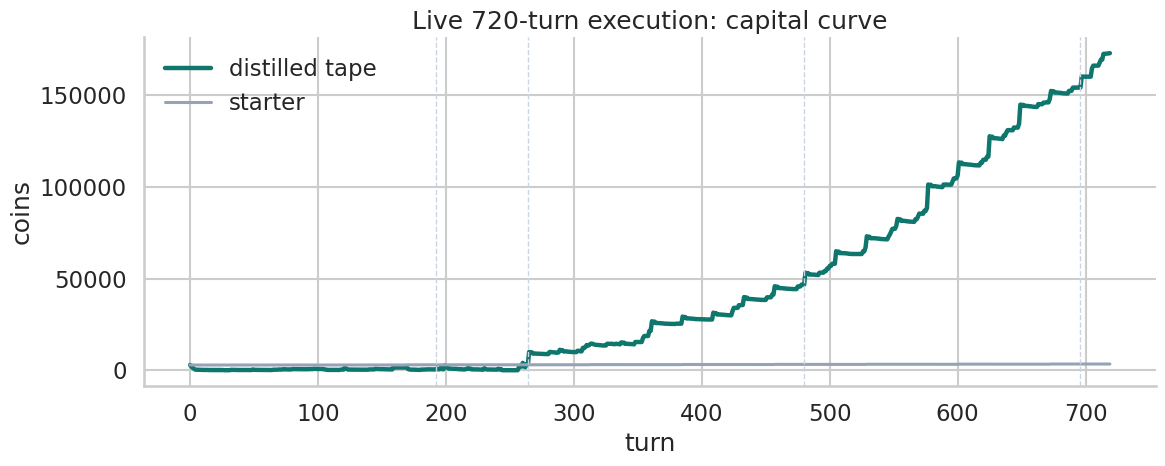

In [14]:
money_a = [float(step[0].observation.farms[0].money) for step in representative.steps]
money_b = [float(step[0].observation.farms[1].money) for step in representative.steps]
turns = np.arange(len(money_a))
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(turns, money_a, lw=3.2, color=COLORS[0], label="distilled tape")
ax.plot(turns, money_b, lw=2.2, color="#94a3b8", label="starter")
for day in (8, 11, 20, 29): ax.axvline(day*24, color="#cbd5e1", ls="--", lw=1)
ax.set(title="Live 720-turn execution: capital curve", xlabel="turn", ylabel="coins")
ax.legend(frameon=False); sns.despine(); plt.tight_layout(); plt.show()


## 6. Package integrity

The competition archive contains exactly one root file, `main.py`. Use this notebook version's **Submit to competition** button and choose `submission.tar.gz`.


In [15]:
ARCHIVE_PATH = MAIN_PATH.parent / "submission.tar.gz"
with tarfile.open(ARCHIVE_PATH, "w:gz") as archive:
    archive.add(MAIN_PATH, arcname="main.py")
with tarfile.open(ARCHIVE_PATH, "r:gz") as archive:
    assert archive.getnames() == ["main.py"]
print({"artifact": str(ARCHIVE_PATH), "bytes": ARCHIVE_PATH.stat().st_size,
       "sha256": hashlib.sha256(ARCHIVE_PATH.read_bytes()).hexdigest(), "members": ["main.py"]})


{'artifact': '/kaggle/working/submission.tar.gz', 'bytes': 159691, 'sha256': '70488b13af35d99cfb257496e272e9d42846ffb7eb219aadb768897e59c93970', 'members': ['main.py']}


## From one fixed tape to visible-state retrieval

The new agent is not told which replay it is reproducing. Every 24 turns it compares the live observation with all eight public same-turn states and locks the nearest trajectory for that interval. The self-replay audit below covers **5,760** observation/action pairs; it is a direct interface and reconstruction check, not a leaderboard estimate.


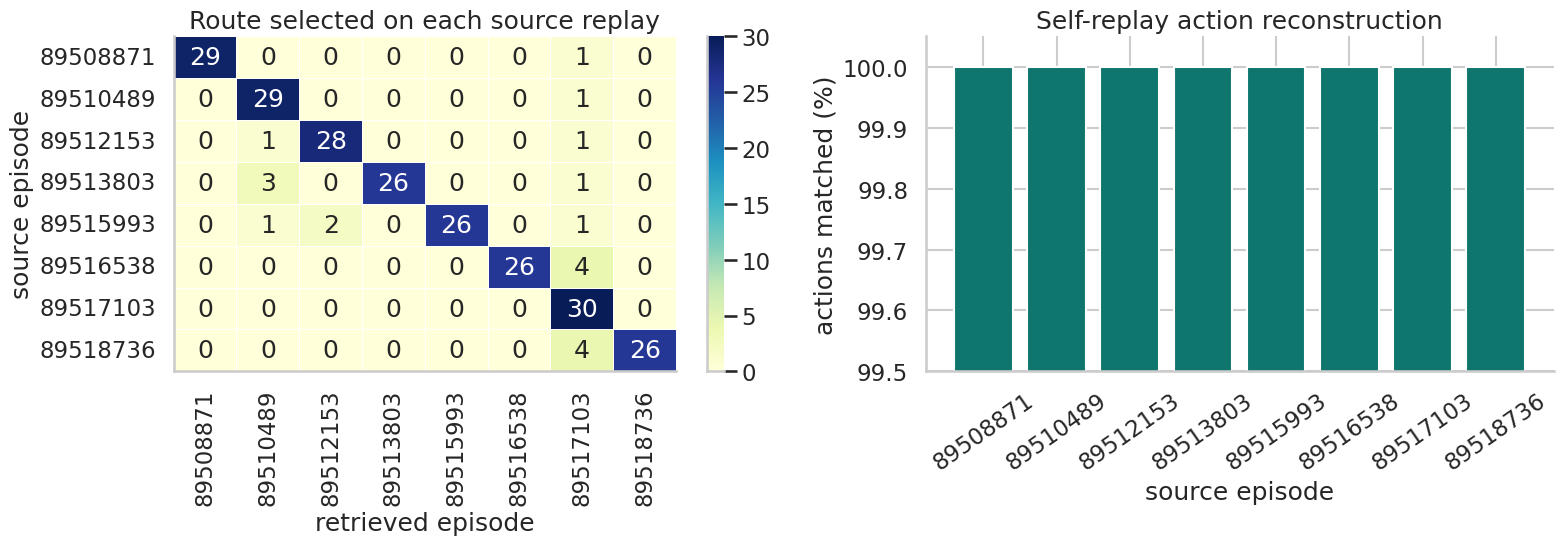

{'public_episodes': 8, 'observation_action_pairs': 5760, 'exact_action_matches': 5760, 'match_rate': 1.0, 'features': 54, 'routing_interval_turns': 24}


In [16]:
STATE_ROUTER_AUDIT_ROWS = [{'source_episode': 89508871, 'steps': 720, 'action_matches': 720, 'action_match_rate': 1.0}, {'source_episode': 89510489, 'steps': 720, 'action_matches': 720, 'action_match_rate': 1.0}, {'source_episode': 89512153, 'steps': 720, 'action_matches': 720, 'action_match_rate': 1.0}, {'source_episode': 89513803, 'steps': 720, 'action_matches': 720, 'action_match_rate': 1.0}, {'source_episode': 89515993, 'steps': 720, 'action_matches': 720, 'action_match_rate': 1.0}, {'source_episode': 89516538, 'steps': 720, 'action_matches': 720, 'action_match_rate': 1.0}, {'source_episode': 89517103, 'steps': 720, 'action_matches': 720, 'action_match_rate': 1.0}, {'source_episode': 89518736, 'steps': 720, 'action_matches': 720, 'action_match_rate': 1.0}]
STATE_ROUTER_STEP_ROWS = [{'source_episode': 89508871, 'step': 0, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89508871, 'step': 1, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89508871, 'step': 2, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89508871, 'step': 3, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89508871, 'step': 4, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89508871, 'step': 5, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89508871, 'step': 6, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89508871, 'step': 7, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89508871, 'step': 8, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89508871, 'step': 9, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89508871, 'step': 10, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89508871, 'step': 11, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89508871, 'step': 12, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89508871, 'step': 13, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89508871, 'step': 14, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89508871, 'step': 15, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89508871, 'step': 16, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89508871, 'step': 17, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89508871, 'step': 18, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89508871, 'step': 19, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89508871, 'step': 20, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89508871, 'step': 21, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89508871, 'step': 22, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89508871, 'step': 23, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89508871, 'step': 24, 'day': 1, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 25, 'day': 1, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 26, 'day': 1, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 27, 'day': 1, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 28, 'day': 1, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 29, 'day': 1, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 30, 'day': 1, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 31, 'day': 1, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 32, 'day': 1, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 33, 'day': 1, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 34, 'day': 1, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 35, 'day': 1, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 36, 'day': 1, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 37, 'day': 1, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 38, 'day': 1, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 39, 'day': 1, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 40, 'day': 1, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 41, 'day': 1, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 42, 'day': 1, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 43, 'day': 1, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 44, 'day': 1, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 45, 'day': 1, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 46, 'day': 1, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 47, 'day': 1, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 48, 'day': 2, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 49, 'day': 2, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 50, 'day': 2, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 51, 'day': 2, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 52, 'day': 2, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 53, 'day': 2, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 54, 'day': 2, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 55, 'day': 2, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 56, 'day': 2, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 57, 'day': 2, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 58, 'day': 2, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 59, 'day': 2, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 60, 'day': 2, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 61, 'day': 2, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 62, 'day': 2, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 63, 'day': 2, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 64, 'day': 2, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 65, 'day': 2, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 66, 'day': 2, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 67, 'day': 2, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 68, 'day': 2, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 69, 'day': 2, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 70, 'day': 2, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 71, 'day': 2, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 72, 'day': 3, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 73, 'day': 3, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 74, 'day': 3, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 75, 'day': 3, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 76, 'day': 3, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 77, 'day': 3, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 78, 'day': 3, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 79, 'day': 3, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 80, 'day': 3, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 81, 'day': 3, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 82, 'day': 3, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 83, 'day': 3, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 84, 'day': 3, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 85, 'day': 3, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 86, 'day': 3, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 87, 'day': 3, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 88, 'day': 3, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 89, 'day': 3, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 90, 'day': 3, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 91, 'day': 3, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 92, 'day': 3, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 93, 'day': 3, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 94, 'day': 3, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 95, 'day': 3, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 96, 'day': 4, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 97, 'day': 4, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 98, 'day': 4, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 99, 'day': 4, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 100, 'day': 4, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 101, 'day': 4, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 102, 'day': 4, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 103, 'day': 4, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 104, 'day': 4, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 105, 'day': 4, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 106, 'day': 4, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 107, 'day': 4, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 108, 'day': 4, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 109, 'day': 4, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 110, 'day': 4, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 111, 'day': 4, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 112, 'day': 4, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 113, 'day': 4, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 114, 'day': 4, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 115, 'day': 4, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 116, 'day': 4, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 117, 'day': 4, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 118, 'day': 4, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 119, 'day': 4, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 120, 'day': 5, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 121, 'day': 5, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 122, 'day': 5, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 123, 'day': 5, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 124, 'day': 5, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 125, 'day': 5, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 126, 'day': 5, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 127, 'day': 5, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 128, 'day': 5, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 129, 'day': 5, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 130, 'day': 5, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 131, 'day': 5, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 132, 'day': 5, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 133, 'day': 5, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 134, 'day': 5, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 135, 'day': 5, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 136, 'day': 5, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 137, 'day': 5, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 138, 'day': 5, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 139, 'day': 5, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 140, 'day': 5, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 141, 'day': 5, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 142, 'day': 5, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 143, 'day': 5, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 144, 'day': 6, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 145, 'day': 6, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 146, 'day': 6, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 147, 'day': 6, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 148, 'day': 6, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 149, 'day': 6, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 150, 'day': 6, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 151, 'day': 6, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 152, 'day': 6, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 153, 'day': 6, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 154, 'day': 6, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 155, 'day': 6, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 156, 'day': 6, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 157, 'day': 6, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 158, 'day': 6, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 159, 'day': 6, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 160, 'day': 6, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 161, 'day': 6, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 162, 'day': 6, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 163, 'day': 6, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 164, 'day': 6, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 165, 'day': 6, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 166, 'day': 6, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 167, 'day': 6, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 168, 'day': 7, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 169, 'day': 7, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 170, 'day': 7, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 171, 'day': 7, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 172, 'day': 7, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 173, 'day': 7, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 174, 'day': 7, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 175, 'day': 7, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 176, 'day': 7, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 177, 'day': 7, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 178, 'day': 7, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 179, 'day': 7, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 180, 'day': 7, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 181, 'day': 7, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 182, 'day': 7, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 183, 'day': 7, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 184, 'day': 7, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 185, 'day': 7, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 186, 'day': 7, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 187, 'day': 7, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 188, 'day': 7, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 189, 'day': 7, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 190, 'day': 7, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 191, 'day': 7, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 192, 'day': 8, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 193, 'day': 8, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 194, 'day': 8, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 195, 'day': 8, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 196, 'day': 8, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 197, 'day': 8, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 198, 'day': 8, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 199, 'day': 8, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 200, 'day': 8, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 201, 'day': 8, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 202, 'day': 8, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 203, 'day': 8, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 204, 'day': 8, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 205, 'day': 8, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 206, 'day': 8, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 207, 'day': 8, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 208, 'day': 8, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 209, 'day': 8, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 210, 'day': 8, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 211, 'day': 8, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 212, 'day': 8, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 213, 'day': 8, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 214, 'day': 8, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 215, 'day': 8, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 216, 'day': 9, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 217, 'day': 9, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 218, 'day': 9, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 219, 'day': 9, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 220, 'day': 9, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 221, 'day': 9, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 222, 'day': 9, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 223, 'day': 9, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 224, 'day': 9, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 225, 'day': 9, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 226, 'day': 9, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 227, 'day': 9, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 228, 'day': 9, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 229, 'day': 9, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 230, 'day': 9, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 231, 'day': 9, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 232, 'day': 9, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 233, 'day': 9, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 234, 'day': 9, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 235, 'day': 9, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 236, 'day': 9, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 237, 'day': 9, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 238, 'day': 9, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 239, 'day': 9, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 240, 'day': 10, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 241, 'day': 10, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 242, 'day': 10, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 243, 'day': 10, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 244, 'day': 10, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 245, 'day': 10, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 246, 'day': 10, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 247, 'day': 10, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 248, 'day': 10, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 249, 'day': 10, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 250, 'day': 10, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 251, 'day': 10, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 252, 'day': 10, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 253, 'day': 10, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 254, 'day': 10, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 255, 'day': 10, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 256, 'day': 10, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 257, 'day': 10, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 258, 'day': 10, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 259, 'day': 10, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 260, 'day': 10, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 261, 'day': 10, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 262, 'day': 10, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 263, 'day': 10, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 264, 'day': 11, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 265, 'day': 11, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 266, 'day': 11, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 267, 'day': 11, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 268, 'day': 11, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 269, 'day': 11, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 270, 'day': 11, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 271, 'day': 11, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 272, 'day': 11, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 273, 'day': 11, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 274, 'day': 11, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 275, 'day': 11, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 276, 'day': 11, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 277, 'day': 11, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 278, 'day': 11, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 279, 'day': 11, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 280, 'day': 11, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 281, 'day': 11, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 282, 'day': 11, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 283, 'day': 11, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 284, 'day': 11, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 285, 'day': 11, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 286, 'day': 11, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 287, 'day': 11, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 288, 'day': 12, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 289, 'day': 12, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 290, 'day': 12, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 291, 'day': 12, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 292, 'day': 12, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 293, 'day': 12, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 294, 'day': 12, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 295, 'day': 12, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 296, 'day': 12, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 297, 'day': 12, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 298, 'day': 12, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 299, 'day': 12, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 300, 'day': 12, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 301, 'day': 12, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 302, 'day': 12, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 303, 'day': 12, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 304, 'day': 12, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 305, 'day': 12, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 306, 'day': 12, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 307, 'day': 12, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 308, 'day': 12, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 309, 'day': 12, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 310, 'day': 12, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 311, 'day': 12, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 312, 'day': 13, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 313, 'day': 13, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 314, 'day': 13, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 315, 'day': 13, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 316, 'day': 13, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 317, 'day': 13, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 318, 'day': 13, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 319, 'day': 13, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 320, 'day': 13, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 321, 'day': 13, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 322, 'day': 13, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 323, 'day': 13, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 324, 'day': 13, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 325, 'day': 13, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 326, 'day': 13, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 327, 'day': 13, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 328, 'day': 13, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 329, 'day': 13, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 330, 'day': 13, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 331, 'day': 13, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 332, 'day': 13, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 333, 'day': 13, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 334, 'day': 13, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 335, 'day': 13, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 336, 'day': 14, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 337, 'day': 14, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 338, 'day': 14, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 339, 'day': 14, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 340, 'day': 14, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 341, 'day': 14, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 342, 'day': 14, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 343, 'day': 14, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 344, 'day': 14, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 345, 'day': 14, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 346, 'day': 14, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 347, 'day': 14, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 348, 'day': 14, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 349, 'day': 14, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 350, 'day': 14, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 351, 'day': 14, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 352, 'day': 14, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 353, 'day': 14, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 354, 'day': 14, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 355, 'day': 14, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 356, 'day': 14, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 357, 'day': 14, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 358, 'day': 14, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 359, 'day': 14, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 360, 'day': 15, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 361, 'day': 15, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 362, 'day': 15, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 363, 'day': 15, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 364, 'day': 15, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 365, 'day': 15, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 366, 'day': 15, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 367, 'day': 15, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 368, 'day': 15, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 369, 'day': 15, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 370, 'day': 15, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 371, 'day': 15, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 372, 'day': 15, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 373, 'day': 15, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 374, 'day': 15, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 375, 'day': 15, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 376, 'day': 15, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 377, 'day': 15, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 378, 'day': 15, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 379, 'day': 15, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 380, 'day': 15, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 381, 'day': 15, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 382, 'day': 15, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 383, 'day': 15, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 384, 'day': 16, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 385, 'day': 16, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 386, 'day': 16, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 387, 'day': 16, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 388, 'day': 16, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 389, 'day': 16, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 390, 'day': 16, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 391, 'day': 16, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 392, 'day': 16, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 393, 'day': 16, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 394, 'day': 16, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 395, 'day': 16, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 396, 'day': 16, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 397, 'day': 16, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 398, 'day': 16, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 399, 'day': 16, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 400, 'day': 16, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 401, 'day': 16, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 402, 'day': 16, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 403, 'day': 16, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 404, 'day': 16, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 405, 'day': 16, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 406, 'day': 16, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 407, 'day': 16, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 408, 'day': 17, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 409, 'day': 17, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 410, 'day': 17, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 411, 'day': 17, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 412, 'day': 17, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 413, 'day': 17, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 414, 'day': 17, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 415, 'day': 17, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 416, 'day': 17, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 417, 'day': 17, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 418, 'day': 17, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 419, 'day': 17, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 420, 'day': 17, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 421, 'day': 17, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 422, 'day': 17, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 423, 'day': 17, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 424, 'day': 17, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 425, 'day': 17, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 426, 'day': 17, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 427, 'day': 17, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 428, 'day': 17, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 429, 'day': 17, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 430, 'day': 17, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 431, 'day': 17, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 432, 'day': 18, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 433, 'day': 18, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 434, 'day': 18, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 435, 'day': 18, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 436, 'day': 18, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 437, 'day': 18, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 438, 'day': 18, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 439, 'day': 18, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 440, 'day': 18, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 441, 'day': 18, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 442, 'day': 18, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 443, 'day': 18, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 444, 'day': 18, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 445, 'day': 18, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 446, 'day': 18, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 447, 'day': 18, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 448, 'day': 18, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 449, 'day': 18, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 450, 'day': 18, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 451, 'day': 18, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 452, 'day': 18, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 453, 'day': 18, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 454, 'day': 18, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 455, 'day': 18, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 456, 'day': 19, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 457, 'day': 19, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 458, 'day': 19, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 459, 'day': 19, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 460, 'day': 19, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 461, 'day': 19, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 462, 'day': 19, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 463, 'day': 19, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 464, 'day': 19, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 465, 'day': 19, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 466, 'day': 19, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 467, 'day': 19, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 468, 'day': 19, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 469, 'day': 19, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 470, 'day': 19, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 471, 'day': 19, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 472, 'day': 19, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 473, 'day': 19, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 474, 'day': 19, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 475, 'day': 19, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 476, 'day': 19, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 477, 'day': 19, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 478, 'day': 19, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 479, 'day': 19, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 480, 'day': 20, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 481, 'day': 20, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 482, 'day': 20, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 483, 'day': 20, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 484, 'day': 20, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 485, 'day': 20, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 486, 'day': 20, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 487, 'day': 20, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 488, 'day': 20, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 489, 'day': 20, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 490, 'day': 20, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 491, 'day': 20, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 492, 'day': 20, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 493, 'day': 20, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 494, 'day': 20, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 495, 'day': 20, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 496, 'day': 20, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 497, 'day': 20, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 498, 'day': 20, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 499, 'day': 20, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 500, 'day': 20, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 501, 'day': 20, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 502, 'day': 20, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 503, 'day': 20, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 504, 'day': 21, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 505, 'day': 21, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 506, 'day': 21, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 507, 'day': 21, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 508, 'day': 21, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 509, 'day': 21, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 510, 'day': 21, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 511, 'day': 21, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 512, 'day': 21, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 513, 'day': 21, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 514, 'day': 21, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 515, 'day': 21, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 516, 'day': 21, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 517, 'day': 21, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 518, 'day': 21, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 519, 'day': 21, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 520, 'day': 21, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 521, 'day': 21, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 522, 'day': 21, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 523, 'day': 21, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 524, 'day': 21, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 525, 'day': 21, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 526, 'day': 21, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 527, 'day': 21, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 528, 'day': 22, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 529, 'day': 22, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 530, 'day': 22, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 531, 'day': 22, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 532, 'day': 22, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 533, 'day': 22, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 534, 'day': 22, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 535, 'day': 22, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 536, 'day': 22, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 537, 'day': 22, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 538, 'day': 22, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 539, 'day': 22, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 540, 'day': 22, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 541, 'day': 22, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 542, 'day': 22, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 543, 'day': 22, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 544, 'day': 22, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 545, 'day': 22, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 546, 'day': 22, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 547, 'day': 22, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 548, 'day': 22, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 549, 'day': 22, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 550, 'day': 22, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 551, 'day': 22, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 552, 'day': 23, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 553, 'day': 23, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 554, 'day': 23, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 555, 'day': 23, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 556, 'day': 23, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 557, 'day': 23, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 558, 'day': 23, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 559, 'day': 23, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 560, 'day': 23, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 561, 'day': 23, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 562, 'day': 23, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 563, 'day': 23, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 564, 'day': 23, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 565, 'day': 23, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 566, 'day': 23, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 567, 'day': 23, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 568, 'day': 23, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 569, 'day': 23, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 570, 'day': 23, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 571, 'day': 23, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 572, 'day': 23, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 573, 'day': 23, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 574, 'day': 23, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 575, 'day': 23, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 576, 'day': 24, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 577, 'day': 24, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 578, 'day': 24, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 579, 'day': 24, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 580, 'day': 24, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 581, 'day': 24, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 582, 'day': 24, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 583, 'day': 24, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 584, 'day': 24, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 585, 'day': 24, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 586, 'day': 24, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 587, 'day': 24, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 588, 'day': 24, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 589, 'day': 24, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 590, 'day': 24, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 591, 'day': 24, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 592, 'day': 24, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 593, 'day': 24, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 594, 'day': 24, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 595, 'day': 24, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 596, 'day': 24, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 597, 'day': 24, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 598, 'day': 24, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 599, 'day': 24, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 600, 'day': 25, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 601, 'day': 25, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 602, 'day': 25, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 603, 'day': 25, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 604, 'day': 25, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 605, 'day': 25, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 606, 'day': 25, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 607, 'day': 25, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 608, 'day': 25, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 609, 'day': 25, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 610, 'day': 25, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 611, 'day': 25, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 612, 'day': 25, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 613, 'day': 25, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 614, 'day': 25, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 615, 'day': 25, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 616, 'day': 25, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 617, 'day': 25, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 618, 'day': 25, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 619, 'day': 25, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 620, 'day': 25, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 621, 'day': 25, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 622, 'day': 25, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 623, 'day': 25, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 624, 'day': 26, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 625, 'day': 26, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 626, 'day': 26, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 627, 'day': 26, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 628, 'day': 26, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 629, 'day': 26, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 630, 'day': 26, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 631, 'day': 26, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 632, 'day': 26, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 633, 'day': 26, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 634, 'day': 26, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 635, 'day': 26, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 636, 'day': 26, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 637, 'day': 26, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 638, 'day': 26, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 639, 'day': 26, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 640, 'day': 26, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 641, 'day': 26, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 642, 'day': 26, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 643, 'day': 26, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 644, 'day': 26, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 645, 'day': 26, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 646, 'day': 26, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 647, 'day': 26, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 648, 'day': 27, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 649, 'day': 27, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 650, 'day': 27, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 651, 'day': 27, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 652, 'day': 27, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 653, 'day': 27, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 654, 'day': 27, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 655, 'day': 27, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 656, 'day': 27, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 657, 'day': 27, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 658, 'day': 27, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 659, 'day': 27, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 660, 'day': 27, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 661, 'day': 27, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 662, 'day': 27, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 663, 'day': 27, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 664, 'day': 27, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 665, 'day': 27, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 666, 'day': 27, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 667, 'day': 27, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 668, 'day': 27, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 669, 'day': 27, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 670, 'day': 27, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 671, 'day': 27, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 672, 'day': 28, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 673, 'day': 28, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 674, 'day': 28, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 675, 'day': 28, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 676, 'day': 28, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 677, 'day': 28, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 678, 'day': 28, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 679, 'day': 28, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 680, 'day': 28, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 681, 'day': 28, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 682, 'day': 28, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 683, 'day': 28, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 684, 'day': 28, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 685, 'day': 28, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 686, 'day': 28, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 687, 'day': 28, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 688, 'day': 28, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 689, 'day': 28, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 690, 'day': 28, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 691, 'day': 28, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 692, 'day': 28, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 693, 'day': 28, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 694, 'day': 28, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 695, 'day': 28, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 696, 'day': 29, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 697, 'day': 29, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 698, 'day': 29, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 699, 'day': 29, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 700, 'day': 29, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 701, 'day': 29, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 702, 'day': 29, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 703, 'day': 29, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 704, 'day': 29, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 705, 'day': 29, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 706, 'day': 29, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 707, 'day': 29, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 708, 'day': 29, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 709, 'day': 29, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 710, 'day': 29, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 711, 'day': 29, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 712, 'day': 29, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 713, 'day': 29, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 714, 'day': 29, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 715, 'day': 29, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 716, 'day': 29, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 717, 'day': 29, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 718, 'day': 29, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89508871, 'step': 719, 'day': 29, 'route_episode': 89508871, 'action_match': True}, {'source_episode': 89510489, 'step': 0, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89510489, 'step': 1, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89510489, 'step': 2, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89510489, 'step': 3, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89510489, 'step': 4, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89510489, 'step': 5, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89510489, 'step': 6, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89510489, 'step': 7, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89510489, 'step': 8, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89510489, 'step': 9, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89510489, 'step': 10, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89510489, 'step': 11, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89510489, 'step': 12, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89510489, 'step': 13, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89510489, 'step': 14, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89510489, 'step': 15, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89510489, 'step': 16, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89510489, 'step': 17, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89510489, 'step': 18, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89510489, 'step': 19, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89510489, 'step': 20, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89510489, 'step': 21, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89510489, 'step': 22, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89510489, 'step': 23, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89510489, 'step': 24, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 25, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 26, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 27, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 28, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 29, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 30, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 31, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 32, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 33, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 34, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 35, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 36, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 37, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 38, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 39, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 40, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 41, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 42, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 43, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 44, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 45, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 46, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 47, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 48, 'day': 2, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 49, 'day': 2, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 50, 'day': 2, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 51, 'day': 2, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 52, 'day': 2, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 53, 'day': 2, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 54, 'day': 2, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 55, 'day': 2, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 56, 'day': 2, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 57, 'day': 2, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 58, 'day': 2, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 59, 'day': 2, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 60, 'day': 2, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 61, 'day': 2, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 62, 'day': 2, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 63, 'day': 2, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 64, 'day': 2, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 65, 'day': 2, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 66, 'day': 2, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 67, 'day': 2, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 68, 'day': 2, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 69, 'day': 2, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 70, 'day': 2, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 71, 'day': 2, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 72, 'day': 3, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 73, 'day': 3, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 74, 'day': 3, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 75, 'day': 3, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 76, 'day': 3, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 77, 'day': 3, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 78, 'day': 3, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 79, 'day': 3, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 80, 'day': 3, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 81, 'day': 3, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 82, 'day': 3, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 83, 'day': 3, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 84, 'day': 3, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 85, 'day': 3, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 86, 'day': 3, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 87, 'day': 3, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 88, 'day': 3, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 89, 'day': 3, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 90, 'day': 3, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 91, 'day': 3, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 92, 'day': 3, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 93, 'day': 3, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 94, 'day': 3, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 95, 'day': 3, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 96, 'day': 4, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 97, 'day': 4, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 98, 'day': 4, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 99, 'day': 4, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 100, 'day': 4, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 101, 'day': 4, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 102, 'day': 4, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 103, 'day': 4, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 104, 'day': 4, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 105, 'day': 4, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 106, 'day': 4, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 107, 'day': 4, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 108, 'day': 4, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 109, 'day': 4, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 110, 'day': 4, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 111, 'day': 4, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 112, 'day': 4, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 113, 'day': 4, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 114, 'day': 4, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 115, 'day': 4, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 116, 'day': 4, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 117, 'day': 4, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 118, 'day': 4, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 119, 'day': 4, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 120, 'day': 5, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 121, 'day': 5, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 122, 'day': 5, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 123, 'day': 5, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 124, 'day': 5, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 125, 'day': 5, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 126, 'day': 5, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 127, 'day': 5, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 128, 'day': 5, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 129, 'day': 5, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 130, 'day': 5, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 131, 'day': 5, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 132, 'day': 5, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 133, 'day': 5, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 134, 'day': 5, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 135, 'day': 5, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 136, 'day': 5, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 137, 'day': 5, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 138, 'day': 5, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 139, 'day': 5, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 140, 'day': 5, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 141, 'day': 5, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 142, 'day': 5, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 143, 'day': 5, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 144, 'day': 6, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 145, 'day': 6, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 146, 'day': 6, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 147, 'day': 6, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 148, 'day': 6, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 149, 'day': 6, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 150, 'day': 6, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 151, 'day': 6, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 152, 'day': 6, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 153, 'day': 6, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 154, 'day': 6, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 155, 'day': 6, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 156, 'day': 6, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 157, 'day': 6, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 158, 'day': 6, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 159, 'day': 6, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 160, 'day': 6, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 161, 'day': 6, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 162, 'day': 6, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 163, 'day': 6, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 164, 'day': 6, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 165, 'day': 6, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 166, 'day': 6, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 167, 'day': 6, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 168, 'day': 7, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 169, 'day': 7, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 170, 'day': 7, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 171, 'day': 7, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 172, 'day': 7, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 173, 'day': 7, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 174, 'day': 7, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 175, 'day': 7, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 176, 'day': 7, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 177, 'day': 7, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 178, 'day': 7, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 179, 'day': 7, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 180, 'day': 7, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 181, 'day': 7, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 182, 'day': 7, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 183, 'day': 7, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 184, 'day': 7, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 185, 'day': 7, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 186, 'day': 7, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 187, 'day': 7, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 188, 'day': 7, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 189, 'day': 7, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 190, 'day': 7, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 191, 'day': 7, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 192, 'day': 8, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 193, 'day': 8, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 194, 'day': 8, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 195, 'day': 8, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 196, 'day': 8, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 197, 'day': 8, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 198, 'day': 8, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 199, 'day': 8, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 200, 'day': 8, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 201, 'day': 8, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 202, 'day': 8, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 203, 'day': 8, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 204, 'day': 8, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 205, 'day': 8, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 206, 'day': 8, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 207, 'day': 8, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 208, 'day': 8, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 209, 'day': 8, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 210, 'day': 8, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 211, 'day': 8, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 212, 'day': 8, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 213, 'day': 8, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 214, 'day': 8, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 215, 'day': 8, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 216, 'day': 9, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 217, 'day': 9, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 218, 'day': 9, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 219, 'day': 9, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 220, 'day': 9, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 221, 'day': 9, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 222, 'day': 9, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 223, 'day': 9, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 224, 'day': 9, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 225, 'day': 9, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 226, 'day': 9, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 227, 'day': 9, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 228, 'day': 9, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 229, 'day': 9, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 230, 'day': 9, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 231, 'day': 9, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 232, 'day': 9, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 233, 'day': 9, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 234, 'day': 9, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 235, 'day': 9, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 236, 'day': 9, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 237, 'day': 9, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 238, 'day': 9, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 239, 'day': 9, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 240, 'day': 10, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 241, 'day': 10, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 242, 'day': 10, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 243, 'day': 10, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 244, 'day': 10, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 245, 'day': 10, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 246, 'day': 10, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 247, 'day': 10, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 248, 'day': 10, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 249, 'day': 10, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 250, 'day': 10, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 251, 'day': 10, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 252, 'day': 10, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 253, 'day': 10, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 254, 'day': 10, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 255, 'day': 10, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 256, 'day': 10, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 257, 'day': 10, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 258, 'day': 10, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 259, 'day': 10, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 260, 'day': 10, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 261, 'day': 10, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 262, 'day': 10, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 263, 'day': 10, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 264, 'day': 11, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 265, 'day': 11, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 266, 'day': 11, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 267, 'day': 11, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 268, 'day': 11, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 269, 'day': 11, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 270, 'day': 11, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 271, 'day': 11, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 272, 'day': 11, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 273, 'day': 11, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 274, 'day': 11, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 275, 'day': 11, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 276, 'day': 11, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 277, 'day': 11, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 278, 'day': 11, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 279, 'day': 11, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 280, 'day': 11, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 281, 'day': 11, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 282, 'day': 11, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 283, 'day': 11, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 284, 'day': 11, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 285, 'day': 11, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 286, 'day': 11, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 287, 'day': 11, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 288, 'day': 12, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 289, 'day': 12, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 290, 'day': 12, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 291, 'day': 12, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 292, 'day': 12, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 293, 'day': 12, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 294, 'day': 12, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 295, 'day': 12, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 296, 'day': 12, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 297, 'day': 12, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 298, 'day': 12, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 299, 'day': 12, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 300, 'day': 12, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 301, 'day': 12, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 302, 'day': 12, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 303, 'day': 12, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 304, 'day': 12, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 305, 'day': 12, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 306, 'day': 12, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 307, 'day': 12, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 308, 'day': 12, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 309, 'day': 12, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 310, 'day': 12, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 311, 'day': 12, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 312, 'day': 13, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 313, 'day': 13, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 314, 'day': 13, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 315, 'day': 13, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 316, 'day': 13, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 317, 'day': 13, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 318, 'day': 13, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 319, 'day': 13, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 320, 'day': 13, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 321, 'day': 13, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 322, 'day': 13, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 323, 'day': 13, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 324, 'day': 13, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 325, 'day': 13, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 326, 'day': 13, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 327, 'day': 13, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 328, 'day': 13, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 329, 'day': 13, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 330, 'day': 13, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 331, 'day': 13, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 332, 'day': 13, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 333, 'day': 13, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 334, 'day': 13, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 335, 'day': 13, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 336, 'day': 14, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 337, 'day': 14, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 338, 'day': 14, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 339, 'day': 14, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 340, 'day': 14, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 341, 'day': 14, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 342, 'day': 14, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 343, 'day': 14, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 344, 'day': 14, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 345, 'day': 14, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 346, 'day': 14, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 347, 'day': 14, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 348, 'day': 14, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 349, 'day': 14, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 350, 'day': 14, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 351, 'day': 14, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 352, 'day': 14, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 353, 'day': 14, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 354, 'day': 14, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 355, 'day': 14, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 356, 'day': 14, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 357, 'day': 14, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 358, 'day': 14, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 359, 'day': 14, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 360, 'day': 15, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 361, 'day': 15, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 362, 'day': 15, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 363, 'day': 15, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 364, 'day': 15, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 365, 'day': 15, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 366, 'day': 15, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 367, 'day': 15, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 368, 'day': 15, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 369, 'day': 15, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 370, 'day': 15, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 371, 'day': 15, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 372, 'day': 15, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 373, 'day': 15, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 374, 'day': 15, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 375, 'day': 15, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 376, 'day': 15, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 377, 'day': 15, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 378, 'day': 15, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 379, 'day': 15, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 380, 'day': 15, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 381, 'day': 15, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 382, 'day': 15, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 383, 'day': 15, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 384, 'day': 16, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 385, 'day': 16, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 386, 'day': 16, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 387, 'day': 16, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 388, 'day': 16, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 389, 'day': 16, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 390, 'day': 16, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 391, 'day': 16, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 392, 'day': 16, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 393, 'day': 16, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 394, 'day': 16, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 395, 'day': 16, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 396, 'day': 16, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 397, 'day': 16, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 398, 'day': 16, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 399, 'day': 16, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 400, 'day': 16, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 401, 'day': 16, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 402, 'day': 16, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 403, 'day': 16, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 404, 'day': 16, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 405, 'day': 16, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 406, 'day': 16, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 407, 'day': 16, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 408, 'day': 17, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 409, 'day': 17, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 410, 'day': 17, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 411, 'day': 17, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 412, 'day': 17, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 413, 'day': 17, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 414, 'day': 17, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 415, 'day': 17, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 416, 'day': 17, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 417, 'day': 17, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 418, 'day': 17, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 419, 'day': 17, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 420, 'day': 17, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 421, 'day': 17, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 422, 'day': 17, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 423, 'day': 17, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 424, 'day': 17, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 425, 'day': 17, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 426, 'day': 17, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 427, 'day': 17, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 428, 'day': 17, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 429, 'day': 17, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 430, 'day': 17, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 431, 'day': 17, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 432, 'day': 18, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 433, 'day': 18, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 434, 'day': 18, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 435, 'day': 18, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 436, 'day': 18, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 437, 'day': 18, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 438, 'day': 18, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 439, 'day': 18, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 440, 'day': 18, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 441, 'day': 18, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 442, 'day': 18, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 443, 'day': 18, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 444, 'day': 18, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 445, 'day': 18, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 446, 'day': 18, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 447, 'day': 18, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 448, 'day': 18, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 449, 'day': 18, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 450, 'day': 18, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 451, 'day': 18, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 452, 'day': 18, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 453, 'day': 18, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 454, 'day': 18, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 455, 'day': 18, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 456, 'day': 19, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 457, 'day': 19, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 458, 'day': 19, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 459, 'day': 19, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 460, 'day': 19, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 461, 'day': 19, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 462, 'day': 19, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 463, 'day': 19, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 464, 'day': 19, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 465, 'day': 19, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 466, 'day': 19, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 467, 'day': 19, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 468, 'day': 19, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 469, 'day': 19, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 470, 'day': 19, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 471, 'day': 19, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 472, 'day': 19, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 473, 'day': 19, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 474, 'day': 19, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 475, 'day': 19, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 476, 'day': 19, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 477, 'day': 19, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 478, 'day': 19, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 479, 'day': 19, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 480, 'day': 20, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 481, 'day': 20, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 482, 'day': 20, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 483, 'day': 20, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 484, 'day': 20, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 485, 'day': 20, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 486, 'day': 20, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 487, 'day': 20, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 488, 'day': 20, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 489, 'day': 20, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 490, 'day': 20, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 491, 'day': 20, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 492, 'day': 20, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 493, 'day': 20, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 494, 'day': 20, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 495, 'day': 20, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 496, 'day': 20, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 497, 'day': 20, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 498, 'day': 20, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 499, 'day': 20, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 500, 'day': 20, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 501, 'day': 20, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 502, 'day': 20, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 503, 'day': 20, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 504, 'day': 21, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 505, 'day': 21, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 506, 'day': 21, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 507, 'day': 21, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 508, 'day': 21, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 509, 'day': 21, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 510, 'day': 21, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 511, 'day': 21, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 512, 'day': 21, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 513, 'day': 21, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 514, 'day': 21, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 515, 'day': 21, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 516, 'day': 21, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 517, 'day': 21, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 518, 'day': 21, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 519, 'day': 21, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 520, 'day': 21, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 521, 'day': 21, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 522, 'day': 21, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 523, 'day': 21, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 524, 'day': 21, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 525, 'day': 21, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 526, 'day': 21, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 527, 'day': 21, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 528, 'day': 22, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 529, 'day': 22, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 530, 'day': 22, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 531, 'day': 22, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 532, 'day': 22, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 533, 'day': 22, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 534, 'day': 22, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 535, 'day': 22, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 536, 'day': 22, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 537, 'day': 22, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 538, 'day': 22, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 539, 'day': 22, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 540, 'day': 22, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 541, 'day': 22, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 542, 'day': 22, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 543, 'day': 22, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 544, 'day': 22, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 545, 'day': 22, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 546, 'day': 22, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 547, 'day': 22, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 548, 'day': 22, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 549, 'day': 22, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 550, 'day': 22, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 551, 'day': 22, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 552, 'day': 23, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 553, 'day': 23, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 554, 'day': 23, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 555, 'day': 23, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 556, 'day': 23, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 557, 'day': 23, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 558, 'day': 23, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 559, 'day': 23, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 560, 'day': 23, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 561, 'day': 23, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 562, 'day': 23, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 563, 'day': 23, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 564, 'day': 23, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 565, 'day': 23, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 566, 'day': 23, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 567, 'day': 23, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 568, 'day': 23, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 569, 'day': 23, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 570, 'day': 23, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 571, 'day': 23, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 572, 'day': 23, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 573, 'day': 23, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 574, 'day': 23, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 575, 'day': 23, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 576, 'day': 24, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 577, 'day': 24, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 578, 'day': 24, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 579, 'day': 24, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 580, 'day': 24, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 581, 'day': 24, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 582, 'day': 24, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 583, 'day': 24, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 584, 'day': 24, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 585, 'day': 24, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 586, 'day': 24, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 587, 'day': 24, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 588, 'day': 24, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 589, 'day': 24, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 590, 'day': 24, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 591, 'day': 24, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 592, 'day': 24, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 593, 'day': 24, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 594, 'day': 24, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 595, 'day': 24, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 596, 'day': 24, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 597, 'day': 24, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 598, 'day': 24, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 599, 'day': 24, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 600, 'day': 25, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 601, 'day': 25, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 602, 'day': 25, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 603, 'day': 25, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 604, 'day': 25, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 605, 'day': 25, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 606, 'day': 25, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 607, 'day': 25, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 608, 'day': 25, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 609, 'day': 25, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 610, 'day': 25, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 611, 'day': 25, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 612, 'day': 25, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 613, 'day': 25, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 614, 'day': 25, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 615, 'day': 25, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 616, 'day': 25, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 617, 'day': 25, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 618, 'day': 25, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 619, 'day': 25, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 620, 'day': 25, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 621, 'day': 25, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 622, 'day': 25, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 623, 'day': 25, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 624, 'day': 26, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 625, 'day': 26, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 626, 'day': 26, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 627, 'day': 26, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 628, 'day': 26, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 629, 'day': 26, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 630, 'day': 26, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 631, 'day': 26, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 632, 'day': 26, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 633, 'day': 26, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 634, 'day': 26, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 635, 'day': 26, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 636, 'day': 26, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 637, 'day': 26, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 638, 'day': 26, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 639, 'day': 26, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 640, 'day': 26, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 641, 'day': 26, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 642, 'day': 26, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 643, 'day': 26, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 644, 'day': 26, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 645, 'day': 26, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 646, 'day': 26, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 647, 'day': 26, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 648, 'day': 27, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 649, 'day': 27, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 650, 'day': 27, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 651, 'day': 27, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 652, 'day': 27, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 653, 'day': 27, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 654, 'day': 27, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 655, 'day': 27, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 656, 'day': 27, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 657, 'day': 27, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 658, 'day': 27, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 659, 'day': 27, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 660, 'day': 27, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 661, 'day': 27, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 662, 'day': 27, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 663, 'day': 27, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 664, 'day': 27, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 665, 'day': 27, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 666, 'day': 27, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 667, 'day': 27, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 668, 'day': 27, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 669, 'day': 27, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 670, 'day': 27, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 671, 'day': 27, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 672, 'day': 28, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 673, 'day': 28, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 674, 'day': 28, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 675, 'day': 28, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 676, 'day': 28, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 677, 'day': 28, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 678, 'day': 28, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 679, 'day': 28, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 680, 'day': 28, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 681, 'day': 28, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 682, 'day': 28, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 683, 'day': 28, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 684, 'day': 28, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 685, 'day': 28, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 686, 'day': 28, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 687, 'day': 28, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 688, 'day': 28, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 689, 'day': 28, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 690, 'day': 28, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 691, 'day': 28, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 692, 'day': 28, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 693, 'day': 28, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 694, 'day': 28, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 695, 'day': 28, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 696, 'day': 29, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 697, 'day': 29, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 698, 'day': 29, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 699, 'day': 29, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 700, 'day': 29, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 701, 'day': 29, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 702, 'day': 29, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 703, 'day': 29, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 704, 'day': 29, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 705, 'day': 29, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 706, 'day': 29, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 707, 'day': 29, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 708, 'day': 29, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 709, 'day': 29, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 710, 'day': 29, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 711, 'day': 29, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 712, 'day': 29, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 713, 'day': 29, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 714, 'day': 29, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 715, 'day': 29, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 716, 'day': 29, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 717, 'day': 29, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 718, 'day': 29, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89510489, 'step': 719, 'day': 29, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89512153, 'step': 0, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89512153, 'step': 1, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89512153, 'step': 2, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89512153, 'step': 3, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89512153, 'step': 4, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89512153, 'step': 5, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89512153, 'step': 6, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89512153, 'step': 7, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89512153, 'step': 8, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89512153, 'step': 9, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89512153, 'step': 10, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89512153, 'step': 11, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89512153, 'step': 12, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89512153, 'step': 13, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89512153, 'step': 14, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89512153, 'step': 15, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89512153, 'step': 16, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89512153, 'step': 17, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89512153, 'step': 18, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89512153, 'step': 19, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89512153, 'step': 20, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89512153, 'step': 21, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89512153, 'step': 22, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89512153, 'step': 23, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89512153, 'step': 24, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89512153, 'step': 25, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89512153, 'step': 26, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89512153, 'step': 27, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89512153, 'step': 28, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89512153, 'step': 29, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89512153, 'step': 30, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89512153, 'step': 31, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89512153, 'step': 32, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89512153, 'step': 33, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89512153, 'step': 34, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89512153, 'step': 35, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89512153, 'step': 36, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89512153, 'step': 37, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89512153, 'step': 38, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89512153, 'step': 39, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89512153, 'step': 40, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89512153, 'step': 41, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89512153, 'step': 42, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89512153, 'step': 43, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89512153, 'step': 44, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89512153, 'step': 45, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89512153, 'step': 46, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89512153, 'step': 47, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89512153, 'step': 48, 'day': 2, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 49, 'day': 2, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 50, 'day': 2, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 51, 'day': 2, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 52, 'day': 2, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 53, 'day': 2, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 54, 'day': 2, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 55, 'day': 2, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 56, 'day': 2, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 57, 'day': 2, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 58, 'day': 2, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 59, 'day': 2, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 60, 'day': 2, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 61, 'day': 2, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 62, 'day': 2, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 63, 'day': 2, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 64, 'day': 2, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 65, 'day': 2, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 66, 'day': 2, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 67, 'day': 2, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 68, 'day': 2, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 69, 'day': 2, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 70, 'day': 2, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 71, 'day': 2, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 72, 'day': 3, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 73, 'day': 3, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 74, 'day': 3, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 75, 'day': 3, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 76, 'day': 3, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 77, 'day': 3, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 78, 'day': 3, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 79, 'day': 3, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 80, 'day': 3, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 81, 'day': 3, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 82, 'day': 3, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 83, 'day': 3, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 84, 'day': 3, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 85, 'day': 3, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 86, 'day': 3, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 87, 'day': 3, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 88, 'day': 3, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 89, 'day': 3, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 90, 'day': 3, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 91, 'day': 3, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 92, 'day': 3, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 93, 'day': 3, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 94, 'day': 3, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 95, 'day': 3, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 96, 'day': 4, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 97, 'day': 4, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 98, 'day': 4, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 99, 'day': 4, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 100, 'day': 4, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 101, 'day': 4, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 102, 'day': 4, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 103, 'day': 4, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 104, 'day': 4, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 105, 'day': 4, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 106, 'day': 4, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 107, 'day': 4, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 108, 'day': 4, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 109, 'day': 4, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 110, 'day': 4, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 111, 'day': 4, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 112, 'day': 4, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 113, 'day': 4, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 114, 'day': 4, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 115, 'day': 4, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 116, 'day': 4, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 117, 'day': 4, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 118, 'day': 4, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 119, 'day': 4, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 120, 'day': 5, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 121, 'day': 5, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 122, 'day': 5, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 123, 'day': 5, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 124, 'day': 5, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 125, 'day': 5, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 126, 'day': 5, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 127, 'day': 5, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 128, 'day': 5, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 129, 'day': 5, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 130, 'day': 5, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 131, 'day': 5, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 132, 'day': 5, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 133, 'day': 5, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 134, 'day': 5, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 135, 'day': 5, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 136, 'day': 5, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 137, 'day': 5, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 138, 'day': 5, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 139, 'day': 5, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 140, 'day': 5, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 141, 'day': 5, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 142, 'day': 5, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 143, 'day': 5, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 144, 'day': 6, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 145, 'day': 6, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 146, 'day': 6, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 147, 'day': 6, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 148, 'day': 6, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 149, 'day': 6, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 150, 'day': 6, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 151, 'day': 6, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 152, 'day': 6, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 153, 'day': 6, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 154, 'day': 6, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 155, 'day': 6, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 156, 'day': 6, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 157, 'day': 6, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 158, 'day': 6, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 159, 'day': 6, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 160, 'day': 6, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 161, 'day': 6, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 162, 'day': 6, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 163, 'day': 6, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 164, 'day': 6, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 165, 'day': 6, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 166, 'day': 6, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 167, 'day': 6, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 168, 'day': 7, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 169, 'day': 7, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 170, 'day': 7, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 171, 'day': 7, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 172, 'day': 7, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 173, 'day': 7, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 174, 'day': 7, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 175, 'day': 7, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 176, 'day': 7, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 177, 'day': 7, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 178, 'day': 7, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 179, 'day': 7, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 180, 'day': 7, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 181, 'day': 7, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 182, 'day': 7, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 183, 'day': 7, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 184, 'day': 7, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 185, 'day': 7, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 186, 'day': 7, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 187, 'day': 7, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 188, 'day': 7, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 189, 'day': 7, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 190, 'day': 7, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 191, 'day': 7, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 192, 'day': 8, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 193, 'day': 8, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 194, 'day': 8, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 195, 'day': 8, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 196, 'day': 8, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 197, 'day': 8, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 198, 'day': 8, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 199, 'day': 8, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 200, 'day': 8, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 201, 'day': 8, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 202, 'day': 8, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 203, 'day': 8, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 204, 'day': 8, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 205, 'day': 8, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 206, 'day': 8, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 207, 'day': 8, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 208, 'day': 8, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 209, 'day': 8, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 210, 'day': 8, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 211, 'day': 8, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 212, 'day': 8, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 213, 'day': 8, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 214, 'day': 8, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 215, 'day': 8, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 216, 'day': 9, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 217, 'day': 9, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 218, 'day': 9, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 219, 'day': 9, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 220, 'day': 9, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 221, 'day': 9, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 222, 'day': 9, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 223, 'day': 9, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 224, 'day': 9, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 225, 'day': 9, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 226, 'day': 9, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 227, 'day': 9, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 228, 'day': 9, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 229, 'day': 9, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 230, 'day': 9, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 231, 'day': 9, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 232, 'day': 9, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 233, 'day': 9, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 234, 'day': 9, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 235, 'day': 9, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 236, 'day': 9, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 237, 'day': 9, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 238, 'day': 9, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 239, 'day': 9, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 240, 'day': 10, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 241, 'day': 10, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 242, 'day': 10, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 243, 'day': 10, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 244, 'day': 10, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 245, 'day': 10, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 246, 'day': 10, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 247, 'day': 10, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 248, 'day': 10, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 249, 'day': 10, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 250, 'day': 10, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 251, 'day': 10, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 252, 'day': 10, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 253, 'day': 10, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 254, 'day': 10, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 255, 'day': 10, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 256, 'day': 10, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 257, 'day': 10, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 258, 'day': 10, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 259, 'day': 10, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 260, 'day': 10, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 261, 'day': 10, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 262, 'day': 10, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 263, 'day': 10, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 264, 'day': 11, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 265, 'day': 11, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 266, 'day': 11, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 267, 'day': 11, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 268, 'day': 11, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 269, 'day': 11, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 270, 'day': 11, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 271, 'day': 11, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 272, 'day': 11, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 273, 'day': 11, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 274, 'day': 11, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 275, 'day': 11, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 276, 'day': 11, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 277, 'day': 11, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 278, 'day': 11, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 279, 'day': 11, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 280, 'day': 11, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 281, 'day': 11, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 282, 'day': 11, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 283, 'day': 11, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 284, 'day': 11, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 285, 'day': 11, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 286, 'day': 11, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 287, 'day': 11, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 288, 'day': 12, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 289, 'day': 12, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 290, 'day': 12, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 291, 'day': 12, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 292, 'day': 12, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 293, 'day': 12, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 294, 'day': 12, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 295, 'day': 12, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 296, 'day': 12, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 297, 'day': 12, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 298, 'day': 12, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 299, 'day': 12, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 300, 'day': 12, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 301, 'day': 12, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 302, 'day': 12, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 303, 'day': 12, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 304, 'day': 12, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 305, 'day': 12, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 306, 'day': 12, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 307, 'day': 12, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 308, 'day': 12, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 309, 'day': 12, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 310, 'day': 12, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 311, 'day': 12, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 312, 'day': 13, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 313, 'day': 13, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 314, 'day': 13, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 315, 'day': 13, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 316, 'day': 13, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 317, 'day': 13, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 318, 'day': 13, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 319, 'day': 13, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 320, 'day': 13, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 321, 'day': 13, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 322, 'day': 13, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 323, 'day': 13, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 324, 'day': 13, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 325, 'day': 13, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 326, 'day': 13, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 327, 'day': 13, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 328, 'day': 13, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 329, 'day': 13, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 330, 'day': 13, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 331, 'day': 13, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 332, 'day': 13, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 333, 'day': 13, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 334, 'day': 13, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 335, 'day': 13, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 336, 'day': 14, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 337, 'day': 14, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 338, 'day': 14, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 339, 'day': 14, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 340, 'day': 14, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 341, 'day': 14, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 342, 'day': 14, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 343, 'day': 14, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 344, 'day': 14, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 345, 'day': 14, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 346, 'day': 14, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 347, 'day': 14, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 348, 'day': 14, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 349, 'day': 14, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 350, 'day': 14, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 351, 'day': 14, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 352, 'day': 14, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 353, 'day': 14, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 354, 'day': 14, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 355, 'day': 14, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 356, 'day': 14, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 357, 'day': 14, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 358, 'day': 14, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 359, 'day': 14, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 360, 'day': 15, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 361, 'day': 15, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 362, 'day': 15, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 363, 'day': 15, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 364, 'day': 15, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 365, 'day': 15, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 366, 'day': 15, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 367, 'day': 15, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 368, 'day': 15, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 369, 'day': 15, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 370, 'day': 15, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 371, 'day': 15, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 372, 'day': 15, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 373, 'day': 15, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 374, 'day': 15, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 375, 'day': 15, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 376, 'day': 15, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 377, 'day': 15, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 378, 'day': 15, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 379, 'day': 15, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 380, 'day': 15, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 381, 'day': 15, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 382, 'day': 15, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 383, 'day': 15, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 384, 'day': 16, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 385, 'day': 16, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 386, 'day': 16, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 387, 'day': 16, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 388, 'day': 16, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 389, 'day': 16, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 390, 'day': 16, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 391, 'day': 16, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 392, 'day': 16, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 393, 'day': 16, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 394, 'day': 16, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 395, 'day': 16, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 396, 'day': 16, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 397, 'day': 16, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 398, 'day': 16, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 399, 'day': 16, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 400, 'day': 16, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 401, 'day': 16, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 402, 'day': 16, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 403, 'day': 16, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 404, 'day': 16, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 405, 'day': 16, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 406, 'day': 16, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 407, 'day': 16, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 408, 'day': 17, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 409, 'day': 17, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 410, 'day': 17, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 411, 'day': 17, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 412, 'day': 17, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 413, 'day': 17, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 414, 'day': 17, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 415, 'day': 17, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 416, 'day': 17, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 417, 'day': 17, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 418, 'day': 17, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 419, 'day': 17, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 420, 'day': 17, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 421, 'day': 17, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 422, 'day': 17, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 423, 'day': 17, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 424, 'day': 17, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 425, 'day': 17, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 426, 'day': 17, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 427, 'day': 17, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 428, 'day': 17, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 429, 'day': 17, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 430, 'day': 17, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 431, 'day': 17, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 432, 'day': 18, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 433, 'day': 18, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 434, 'day': 18, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 435, 'day': 18, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 436, 'day': 18, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 437, 'day': 18, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 438, 'day': 18, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 439, 'day': 18, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 440, 'day': 18, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 441, 'day': 18, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 442, 'day': 18, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 443, 'day': 18, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 444, 'day': 18, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 445, 'day': 18, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 446, 'day': 18, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 447, 'day': 18, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 448, 'day': 18, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 449, 'day': 18, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 450, 'day': 18, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 451, 'day': 18, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 452, 'day': 18, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 453, 'day': 18, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 454, 'day': 18, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 455, 'day': 18, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 456, 'day': 19, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 457, 'day': 19, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 458, 'day': 19, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 459, 'day': 19, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 460, 'day': 19, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 461, 'day': 19, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 462, 'day': 19, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 463, 'day': 19, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 464, 'day': 19, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 465, 'day': 19, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 466, 'day': 19, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 467, 'day': 19, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 468, 'day': 19, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 469, 'day': 19, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 470, 'day': 19, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 471, 'day': 19, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 472, 'day': 19, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 473, 'day': 19, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 474, 'day': 19, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 475, 'day': 19, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 476, 'day': 19, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 477, 'day': 19, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 478, 'day': 19, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 479, 'day': 19, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 480, 'day': 20, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 481, 'day': 20, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 482, 'day': 20, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 483, 'day': 20, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 484, 'day': 20, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 485, 'day': 20, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 486, 'day': 20, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 487, 'day': 20, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 488, 'day': 20, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 489, 'day': 20, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 490, 'day': 20, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 491, 'day': 20, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 492, 'day': 20, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 493, 'day': 20, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 494, 'day': 20, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 495, 'day': 20, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 496, 'day': 20, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 497, 'day': 20, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 498, 'day': 20, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 499, 'day': 20, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 500, 'day': 20, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 501, 'day': 20, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 502, 'day': 20, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 503, 'day': 20, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 504, 'day': 21, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 505, 'day': 21, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 506, 'day': 21, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 507, 'day': 21, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 508, 'day': 21, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 509, 'day': 21, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 510, 'day': 21, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 511, 'day': 21, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 512, 'day': 21, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 513, 'day': 21, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 514, 'day': 21, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 515, 'day': 21, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 516, 'day': 21, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 517, 'day': 21, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 518, 'day': 21, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 519, 'day': 21, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 520, 'day': 21, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 521, 'day': 21, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 522, 'day': 21, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 523, 'day': 21, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 524, 'day': 21, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 525, 'day': 21, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 526, 'day': 21, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 527, 'day': 21, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 528, 'day': 22, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 529, 'day': 22, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 530, 'day': 22, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 531, 'day': 22, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 532, 'day': 22, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 533, 'day': 22, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 534, 'day': 22, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 535, 'day': 22, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 536, 'day': 22, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 537, 'day': 22, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 538, 'day': 22, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 539, 'day': 22, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 540, 'day': 22, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 541, 'day': 22, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 542, 'day': 22, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 543, 'day': 22, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 544, 'day': 22, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 545, 'day': 22, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 546, 'day': 22, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 547, 'day': 22, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 548, 'day': 22, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 549, 'day': 22, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 550, 'day': 22, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 551, 'day': 22, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 552, 'day': 23, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 553, 'day': 23, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 554, 'day': 23, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 555, 'day': 23, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 556, 'day': 23, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 557, 'day': 23, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 558, 'day': 23, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 559, 'day': 23, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 560, 'day': 23, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 561, 'day': 23, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 562, 'day': 23, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 563, 'day': 23, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 564, 'day': 23, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 565, 'day': 23, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 566, 'day': 23, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 567, 'day': 23, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 568, 'day': 23, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 569, 'day': 23, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 570, 'day': 23, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 571, 'day': 23, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 572, 'day': 23, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 573, 'day': 23, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 574, 'day': 23, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 575, 'day': 23, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 576, 'day': 24, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 577, 'day': 24, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 578, 'day': 24, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 579, 'day': 24, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 580, 'day': 24, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 581, 'day': 24, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 582, 'day': 24, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 583, 'day': 24, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 584, 'day': 24, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 585, 'day': 24, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 586, 'day': 24, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 587, 'day': 24, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 588, 'day': 24, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 589, 'day': 24, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 590, 'day': 24, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 591, 'day': 24, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 592, 'day': 24, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 593, 'day': 24, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 594, 'day': 24, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 595, 'day': 24, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 596, 'day': 24, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 597, 'day': 24, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 598, 'day': 24, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 599, 'day': 24, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 600, 'day': 25, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 601, 'day': 25, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 602, 'day': 25, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 603, 'day': 25, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 604, 'day': 25, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 605, 'day': 25, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 606, 'day': 25, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 607, 'day': 25, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 608, 'day': 25, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 609, 'day': 25, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 610, 'day': 25, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 611, 'day': 25, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 612, 'day': 25, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 613, 'day': 25, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 614, 'day': 25, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 615, 'day': 25, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 616, 'day': 25, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 617, 'day': 25, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 618, 'day': 25, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 619, 'day': 25, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 620, 'day': 25, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 621, 'day': 25, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 622, 'day': 25, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 623, 'day': 25, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 624, 'day': 26, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 625, 'day': 26, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 626, 'day': 26, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 627, 'day': 26, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 628, 'day': 26, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 629, 'day': 26, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 630, 'day': 26, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 631, 'day': 26, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 632, 'day': 26, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 633, 'day': 26, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 634, 'day': 26, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 635, 'day': 26, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 636, 'day': 26, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 637, 'day': 26, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 638, 'day': 26, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 639, 'day': 26, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 640, 'day': 26, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 641, 'day': 26, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 642, 'day': 26, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 643, 'day': 26, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 644, 'day': 26, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 645, 'day': 26, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 646, 'day': 26, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 647, 'day': 26, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 648, 'day': 27, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 649, 'day': 27, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 650, 'day': 27, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 651, 'day': 27, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 652, 'day': 27, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 653, 'day': 27, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 654, 'day': 27, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 655, 'day': 27, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 656, 'day': 27, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 657, 'day': 27, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 658, 'day': 27, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 659, 'day': 27, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 660, 'day': 27, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 661, 'day': 27, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 662, 'day': 27, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 663, 'day': 27, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 664, 'day': 27, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 665, 'day': 27, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 666, 'day': 27, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 667, 'day': 27, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 668, 'day': 27, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 669, 'day': 27, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 670, 'day': 27, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 671, 'day': 27, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 672, 'day': 28, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 673, 'day': 28, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 674, 'day': 28, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 675, 'day': 28, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 676, 'day': 28, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 677, 'day': 28, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 678, 'day': 28, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 679, 'day': 28, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 680, 'day': 28, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 681, 'day': 28, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 682, 'day': 28, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 683, 'day': 28, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 684, 'day': 28, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 685, 'day': 28, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 686, 'day': 28, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 687, 'day': 28, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 688, 'day': 28, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 689, 'day': 28, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 690, 'day': 28, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 691, 'day': 28, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 692, 'day': 28, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 693, 'day': 28, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 694, 'day': 28, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 695, 'day': 28, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 696, 'day': 29, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 697, 'day': 29, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 698, 'day': 29, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 699, 'day': 29, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 700, 'day': 29, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 701, 'day': 29, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 702, 'day': 29, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 703, 'day': 29, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 704, 'day': 29, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 705, 'day': 29, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 706, 'day': 29, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 707, 'day': 29, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 708, 'day': 29, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 709, 'day': 29, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 710, 'day': 29, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 711, 'day': 29, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 712, 'day': 29, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 713, 'day': 29, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 714, 'day': 29, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 715, 'day': 29, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 716, 'day': 29, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 717, 'day': 29, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 718, 'day': 29, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89512153, 'step': 719, 'day': 29, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89513803, 'step': 0, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89513803, 'step': 1, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89513803, 'step': 2, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89513803, 'step': 3, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89513803, 'step': 4, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89513803, 'step': 5, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89513803, 'step': 6, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89513803, 'step': 7, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89513803, 'step': 8, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89513803, 'step': 9, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89513803, 'step': 10, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89513803, 'step': 11, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89513803, 'step': 12, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89513803, 'step': 13, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89513803, 'step': 14, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89513803, 'step': 15, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89513803, 'step': 16, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89513803, 'step': 17, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89513803, 'step': 18, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89513803, 'step': 19, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89513803, 'step': 20, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89513803, 'step': 21, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89513803, 'step': 22, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89513803, 'step': 23, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89513803, 'step': 24, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 25, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 26, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 27, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 28, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 29, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 30, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 31, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 32, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 33, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 34, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 35, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 36, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 37, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 38, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 39, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 40, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 41, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 42, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 43, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 44, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 45, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 46, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 47, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 48, 'day': 2, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 49, 'day': 2, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 50, 'day': 2, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 51, 'day': 2, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 52, 'day': 2, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 53, 'day': 2, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 54, 'day': 2, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 55, 'day': 2, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 56, 'day': 2, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 57, 'day': 2, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 58, 'day': 2, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 59, 'day': 2, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 60, 'day': 2, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 61, 'day': 2, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 62, 'day': 2, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 63, 'day': 2, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 64, 'day': 2, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 65, 'day': 2, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 66, 'day': 2, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 67, 'day': 2, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 68, 'day': 2, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 69, 'day': 2, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 70, 'day': 2, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 71, 'day': 2, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 72, 'day': 3, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 73, 'day': 3, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 74, 'day': 3, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 75, 'day': 3, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 76, 'day': 3, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 77, 'day': 3, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 78, 'day': 3, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 79, 'day': 3, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 80, 'day': 3, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 81, 'day': 3, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 82, 'day': 3, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 83, 'day': 3, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 84, 'day': 3, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 85, 'day': 3, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 86, 'day': 3, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 87, 'day': 3, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 88, 'day': 3, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 89, 'day': 3, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 90, 'day': 3, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 91, 'day': 3, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 92, 'day': 3, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 93, 'day': 3, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 94, 'day': 3, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 95, 'day': 3, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89513803, 'step': 96, 'day': 4, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 97, 'day': 4, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 98, 'day': 4, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 99, 'day': 4, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 100, 'day': 4, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 101, 'day': 4, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 102, 'day': 4, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 103, 'day': 4, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 104, 'day': 4, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 105, 'day': 4, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 106, 'day': 4, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 107, 'day': 4, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 108, 'day': 4, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 109, 'day': 4, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 110, 'day': 4, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 111, 'day': 4, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 112, 'day': 4, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 113, 'day': 4, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 114, 'day': 4, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 115, 'day': 4, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 116, 'day': 4, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 117, 'day': 4, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 118, 'day': 4, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 119, 'day': 4, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 120, 'day': 5, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 121, 'day': 5, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 122, 'day': 5, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 123, 'day': 5, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 124, 'day': 5, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 125, 'day': 5, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 126, 'day': 5, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 127, 'day': 5, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 128, 'day': 5, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 129, 'day': 5, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 130, 'day': 5, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 131, 'day': 5, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 132, 'day': 5, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 133, 'day': 5, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 134, 'day': 5, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 135, 'day': 5, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 136, 'day': 5, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 137, 'day': 5, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 138, 'day': 5, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 139, 'day': 5, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 140, 'day': 5, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 141, 'day': 5, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 142, 'day': 5, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 143, 'day': 5, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 144, 'day': 6, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 145, 'day': 6, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 146, 'day': 6, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 147, 'day': 6, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 148, 'day': 6, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 149, 'day': 6, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 150, 'day': 6, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 151, 'day': 6, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 152, 'day': 6, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 153, 'day': 6, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 154, 'day': 6, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 155, 'day': 6, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 156, 'day': 6, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 157, 'day': 6, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 158, 'day': 6, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 159, 'day': 6, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 160, 'day': 6, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 161, 'day': 6, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 162, 'day': 6, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 163, 'day': 6, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 164, 'day': 6, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 165, 'day': 6, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 166, 'day': 6, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 167, 'day': 6, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 168, 'day': 7, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 169, 'day': 7, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 170, 'day': 7, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 171, 'day': 7, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 172, 'day': 7, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 173, 'day': 7, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 174, 'day': 7, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 175, 'day': 7, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 176, 'day': 7, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 177, 'day': 7, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 178, 'day': 7, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 179, 'day': 7, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 180, 'day': 7, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 181, 'day': 7, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 182, 'day': 7, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 183, 'day': 7, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 184, 'day': 7, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 185, 'day': 7, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 186, 'day': 7, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 187, 'day': 7, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 188, 'day': 7, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 189, 'day': 7, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 190, 'day': 7, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 191, 'day': 7, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 192, 'day': 8, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 193, 'day': 8, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 194, 'day': 8, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 195, 'day': 8, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 196, 'day': 8, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 197, 'day': 8, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 198, 'day': 8, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 199, 'day': 8, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 200, 'day': 8, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 201, 'day': 8, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 202, 'day': 8, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 203, 'day': 8, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 204, 'day': 8, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 205, 'day': 8, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 206, 'day': 8, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 207, 'day': 8, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 208, 'day': 8, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 209, 'day': 8, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 210, 'day': 8, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 211, 'day': 8, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 212, 'day': 8, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 213, 'day': 8, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 214, 'day': 8, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 215, 'day': 8, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 216, 'day': 9, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 217, 'day': 9, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 218, 'day': 9, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 219, 'day': 9, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 220, 'day': 9, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 221, 'day': 9, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 222, 'day': 9, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 223, 'day': 9, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 224, 'day': 9, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 225, 'day': 9, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 226, 'day': 9, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 227, 'day': 9, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 228, 'day': 9, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 229, 'day': 9, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 230, 'day': 9, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 231, 'day': 9, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 232, 'day': 9, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 233, 'day': 9, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 234, 'day': 9, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 235, 'day': 9, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 236, 'day': 9, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 237, 'day': 9, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 238, 'day': 9, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 239, 'day': 9, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 240, 'day': 10, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 241, 'day': 10, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 242, 'day': 10, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 243, 'day': 10, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 244, 'day': 10, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 245, 'day': 10, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 246, 'day': 10, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 247, 'day': 10, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 248, 'day': 10, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 249, 'day': 10, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 250, 'day': 10, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 251, 'day': 10, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 252, 'day': 10, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 253, 'day': 10, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 254, 'day': 10, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 255, 'day': 10, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 256, 'day': 10, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 257, 'day': 10, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 258, 'day': 10, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 259, 'day': 10, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 260, 'day': 10, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 261, 'day': 10, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 262, 'day': 10, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 263, 'day': 10, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 264, 'day': 11, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 265, 'day': 11, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 266, 'day': 11, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 267, 'day': 11, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 268, 'day': 11, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 269, 'day': 11, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 270, 'day': 11, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 271, 'day': 11, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 272, 'day': 11, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 273, 'day': 11, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 274, 'day': 11, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 275, 'day': 11, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 276, 'day': 11, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 277, 'day': 11, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 278, 'day': 11, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 279, 'day': 11, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 280, 'day': 11, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 281, 'day': 11, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 282, 'day': 11, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 283, 'day': 11, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 284, 'day': 11, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 285, 'day': 11, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 286, 'day': 11, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 287, 'day': 11, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 288, 'day': 12, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 289, 'day': 12, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 290, 'day': 12, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 291, 'day': 12, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 292, 'day': 12, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 293, 'day': 12, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 294, 'day': 12, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 295, 'day': 12, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 296, 'day': 12, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 297, 'day': 12, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 298, 'day': 12, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 299, 'day': 12, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 300, 'day': 12, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 301, 'day': 12, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 302, 'day': 12, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 303, 'day': 12, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 304, 'day': 12, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 305, 'day': 12, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 306, 'day': 12, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 307, 'day': 12, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 308, 'day': 12, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 309, 'day': 12, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 310, 'day': 12, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 311, 'day': 12, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 312, 'day': 13, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 313, 'day': 13, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 314, 'day': 13, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 315, 'day': 13, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 316, 'day': 13, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 317, 'day': 13, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 318, 'day': 13, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 319, 'day': 13, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 320, 'day': 13, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 321, 'day': 13, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 322, 'day': 13, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 323, 'day': 13, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 324, 'day': 13, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 325, 'day': 13, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 326, 'day': 13, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 327, 'day': 13, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 328, 'day': 13, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 329, 'day': 13, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 330, 'day': 13, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 331, 'day': 13, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 332, 'day': 13, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 333, 'day': 13, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 334, 'day': 13, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 335, 'day': 13, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 336, 'day': 14, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 337, 'day': 14, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 338, 'day': 14, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 339, 'day': 14, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 340, 'day': 14, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 341, 'day': 14, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 342, 'day': 14, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 343, 'day': 14, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 344, 'day': 14, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 345, 'day': 14, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 346, 'day': 14, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 347, 'day': 14, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 348, 'day': 14, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 349, 'day': 14, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 350, 'day': 14, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 351, 'day': 14, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 352, 'day': 14, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 353, 'day': 14, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 354, 'day': 14, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 355, 'day': 14, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 356, 'day': 14, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 357, 'day': 14, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 358, 'day': 14, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 359, 'day': 14, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 360, 'day': 15, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 361, 'day': 15, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 362, 'day': 15, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 363, 'day': 15, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 364, 'day': 15, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 365, 'day': 15, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 366, 'day': 15, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 367, 'day': 15, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 368, 'day': 15, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 369, 'day': 15, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 370, 'day': 15, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 371, 'day': 15, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 372, 'day': 15, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 373, 'day': 15, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 374, 'day': 15, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 375, 'day': 15, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 376, 'day': 15, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 377, 'day': 15, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 378, 'day': 15, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 379, 'day': 15, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 380, 'day': 15, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 381, 'day': 15, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 382, 'day': 15, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 383, 'day': 15, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 384, 'day': 16, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 385, 'day': 16, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 386, 'day': 16, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 387, 'day': 16, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 388, 'day': 16, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 389, 'day': 16, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 390, 'day': 16, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 391, 'day': 16, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 392, 'day': 16, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 393, 'day': 16, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 394, 'day': 16, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 395, 'day': 16, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 396, 'day': 16, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 397, 'day': 16, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 398, 'day': 16, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 399, 'day': 16, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 400, 'day': 16, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 401, 'day': 16, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 402, 'day': 16, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 403, 'day': 16, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 404, 'day': 16, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 405, 'day': 16, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 406, 'day': 16, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 407, 'day': 16, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 408, 'day': 17, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 409, 'day': 17, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 410, 'day': 17, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 411, 'day': 17, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 412, 'day': 17, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 413, 'day': 17, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 414, 'day': 17, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 415, 'day': 17, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 416, 'day': 17, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 417, 'day': 17, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 418, 'day': 17, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 419, 'day': 17, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 420, 'day': 17, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 421, 'day': 17, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 422, 'day': 17, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 423, 'day': 17, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 424, 'day': 17, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 425, 'day': 17, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 426, 'day': 17, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 427, 'day': 17, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 428, 'day': 17, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 429, 'day': 17, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 430, 'day': 17, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 431, 'day': 17, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 432, 'day': 18, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 433, 'day': 18, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 434, 'day': 18, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 435, 'day': 18, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 436, 'day': 18, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 437, 'day': 18, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 438, 'day': 18, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 439, 'day': 18, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 440, 'day': 18, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 441, 'day': 18, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 442, 'day': 18, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 443, 'day': 18, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 444, 'day': 18, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 445, 'day': 18, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 446, 'day': 18, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 447, 'day': 18, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 448, 'day': 18, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 449, 'day': 18, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 450, 'day': 18, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 451, 'day': 18, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 452, 'day': 18, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 453, 'day': 18, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 454, 'day': 18, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 455, 'day': 18, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 456, 'day': 19, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 457, 'day': 19, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 458, 'day': 19, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 459, 'day': 19, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 460, 'day': 19, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 461, 'day': 19, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 462, 'day': 19, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 463, 'day': 19, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 464, 'day': 19, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 465, 'day': 19, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 466, 'day': 19, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 467, 'day': 19, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 468, 'day': 19, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 469, 'day': 19, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 470, 'day': 19, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 471, 'day': 19, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 472, 'day': 19, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 473, 'day': 19, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 474, 'day': 19, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 475, 'day': 19, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 476, 'day': 19, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 477, 'day': 19, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 478, 'day': 19, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 479, 'day': 19, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 480, 'day': 20, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 481, 'day': 20, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 482, 'day': 20, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 483, 'day': 20, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 484, 'day': 20, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 485, 'day': 20, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 486, 'day': 20, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 487, 'day': 20, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 488, 'day': 20, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 489, 'day': 20, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 490, 'day': 20, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 491, 'day': 20, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 492, 'day': 20, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 493, 'day': 20, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 494, 'day': 20, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 495, 'day': 20, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 496, 'day': 20, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 497, 'day': 20, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 498, 'day': 20, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 499, 'day': 20, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 500, 'day': 20, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 501, 'day': 20, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 502, 'day': 20, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 503, 'day': 20, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 504, 'day': 21, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 505, 'day': 21, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 506, 'day': 21, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 507, 'day': 21, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 508, 'day': 21, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 509, 'day': 21, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 510, 'day': 21, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 511, 'day': 21, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 512, 'day': 21, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 513, 'day': 21, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 514, 'day': 21, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 515, 'day': 21, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 516, 'day': 21, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 517, 'day': 21, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 518, 'day': 21, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 519, 'day': 21, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 520, 'day': 21, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 521, 'day': 21, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 522, 'day': 21, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 523, 'day': 21, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 524, 'day': 21, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 525, 'day': 21, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 526, 'day': 21, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 527, 'day': 21, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 528, 'day': 22, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 529, 'day': 22, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 530, 'day': 22, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 531, 'day': 22, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 532, 'day': 22, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 533, 'day': 22, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 534, 'day': 22, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 535, 'day': 22, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 536, 'day': 22, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 537, 'day': 22, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 538, 'day': 22, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 539, 'day': 22, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 540, 'day': 22, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 541, 'day': 22, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 542, 'day': 22, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 543, 'day': 22, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 544, 'day': 22, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 545, 'day': 22, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 546, 'day': 22, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 547, 'day': 22, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 548, 'day': 22, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 549, 'day': 22, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 550, 'day': 22, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 551, 'day': 22, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 552, 'day': 23, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 553, 'day': 23, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 554, 'day': 23, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 555, 'day': 23, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 556, 'day': 23, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 557, 'day': 23, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 558, 'day': 23, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 559, 'day': 23, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 560, 'day': 23, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 561, 'day': 23, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 562, 'day': 23, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 563, 'day': 23, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 564, 'day': 23, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 565, 'day': 23, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 566, 'day': 23, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 567, 'day': 23, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 568, 'day': 23, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 569, 'day': 23, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 570, 'day': 23, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 571, 'day': 23, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 572, 'day': 23, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 573, 'day': 23, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 574, 'day': 23, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 575, 'day': 23, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 576, 'day': 24, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 577, 'day': 24, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 578, 'day': 24, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 579, 'day': 24, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 580, 'day': 24, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 581, 'day': 24, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 582, 'day': 24, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 583, 'day': 24, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 584, 'day': 24, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 585, 'day': 24, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 586, 'day': 24, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 587, 'day': 24, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 588, 'day': 24, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 589, 'day': 24, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 590, 'day': 24, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 591, 'day': 24, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 592, 'day': 24, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 593, 'day': 24, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 594, 'day': 24, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 595, 'day': 24, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 596, 'day': 24, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 597, 'day': 24, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 598, 'day': 24, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 599, 'day': 24, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 600, 'day': 25, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 601, 'day': 25, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 602, 'day': 25, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 603, 'day': 25, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 604, 'day': 25, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 605, 'day': 25, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 606, 'day': 25, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 607, 'day': 25, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 608, 'day': 25, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 609, 'day': 25, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 610, 'day': 25, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 611, 'day': 25, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 612, 'day': 25, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 613, 'day': 25, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 614, 'day': 25, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 615, 'day': 25, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 616, 'day': 25, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 617, 'day': 25, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 618, 'day': 25, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 619, 'day': 25, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 620, 'day': 25, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 621, 'day': 25, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 622, 'day': 25, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 623, 'day': 25, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 624, 'day': 26, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 625, 'day': 26, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 626, 'day': 26, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 627, 'day': 26, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 628, 'day': 26, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 629, 'day': 26, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 630, 'day': 26, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 631, 'day': 26, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 632, 'day': 26, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 633, 'day': 26, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 634, 'day': 26, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 635, 'day': 26, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 636, 'day': 26, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 637, 'day': 26, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 638, 'day': 26, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 639, 'day': 26, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 640, 'day': 26, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 641, 'day': 26, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 642, 'day': 26, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 643, 'day': 26, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 644, 'day': 26, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 645, 'day': 26, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 646, 'day': 26, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 647, 'day': 26, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 648, 'day': 27, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 649, 'day': 27, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 650, 'day': 27, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 651, 'day': 27, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 652, 'day': 27, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 653, 'day': 27, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 654, 'day': 27, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 655, 'day': 27, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 656, 'day': 27, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 657, 'day': 27, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 658, 'day': 27, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 659, 'day': 27, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 660, 'day': 27, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 661, 'day': 27, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 662, 'day': 27, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 663, 'day': 27, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 664, 'day': 27, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 665, 'day': 27, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 666, 'day': 27, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 667, 'day': 27, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 668, 'day': 27, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 669, 'day': 27, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 670, 'day': 27, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 671, 'day': 27, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 672, 'day': 28, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 673, 'day': 28, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 674, 'day': 28, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 675, 'day': 28, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 676, 'day': 28, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 677, 'day': 28, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 678, 'day': 28, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 679, 'day': 28, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 680, 'day': 28, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 681, 'day': 28, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 682, 'day': 28, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 683, 'day': 28, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 684, 'day': 28, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 685, 'day': 28, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 686, 'day': 28, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 687, 'day': 28, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 688, 'day': 28, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 689, 'day': 28, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 690, 'day': 28, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 691, 'day': 28, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 692, 'day': 28, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 693, 'day': 28, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 694, 'day': 28, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 695, 'day': 28, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 696, 'day': 29, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 697, 'day': 29, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 698, 'day': 29, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 699, 'day': 29, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 700, 'day': 29, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 701, 'day': 29, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 702, 'day': 29, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 703, 'day': 29, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 704, 'day': 29, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 705, 'day': 29, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 706, 'day': 29, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 707, 'day': 29, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 708, 'day': 29, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 709, 'day': 29, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 710, 'day': 29, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 711, 'day': 29, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 712, 'day': 29, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 713, 'day': 29, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 714, 'day': 29, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 715, 'day': 29, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 716, 'day': 29, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 717, 'day': 29, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 718, 'day': 29, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89513803, 'step': 719, 'day': 29, 'route_episode': 89513803, 'action_match': True}, {'source_episode': 89515993, 'step': 0, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89515993, 'step': 1, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89515993, 'step': 2, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89515993, 'step': 3, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89515993, 'step': 4, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89515993, 'step': 5, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89515993, 'step': 6, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89515993, 'step': 7, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89515993, 'step': 8, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89515993, 'step': 9, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89515993, 'step': 10, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89515993, 'step': 11, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89515993, 'step': 12, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89515993, 'step': 13, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89515993, 'step': 14, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89515993, 'step': 15, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89515993, 'step': 16, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89515993, 'step': 17, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89515993, 'step': 18, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89515993, 'step': 19, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89515993, 'step': 20, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89515993, 'step': 21, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89515993, 'step': 22, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89515993, 'step': 23, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89515993, 'step': 24, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89515993, 'step': 25, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89515993, 'step': 26, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89515993, 'step': 27, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89515993, 'step': 28, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89515993, 'step': 29, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89515993, 'step': 30, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89515993, 'step': 31, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89515993, 'step': 32, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89515993, 'step': 33, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89515993, 'step': 34, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89515993, 'step': 35, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89515993, 'step': 36, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89515993, 'step': 37, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89515993, 'step': 38, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89515993, 'step': 39, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89515993, 'step': 40, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89515993, 'step': 41, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89515993, 'step': 42, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89515993, 'step': 43, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89515993, 'step': 44, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89515993, 'step': 45, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89515993, 'step': 46, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89515993, 'step': 47, 'day': 1, 'route_episode': 89510489, 'action_match': True}, {'source_episode': 89515993, 'step': 48, 'day': 2, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89515993, 'step': 49, 'day': 2, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89515993, 'step': 50, 'day': 2, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89515993, 'step': 51, 'day': 2, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89515993, 'step': 52, 'day': 2, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89515993, 'step': 53, 'day': 2, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89515993, 'step': 54, 'day': 2, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89515993, 'step': 55, 'day': 2, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89515993, 'step': 56, 'day': 2, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89515993, 'step': 57, 'day': 2, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89515993, 'step': 58, 'day': 2, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89515993, 'step': 59, 'day': 2, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89515993, 'step': 60, 'day': 2, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89515993, 'step': 61, 'day': 2, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89515993, 'step': 62, 'day': 2, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89515993, 'step': 63, 'day': 2, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89515993, 'step': 64, 'day': 2, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89515993, 'step': 65, 'day': 2, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89515993, 'step': 66, 'day': 2, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89515993, 'step': 67, 'day': 2, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89515993, 'step': 68, 'day': 2, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89515993, 'step': 69, 'day': 2, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89515993, 'step': 70, 'day': 2, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89515993, 'step': 71, 'day': 2, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89515993, 'step': 72, 'day': 3, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89515993, 'step': 73, 'day': 3, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89515993, 'step': 74, 'day': 3, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89515993, 'step': 75, 'day': 3, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89515993, 'step': 76, 'day': 3, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89515993, 'step': 77, 'day': 3, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89515993, 'step': 78, 'day': 3, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89515993, 'step': 79, 'day': 3, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89515993, 'step': 80, 'day': 3, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89515993, 'step': 81, 'day': 3, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89515993, 'step': 82, 'day': 3, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89515993, 'step': 83, 'day': 3, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89515993, 'step': 84, 'day': 3, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89515993, 'step': 85, 'day': 3, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89515993, 'step': 86, 'day': 3, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89515993, 'step': 87, 'day': 3, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89515993, 'step': 88, 'day': 3, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89515993, 'step': 89, 'day': 3, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89515993, 'step': 90, 'day': 3, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89515993, 'step': 91, 'day': 3, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89515993, 'step': 92, 'day': 3, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89515993, 'step': 93, 'day': 3, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89515993, 'step': 94, 'day': 3, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89515993, 'step': 95, 'day': 3, 'route_episode': 89512153, 'action_match': True}, {'source_episode': 89515993, 'step': 96, 'day': 4, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 97, 'day': 4, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 98, 'day': 4, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 99, 'day': 4, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 100, 'day': 4, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 101, 'day': 4, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 102, 'day': 4, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 103, 'day': 4, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 104, 'day': 4, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 105, 'day': 4, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 106, 'day': 4, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 107, 'day': 4, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 108, 'day': 4, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 109, 'day': 4, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 110, 'day': 4, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 111, 'day': 4, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 112, 'day': 4, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 113, 'day': 4, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 114, 'day': 4, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 115, 'day': 4, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 116, 'day': 4, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 117, 'day': 4, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 118, 'day': 4, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 119, 'day': 4, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 120, 'day': 5, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 121, 'day': 5, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 122, 'day': 5, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 123, 'day': 5, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 124, 'day': 5, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 125, 'day': 5, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 126, 'day': 5, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 127, 'day': 5, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 128, 'day': 5, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 129, 'day': 5, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 130, 'day': 5, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 131, 'day': 5, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 132, 'day': 5, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 133, 'day': 5, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 134, 'day': 5, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 135, 'day': 5, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 136, 'day': 5, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 137, 'day': 5, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 138, 'day': 5, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 139, 'day': 5, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 140, 'day': 5, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 141, 'day': 5, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 142, 'day': 5, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 143, 'day': 5, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 144, 'day': 6, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 145, 'day': 6, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 146, 'day': 6, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 147, 'day': 6, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 148, 'day': 6, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 149, 'day': 6, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 150, 'day': 6, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 151, 'day': 6, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 152, 'day': 6, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 153, 'day': 6, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 154, 'day': 6, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 155, 'day': 6, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 156, 'day': 6, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 157, 'day': 6, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 158, 'day': 6, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 159, 'day': 6, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 160, 'day': 6, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 161, 'day': 6, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 162, 'day': 6, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 163, 'day': 6, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 164, 'day': 6, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 165, 'day': 6, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 166, 'day': 6, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 167, 'day': 6, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 168, 'day': 7, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 169, 'day': 7, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 170, 'day': 7, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 171, 'day': 7, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 172, 'day': 7, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 173, 'day': 7, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 174, 'day': 7, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 175, 'day': 7, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 176, 'day': 7, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 177, 'day': 7, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 178, 'day': 7, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 179, 'day': 7, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 180, 'day': 7, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 181, 'day': 7, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 182, 'day': 7, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 183, 'day': 7, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 184, 'day': 7, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 185, 'day': 7, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 186, 'day': 7, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 187, 'day': 7, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 188, 'day': 7, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 189, 'day': 7, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 190, 'day': 7, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 191, 'day': 7, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 192, 'day': 8, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 193, 'day': 8, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 194, 'day': 8, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 195, 'day': 8, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 196, 'day': 8, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 197, 'day': 8, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 198, 'day': 8, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 199, 'day': 8, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 200, 'day': 8, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 201, 'day': 8, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 202, 'day': 8, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 203, 'day': 8, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 204, 'day': 8, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 205, 'day': 8, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 206, 'day': 8, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 207, 'day': 8, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 208, 'day': 8, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 209, 'day': 8, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 210, 'day': 8, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 211, 'day': 8, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 212, 'day': 8, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 213, 'day': 8, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 214, 'day': 8, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 215, 'day': 8, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 216, 'day': 9, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 217, 'day': 9, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 218, 'day': 9, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 219, 'day': 9, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 220, 'day': 9, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 221, 'day': 9, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 222, 'day': 9, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 223, 'day': 9, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 224, 'day': 9, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 225, 'day': 9, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 226, 'day': 9, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 227, 'day': 9, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 228, 'day': 9, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 229, 'day': 9, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 230, 'day': 9, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 231, 'day': 9, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 232, 'day': 9, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 233, 'day': 9, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 234, 'day': 9, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 235, 'day': 9, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 236, 'day': 9, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 237, 'day': 9, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 238, 'day': 9, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 239, 'day': 9, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 240, 'day': 10, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 241, 'day': 10, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 242, 'day': 10, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 243, 'day': 10, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 244, 'day': 10, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 245, 'day': 10, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 246, 'day': 10, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 247, 'day': 10, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 248, 'day': 10, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 249, 'day': 10, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 250, 'day': 10, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 251, 'day': 10, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 252, 'day': 10, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 253, 'day': 10, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 254, 'day': 10, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 255, 'day': 10, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 256, 'day': 10, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 257, 'day': 10, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 258, 'day': 10, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 259, 'day': 10, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 260, 'day': 10, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 261, 'day': 10, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 262, 'day': 10, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 263, 'day': 10, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 264, 'day': 11, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 265, 'day': 11, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 266, 'day': 11, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 267, 'day': 11, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 268, 'day': 11, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 269, 'day': 11, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 270, 'day': 11, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 271, 'day': 11, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 272, 'day': 11, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 273, 'day': 11, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 274, 'day': 11, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 275, 'day': 11, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 276, 'day': 11, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 277, 'day': 11, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 278, 'day': 11, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 279, 'day': 11, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 280, 'day': 11, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 281, 'day': 11, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 282, 'day': 11, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 283, 'day': 11, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 284, 'day': 11, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 285, 'day': 11, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 286, 'day': 11, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 287, 'day': 11, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 288, 'day': 12, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 289, 'day': 12, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 290, 'day': 12, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 291, 'day': 12, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 292, 'day': 12, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 293, 'day': 12, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 294, 'day': 12, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 295, 'day': 12, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 296, 'day': 12, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 297, 'day': 12, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 298, 'day': 12, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 299, 'day': 12, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 300, 'day': 12, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 301, 'day': 12, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 302, 'day': 12, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 303, 'day': 12, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 304, 'day': 12, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 305, 'day': 12, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 306, 'day': 12, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 307, 'day': 12, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 308, 'day': 12, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 309, 'day': 12, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 310, 'day': 12, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 311, 'day': 12, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 312, 'day': 13, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 313, 'day': 13, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 314, 'day': 13, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 315, 'day': 13, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 316, 'day': 13, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 317, 'day': 13, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 318, 'day': 13, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 319, 'day': 13, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 320, 'day': 13, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 321, 'day': 13, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 322, 'day': 13, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 323, 'day': 13, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 324, 'day': 13, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 325, 'day': 13, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 326, 'day': 13, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 327, 'day': 13, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 328, 'day': 13, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 329, 'day': 13, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 330, 'day': 13, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 331, 'day': 13, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 332, 'day': 13, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 333, 'day': 13, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 334, 'day': 13, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 335, 'day': 13, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 336, 'day': 14, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 337, 'day': 14, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 338, 'day': 14, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 339, 'day': 14, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 340, 'day': 14, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 341, 'day': 14, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 342, 'day': 14, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 343, 'day': 14, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 344, 'day': 14, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 345, 'day': 14, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 346, 'day': 14, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 347, 'day': 14, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 348, 'day': 14, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 349, 'day': 14, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 350, 'day': 14, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 351, 'day': 14, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 352, 'day': 14, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 353, 'day': 14, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 354, 'day': 14, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 355, 'day': 14, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 356, 'day': 14, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 357, 'day': 14, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 358, 'day': 14, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 359, 'day': 14, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 360, 'day': 15, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 361, 'day': 15, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 362, 'day': 15, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 363, 'day': 15, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 364, 'day': 15, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 365, 'day': 15, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 366, 'day': 15, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 367, 'day': 15, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 368, 'day': 15, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 369, 'day': 15, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 370, 'day': 15, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 371, 'day': 15, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 372, 'day': 15, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 373, 'day': 15, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 374, 'day': 15, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 375, 'day': 15, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 376, 'day': 15, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 377, 'day': 15, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 378, 'day': 15, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 379, 'day': 15, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 380, 'day': 15, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 381, 'day': 15, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 382, 'day': 15, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 383, 'day': 15, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 384, 'day': 16, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 385, 'day': 16, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 386, 'day': 16, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 387, 'day': 16, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 388, 'day': 16, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 389, 'day': 16, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 390, 'day': 16, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 391, 'day': 16, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 392, 'day': 16, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 393, 'day': 16, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 394, 'day': 16, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 395, 'day': 16, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 396, 'day': 16, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 397, 'day': 16, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 398, 'day': 16, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 399, 'day': 16, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 400, 'day': 16, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 401, 'day': 16, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 402, 'day': 16, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 403, 'day': 16, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 404, 'day': 16, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 405, 'day': 16, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 406, 'day': 16, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 407, 'day': 16, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 408, 'day': 17, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 409, 'day': 17, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 410, 'day': 17, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 411, 'day': 17, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 412, 'day': 17, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 413, 'day': 17, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 414, 'day': 17, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 415, 'day': 17, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 416, 'day': 17, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 417, 'day': 17, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 418, 'day': 17, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 419, 'day': 17, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 420, 'day': 17, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 421, 'day': 17, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 422, 'day': 17, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 423, 'day': 17, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 424, 'day': 17, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 425, 'day': 17, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 426, 'day': 17, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 427, 'day': 17, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 428, 'day': 17, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 429, 'day': 17, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 430, 'day': 17, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 431, 'day': 17, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 432, 'day': 18, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 433, 'day': 18, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 434, 'day': 18, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 435, 'day': 18, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 436, 'day': 18, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 437, 'day': 18, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 438, 'day': 18, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 439, 'day': 18, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 440, 'day': 18, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 441, 'day': 18, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 442, 'day': 18, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 443, 'day': 18, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 444, 'day': 18, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 445, 'day': 18, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 446, 'day': 18, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 447, 'day': 18, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 448, 'day': 18, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 449, 'day': 18, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 450, 'day': 18, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 451, 'day': 18, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 452, 'day': 18, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 453, 'day': 18, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 454, 'day': 18, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 455, 'day': 18, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 456, 'day': 19, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 457, 'day': 19, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 458, 'day': 19, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 459, 'day': 19, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 460, 'day': 19, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 461, 'day': 19, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 462, 'day': 19, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 463, 'day': 19, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 464, 'day': 19, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 465, 'day': 19, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 466, 'day': 19, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 467, 'day': 19, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 468, 'day': 19, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 469, 'day': 19, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 470, 'day': 19, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 471, 'day': 19, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 472, 'day': 19, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 473, 'day': 19, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 474, 'day': 19, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 475, 'day': 19, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 476, 'day': 19, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 477, 'day': 19, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 478, 'day': 19, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 479, 'day': 19, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 480, 'day': 20, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 481, 'day': 20, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 482, 'day': 20, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 483, 'day': 20, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 484, 'day': 20, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 485, 'day': 20, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 486, 'day': 20, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 487, 'day': 20, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 488, 'day': 20, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 489, 'day': 20, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 490, 'day': 20, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 491, 'day': 20, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 492, 'day': 20, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 493, 'day': 20, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 494, 'day': 20, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 495, 'day': 20, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 496, 'day': 20, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 497, 'day': 20, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 498, 'day': 20, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 499, 'day': 20, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 500, 'day': 20, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 501, 'day': 20, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 502, 'day': 20, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 503, 'day': 20, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 504, 'day': 21, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 505, 'day': 21, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 506, 'day': 21, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 507, 'day': 21, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 508, 'day': 21, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 509, 'day': 21, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 510, 'day': 21, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 511, 'day': 21, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 512, 'day': 21, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 513, 'day': 21, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 514, 'day': 21, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 515, 'day': 21, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 516, 'day': 21, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 517, 'day': 21, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 518, 'day': 21, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 519, 'day': 21, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 520, 'day': 21, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 521, 'day': 21, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 522, 'day': 21, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 523, 'day': 21, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 524, 'day': 21, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 525, 'day': 21, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 526, 'day': 21, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 527, 'day': 21, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 528, 'day': 22, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 529, 'day': 22, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 530, 'day': 22, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 531, 'day': 22, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 532, 'day': 22, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 533, 'day': 22, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 534, 'day': 22, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 535, 'day': 22, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 536, 'day': 22, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 537, 'day': 22, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 538, 'day': 22, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 539, 'day': 22, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 540, 'day': 22, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 541, 'day': 22, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 542, 'day': 22, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 543, 'day': 22, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 544, 'day': 22, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 545, 'day': 22, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 546, 'day': 22, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 547, 'day': 22, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 548, 'day': 22, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 549, 'day': 22, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 550, 'day': 22, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 551, 'day': 22, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 552, 'day': 23, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 553, 'day': 23, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 554, 'day': 23, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 555, 'day': 23, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 556, 'day': 23, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 557, 'day': 23, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 558, 'day': 23, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 559, 'day': 23, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 560, 'day': 23, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 561, 'day': 23, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 562, 'day': 23, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 563, 'day': 23, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 564, 'day': 23, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 565, 'day': 23, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 566, 'day': 23, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 567, 'day': 23, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 568, 'day': 23, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 569, 'day': 23, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 570, 'day': 23, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 571, 'day': 23, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 572, 'day': 23, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 573, 'day': 23, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 574, 'day': 23, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 575, 'day': 23, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 576, 'day': 24, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 577, 'day': 24, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 578, 'day': 24, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 579, 'day': 24, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 580, 'day': 24, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 581, 'day': 24, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 582, 'day': 24, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 583, 'day': 24, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 584, 'day': 24, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 585, 'day': 24, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 586, 'day': 24, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 587, 'day': 24, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 588, 'day': 24, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 589, 'day': 24, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 590, 'day': 24, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 591, 'day': 24, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 592, 'day': 24, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 593, 'day': 24, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 594, 'day': 24, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 595, 'day': 24, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 596, 'day': 24, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 597, 'day': 24, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 598, 'day': 24, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 599, 'day': 24, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 600, 'day': 25, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 601, 'day': 25, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 602, 'day': 25, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 603, 'day': 25, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 604, 'day': 25, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 605, 'day': 25, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 606, 'day': 25, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 607, 'day': 25, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 608, 'day': 25, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 609, 'day': 25, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 610, 'day': 25, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 611, 'day': 25, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 612, 'day': 25, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 613, 'day': 25, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 614, 'day': 25, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 615, 'day': 25, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 616, 'day': 25, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 617, 'day': 25, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 618, 'day': 25, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 619, 'day': 25, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 620, 'day': 25, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 621, 'day': 25, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 622, 'day': 25, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 623, 'day': 25, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 624, 'day': 26, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 625, 'day': 26, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 626, 'day': 26, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 627, 'day': 26, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 628, 'day': 26, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 629, 'day': 26, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 630, 'day': 26, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 631, 'day': 26, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 632, 'day': 26, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 633, 'day': 26, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 634, 'day': 26, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 635, 'day': 26, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 636, 'day': 26, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 637, 'day': 26, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 638, 'day': 26, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 639, 'day': 26, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 640, 'day': 26, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 641, 'day': 26, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 642, 'day': 26, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 643, 'day': 26, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 644, 'day': 26, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 645, 'day': 26, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 646, 'day': 26, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 647, 'day': 26, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 648, 'day': 27, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 649, 'day': 27, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 650, 'day': 27, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 651, 'day': 27, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 652, 'day': 27, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 653, 'day': 27, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 654, 'day': 27, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 655, 'day': 27, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 656, 'day': 27, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 657, 'day': 27, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 658, 'day': 27, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 659, 'day': 27, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 660, 'day': 27, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 661, 'day': 27, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 662, 'day': 27, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 663, 'day': 27, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 664, 'day': 27, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 665, 'day': 27, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 666, 'day': 27, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 667, 'day': 27, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 668, 'day': 27, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 669, 'day': 27, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 670, 'day': 27, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 671, 'day': 27, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 672, 'day': 28, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 673, 'day': 28, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 674, 'day': 28, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 675, 'day': 28, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 676, 'day': 28, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 677, 'day': 28, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 678, 'day': 28, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 679, 'day': 28, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 680, 'day': 28, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 681, 'day': 28, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 682, 'day': 28, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 683, 'day': 28, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 684, 'day': 28, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 685, 'day': 28, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 686, 'day': 28, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 687, 'day': 28, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 688, 'day': 28, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 689, 'day': 28, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 690, 'day': 28, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 691, 'day': 28, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 692, 'day': 28, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 693, 'day': 28, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 694, 'day': 28, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 695, 'day': 28, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 696, 'day': 29, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 697, 'day': 29, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 698, 'day': 29, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 699, 'day': 29, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 700, 'day': 29, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 701, 'day': 29, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 702, 'day': 29, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 703, 'day': 29, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 704, 'day': 29, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 705, 'day': 29, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 706, 'day': 29, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 707, 'day': 29, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 708, 'day': 29, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 709, 'day': 29, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 710, 'day': 29, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 711, 'day': 29, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 712, 'day': 29, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 713, 'day': 29, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 714, 'day': 29, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 715, 'day': 29, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 716, 'day': 29, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 717, 'day': 29, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 718, 'day': 29, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89515993, 'step': 719, 'day': 29, 'route_episode': 89515993, 'action_match': True}, {'source_episode': 89516538, 'step': 0, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 1, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 2, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 3, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 4, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 5, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 6, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 7, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 8, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 9, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 10, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 11, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 12, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 13, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 14, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 15, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 16, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 17, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 18, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 19, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 20, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 21, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 22, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 23, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 24, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 25, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 26, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 27, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 28, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 29, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 30, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 31, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 32, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 33, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 34, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 35, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 36, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 37, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 38, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 39, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 40, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 41, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 42, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 43, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 44, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 45, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 46, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 47, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 48, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 49, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 50, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 51, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 52, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 53, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 54, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 55, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 56, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 57, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 58, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 59, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 60, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 61, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 62, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 63, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 64, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 65, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 66, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 67, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 68, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 69, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 70, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 71, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 72, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 73, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 74, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 75, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 76, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 77, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 78, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 79, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 80, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 81, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 82, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 83, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 84, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 85, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 86, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 87, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 88, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 89, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 90, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 91, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 92, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 93, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 94, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 95, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89516538, 'step': 96, 'day': 4, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 97, 'day': 4, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 98, 'day': 4, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 99, 'day': 4, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 100, 'day': 4, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 101, 'day': 4, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 102, 'day': 4, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 103, 'day': 4, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 104, 'day': 4, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 105, 'day': 4, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 106, 'day': 4, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 107, 'day': 4, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 108, 'day': 4, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 109, 'day': 4, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 110, 'day': 4, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 111, 'day': 4, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 112, 'day': 4, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 113, 'day': 4, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 114, 'day': 4, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 115, 'day': 4, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 116, 'day': 4, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 117, 'day': 4, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 118, 'day': 4, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 119, 'day': 4, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 120, 'day': 5, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 121, 'day': 5, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 122, 'day': 5, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 123, 'day': 5, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 124, 'day': 5, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 125, 'day': 5, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 126, 'day': 5, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 127, 'day': 5, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 128, 'day': 5, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 129, 'day': 5, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 130, 'day': 5, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 131, 'day': 5, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 132, 'day': 5, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 133, 'day': 5, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 134, 'day': 5, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 135, 'day': 5, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 136, 'day': 5, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 137, 'day': 5, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 138, 'day': 5, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 139, 'day': 5, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 140, 'day': 5, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 141, 'day': 5, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 142, 'day': 5, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 143, 'day': 5, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 144, 'day': 6, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 145, 'day': 6, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 146, 'day': 6, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 147, 'day': 6, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 148, 'day': 6, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 149, 'day': 6, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 150, 'day': 6, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 151, 'day': 6, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 152, 'day': 6, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 153, 'day': 6, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 154, 'day': 6, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 155, 'day': 6, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 156, 'day': 6, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 157, 'day': 6, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 158, 'day': 6, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 159, 'day': 6, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 160, 'day': 6, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 161, 'day': 6, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 162, 'day': 6, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 163, 'day': 6, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 164, 'day': 6, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 165, 'day': 6, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 166, 'day': 6, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 167, 'day': 6, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 168, 'day': 7, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 169, 'day': 7, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 170, 'day': 7, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 171, 'day': 7, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 172, 'day': 7, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 173, 'day': 7, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 174, 'day': 7, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 175, 'day': 7, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 176, 'day': 7, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 177, 'day': 7, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 178, 'day': 7, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 179, 'day': 7, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 180, 'day': 7, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 181, 'day': 7, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 182, 'day': 7, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 183, 'day': 7, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 184, 'day': 7, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 185, 'day': 7, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 186, 'day': 7, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 187, 'day': 7, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 188, 'day': 7, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 189, 'day': 7, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 190, 'day': 7, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 191, 'day': 7, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 192, 'day': 8, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 193, 'day': 8, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 194, 'day': 8, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 195, 'day': 8, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 196, 'day': 8, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 197, 'day': 8, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 198, 'day': 8, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 199, 'day': 8, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 200, 'day': 8, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 201, 'day': 8, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 202, 'day': 8, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 203, 'day': 8, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 204, 'day': 8, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 205, 'day': 8, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 206, 'day': 8, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 207, 'day': 8, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 208, 'day': 8, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 209, 'day': 8, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 210, 'day': 8, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 211, 'day': 8, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 212, 'day': 8, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 213, 'day': 8, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 214, 'day': 8, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 215, 'day': 8, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 216, 'day': 9, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 217, 'day': 9, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 218, 'day': 9, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 219, 'day': 9, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 220, 'day': 9, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 221, 'day': 9, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 222, 'day': 9, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 223, 'day': 9, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 224, 'day': 9, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 225, 'day': 9, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 226, 'day': 9, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 227, 'day': 9, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 228, 'day': 9, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 229, 'day': 9, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 230, 'day': 9, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 231, 'day': 9, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 232, 'day': 9, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 233, 'day': 9, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 234, 'day': 9, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 235, 'day': 9, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 236, 'day': 9, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 237, 'day': 9, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 238, 'day': 9, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 239, 'day': 9, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 240, 'day': 10, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 241, 'day': 10, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 242, 'day': 10, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 243, 'day': 10, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 244, 'day': 10, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 245, 'day': 10, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 246, 'day': 10, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 247, 'day': 10, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 248, 'day': 10, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 249, 'day': 10, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 250, 'day': 10, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 251, 'day': 10, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 252, 'day': 10, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 253, 'day': 10, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 254, 'day': 10, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 255, 'day': 10, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 256, 'day': 10, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 257, 'day': 10, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 258, 'day': 10, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 259, 'day': 10, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 260, 'day': 10, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 261, 'day': 10, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 262, 'day': 10, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 263, 'day': 10, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 264, 'day': 11, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 265, 'day': 11, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 266, 'day': 11, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 267, 'day': 11, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 268, 'day': 11, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 269, 'day': 11, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 270, 'day': 11, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 271, 'day': 11, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 272, 'day': 11, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 273, 'day': 11, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 274, 'day': 11, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 275, 'day': 11, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 276, 'day': 11, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 277, 'day': 11, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 278, 'day': 11, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 279, 'day': 11, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 280, 'day': 11, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 281, 'day': 11, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 282, 'day': 11, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 283, 'day': 11, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 284, 'day': 11, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 285, 'day': 11, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 286, 'day': 11, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 287, 'day': 11, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 288, 'day': 12, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 289, 'day': 12, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 290, 'day': 12, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 291, 'day': 12, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 292, 'day': 12, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 293, 'day': 12, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 294, 'day': 12, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 295, 'day': 12, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 296, 'day': 12, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 297, 'day': 12, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 298, 'day': 12, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 299, 'day': 12, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 300, 'day': 12, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 301, 'day': 12, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 302, 'day': 12, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 303, 'day': 12, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 304, 'day': 12, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 305, 'day': 12, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 306, 'day': 12, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 307, 'day': 12, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 308, 'day': 12, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 309, 'day': 12, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 310, 'day': 12, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 311, 'day': 12, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 312, 'day': 13, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 313, 'day': 13, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 314, 'day': 13, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 315, 'day': 13, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 316, 'day': 13, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 317, 'day': 13, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 318, 'day': 13, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 319, 'day': 13, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 320, 'day': 13, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 321, 'day': 13, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 322, 'day': 13, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 323, 'day': 13, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 324, 'day': 13, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 325, 'day': 13, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 326, 'day': 13, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 327, 'day': 13, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 328, 'day': 13, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 329, 'day': 13, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 330, 'day': 13, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 331, 'day': 13, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 332, 'day': 13, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 333, 'day': 13, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 334, 'day': 13, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 335, 'day': 13, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 336, 'day': 14, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 337, 'day': 14, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 338, 'day': 14, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 339, 'day': 14, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 340, 'day': 14, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 341, 'day': 14, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 342, 'day': 14, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 343, 'day': 14, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 344, 'day': 14, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 345, 'day': 14, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 346, 'day': 14, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 347, 'day': 14, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 348, 'day': 14, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 349, 'day': 14, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 350, 'day': 14, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 351, 'day': 14, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 352, 'day': 14, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 353, 'day': 14, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 354, 'day': 14, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 355, 'day': 14, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 356, 'day': 14, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 357, 'day': 14, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 358, 'day': 14, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 359, 'day': 14, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 360, 'day': 15, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 361, 'day': 15, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 362, 'day': 15, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 363, 'day': 15, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 364, 'day': 15, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 365, 'day': 15, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 366, 'day': 15, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 367, 'day': 15, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 368, 'day': 15, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 369, 'day': 15, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 370, 'day': 15, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 371, 'day': 15, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 372, 'day': 15, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 373, 'day': 15, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 374, 'day': 15, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 375, 'day': 15, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 376, 'day': 15, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 377, 'day': 15, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 378, 'day': 15, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 379, 'day': 15, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 380, 'day': 15, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 381, 'day': 15, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 382, 'day': 15, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 383, 'day': 15, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 384, 'day': 16, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 385, 'day': 16, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 386, 'day': 16, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 387, 'day': 16, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 388, 'day': 16, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 389, 'day': 16, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 390, 'day': 16, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 391, 'day': 16, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 392, 'day': 16, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 393, 'day': 16, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 394, 'day': 16, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 395, 'day': 16, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 396, 'day': 16, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 397, 'day': 16, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 398, 'day': 16, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 399, 'day': 16, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 400, 'day': 16, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 401, 'day': 16, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 402, 'day': 16, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 403, 'day': 16, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 404, 'day': 16, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 405, 'day': 16, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 406, 'day': 16, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 407, 'day': 16, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 408, 'day': 17, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 409, 'day': 17, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 410, 'day': 17, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 411, 'day': 17, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 412, 'day': 17, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 413, 'day': 17, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 414, 'day': 17, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 415, 'day': 17, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 416, 'day': 17, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 417, 'day': 17, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 418, 'day': 17, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 419, 'day': 17, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 420, 'day': 17, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 421, 'day': 17, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 422, 'day': 17, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 423, 'day': 17, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 424, 'day': 17, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 425, 'day': 17, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 426, 'day': 17, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 427, 'day': 17, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 428, 'day': 17, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 429, 'day': 17, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 430, 'day': 17, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 431, 'day': 17, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 432, 'day': 18, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 433, 'day': 18, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 434, 'day': 18, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 435, 'day': 18, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 436, 'day': 18, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 437, 'day': 18, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 438, 'day': 18, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 439, 'day': 18, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 440, 'day': 18, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 441, 'day': 18, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 442, 'day': 18, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 443, 'day': 18, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 444, 'day': 18, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 445, 'day': 18, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 446, 'day': 18, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 447, 'day': 18, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 448, 'day': 18, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 449, 'day': 18, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 450, 'day': 18, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 451, 'day': 18, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 452, 'day': 18, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 453, 'day': 18, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 454, 'day': 18, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 455, 'day': 18, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 456, 'day': 19, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 457, 'day': 19, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 458, 'day': 19, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 459, 'day': 19, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 460, 'day': 19, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 461, 'day': 19, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 462, 'day': 19, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 463, 'day': 19, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 464, 'day': 19, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 465, 'day': 19, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 466, 'day': 19, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 467, 'day': 19, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 468, 'day': 19, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 469, 'day': 19, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 470, 'day': 19, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 471, 'day': 19, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 472, 'day': 19, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 473, 'day': 19, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 474, 'day': 19, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 475, 'day': 19, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 476, 'day': 19, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 477, 'day': 19, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 478, 'day': 19, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 479, 'day': 19, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 480, 'day': 20, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 481, 'day': 20, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 482, 'day': 20, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 483, 'day': 20, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 484, 'day': 20, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 485, 'day': 20, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 486, 'day': 20, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 487, 'day': 20, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 488, 'day': 20, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 489, 'day': 20, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 490, 'day': 20, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 491, 'day': 20, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 492, 'day': 20, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 493, 'day': 20, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 494, 'day': 20, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 495, 'day': 20, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 496, 'day': 20, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 497, 'day': 20, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 498, 'day': 20, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 499, 'day': 20, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 500, 'day': 20, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 501, 'day': 20, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 502, 'day': 20, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 503, 'day': 20, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 504, 'day': 21, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 505, 'day': 21, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 506, 'day': 21, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 507, 'day': 21, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 508, 'day': 21, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 509, 'day': 21, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 510, 'day': 21, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 511, 'day': 21, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 512, 'day': 21, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 513, 'day': 21, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 514, 'day': 21, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 515, 'day': 21, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 516, 'day': 21, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 517, 'day': 21, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 518, 'day': 21, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 519, 'day': 21, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 520, 'day': 21, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 521, 'day': 21, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 522, 'day': 21, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 523, 'day': 21, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 524, 'day': 21, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 525, 'day': 21, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 526, 'day': 21, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 527, 'day': 21, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 528, 'day': 22, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 529, 'day': 22, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 530, 'day': 22, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 531, 'day': 22, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 532, 'day': 22, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 533, 'day': 22, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 534, 'day': 22, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 535, 'day': 22, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 536, 'day': 22, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 537, 'day': 22, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 538, 'day': 22, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 539, 'day': 22, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 540, 'day': 22, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 541, 'day': 22, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 542, 'day': 22, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 543, 'day': 22, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 544, 'day': 22, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 545, 'day': 22, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 546, 'day': 22, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 547, 'day': 22, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 548, 'day': 22, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 549, 'day': 22, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 550, 'day': 22, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 551, 'day': 22, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 552, 'day': 23, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 553, 'day': 23, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 554, 'day': 23, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 555, 'day': 23, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 556, 'day': 23, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 557, 'day': 23, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 558, 'day': 23, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 559, 'day': 23, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 560, 'day': 23, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 561, 'day': 23, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 562, 'day': 23, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 563, 'day': 23, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 564, 'day': 23, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 565, 'day': 23, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 566, 'day': 23, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 567, 'day': 23, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 568, 'day': 23, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 569, 'day': 23, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 570, 'day': 23, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 571, 'day': 23, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 572, 'day': 23, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 573, 'day': 23, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 574, 'day': 23, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 575, 'day': 23, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 576, 'day': 24, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 577, 'day': 24, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 578, 'day': 24, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 579, 'day': 24, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 580, 'day': 24, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 581, 'day': 24, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 582, 'day': 24, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 583, 'day': 24, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 584, 'day': 24, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 585, 'day': 24, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 586, 'day': 24, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 587, 'day': 24, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 588, 'day': 24, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 589, 'day': 24, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 590, 'day': 24, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 591, 'day': 24, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 592, 'day': 24, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 593, 'day': 24, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 594, 'day': 24, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 595, 'day': 24, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 596, 'day': 24, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 597, 'day': 24, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 598, 'day': 24, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 599, 'day': 24, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 600, 'day': 25, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 601, 'day': 25, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 602, 'day': 25, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 603, 'day': 25, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 604, 'day': 25, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 605, 'day': 25, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 606, 'day': 25, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 607, 'day': 25, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 608, 'day': 25, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 609, 'day': 25, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 610, 'day': 25, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 611, 'day': 25, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 612, 'day': 25, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 613, 'day': 25, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 614, 'day': 25, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 615, 'day': 25, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 616, 'day': 25, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 617, 'day': 25, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 618, 'day': 25, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 619, 'day': 25, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 620, 'day': 25, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 621, 'day': 25, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 622, 'day': 25, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 623, 'day': 25, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 624, 'day': 26, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 625, 'day': 26, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 626, 'day': 26, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 627, 'day': 26, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 628, 'day': 26, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 629, 'day': 26, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 630, 'day': 26, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 631, 'day': 26, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 632, 'day': 26, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 633, 'day': 26, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 634, 'day': 26, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 635, 'day': 26, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 636, 'day': 26, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 637, 'day': 26, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 638, 'day': 26, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 639, 'day': 26, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 640, 'day': 26, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 641, 'day': 26, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 642, 'day': 26, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 643, 'day': 26, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 644, 'day': 26, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 645, 'day': 26, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 646, 'day': 26, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 647, 'day': 26, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 648, 'day': 27, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 649, 'day': 27, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 650, 'day': 27, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 651, 'day': 27, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 652, 'day': 27, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 653, 'day': 27, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 654, 'day': 27, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 655, 'day': 27, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 656, 'day': 27, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 657, 'day': 27, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 658, 'day': 27, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 659, 'day': 27, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 660, 'day': 27, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 661, 'day': 27, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 662, 'day': 27, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 663, 'day': 27, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 664, 'day': 27, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 665, 'day': 27, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 666, 'day': 27, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 667, 'day': 27, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 668, 'day': 27, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 669, 'day': 27, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 670, 'day': 27, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 671, 'day': 27, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 672, 'day': 28, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 673, 'day': 28, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 674, 'day': 28, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 675, 'day': 28, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 676, 'day': 28, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 677, 'day': 28, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 678, 'day': 28, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 679, 'day': 28, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 680, 'day': 28, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 681, 'day': 28, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 682, 'day': 28, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 683, 'day': 28, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 684, 'day': 28, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 685, 'day': 28, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 686, 'day': 28, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 687, 'day': 28, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 688, 'day': 28, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 689, 'day': 28, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 690, 'day': 28, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 691, 'day': 28, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 692, 'day': 28, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 693, 'day': 28, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 694, 'day': 28, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 695, 'day': 28, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 696, 'day': 29, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 697, 'day': 29, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 698, 'day': 29, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 699, 'day': 29, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 700, 'day': 29, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 701, 'day': 29, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 702, 'day': 29, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 703, 'day': 29, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 704, 'day': 29, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 705, 'day': 29, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 706, 'day': 29, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 707, 'day': 29, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 708, 'day': 29, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 709, 'day': 29, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 710, 'day': 29, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 711, 'day': 29, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 712, 'day': 29, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 713, 'day': 29, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 714, 'day': 29, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 715, 'day': 29, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 716, 'day': 29, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 717, 'day': 29, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 718, 'day': 29, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89516538, 'step': 719, 'day': 29, 'route_episode': 89516538, 'action_match': True}, {'source_episode': 89517103, 'step': 0, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 1, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 2, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 3, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 4, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 5, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 6, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 7, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 8, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 9, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 10, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 11, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 12, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 13, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 14, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 15, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 16, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 17, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 18, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 19, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 20, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 21, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 22, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 23, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 24, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 25, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 26, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 27, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 28, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 29, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 30, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 31, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 32, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 33, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 34, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 35, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 36, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 37, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 38, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 39, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 40, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 41, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 42, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 43, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 44, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 45, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 46, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 47, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 48, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 49, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 50, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 51, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 52, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 53, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 54, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 55, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 56, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 57, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 58, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 59, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 60, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 61, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 62, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 63, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 64, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 65, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 66, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 67, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 68, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 69, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 70, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 71, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 72, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 73, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 74, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 75, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 76, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 77, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 78, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 79, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 80, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 81, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 82, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 83, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 84, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 85, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 86, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 87, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 88, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 89, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 90, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 91, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 92, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 93, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 94, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 95, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 96, 'day': 4, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 97, 'day': 4, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 98, 'day': 4, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 99, 'day': 4, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 100, 'day': 4, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 101, 'day': 4, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 102, 'day': 4, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 103, 'day': 4, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 104, 'day': 4, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 105, 'day': 4, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 106, 'day': 4, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 107, 'day': 4, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 108, 'day': 4, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 109, 'day': 4, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 110, 'day': 4, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 111, 'day': 4, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 112, 'day': 4, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 113, 'day': 4, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 114, 'day': 4, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 115, 'day': 4, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 116, 'day': 4, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 117, 'day': 4, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 118, 'day': 4, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 119, 'day': 4, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 120, 'day': 5, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 121, 'day': 5, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 122, 'day': 5, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 123, 'day': 5, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 124, 'day': 5, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 125, 'day': 5, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 126, 'day': 5, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 127, 'day': 5, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 128, 'day': 5, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 129, 'day': 5, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 130, 'day': 5, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 131, 'day': 5, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 132, 'day': 5, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 133, 'day': 5, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 134, 'day': 5, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 135, 'day': 5, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 136, 'day': 5, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 137, 'day': 5, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 138, 'day': 5, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 139, 'day': 5, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 140, 'day': 5, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 141, 'day': 5, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 142, 'day': 5, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 143, 'day': 5, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 144, 'day': 6, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 145, 'day': 6, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 146, 'day': 6, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 147, 'day': 6, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 148, 'day': 6, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 149, 'day': 6, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 150, 'day': 6, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 151, 'day': 6, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 152, 'day': 6, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 153, 'day': 6, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 154, 'day': 6, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 155, 'day': 6, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 156, 'day': 6, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 157, 'day': 6, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 158, 'day': 6, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 159, 'day': 6, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 160, 'day': 6, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 161, 'day': 6, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 162, 'day': 6, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 163, 'day': 6, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 164, 'day': 6, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 165, 'day': 6, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 166, 'day': 6, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 167, 'day': 6, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 168, 'day': 7, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 169, 'day': 7, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 170, 'day': 7, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 171, 'day': 7, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 172, 'day': 7, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 173, 'day': 7, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 174, 'day': 7, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 175, 'day': 7, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 176, 'day': 7, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 177, 'day': 7, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 178, 'day': 7, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 179, 'day': 7, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 180, 'day': 7, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 181, 'day': 7, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 182, 'day': 7, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 183, 'day': 7, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 184, 'day': 7, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 185, 'day': 7, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 186, 'day': 7, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 187, 'day': 7, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 188, 'day': 7, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 189, 'day': 7, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 190, 'day': 7, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 191, 'day': 7, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 192, 'day': 8, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 193, 'day': 8, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 194, 'day': 8, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 195, 'day': 8, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 196, 'day': 8, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 197, 'day': 8, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 198, 'day': 8, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 199, 'day': 8, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 200, 'day': 8, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 201, 'day': 8, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 202, 'day': 8, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 203, 'day': 8, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 204, 'day': 8, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 205, 'day': 8, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 206, 'day': 8, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 207, 'day': 8, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 208, 'day': 8, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 209, 'day': 8, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 210, 'day': 8, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 211, 'day': 8, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 212, 'day': 8, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 213, 'day': 8, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 214, 'day': 8, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 215, 'day': 8, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 216, 'day': 9, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 217, 'day': 9, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 218, 'day': 9, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 219, 'day': 9, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 220, 'day': 9, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 221, 'day': 9, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 222, 'day': 9, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 223, 'day': 9, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 224, 'day': 9, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 225, 'day': 9, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 226, 'day': 9, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 227, 'day': 9, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 228, 'day': 9, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 229, 'day': 9, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 230, 'day': 9, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 231, 'day': 9, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 232, 'day': 9, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 233, 'day': 9, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 234, 'day': 9, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 235, 'day': 9, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 236, 'day': 9, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 237, 'day': 9, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 238, 'day': 9, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 239, 'day': 9, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 240, 'day': 10, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 241, 'day': 10, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 242, 'day': 10, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 243, 'day': 10, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 244, 'day': 10, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 245, 'day': 10, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 246, 'day': 10, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 247, 'day': 10, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 248, 'day': 10, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 249, 'day': 10, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 250, 'day': 10, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 251, 'day': 10, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 252, 'day': 10, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 253, 'day': 10, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 254, 'day': 10, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 255, 'day': 10, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 256, 'day': 10, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 257, 'day': 10, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 258, 'day': 10, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 259, 'day': 10, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 260, 'day': 10, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 261, 'day': 10, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 262, 'day': 10, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 263, 'day': 10, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 264, 'day': 11, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 265, 'day': 11, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 266, 'day': 11, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 267, 'day': 11, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 268, 'day': 11, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 269, 'day': 11, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 270, 'day': 11, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 271, 'day': 11, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 272, 'day': 11, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 273, 'day': 11, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 274, 'day': 11, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 275, 'day': 11, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 276, 'day': 11, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 277, 'day': 11, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 278, 'day': 11, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 279, 'day': 11, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 280, 'day': 11, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 281, 'day': 11, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 282, 'day': 11, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 283, 'day': 11, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 284, 'day': 11, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 285, 'day': 11, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 286, 'day': 11, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 287, 'day': 11, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 288, 'day': 12, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 289, 'day': 12, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 290, 'day': 12, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 291, 'day': 12, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 292, 'day': 12, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 293, 'day': 12, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 294, 'day': 12, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 295, 'day': 12, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 296, 'day': 12, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 297, 'day': 12, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 298, 'day': 12, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 299, 'day': 12, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 300, 'day': 12, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 301, 'day': 12, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 302, 'day': 12, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 303, 'day': 12, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 304, 'day': 12, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 305, 'day': 12, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 306, 'day': 12, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 307, 'day': 12, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 308, 'day': 12, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 309, 'day': 12, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 310, 'day': 12, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 311, 'day': 12, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 312, 'day': 13, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 313, 'day': 13, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 314, 'day': 13, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 315, 'day': 13, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 316, 'day': 13, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 317, 'day': 13, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 318, 'day': 13, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 319, 'day': 13, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 320, 'day': 13, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 321, 'day': 13, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 322, 'day': 13, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 323, 'day': 13, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 324, 'day': 13, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 325, 'day': 13, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 326, 'day': 13, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 327, 'day': 13, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 328, 'day': 13, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 329, 'day': 13, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 330, 'day': 13, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 331, 'day': 13, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 332, 'day': 13, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 333, 'day': 13, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 334, 'day': 13, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 335, 'day': 13, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 336, 'day': 14, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 337, 'day': 14, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 338, 'day': 14, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 339, 'day': 14, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 340, 'day': 14, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 341, 'day': 14, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 342, 'day': 14, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 343, 'day': 14, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 344, 'day': 14, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 345, 'day': 14, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 346, 'day': 14, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 347, 'day': 14, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 348, 'day': 14, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 349, 'day': 14, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 350, 'day': 14, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 351, 'day': 14, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 352, 'day': 14, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 353, 'day': 14, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 354, 'day': 14, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 355, 'day': 14, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 356, 'day': 14, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 357, 'day': 14, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 358, 'day': 14, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 359, 'day': 14, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 360, 'day': 15, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 361, 'day': 15, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 362, 'day': 15, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 363, 'day': 15, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 364, 'day': 15, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 365, 'day': 15, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 366, 'day': 15, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 367, 'day': 15, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 368, 'day': 15, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 369, 'day': 15, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 370, 'day': 15, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 371, 'day': 15, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 372, 'day': 15, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 373, 'day': 15, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 374, 'day': 15, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 375, 'day': 15, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 376, 'day': 15, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 377, 'day': 15, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 378, 'day': 15, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 379, 'day': 15, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 380, 'day': 15, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 381, 'day': 15, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 382, 'day': 15, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 383, 'day': 15, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 384, 'day': 16, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 385, 'day': 16, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 386, 'day': 16, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 387, 'day': 16, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 388, 'day': 16, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 389, 'day': 16, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 390, 'day': 16, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 391, 'day': 16, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 392, 'day': 16, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 393, 'day': 16, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 394, 'day': 16, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 395, 'day': 16, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 396, 'day': 16, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 397, 'day': 16, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 398, 'day': 16, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 399, 'day': 16, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 400, 'day': 16, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 401, 'day': 16, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 402, 'day': 16, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 403, 'day': 16, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 404, 'day': 16, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 405, 'day': 16, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 406, 'day': 16, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 407, 'day': 16, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 408, 'day': 17, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 409, 'day': 17, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 410, 'day': 17, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 411, 'day': 17, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 412, 'day': 17, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 413, 'day': 17, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 414, 'day': 17, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 415, 'day': 17, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 416, 'day': 17, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 417, 'day': 17, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 418, 'day': 17, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 419, 'day': 17, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 420, 'day': 17, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 421, 'day': 17, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 422, 'day': 17, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 423, 'day': 17, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 424, 'day': 17, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 425, 'day': 17, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 426, 'day': 17, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 427, 'day': 17, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 428, 'day': 17, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 429, 'day': 17, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 430, 'day': 17, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 431, 'day': 17, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 432, 'day': 18, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 433, 'day': 18, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 434, 'day': 18, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 435, 'day': 18, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 436, 'day': 18, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 437, 'day': 18, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 438, 'day': 18, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 439, 'day': 18, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 440, 'day': 18, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 441, 'day': 18, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 442, 'day': 18, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 443, 'day': 18, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 444, 'day': 18, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 445, 'day': 18, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 446, 'day': 18, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 447, 'day': 18, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 448, 'day': 18, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 449, 'day': 18, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 450, 'day': 18, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 451, 'day': 18, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 452, 'day': 18, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 453, 'day': 18, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 454, 'day': 18, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 455, 'day': 18, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 456, 'day': 19, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 457, 'day': 19, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 458, 'day': 19, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 459, 'day': 19, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 460, 'day': 19, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 461, 'day': 19, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 462, 'day': 19, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 463, 'day': 19, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 464, 'day': 19, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 465, 'day': 19, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 466, 'day': 19, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 467, 'day': 19, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 468, 'day': 19, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 469, 'day': 19, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 470, 'day': 19, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 471, 'day': 19, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 472, 'day': 19, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 473, 'day': 19, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 474, 'day': 19, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 475, 'day': 19, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 476, 'day': 19, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 477, 'day': 19, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 478, 'day': 19, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 479, 'day': 19, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 480, 'day': 20, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 481, 'day': 20, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 482, 'day': 20, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 483, 'day': 20, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 484, 'day': 20, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 485, 'day': 20, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 486, 'day': 20, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 487, 'day': 20, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 488, 'day': 20, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 489, 'day': 20, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 490, 'day': 20, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 491, 'day': 20, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 492, 'day': 20, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 493, 'day': 20, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 494, 'day': 20, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 495, 'day': 20, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 496, 'day': 20, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 497, 'day': 20, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 498, 'day': 20, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 499, 'day': 20, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 500, 'day': 20, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 501, 'day': 20, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 502, 'day': 20, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 503, 'day': 20, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 504, 'day': 21, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 505, 'day': 21, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 506, 'day': 21, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 507, 'day': 21, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 508, 'day': 21, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 509, 'day': 21, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 510, 'day': 21, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 511, 'day': 21, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 512, 'day': 21, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 513, 'day': 21, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 514, 'day': 21, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 515, 'day': 21, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 516, 'day': 21, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 517, 'day': 21, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 518, 'day': 21, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 519, 'day': 21, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 520, 'day': 21, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 521, 'day': 21, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 522, 'day': 21, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 523, 'day': 21, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 524, 'day': 21, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 525, 'day': 21, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 526, 'day': 21, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 527, 'day': 21, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 528, 'day': 22, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 529, 'day': 22, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 530, 'day': 22, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 531, 'day': 22, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 532, 'day': 22, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 533, 'day': 22, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 534, 'day': 22, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 535, 'day': 22, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 536, 'day': 22, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 537, 'day': 22, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 538, 'day': 22, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 539, 'day': 22, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 540, 'day': 22, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 541, 'day': 22, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 542, 'day': 22, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 543, 'day': 22, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 544, 'day': 22, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 545, 'day': 22, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 546, 'day': 22, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 547, 'day': 22, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 548, 'day': 22, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 549, 'day': 22, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 550, 'day': 22, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 551, 'day': 22, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 552, 'day': 23, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 553, 'day': 23, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 554, 'day': 23, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 555, 'day': 23, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 556, 'day': 23, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 557, 'day': 23, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 558, 'day': 23, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 559, 'day': 23, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 560, 'day': 23, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 561, 'day': 23, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 562, 'day': 23, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 563, 'day': 23, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 564, 'day': 23, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 565, 'day': 23, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 566, 'day': 23, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 567, 'day': 23, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 568, 'day': 23, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 569, 'day': 23, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 570, 'day': 23, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 571, 'day': 23, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 572, 'day': 23, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 573, 'day': 23, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 574, 'day': 23, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 575, 'day': 23, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 576, 'day': 24, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 577, 'day': 24, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 578, 'day': 24, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 579, 'day': 24, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 580, 'day': 24, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 581, 'day': 24, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 582, 'day': 24, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 583, 'day': 24, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 584, 'day': 24, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 585, 'day': 24, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 586, 'day': 24, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 587, 'day': 24, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 588, 'day': 24, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 589, 'day': 24, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 590, 'day': 24, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 591, 'day': 24, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 592, 'day': 24, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 593, 'day': 24, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 594, 'day': 24, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 595, 'day': 24, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 596, 'day': 24, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 597, 'day': 24, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 598, 'day': 24, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 599, 'day': 24, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 600, 'day': 25, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 601, 'day': 25, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 602, 'day': 25, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 603, 'day': 25, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 604, 'day': 25, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 605, 'day': 25, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 606, 'day': 25, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 607, 'day': 25, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 608, 'day': 25, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 609, 'day': 25, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 610, 'day': 25, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 611, 'day': 25, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 612, 'day': 25, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 613, 'day': 25, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 614, 'day': 25, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 615, 'day': 25, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 616, 'day': 25, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 617, 'day': 25, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 618, 'day': 25, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 619, 'day': 25, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 620, 'day': 25, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 621, 'day': 25, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 622, 'day': 25, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 623, 'day': 25, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 624, 'day': 26, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 625, 'day': 26, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 626, 'day': 26, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 627, 'day': 26, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 628, 'day': 26, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 629, 'day': 26, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 630, 'day': 26, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 631, 'day': 26, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 632, 'day': 26, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 633, 'day': 26, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 634, 'day': 26, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 635, 'day': 26, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 636, 'day': 26, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 637, 'day': 26, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 638, 'day': 26, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 639, 'day': 26, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 640, 'day': 26, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 641, 'day': 26, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 642, 'day': 26, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 643, 'day': 26, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 644, 'day': 26, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 645, 'day': 26, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 646, 'day': 26, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 647, 'day': 26, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 648, 'day': 27, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 649, 'day': 27, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 650, 'day': 27, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 651, 'day': 27, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 652, 'day': 27, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 653, 'day': 27, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 654, 'day': 27, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 655, 'day': 27, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 656, 'day': 27, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 657, 'day': 27, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 658, 'day': 27, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 659, 'day': 27, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 660, 'day': 27, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 661, 'day': 27, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 662, 'day': 27, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 663, 'day': 27, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 664, 'day': 27, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 665, 'day': 27, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 666, 'day': 27, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 667, 'day': 27, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 668, 'day': 27, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 669, 'day': 27, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 670, 'day': 27, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 671, 'day': 27, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 672, 'day': 28, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 673, 'day': 28, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 674, 'day': 28, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 675, 'day': 28, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 676, 'day': 28, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 677, 'day': 28, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 678, 'day': 28, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 679, 'day': 28, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 680, 'day': 28, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 681, 'day': 28, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 682, 'day': 28, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 683, 'day': 28, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 684, 'day': 28, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 685, 'day': 28, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 686, 'day': 28, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 687, 'day': 28, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 688, 'day': 28, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 689, 'day': 28, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 690, 'day': 28, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 691, 'day': 28, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 692, 'day': 28, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 693, 'day': 28, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 694, 'day': 28, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 695, 'day': 28, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 696, 'day': 29, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 697, 'day': 29, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 698, 'day': 29, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 699, 'day': 29, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 700, 'day': 29, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 701, 'day': 29, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 702, 'day': 29, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 703, 'day': 29, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 704, 'day': 29, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 705, 'day': 29, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 706, 'day': 29, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 707, 'day': 29, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 708, 'day': 29, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 709, 'day': 29, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 710, 'day': 29, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 711, 'day': 29, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 712, 'day': 29, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 713, 'day': 29, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 714, 'day': 29, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 715, 'day': 29, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 716, 'day': 29, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 717, 'day': 29, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 718, 'day': 29, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89517103, 'step': 719, 'day': 29, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 0, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 1, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 2, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 3, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 4, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 5, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 6, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 7, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 8, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 9, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 10, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 11, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 12, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 13, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 14, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 15, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 16, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 17, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 18, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 19, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 20, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 21, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 22, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 23, 'day': 0, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 24, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 25, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 26, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 27, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 28, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 29, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 30, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 31, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 32, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 33, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 34, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 35, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 36, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 37, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 38, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 39, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 40, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 41, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 42, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 43, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 44, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 45, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 46, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 47, 'day': 1, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 48, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 49, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 50, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 51, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 52, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 53, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 54, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 55, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 56, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 57, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 58, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 59, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 60, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 61, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 62, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 63, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 64, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 65, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 66, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 67, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 68, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 69, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 70, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 71, 'day': 2, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 72, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 73, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 74, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 75, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 76, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 77, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 78, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 79, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 80, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 81, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 82, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 83, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 84, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 85, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 86, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 87, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 88, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 89, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 90, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 91, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 92, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 93, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 94, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 95, 'day': 3, 'route_episode': 89517103, 'action_match': True}, {'source_episode': 89518736, 'step': 96, 'day': 4, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 97, 'day': 4, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 98, 'day': 4, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 99, 'day': 4, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 100, 'day': 4, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 101, 'day': 4, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 102, 'day': 4, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 103, 'day': 4, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 104, 'day': 4, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 105, 'day': 4, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 106, 'day': 4, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 107, 'day': 4, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 108, 'day': 4, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 109, 'day': 4, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 110, 'day': 4, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 111, 'day': 4, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 112, 'day': 4, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 113, 'day': 4, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 114, 'day': 4, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 115, 'day': 4, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 116, 'day': 4, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 117, 'day': 4, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 118, 'day': 4, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 119, 'day': 4, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 120, 'day': 5, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 121, 'day': 5, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 122, 'day': 5, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 123, 'day': 5, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 124, 'day': 5, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 125, 'day': 5, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 126, 'day': 5, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 127, 'day': 5, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 128, 'day': 5, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 129, 'day': 5, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 130, 'day': 5, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 131, 'day': 5, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 132, 'day': 5, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 133, 'day': 5, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 134, 'day': 5, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 135, 'day': 5, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 136, 'day': 5, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 137, 'day': 5, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 138, 'day': 5, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 139, 'day': 5, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 140, 'day': 5, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 141, 'day': 5, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 142, 'day': 5, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 143, 'day': 5, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 144, 'day': 6, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 145, 'day': 6, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 146, 'day': 6, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 147, 'day': 6, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 148, 'day': 6, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 149, 'day': 6, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 150, 'day': 6, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 151, 'day': 6, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 152, 'day': 6, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 153, 'day': 6, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 154, 'day': 6, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 155, 'day': 6, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 156, 'day': 6, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 157, 'day': 6, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 158, 'day': 6, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 159, 'day': 6, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 160, 'day': 6, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 161, 'day': 6, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 162, 'day': 6, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 163, 'day': 6, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 164, 'day': 6, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 165, 'day': 6, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 166, 'day': 6, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 167, 'day': 6, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 168, 'day': 7, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 169, 'day': 7, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 170, 'day': 7, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 171, 'day': 7, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 172, 'day': 7, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 173, 'day': 7, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 174, 'day': 7, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 175, 'day': 7, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 176, 'day': 7, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 177, 'day': 7, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 178, 'day': 7, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 179, 'day': 7, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 180, 'day': 7, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 181, 'day': 7, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 182, 'day': 7, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 183, 'day': 7, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 184, 'day': 7, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 185, 'day': 7, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 186, 'day': 7, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 187, 'day': 7, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 188, 'day': 7, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 189, 'day': 7, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 190, 'day': 7, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 191, 'day': 7, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 192, 'day': 8, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 193, 'day': 8, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 194, 'day': 8, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 195, 'day': 8, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 196, 'day': 8, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 197, 'day': 8, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 198, 'day': 8, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 199, 'day': 8, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 200, 'day': 8, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 201, 'day': 8, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 202, 'day': 8, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 203, 'day': 8, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 204, 'day': 8, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 205, 'day': 8, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 206, 'day': 8, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 207, 'day': 8, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 208, 'day': 8, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 209, 'day': 8, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 210, 'day': 8, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 211, 'day': 8, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 212, 'day': 8, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 213, 'day': 8, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 214, 'day': 8, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 215, 'day': 8, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 216, 'day': 9, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 217, 'day': 9, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 218, 'day': 9, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 219, 'day': 9, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 220, 'day': 9, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 221, 'day': 9, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 222, 'day': 9, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 223, 'day': 9, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 224, 'day': 9, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 225, 'day': 9, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 226, 'day': 9, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 227, 'day': 9, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 228, 'day': 9, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 229, 'day': 9, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 230, 'day': 9, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 231, 'day': 9, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 232, 'day': 9, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 233, 'day': 9, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 234, 'day': 9, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 235, 'day': 9, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 236, 'day': 9, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 237, 'day': 9, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 238, 'day': 9, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 239, 'day': 9, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 240, 'day': 10, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 241, 'day': 10, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 242, 'day': 10, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 243, 'day': 10, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 244, 'day': 10, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 245, 'day': 10, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 246, 'day': 10, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 247, 'day': 10, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 248, 'day': 10, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 249, 'day': 10, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 250, 'day': 10, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 251, 'day': 10, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 252, 'day': 10, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 253, 'day': 10, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 254, 'day': 10, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 255, 'day': 10, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 256, 'day': 10, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 257, 'day': 10, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 258, 'day': 10, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 259, 'day': 10, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 260, 'day': 10, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 261, 'day': 10, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 262, 'day': 10, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 263, 'day': 10, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 264, 'day': 11, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 265, 'day': 11, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 266, 'day': 11, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 267, 'day': 11, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 268, 'day': 11, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 269, 'day': 11, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 270, 'day': 11, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 271, 'day': 11, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 272, 'day': 11, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 273, 'day': 11, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 274, 'day': 11, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 275, 'day': 11, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 276, 'day': 11, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 277, 'day': 11, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 278, 'day': 11, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 279, 'day': 11, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 280, 'day': 11, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 281, 'day': 11, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 282, 'day': 11, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 283, 'day': 11, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 284, 'day': 11, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 285, 'day': 11, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 286, 'day': 11, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 287, 'day': 11, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 288, 'day': 12, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 289, 'day': 12, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 290, 'day': 12, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 291, 'day': 12, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 292, 'day': 12, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 293, 'day': 12, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 294, 'day': 12, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 295, 'day': 12, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 296, 'day': 12, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 297, 'day': 12, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 298, 'day': 12, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 299, 'day': 12, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 300, 'day': 12, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 301, 'day': 12, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 302, 'day': 12, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 303, 'day': 12, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 304, 'day': 12, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 305, 'day': 12, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 306, 'day': 12, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 307, 'day': 12, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 308, 'day': 12, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 309, 'day': 12, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 310, 'day': 12, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 311, 'day': 12, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 312, 'day': 13, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 313, 'day': 13, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 314, 'day': 13, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 315, 'day': 13, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 316, 'day': 13, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 317, 'day': 13, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 318, 'day': 13, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 319, 'day': 13, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 320, 'day': 13, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 321, 'day': 13, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 322, 'day': 13, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 323, 'day': 13, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 324, 'day': 13, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 325, 'day': 13, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 326, 'day': 13, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 327, 'day': 13, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 328, 'day': 13, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 329, 'day': 13, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 330, 'day': 13, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 331, 'day': 13, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 332, 'day': 13, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 333, 'day': 13, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 334, 'day': 13, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 335, 'day': 13, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 336, 'day': 14, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 337, 'day': 14, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 338, 'day': 14, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 339, 'day': 14, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 340, 'day': 14, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 341, 'day': 14, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 342, 'day': 14, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 343, 'day': 14, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 344, 'day': 14, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 345, 'day': 14, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 346, 'day': 14, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 347, 'day': 14, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 348, 'day': 14, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 349, 'day': 14, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 350, 'day': 14, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 351, 'day': 14, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 352, 'day': 14, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 353, 'day': 14, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 354, 'day': 14, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 355, 'day': 14, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 356, 'day': 14, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 357, 'day': 14, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 358, 'day': 14, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 359, 'day': 14, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 360, 'day': 15, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 361, 'day': 15, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 362, 'day': 15, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 363, 'day': 15, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 364, 'day': 15, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 365, 'day': 15, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 366, 'day': 15, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 367, 'day': 15, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 368, 'day': 15, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 369, 'day': 15, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 370, 'day': 15, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 371, 'day': 15, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 372, 'day': 15, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 373, 'day': 15, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 374, 'day': 15, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 375, 'day': 15, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 376, 'day': 15, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 377, 'day': 15, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 378, 'day': 15, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 379, 'day': 15, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 380, 'day': 15, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 381, 'day': 15, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 382, 'day': 15, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 383, 'day': 15, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 384, 'day': 16, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 385, 'day': 16, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 386, 'day': 16, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 387, 'day': 16, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 388, 'day': 16, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 389, 'day': 16, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 390, 'day': 16, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 391, 'day': 16, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 392, 'day': 16, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 393, 'day': 16, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 394, 'day': 16, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 395, 'day': 16, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 396, 'day': 16, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 397, 'day': 16, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 398, 'day': 16, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 399, 'day': 16, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 400, 'day': 16, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 401, 'day': 16, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 402, 'day': 16, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 403, 'day': 16, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 404, 'day': 16, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 405, 'day': 16, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 406, 'day': 16, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 407, 'day': 16, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 408, 'day': 17, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 409, 'day': 17, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 410, 'day': 17, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 411, 'day': 17, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 412, 'day': 17, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 413, 'day': 17, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 414, 'day': 17, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 415, 'day': 17, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 416, 'day': 17, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 417, 'day': 17, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 418, 'day': 17, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 419, 'day': 17, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 420, 'day': 17, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 421, 'day': 17, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 422, 'day': 17, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 423, 'day': 17, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 424, 'day': 17, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 425, 'day': 17, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 426, 'day': 17, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 427, 'day': 17, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 428, 'day': 17, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 429, 'day': 17, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 430, 'day': 17, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 431, 'day': 17, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 432, 'day': 18, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 433, 'day': 18, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 434, 'day': 18, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 435, 'day': 18, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 436, 'day': 18, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 437, 'day': 18, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 438, 'day': 18, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 439, 'day': 18, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 440, 'day': 18, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 441, 'day': 18, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 442, 'day': 18, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 443, 'day': 18, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 444, 'day': 18, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 445, 'day': 18, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 446, 'day': 18, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 447, 'day': 18, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 448, 'day': 18, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 449, 'day': 18, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 450, 'day': 18, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 451, 'day': 18, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 452, 'day': 18, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 453, 'day': 18, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 454, 'day': 18, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 455, 'day': 18, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 456, 'day': 19, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 457, 'day': 19, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 458, 'day': 19, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 459, 'day': 19, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 460, 'day': 19, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 461, 'day': 19, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 462, 'day': 19, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 463, 'day': 19, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 464, 'day': 19, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 465, 'day': 19, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 466, 'day': 19, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 467, 'day': 19, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 468, 'day': 19, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 469, 'day': 19, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 470, 'day': 19, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 471, 'day': 19, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 472, 'day': 19, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 473, 'day': 19, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 474, 'day': 19, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 475, 'day': 19, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 476, 'day': 19, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 477, 'day': 19, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 478, 'day': 19, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 479, 'day': 19, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 480, 'day': 20, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 481, 'day': 20, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 482, 'day': 20, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 483, 'day': 20, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 484, 'day': 20, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 485, 'day': 20, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 486, 'day': 20, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 487, 'day': 20, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 488, 'day': 20, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 489, 'day': 20, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 490, 'day': 20, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 491, 'day': 20, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 492, 'day': 20, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 493, 'day': 20, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 494, 'day': 20, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 495, 'day': 20, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 496, 'day': 20, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 497, 'day': 20, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 498, 'day': 20, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 499, 'day': 20, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 500, 'day': 20, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 501, 'day': 20, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 502, 'day': 20, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 503, 'day': 20, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 504, 'day': 21, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 505, 'day': 21, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 506, 'day': 21, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 507, 'day': 21, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 508, 'day': 21, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 509, 'day': 21, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 510, 'day': 21, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 511, 'day': 21, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 512, 'day': 21, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 513, 'day': 21, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 514, 'day': 21, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 515, 'day': 21, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 516, 'day': 21, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 517, 'day': 21, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 518, 'day': 21, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 519, 'day': 21, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 520, 'day': 21, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 521, 'day': 21, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 522, 'day': 21, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 523, 'day': 21, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 524, 'day': 21, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 525, 'day': 21, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 526, 'day': 21, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 527, 'day': 21, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 528, 'day': 22, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 529, 'day': 22, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 530, 'day': 22, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 531, 'day': 22, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 532, 'day': 22, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 533, 'day': 22, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 534, 'day': 22, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 535, 'day': 22, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 536, 'day': 22, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 537, 'day': 22, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 538, 'day': 22, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 539, 'day': 22, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 540, 'day': 22, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 541, 'day': 22, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 542, 'day': 22, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 543, 'day': 22, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 544, 'day': 22, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 545, 'day': 22, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 546, 'day': 22, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 547, 'day': 22, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 548, 'day': 22, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 549, 'day': 22, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 550, 'day': 22, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 551, 'day': 22, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 552, 'day': 23, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 553, 'day': 23, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 554, 'day': 23, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 555, 'day': 23, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 556, 'day': 23, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 557, 'day': 23, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 558, 'day': 23, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 559, 'day': 23, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 560, 'day': 23, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 561, 'day': 23, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 562, 'day': 23, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 563, 'day': 23, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 564, 'day': 23, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 565, 'day': 23, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 566, 'day': 23, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 567, 'day': 23, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 568, 'day': 23, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 569, 'day': 23, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 570, 'day': 23, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 571, 'day': 23, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 572, 'day': 23, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 573, 'day': 23, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 574, 'day': 23, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 575, 'day': 23, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 576, 'day': 24, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 577, 'day': 24, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 578, 'day': 24, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 579, 'day': 24, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 580, 'day': 24, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 581, 'day': 24, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 582, 'day': 24, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 583, 'day': 24, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 584, 'day': 24, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 585, 'day': 24, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 586, 'day': 24, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 587, 'day': 24, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 588, 'day': 24, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 589, 'day': 24, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 590, 'day': 24, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 591, 'day': 24, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 592, 'day': 24, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 593, 'day': 24, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 594, 'day': 24, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 595, 'day': 24, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 596, 'day': 24, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 597, 'day': 24, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 598, 'day': 24, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 599, 'day': 24, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 600, 'day': 25, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 601, 'day': 25, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 602, 'day': 25, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 603, 'day': 25, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 604, 'day': 25, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 605, 'day': 25, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 606, 'day': 25, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 607, 'day': 25, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 608, 'day': 25, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 609, 'day': 25, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 610, 'day': 25, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 611, 'day': 25, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 612, 'day': 25, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 613, 'day': 25, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 614, 'day': 25, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 615, 'day': 25, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 616, 'day': 25, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 617, 'day': 25, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 618, 'day': 25, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 619, 'day': 25, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 620, 'day': 25, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 621, 'day': 25, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 622, 'day': 25, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 623, 'day': 25, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 624, 'day': 26, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 625, 'day': 26, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 626, 'day': 26, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 627, 'day': 26, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 628, 'day': 26, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 629, 'day': 26, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 630, 'day': 26, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 631, 'day': 26, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 632, 'day': 26, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 633, 'day': 26, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 634, 'day': 26, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 635, 'day': 26, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 636, 'day': 26, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 637, 'day': 26, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 638, 'day': 26, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 639, 'day': 26, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 640, 'day': 26, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 641, 'day': 26, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 642, 'day': 26, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 643, 'day': 26, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 644, 'day': 26, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 645, 'day': 26, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 646, 'day': 26, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 647, 'day': 26, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 648, 'day': 27, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 649, 'day': 27, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 650, 'day': 27, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 651, 'day': 27, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 652, 'day': 27, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 653, 'day': 27, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 654, 'day': 27, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 655, 'day': 27, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 656, 'day': 27, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 657, 'day': 27, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 658, 'day': 27, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 659, 'day': 27, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 660, 'day': 27, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 661, 'day': 27, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 662, 'day': 27, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 663, 'day': 27, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 664, 'day': 27, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 665, 'day': 27, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 666, 'day': 27, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 667, 'day': 27, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 668, 'day': 27, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 669, 'day': 27, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 670, 'day': 27, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 671, 'day': 27, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 672, 'day': 28, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 673, 'day': 28, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 674, 'day': 28, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 675, 'day': 28, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 676, 'day': 28, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 677, 'day': 28, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 678, 'day': 28, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 679, 'day': 28, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 680, 'day': 28, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 681, 'day': 28, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 682, 'day': 28, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 683, 'day': 28, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 684, 'day': 28, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 685, 'day': 28, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 686, 'day': 28, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 687, 'day': 28, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 688, 'day': 28, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 689, 'day': 28, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 690, 'day': 28, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 691, 'day': 28, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 692, 'day': 28, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 693, 'day': 28, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 694, 'day': 28, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 695, 'day': 28, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 696, 'day': 29, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 697, 'day': 29, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 698, 'day': 29, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 699, 'day': 29, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 700, 'day': 29, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 701, 'day': 29, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 702, 'day': 29, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 703, 'day': 29, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 704, 'day': 29, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 705, 'day': 29, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 706, 'day': 29, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 707, 'day': 29, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 708, 'day': 29, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 709, 'day': 29, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 710, 'day': 29, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 711, 'day': 29, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 712, 'day': 29, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 713, 'day': 29, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 714, 'day': 29, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 715, 'day': 29, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 716, 'day': 29, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 717, 'day': 29, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 718, 'day': 29, 'route_episode': 89518736, 'action_match': True}, {'source_episode': 89518736, 'step': 719, 'day': 29, 'route_episode': 89518736, 'action_match': True}]
route_audit = pd.DataFrame(STATE_ROUTER_AUDIT_ROWS)
route_steps = pd.DataFrame(STATE_ROUTER_STEP_ROWS)
day_routes = route_steps[route_steps.step % 24 == 0].copy()
route_matrix = pd.crosstab(day_routes.source_episode.astype(str), day_routes.route_episode.astype(str))

fig, axes = plt.subplots(1, 2, figsize=(16, 5.8))
sns.heatmap(route_matrix, annot=True, fmt="d", cmap="YlGnBu", linewidths=.5, ax=axes[0])
axes[0].set(title="Route selected on each source replay", xlabel="retrieved episode", ylabel="source episode")
action_rates = route_audit.sort_values("source_episode")
axes[1].bar(action_rates.source_episode.astype(str), 100*action_rates.action_match_rate, color=COLORS[0])
axes[1].set_ylim(99.5, 100.05)
axes[1].set(title="Self-replay action reconstruction", xlabel="source episode", ylabel="actions matched (%)")
axes[1].tick_params(axis="x", labelrotation=35)
sns.despine(); plt.tight_layout(); plt.show()
print({
    "public_episodes": int(route_audit.source_episode.nunique()),
    "observation_action_pairs": int(route_audit.steps.sum()),
    "exact_action_matches": int(route_audit.action_matches.sum()),
    "match_rate": float(route_audit.action_matches.sum() / route_audit.steps.sum()),
    "features": 54,
    "routing_interval_turns": 24,
})


## Why one public score is not a causal experiment

A read-only artifact audit found that the deployed `main.py` from [https://www.kaggle.com/code/degnonguidi/kaggriculture-agent-builder](https://www.kaggle.com/code/degnonguidi/kaggriculture-agent-builder) was byte-for-byte identical to this notebook's Version 2 artifact—same SHA-256, same 720 actions. During two **2026-08-02** page reads, the comparison score itself moved from **1810.8** to **1790.8**, while this notebook's identical Version 2 source displayed **1714.2**. That is useful evidence about evaluation variance and ladder timing, not evidence that either notebook had a stronger algorithm. Version 4 is promoted from matched simulator gates instead of reverse-engineering a single noisy number.


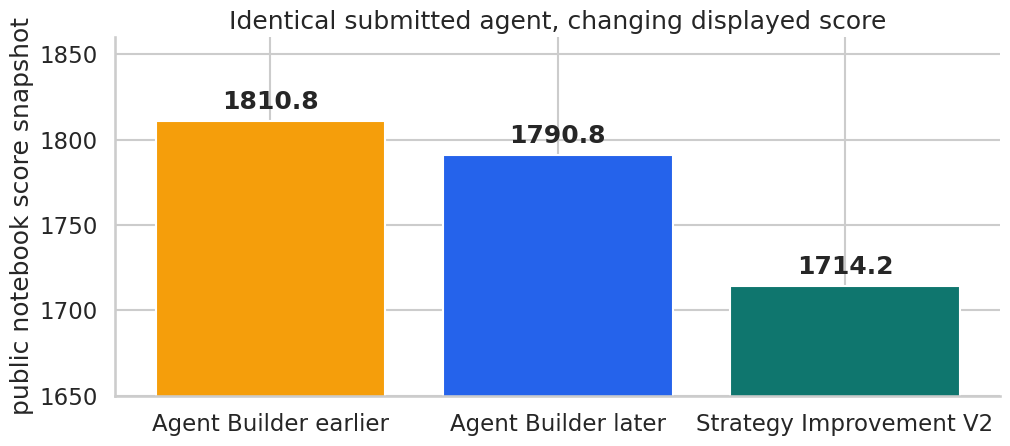

,snapshot,displayed_score,sha256
0,Agent Builder earlier,1810.8,32ce3d57a994edfc5856383da074a059cad4117e7ea840...
1,Agent Builder later,1790.8,32ce3d57a994edfc5856383da074a059cad4117e7ea840...
2,Strategy Improvement V2,1714.2,32ce3d57a994edfc5856383da074a059cad4117e7ea840...


In [17]:
SCORE_AUDIT = pd.DataFrame([
    {"snapshot": "Agent Builder earlier", "displayed_score": 1810.8, "sha256": "32ce3d57a994edfc5856383da074a059cad4117e7ea84012398316f68aad048e"},
    {"snapshot": "Agent Builder later", "displayed_score": 1790.8, "sha256": "32ce3d57a994edfc5856383da074a059cad4117e7ea84012398316f68aad048e"},
    {"snapshot": "Strategy Improvement V2", "displayed_score": 1714.2, "sha256": "32ce3d57a994edfc5856383da074a059cad4117e7ea84012398316f68aad048e"},
])
fig, ax = plt.subplots(figsize=(10.5, 4.8))
bars = ax.bar(SCORE_AUDIT.snapshot, SCORE_AUDIT.displayed_score, color=[COLORS[1], COLORS[2], COLORS[0]])
ax.bar_label(bars, fmt="%.1f", padding=5, fontweight="bold")
ax.set_ylim(1650, 1860)
ax.set(title="Identical submitted agent, changing displayed score", ylabel="public notebook score snapshot", xlabel="")
sns.despine(); plt.tight_layout(); plt.show()
assert SCORE_AUDIT.sha256.nunique() == 1
display(SCORE_AUDIT)


## Exact replay controls before counterfactual claims

The stress harness first re-runs every downloaded leader replay with both original action streams. All **24** controls must reproduce both published rewards exactly and finish `DONE`; otherwise the counterfactual rows are rejected.


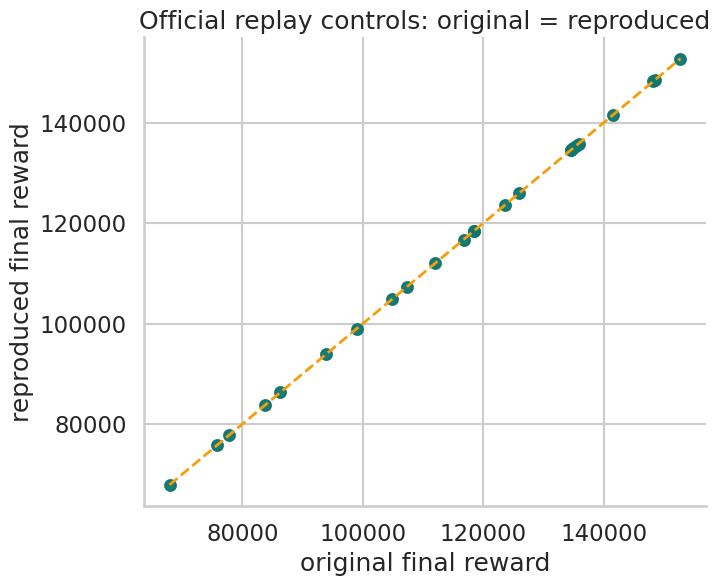

{'controls': 24, 'reward_points': 48, 'exact_reward_controls': 24, 'both_done_controls': 24, 'maximum_absolute_reward_error': 0.0}


In [18]:
REPLAY_CONTROL_ROWS = [{'kind': 'control', 'episode_id': 89508871, 'seed': 2074736119, 'names': ['Araik Tamazian', 'syouya tobita'], 'original_rewards': [111961.0, 107376.0], 'reproduced_rewards': [111961.0, 107376.0], 'exact': True, 'statuses': ['DONE', 'DONE'], 'steps': 720}, {'kind': 'control', 'episode_id': 89510489, 'seed': 441677832, 'names': ['syouya tobita', 'senkin13'], 'original_rewards': [125892.0, 118470.0], 'reproduced_rewards': [125892.0, 118470.0], 'exact': True, 'statuses': ['DONE', 'DONE'], 'steps': 720}, {'kind': 'control', 'episode_id': 89512153, 'seed': 505696381, 'names': ['senkin13', 'syouya tobita'], 'original_rewards': [148453.0, 152726.0], 'reproduced_rewards': [148453.0, 152726.0], 'exact': True, 'statuses': ['DONE', 'DONE'], 'steps': 720}, {'kind': 'control', 'episode_id': 89513803, 'seed': 1027290486, 'names': ['senkin13', 'syouya tobita'], 'original_rewards': [118448.0, 134526.0], 'reproduced_rewards': [118448.0, 134526.0], 'exact': True, 'statuses': ['DONE', 'DONE'], 'steps': 720}, {'kind': 'control', 'episode_id': 89515993, 'seed': 701206860, 'names': ['senkin13', 'syouya tobita'], 'original_rewards': [116719.0, 123550.0], 'reproduced_rewards': [116719.0, 123550.0], 'exact': True, 'statuses': ['DONE', 'DONE'], 'steps': 720}, {'kind': 'control', 'episode_id': 89516538, 'seed': 463740662, 'names': ['Ali', 'syouya tobita'], 'original_rewards': [98974.0, 104910.0], 'reproduced_rewards': [98974.0, 104910.0], 'exact': True, 'statuses': ['DONE', 'DONE'], 'steps': 720}, {'kind': 'control', 'episode_id': 89517103, 'seed': 911808428, 'names': ['radiant-allomancer', 'syouya tobita'], 'original_rewards': [134567.0, 141592.0], 'reproduced_rewards': [134567.0, 141592.0], 'exact': True, 'statuses': ['DONE', 'DONE'], 'steps': 720}, {'kind': 'control', 'episode_id': 89518736, 'seed': 634860899, 'names': ['radiant-allomancer', 'syouya tobita'], 'original_rewards': [135833.0, 134847.0], 'reproduced_rewards': [135833.0, 134847.0], 'exact': True, 'statuses': ['DONE', 'DONE'], 'steps': 720}, {'kind': 'control', 'episode_id': 89517081, 'seed': 382308587, 'names': ['Tran H Hoang', 'Ali'], 'original_rewards': [75748.0, 67924.0], 'reproduced_rewards': [75748.0, 67924.0], 'exact': True, 'statuses': ['DONE', 'DONE'], 'steps': 720}, {'kind': 'control', 'episode_id': 89518187, 'seed': 1000289498, 'names': ['Araik Tamazian', 'Tran H Hoang'], 'original_rewards': [86322.0, 93970.0], 'reproduced_rewards': [86322.0, 93970.0], 'exact': True, 'statuses': ['DONE', 'DONE'], 'steps': 720}, {'kind': 'control', 'episode_id': 89518725, 'seed': 45269571, 'names': ['Ali', 'Tran H Hoang'], 'original_rewards': [148245.0, 135314.0], 'reproduced_rewards': [148245.0, 135314.0], 'exact': True, 'statuses': ['DONE', 'DONE'], 'steps': 720}, {'kind': 'control', 'episode_id': 89516538, 'seed': 463740662, 'names': ['Ali', 'syouya tobita'], 'original_rewards': [98974.0, 104910.0], 'reproduced_rewards': [98974.0, 104910.0], 'exact': True, 'statuses': ['DONE', 'DONE'], 'steps': 720}, {'kind': 'control', 'episode_id': 89517081, 'seed': 382308587, 'names': ['Tran H Hoang', 'Ali'], 'original_rewards': [75748.0, 67924.0], 'reproduced_rewards': [75748.0, 67924.0], 'exact': True, 'statuses': ['DONE', 'DONE'], 'steps': 720}, {'kind': 'control', 'episode_id': 89518725, 'seed': 45269571, 'names': ['Ali', 'Tran H Hoang'], 'original_rewards': [148245.0, 135314.0], 'reproduced_rewards': [148245.0, 135314.0], 'exact': True, 'statuses': ['DONE', 'DONE'], 'steps': 720}, {'kind': 'control', 'episode_id': 89510489, 'seed': 441677832, 'names': ['syouya tobita', 'senkin13'], 'original_rewards': [125892.0, 118470.0], 'reproduced_rewards': [125892.0, 118470.0], 'exact': True, 'statuses': ['DONE', 'DONE'], 'steps': 720}, {'kind': 'control', 'episode_id': 89512153, 'seed': 505696381, 'names': ['senkin13', 'syouya tobita'], 'original_rewards': [148453.0, 152726.0], 'reproduced_rewards': [148453.0, 152726.0], 'exact': True, 'statuses': ['DONE', 'DONE'], 'steps': 720}, {'kind': 'control', 'episode_id': 89513803, 'seed': 1027290486, 'names': ['senkin13', 'syouya tobita'], 'original_rewards': [118448.0, 134526.0], 'reproduced_rewards': [118448.0, 134526.0], 'exact': True, 'statuses': ['DONE', 'DONE'], 'steps': 720}, {'kind': 'control', 'episode_id': 89515450, 'seed': 1386758212, 'names': ['Araik Tamazian', 'senkin13'], 'original_rewards': [77856.0, 83753.0], 'reproduced_rewards': [77856.0, 83753.0], 'exact': True, 'statuses': ['DONE', 'DONE'], 'steps': 720}, {'kind': 'control', 'episode_id': 89515993, 'seed': 701206860, 'names': ['senkin13', 'syouya tobita'], 'original_rewards': [116719.0, 123550.0], 'reproduced_rewards': [116719.0, 123550.0], 'exact': True, 'statuses': ['DONE', 'DONE'], 'steps': 720}, {'kind': 'control', 'episode_id': 89508871, 'seed': 2074736119, 'names': ['Araik Tamazian', 'syouya tobita'], 'original_rewards': [111961.0, 107376.0], 'reproduced_rewards': [111961.0, 107376.0], 'exact': True, 'statuses': ['DONE', 'DONE'], 'steps': 720}, {'kind': 'control', 'episode_id': 89515450, 'seed': 1386758212, 'names': ['Araik Tamazian', 'senkin13'], 'original_rewards': [77856.0, 83753.0], 'reproduced_rewards': [77856.0, 83753.0], 'exact': True, 'statuses': ['DONE', 'DONE'], 'steps': 720}, {'kind': 'control', 'episode_id': 89518187, 'seed': 1000289498, 'names': ['Araik Tamazian', 'Tran H Hoang'], 'original_rewards': [86322.0, 93970.0], 'reproduced_rewards': [86322.0, 93970.0], 'exact': True, 'statuses': ['DONE', 'DONE'], 'steps': 720}, {'kind': 'control', 'episode_id': 89517103, 'seed': 911808428, 'names': ['radiant-allomancer', 'syouya tobita'], 'original_rewards': [134567.0, 141592.0], 'reproduced_rewards': [134567.0, 141592.0], 'exact': True, 'statuses': ['DONE', 'DONE'], 'steps': 720}, {'kind': 'control', 'episode_id': 89518736, 'seed': 634860899, 'names': ['radiant-allomancer', 'syouya tobita'], 'original_rewards': [135833.0, 134847.0], 'reproduced_rewards': [135833.0, 134847.0], 'exact': True, 'statuses': ['DONE', 'DONE'], 'steps': 720}]
control_rows = pd.DataFrame(REPLAY_CONTROL_ROWS)
reward_points = []
for row in REPLAY_CONTROL_ROWS:
    for side, (original, reproduced) in enumerate(zip(row["original_rewards"], row["reproduced_rewards"])):
        reward_points.append({
            "episode": row["episode_id"], "side": side,
            "original": float(original), "reproduced": float(reproduced),
        })
reward_points = pd.DataFrame(reward_points)
fig, ax = plt.subplots(figsize=(7.5, 6.2))
ax.scatter(reward_points.original, reward_points.reproduced, s=58, alpha=.78, color=COLORS[0])
lo = min(reward_points.original.min(), reward_points.reproduced.min())
hi = max(reward_points.original.max(), reward_points.reproduced.max())
ax.plot([lo, hi], [lo, hi], ls="--", color=COLORS[1], lw=2)
ax.set(title="Official replay controls: original = reproduced", xlabel="original final reward", ylabel="reproduced final reward")
sns.despine(); plt.tight_layout(); plt.show()
exact_controls = int(control_rows.exact.sum())
done_controls = int(control_rows.statuses.apply(lambda values: values == ["DONE", "DONE"]).sum())
assert exact_controls == len(control_rows) == done_controls
print({
    "controls": int(len(control_rows)), "reward_points": int(len(reward_points)),
    "exact_reward_controls": exact_controls, "both_done_controls": done_controls,
    "maximum_absolute_reward_error": float((reward_points.original - reward_points.reproduced).abs().max()),
})


## Matched improvement over fixed consensus

Each point below holds opponent, seed, and seat fixed. Positive values mean the visible-state router finished with more cash than the per-turn majority tape; outcome flips make the practical effect visible without hiding regressions.


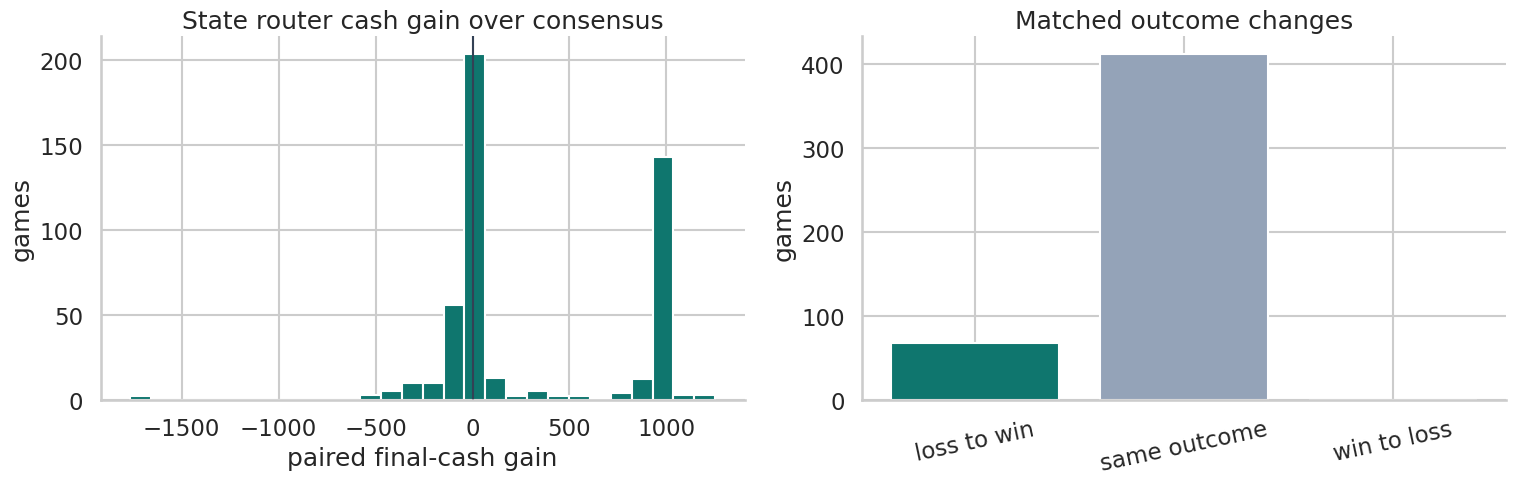

{'paired_games': 480, 'improved_cash': 260, 'unchanged_cash': 63, 'worse_cash': 157, 'mean_gain': 317.0708333333333, 'minimum_gain': -1767.0, 'loss_to_win': 68, 'win_to_loss': 0}


In [19]:
STATE_PAIR_ROWS = [{'gate': 'exact', 'opponent': 'Ali:89516538', 'seed': 463740662, 'side': 0, 'consensus_money': 104803.0, 'router_money': 104686.0, 'gain': -117.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'exact', 'opponent': 'Ali:89516538', 'seed': 463740662, 'side': 1, 'consensus_money': 105027.0, 'router_money': 104910.0, 'gain': -117.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'exact', 'opponent': 'Ali:89517081', 'seed': 382308587, 'side': 0, 'consensus_money': 80878.0, 'router_money': 81864.0, 'gain': 986.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'exact', 'opponent': 'Ali:89517081', 'seed': 382308587, 'side': 1, 'consensus_money': 74274.0, 'router_money': 75260.0, 'gain': 986.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'exact', 'opponent': 'Ali:89518725', 'seed': 45269571, 'side': 0, 'consensus_money': 145063.0, 'router_money': 145025.0, 'gain': -38.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'exact', 'opponent': 'Ali:89518725', 'seed': 45269571, 'side': 1, 'consensus_money': 145063.0, 'router_money': 145025.0, 'gain': -38.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'exact', 'opponent': 'Araik Tamazian:89508871', 'seed': 2074736119, 'side': 0, 'consensus_money': 107148.0, 'router_money': 107720.0, 'gain': 572.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'exact', 'opponent': 'Araik Tamazian:89508871', 'seed': 2074736119, 'side': 1, 'consensus_money': 106390.0, 'router_money': 107376.0, 'gain': 986.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'exact', 'opponent': 'Araik Tamazian:89515450', 'seed': 1386758212, 'side': 0, 'consensus_money': 115213.0, 'router_money': 115213.0, 'gain': 0.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'exact', 'opponent': 'Araik Tamazian:89515450', 'seed': 1386758212, 'side': 1, 'consensus_money': 113833.0, 'router_money': 114121.0, 'gain': 288.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'exact', 'opponent': 'Araik Tamazian:89518187', 'seed': 1000289498, 'side': 0, 'consensus_money': 79472.0, 'router_money': 80458.0, 'gain': 986.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'exact', 'opponent': 'Araik Tamazian:89518187', 'seed': 1000289498, 'side': 1, 'consensus_money': 80414.0, 'router_money': 81400.0, 'gain': 986.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'exact', 'opponent': 'Tran H Hoang:89517081', 'seed': 382308587, 'side': 0, 'consensus_money': 105222.0, 'router_money': 106174.0, 'gain': 952.0, 'consensus_win': False, 'router_win': True, 'outcome': 'loss to win'}, {'gate': 'exact', 'opponent': 'Tran H Hoang:89517081', 'seed': 382308587, 'side': 1, 'consensus_money': 105222.0, 'router_money': 106174.0, 'gain': 952.0, 'consensus_win': False, 'router_win': True, 'outcome': 'loss to win'}, {'gate': 'exact', 'opponent': 'Tran H Hoang:89518187', 'seed': 1000289498, 'side': 0, 'consensus_money': 112953.0, 'router_money': 112953.0, 'gain': 0.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'exact', 'opponent': 'Tran H Hoang:89518187', 'seed': 1000289498, 'side': 1, 'consensus_money': 114091.0, 'router_money': 114091.0, 'gain': 0.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'exact', 'opponent': 'Tran H Hoang:89518725', 'seed': 45269571, 'side': 0, 'consensus_money': 137651.0, 'router_money': 137572.0, 'gain': -79.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'exact', 'opponent': 'Tran H Hoang:89518725', 'seed': 45269571, 'side': 1, 'consensus_money': 137651.0, 'router_money': 137572.0, 'gain': -79.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'exact', 'opponent': 'radiant-allomancer:89517103', 'seed': 911808428, 'side': 0, 'consensus_money': 144392.0, 'router_money': 144404.0, 'gain': 12.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'exact', 'opponent': 'radiant-allomancer:89517103', 'seed': 911808428, 'side': 1, 'consensus_money': 141568.0, 'router_money': 141592.0, 'gain': 24.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'exact', 'opponent': 'radiant-allomancer:89518736', 'seed': 634860899, 'side': 0, 'consensus_money': 143328.0, 'router_money': 143303.0, 'gain': -25.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'exact', 'opponent': 'radiant-allomancer:89518736', 'seed': 634860899, 'side': 1, 'consensus_money': 133595.0, 'router_money': 134847.0, 'gain': 1252.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'exact', 'opponent': 'senkin13:89510489', 'seed': 441677832, 'side': 0, 'consensus_money': 125892.0, 'router_money': 125892.0, 'gain': 0.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'exact', 'opponent': 'senkin13:89510489', 'seed': 441677832, 'side': 1, 'consensus_money': 113367.0, 'router_money': 113367.0, 'gain': 0.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'exact', 'opponent': 'senkin13:89512153', 'seed': 505696381, 'side': 0, 'consensus_money': 154416.0, 'router_money': 154416.0, 'gain': 0.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'exact', 'opponent': 'senkin13:89512153', 'seed': 505696381, 'side': 1, 'consensus_money': 152726.0, 'router_money': 152726.0, 'gain': 0.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'exact', 'opponent': 'senkin13:89513803', 'seed': 1027290486, 'side': 0, 'consensus_money': 131711.0, 'router_money': 131648.0, 'gain': -63.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'exact', 'opponent': 'senkin13:89513803', 'seed': 1027290486, 'side': 1, 'consensus_money': 134508.0, 'router_money': 134526.0, 'gain': 18.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'exact', 'opponent': 'senkin13:89515450', 'seed': 1386758212, 'side': 0, 'consensus_money': 114788.0, 'router_money': 114788.0, 'gain': 0.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'exact', 'opponent': 'senkin13:89515450', 'seed': 1386758212, 'side': 1, 'consensus_money': 113421.0, 'router_money': 113421.0, 'gain': 0.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'exact', 'opponent': 'senkin13:89515993', 'seed': 701206860, 'side': 0, 'consensus_money': 125038.0, 'router_money': 124973.0, 'gain': -65.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'exact', 'opponent': 'senkin13:89515993', 'seed': 701206860, 'side': 1, 'consensus_money': 123606.0, 'router_money': 123550.0, 'gain': -56.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'exact', 'opponent': 'syouya tobita:89508871', 'seed': 2074736119, 'side': 0, 'consensus_money': 118765.0, 'router_money': 118865.0, 'gain': 100.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'exact', 'opponent': 'syouya tobita:89508871', 'seed': 2074736119, 'side': 1, 'consensus_money': 120792.0, 'router_money': 120902.0, 'gain': 110.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'exact', 'opponent': 'syouya tobita:89510489', 'seed': 441677832, 'side': 0, 'consensus_money': 98086.0, 'router_money': 99103.0, 'gain': 1017.0, 'consensus_win': False, 'router_win': True, 'outcome': 'loss to win'}, {'gate': 'exact', 'opponent': 'syouya tobita:89510489', 'seed': 441677832, 'side': 1, 'consensus_money': 98086.0, 'router_money': 99103.0, 'gain': 1017.0, 'consensus_win': False, 'router_win': True, 'outcome': 'loss to win'}, {'gate': 'exact', 'opponent': 'syouya tobita:89512153', 'seed': 505696381, 'side': 0, 'consensus_money': 81979.0, 'router_money': 82946.0, 'gain': 967.0, 'consensus_win': False, 'router_win': True, 'outcome': 'loss to win'}, {'gate': 'exact', 'opponent': 'syouya tobita:89512153', 'seed': 505696381, 'side': 1, 'consensus_money': 81979.0, 'router_money': 82946.0, 'gain': 967.0, 'consensus_win': False, 'router_win': True, 'outcome': 'loss to win'}, {'gate': 'exact', 'opponent': 'syouya tobita:89513803', 'seed': 1027290486, 'side': 0, 'consensus_money': 120876.0, 'router_money': 121032.0, 'gain': 156.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'exact', 'opponent': 'syouya tobita:89513803', 'seed': 1027290486, 'side': 1, 'consensus_money': 120522.0, 'router_money': 120587.0, 'gain': 65.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'exact', 'opponent': 'syouya tobita:89515993', 'seed': 701206860, 'side': 0, 'consensus_money': 133907.0, 'router_money': 133953.0, 'gain': 46.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'exact', 'opponent': 'syouya tobita:89515993', 'seed': 701206860, 'side': 1, 'consensus_money': 132410.0, 'router_money': 132485.0, 'gain': 75.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'exact', 'opponent': 'syouya tobita:89516538', 'seed': 463740662, 'side': 0, 'consensus_money': 101520.0, 'router_money': 101516.0, 'gain': -4.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'exact', 'opponent': 'syouya tobita:89516538', 'seed': 463740662, 'side': 1, 'consensus_money': 101744.0, 'router_money': 101730.0, 'gain': -14.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'exact', 'opponent': 'syouya tobita:89517103', 'seed': 911808428, 'side': 0, 'consensus_money': 146155.0, 'router_money': 146201.0, 'gain': 46.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'exact', 'opponent': 'syouya tobita:89517103', 'seed': 911808428, 'side': 1, 'consensus_money': 147770.0, 'router_money': 147816.0, 'gain': 46.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'exact', 'opponent': 'syouya tobita:89518736', 'seed': 634860899, 'side': 0, 'consensus_money': 161029.0, 'router_money': 161013.0, 'gain': -16.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'exact', 'opponent': 'syouya tobita:89518736', 'seed': 634860899, 'side': 1, 'consensus_money': 150280.0, 'router_money': 151467.0, 'gain': 1187.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89508871:0', 'seed': 4301, 'side': 0, 'consensus_money': 106288.0, 'router_money': 107308.0, 'gain': 1020.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89508871:0', 'seed': 4301, 'side': 1, 'consensus_money': 109481.0, 'router_money': 110467.0, 'gain': 986.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89508871:0', 'seed': 4302, 'side': 0, 'consensus_money': 125151.0, 'router_money': 125151.0, 'gain': 0.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89508871:0', 'seed': 4302, 'side': 1, 'consensus_money': 126852.0, 'router_money': 126852.0, 'gain': 0.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89508871:0', 'seed': 4303, 'side': 0, 'consensus_money': 123601.0, 'router_money': 123490.0, 'gain': -111.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89508871:0', 'seed': 4303, 'side': 1, 'consensus_money': 123601.0, 'router_money': 123490.0, 'gain': -111.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89508871:0', 'seed': 4304, 'side': 0, 'consensus_money': 101583.0, 'router_money': 101439.0, 'gain': -144.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89508871:0', 'seed': 4304, 'side': 1, 'consensus_money': 101583.0, 'router_money': 101439.0, 'gain': -144.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89508871:0', 'seed': 4401, 'side': 0, 'consensus_money': 149760.0, 'router_money': 149300.0, 'gain': -460.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89508871:0', 'seed': 4401, 'side': 1, 'consensus_money': 153712.0, 'router_money': 151947.0, 'gain': -1765.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89508871:0', 'seed': 4402, 'side': 0, 'consensus_money': 128221.0, 'router_money': 128221.0, 'gain': 0.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89508871:0', 'seed': 4402, 'side': 1, 'consensus_money': 128221.0, 'router_money': 128221.0, 'gain': 0.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89508871:0', 'seed': 4403, 'side': 0, 'consensus_money': 133322.0, 'router_money': 134197.0, 'gain': 875.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89508871:0', 'seed': 4403, 'side': 1, 'consensus_money': 114252.0, 'router_money': 115237.0, 'gain': 985.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89508871:0', 'seed': 4404, 'side': 0, 'consensus_money': 138537.0, 'router_money': 138537.0, 'gain': 0.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89508871:0', 'seed': 4404, 'side': 1, 'consensus_money': 138537.0, 'router_money': 138537.0, 'gain': 0.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89508871:0', 'seed': 4405, 'side': 0, 'consensus_money': 109742.0, 'router_money': 110745.0, 'gain': 1003.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89508871:0', 'seed': 4405, 'side': 1, 'consensus_money': 109742.0, 'router_money': 110745.0, 'gain': 1003.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89508871:0', 'seed': 4406, 'side': 0, 'consensus_money': 134636.0, 'router_money': 135639.0, 'gain': 1003.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89508871:0', 'seed': 4406, 'side': 1, 'consensus_money': 136032.0, 'router_money': 137035.0, 'gain': 1003.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89508871:0', 'seed': 4407, 'side': 0, 'consensus_money': 144930.0, 'router_money': 144930.0, 'gain': 0.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89508871:0', 'seed': 4407, 'side': 1, 'consensus_money': 140708.0, 'router_money': 140708.0, 'gain': 0.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89508871:0', 'seed': 4408, 'side': 0, 'consensus_money': 86543.0, 'router_money': 86393.0, 'gain': -150.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89508871:0', 'seed': 4408, 'side': 1, 'consensus_money': 77847.0, 'router_money': 77692.0, 'gain': -155.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89508871:0', 'seed': 4409, 'side': 0, 'consensus_money': 150268.0, 'router_money': 150448.0, 'gain': 180.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89508871:0', 'seed': 4409, 'side': 1, 'consensus_money': 143842.0, 'router_money': 143763.0, 'gain': -79.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89508871:0', 'seed': 4410, 'side': 0, 'consensus_money': 125019.0, 'router_money': 126034.0, 'gain': 1015.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89508871:0', 'seed': 4410, 'side': 1, 'consensus_money': 125019.0, 'router_money': 126034.0, 'gain': 1015.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89508871:0', 'seed': 4501, 'side': 0, 'consensus_money': 109179.0, 'router_money': 110199.0, 'gain': 1020.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89508871:0', 'seed': 4501, 'side': 1, 'consensus_money': 93664.0, 'router_money': 94667.0, 'gain': 1003.0, 'consensus_win': False, 'router_win': True, 'outcome': 'loss to win'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89508871:0', 'seed': 4502, 'side': 0, 'consensus_money': 140316.0, 'router_money': 141033.0, 'gain': 717.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89508871:0', 'seed': 4502, 'side': 1, 'consensus_money': 139722.0, 'router_money': 140511.0, 'gain': 789.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89508871:0', 'seed': 4503, 'side': 0, 'consensus_money': 99414.0, 'router_money': 99572.0, 'gain': 158.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89508871:0', 'seed': 4503, 'side': 1, 'consensus_money': 100069.0, 'router_money': 100222.0, 'gain': 153.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89508871:0', 'seed': 4504, 'side': 0, 'consensus_money': 117687.0, 'router_money': 117687.0, 'gain': 0.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89508871:0', 'seed': 4504, 'side': 1, 'consensus_money': 123150.0, 'router_money': 123150.0, 'gain': 0.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89508871:0', 'seed': 4601, 'side': 0, 'consensus_money': 139899.0, 'router_money': 139979.0, 'gain': 80.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89508871:0', 'seed': 4601, 'side': 1, 'consensus_money': 153977.0, 'router_money': 153977.0, 'gain': 0.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89508871:0', 'seed': 4602, 'side': 0, 'consensus_money': 92810.0, 'router_money': 93825.0, 'gain': 1015.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89508871:0', 'seed': 4602, 'side': 1, 'consensus_money': 93832.0, 'router_money': 94845.0, 'gain': 1013.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89508871:0', 'seed': 4603, 'side': 0, 'consensus_money': 137627.0, 'router_money': 137552.0, 'gain': -75.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89508871:0', 'seed': 4603, 'side': 1, 'consensus_money': 139581.0, 'router_money': 139506.0, 'gain': -75.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89508871:0', 'seed': 4604, 'side': 0, 'consensus_money': 140845.0, 'router_money': 141258.0, 'gain': 413.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89508871:0', 'seed': 4604, 'side': 1, 'consensus_money': 147393.0, 'router_money': 147322.0, 'gain': -71.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89508871:0', 'seed': 4605, 'side': 0, 'consensus_money': 116770.0, 'router_money': 116913.0, 'gain': 143.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89508871:0', 'seed': 4605, 'side': 1, 'consensus_money': 94732.0, 'router_money': 95749.0, 'gain': 1017.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89508871:0', 'seed': 4606, 'side': 0, 'consensus_money': 131110.0, 'router_money': 130755.0, 'gain': -355.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89508871:0', 'seed': 4606, 'side': 1, 'consensus_money': 131110.0, 'router_money': 130755.0, 'gain': -355.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89510489:0', 'seed': 4301, 'side': 0, 'consensus_money': 151011.0, 'router_money': 151047.0, 'gain': 36.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89510489:0', 'seed': 4301, 'side': 1, 'consensus_money': 141647.0, 'router_money': 141615.0, 'gain': -32.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89510489:0', 'seed': 4302, 'side': 0, 'consensus_money': 95650.0, 'router_money': 96559.0, 'gain': 909.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89510489:0', 'seed': 4302, 'side': 1, 'consensus_money': 98864.0, 'router_money': 98839.0, 'gain': -25.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89510489:0', 'seed': 4303, 'side': 0, 'consensus_money': 126565.0, 'router_money': 126611.0, 'gain': 46.0, 'consensus_win': False, 'router_win': True, 'outcome': 'loss to win'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89510489:0', 'seed': 4303, 'side': 1, 'consensus_money': 126565.0, 'router_money': 126611.0, 'gain': 46.0, 'consensus_win': False, 'router_win': True, 'outcome': 'loss to win'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89510489:0', 'seed': 4304, 'side': 0, 'consensus_money': 141574.0, 'router_money': 141620.0, 'gain': 46.0, 'consensus_win': False, 'router_win': True, 'outcome': 'loss to win'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89510489:0', 'seed': 4304, 'side': 1, 'consensus_money': 141574.0, 'router_money': 141620.0, 'gain': 46.0, 'consensus_win': False, 'router_win': True, 'outcome': 'loss to win'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89510489:0', 'seed': 4401, 'side': 0, 'consensus_money': 141452.0, 'router_money': 141498.0, 'gain': 46.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89510489:0', 'seed': 4401, 'side': 1, 'consensus_money': 140250.0, 'router_money': 140296.0, 'gain': 46.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89510489:0', 'seed': 4402, 'side': 0, 'consensus_money': 102090.0, 'router_money': 103059.0, 'gain': 969.0, 'consensus_win': False, 'router_win': True, 'outcome': 'loss to win'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89510489:0', 'seed': 4402, 'side': 1, 'consensus_money': 102090.0, 'router_money': 103059.0, 'gain': 969.0, 'consensus_win': False, 'router_win': True, 'outcome': 'loss to win'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89510489:0', 'seed': 4403, 'side': 0, 'consensus_money': 104194.0, 'router_money': 104222.0, 'gain': 28.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89510489:0', 'seed': 4403, 'side': 1, 'consensus_money': 96404.0, 'router_money': 97437.0, 'gain': 1033.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89510489:0', 'seed': 4404, 'side': 0, 'consensus_money': 98104.0, 'router_money': 99047.0, 'gain': 943.0, 'consensus_win': False, 'router_win': True, 'outcome': 'loss to win'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89510489:0', 'seed': 4404, 'side': 1, 'consensus_money': 98104.0, 'router_money': 99047.0, 'gain': 943.0, 'consensus_win': False, 'router_win': True, 'outcome': 'loss to win'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89510489:0', 'seed': 4405, 'side': 0, 'consensus_money': 118551.0, 'router_money': 118597.0, 'gain': 46.0, 'consensus_win': False, 'router_win': True, 'outcome': 'loss to win'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89510489:0', 'seed': 4405, 'side': 1, 'consensus_money': 118551.0, 'router_money': 118597.0, 'gain': 46.0, 'consensus_win': False, 'router_win': True, 'outcome': 'loss to win'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89510489:0', 'seed': 4406, 'side': 0, 'consensus_money': 126364.0, 'router_money': 126410.0, 'gain': 46.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89510489:0', 'seed': 4406, 'side': 1, 'consensus_money': 127378.0, 'router_money': 127424.0, 'gain': 46.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89510489:0', 'seed': 4407, 'side': 0, 'consensus_money': 79061.0, 'router_money': 80095.0, 'gain': 1034.0, 'consensus_win': False, 'router_win': True, 'outcome': 'loss to win'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89510489:0', 'seed': 4407, 'side': 1, 'consensus_money': 79061.0, 'router_money': 80095.0, 'gain': 1034.0, 'consensus_win': False, 'router_win': True, 'outcome': 'loss to win'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89510489:0', 'seed': 4408, 'side': 0, 'consensus_money': 119163.0, 'router_money': 119209.0, 'gain': 46.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89510489:0', 'seed': 4408, 'side': 1, 'consensus_money': 118950.0, 'router_money': 118996.0, 'gain': 46.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89510489:0', 'seed': 4409, 'side': 0, 'consensus_money': 121590.0, 'router_money': 121590.0, 'gain': 0.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89510489:0', 'seed': 4409, 'side': 1, 'consensus_money': 111310.0, 'router_money': 112153.0, 'gain': 843.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89510489:0', 'seed': 4410, 'side': 0, 'consensus_money': 106359.0, 'router_money': 107393.0, 'gain': 1034.0, 'consensus_win': False, 'router_win': True, 'outcome': 'loss to win'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89510489:0', 'seed': 4410, 'side': 1, 'consensus_money': 106359.0, 'router_money': 107393.0, 'gain': 1034.0, 'consensus_win': False, 'router_win': True, 'outcome': 'loss to win'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89510489:0', 'seed': 4501, 'side': 0, 'consensus_money': 97914.0, 'router_money': 98866.0, 'gain': 952.0, 'consensus_win': False, 'router_win': True, 'outcome': 'loss to win'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89510489:0', 'seed': 4501, 'side': 1, 'consensus_money': 97914.0, 'router_money': 98866.0, 'gain': 952.0, 'consensus_win': False, 'router_win': True, 'outcome': 'loss to win'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89510489:0', 'seed': 4502, 'side': 0, 'consensus_money': 95407.0, 'router_money': 94912.0, 'gain': -495.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89510489:0', 'seed': 4502, 'side': 1, 'consensus_money': 100903.0, 'router_money': 100949.0, 'gain': 46.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89510489:0', 'seed': 4503, 'side': 0, 'consensus_money': 102413.0, 'router_money': 103347.0, 'gain': 934.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89510489:0', 'seed': 4503, 'side': 1, 'consensus_money': 111584.0, 'router_money': 111665.0, 'gain': 81.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89510489:0', 'seed': 4504, 'side': 0, 'consensus_money': 162649.0, 'router_money': 162633.0, 'gain': -16.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89510489:0', 'seed': 4504, 'side': 1, 'consensus_money': 162649.0, 'router_money': 162633.0, 'gain': -16.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89510489:0', 'seed': 4601, 'side': 0, 'consensus_money': 108647.0, 'router_money': 109664.0, 'gain': 1017.0, 'consensus_win': False, 'router_win': True, 'outcome': 'loss to win'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89510489:0', 'seed': 4601, 'side': 1, 'consensus_money': 108647.0, 'router_money': 109664.0, 'gain': 1017.0, 'consensus_win': False, 'router_win': True, 'outcome': 'loss to win'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89510489:0', 'seed': 4602, 'side': 0, 'consensus_money': 101078.0, 'router_money': 102062.0, 'gain': 984.0, 'consensus_win': False, 'router_win': True, 'outcome': 'loss to win'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89510489:0', 'seed': 4602, 'side': 1, 'consensus_money': 101078.0, 'router_money': 102062.0, 'gain': 984.0, 'consensus_win': False, 'router_win': True, 'outcome': 'loss to win'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89510489:0', 'seed': 4603, 'side': 0, 'consensus_money': 119729.0, 'router_money': 119713.0, 'gain': -16.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89510489:0', 'seed': 4603, 'side': 1, 'consensus_money': 119729.0, 'router_money': 119713.0, 'gain': -16.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89510489:0', 'seed': 4604, 'side': 0, 'consensus_money': 127331.0, 'router_money': 127683.0, 'gain': 352.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89510489:0', 'seed': 4604, 'side': 1, 'consensus_money': 134641.0, 'router_money': 134615.0, 'gain': -26.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89510489:0', 'seed': 4605, 'side': 0, 'consensus_money': 108664.0, 'router_money': 109649.0, 'gain': 985.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89510489:0', 'seed': 4605, 'side': 1, 'consensus_money': 115030.0, 'router_money': 114933.0, 'gain': -97.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89510489:0', 'seed': 4606, 'side': 0, 'consensus_money': 138541.0, 'router_money': 138525.0, 'gain': -16.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89510489:0', 'seed': 4606, 'side': 1, 'consensus_money': 138541.0, 'router_money': 138525.0, 'gain': -16.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89512153:1', 'seed': 4301, 'side': 0, 'consensus_money': 150940.0, 'router_money': 150974.0, 'gain': 34.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89512153:1', 'seed': 4301, 'side': 1, 'consensus_money': 141790.0, 'router_money': 141756.0, 'gain': -34.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89512153:1', 'seed': 4302, 'side': 0, 'consensus_money': 95650.0, 'router_money': 96559.0, 'gain': 909.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89512153:1', 'seed': 4302, 'side': 1, 'consensus_money': 98864.0, 'router_money': 98839.0, 'gain': -25.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89512153:1', 'seed': 4303, 'side': 0, 'consensus_money': 126934.0, 'router_money': 126979.0, 'gain': 45.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89512153:1', 'seed': 4303, 'side': 1, 'consensus_money': 126934.0, 'router_money': 126979.0, 'gain': 45.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89512153:1', 'seed': 4304, 'side': 0, 'consensus_money': 141943.0, 'router_money': 141988.0, 'gain': 45.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89512153:1', 'seed': 4304, 'side': 1, 'consensus_money': 141943.0, 'router_money': 141988.0, 'gain': 45.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89512153:1', 'seed': 4401, 'side': 0, 'consensus_money': 141879.0, 'router_money': 141924.0, 'gain': 45.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89512153:1', 'seed': 4401, 'side': 1, 'consensus_money': 140677.0, 'router_money': 140722.0, 'gain': 45.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89512153:1', 'seed': 4402, 'side': 0, 'consensus_money': 102090.0, 'router_money': 103059.0, 'gain': 969.0, 'consensus_win': False, 'router_win': True, 'outcome': 'loss to win'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89512153:1', 'seed': 4402, 'side': 1, 'consensus_money': 102090.0, 'router_money': 103059.0, 'gain': 969.0, 'consensus_win': False, 'router_win': True, 'outcome': 'loss to win'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89512153:1', 'seed': 4403, 'side': 0, 'consensus_money': 104194.0, 'router_money': 104222.0, 'gain': 28.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89512153:1', 'seed': 4403, 'side': 1, 'consensus_money': 96404.0, 'router_money': 97437.0, 'gain': 1033.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89512153:1', 'seed': 4404, 'side': 0, 'consensus_money': 98104.0, 'router_money': 99047.0, 'gain': 943.0, 'consensus_win': False, 'router_win': True, 'outcome': 'loss to win'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89512153:1', 'seed': 4404, 'side': 1, 'consensus_money': 98104.0, 'router_money': 99047.0, 'gain': 943.0, 'consensus_win': False, 'router_win': True, 'outcome': 'loss to win'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89512153:1', 'seed': 4405, 'side': 0, 'consensus_money': 118978.0, 'router_money': 119023.0, 'gain': 45.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89512153:1', 'seed': 4405, 'side': 1, 'consensus_money': 118978.0, 'router_money': 119023.0, 'gain': 45.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89512153:1', 'seed': 4406, 'side': 0, 'consensus_money': 126791.0, 'router_money': 126836.0, 'gain': 45.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89512153:1', 'seed': 4406, 'side': 1, 'consensus_money': 127805.0, 'router_money': 127850.0, 'gain': 45.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89512153:1', 'seed': 4407, 'side': 0, 'consensus_money': 79061.0, 'router_money': 80095.0, 'gain': 1034.0, 'consensus_win': False, 'router_win': True, 'outcome': 'loss to win'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89512153:1', 'seed': 4407, 'side': 1, 'consensus_money': 79061.0, 'router_money': 80095.0, 'gain': 1034.0, 'consensus_win': False, 'router_win': True, 'outcome': 'loss to win'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89512153:1', 'seed': 4408, 'side': 0, 'consensus_money': 119579.0, 'router_money': 119624.0, 'gain': 45.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89512153:1', 'seed': 4408, 'side': 1, 'consensus_money': 119366.0, 'router_money': 119411.0, 'gain': 45.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89512153:1', 'seed': 4409, 'side': 0, 'consensus_money': 121590.0, 'router_money': 121590.0, 'gain': 0.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89512153:1', 'seed': 4409, 'side': 1, 'consensus_money': 111310.0, 'router_money': 112153.0, 'gain': 843.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89512153:1', 'seed': 4410, 'side': 0, 'consensus_money': 106359.0, 'router_money': 107393.0, 'gain': 1034.0, 'consensus_win': False, 'router_win': True, 'outcome': 'loss to win'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89512153:1', 'seed': 4410, 'side': 1, 'consensus_money': 106359.0, 'router_money': 107393.0, 'gain': 1034.0, 'consensus_win': False, 'router_win': True, 'outcome': 'loss to win'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89512153:1', 'seed': 4501, 'side': 0, 'consensus_money': 97914.0, 'router_money': 98866.0, 'gain': 952.0, 'consensus_win': False, 'router_win': True, 'outcome': 'loss to win'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89512153:1', 'seed': 4501, 'side': 1, 'consensus_money': 97914.0, 'router_money': 98866.0, 'gain': 952.0, 'consensus_win': False, 'router_win': True, 'outcome': 'loss to win'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89512153:1', 'seed': 4502, 'side': 0, 'consensus_money': 96332.0, 'router_money': 95834.0, 'gain': -498.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89512153:1', 'seed': 4502, 'side': 1, 'consensus_money': 101205.0, 'router_money': 101250.0, 'gain': 45.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89512153:1', 'seed': 4503, 'side': 0, 'consensus_money': 102413.0, 'router_money': 103347.0, 'gain': 934.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89512153:1', 'seed': 4503, 'side': 1, 'consensus_money': 111584.0, 'router_money': 111665.0, 'gain': 81.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89512153:1', 'seed': 4504, 'side': 0, 'consensus_money': 162809.0, 'router_money': 162791.0, 'gain': -18.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89512153:1', 'seed': 4504, 'side': 1, 'consensus_money': 162809.0, 'router_money': 162791.0, 'gain': -18.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89512153:1', 'seed': 4601, 'side': 0, 'consensus_money': 108647.0, 'router_money': 109664.0, 'gain': 1017.0, 'consensus_win': False, 'router_win': True, 'outcome': 'loss to win'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89512153:1', 'seed': 4601, 'side': 1, 'consensus_money': 108647.0, 'router_money': 109664.0, 'gain': 1017.0, 'consensus_win': False, 'router_win': True, 'outcome': 'loss to win'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89512153:1', 'seed': 4602, 'side': 0, 'consensus_money': 101078.0, 'router_money': 102062.0, 'gain': 984.0, 'consensus_win': False, 'router_win': True, 'outcome': 'loss to win'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89512153:1', 'seed': 4602, 'side': 1, 'consensus_money': 101078.0, 'router_money': 102062.0, 'gain': 984.0, 'consensus_win': False, 'router_win': True, 'outcome': 'loss to win'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89512153:1', 'seed': 4603, 'side': 0, 'consensus_money': 119889.0, 'router_money': 119871.0, 'gain': -18.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89512153:1', 'seed': 4603, 'side': 1, 'consensus_money': 119889.0, 'router_money': 119871.0, 'gain': -18.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89512153:1', 'seed': 4604, 'side': 0, 'consensus_money': 127342.0, 'router_money': 127694.0, 'gain': 352.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89512153:1', 'seed': 4604, 'side': 1, 'consensus_money': 134652.0, 'router_money': 134626.0, 'gain': -26.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89512153:1', 'seed': 4605, 'side': 0, 'consensus_money': 108664.0, 'router_money': 109649.0, 'gain': 985.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89512153:1', 'seed': 4605, 'side': 1, 'consensus_money': 115030.0, 'router_money': 114933.0, 'gain': -97.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89512153:1', 'seed': 4606, 'side': 0, 'consensus_money': 138701.0, 'router_money': 138683.0, 'gain': -18.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89512153:1', 'seed': 4606, 'side': 1, 'consensus_money': 138701.0, 'router_money': 138683.0, 'gain': -18.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89515450:1', 'seed': 4301, 'side': 0, 'consensus_money': 104436.0, 'router_money': 105456.0, 'gain': 1020.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89515450:1', 'seed': 4301, 'side': 1, 'consensus_money': 104843.0, 'router_money': 105829.0, 'gain': 986.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89515450:1', 'seed': 4302, 'side': 0, 'consensus_money': 128282.0, 'router_money': 128282.0, 'gain': 0.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89515450:1', 'seed': 4302, 'side': 1, 'consensus_money': 129960.0, 'router_money': 129960.0, 'gain': 0.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89515450:1', 'seed': 4303, 'side': 0, 'consensus_money': 123578.0, 'router_money': 123227.0, 'gain': -351.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89515450:1', 'seed': 4303, 'side': 1, 'consensus_money': 123578.0, 'router_money': 123227.0, 'gain': -351.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89515450:1', 'seed': 4304, 'side': 0, 'consensus_money': 103315.0, 'router_money': 103028.0, 'gain': -287.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89515450:1', 'seed': 4304, 'side': 1, 'consensus_money': 103315.0, 'router_money': 103028.0, 'gain': -287.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89515450:1', 'seed': 4401, 'side': 0, 'consensus_money': 150577.0, 'router_money': 150120.0, 'gain': -457.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89515450:1', 'seed': 4401, 'side': 1, 'consensus_money': 154437.0, 'router_money': 152670.0, 'gain': -1767.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89515450:1', 'seed': 4402, 'side': 0, 'consensus_money': 131270.0, 'router_money': 131270.0, 'gain': 0.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89515450:1', 'seed': 4402, 'side': 1, 'consensus_money': 131270.0, 'router_money': 131270.0, 'gain': 0.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89515450:1', 'seed': 4403, 'side': 0, 'consensus_money': 133973.0, 'router_money': 134771.0, 'gain': 798.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89515450:1', 'seed': 4403, 'side': 1, 'consensus_money': 114546.0, 'router_money': 114493.0, 'gain': -53.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89515450:1', 'seed': 4404, 'side': 0, 'consensus_money': 139724.0, 'router_money': 139724.0, 'gain': 0.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89515450:1', 'seed': 4404, 'side': 1, 'consensus_money': 139724.0, 'router_money': 139724.0, 'gain': 0.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89515450:1', 'seed': 4405, 'side': 0, 'consensus_money': 108832.0, 'router_money': 109835.0, 'gain': 1003.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89515450:1', 'seed': 4405, 'side': 1, 'consensus_money': 108832.0, 'router_money': 109835.0, 'gain': 1003.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89515450:1', 'seed': 4406, 'side': 0, 'consensus_money': 133508.0, 'router_money': 134511.0, 'gain': 1003.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89515450:1', 'seed': 4406, 'side': 1, 'consensus_money': 134834.0, 'router_money': 135837.0, 'gain': 1003.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89515450:1', 'seed': 4407, 'side': 0, 'consensus_money': 146280.0, 'router_money': 146280.0, 'gain': 0.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89515450:1', 'seed': 4407, 'side': 1, 'consensus_money': 142148.0, 'router_money': 142148.0, 'gain': 0.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89515450:1', 'seed': 4408, 'side': 0, 'consensus_money': 90585.0, 'router_money': 90265.0, 'gain': -320.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89515450:1', 'seed': 4408, 'side': 1, 'consensus_money': 79442.0, 'router_money': 79131.0, 'gain': -311.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89515450:1', 'seed': 4409, 'side': 0, 'consensus_money': 151053.0, 'router_money': 151224.0, 'gain': 171.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89515450:1', 'seed': 4409, 'side': 1, 'consensus_money': 145928.0, 'router_money': 145808.0, 'gain': -120.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89515450:1', 'seed': 4410, 'side': 0, 'consensus_money': 124927.0, 'router_money': 125941.0, 'gain': 1014.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89515450:1', 'seed': 4410, 'side': 1, 'consensus_money': 124927.0, 'router_money': 125941.0, 'gain': 1014.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89515450:1', 'seed': 4501, 'side': 0, 'consensus_money': 109516.0, 'router_money': 110536.0, 'gain': 1020.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89515450:1', 'seed': 4501, 'side': 1, 'consensus_money': 92013.0, 'router_money': 93016.0, 'gain': 1003.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89515450:1', 'seed': 4502, 'side': 0, 'consensus_money': 141389.0, 'router_money': 141275.0, 'gain': -114.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89515450:1', 'seed': 4502, 'side': 1, 'consensus_money': 141007.0, 'router_money': 140785.0, 'gain': -222.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89515450:1', 'seed': 4503, 'side': 0, 'consensus_money': 99456.0, 'router_money': 99388.0, 'gain': -68.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89515450:1', 'seed': 4503, 'side': 1, 'consensus_money': 100197.0, 'router_money': 100126.0, 'gain': -71.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89515450:1', 'seed': 4504, 'side': 0, 'consensus_money': 118492.0, 'router_money': 118492.0, 'gain': 0.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89515450:1', 'seed': 4504, 'side': 1, 'consensus_money': 123955.0, 'router_money': 123955.0, 'gain': 0.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89515450:1', 'seed': 4601, 'side': 0, 'consensus_money': 142029.0, 'router_money': 141966.0, 'gain': -63.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89515450:1', 'seed': 4601, 'side': 1, 'consensus_money': 153500.0, 'router_money': 153500.0, 'gain': 0.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89515450:1', 'seed': 4602, 'side': 0, 'consensus_money': 90668.0, 'router_money': 91682.0, 'gain': 1014.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89515450:1', 'seed': 4602, 'side': 1, 'consensus_money': 90646.0, 'router_money': 91649.0, 'gain': 1003.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89515450:1', 'seed': 4603, 'side': 0, 'consensus_money': 139636.0, 'router_money': 139520.0, 'gain': -116.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89515450:1', 'seed': 4603, 'side': 1, 'consensus_money': 140998.0, 'router_money': 140882.0, 'gain': -116.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89515450:1', 'seed': 4604, 'side': 0, 'consensus_money': 138675.0, 'router_money': 138675.0, 'gain': 0.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89515450:1', 'seed': 4604, 'side': 1, 'consensus_money': 149155.0, 'router_money': 149043.0, 'gain': -112.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89515450:1', 'seed': 4605, 'side': 0, 'consensus_money': 116601.0, 'router_money': 116533.0, 'gain': -68.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89515450:1', 'seed': 4605, 'side': 1, 'consensus_money': 91130.0, 'router_money': 92146.0, 'gain': 1016.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89515450:1', 'seed': 4606, 'side': 0, 'consensus_money': 131503.0, 'router_money': 131135.0, 'gain': -368.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89515450:1', 'seed': 4606, 'side': 1, 'consensus_money': 131503.0, 'router_money': 131135.0, 'gain': -368.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517081:0', 'seed': 4301, 'side': 0, 'consensus_money': 133260.0, 'router_money': 133307.0, 'gain': 47.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517081:0', 'seed': 4301, 'side': 1, 'consensus_money': 124699.0, 'router_money': 124660.0, 'gain': -39.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517081:0', 'seed': 4302, 'side': 0, 'consensus_money': 87083.0, 'router_money': 87354.0, 'gain': 271.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517081:0', 'seed': 4302, 'side': 1, 'consensus_money': 92278.0, 'router_money': 92278.0, 'gain': 0.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517081:0', 'seed': 4303, 'side': 0, 'consensus_money': 132561.0, 'router_money': 132394.0, 'gain': -167.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517081:0', 'seed': 4303, 'side': 1, 'consensus_money': 132561.0, 'router_money': 132394.0, 'gain': -167.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517081:0', 'seed': 4304, 'side': 0, 'consensus_money': 134276.0, 'router_money': 134187.0, 'gain': -89.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517081:0', 'seed': 4304, 'side': 1, 'consensus_money': 134276.0, 'router_money': 134187.0, 'gain': -89.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517081:0', 'seed': 4401, 'side': 0, 'consensus_money': 148898.0, 'router_money': 148898.0, 'gain': 0.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517081:0', 'seed': 4401, 'side': 1, 'consensus_money': 148225.0, 'router_money': 148225.0, 'gain': 0.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517081:0', 'seed': 4402, 'side': 0, 'consensus_money': 95145.0, 'router_money': 96148.0, 'gain': 1003.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517081:0', 'seed': 4402, 'side': 1, 'consensus_money': 95145.0, 'router_money': 96148.0, 'gain': 1003.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517081:0', 'seed': 4403, 'side': 0, 'consensus_money': 120148.0, 'router_money': 120155.0, 'gain': 7.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517081:0', 'seed': 4403, 'side': 1, 'consensus_money': 119972.0, 'router_money': 119964.0, 'gain': -8.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517081:0', 'seed': 4404, 'side': 0, 'consensus_money': 103909.0, 'router_money': 104861.0, 'gain': 952.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517081:0', 'seed': 4404, 'side': 1, 'consensus_money': 103909.0, 'router_money': 104861.0, 'gain': 952.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517081:0', 'seed': 4405, 'side': 0, 'consensus_money': 158067.0, 'router_money': 158067.0, 'gain': 0.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517081:0', 'seed': 4405, 'side': 1, 'consensus_money': 158067.0, 'router_money': 158067.0, 'gain': 0.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517081:0', 'seed': 4406, 'side': 0, 'consensus_money': 139039.0, 'router_money': 139056.0, 'gain': 17.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517081:0', 'seed': 4406, 'side': 1, 'consensus_money': 140671.0, 'router_money': 140671.0, 'gain': 0.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517081:0', 'seed': 4407, 'side': 0, 'consensus_money': 101848.0, 'router_money': 102817.0, 'gain': 969.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517081:0', 'seed': 4407, 'side': 1, 'consensus_money': 101848.0, 'router_money': 102817.0, 'gain': 969.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517081:0', 'seed': 4408, 'side': 0, 'consensus_money': 122908.0, 'router_money': 122725.0, 'gain': -183.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517081:0', 'seed': 4408, 'side': 1, 'consensus_money': 115437.0, 'router_money': 115183.0, 'gain': -254.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517081:0', 'seed': 4409, 'side': 0, 'consensus_money': 119017.0, 'router_money': 119017.0, 'gain': 0.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517081:0', 'seed': 4409, 'side': 1, 'consensus_money': 99903.0, 'router_money': 100836.0, 'gain': 933.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517081:0', 'seed': 4410, 'side': 0, 'consensus_money': 109526.0, 'router_money': 110512.0, 'gain': 986.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517081:0', 'seed': 4410, 'side': 1, 'consensus_money': 109526.0, 'router_money': 110512.0, 'gain': 986.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517081:0', 'seed': 4501, 'side': 0, 'consensus_money': 93221.0, 'router_money': 94190.0, 'gain': 969.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517081:0', 'seed': 4501, 'side': 1, 'consensus_money': 91125.0, 'router_money': 92093.0, 'gain': 968.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517081:0', 'seed': 4502, 'side': 0, 'consensus_money': 119720.0, 'router_money': 119349.0, 'gain': -371.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517081:0', 'seed': 4502, 'side': 1, 'consensus_money': 119842.0, 'router_money': 119842.0, 'gain': 0.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517081:0', 'seed': 4503, 'side': 0, 'consensus_money': 100684.0, 'router_money': 101641.0, 'gain': 957.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517081:0', 'seed': 4503, 'side': 1, 'consensus_money': 99693.0, 'router_money': 99612.0, 'gain': -81.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517081:0', 'seed': 4504, 'side': 0, 'consensus_money': 142044.0, 'router_money': 141912.0, 'gain': -132.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517081:0', 'seed': 4504, 'side': 1, 'consensus_money': 142961.0, 'router_money': 142835.0, 'gain': -126.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517081:0', 'seed': 4601, 'side': 0, 'consensus_money': 122462.0, 'router_money': 123431.0, 'gain': 969.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517081:0', 'seed': 4601, 'side': 1, 'consensus_money': 124534.0, 'router_money': 125503.0, 'gain': 969.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517081:0', 'seed': 4602, 'side': 0, 'consensus_money': 95661.0, 'router_money': 96647.0, 'gain': 986.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517081:0', 'seed': 4602, 'side': 1, 'consensus_money': 92646.0, 'router_money': 93631.0, 'gain': 985.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517081:0', 'seed': 4603, 'side': 0, 'consensus_money': 134671.0, 'router_money': 134545.0, 'gain': -126.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517081:0', 'seed': 4603, 'side': 1, 'consensus_money': 134351.0, 'router_money': 134351.0, 'gain': 0.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517081:0', 'seed': 4604, 'side': 0, 'consensus_money': 124824.0, 'router_money': 124824.0, 'gain': 0.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517081:0', 'seed': 4604, 'side': 1, 'consensus_money': 128584.0, 'router_money': 128584.0, 'gain': 0.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517081:0', 'seed': 4605, 'side': 0, 'consensus_money': 99064.0, 'router_money': 100049.0, 'gain': 985.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517081:0', 'seed': 4605, 'side': 1, 'consensus_money': 102269.0, 'router_money': 102146.0, 'gain': -123.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517081:0', 'seed': 4606, 'side': 0, 'consensus_money': 142537.0, 'router_money': 142402.0, 'gain': -135.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517081:0', 'seed': 4606, 'side': 1, 'consensus_money': 142537.0, 'router_money': 142402.0, 'gain': -135.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517103:1', 'seed': 4301, 'side': 0, 'consensus_money': 151011.0, 'router_money': 151047.0, 'gain': 36.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517103:1', 'seed': 4301, 'side': 1, 'consensus_money': 141647.0, 'router_money': 141615.0, 'gain': -32.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517103:1', 'seed': 4302, 'side': 0, 'consensus_money': 95650.0, 'router_money': 96559.0, 'gain': 909.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517103:1', 'seed': 4302, 'side': 1, 'consensus_money': 98864.0, 'router_money': 98839.0, 'gain': -25.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517103:1', 'seed': 4303, 'side': 0, 'consensus_money': 126565.0, 'router_money': 126611.0, 'gain': 46.0, 'consensus_win': False, 'router_win': True, 'outcome': 'loss to win'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517103:1', 'seed': 4303, 'side': 1, 'consensus_money': 126565.0, 'router_money': 126611.0, 'gain': 46.0, 'consensus_win': False, 'router_win': True, 'outcome': 'loss to win'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517103:1', 'seed': 4304, 'side': 0, 'consensus_money': 141574.0, 'router_money': 141620.0, 'gain': 46.0, 'consensus_win': False, 'router_win': True, 'outcome': 'loss to win'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517103:1', 'seed': 4304, 'side': 1, 'consensus_money': 141574.0, 'router_money': 141620.0, 'gain': 46.0, 'consensus_win': False, 'router_win': True, 'outcome': 'loss to win'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517103:1', 'seed': 4401, 'side': 0, 'consensus_money': 141452.0, 'router_money': 141498.0, 'gain': 46.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517103:1', 'seed': 4401, 'side': 1, 'consensus_money': 140250.0, 'router_money': 140296.0, 'gain': 46.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517103:1', 'seed': 4402, 'side': 0, 'consensus_money': 102090.0, 'router_money': 103059.0, 'gain': 969.0, 'consensus_win': False, 'router_win': True, 'outcome': 'loss to win'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517103:1', 'seed': 4402, 'side': 1, 'consensus_money': 102090.0, 'router_money': 103059.0, 'gain': 969.0, 'consensus_win': False, 'router_win': True, 'outcome': 'loss to win'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517103:1', 'seed': 4403, 'side': 0, 'consensus_money': 104194.0, 'router_money': 104222.0, 'gain': 28.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517103:1', 'seed': 4403, 'side': 1, 'consensus_money': 96404.0, 'router_money': 97437.0, 'gain': 1033.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517103:1', 'seed': 4404, 'side': 0, 'consensus_money': 98104.0, 'router_money': 99047.0, 'gain': 943.0, 'consensus_win': False, 'router_win': True, 'outcome': 'loss to win'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517103:1', 'seed': 4404, 'side': 1, 'consensus_money': 98104.0, 'router_money': 99047.0, 'gain': 943.0, 'consensus_win': False, 'router_win': True, 'outcome': 'loss to win'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517103:1', 'seed': 4405, 'side': 0, 'consensus_money': 118551.0, 'router_money': 118597.0, 'gain': 46.0, 'consensus_win': False, 'router_win': True, 'outcome': 'loss to win'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517103:1', 'seed': 4405, 'side': 1, 'consensus_money': 118551.0, 'router_money': 118597.0, 'gain': 46.0, 'consensus_win': False, 'router_win': True, 'outcome': 'loss to win'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517103:1', 'seed': 4406, 'side': 0, 'consensus_money': 126364.0, 'router_money': 126410.0, 'gain': 46.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517103:1', 'seed': 4406, 'side': 1, 'consensus_money': 127375.0, 'router_money': 127421.0, 'gain': 46.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517103:1', 'seed': 4407, 'side': 0, 'consensus_money': 79061.0, 'router_money': 80095.0, 'gain': 1034.0, 'consensus_win': False, 'router_win': True, 'outcome': 'loss to win'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517103:1', 'seed': 4407, 'side': 1, 'consensus_money': 79061.0, 'router_money': 80095.0, 'gain': 1034.0, 'consensus_win': False, 'router_win': True, 'outcome': 'loss to win'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517103:1', 'seed': 4408, 'side': 0, 'consensus_money': 119160.0, 'router_money': 119206.0, 'gain': 46.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517103:1', 'seed': 4408, 'side': 1, 'consensus_money': 118949.0, 'router_money': 118995.0, 'gain': 46.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517103:1', 'seed': 4409, 'side': 0, 'consensus_money': 121590.0, 'router_money': 121590.0, 'gain': 0.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517103:1', 'seed': 4409, 'side': 1, 'consensus_money': 111310.0, 'router_money': 112153.0, 'gain': 843.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517103:1', 'seed': 4410, 'side': 0, 'consensus_money': 106359.0, 'router_money': 107393.0, 'gain': 1034.0, 'consensus_win': False, 'router_win': True, 'outcome': 'loss to win'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517103:1', 'seed': 4410, 'side': 1, 'consensus_money': 106359.0, 'router_money': 107393.0, 'gain': 1034.0, 'consensus_win': False, 'router_win': True, 'outcome': 'loss to win'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517103:1', 'seed': 4501, 'side': 0, 'consensus_money': 97914.0, 'router_money': 98866.0, 'gain': 952.0, 'consensus_win': False, 'router_win': True, 'outcome': 'loss to win'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517103:1', 'seed': 4501, 'side': 1, 'consensus_money': 97914.0, 'router_money': 98866.0, 'gain': 952.0, 'consensus_win': False, 'router_win': True, 'outcome': 'loss to win'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517103:1', 'seed': 4502, 'side': 0, 'consensus_money': 95405.0, 'router_money': 94910.0, 'gain': -495.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517103:1', 'seed': 4502, 'side': 1, 'consensus_money': 100903.0, 'router_money': 100949.0, 'gain': 46.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517103:1', 'seed': 4503, 'side': 0, 'consensus_money': 102413.0, 'router_money': 103347.0, 'gain': 934.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517103:1', 'seed': 4503, 'side': 1, 'consensus_money': 111584.0, 'router_money': 111665.0, 'gain': 81.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517103:1', 'seed': 4504, 'side': 0, 'consensus_money': 162649.0, 'router_money': 162633.0, 'gain': -16.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517103:1', 'seed': 4504, 'side': 1, 'consensus_money': 162649.0, 'router_money': 162633.0, 'gain': -16.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517103:1', 'seed': 4601, 'side': 0, 'consensus_money': 108647.0, 'router_money': 109664.0, 'gain': 1017.0, 'consensus_win': False, 'router_win': True, 'outcome': 'loss to win'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517103:1', 'seed': 4601, 'side': 1, 'consensus_money': 108647.0, 'router_money': 109664.0, 'gain': 1017.0, 'consensus_win': False, 'router_win': True, 'outcome': 'loss to win'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517103:1', 'seed': 4602, 'side': 0, 'consensus_money': 101078.0, 'router_money': 102062.0, 'gain': 984.0, 'consensus_win': False, 'router_win': True, 'outcome': 'loss to win'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517103:1', 'seed': 4602, 'side': 1, 'consensus_money': 101078.0, 'router_money': 102062.0, 'gain': 984.0, 'consensus_win': False, 'router_win': True, 'outcome': 'loss to win'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517103:1', 'seed': 4603, 'side': 0, 'consensus_money': 119729.0, 'router_money': 119713.0, 'gain': -16.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517103:1', 'seed': 4603, 'side': 1, 'consensus_money': 119729.0, 'router_money': 119713.0, 'gain': -16.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517103:1', 'seed': 4604, 'side': 0, 'consensus_money': 127331.0, 'router_money': 127683.0, 'gain': 352.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517103:1', 'seed': 4604, 'side': 1, 'consensus_money': 134641.0, 'router_money': 134615.0, 'gain': -26.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517103:1', 'seed': 4605, 'side': 0, 'consensus_money': 108664.0, 'router_money': 109649.0, 'gain': 985.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517103:1', 'seed': 4605, 'side': 1, 'consensus_money': 115030.0, 'router_money': 114933.0, 'gain': -97.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517103:1', 'seed': 4606, 'side': 0, 'consensus_money': 138541.0, 'router_money': 138525.0, 'gain': -16.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89517103:1', 'seed': 4606, 'side': 1, 'consensus_money': 138541.0, 'router_money': 138525.0, 'gain': -16.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518725:0', 'seed': 4301, 'side': 0, 'consensus_money': 145890.0, 'router_money': 145855.0, 'gain': -35.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518725:0', 'seed': 4301, 'side': 1, 'consensus_money': 134389.0, 'router_money': 135603.0, 'gain': 1214.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518725:0', 'seed': 4302, 'side': 0, 'consensus_money': 81319.0, 'router_money': 82271.0, 'gain': 952.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518725:0', 'seed': 4302, 'side': 1, 'consensus_money': 96574.0, 'router_money': 96574.0, 'gain': 0.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518725:0', 'seed': 4303, 'side': 0, 'consensus_money': 114550.0, 'router_money': 114476.0, 'gain': -74.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518725:0', 'seed': 4303, 'side': 1, 'consensus_money': 114550.0, 'router_money': 114476.0, 'gain': -74.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518725:0', 'seed': 4304, 'side': 0, 'consensus_money': 132134.0, 'router_money': 132094.0, 'gain': -40.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518725:0', 'seed': 4304, 'side': 1, 'consensus_money': 132134.0, 'router_money': 132094.0, 'gain': -40.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518725:0', 'seed': 4401, 'side': 0, 'consensus_money': 135879.0, 'router_money': 135833.0, 'gain': -46.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518725:0', 'seed': 4401, 'side': 1, 'consensus_money': 139535.0, 'router_money': 139490.0, 'gain': -45.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518725:0', 'seed': 4402, 'side': 0, 'consensus_money': 90032.0, 'router_money': 91018.0, 'gain': 986.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518725:0', 'seed': 4402, 'side': 1, 'consensus_money': 90032.0, 'router_money': 91018.0, 'gain': 986.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518725:0', 'seed': 4403, 'side': 0, 'consensus_money': 111382.0, 'router_money': 111259.0, 'gain': -123.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518725:0', 'seed': 4403, 'side': 1, 'consensus_money': 104697.0, 'router_money': 105649.0, 'gain': 952.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518725:0', 'seed': 4404, 'side': 0, 'consensus_money': 97166.0, 'router_money': 98118.0, 'gain': 952.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518725:0', 'seed': 4404, 'side': 1, 'consensus_money': 97166.0, 'router_money': 98118.0, 'gain': 952.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518725:0', 'seed': 4405, 'side': 0, 'consensus_money': 107026.0, 'router_money': 106986.0, 'gain': -40.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518725:0', 'seed': 4405, 'side': 1, 'consensus_money': 107026.0, 'router_money': 106986.0, 'gain': -40.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518725:0', 'seed': 4406, 'side': 0, 'consensus_money': 118930.0, 'router_money': 118873.0, 'gain': -57.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518725:0', 'seed': 4406, 'side': 1, 'consensus_money': 115147.0, 'router_money': 115147.0, 'gain': 0.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518725:0', 'seed': 4407, 'side': 0, 'consensus_money': 93248.0, 'router_money': 94234.0, 'gain': 986.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518725:0', 'seed': 4407, 'side': 1, 'consensus_money': 93248.0, 'router_money': 94234.0, 'gain': 986.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518725:0', 'seed': 4408, 'side': 0, 'consensus_money': 97970.0, 'router_money': 97721.0, 'gain': -249.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518725:0', 'seed': 4408, 'side': 1, 'consensus_money': 98029.0, 'router_money': 97780.0, 'gain': -249.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518725:0', 'seed': 4409, 'side': 0, 'consensus_money': 112067.0, 'router_money': 112067.0, 'gain': 0.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518725:0', 'seed': 4409, 'side': 1, 'consensus_money': 80339.0, 'router_money': 81181.0, 'gain': 842.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518725:0', 'seed': 4410, 'side': 0, 'consensus_money': 95251.0, 'router_money': 96254.0, 'gain': 1003.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518725:0', 'seed': 4410, 'side': 1, 'consensus_money': 95251.0, 'router_money': 96254.0, 'gain': 1003.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518725:0', 'seed': 4501, 'side': 0, 'consensus_money': 105604.0, 'router_money': 106607.0, 'gain': 1003.0, 'consensus_win': False, 'router_win': True, 'outcome': 'loss to win'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518725:0', 'seed': 4501, 'side': 1, 'consensus_money': 103418.0, 'router_money': 104421.0, 'gain': 1003.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518725:0', 'seed': 4502, 'side': 0, 'consensus_money': 118103.0, 'router_money': 118103.0, 'gain': 0.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518725:0', 'seed': 4502, 'side': 1, 'consensus_money': 126244.0, 'router_money': 126192.0, 'gain': -52.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518725:0', 'seed': 4503, 'side': 0, 'consensus_money': 116375.0, 'router_money': 117327.0, 'gain': 952.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518725:0', 'seed': 4503, 'side': 1, 'consensus_money': 113326.0, 'router_money': 113171.0, 'gain': -155.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518725:0', 'seed': 4504, 'side': 0, 'consensus_money': 149682.0, 'router_money': 149646.0, 'gain': -36.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518725:0', 'seed': 4504, 'side': 1, 'consensus_money': 149682.0, 'router_money': 149646.0, 'gain': -36.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518725:0', 'seed': 4601, 'side': 0, 'consensus_money': 99491.0, 'router_money': 100477.0, 'gain': 986.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518725:0', 'seed': 4601, 'side': 1, 'consensus_money': 99491.0, 'router_money': 100477.0, 'gain': 986.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518725:0', 'seed': 4602, 'side': 0, 'consensus_money': 92889.0, 'router_money': 93858.0, 'gain': 969.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518725:0', 'seed': 4602, 'side': 1, 'consensus_money': 92889.0, 'router_money': 93858.0, 'gain': 969.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518725:0', 'seed': 4603, 'side': 0, 'consensus_money': 121762.0, 'router_money': 121716.0, 'gain': -46.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518725:0', 'seed': 4603, 'side': 1, 'consensus_money': 125462.0, 'router_money': 125420.0, 'gain': -42.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518725:0', 'seed': 4604, 'side': 0, 'consensus_money': 131790.0, 'router_money': 132581.0, 'gain': 791.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518725:0', 'seed': 4604, 'side': 1, 'consensus_money': 138931.0, 'router_money': 138874.0, 'gain': -57.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518725:0', 'seed': 4605, 'side': 0, 'consensus_money': 109012.0, 'router_money': 109998.0, 'gain': 986.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518725:0', 'seed': 4605, 'side': 1, 'consensus_money': 114492.0, 'router_money': 114893.0, 'gain': 401.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518725:0', 'seed': 4606, 'side': 0, 'consensus_money': 128778.0, 'router_money': 128738.0, 'gain': -40.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518725:0', 'seed': 4606, 'side': 1, 'consensus_money': 128778.0, 'router_money': 128738.0, 'gain': -40.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:0', 'seed': 4301, 'side': 0, 'consensus_money': 142129.0, 'router_money': 142106.0, 'gain': -23.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:0', 'seed': 4301, 'side': 1, 'consensus_money': 145053.0, 'router_money': 145053.0, 'gain': 0.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:0', 'seed': 4302, 'side': 0, 'consensus_money': 105734.0, 'router_money': 105734.0, 'gain': 0.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:0', 'seed': 4302, 'side': 1, 'consensus_money': 107266.0, 'router_money': 107266.0, 'gain': 0.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:0', 'seed': 4303, 'side': 0, 'consensus_money': 145195.0, 'router_money': 145162.0, 'gain': -33.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:0', 'seed': 4303, 'side': 1, 'consensus_money': 145195.0, 'router_money': 145162.0, 'gain': -33.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:0', 'seed': 4304, 'side': 0, 'consensus_money': 142928.0, 'router_money': 142876.0, 'gain': -52.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:0', 'seed': 4304, 'side': 1, 'consensus_money': 142928.0, 'router_money': 142876.0, 'gain': -52.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:0', 'seed': 4401, 'side': 0, 'consensus_money': 147790.0, 'router_money': 147769.0, 'gain': -21.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:0', 'seed': 4401, 'side': 1, 'consensus_money': 147005.0, 'router_money': 146932.0, 'gain': -73.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:0', 'seed': 4402, 'side': 0, 'consensus_money': 144200.0, 'router_money': 144177.0, 'gain': -23.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:0', 'seed': 4402, 'side': 1, 'consensus_money': 144200.0, 'router_money': 144177.0, 'gain': -23.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:0', 'seed': 4403, 'side': 0, 'consensus_money': 130566.0, 'router_money': 131604.0, 'gain': 1038.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:0', 'seed': 4403, 'side': 1, 'consensus_money': 129600.0, 'router_money': 130638.0, 'gain': 1038.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:0', 'seed': 4404, 'side': 0, 'consensus_money': 124561.0, 'router_money': 124497.0, 'gain': -64.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:0', 'seed': 4404, 'side': 1, 'consensus_money': 124561.0, 'router_money': 124497.0, 'gain': -64.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:0', 'seed': 4405, 'side': 0, 'consensus_money': 106489.0, 'router_money': 106470.0, 'gain': -19.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:0', 'seed': 4405, 'side': 1, 'consensus_money': 105590.0, 'router_money': 105571.0, 'gain': -19.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:0', 'seed': 4406, 'side': 0, 'consensus_money': 150429.0, 'router_money': 150429.0, 'gain': 0.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:0', 'seed': 4406, 'side': 1, 'consensus_money': 153834.0, 'router_money': 153813.0, 'gain': -21.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:0', 'seed': 4407, 'side': 0, 'consensus_money': 102014.0, 'router_money': 102014.0, 'gain': 0.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:0', 'seed': 4407, 'side': 1, 'consensus_money': 102014.0, 'router_money': 102014.0, 'gain': 0.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:0', 'seed': 4408, 'side': 0, 'consensus_money': 105830.0, 'router_money': 105719.0, 'gain': -111.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:0', 'seed': 4408, 'side': 1, 'consensus_money': 103083.0, 'router_money': 102745.0, 'gain': -338.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:0', 'seed': 4409, 'side': 0, 'consensus_money': 129716.0, 'router_money': 130581.0, 'gain': 865.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:0', 'seed': 4409, 'side': 1, 'consensus_money': 99641.0, 'router_money': 100560.0, 'gain': 919.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:0', 'seed': 4410, 'side': 0, 'consensus_money': 104646.0, 'router_money': 104620.0, 'gain': -26.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:0', 'seed': 4410, 'side': 1, 'consensus_money': 104646.0, 'router_money': 104620.0, 'gain': -26.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:0', 'seed': 4501, 'side': 0, 'consensus_money': 90576.0, 'router_money': 90576.0, 'gain': 0.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:0', 'seed': 4501, 'side': 1, 'consensus_money': 91095.0, 'router_money': 91095.0, 'gain': 0.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:0', 'seed': 4502, 'side': 0, 'consensus_money': 138097.0, 'router_money': 139088.0, 'gain': 991.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:0', 'seed': 4502, 'side': 1, 'consensus_money': 137687.0, 'router_money': 138678.0, 'gain': 991.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:0', 'seed': 4503, 'side': 0, 'consensus_money': 116627.0, 'router_money': 116594.0, 'gain': -33.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:0', 'seed': 4503, 'side': 1, 'consensus_money': 114426.0, 'router_money': 115475.0, 'gain': 1049.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:0', 'seed': 4504, 'side': 0, 'consensus_money': 135163.0, 'router_money': 135126.0, 'gain': -37.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:0', 'seed': 4504, 'side': 1, 'consensus_money': 135163.0, 'router_money': 135126.0, 'gain': -37.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:0', 'seed': 4601, 'side': 0, 'consensus_money': 112218.0, 'router_money': 112202.0, 'gain': -16.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:0', 'seed': 4601, 'side': 1, 'consensus_money': 111219.0, 'router_money': 111203.0, 'gain': -16.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:0', 'seed': 4602, 'side': 0, 'consensus_money': 100824.0, 'router_money': 100824.0, 'gain': 0.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:0', 'seed': 4602, 'side': 1, 'consensus_money': 99469.0, 'router_money': 99469.0, 'gain': 0.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:0', 'seed': 4603, 'side': 0, 'consensus_money': 111778.0, 'router_money': 111737.0, 'gain': -41.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:0', 'seed': 4603, 'side': 1, 'consensus_money': 113346.0, 'router_money': 113346.0, 'gain': 0.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:0', 'seed': 4604, 'side': 0, 'consensus_money': 116982.0, 'router_money': 117594.0, 'gain': 612.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:0', 'seed': 4604, 'side': 1, 'consensus_money': 109847.0, 'router_money': 109823.0, 'gain': -24.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:0', 'seed': 4605, 'side': 0, 'consensus_money': 111277.0, 'router_money': 111277.0, 'gain': 0.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:0', 'seed': 4605, 'side': 1, 'consensus_money': 121197.0, 'router_money': 121582.0, 'gain': 385.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:0', 'seed': 4606, 'side': 0, 'consensus_money': 124439.0, 'router_money': 124367.0, 'gain': -72.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:0', 'seed': 4606, 'side': 1, 'consensus_money': 124439.0, 'router_money': 124367.0, 'gain': -72.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:1', 'seed': 4301, 'side': 0, 'consensus_money': 151038.0, 'router_money': 151074.0, 'gain': 36.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:1', 'seed': 4301, 'side': 1, 'consensus_money': 141648.0, 'router_money': 141683.0, 'gain': 35.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:1', 'seed': 4302, 'side': 0, 'consensus_money': 95874.0, 'router_money': 96783.0, 'gain': 909.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:1', 'seed': 4302, 'side': 1, 'consensus_money': 99176.0, 'router_money': 99151.0, 'gain': -25.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:1', 'seed': 4303, 'side': 0, 'consensus_money': 126653.0, 'router_money': 126699.0, 'gain': 46.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:1', 'seed': 4303, 'side': 1, 'consensus_money': 126653.0, 'router_money': 126699.0, 'gain': 46.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:1', 'seed': 4304, 'side': 0, 'consensus_money': 141425.0, 'router_money': 141471.0, 'gain': 46.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:1', 'seed': 4304, 'side': 1, 'consensus_money': 141425.0, 'router_money': 141471.0, 'gain': 46.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:1', 'seed': 4401, 'side': 0, 'consensus_money': 141455.0, 'router_money': 141501.0, 'gain': 46.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:1', 'seed': 4401, 'side': 1, 'consensus_money': 140253.0, 'router_money': 140299.0, 'gain': 46.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:1', 'seed': 4402, 'side': 0, 'consensus_money': 102065.0, 'router_money': 103034.0, 'gain': 969.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:1', 'seed': 4402, 'side': 1, 'consensus_money': 102065.0, 'router_money': 103034.0, 'gain': 969.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:1', 'seed': 4403, 'side': 0, 'consensus_money': 104120.0, 'router_money': 104194.0, 'gain': 74.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:1', 'seed': 4403, 'side': 1, 'consensus_money': 96330.0, 'router_money': 97358.0, 'gain': 1028.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:1', 'seed': 4404, 'side': 0, 'consensus_money': 98093.0, 'router_money': 99036.0, 'gain': 943.0, 'consensus_win': False, 'router_win': True, 'outcome': 'loss to win'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:1', 'seed': 4404, 'side': 1, 'consensus_money': 98093.0, 'router_money': 99036.0, 'gain': 943.0, 'consensus_win': False, 'router_win': True, 'outcome': 'loss to win'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:1', 'seed': 4405, 'side': 0, 'consensus_money': 118531.0, 'router_money': 118577.0, 'gain': 46.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:1', 'seed': 4405, 'side': 1, 'consensus_money': 118531.0, 'router_money': 118577.0, 'gain': 46.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:1', 'seed': 4406, 'side': 0, 'consensus_money': 126468.0, 'router_money': 126514.0, 'gain': 46.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:1', 'seed': 4406, 'side': 1, 'consensus_money': 127482.0, 'router_money': 127528.0, 'gain': 46.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:1', 'seed': 4407, 'side': 0, 'consensus_money': 79157.0, 'router_money': 80183.0, 'gain': 1026.0, 'consensus_win': False, 'router_win': True, 'outcome': 'loss to win'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:1', 'seed': 4407, 'side': 1, 'consensus_money': 79157.0, 'router_money': 80183.0, 'gain': 1026.0, 'consensus_win': False, 'router_win': True, 'outcome': 'loss to win'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:1', 'seed': 4408, 'side': 0, 'consensus_money': 119303.0, 'router_money': 119349.0, 'gain': 46.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:1', 'seed': 4408, 'side': 1, 'consensus_money': 119131.0, 'router_money': 119177.0, 'gain': 46.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:1', 'seed': 4409, 'side': 0, 'consensus_money': 121624.0, 'router_money': 121624.0, 'gain': 0.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:1', 'seed': 4409, 'side': 1, 'consensus_money': 111211.0, 'router_money': 112224.0, 'gain': 1013.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:1', 'seed': 4410, 'side': 0, 'consensus_money': 106256.0, 'router_money': 107289.0, 'gain': 1033.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:1', 'seed': 4410, 'side': 1, 'consensus_money': 106256.0, 'router_money': 107289.0, 'gain': 1033.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:1', 'seed': 4501, 'side': 0, 'consensus_money': 97911.0, 'router_money': 98860.0, 'gain': 949.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:1', 'seed': 4501, 'side': 1, 'consensus_money': 97911.0, 'router_money': 98860.0, 'gain': 949.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:1', 'seed': 4502, 'side': 0, 'consensus_money': 95740.0, 'router_money': 95453.0, 'gain': -287.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:1', 'seed': 4502, 'side': 1, 'consensus_money': 101343.0, 'router_money': 101389.0, 'gain': 46.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:1', 'seed': 4503, 'side': 0, 'consensus_money': 102576.0, 'router_money': 103503.0, 'gain': 927.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:1', 'seed': 4503, 'side': 1, 'consensus_money': 111710.0, 'router_money': 111584.0, 'gain': -126.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:1', 'seed': 4504, 'side': 0, 'consensus_money': 162653.0, 'router_money': 162637.0, 'gain': -16.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:1', 'seed': 4504, 'side': 1, 'consensus_money': 162653.0, 'router_money': 162637.0, 'gain': -16.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:1', 'seed': 4601, 'side': 0, 'consensus_money': 108568.0, 'router_money': 109585.0, 'gain': 1017.0, 'consensus_win': False, 'router_win': True, 'outcome': 'loss to win'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:1', 'seed': 4601, 'side': 1, 'consensus_money': 108568.0, 'router_money': 109585.0, 'gain': 1017.0, 'consensus_win': False, 'router_win': True, 'outcome': 'loss to win'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:1', 'seed': 4602, 'side': 0, 'consensus_money': 101041.0, 'router_money': 102018.0, 'gain': 977.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:1', 'seed': 4602, 'side': 1, 'consensus_money': 101041.0, 'router_money': 102018.0, 'gain': 977.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:1', 'seed': 4603, 'side': 0, 'consensus_money': 119726.0, 'router_money': 119710.0, 'gain': -16.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:1', 'seed': 4603, 'side': 1, 'consensus_money': 119726.0, 'router_money': 119710.0, 'gain': -16.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:1', 'seed': 4604, 'side': 0, 'consensus_money': 127826.0, 'router_money': 128369.0, 'gain': 543.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:1', 'seed': 4604, 'side': 1, 'consensus_money': 135269.0, 'router_money': 135243.0, 'gain': -26.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:1', 'seed': 4605, 'side': 0, 'consensus_money': 108716.0, 'router_money': 109693.0, 'gain': 977.0, 'consensus_win': False, 'router_win': False, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:1', 'seed': 4605, 'side': 1, 'consensus_money': 115043.0, 'router_money': 115030.0, 'gain': -13.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:1', 'seed': 4606, 'side': 0, 'consensus_money': 138704.0, 'router_money': 138688.0, 'gain': -16.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}, {'gate': 'holdout', 'opponent': 'newtoptrace:89518736:1', 'seed': 4606, 'side': 1, 'consensus_money': 138704.0, 'router_money': 138688.0, 'gain': -16.0, 'consensus_win': True, 'router_win': True, 'outcome': 'same outcome'}]
state_pairs = pd.DataFrame(STATE_PAIR_ROWS)
fig, axes = plt.subplots(1, 2, figsize=(15.5, 5.2))
axes[0].hist(state_pairs.gain, bins=28, color=COLORS[0], edgecolor="white")
axes[0].axvline(0, color="#334155", lw=1.5)
axes[0].set(title="State router cash gain over consensus", xlabel="paired final-cash gain", ylabel="games")
outcome_counts = state_pairs.outcome.value_counts().reindex(["loss to win", "same outcome", "win to loss"], fill_value=0)
axes[1].bar(outcome_counts.index, outcome_counts.values, color=[COLORS[0], "#94a3b8", COLORS[4]])
axes[1].set(title="Matched outcome changes", xlabel="", ylabel="games")
axes[1].tick_params(axis="x", labelrotation=12)
sns.despine(); plt.tight_layout(); plt.show()
print({
    "paired_games": int(len(state_pairs)),
    "improved_cash": int((state_pairs.gain > 0).sum()),
    "unchanged_cash": int((state_pairs.gain == 0).sum()),
    "worse_cash": int((state_pairs.gain < 0).sum()),
    "mean_gain": float(state_pairs.gain.mean()),
    "minimum_gain": float(state_pairs.gain.min()),
    "loss_to_win": int((state_pairs.outcome == "loss to win").sum()),
    "win_to_loss": int((state_pairs.outcome == "win to loss").sum()),
})


## Observed-ladder falsification and repair

The live ladder changed sharply after Version 3. This gate freezes a new family of post-2180 public traces, then compares fixed consensus with two visible-state retrieval policies on later seeds and both seats. The aggregate evidence table deliberately includes the cadence-tuning block and is descriptive, not the selection statistic: after per-turn routing led tuning 45–42, the untouched final holdout selected daily locking 71–69. A promotion also requires no completed-game or exact-control failure.

This is deliberately a **stress test**, not a claim that the opponent would keep the same actions after our policy changes. Its value is comparative: the same replay mechanism is applied to the fixed consensus, per-turn and day-locked retrieval policies, frontier Version 4, a current-meta tape, and published Version 3.


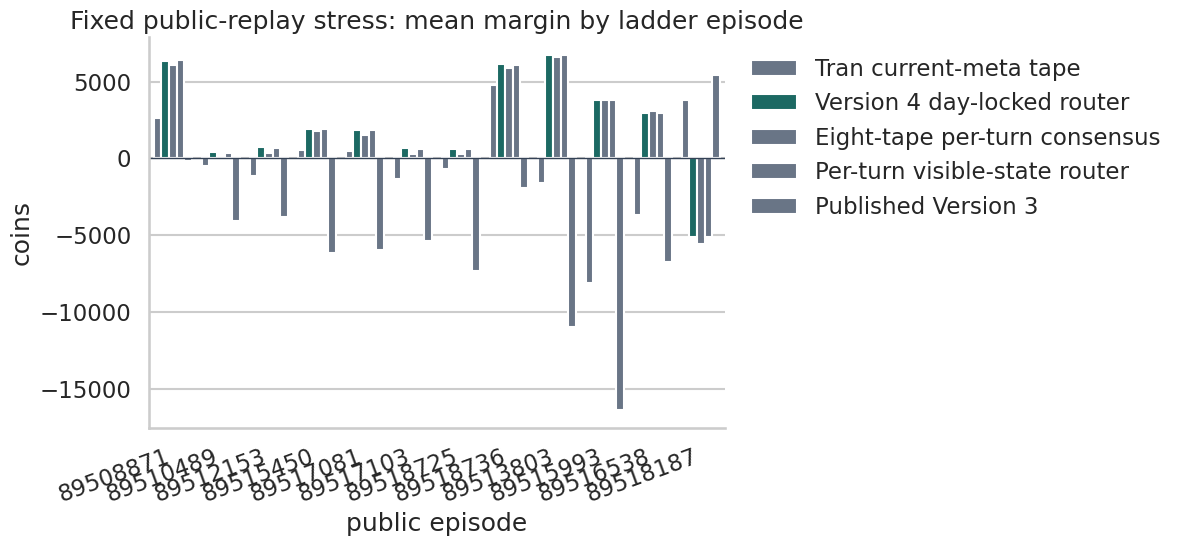

,variant,games,wins,win_rate,mean_margin,minimum_margin,mean_money
0,Tran current-meta tape,300,144,0.48,833.40,-21746.0,121408.35
1,Version 4 day-locked router,480,321,0.67,2706.42,-26552.0,119029.68
2,Eight-tape per-turn consensus,480,253,0.53,2407.63,-27485.0,118712.61
3,Per-turn visible-state router,480,322,0.67,2686.25,-26552.0,119014.45
4,Published Version 3,408,144,0.35,-4222.03,-31833.0,120684.06


In [20]:
REPAIR_SUMMARY_ROWS = [{'candidate': 'newtoptrace:89517081:0', 'episode_id': 89508871, 'games': 32, 'wins': 23, 'mean_margin': 2610.21875, 'minimum_margin': -6488.0, 'mean_money': 127040.8125}, {'candidate': 'newtoptrace:89517081:0', 'episode_id': 89510489, 'games': 32, 'wins': 15, 'mean_margin': -487.4375, 'minimum_margin': -17066.0, 'mean_money': 118309.78125}, {'candidate': 'newtoptrace:89517081:0', 'episode_id': 89512153, 'games': 32, 'wins': 14, 'mean_margin': -1120.21875, 'minimum_margin': -16706.0, 'mean_money': 119068.59375}, {'candidate': 'newtoptrace:89517081:0', 'episode_id': 89515450, 'games': 32, 'wins': 16, 'mean_margin': 551.03125, 'minimum_margin': -6499.0, 'mean_money': 127200.96875}, {'candidate': 'newtoptrace:89517081:0', 'episode_id': 89517081, 'games': 32, 'wins': 8, 'mean_margin': 489.0, 'minimum_margin': -16908.0, 'mean_money': 113348.71875}, {'candidate': 'newtoptrace:89517081:0', 'episode_id': 89517103, 'games': 32, 'wins': 14, 'mean_margin': -1368.28125, 'minimum_margin': -17066.0, 'mean_money': 121772.5625}, {'candidate': 'newtoptrace:89517081:0', 'episode_id': 89518725, 'games': 32, 'wins': 12, 'mean_margin': -668.09375, 'minimum_margin': -21746.0, 'mean_money': 121501.5625}, {'candidate': 'newtoptrace:89517081:0', 'episode_id': 89518736, 'games': 60, 'wins': 36, 'mean_margin': 4805.066666666667, 'minimum_margin': -20355.0, 'mean_money': 124833.6}, {'candidate': 'syouyaday', 'episode_id': 89508871, 'games': 52, 'wins': 39, 'mean_margin': 6330.307692307692, 'minimum_margin': -6554.0, 'mean_money': 123044.98076923077}, {'candidate': 'syouyaday', 'episode_id': 89510489, 'games': 52, 'wins': 34, 'mean_margin': 413.4230769230769, 'minimum_margin': -9473.0, 'mean_money': 116313.13461538461}, {'candidate': 'syouyaday', 'episode_id': 89512153, 'games': 52, 'wins': 42, 'mean_margin': 753.0, 'minimum_margin': -9473.0, 'mean_money': 117134.05769230769}, {'candidate': 'syouyaday', 'episode_id': 89515450, 'games': 52, 'wins': 32, 'mean_margin': 1890.2692307692307, 'minimum_margin': -14066.0, 'mean_money': 123381.09615384616}, {'candidate': 'syouyaday', 'episode_id': 89517081, 'games': 52, 'wins': 29, 'mean_margin': 1877.4615384615386, 'minimum_margin': -26552.0, 'mean_money': 117687.73076923077}, {'candidate': 'syouyaday', 'episode_id': 89517103, 'games': 52, 'wins': 34, 'mean_margin': 672.4615384615385, 'minimum_margin': -9473.0, 'mean_money': 119054.26923076923}, {'candidate': 'syouyaday', 'episode_id': 89518725, 'games': 52, 'wins': 25, 'mean_margin': 624.0, 'minimum_margin': -10620.0, 'mean_money': 115030.73076923077}, {'candidate': 'syouyaday', 'episode_id': 89518736, 'games': 100, 'wins': 77, 'mean_margin': 6126.21, 'minimum_margin': -11999.0, 'mean_money': 120641.58}, {'candidate': 'syouyamode', 'episode_id': 89508871, 'games': 52, 'wins': 38, 'mean_margin': 6077.115384615385, 'minimum_margin': -7126.0, 'mean_money': 122750.23076923077}, {'candidate': 'syouyamode', 'episode_id': 89510489, 'games': 52, 'wins': 12, 'mean_margin': -1.6730769230769231, 'minimum_margin': -10280.0, 'mean_money': 115910.67307692308}, {'candidate': 'syouyamode', 'episode_id': 89512153, 'games': 52, 'wins': 26, 'mean_margin': 344.4807692307692, 'minimum_margin': -10280.0, 'mean_money': 116734.13461538461}, {'candidate': 'syouyamode', 'episode_id': 89515450, 'games': 52, 'wins': 32, 'mean_margin': 1806.9423076923076, 'minimum_margin': -15069.0, 'mean_money': 123220.15384615384}, {'candidate': 'syouyamode', 'episode_id': 89517081, 'games': 52, 'wins': 27, 'mean_margin': 1552.75, 'minimum_margin': -27485.0, 'mean_money': 117331.30769230769}, {'candidate': 'syouyamode', 'episode_id': 89517103, 'games': 52, 'wins': 14, 'mean_margin': 294.0192307692308, 'minimum_margin': -10280.0, 'mean_money': 118688.46153846153}, {'candidate': 'syouyamode', 'episode_id': 89518725, 'games': 52, 'wins': 24, 'mean_margin': 295.96153846153845, 'minimum_margin': -11368.0, 'mean_money': 114665.15384615384}, {'candidate': 'syouyamode', 'episode_id': 89518736, 'games': 100, 'wins': 71, 'mean_margin': 5851.21, 'minimum_margin': -12874.0, 'mean_money': 120358.46}, {'candidate': 'syouyastate', 'episode_id': 89508871, 'games': 52, 'wins': 40, 'mean_margin': 6414.134615384615, 'minimum_margin': -6554.0, 'mean_money': 123090.05769230769}, {'candidate': 'syouyastate', 'episode_id': 89510489, 'games': 52, 'wins': 34, 'mean_margin': 350.6923076923077, 'minimum_margin': -9473.0, 'mean_money': 116277.38461538461}, {'candidate': 'syouyastate', 'episode_id': 89512153, 'games': 52, 'wins': 42, 'mean_margin': 691.5, 'minimum_margin': -9473.0, 'mean_money': 117099.09615384616}, {'candidate': 'syouyastate', 'episode_id': 89515450, 'games': 52, 'wins': 32, 'mean_margin': 1926.826923076923, 'minimum_margin': -14843.0, 'mean_money': 123371.01923076923}, {'candidate': 'syouyastate', 'episode_id': 89517081, 'games': 52, 'wins': 29, 'mean_margin': 1877.4615384615386, 'minimum_margin': -26552.0, 'mean_money': 117687.73076923077}, {'candidate': 'syouyastate', 'episode_id': 89517103, 'games': 52, 'wins': 34, 'mean_margin': 609.7307692307693, 'minimum_margin': -9473.0, 'mean_money': 119018.51923076923}, {'candidate': 'syouyastate', 'episode_id': 89518725, 'games': 52, 'wins': 25, 'mean_margin': 593.5, 'minimum_margin': -10620.0, 'mean_money': 115000.23076923077}, {'candidate': 'syouyastate', 'episode_id': 89518736, 'games': 100, 'wins': 77, 'mean_margin': 6080.08, 'minimum_margin': -11690.0, 'mean_money': 120621.69}, {'candidate': 'topterm:89468208:1:712', 'episode_id': 89508871, 'games': 44, 'wins': 19, 'mean_margin': -154.1818181818182, 'minimum_margin': -14997.0, 'mean_money': 126039.5}, {'candidate': 'topterm:89468208:1:712', 'episode_id': 89510489, 'games': 44, 'wins': 21, 'mean_margin': -4081.0227272727275, 'minimum_margin': -27809.0, 'mean_money': 119578.18181818182}, {'candidate': 'topterm:89468208:1:712', 'episode_id': 89512153, 'games': 44, 'wins': 20, 'mean_margin': -3808.5, 'minimum_margin': -27433.0, 'mean_money': 121147.02272727272}, {'candidate': 'topterm:89468208:1:712', 'episode_id': 89515450, 'games': 44, 'wins': 9, 'mean_margin': -6132.909090909091, 'minimum_margin': -18913.0, 'mean_money': 126465.11363636363}, {'candidate': 'topterm:89468208:1:712', 'episode_id': 89517081, 'games': 44, 'wins': 6, 'mean_margin': -5946.181818181818, 'minimum_margin': -31833.0, 'mean_money': 115103.34090909091}, {'candidate': 'topterm:89468208:1:712', 'episode_id': 89517103, 'games': 44, 'wins': 18, 'mean_margin': -5403.386363636364, 'minimum_margin': -27809.0, 'mean_money': 120762.36363636363}, {'candidate': 'topterm:89468208:1:712', 'episode_id': 89518725, 'games': 44, 'wins': 10, 'mean_margin': -7322.159090909091, 'minimum_margin': -21737.0, 'mean_money': 117520.11363636363}, {'candidate': 'topterm:89468208:1:712', 'episode_id': 89518736, 'games': 84, 'wins': 39, 'mean_margin': -1937.892857142857, 'minimum_margin': -28150.0, 'mean_money': 121254.34523809524}, {'candidate': 'newtoptrace:89517081:0', 'episode_id': 89513803, 'games': 4, 'wins': 1, 'mean_margin': -1617.0, 'minimum_margin': -5619.0, 'mean_money': 118217.25}, {'candidate': 'newtoptrace:89517081:0', 'episode_id': 89515993, 'games': 4, 'wins': 0, 'mean_margin': -8118.75, 'minimum_margin': -12521.0, 'mean_money': 123189.5}, {'candidate': 'newtoptrace:89517081:0', 'episode_id': 89516538, 'games': 4, 'wins': 2, 'mean_margin': -3675.25, 'minimum_margin': -9415.0, 'mean_money': 105761.25}, {'candidate': 'syouyaday', 'episode_id': 89513803, 'games': 4, 'wins': 3, 'mean_margin': 6722.25, 'minimum_margin': -206.0, 'mean_money': 126948.25}, {'candidate': 'syouyaday', 'episode_id': 89515993, 'games': 4, 'wins': 3, 'mean_margin': 3785.75, 'minimum_margin': -1492.0, 'mean_money': 128740.25}, {'candidate': 'syouyaday', 'episode_id': 89516538, 'games': 4, 'wins': 3, 'mean_margin': 2923.5, 'minimum_margin': -178.0, 'mean_money': 103210.5}, {'candidate': 'syouyamode', 'episode_id': 89513803, 'games': 4, 'wins': 3, 'mean_margin': 6609.0, 'minimum_margin': -357.0, 'mean_money': 126904.25}, {'candidate': 'syouyamode', 'episode_id': 89515993, 'games': 4, 'wins': 3, 'mean_margin': 3770.25, 'minimum_margin': -1654.0, 'mean_money': 128740.25}, {'candidate': 'syouyamode', 'episode_id': 89516538, 'games': 4, 'wins': 3, 'mean_margin': 3052.5, 'minimum_margin': -158.0, 'mean_money': 103273.5}, {'candidate': 'syouyastate', 'episode_id': 89513803, 'games': 4, 'wins': 3, 'mean_margin': 6716.75, 'minimum_margin': -228.0, 'mean_money': 126943.5}, {'candidate': 'syouyastate', 'episode_id': 89515993, 'games': 4, 'wins': 3, 'mean_margin': 3785.75, 'minimum_margin': -1492.0, 'mean_money': 128740.25}, {'candidate': 'syouyastate', 'episode_id': 89516538, 'games': 4, 'wins': 3, 'mean_margin': 2923.5, 'minimum_margin': -178.0, 'mean_money': 103210.5}, {'candidate': 'topterm:89468208:1:712', 'episode_id': 89513803, 'games': 4, 'wins': 0, 'mean_margin': -10979.75, 'minimum_margin': -15709.0, 'mean_money': 117910.0}, {'candidate': 'topterm:89468208:1:712', 'episode_id': 89515993, 'games': 4, 'wins': 0, 'mean_margin': -16357.0, 'minimum_margin': -19428.0, 'mean_money': 118089.5}, {'candidate': 'topterm:89468208:1:712', 'episode_id': 89516538, 'games': 4, 'wins': 0, 'mean_margin': -6733.25, 'minimum_margin': -13110.0, 'mean_money': 100660.75}, {'candidate': 'newtoptrace:89517081:0', 'episode_id': 89518187, 'games': 4, 'wins': 3, 'mean_margin': 3790.5, 'minimum_margin': -220.0, 'mean_money': 100010.25}, {'candidate': 'syouyaday', 'episode_id': 89518187, 'games': 4, 'wins': 0, 'mean_margin': -5108.0, 'minimum_margin': -8403.0, 'mean_money': 97225.5}, {'candidate': 'syouyamode', 'episode_id': 89518187, 'games': 4, 'wins': 0, 'mean_margin': -5601.0, 'minimum_margin': -8403.0, 'mean_money': 96732.5}, {'candidate': 'syouyastate', 'episode_id': 89518187, 'games': 4, 'wins': 0, 'mean_margin': -5108.0, 'minimum_margin': -8403.0, 'mean_money': 97225.5}, {'candidate': 'topterm:89468208:1:712', 'episode_id': 89518187, 'games': 4, 'wins': 2, 'mean_margin': 5450.5, 'minimum_margin': -1275.0, 'mean_money': 114000.75}]
repair = pd.DataFrame(REPAIR_SUMMARY_ROWS)
repair["variant"] = repair.candidate.map({'syouyamode': 'Eight-tape per-turn consensus', 'syouyastate': 'Per-turn visible-state router', 'syouyaday': 'Version 4 day-locked router', 'newtoptrace:89517081:0': 'Tran current-meta tape', 'topterm:89468208:1:712': 'Published Version 3'})
repair["episode"] = repair.episode_id.astype(str)
fig, ax = plt.subplots(figsize=(16.5, 5.8))
repair_palette = {'Eight-tape per-turn consensus': '#64748b', 'Per-turn visible-state router': '#64748b', 'Version 4 day-locked router': '#0f766e', 'Tran current-meta tape': '#64748b', 'Published Version 3': '#64748b'}
sns.barplot(data=repair, x="episode", y="mean_margin", hue="variant", palette=repair_palette, errorbar=None, ax=ax)
ax.axhline(0, color="#334155", lw=1)
ax.set(title="Fixed public-replay stress: mean margin by ladder episode", xlabel="public episode", ylabel="coins")
ax.tick_params(axis="x", labelrotation=20)
for label in ax.get_xticklabels(): label.set_horizontalalignment("right")
ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.01, 1))
sns.despine(); plt.tight_layout(rect=(0, 0, .74, 1)); plt.show()
repair_summary = pd.DataFrame([{'variant': 'Tran current-meta tape', 'games': 300, 'wins': 144, 'win_rate': 0.48, 'mean_margin': 833.4033333333333, 'minimum_margin': -21746.0, 'mean_money': 121408.35}, {'variant': 'Version 4 day-locked router', 'games': 480, 'wins': 321, 'win_rate': 0.66875, 'mean_margin': 2706.422916666667, 'minimum_margin': -26552.0, 'mean_money': 119029.68333333333}, {'variant': 'Eight-tape per-turn consensus', 'games': 480, 'wins': 253, 'win_rate': 0.5270833333333333, 'mean_margin': 2407.63125, 'minimum_margin': -27485.0, 'mean_money': 118712.6125}, {'variant': 'Per-turn visible-state router', 'games': 480, 'wins': 322, 'win_rate': 0.6708333333333333, 'mean_margin': 2686.25, 'minimum_margin': -26552.0, 'mean_money': 119014.45416666666}, {'variant': 'Published Version 3', 'games': 408, 'wins': 144, 'win_rate': 0.35294117647058826, 'mean_margin': -4222.029411764706, 'minimum_margin': -31833.0, 'mean_money': 120684.0612745098}])
display(repair_summary.round(2))


---

## Turn this starter into an adaptive frontier

1. **Learn the distance metric.** Replace the hand-scaled 54-feature L1 distance with weights learned from later matched wins.
2. **Add legality-aware repair.** When a retrieved action misses, redirect the freed hand to the highest-value nearby care, feed, harvest, water, or drop job.
3. **Condition the market block.** Preserve daily scheduler coherence but size buys and sells from live inventory, price, town demand, and rival exposure.
4. **Learn when to unlock.** Daily locking won the final holdout; future versions can learn which state regions safely support shorter coherent chunks.
5. **Keep symmetric gates.** Shared-market ordering makes player position real; every promotion should use both seats and untouched seeds.

The key result is less mystical than it looks: a great Kaggriculture farm is a timed supply chain, but stochastic divergence determines which schedule remains coherent. This notebook turns eight elite public trajectories into one visible-state policy and publishes the falsification evidence beside it. If it saves you days of reverse engineering, an upvote helps other competitors find the evidence and the caveats. 🌾
